# setup

In [ ]:

! pip install sentinelhub[AWS]  # extra dependencies for interacting with Amazon Web Services
! pip install s2cloudless
! pip install shapely

import json
from shapely.geometry import shape # para sacar el bbox usando las coords de cada reservoir

import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sentinelhub import CRS, BBox, DataCollection, MimeType, SentinelHubRequest, SHConfig, generate_evalscript, Geometry
from sentinelhub.api.catalog import get_available_timestamps
from sentinelhub.geo_utils import bbox_to_dimensions

from s2cloudless import S2PixelCloudDetector, download_bands_and_valid_data_mask

# Dar valor a las siguientes variables para la ejecución en local:
CLIENT_ID = ""
CLIENT_SECRET = ""
INSTANCE_ID = ""
CAPA_FECHAS_ID = ""

config = SHConfig()

assert CLIENT_ID and CLIENT_SECRET and INSTANCE_ID #CLIENT_ID and CLIENT_SECRET and INSTANCE_ID están en secrets en el notebook
config.sh_client_id = CLIENT_ID
config.sh_client_secret = CLIENT_SECRET


# clase para almacenar la info (geometrías) particular de cada reservoir
class ReservoirShape:
  def __init__ (self, geometry, bbox, size):
    self.geometry = geometry
    self.bbox = bbox
    self.size = size


# Coordenadas en crudo

In [ ]:
reservoir_cords = {}

In [ ]:
reservoir_cords["BHR"] = [[[-83.3725314,37.2711099],[-83.3723271,37.2709616],[-83.3721062,37.2708053],[-83.3714414,37.2713746],[-83.3706179,37.2720799],[-83.370462,37.2725424],[-83.3700084,37.2729597],[-83.3691225,37.2733376],[-83.3686831,37.2738451],[-83.3685342,37.2745614],[-83.3685174,37.2751662],[-83.3684092,37.2760269],[-83.3685469,37.2768327],[-83.3685174,37.2779515],[-83.3683207,37.2787182],[-83.3679373,37.2796022],[-83.3674161,37.2803689],[-83.3663051,37.2812764],[-83.365725,37.2820509],[-83.3653317,37.2830523],[-83.3650859,37.284304],[-83.3650662,37.2850628],[-83.3652531,37.286025],[-83.3654792,37.2863144],[-83.3661871,37.2868464],[-83.367308,37.2874096],[-83.368301,37.2877147],[-83.3696579,37.288051],[-83.3709459,37.2880823],[-83.3722438,37.2878086],[-83.373345,37.2873001],[-83.3748395,37.2863144],[-83.3759899,37.2853679],[-83.3783594,37.2821683],[-83.3788019,37.2819023],[-83.3792837,37.2817771],[-83.3799326,37.2818162],[-83.3807093,37.2820666],[-83.3817417,37.2827941],[-83.3822432,37.2844213],[-83.3821252,37.2859076],[-83.3817811,37.2864865],[-83.3810633,37.2869715],[-83.3783398,37.286995],[-83.3771501,37.287347],[-83.3760784,37.2879728],[-83.3756654,37.289068],[-83.3759407,37.2899754],[-83.3764618,37.2904134],[-83.3782414,37.2916963],[-83.3790477,37.2926818],[-83.3794803,37.2935501],[-83.3806307,37.2951379],[-83.3822727,37.2959201],[-83.3831576,37.2960609],[-83.3837082,37.2959123],[-83.3842686,37.295443],[-83.3850552,37.29452],[-83.3859106,37.2932294],[-83.3860483,37.2921891],[-83.3864612,37.2909375],[-83.3865989,37.2894122],[-83.3868742,37.2884578],[-83.3873011,37.2873017],[-83.3875904,37.2868067],[-83.3882656,37.2863233],[-83.3889745,37.2860585],[-83.3901561,37.2857592],[-83.3917524,37.2856863],[-83.3921768,37.2857017],[-83.3922974,37.2858168],[-83.3922347,37.2859933],[-83.3922781,37.2860125],[-83.3926735,37.2856979],[-83.395379,37.2856403],[-83.3971441,37.2854408],[-83.3983787,37.2851492],[-83.3994253,37.284823],[-83.4007225,37.2843319],[-83.4026275,37.2837601],[-83.4036113,37.2835414],[-83.4046385,37.2834723],[-83.4061577,37.2840479],[-83.4067026,37.284516],[-83.406857,37.2848652],[-83.406775,37.2851683],[-83.4065531,37.285341],[-83.405333,37.2851799],[-83.4045421,37.28513],[-83.4040309,37.2851607],[-83.4033461,37.2854062],[-83.4025889,37.2858168],[-83.4021259,37.2863617],[-83.4017642,37.2869525],[-83.4015906,37.2874936],[-83.401335,37.2893429],[-83.401364,37.290494],[-83.4012675,37.2907127],[-83.4013881,37.2909275],[-83.4015858,37.2916834],[-83.4019427,37.2925543],[-83.4022127,37.2928843],[-83.4027384,37.2931835],[-83.403293,37.2933792],[-83.4038717,37.2933754],[-83.4041997,37.2933332],[-83.4058442,37.2926886],[-83.4078553,37.2920172],[-83.408569,37.2919136],[-83.4089548,37.2920671],[-83.4097072,37.2931528],[-83.4100496,37.2933025],[-83.4098808,37.2930608],[-83.4096493,37.2922244],[-83.4093117,37.291764],[-83.4105752,37.291035],[-83.4110286,37.2904825],[-83.411588,37.2899492],[-83.4123693,37.2889247],[-83.4127262,37.2882494],[-83.4128949,37.2877775],[-83.412813,37.2871175],[-83.4126008,37.2866571],[-83.4117472,37.2853103],[-83.4113613,37.2844969],[-83.4114819,37.2840594],[-83.4120847,37.2837525],[-83.4135315,37.2833227],[-83.4148095,37.2830541],[-83.4159284,37.282962],[-83.417708,37.2832344],[-83.4180697,37.2834148],[-83.4181131,37.2836872],[-83.4185905,37.2842551],[-83.4192223,37.2851338],[-83.4192367,37.2853141],[-83.4188509,37.2857669],[-83.4188895,37.2860202],[-83.4196997,37.2857094],[-83.419965,37.2857477],[-83.4203652,37.2864269],[-83.4201868,37.2864998],[-83.4201916,37.2866226],[-83.4203652,37.286918],[-83.4206064,37.2871751],[-83.4205871,37.2875319],[-83.4211417,37.2884758],[-83.4217156,37.2898072],[-83.4223425,37.2906666],[-83.4231962,37.2913227],[-83.4232444,37.2917333],[-83.4233649,37.2919097],[-83.4237797,37.2922896],[-83.4241366,37.2927116],[-83.4244886,37.292961],[-83.4247201,37.293594],[-83.4246719,37.294181],[-83.4245561,37.2947412],[-83.4246574,37.2951133],[-83.4248069,37.2950711],[-83.4248986,37.2949062],[-83.425159,37.2935557],[-83.425757,37.2933715],[-83.4263164,37.2933063],[-83.4265913,37.293195],[-83.4267746,37.2930454],[-83.427117,37.2925159],[-83.4273678,37.2924008],[-83.4276764,37.2919519],[-83.4277777,37.2914071],[-83.4282599,37.2910158],[-83.4283468,37.2908815],[-83.4283853,37.2907434],[-83.4283516,37.2906513],[-83.4285493,37.290306],[-83.4287567,37.2901525],[-83.4287953,37.2899415],[-83.4297791,37.2884144],[-83.4301311,37.2876432],[-83.4306809,37.2866916],[-83.4312162,37.2858398],[-83.4317419,37.2852336],[-83.4335456,37.284117],[-83.4336565,37.2839213],[-83.434105,37.2838445],[-83.4343413,37.2840402],[-83.4343317,37.2844508],[-83.4349634,37.284658],[-83.4353107,37.2850647],[-83.4355036,37.2851185],[-83.4355422,37.2847654],[-83.4357254,37.2844853],[-83.4362125,37.2841592],[-83.436444,37.2836872],[-83.4368346,37.2834455],[-83.4369263,37.283104],[-83.4369456,37.2824248],[-83.4375387,37.2815614],[-83.4376786,37.2812084],[-83.4376593,37.2807901],[-83.4377606,37.2806443],[-83.4376256,37.2802951],[-83.4376738,37.2800649],[-83.4375725,37.2798884],[-83.437587,37.2796965],[-83.4375195,37.2795852],[-83.4374616,37.2792437],[-83.4370613,37.2784762],[-83.4367575,37.2777471],[-83.4364922,37.2767916],[-83.4364585,37.2761239],[-83.4367092,37.2754983],[-83.4373073,37.2747845],[-83.4384551,37.2739595],[-83.4386383,37.2739211],[-83.4387251,37.2737369],[-83.4394437,37.2732956],[-83.4405818,37.2732303],[-83.4411943,37.2733032],[-83.4416139,37.2734491],[-83.4419274,37.2737599],[-83.4422842,37.2743893],[-83.4427713,37.2750992],[-83.4427569,37.275318],[-83.4429787,37.2753679],[-83.4430269,37.2760509],[-83.4427231,37.2762697],[-83.4430607,37.2763388],[-83.4432632,37.2762582],[-83.4434658,37.2763004],[-83.4435478,37.2764309],[-83.4434369,37.2772713],[-83.4427858,37.2770717],[-83.4426315,37.2771178],[-83.4427713,37.2773365],[-83.4427762,37.277632],[-83.4426604,37.2783534],[-83.4425736,37.2785875],[-83.4426797,37.2790825],[-83.4425784,37.2794778],[-83.4424289,37.2795699],[-83.4424241,37.2796927],[-83.4426459,37.2799996],[-83.4429884,37.2813849],[-83.4433838,37.2816228],[-83.4433597,37.2818914],[-83.44444,37.2831462],[-83.4459109,37.284117],[-83.4462871,37.2844815],[-83.448409,37.2855943],[-83.4485103,37.2857861],[-83.4487611,37.2857823],[-83.4505744,37.2863501],[-83.4508975,37.2862082],[-83.4511049,37.2863079],[-83.4515293,37.2862542],[-83.4517174,37.2861545],[-83.4523491,37.2860202],[-83.4532413,37.2855943],[-83.4533812,37.285199],[-83.4536802,37.2850187],[-83.4538297,37.2847654],[-83.4558842,37.2833304],[-83.4568149,37.2829505],[-83.4577795,37.2827203],[-83.4587151,37.2826627],[-83.459096,37.2828699],[-83.4596989,37.283764],[-83.4598773,37.2842781],[-83.4599641,37.2849918],[-83.4599063,37.2852105],[-83.4601667,37.2854216],[-83.4601474,37.2859818],[-83.4604319,37.2862619],[-83.4606393,37.2865842],[-83.4607599,37.2870178],[-83.4607984,37.2876048],[-83.4609865,37.2880998],[-83.4611312,37.2896537],[-83.4610106,37.2906244],[-83.4605525,37.2912],[-83.4598677,37.2915491],[-83.4589562,37.292186],[-83.4581942,37.2925888],[-83.4564291,37.2932794],[-83.455971,37.2933677],[-83.4548087,37.2945455],[-83.4544856,37.2947719],[-83.4524215,37.2958499],[-83.4517656,37.296295],[-83.4508638,37.2971774],[-83.4502031,37.2980175],[-83.449851,37.2985508],[-83.4493784,37.2994907],[-83.4486695,37.3013513],[-83.4482643,37.3021799],[-83.4478978,37.3024676],[-83.4475844,37.302552],[-83.4471648,37.3025827],[-83.446533,37.3023526],[-83.4464414,37.3021492],[-83.4465137,37.3014817],[-83.4463835,37.3014088],[-83.4461906,37.3011979],[-83.4454768,37.3000355],[-83.4452791,37.2998398],[-83.4451393,37.2995214],[-83.4453659,37.2991147],[-83.4458434,37.2987848],[-83.4456842,37.2987119],[-83.4456167,37.2988232],[-83.4447776,37.2993181],[-83.444411,37.2993449],[-83.4435719,37.2991186],[-83.4433308,37.2991147],[-83.4439288,37.2992989],[-83.444059,37.2994217],[-83.4445847,37.2995713],[-83.4451441,37.3001659],[-83.4457276,37.3014012],[-83.4458385,37.3017694],[-83.4457469,37.3021569],[-83.4455588,37.3023449],[-83.4456939,37.3024139],[-83.445882,37.3026364],[-83.4460025,37.3029318],[-83.445554,37.3032694],[-83.4447872,37.3035111],[-83.4449898,37.3037297],[-83.4442422,37.3042054],[-83.4432874,37.3045775],[-83.4429546,37.3049534],[-83.4430269,37.3050033],[-83.4433163,37.3048921],[-83.4444352,37.3046619],[-83.4449415,37.3046082],[-83.4456939,37.3039906],[-83.4461086,37.3037336],[-83.4464786,37.303594],[-83.4465285,37.3035752],[-83.4466333,37.3035356],[-83.446861,37.3034497],[-83.4471262,37.3035801],[-83.4471744,37.3038908],[-83.4470079,37.3042088],[-83.446945,37.304329],[-83.4467894,37.3045531],[-83.4466669,37.3046497],[-83.4464595,37.3048134],[-83.446371,37.3051526],[-83.4464273,37.3054065],[-83.4467331,37.3054065],[-83.4468899,37.3054598],[-83.4470388,37.3056894],[-83.4473625,37.3061886],[-83.4475072,37.3066605],[-83.4476519,37.3069021],[-83.4485585,37.3077345],[-83.4491469,37.3084403],[-83.4493832,37.3085285],[-83.4500102,37.3091269],[-83.4499957,37.3093724],[-83.4502561,37.3094683],[-83.4504394,37.3094683],[-83.4516065,37.3089927],[-83.4526096,37.3086436],[-83.4540901,37.3084557],[-83.4544952,37.3082217],[-83.4561928,37.3077997],[-83.4564773,37.3078189],[-83.4566895,37.3077],[-83.4573261,37.3075466],[-83.4590334,37.30742],[-83.4597712,37.3074507],[-83.4600558,37.3076463],[-83.4606923,37.3084595],[-83.4608997,37.3088853],[-83.4617485,37.3100207],[-83.462033,37.3105539],[-83.4623224,37.3115665],[-83.4622501,37.3122761],[-83.4620813,37.3127862],[-83.4621343,37.3130049],[-83.4620041,37.3133309],[-83.4619173,37.3138219],[-83.4617823,37.3142284],[-83.4602728,37.3148114],[-83.4604175,37.3148613],[-83.4614688,37.314915],[-83.461464,37.3154213],[-83.4613145,37.3161769],[-83.4607984,37.3172009],[-83.4599641,37.3186622],[-83.4592021,37.3196671],[-83.4585704,37.3202117],[-83.4587585,37.320484],[-83.4567571,37.3238474],[-83.4562893,37.3244879],[-83.4560867,37.3245991],[-83.4556864,37.3246183],[-83.4552476,37.3243767],[-83.4547508,37.3238167],[-83.4544132,37.3235866],[-83.4540226,37.3234141],[-83.4537043,37.323368],[-83.453468,37.32323],[-83.4532317,37.3231609],[-83.4531111,37.3229845],[-83.4528362,37.3227736],[-83.453333,37.3234371],[-83.4536802,37.3236633],[-83.4538393,37.3239586],[-83.4543988,37.3243767],[-83.4544229,37.3245492],[-83.4547605,37.3249059],[-83.4549582,37.32509],[-83.4553585,37.3253047],[-83.4553633,37.3254735],[-83.4550836,37.3258416],[-83.4542348,37.3266623],[-83.4540853,37.3269921],[-83.4538876,37.327019],[-83.4537236,37.327391],[-83.4535403,37.3276326],[-83.4527591,37.3281158],[-83.4523443,37.3281464],[-83.452272,37.3282615],[-83.4514473,37.3285453],[-83.4507143,37.328737],[-83.4501789,37.3289518],[-83.4499716,37.3291627],[-83.4492723,37.3293237],[-83.4489636,37.329224],[-83.448737,37.329201],[-83.4484621,37.3293697],[-83.4482499,37.3294004],[-83.447512,37.3293161],[-83.4468272,37.3291818],[-83.4463932,37.3291818],[-83.4458144,37.3290975],[-83.4455395,37.3288137],[-83.4452068,37.328622],[-83.4447293,37.3284456],[-83.4442664,37.3285261],[-83.4436298,37.3285644],[-83.4433501,37.3284609],[-83.4426749,37.3283765],[-83.442564,37.3282883],[-83.4424,37.3280314],[-83.4420962,37.327901],[-83.4416862,37.3278205],[-83.4412763,37.3278627],[-83.4409291,37.3279624],[-83.4395919,37.3281927],[-83.4385757,37.3282361],[-83.4383847,37.3284097],[-83.4379482,37.3285832],[-83.4370343,37.3282687],[-83.4361886,37.3281276],[-83.4352133,37.3278294],[-83.435186,37.3280083],[-83.437314,37.3287025],[-83.4379551,37.3288489],[-83.4383097,37.3287839],[-83.4386371,37.3285832],[-83.4394146,37.3284639],[-83.4401171,37.3284639],[-83.4413652,37.3283771],[-83.4424769,37.3289411],[-83.4431794,37.3290876],[-83.4445707,37.3291472],[-83.4450481,37.3293858],[-83.4460916,37.3300204],[-83.4469646,37.3304434],[-83.4469919,37.3306549],[-83.4466782,37.3312134],[-83.4468214,37.331246],[-83.447292,37.3309043],[-83.4476262,37.3307796],[-83.4480491,37.3307362],[-83.4488539,37.3308393],[-83.4496041,37.3306006],[-83.4500133,37.3305789],[-83.4502452,37.3307525],[-83.4506476,37.3304434],[-83.4510227,37.3304596],[-83.4516059,37.3306931],[-83.4520274,37.3309591],[-83.4527099,37.331789],[-83.4532719,37.3322784],[-83.454048,37.3326295],[-83.4552657,37.3330711],[-83.4560886,37.333103],[-83.4567041,37.3329434],[-83.4574,37.3325072],[-83.4591462,37.3310123],[-83.4600561,37.3307303],[-83.4607988,37.3305867],[-83.462264,37.3306718],[-83.4641173,37.3314804],[-83.4647931,37.3319592],[-83.4655558,37.332704],[-83.4656696,37.3332147],[-83.4655491,37.3337307],[-83.465422,37.3347149],[-83.465034,37.3350075],[-83.465034,37.3352841],[-83.4652949,37.3358427],[-83.4657766,37.3365502],[-83.4661178,37.3368268],[-83.4673355,37.3374705],[-83.4682923,37.3379386],[-83.4690818,37.3382099],[-83.4700051,37.3386195],[-83.470179,37.3388695],[-83.4699248,37.3397259],[-83.4703062,37.3398642],[-83.471758,37.3399759],[-83.4719077,37.3399174],[-83.4720504,37.3396608],[-83.4720016,37.3393086],[-83.4717801,37.3390609],[-83.4717013,37.3387177],[-83.4714761,37.3382492],[-83.4718762,37.3380336],[-83.4715008,37.3374606],[-83.4702396,37.3362788],[-83.4699168,37.3358908],[-83.4694814,37.3357535],[-83.4686106,37.3357416],[-83.4678598,37.3355864],[-83.4666437,37.3352044],[-83.4664485,37.3346134],[-83.4665386,37.3337837],[-83.4668989,37.332566],[-83.4668614,37.3319094],[-83.4669064,37.3315632],[-83.4668764,37.3310618],[-83.4666737,37.330435],[-83.467034,37.330053],[-83.4666211,37.329856],[-83.466456,37.3295754],[-83.4669214,37.3288889],[-83.4671692,37.3283576],[-83.4670415,37.3277786],[-83.4671767,37.3275338],[-83.4678223,37.3267399],[-83.4683103,37.3266563],[-83.4686331,37.3265011],[-83.4689334,37.3261966],[-83.4691961,37.326125],[-83.4697441,37.3257549],[-83.4697742,37.3254385],[-83.4707276,37.3243937],[-83.4712156,37.323952],[-83.4719438,37.3235997],[-83.4737004,37.3233729],[-83.4743235,37.3234386],[-83.4750067,37.3232833],[-83.4756598,37.3233848],[-83.4764256,37.3237669],[-83.4764256,37.3236177],[-83.4761478,37.3231819],[-83.475795,37.3228237],[-83.4751644,37.3228117],[-83.4745337,37.3230326],[-83.4726795,37.3221968],[-83.4725368,37.3225968],[-83.4721369,37.3228154],[-83.4706111,37.3231177],[-83.4701112,37.3233869],[-83.4697883,37.323714],[-83.4695383,37.3236602],[-83.4696008,37.3240122],[-83.4695279,37.3243145],[-83.4688874,37.325151],[-83.4680126,37.3260082],[-83.4659223,37.3265623],[-83.465683,37.3271245],[-83.465613,37.3276106],[-83.4654289,37.3280644],[-83.4653332,37.3287144],[-83.4649171,37.3291771],[-83.4642322,37.3294318],[-83.463551,37.3294377],[-83.4612569,37.3291302],[-83.4604137,37.3290717],[-83.4596588,37.3291244],[-83.4573243,37.3297187],[-83.4568235,37.3299823],[-83.4563006,37.3303717],[-83.4557225,37.3305679],[-83.4554058,37.3305737],[-83.4550671,37.3304888],[-83.4548645,37.3304859],[-83.4547172,37.3305649],[-83.4546952,37.330723],[-83.4545736,37.3308021],[-83.4543269,37.3307465],[-83.4540839,37.3305444],[-83.4539145,37.3305444],[-83.4538519,37.3304859],[-83.4538004,37.3302165],[-83.4539329,37.3298886],[-83.4542496,37.3293996],[-83.4559398,37.3273471],[-83.4565289,37.3265184],[-83.4567904,37.3259826],[-83.4574347,37.3252125],[-83.4576262,37.3248669],[-83.4578545,37.3246825],[-83.457895,37.3245214],[-83.4580755,37.3243135],[-83.458116,37.3241232],[-83.4583774,37.3239856],[-83.4590292,37.3224892],[-83.4592611,37.3223165],[-83.4605021,37.3203516],[-83.460874,37.3199211],[-83.4610691,37.3197893],[-83.4610875,37.3196166],[-83.4615662,37.3186151],[-83.4618939,37.3181582],[-83.4623284,37.317309],[-83.4625641,37.3170835],[-83.4628697,37.3164802],[-83.4632674,37.316079],[-83.4634479,37.3157305],[-83.4636062,37.3150599],[-83.4637019,37.3149808],[-83.4644126,37.3150921],[-83.4650239,37.315013],[-83.464674,37.3148168],[-83.4642064,37.3146968],[-83.4638492,37.3145298],[-83.4636025,37.3142985],[-83.4634221,37.3139178],[-83.4634736,37.3131973],[-83.4637167,37.3121782],[-83.4638345,37.3112322],[-83.4639376,37.3108895],[-83.4638455,37.3107167],[-83.4638419,37.3102335],[-83.4637203,37.3097708],[-83.4636246,37.3087838],[-83.4627777,37.3076708],[-83.4624352,37.3072959],[-83.4618682,37.3067892],[-83.4610802,37.30618],[-83.459854,37.3056909],[-83.4599055,37.3055093],[-83.4612901,37.3042206],[-83.4609292,37.3042879],[-83.46041,37.3044725],[-83.4600307,37.3046951],[-83.4593458,37.3054097],[-83.4590292,37.305565],[-83.4585652,37.3056235],[-83.4581638,37.3056089],[-83.4581196,37.3057319],[-83.4557998,37.306016],[-83.4550008,37.30618],[-83.4547946,37.3057993],[-83.4545368,37.3058081],[-83.4546252,37.3063938],[-83.4537267,37.3068039],[-83.4535242,37.3067658],[-83.4534579,37.3066545],[-83.4534542,37.3062415],[-83.4533143,37.3061566],[-83.4532664,37.3062005],[-83.4532775,37.3063587],[-83.4531265,37.3064671],[-83.4529719,37.3064056],[-83.4527546,37.306183],[-83.4526478,37.3061888],[-83.4527546,37.3066926],[-83.4527104,37.3069562],[-83.4523717,37.3070558],[-83.451742,37.3070441],[-83.4511749,37.3071553],[-83.4511344,37.3072139],[-83.4512523,37.3074072],[-83.4510424,37.3074717],[-83.4506778,37.3072959],[-83.4503427,37.3072666],[-83.4502139,37.3071641],[-83.4503869,37.3067805],[-83.4503391,37.3066692],[-83.4501697,37.3065666],[-83.4498493,37.3065549],[-83.4495069,37.3063675],[-83.4493485,37.3061625],[-83.4492565,37.3055855],[-83.4494259,37.3052311],[-83.449378,37.3048855],[-83.4496836,37.3040946],[-83.4505453,37.3021556],[-83.4505895,37.3018598],[-83.4508325,37.3016138],[-83.4509835,37.3012652],[-83.4523459,37.2996015],[-83.4527067,37.2990508],[-83.4529314,37.2988721],[-83.4530713,37.2985147],[-83.4535463,37.2979377],[-83.4537009,37.2976301],[-83.4539108,37.2975071],[-83.4539882,37.2971263],[-83.4542386,37.296725],[-83.4546878,37.296268],[-83.4550634,37.2961157],[-83.4553138,37.2960864],[-83.4555642,37.2965492],[-83.4557446,37.2966342],[-83.4556894,37.295981],[-83.4557372,37.2958901],[-83.456853,37.2955826],[-83.4581565,37.295401],[-83.4585983,37.2952955],[-83.4599313,37.2948385],[-83.4603364,37.2950846],[-83.4609513,37.2953512],[-83.4613747,37.2955943],[-83.4618608,37.2957144],[-83.4618939,37.2958755],[-83.4621333,37.295814],[-83.4624205,37.2958286],[-83.4628145,37.2959517],[-83.4629581,37.2960835],[-83.4633705,37.2961567],[-83.4640812,37.2961655],[-83.4642101,37.296268],[-83.4643095,37.2961362],[-83.4648582,37.2959458],[-83.4653958,37.2958521],[-83.4659812,37.2959487],[-83.4659996,37.2957554],[-83.4662832,37.2956587],[-83.4669681,37.2955884],[-83.4678113,37.2956822],[-83.4704773,37.2964848],[-83.4713205,37.2966313],[-83.4736072,37.2966488],[-83.4738612,37.2964672],[-83.4742368,37.2963998],[-83.4746345,37.2966752],[-83.4750764,37.2966342],[-83.4754336,37.2969418],[-83.4764977,37.2969886],[-83.4772047,37.2969066],[-83.477746,37.2965668],[-83.4781768,37.296476],[-83.4779706,37.2963295],[-83.4775619,37.2961391],[-83.4770648,37.2961157],[-83.4766413,37.2962915],[-83.4762805,37.2962856],[-83.4751832,37.2958023],[-83.4747413,37.2956529],[-83.4741595,37.2955796],[-83.4730732,37.2956119],[-83.4723699,37.2957085],[-83.4709596,37.2955533],[-83.4702416,37.2956236],[-83.4695309,37.2951988],[-83.4687503,37.2949147],[-83.4683563,37.2950319],[-83.468047,37.2948385],[-83.4680249,37.2946979],[-83.46754,37.2945311],[-83.4668645,37.2944535],[-83.4663479,37.2945368],[-83.4654557,37.2948041],[-83.4648308,37.2948615],[-83.4637146,37.2948242],[-83.4631475,37.2947437],[-83.462053,37.2945052],[-83.4613594,37.2942523],[-83.4608826,37.2939937],[-83.4607634,37.2937954],[-83.4621794,37.2919907],[-83.4626959,37.2910251],[-83.4630391,37.2901429],[-83.4630572,37.2895394],[-83.4629596,37.2889933],[-83.462649,37.2880306],[-83.4627285,37.2878754],[-83.4629669,37.2878323],[-83.4637832,37.2878926],[-83.4642059,37.287999],[-83.4647405,37.2882864],[-83.4649825,37.2883208],[-83.4655243,37.2882519],[-83.4657627,37.2883065],[-83.4656544,37.2879329],[-83.4653004,37.2878553],[-83.4648525,37.2878352],[-83.4645093,37.2875478],[-83.4641806,37.2874184],[-83.4638844,37.2874558],[-83.4632631,37.2872374],[-83.4624937,37.2870477],[-83.4622589,37.2868092],[-83.4620421,37.2863867],[-83.4618001,37.2851997],[-83.4616014,37.2847198],[-83.4615364,37.2842887],[-83.4613161,37.2837052],[-83.4613052,37.2835156],[-83.4606803,37.2829292],[-83.4599506,37.2820009],[-83.4592318,37.2815985],[-83.4582493,37.2814519],[-83.457469,37.2815928],[-83.4560314,37.2820756],[-83.4559447,37.2822366],[-83.4553884,37.2823832],[-83.4551175,37.2826303],[-83.4546912,37.2828028],[-83.4542072,37.2831649],[-83.4540952,37.2833891],[-83.4538062,37.2834178],[-83.4533294,37.2838777],[-83.4530838,37.2839438],[-83.453026,37.2841737],[-83.4523866,37.284737],[-83.4522241,37.2849698],[-83.4517509,37.2851796],[-83.4510862,37.2853291],[-83.4503746,37.285286],[-83.4491934,37.2847571],[-83.4485324,37.2843691],[-83.448247,37.2843088],[-83.4478027,37.2840645],[-83.4476474,37.2838978],[-83.4470224,37.2834811],[-83.4454042,37.2822567],[-83.4453391,37.2820325],[-83.4450574,37.2819923],[-83.4447937,37.2818198],[-83.4444433,37.2814146],[-83.4442013,37.2810208],[-83.4442013,37.2807277],[-83.4444108,37.2802592],[-83.4449743,37.2793911],[-83.4452958,37.2789514],[-83.445657,37.2785892],[-83.4459677,37.2780546],[-83.4461247,37.2775222],[-83.4466254,37.2774246],[-83.4472486,37.277197],[-83.4479791,37.2768881],[-83.4482652,37.2767133],[-83.4489957,37.2766848],[-83.4492665,37.2764856],[-83.4502064,37.2762214],[-83.450898,37.2760962],[-83.4515194,37.2761106],[-83.4531268,37.2763147],[-83.4533363,37.2761451],[-83.4537915,37.2759927],[-83.4541093,37.275941],[-83.453889,37.2758318],[-83.4536217,37.2758548],[-83.4534411,37.275803],[-83.4531449,37.2758375],[-83.4526897,37.2759985],[-83.452314,37.2758232],[-83.4519817,37.2755012],[-83.4514182,37.2755185],[-83.4506849,37.2756622],[-83.4501864,37.2754179],[-83.4492184,37.2755415],[-83.4486368,37.2755329],[-83.4484237,37.2751506],[-83.4483695,37.2754524],[-83.4480697,37.2756564],[-83.4466031,37.2762888],[-83.4457903,37.2764871],[-83.4455664,37.276148],[-83.4443671,37.2738398],[-83.4436411,37.2730752],[-83.4432943,37.2728826],[-83.4431137,37.272667],[-83.442785,37.2724802],[-83.4426296,37.2725089],[-83.4424635,37.2724055],[-83.4423695,37.2722646],[-83.4417952,37.2718766],[-83.4407729,37.2716811],[-83.4400505,37.2714885],[-83.4396026,37.2712988],[-83.4393606,37.2711464],[-83.4388151,37.2706865],[-83.4385767,37.2703444],[-83.4385839,37.2698327],[-83.4385153,37.2697149],[-83.4379157,37.2690624],[-83.4376809,37.2689272],[-83.437493,37.2684558],[-83.4375075,37.2680361],[-83.4374099,37.2675158],[-83.4377314,37.2659174],[-83.4376158,37.2659117],[-83.437251,37.2665758],[-83.4365195,37.2668796],[-83.4362789,37.2672067],[-83.4360083,37.2678607],[-83.4364142,37.268096],[-83.4367149,37.2685108],[-83.4369705,37.2691848],[-83.4372461,37.2696354],[-83.4380129,37.2700781],[-83.4381131,37.2703453],[-83.4382534,37.271438],[-83.4384839,37.2718328],[-83.4377122,37.2727062],[-83.4370607,37.273077],[-83.4359432,37.2741059],[-83.4355874,37.2748516],[-83.4353518,37.2764746],[-83.4354921,37.2777068],[-83.4354621,37.2789948],[-83.4356826,37.2800475],[-83.4357978,37.2803226],[-83.4361236,37.280837],[-83.4360434,37.2814311],[-83.4357427,37.281794],[-83.4342092,37.2826114],[-83.4320443,37.283672],[-83.4315381,37.2838515],[-83.4307614,37.2840309],[-83.429719,37.2841545],[-83.4297842,37.284318],[-83.4300347,37.2844894],[-83.4303805,37.284617],[-83.4304006,37.2848244],[-83.4299946,37.285554],[-83.4293732,37.2863634],[-83.4290625,37.2866425],[-83.4290324,37.2870253],[-83.4289222,37.2873881],[-83.428416,37.2885962],[-83.4280853,37.2891424],[-83.4276693,37.2894255],[-83.4274037,37.2902149],[-83.427098,37.2906455],[-83.4265819,37.2918216],[-83.4265167,37.2920848],[-83.4263363,37.2924117],[-83.4258953,37.2924795],[-83.4255295,37.2924276],[-83.4250434,37.2922442],[-83.4245522,37.2917698],[-83.424011,37.2911399],[-83.4236101,37.2905658],[-83.4216807,37.2867063],[-83.4212247,37.2859607],[-83.4208438,37.2854464],[-83.4201773,37.2847366],[-83.419626,37.2840309],[-83.4193053,37.2838236],[-83.4190247,37.2832693],[-83.4186839,37.2828626],[-83.4180374,37.2824918],[-83.4177017,37.2823921],[-83.4163686,37.2822246],[-83.4156069,37.2821967],[-83.4146447,37.2822844],[-83.4141987,37.2823761],[-83.4136224,37.2825715],[-83.4129458,37.2826672],[-83.41259,37.2828786],[-83.4121891,37.2829623],[-83.4115126,37.2832813],[-83.4109563,37.283672],[-83.4105704,37.2840668],[-83.4104502,37.2844934],[-83.4105053,37.2851154],[-83.410355,37.2851553],[-83.4105003,37.2853028],[-83.4106757,37.2852988],[-83.4106657,37.2854384],[-83.4105404,37.2855819],[-83.4105303,37.2857295],[-83.4108411,37.2859926],[-83.4110616,37.285857],[-83.4113071,37.2861003],[-83.4115727,37.286483],[-83.4117782,37.2871569],[-83.4117732,37.2877988],[-83.4116278,37.2885125],[-83.411252,37.2891145],[-83.4106606,37.2898361],[-83.4099791,37.2904422],[-83.409478,37.290789],[-83.4083855,37.2911957],[-83.4078793,37.2913791],[-83.4070174,37.2915745],[-83.4061704,37.2918495],[-83.4041308,37.2928582],[-83.4038101,37.2929579],[-83.4031185,37.2927107],[-83.4027276,37.2921486],[-83.4024269,37.2910522],[-83.4022014,37.2892341],[-83.4023618,37.2884925],[-83.4024369,37.2873482],[-83.4026524,37.2868738],[-83.403329,37.2862637],[-83.4039804,37.2859806],[-83.4054538,37.2858251],[-83.406426,37.2858451],[-83.4069823,37.2857454],[-83.4074483,37.2854503],[-83.4077941,37.2850118],[-83.4078693,37.284609],[-83.4075335,37.2841146],[-83.4069973,37.2836242],[-83.4057795,37.2829184],[-83.4059349,37.282751],[-83.4057795,37.2824399],[-83.4049577,37.2826593],[-83.4036898,37.2828307],[-83.4016902,37.2833092],[-83.3995754,37.2839751],[-83.398488,37.2844097],[-83.3972752,37.2847366],[-83.3949599,37.2850795],[-83.3910109,37.2850716],[-83.3898182,37.2851992],[-83.388821,37.2854025],[-83.3881544,37.2856019],[-83.3876633,37.285877],[-83.3870369,37.2864232],[-83.386641,37.2869734],[-83.3863103,37.2876194],[-83.3860747,37.2883211],[-83.3858743,37.2893258],[-83.3856688,37.2909365],[-83.3853731,37.2918854],[-83.3852027,37.2927625],[-83.3849121,37.2936237],[-83.3844761,37.2943732],[-83.3841153,37.2948277],[-83.3837494,37.2951745],[-83.3832884,37.295334],[-83.3827071,37.2953938],[-83.382231,37.2952343],[-83.3818,37.295039],[-83.3810783,37.2945167],[-83.3808729,37.294441],[-83.3802665,37.293835],[-83.3799007,37.2932968],[-83.3797253,37.2927306],[-83.3791239,37.2918456],[-83.378708,37.2913751],[-83.3775862,37.2906601],[-83.3764664,37.2897015],[-83.3763109,37.2892629],[-83.3762964,37.288867],[-83.3764452,37.2885005],[-83.3768917,37.2880494],[-83.3777421,37.287666],[-83.3788123,37.2875532],[-83.3806125,37.2874743],[-83.3814984,37.2873108],[-83.3822,37.2868822],[-83.3825898,37.2861323],[-83.3828307,37.2853654],[-83.3827811,37.2844181],[-83.3826252,37.2841813],[-83.382363,37.2829633],[-83.3822212,37.2826249],[-83.3814204,37.2819934],[-83.3805983,37.2815253],[-83.3798825,37.2813223],[-83.3791808,37.2812829],[-83.3784438,37.2814802],[-83.3779618,37.2817001],[-83.3773878,37.2824276],[-83.3764664,37.2840516],[-83.3759066,37.2848128],[-83.3750632,37.2856305],[-83.3728449,37.2870458],[-83.371881,37.2873897],[-83.3710447,37.2875307],[-83.3704494,37.2875025],[-83.369762,37.2873784],[-83.3682878,37.2872882],[-83.3666365,37.2866285],[-83.3661262,37.2862451],[-83.3657577,37.2855515],[-83.3656301,37.2846324],[-83.3658286,37.2831155],[-83.3661758,37.2821231],[-83.3676216,37.2808656],[-83.3682524,37.2800422],[-83.3688406,37.2788862],[-83.3690958,37.2778824],[-83.3691225,37.2763378],[-83.3692075,37.2759318],[-83.3702706,37.2743752],[-83.3707738,37.2733206],[-83.3710219,37.2729879],[-83.3712699,37.2722717],[-83.3717235,37.2717472],[-83.3725314,37.2711099]],[[-83.3692926,37.2735519],[-83.3694149,37.273691],[-83.3692997,37.2739015],[-83.3689902,37.2739294],[-83.3690091,37.2737436],[-83.3692926,37.2735519]],[[-83.3692359,37.2747644],[-83.3693209,37.2747813],[-83.3693776,37.2748659],[-83.3693351,37.2751028],[-83.3690304,37.2753001],[-83.3690162,37.2752099],[-83.3692359,37.2747644]]]

In [ ]:
reservoir_cords["BRR"] = [[[-86.1242379,36.8960798],[-86.1253199,36.8927295],[-86.1259689,36.8907198],[-86.1270785,36.8896371],[-86.128055,36.8869747],[-86.1271508,36.8871628],[-86.1267513,36.8874113],[-86.1257748,36.8883876],[-86.1251978,36.8895058],[-86.1244211,36.8900737],[-86.1239329,36.8900027],[-86.1235778,36.8896832],[-86.1234669,36.889275],[-86.1235112,36.8880326],[-86.1234225,36.8876066],[-86.1230008,36.8873048],[-86.1226014,36.8875533],[-86.1225126,36.8895413],[-86.1223129,36.8903045],[-86.121514,36.8897542],[-86.120826,36.889133],[-86.1208926,36.8867013],[-86.1204265,36.8865061],[-86.1200271,36.8872516],[-86.1192504,36.8855298],[-86.1192504,36.8850861],[-86.1195832,36.8843228],[-86.1212033,36.8832756],[-86.1217359,36.8825478],[-86.1207594,36.882814],[-86.1190728,36.8838258],[-86.118629,36.8836483],[-86.1182517,36.8824058],[-86.1182961,36.8810922],[-86.1190284,36.8805064],[-86.1199827,36.8801336],[-86.12036,36.8798141],[-86.1198939,36.8796011],[-86.1196054,36.8792106],[-86.1189619,36.8789975],[-86.1188953,36.8797964],[-86.1185624,36.8800804],[-86.1176525,36.8804354],[-86.1173418,36.8800981],[-86.1167648,36.8789443],[-86.1162726,36.8771404],[-86.1162948,36.8762883],[-86.1165611,36.8750456],[-86.1168274,36.8746906],[-86.1178039,36.8747083],[-86.1183143,36.8748148],[-86.1180702,36.8744598],[-86.1176263,36.8742645],[-86.1160951,36.8741758],[-86.1157844,36.8738562],[-86.1149411,36.8724715],[-86.1147191,36.8716548],[-86.1142531,36.8718856],[-86.1138758,36.8716193],[-86.1123668,36.869844],[-86.1075955,36.8652989],[-86.1063971,36.8645177],[-86.1054206,36.8641803],[-86.1023359,36.8637542],[-86.1002499,36.863772],[-86.0997395,36.8638785],[-86.0963663,36.8651036],[-86.095412,36.865796],[-86.0932372,36.8681929],[-86.0920388,36.8704121],[-86.0915728,36.8727733],[-86.0915728,36.8735722],[-86.0918834,36.8751877],[-86.092638,36.8766788],[-86.0930818,36.8779392],[-86.0930818,36.8783298],[-86.0924826,36.8789511],[-86.0923717,36.8797321],[-86.0928821,36.880886],[-86.0939251,36.8817558],[-86.0936144,36.8833001],[-86.0945687,36.8831581],[-86.0950347,36.8833179],[-86.0952345,36.8836906],[-86.0953454,36.8844539],[-86.0960556,36.8849686],[-86.0966104,36.8856431],[-86.0966769,36.8860336],[-86.0962331,36.8871696],[-86.0962997,36.8875779],[-86.0971874,36.8871874],[-86.0976978,36.8871519],[-86.0985855,36.8881104],[-86.0984301,36.8885008],[-86.0972983,36.8892996],[-86.0973649,36.8896723],[-86.09934,36.8891931],[-86.0994382,36.8893797],[-86.0991715,36.8901704],[-86.0987321,36.8906473],[-86.0971315,36.891325],[-86.0957035,36.891325],[-86.0954367,36.8910991],[-86.0952977,36.8907207],[-86.0952072,36.8907255],[-86.095098,36.8908288],[-86.0949375,36.8907279],[-86.0946157,36.89016],[-86.0943383,36.8887312],[-86.094305,36.8878526],[-86.0938834,36.8865746],[-86.0935949,36.8861752],[-86.0930512,36.8856782],[-86.0917751,36.8848972],[-86.0912647,36.8847197],[-86.0905213,36.88456],[-86.0892341,36.8845422],[-86.0878915,36.8839919],[-86.0876363,36.8839387],[-86.0863491,36.8840984],[-86.0855724,36.8843558],[-86.0850509,36.8844712],[-86.0845849,36.8846842],[-86.0836195,36.8856693],[-86.0833643,36.885767],[-86.0832533,36.8855806],[-86.0832866,36.8851635],[-86.0837638,36.8844446],[-86.0839302,36.8840541],[-86.0838969,36.8838411],[-86.0836639,36.8839298],[-86.0834642,36.8840984],[-86.0832089,36.8840984],[-86.0830203,36.8837079],[-86.0826874,36.882208],[-86.0826652,36.8817465],[-86.082754,36.8813116],[-86.0824655,36.8809743],[-86.0819218,36.8807435],[-86.0817443,36.880566],[-86.0813892,36.879998],[-86.0809454,36.8794654],[-86.080213,36.8788885],[-86.0801464,36.8786844],[-86.0801908,36.8784714],[-86.0805126,36.8780897],[-86.0805237,36.8778856],[-86.0802796,36.8778234],[-86.0791811,36.8779122],[-86.0786707,36.8778678],[-86.0787483,36.8774151],[-86.0794363,36.8771932],[-86.080446,36.8771488],[-86.0809454,36.8766252],[-86.0818219,36.8761281],[-86.0825765,36.8759417],[-86.0833976,36.8759683],[-86.0839524,36.8761103],[-86.0839857,36.8754979],[-86.0841077,36.8753115],[-86.0847069,36.8748854],[-86.0851175,36.8743173],[-86.0855613,36.8719828],[-86.0855613,36.8717254],[-86.0854614,36.8715035],[-86.0853616,36.8719118],[-86.0846847,36.8733054],[-86.0845738,36.8738824],[-86.0842742,36.8742375],[-86.0840744,36.8743529],[-86.0832977,36.8745925],[-86.0829315,36.8743173],[-86.0825543,36.8737315],[-86.0823324,36.8735984],[-86.0825765,36.8743706],[-86.0825543,36.87477],[-86.0823324,36.8748766],[-86.0806569,36.8754091],[-86.079636,36.8752937],[-86.0793808,36.8752227],[-86.0791478,36.8750896],[-86.0790812,36.8748854],[-86.0791811,36.8747079],[-86.0795805,36.8744682],[-86.0795694,36.8742552],[-86.0793253,36.8741753],[-86.0786041,36.8744505],[-86.0783489,36.8744416],[-86.0781048,36.8740866],[-86.0778939,36.8739445],[-86.0776387,36.8739889],[-86.0774279,36.8741132],[-86.0768509,36.8746191],[-86.0768065,36.874415],[-86.0768176,36.8742108],[-86.0775721,36.8733587],[-86.0779716,36.873119],[-86.0779272,36.8729237],[-86.0777719,36.8727551],[-86.0775611,36.8723645],[-86.0774834,36.8719473],[-86.0775278,36.8715301],[-86.0777608,36.8711307],[-86.0781602,36.8708821],[-86.0786596,36.8707934],[-86.0788704,36.8706868],[-86.0790479,36.8702696],[-86.0794141,36.8698613],[-86.080324,36.8693731],[-86.0806569,36.8690801],[-86.0806347,36.868876],[-86.0796027,36.8691955],[-86.0781491,36.8700832],[-86.0779161,36.8700033],[-86.0776942,36.8696394],[-86.0777497,36.869231],[-86.0778828,36.8690624],[-86.0782268,36.8687872],[-86.0786707,36.8686008],[-86.0789481,36.8682723],[-86.0797026,36.866852],[-86.0796471,36.8666478],[-86.079403,36.8667632],[-86.0783933,36.8678107],[-86.0781491,36.867864],[-86.0781491,36.8676598],[-86.0782601,36.8670295],[-86.0792809,36.8647214],[-86.0797026,36.8623866],[-86.0798801,36.8617208],[-86.0802574,36.8612414],[-86.0809897,36.8612769],[-86.0812228,36.861339],[-86.0816444,36.8615965],[-86.0813004,36.8610106],[-86.0811007,36.8604157],[-86.0812893,36.8602914],[-86.0815223,36.8602559],[-86.0816666,36.8600873],[-86.081833,36.8597144],[-86.0820439,36.8596078],[-86.0825543,36.8596167],[-86.0827762,36.8597144],[-86.0836861,36.8604335],[-86.0841521,36.8609307],[-86.084252,36.8611171],[-86.0840744,36.8603092],[-86.083442,36.8594125],[-86.0833976,36.8592172],[-86.0834753,36.8590219],[-86.0839635,36.8590396],[-86.0846847,36.8592705],[-86.0843851,36.8587023],[-86.0844295,36.8584981],[-86.0857389,36.8578411],[-86.0868041,36.8572018],[-86.087603,36.8566159],[-86.0880801,36.8560654],[-86.0875697,36.856243],[-86.0867042,36.8567313],[-86.0847846,36.857486],[-86.0840633,36.8576902],[-86.0837859,36.8576902],[-86.0834531,36.8571486],[-86.0835307,36.8565449],[-86.08322,36.8568556],[-86.0829759,36.8572196],[-86.0828317,36.8580187],[-86.0816222,36.8584359],[-86.0813559,36.8584714],[-86.0811562,36.8583205],[-86.080901,36.8579565],[-86.0806458,36.8579476],[-86.0804571,36.8583116],[-86.0804016,36.85872],[-86.0803018,36.8589065],[-86.0800466,36.8589242],[-86.0798025,36.8588266],[-86.0796249,36.8586579],[-86.0793475,36.8586756],[-86.0796222,36.8592499],[-86.0794025,36.859501],[-86.0790573,36.859614],[-86.0787592,36.8590616],[-86.0785395,36.8582078],[-86.078461,36.8550563],[-86.0785552,36.85478],[-86.0787121,36.8544912],[-86.0789318,36.8542652],[-86.079277,36.8542778],[-86.0795438,36.854102],[-86.0796222,36.8538132],[-86.0800773,36.8529845],[-86.0805638,36.8525575],[-86.0811444,36.8522185],[-86.0814896,36.8521557],[-86.0829333,36.8516911],[-86.0835139,36.8513395],[-86.0846751,36.8501843],[-86.0853185,36.849456],[-86.085444,36.8491797],[-86.0858363,36.8486649],[-86.0856794,36.8482756],[-86.0871702,36.8477859],[-86.087892,36.847698],[-86.0889591,36.847472],[-86.0893043,36.8473715],[-86.0894926,36.8471078],[-86.0888336,36.8468692],[-86.0859462,36.8469697],[-86.085601,36.8469069],[-86.0853028,36.8467436],[-86.0850517,36.8465301],[-86.0848163,36.8456762],[-86.084581,36.844433],[-86.0845496,36.8432023],[-86.084173,36.8426749],[-86.0838434,36.842813],[-86.0836865,36.8431018],[-86.0836237,36.8433781],[-86.0836237,36.8448348],[-86.0838748,36.8465427],[-86.084377,36.8472836],[-86.0845967,36.8478487],[-86.0845967,36.8481626],[-86.0841887,36.848916],[-86.0837493,36.8493807],[-86.0823213,36.8502597],[-86.0804068,36.8509001],[-86.0800145,36.8509503],[-86.0785238,36.8513772],[-86.0779432,36.8517288],[-86.0772527,36.8519548],[-86.0770801,36.8510507],[-86.0756207,36.8493807],[-86.0752441,36.8488407],[-86.0751029,36.8485644],[-86.0748361,36.8473338],[-86.0741613,36.8461911],[-86.0730001,36.8449227],[-86.0725764,36.8443074],[-86.0718833,36.8435117],[-86.0706837,36.8442628],[-86.0708646,36.8442819],[-86.0710388,36.8444554],[-86.0710374,36.8445981],[-86.0708032,36.84486],[-86.0700971,36.845513],[-86.068418,36.846618],[-86.0681983,36.8468315],[-86.0681355,36.8470952],[-86.0681512,36.847384],[-86.0682925,36.8476478],[-86.0703011,36.8497825],[-86.0706463,36.8506489],[-86.0708503,36.8508749],[-86.0715094,36.8519297],[-86.072137,36.8526957],[-86.0724352,36.853537],[-86.072498,36.8540894],[-86.0715654,36.8550437],[-86.0688221,36.8550933],[-86.0679406,36.8551147],[-86.0689022,36.8556276],[-86.0711978,36.8567965],[-86.0714793,36.8585286],[-86.0711192,36.8588762],[-86.0704782,36.8594746],[-86.0707186,36.8597951],[-86.0716267,36.8602653],[-86.0721932,36.8624523],[-86.0710702,36.863013],[-86.0711257,36.8634797],[-86.0715266,36.8637836],[-86.0715899,36.8649147],[-86.0712491,36.8652889],[-86.0717336,36.8654156],[-86.0719174,36.866695],[-86.0712795,36.869369],[-86.0709086,36.8710156],[-86.0707775,36.8715484],[-86.0706345,36.871593],[-86.0705864,36.8716492],[-86.0706433,36.8717286],[-86.0705307,36.8719223],[-86.0703942,36.8719854],[-86.0702671,36.871962],[-86.0701299,36.8718914],[-86.070108,36.8718169],[-86.0701092,36.8717463],[-86.0700608,36.871709],[-86.0699777,36.8717139],[-86.0696788,36.8719739],[-86.0697308,36.8722218],[-86.069674,36.8722852],[-86.0696744,36.8724161],[-86.0696721,36.8725311],[-86.0697371,36.8727617],[-86.0698132,36.8729065],[-86.0698878,36.8729596],[-86.0701122,36.873271],[-86.0703979,36.8736372],[-86.0704652,36.8738063],[-86.0704672,36.8739909],[-86.0703985,36.8741756],[-86.0703045,36.8743552],[-86.0702782,36.8743658],[-86.0702465,36.8743677],[-86.0702222,36.874346],[-86.0702196,36.8743155],[-86.0703088,36.874124],[-86.0703615,36.8739383],[-86.0703458,36.8738378],[-86.0703128,36.8737374],[-86.0702398,36.8736457],[-86.0699885,36.8735592],[-86.0698816,36.8735036],[-86.0697752,36.8734277],[-86.0691354,36.8726073],[-86.0689491,36.8721047],[-86.0688802,36.8715793],[-86.0684007,36.8708337],[-86.0680927,36.8703825],[-86.0674731,36.8686006],[-86.0671157,36.8675725],[-86.0668263,36.867341],[-86.0665065,36.8675285],[-86.0668348,36.8690432],[-86.066876,36.8698757],[-86.0668985,36.8700181],[-86.0669571,36.8703891],[-86.0669943,36.8706248],[-86.0669154,36.8707859],[-86.0667069,36.8708195],[-86.0664015,36.87082],[-86.066869,36.8711477],[-86.0673286,36.8713197],[-86.0674289,36.8714691],[-86.0674805,36.8717007],[-86.0674906,36.8717297],[-86.067451,36.8719736],[-86.0674009,36.8722045],[-86.0672987,36.8723319],[-86.0671625,36.8723283],[-86.0669364,36.8723358],[-86.0667461,36.8723759],[-86.0667362,36.8724699],[-86.0667936,36.8726773],[-86.0668974,36.8728707],[-86.0670516,36.87293],[-86.0673247,36.8729797],[-86.0675836,36.8730703],[-86.0677258,36.8733413],[-86.0677337,36.8734508],[-86.0677723,36.873539],[-86.0678475,36.8735977],[-86.0680124,36.8737205],[-86.0680675,36.8738693],[-86.0679599,36.8740222],[-86.0676701,36.8741312],[-86.0673267,36.874426],[-86.067037,36.874738],[-86.0670458,36.8749058],[-86.0671398,36.8749495],[-86.0672752,36.8749516],[-86.0674077,36.8749483],[-86.0675054,36.8749224],[-86.0676527,36.8748469],[-86.0676728,36.874823],[-86.0678566,36.874794],[-86.0680278,36.8747773],[-86.068214,36.8748138],[-86.0683829,36.8748553],[-86.0685654,36.8750853],[-86.068627,36.8751006],[-86.0686773,36.8751705],[-86.0686718,36.8752159],[-86.0686354,36.87525],[-86.068508,36.8752773],[-86.0677181,36.8756821],[-86.0671819,36.876078],[-86.0669776,36.8761978],[-86.0667574,36.8762539],[-86.0666162,36.876169],[-86.0665515,36.8760939],[-86.0665644,36.876019],[-86.0665026,36.8759158],[-86.0665159,36.8749977],[-86.0662751,36.8743896],[-86.0661921,36.8743234],[-86.066016,36.8740738],[-86.0657812,36.8735849],[-86.0655922,36.8732168],[-86.0651506,36.8725718],[-86.0645454,36.8720322],[-86.0638425,36.8713972],[-86.0631666,36.8709428],[-86.0626276,36.8704486],[-86.0623921,36.8701462],[-86.0624772,36.8698738],[-86.0625964,36.8697377],[-86.0621368,36.8696083],[-86.0619214,36.8694318],[-86.0616717,36.8691503],[-86.0611025,36.8690043],[-86.060724,36.8691181],[-86.0604857,36.8690636],[-86.060341,36.868941],[-86.0596304,36.8690928],[-86.0573236,36.869256],[-86.0569313,36.8691179],[-86.0566175,36.8689296],[-86.0563978,36.8687036],[-86.0561153,36.8681513],[-86.0561467,36.867511],[-86.0563036,36.8672348],[-86.0570236,36.8666171],[-86.0575484,36.8662949],[-86.0574901,36.8662764],[-86.0565115,36.8665796],[-86.0563385,36.8664315],[-86.0558923,36.8655873],[-86.0557776,36.8654332],[-86.0556896,36.8654257],[-86.0559308,36.8665932],[-86.0559171,36.8668838],[-86.0558319,36.8671852],[-86.0555321,36.8680131],[-86.0555385,36.8683828],[-86.0554521,36.8685741],[-86.0553605,36.8686233],[-86.0550109,36.8685522],[-86.0548633,36.868465],[-86.0539027,36.8680885],[-86.053625,36.8678522],[-86.0533414,36.8676962],[-86.0533932,36.8671278],[-86.0533652,36.8669072],[-86.0532586,36.8668956],[-86.0532696,36.8670134],[-86.0532292,36.8671229],[-86.052994,36.8674701],[-86.0527173,36.8676573],[-86.052339,36.8677681],[-86.05184,36.8678193],[-86.0507558,36.8677328],[-86.0500199,36.8676136],[-86.0493737,36.8674893],[-86.0489311,36.8673573],[-86.0486752,36.8672876],[-86.0485794,36.8671596],[-86.0485655,36.8666532],[-86.0487618,36.8661015],[-86.0488888,36.8659714],[-86.0490202,36.8659414],[-86.0492295,36.8659135],[-86.0493736,36.8658788],[-86.0489988,36.8656704],[-86.0489714,36.8654379],[-86.0490796,36.865201],[-86.0493407,36.8648321],[-86.0498521,36.8642194],[-86.0498436,36.8641106],[-86.0497525,36.8640126],[-86.0495349,36.8639905],[-86.0492819,36.8640088],[-86.0490381,36.8641464],[-86.0485012,36.8649408],[-86.0482221,36.8654772],[-86.0479397,36.8660422],[-86.0478784,36.8662459],[-86.0478477,36.866426],[-86.0476124,36.8665454],[-86.0477315,36.866831],[-86.04767,36.8673557],[-86.0475314,36.8675609],[-86.0473361,36.8676216],[-86.0469786,36.8676845],[-86.0468341,36.8678554],[-86.0469844,36.8679612],[-86.0471763,36.8679617],[-86.047273,36.8679875],[-86.0472727,36.8680484],[-86.046729,36.8684687],[-86.0466132,36.8686444],[-86.0462164,36.8689324],[-86.0461582,36.8691571],[-86.0458922,36.8696164],[-86.0457397,36.8704122],[-86.0455586,36.8710343],[-86.0455029,36.8715684],[-86.0454261,36.8718012],[-86.0454488,36.8719909],[-86.0455082,36.87221],[-86.0454578,36.8739332],[-86.0453172,36.8742011],[-86.0451384,36.874476],[-86.0448586,36.8745096],[-86.0448808,36.8748095],[-86.0450725,36.8750179],[-86.0452943,36.8752711],[-86.0453861,36.8760445],[-86.0454262,36.8763317],[-86.0453239,36.8763288],[-86.0452206,36.8762632],[-86.0450269,36.8762242],[-86.0449111,36.8761603],[-86.0441219,36.8754829],[-86.0437785,36.8750968],[-86.0436739,36.8748723],[-86.04353,36.8746634],[-86.043428,36.8743496],[-86.043352,36.8741106],[-86.0434552,36.8740074],[-86.0435137,36.8739733],[-86.0435267,36.8739476],[-86.0435187,36.8739203],[-86.043434,36.8739019],[-86.043357,36.8738758],[-86.0432731,36.8737406],[-86.0432653,36.8734987],[-86.0434309,36.8732164],[-86.0433454,36.873015],[-86.0433379,36.8728707],[-86.0433241,36.8728107],[-86.0432934,36.8727561],[-86.0431092,36.8725782],[-86.0430007,36.872411],[-86.0429685,36.8722471],[-86.0429667,36.872059],[-86.0430197,36.8716854],[-86.0432179,36.8711888],[-86.0435577,36.8708432],[-86.0435451,36.8704541],[-86.0435964,36.8700999],[-86.0436888,36.8698986],[-86.0437095,36.8694689],[-86.0441055,36.8681485],[-86.0441975,36.8667215],[-86.044204,36.8661699],[-86.0441422,36.865427],[-86.0441078,36.8648779],[-86.0441597,36.8647449],[-86.0443524,36.8646298],[-86.0442623,36.8645654],[-86.0441108,36.8644477],[-86.0439379,36.8641128],[-86.0440532,36.8638133],[-86.043848,36.8637076],[-86.0437344,36.8636166],[-86.0435084,36.8634356],[-86.042979,36.8636798],[-86.0432046,36.8638751],[-86.0432274,36.8640535],[-86.0432013,36.8642318],[-86.0426357,36.8645984],[-86.0422571,36.8647902],[-86.0410714,36.8654576],[-86.0406417,36.865757],[-86.0402298,36.8661087],[-86.0401467,36.866269],[-86.0404845,36.8662917],[-86.0403981,36.8673723],[-86.0401379,36.8675239],[-86.0400433,36.8675831],[-86.039996,36.8676708],[-86.040352,36.8676849],[-86.0404362,36.867751],[-86.0403227,36.8695896],[-86.0403133,36.8704654],[-86.0400593,36.8706893],[-86.0385262,36.8707198],[-86.0377152,36.8707873],[-86.0375542,36.8708477],[-86.0376053,36.8709761],[-86.037888,36.8709272],[-86.0384427,36.8710585],[-86.0387412,36.8711935],[-86.0392214,36.8712087],[-86.0400706,36.8714226],[-86.0401249,36.8717856],[-86.0393998,36.8723783],[-86.039341,36.8725467],[-86.0399621,36.872376],[-86.0401511,36.8724483],[-86.0404544,36.8742188],[-86.04099,36.8752708],[-86.0413332,36.8758968],[-86.0414483,36.8761143],[-86.0414144,36.8762084],[-86.0403236,36.8767545],[-86.0382419,36.8783696],[-86.0378339,36.8789093],[-86.0377554,36.8791855],[-86.0379908,36.8793863],[-86.0385871,36.8790098],[-86.0392725,36.878516],[-86.0401562,36.8777921],[-86.0406219,36.8775369],[-86.0412025,36.8772775],[-86.0414954,36.8772649],[-86.0418354,36.8774804],[-86.0420708,36.8778508],[-86.0423324,36.8777797],[-86.0425729,36.87788],[-86.043232,36.8781185],[-86.0437317,36.8782746],[-86.0441525,36.8782729],[-86.0443159,36.8782444],[-86.0444771,36.8782947],[-86.0445582,36.878405],[-86.044351,36.8793152],[-86.0444395,36.8793949],[-86.0449858,36.8785852],[-86.0451093,36.878531],[-86.0458072,36.8785891],[-86.0463617,36.8786615],[-86.0465357,36.8787246],[-86.0467331,36.8787525],[-86.0469667,36.8786959],[-86.0471733,36.8785787],[-86.0475151,36.8782418],[-86.04785,36.8778057],[-86.0479136,36.8776054],[-86.0479227,36.8774051],[-86.0475073,36.8762796],[-86.0474738,36.8755419],[-86.0477438,36.8747332],[-86.0480809,36.873838],[-86.050011,36.8717416],[-86.0511723,36.8710386],[-86.0527415,36.871001],[-86.0534633,36.8710889],[-86.0537772,36.8711767],[-86.0540125,36.8714027],[-86.0543735,36.8718923],[-86.0547815,36.8727585],[-86.0547815,36.8733485],[-86.0545932,36.873951],[-86.0544519,36.8742397],[-86.0539969,36.8747419],[-86.0538556,36.875018],[-86.0539812,36.8755955],[-86.0546559,36.8755704],[-86.0553935,36.8754197],[-86.0558734,36.87497],[-86.055999,36.8754972],[-86.05625,36.8760244],[-86.0569405,36.8762253],[-86.0575368,36.8758738],[-86.0575054,36.8753215],[-86.0570974,36.8741917],[-86.0571602,36.8736142],[-86.0577251,36.8732125],[-86.0584469,36.8730619],[-86.0592316,36.873087],[-86.0598906,36.8732628],[-86.0605497,36.8736142],[-86.0609577,36.8740662],[-86.0618992,36.8754972],[-86.0618992,36.8767023],[-86.0614285,36.877129],[-86.0607694,36.8774052],[-86.0600789,36.8775809],[-86.0606125,36.8779324],[-86.0612715,36.8780579],[-86.0627466,36.8780077],[-86.0634684,36.878083],[-86.0641275,36.8783592],[-86.0646611,36.8787358],[-86.0651318,36.8791876],[-86.0657595,36.8794387],[-86.06645,36.8795391],[-86.0680506,36.8796144],[-86.0709379,36.8796395],[-86.0724444,36.8798906],[-86.0731348,36.8802169],[-86.0736998,36.8805684],[-86.0741705,36.8810202],[-86.0745158,36.8815474],[-86.0749238,36.8827022],[-86.0749865,36.8832545],[-86.0751748,36.8837565],[-86.0755828,36.8842084],[-86.0758653,36.8847606],[-86.0755201,36.8852627],[-86.0750493,36.8857145],[-86.0754573,36.8861162],[-86.0745158,36.8869194],[-86.0739195,36.8872709],[-86.0731976,36.8874215],[-86.0727268,36.8880992],[-86.0719422,36.8880741],[-86.0715656,36.8875721],[-86.0715656,36.8863923],[-86.0712832,36.88584],[-86.0704986,36.8847857],[-86.0700592,36.8843339],[-86.0694943,36.8839071],[-86.0676112,36.8828026],[-86.0669521,36.8825767],[-86.0655084,36.8826018],[-86.0640648,36.8827775],[-86.0660734,36.8834302],[-86.066701,36.8836812],[-86.0672973,36.8840075],[-86.0677681,36.8844092],[-86.0690235,36.8858651],[-86.0695256,36.8869947],[-86.0696512,36.8875972],[-86.0695884,36.8887016],[-86.0688666,36.888802],[-86.0684272,36.8892288],[-86.0677367,36.8891535],[-86.0671404,36.8888271],[-86.0664186,36.8887016],[-86.0657595,36.8889527],[-86.0653201,36.8894045],[-86.06645,36.8900822],[-86.0669207,36.890534],[-86.0668266,36.8910611],[-86.065885,36.8919647],[-86.0653515,36.8923664],[-86.0644727,36.8933954],[-86.0640896,36.8940056],[-86.0638899,36.8947687],[-86.0638233,36.8951947],[-86.0639121,36.8967742],[-86.0640674,36.8975906],[-86.0646223,36.8987087],[-86.0659538,36.89988],[-86.0658872,36.9002704],[-86.0650661,36.9007318],[-86.065288,36.9010867],[-86.0657762,36.9012287],[-86.0662645,36.9012465],[-86.0667305,36.9010512],[-86.0672409,36.900998],[-86.0677291,36.9010867],[-86.0724117,36.9026662],[-86.0752798,36.9028554],[-86.0756859,36.9030178],[-86.0757028,36.9032478],[-86.0754818,36.9035606],[-86.0752543,36.9038179],[-86.0756205,36.9042349],[-86.0755706,36.9044346],[-86.0747106,36.9052021],[-86.074568,36.9053704],[-86.0730185,36.9071984],[-86.072275,36.9076997],[-86.0717147,36.907784],[-86.0712265,36.9073226],[-86.0712486,36.9068967],[-86.0716814,36.9063733],[-86.0716703,36.9059651],[-86.0706827,36.9061426],[-86.070483,36.9060006],[-86.0700614,36.9052021],[-86.0696175,36.907367],[-86.0688511,36.9068441],[-86.0682741,36.9061521],[-86.0672533,36.9037387],[-86.065833,36.9021415],[-86.0654335,36.9018931],[-86.0639688,36.9015204],[-86.0624154,36.9015204],[-86.0614611,36.9018044],[-86.0591975,36.9020351],[-86.0566676,36.902532],[-86.0556912,36.9025675],[-86.0553805,36.9021948],[-86.0553139,36.9017511],[-86.0556024,36.8993198],[-86.0553139,36.8989649],[-86.0549588,36.8992311],[-86.0546925,36.9004201],[-86.053938,36.900917],[-86.0534276,36.9010058],[-86.0518076,36.8992844],[-86.0487894,36.8974741],[-86.0489892,36.8982195],[-86.0500766,36.8995151],[-86.0520961,36.9007573],[-86.052784,36.9013252],[-86.0531391,36.9020883],[-86.0538048,36.9026739],[-86.0540046,36.9034725],[-86.0537383,36.9038274],[-86.0532279,36.9038984],[-86.0521848,36.9037742],[-86.0516744,36.9038984],[-86.0533832,36.9047679],[-86.0529837,36.9059391],[-86.0522958,36.9067377],[-86.0509199,36.9072168],[-86.0497881,36.9081218],[-86.048279,36.9083525],[-86.0478419,36.9083587],[-86.0459746,36.9064766],[-86.0442013,36.9052594],[-86.0437777,36.9047575],[-86.0431657,36.9036533],[-86.0422084,36.9031765],[-86.0423967,36.9036909],[-86.0427734,36.9041678],[-86.0428832,36.905021],[-86.043762,36.9054979],[-86.0445623,36.9064264],[-86.0446407,36.9067024],[-86.0446093,36.9075306],[-86.0453469,36.9076184],[-86.0459903,36.9078819],[-86.0465552,36.9085971],[-86.046665,36.9088481],[-86.046659,36.9091687],[-86.0469031,36.9103221],[-86.0480571,36.9110319],[-86.0486341,36.9116529],[-86.0496771,36.9134628],[-86.0510086,36.9145984],[-86.0531169,36.9158049],[-86.0541377,36.9167453],[-86.055092,36.9164969],[-86.0556246,36.9165501],[-86.0552251,36.9184663],[-86.0553139,36.9200986],[-86.0554471,36.9204534],[-86.0552695,36.9208083],[-86.0548257,36.9210744],[-86.0544706,36.9222631],[-86.0547878,36.9245058],[-86.0538446,36.9240978],[-86.053312,36.9236365],[-86.0523356,36.9225632],[-86.0515145,36.9213213],[-86.0511483,36.920239],[-86.050649,36.9197067],[-86.0495726,36.9190769],[-86.0490844,36.9188995],[-86.0480192,36.9187841],[-86.0476752,36.9184825],[-86.0475088,36.9190769],[-86.0457066,36.9195959],[-86.0450076,36.9195604],[-86.0445471,36.9190281],[-86.0445748,36.920168],[-86.0442641,36.9204031],[-86.0439978,36.9204076],[-86.0426497,36.9196757],[-86.0419173,36.919037],[-86.0415179,36.9190237],[-86.0416233,36.919414],[-86.0424444,36.9199463],[-86.0434874,36.9209889],[-86.0435096,36.9213792],[-86.0428882,36.9220002],[-86.0416011,36.9227453],[-86.0406246,36.922976],[-86.0425553,36.9235969],[-86.0428438,36.9239163],[-86.0427551,36.9251227],[-86.0423556,36.9262935],[-86.0420671,36.9266129],[-86.0416677,36.9263645],[-86.0405137,36.924892],[-86.0370517,36.9212018],[-86.0358977,36.9197115],[-86.0358089,36.9192502],[-86.0359421,36.9148677],[-86.0360752,36.9140161],[-86.0359865,36.9132176],[-86.0357867,36.9128272],[-86.035121,36.912153],[-86.0346549,36.9119223],[-86.0325689,36.9114432],[-86.0315924,36.9110883],[-86.0300834,36.9099172],[-86.0299724,36.9107512],[-86.029462,36.9108932],[-86.0290181,36.910627],[-86.0255118,36.9078943],[-86.0252455,36.9074862],[-86.0255562,36.9062795],[-86.0254674,36.9058359],[-86.024957,36.9059779],[-86.0242246,36.9065635],[-86.0237142,36.906457],[-86.0223827,36.9056762],[-86.0206073,36.9040436],[-86.0201413,36.9037952],[-86.0196753,36.9039194],[-86.0196974,36.9043098],[-86.019875,36.9047002],[-86.0226046,36.906457],[-86.0251345,36.9095801],[-86.026688,36.9106625],[-86.0273759,36.9113368],[-86.0275535,36.9117094],[-86.0273537,36.9120997],[-86.0217391,36.9154533],[-86.0214284,36.9157904],[-86.0193202,36.9171211],[-86.0182106,36.9180615],[-86.0173895,36.9176179],[-86.0171232,36.9172808],[-86.0161467,36.9148323],[-86.0148596,36.913395],[-86.0112201,36.9130224],[-86.0090896,36.9126143],[-86.0088011,36.9129337],[-86.008557,36.9136789],[-86.0077137,36.9141935],[-86.0077359,36.9145839],[-86.0088455,36.9165178],[-86.0089343,36.9168904],[-86.0088899,36.9172808],[-86.0084682,36.9175114],[-86.0045624,36.9158614],[-86.0016109,36.9150452],[-85.9997689,36.9140515],[-85.9994582,36.9148323],[-85.9991697,36.9151694],[-85.9986593,36.9151694],[-85.9983708,36.9148323],[-85.9984374,36.9140161],[-85.9960628,36.9132886],[-85.9949532,36.9123836],[-85.9881846,36.903387],[-85.9902485,36.9080008],[-85.9910696,36.910485],[-85.9935107,36.9136257],[-85.9950864,36.9147081],[-85.9965732,36.9151694],[-86.0011892,36.9159501],[-86.0023876,36.9169437],[-86.0026539,36.9173163],[-86.0025873,36.9188776],[-86.0029202,36.9185582],[-86.0034084,36.9183453],[-86.0038967,36.9183453],[-86.0043849,36.9183808],[-86.0050728,36.9189308],[-86.0058274,36.9200131],[-86.0076471,36.923455],[-86.0081132,36.923384],[-86.0081797,36.9229937],[-86.0077137,36.921397],[-86.0070479,36.9202792],[-86.0072699,36.9199244],[-86.0076693,36.9196938],[-86.0101992,36.9193744],[-86.012019,36.9186115],[-86.012951,36.9184518],[-86.0144157,36.9200309],[-86.0151259,36.9205809],[-86.0159914,36.9210067],[-86.0164796,36.9211131],[-86.0174339,36.9210421],[-86.0183881,36.9207938],[-86.0200747,36.9197647],[-86.0214728,36.9180792],[-86.0261997,36.9150629],[-86.0280417,36.9142467],[-86.0295951,36.9137144],[-86.03177,36.9137233],[-86.0330127,36.9139983],[-86.0326687,36.9157194],[-86.0326798,36.9186203],[-86.0325356,36.9214147],[-86.0310043,36.9225147],[-86.0306271,36.9232953],[-86.0303941,36.9247235],[-86.0305605,36.925096],[-86.0315702,36.9256726],[-86.0317034,36.9260629],[-86.0316368,36.9264621],[-86.0305494,36.9273225],[-86.0304606,36.9275709],[-86.0311708,36.9272604],[-86.0321028,36.9272604],[-86.0321916,36.9276418],[-86.0320807,36.9278281],[-86.0308601,36.9282538],[-86.030039,36.928724],[-86.0295286,36.9296819],[-86.0288073,36.9305334],[-86.0285632,36.93111],[-86.0284301,36.9335846],[-86.0263329,36.9358108],[-86.0265326,36.9359172],[-86.0267767,36.9358374],[-86.0281416,36.9350924],[-86.028885,36.934844],[-86.0291069,36.9349505],[-86.0291846,36.9351633],[-86.0291846,36.9360236],[-86.0287629,36.9365292],[-86.028075,36.9368928],[-86.0290847,36.9368396],[-86.029229,36.937017],[-86.0291291,36.9372121],[-86.0284855,36.9376999],[-86.0274758,36.9392253],[-86.0275867,36.9394027],[-86.0280861,36.9394825],[-86.0282414,36.939651],[-86.0279973,36.9410434],[-86.0276422,36.9413449],[-86.0265992,36.94154],[-86.0264106,36.9416819],[-86.027154,36.9417795],[-86.0286076,36.9422407],[-86.0284737,36.9426524],[-86.028146,36.9427558],[-86.0278228,36.942948],[-86.0278541,36.9432741],[-86.0262535,36.9457322],[-86.0260025,36.9469111],[-86.0260966,36.9486919],[-86.0265674,36.9509492],[-86.0268812,36.9514257],[-86.0297686,36.9530811],[-86.0299569,36.9541595],[-86.0294861,36.9545608],[-86.0281994,36.9550624],[-86.0238997,36.9557897],[-86.0208868,36.9557144],[-86.0169324,36.9539338],[-86.0163988,36.95431],[-86.0165244,36.9548617],[-86.0168382,36.9553633],[-86.0177797,36.9559652],[-86.0218597,36.957169],[-86.0233976,36.957495],[-86.0248412,36.95747],[-86.0272578,36.9563414],[-86.0286387,36.9559151],[-86.0300197,36.9560405],[-86.0319341,36.9571941],[-86.032499,36.9568681],[-86.0327187,36.9563414],[-86.0334092,36.9561157],[-86.0340369,36.9564166],[-86.0351667,36.9571189],[-86.0356375,36.9576957],[-86.035763,36.9582474],[-86.0354492,36.9593759],[-86.0348529,36.9597521],[-86.0341624,36.9598273],[-86.0338799,36.960354],[-86.0367673,36.9636892],[-86.0377088,36.9652941],[-86.0365162,36.9622598],[-86.0364849,36.961658],[-86.0366732,36.9610812],[-86.0375519,36.9602035],[-86.0376147,36.9591001],[-86.0368928,36.9573446],[-86.0356375,36.95589],[-86.0356689,36.9535325],[-86.0354178,36.9529807],[-86.0342879,36.9513003],[-86.0332523,36.9505228],[-86.0308043,36.9475131],[-86.0306473,36.9469612],[-86.0313064,36.945958],[-86.0311809,36.9436252],[-86.0291515,36.942995],[-86.0290776,36.9428592],[-86.0292854,36.9423667],[-86.030849,36.9426575],[-86.0327908,36.9427639],[-86.0346217,36.9431452],[-86.0359754,36.943092],[-86.0373624,36.9429147],[-86.0383943,36.9425067],[-86.0366633,36.9425511],[-86.0334011,36.9421963],[-86.0327575,36.9418416],[-86.0323913,36.9413095],[-86.0323581,36.9406709],[-86.0331903,36.9391544],[-86.0333012,36.9385158],[-86.0331172,36.9376155],[-86.0317677,36.9345738],[-86.031085,36.9321906],[-86.0315715,36.9319774],[-86.0322463,36.9321593],[-86.0327955,36.9317892],[-86.0335487,36.9317892],[-86.0341293,36.9320401],[-86.0344667,36.9320213],[-86.0346864,36.9316199],[-86.0349689,36.9314443],[-86.0364439,36.9312624],[-86.0371972,36.9307418],[-86.0385624,36.9301084],[-86.0389468,36.9293871],[-86.0397628,36.9296756],[-86.0401473,36.930146],[-86.0403748,36.9307356],[-86.0406024,36.9305223],[-86.0422265,36.9303718],[-86.0449648,36.9295941],[-86.0454199,36.9293056],[-86.0464477,36.928139],[-86.047146,36.9267904],[-86.0472716,36.9263263],[-86.0470832,36.9253917],[-86.0466282,36.9241498],[-86.0468322,36.9226507],[-86.0469577,36.9225315],[-86.0473265,36.9224939],[-86.0482915,36.9226319],[-86.0492095,36.9235414],[-86.0493743,36.9242125],[-86.0491782,36.9250342],[-86.0495391,36.9253666],[-86.0497509,36.9262197],[-86.0495862,36.9272546],[-86.0512888,36.9284024],[-86.051736,36.9290045],[-86.0522381,36.9312185],[-86.0521754,36.931946],[-86.0515163,36.9324478],[-86.050512,36.932868],[-86.0515791,36.9329119],[-86.0517909,36.9331376],[-86.0519086,36.9335516],[-86.0530698,36.9342916],[-86.053164,36.9330561],[-86.053776,36.9327927],[-86.0531718,36.932454],[-86.0531797,36.9320276],[-86.0536426,36.9314255],[-86.054184,36.9314819],[-86.056938,36.9325544],[-86.0596056,36.9334199],[-86.0599822,36.9337523],[-86.0604059,36.9346993],[-86.0606178,36.9349439],[-86.0607904,36.9349815],[-86.0605629,36.9336331],[-86.0609316,36.9333948],[-86.0626891,36.9316136],[-86.063105,36.9306101],[-86.0629559,36.9299014],[-86.0618261,36.9279508],[-86.0616378,36.92738],[-86.0615593,36.9258684],[-86.0616927,36.9251283],[-86.0612455,36.9242376],[-86.0603902,36.9232466],[-86.0600999,36.9225064],[-86.0602569,36.9220987],[-86.0611435,36.9221551],[-86.061473,36.9223308],[-86.0613004,36.9220673],[-86.0607276,36.9216659],[-86.0603432,36.921139],[-86.0602333,36.9205682],[-86.0602569,36.9187616],[-86.059943,36.9170805],[-86.0602882,36.9165786],[-86.0606099,36.9163841],[-86.0611042,36.916265],[-86.0615593,36.9164469],[-86.0614259,36.9160015],[-86.0615828,36.915738],[-86.0605079,36.9159701],[-86.0599509,36.9158635],[-86.0580129,36.9130343],[-86.0533184,36.910319],[-86.0531187,36.9099463],[-86.0536513,36.9092543],[-86.05465,36.9090946],[-86.0560703,36.9092188],[-86.0558927,36.9088462],[-86.0550272,36.9084026],[-86.0553823,36.9081541],[-86.0598651,36.9054924],[-86.0615856,36.9046767],[-86.0617504,36.9047457],[-86.0620329,36.9051159],[-86.0619309,36.90553],[-86.0606598,36.9065024],[-86.0603224,36.907042],[-86.0612718,36.906515],[-86.0619544,36.9063205],[-86.0624801,36.9063644],[-86.0630058,36.9067157],[-86.0631548,36.9071235],[-86.0625585,36.9075627],[-86.0625507,36.9083657],[-86.0619622,36.9092817],[-86.0624487,36.9090872],[-86.063147,36.9085665],[-86.0635001,36.9085226],[-86.0636884,36.908761],[-86.0637355,36.9100408],[-86.0642141,36.9111951],[-86.0643553,36.911283],[-86.0657598,36.9110069],[-86.0668425,36.9111449],[-86.0674545,36.9114586],[-86.068192,36.912111],[-86.0697835,36.9129908],[-86.0696422,36.9132418],[-86.0688262,36.913844],[-86.0685909,36.9144086],[-86.0692813,36.9137562],[-86.0706779,36.9135053],[-86.0717293,36.913706],[-86.0725296,36.9142455],[-86.0726394,36.914509],[-86.0724354,36.9156131],[-86.0713841,36.9167924],[-86.0709133,36.9175828],[-86.0708662,36.918737],[-86.0723099,36.9163658],[-86.0736908,36.9145466],[-86.0745382,36.9140322],[-86.0748834,36.913982],[-86.0750874,36.9142706],[-86.075213,36.9148226],[-86.0747736,36.9159267],[-86.0747265,36.9164662],[-86.075213,36.9175326],[-86.0754483,36.9177584],[-86.0755268,36.9162529],[-86.0758877,36.9147599],[-86.0761702,36.9142204],[-86.0765468,36.9141451],[-86.0771117,36.9144839],[-86.0774883,36.9149606],[-86.0779591,36.9160898],[-86.0786025,36.9167924],[-86.0792616,36.9178212],[-86.0797009,36.9189628],[-86.0809877,36.9207192],[-86.0816311,36.9220741],[-86.0816625,36.9236799],[-86.0819292,36.9248591],[-86.0817723,36.9259505],[-86.0812858,36.9267031],[-86.0807209,36.9270544],[-86.079748,36.9274182],[-86.0800148,36.9275812],[-86.0816625,36.9270293],[-86.081992,36.9270418],[-86.0822901,36.9272174],[-86.0828864,36.9282837],[-86.0833572,36.9305542],[-86.0837181,36.931081],[-86.0838594,36.9305291],[-86.0837338,36.9296259],[-86.0830591,36.9273805],[-86.0826511,36.9265275],[-86.0830591,36.9247713],[-86.0837024,36.9246333],[-86.0834043,36.9244702],[-86.0829963,36.9236548],[-86.0829492,36.9209952],[-86.0827452,36.9198034],[-86.0824314,36.9192514],[-86.0818665,36.9188374],[-86.081176,36.9177082],[-86.0805169,36.9169429],[-86.0800932,36.9158263],[-86.0796852,36.9152994],[-86.0790105,36.9099921],[-86.0791203,36.9088001],[-86.0794342,36.9079846],[-86.0803914,36.9071439],[-86.0807209,36.9070686],[-86.0810818,36.9071313],[-86.0813329,36.9073446],[-86.0817409,36.9084112],[-86.0816892,36.9088064],[-86.0822149,36.9090134],[-86.0829446,36.9085115],[-86.0834232,36.9085806],[-86.0836037,36.9094212],[-86.0840509,36.9096596],[-86.0843177,36.9100486],[-86.0839175,36.9126521],[-86.0841294,36.913041],[-86.0842863,36.914051],[-86.0845688,36.9148352],[-86.0860281,36.9163658],[-86.0877543,36.9179341],[-86.0883349,36.9183355],[-86.0886801,36.9184296],[-86.0868441,36.9161337],[-86.0855338,36.913568],[-86.085424,36.912489],[-86.0858477,36.9111904],[-86.0861458,36.9111339],[-86.0879426,36.9118867],[-86.0862478,36.9098855],[-86.0859889,36.9086747],[-86.0861066,36.9085617],[-86.086648,36.9084676],[-86.0889077,36.9082543],[-86.0926503,36.9083484],[-86.0935212,36.9084676],[-86.0938193,36.9086182],[-86.0953807,36.9103685],[-86.0956396,36.9109332],[-86.0957259,36.9123447],[-86.095875,36.9126207],[-86.0963301,36.911297],[-86.0966125,36.9111088],[-86.0967851,36.9111025],[-86.0972559,36.9113472],[-86.0981739,36.9121816],[-86.0981974,36.9115919],[-86.0977031,36.9109394],[-86.0982759,36.9106007],[-86.0971539,36.9105003],[-86.0968715,36.9104438],[-86.0966361,36.9102117],[-86.0963065,36.9094651],[-86.0964556,36.9089131],[-86.095977,36.9086809],[-86.0956788,36.9083045],[-86.0956082,36.9077085],[-86.0967224,36.9067737],[-86.0968871,36.9067235],[-86.0970519,36.9067549],[-86.0978051,36.9074199],[-86.0983465,36.9075642],[-86.0979071,36.9066984],[-86.0975619,36.9050296],[-86.0975619,36.9045653],[-86.0977267,36.9043018],[-86.0982131,36.9042892],[-86.0995077,36.9051299],[-86.1008808,36.9058138],[-86.0994057,36.9044084],[-86.0990919,36.9038563],[-86.0992724,36.9036116],[-86.1000727,36.9032101],[-86.100818,36.9031975],[-86.1016968,36.9034861],[-86.1009907,36.9028085],[-86.1008808,36.9022376],[-86.1006376,36.9024572],[-86.0986368,36.9031411],[-86.0985673,36.9003064],[-86.098989,36.9001289],[-86.1014301,36.8999515],[-86.102451,36.8997563],[-86.1043373,36.8990996],[-86.1072001,36.8974136],[-86.1075083,36.8967756],[-86.1088186,36.8953324],[-86.1092055,36.8947305],[-86.109089,36.8933626],[-86.1091144,36.8933267],[-86.1090736,36.8930594],[-86.1089655,36.8928957],[-86.1081306,36.8916514],[-86.1079165,36.8893339],[-86.1083391,36.8875367],[-86.108646,36.8862962],[-86.1088719,36.8851408],[-86.1089049,36.8849721],[-86.1090775,36.8849093],[-86.1096974,36.8864029],[-86.1096503,36.8866916],[-86.1092609,36.8867059],[-86.109146,36.8868849],[-86.1097523,36.8875011],[-86.1097951,36.8877473],[-86.1093079,36.888054],[-86.1103047,36.8883351],[-86.1105676,36.8885368],[-86.1105731,36.8888118],[-86.1105066,36.889007],[-86.1100128,36.8893886],[-86.1100982,36.8894699],[-86.1111013,36.8891696],[-86.1113831,36.8892333],[-86.1115163,36.8893886],[-86.1112833,36.8897259],[-86.112637,36.890427],[-86.1128201,36.8907065],[-86.1126925,36.8912035],[-86.1112025,36.8925135],[-86.1104461,36.8931354],[-86.1102666,36.8931818],[-86.1102367,36.8932536],[-86.1101652,36.8932946],[-86.1100819,36.8932849],[-86.1100386,36.8933103],[-86.1100276,36.8933547],[-86.1100496,36.8934148],[-86.1101095,36.8934809],[-86.1100538,36.8940882],[-86.1099799,36.8942014],[-86.1098302,36.8943701],[-86.1098071,36.8944106],[-86.1098368,36.8944572],[-86.1098929,36.8944949],[-86.1099364,36.8945242],[-86.1099356,36.8946665],[-86.1099113,36.8948137],[-86.1098648,36.8948705],[-86.1098072,36.8949094],[-86.1097995,36.8949648],[-86.1099082,36.8951303],[-86.1100305,36.8953697],[-86.1100939,36.8957822],[-86.1101263,36.8964013],[-86.1101376,36.8969696],[-86.1102569,36.8994873],[-86.1108783,36.9001261],[-86.1111546,36.8972039],[-86.1112753,36.8970701],[-86.1113604,36.8970184],[-86.1113884,36.8969984],[-86.111375,36.8969682],[-86.1112895,36.8969162],[-86.1112018,36.8967669],[-86.111377,36.8945837],[-86.1117765,36.8938917],[-86.1122353,36.8936934],[-86.1123342,36.8935662],[-86.1122975,36.8934284],[-86.1129502,36.8929368],[-86.1131522,36.8928516],[-86.1132895,36.8928827],[-86.1134024,36.8929838],[-86.1135959,36.892992],[-86.1137565,36.8928919],[-86.1137865,36.8927176],[-86.1137495,36.8923561],[-86.1142354,36.8919359],[-86.1144464,36.8919424],[-86.1146662,36.8920913],[-86.1150122,36.8923366],[-86.1154055,36.8930094],[-86.1154499,36.8934176],[-86.1151835,36.8946422],[-86.1148063,36.8948907],[-86.1147175,36.8952811],[-86.1148729,36.896417],[-86.1154055,36.8971269],[-86.1153611,36.89789],[-86.1158049,36.8986354],[-86.1157605,36.8990258],[-86.1154277,36.8993275],[-86.1154055,36.8997357],[-86.1164041,36.8997889],[-86.1168701,36.9000019],[-86.1172252,36.9003036],[-86.1171365,36.9010667],[-86.1178688,36.9015991],[-86.1183348,36.9014926],[-86.1180463,36.9006585],[-86.1176247,36.8998599],[-86.1168036,36.8988306],[-86.1169367,36.8971801],[-86.1168258,36.8959201],[-86.1169367,36.8955119],[-86.1174693,36.8955119],[-86.1188674,36.8958136],[-86.1197995,36.8961863],[-86.1205097,36.8958668],[-86.1215971,36.8958136],[-86.1226401,36.8958136],[-86.1242379,36.8960798]],[[-86.1075137,36.8761628],[-86.1080817,36.8771174],[-86.1080876,36.8777366],[-86.108395,36.8784191],[-86.1083521,36.8788311],[-86.1084218,36.8795691],[-86.1081203,36.880049],[-86.1075067,36.8792529],[-86.1059089,36.8772469],[-86.1058645,36.8768741],[-86.1056055,36.8766726],[-86.1053097,36.8763416],[-86.1034914,36.8745427],[-86.1033524,36.8738662],[-86.1031383,36.873436],[-86.1035548,36.8731705],[-86.1046354,36.8730517],[-86.1052514,36.8732225],[-86.1056453,36.8736332],[-86.1057879,36.8740164],[-86.1064017,36.8739645],[-86.1066637,36.8744666],[-86.1064048,36.8746901],[-86.1056645,36.874836],[-86.1056194,36.8750035],[-86.1061044,36.8752608],[-86.1061974,36.8757025],[-86.1058255,36.8765565],[-86.1060084,36.876768],[-86.1063766,36.8766073],[-86.1068178,36.8763465],[-86.1071182,36.8760676],[-86.1075137,36.8761628]],[[-86.0363625,36.925666],[-86.0364956,36.9260918],[-86.0361184,36.9263225],[-86.0356523,36.9264112],[-86.0352085,36.9263047],[-86.0343652,36.9258257],[-86.0329449,36.9247258],[-86.0328117,36.9243532],[-86.0331668,36.9240339],[-86.0342098,36.9241403],[-86.0351863,36.9239274],[-86.0356967,36.9241048],[-86.0361184,36.92485],[-86.0363625,36.925666]],[[-86.0797579,36.8966015],[-86.0794432,36.8966153],[-86.0792019,36.8968627],[-86.0791897,36.8971816],[-86.0792286,36.8976106],[-86.0794325,36.8978165],[-86.079175,36.8980224],[-86.0789282,36.897838],[-86.0785845,36.8978589],[-86.0779597,36.8979455],[-86.0772769,36.8980148],[-86.0771794,36.8976363],[-86.0767218,36.8971147],[-86.0763079,36.8971028],[-86.0764177,36.8974218],[-86.0761877,36.897725],[-86.0757953,36.8978131],[-86.0746999,36.8975034],[-86.0742612,36.8971044],[-86.0739179,36.8970701],[-86.0730996,36.8966145],[-86.0717013,36.8956463],[-86.0704366,36.8952657],[-86.0700904,36.8950083],[-86.0700491,36.8947665],[-86.070508,36.894435],[-86.0709036,36.8943035],[-86.070922,36.8941014],[-86.0718212,36.8938194],[-86.0730851,36.8937018],[-86.0756371,36.8936363],[-86.0777398,36.8934776],[-86.0781294,36.893567],[-86.0791297,36.8933053],[-86.0793888,36.8933895],[-86.0792313,36.893719],[-86.0796685,36.8937967],[-86.0798484,36.8939403],[-86.0799472,36.8944187],[-86.0804943,36.8945329],[-86.0804195,36.8951009],[-86.0800584,36.8953671],[-86.079926,36.8957873],[-86.0800011,36.8962164],[-86.0797579,36.8966015]],[[-86.0852912,36.896931],[-86.0850425,36.896513],[-86.0848699,36.8956721],[-86.0844148,36.8948815],[-86.0844239,36.8944676],[-86.0843573,36.8942457],[-86.0838609,36.8938237],[-86.0837803,36.892817],[-86.083869,36.8921248],[-86.0842078,36.8913232],[-86.0846569,36.8905984],[-86.0848832,36.8902269],[-86.0856551,36.8895364],[-86.0862829,36.8896137],[-86.086835,36.8887062],[-86.0879214,36.8882086],[-86.0887195,36.8882232],[-86.0898556,36.8883094],[-86.0904314,36.8888205],[-86.0911438,36.8894452],[-86.0914286,36.890327],[-86.0913898,36.8904889],[-86.0916687,36.8910209],[-86.0917116,36.8917589],[-86.0914067,36.8921615],[-86.0912901,36.8925532],[-86.0912257,36.8929501],[-86.0911795,36.8934702],[-86.090755,36.8940502],[-86.0904046,36.8944218],[-86.0899213,36.8948575],[-86.0894109,36.894893],[-86.0890336,36.8945913],[-86.0887719,36.8942772],[-86.0887612,36.8940284],[-86.088501,36.8940535],[-86.0879887,36.8937924],[-86.087756,36.8936278],[-86.0870524,36.893779],[-86.0876577,36.8942718],[-86.0882125,36.8948752],[-86.0882347,36.8952479],[-86.0879791,36.8955257],[-86.0870214,36.8959827],[-86.0867442,36.8965553],[-86.0859171,36.8969919],[-86.0852912,36.896931]],[[-86.0761239,36.9030591],[-86.0764016,36.9029986],[-86.076702,36.9031187],[-86.0777337,36.9030178],[-86.0811946,36.9020501],[-86.0833186,36.9016238],[-86.0840316,36.9015798],[-86.0840256,36.9017475],[-86.0831527,36.9027016],[-86.083252,36.9027412],[-86.0844355,36.9022261],[-86.0850952,36.9015731],[-86.0857571,36.9015616],[-86.0865259,36.9016724],[-86.0885454,36.9014239],[-86.0902501,36.9012491],[-86.092428,36.9010085],[-86.0927709,36.9010605],[-86.0927791,36.9021596],[-86.0923833,36.9023766],[-86.0916039,36.9026993],[-86.091379,36.9030329],[-86.091658,36.9034104],[-86.0922803,36.9034834],[-86.0915507,36.9036483],[-86.0905315,36.9044614],[-86.0901023,36.9043499],[-86.0896515,36.9045366],[-86.0892208,36.9050978],[-86.0888168,36.9052649],[-86.0883803,36.9052164],[-86.087801,36.9051391],[-86.0873808,36.9052377],[-86.0871841,36.9051134],[-86.0873182,36.9046587],[-86.0868994,36.9044168],[-86.086327,36.9050132],[-86.0860648,36.9050168],[-86.0849467,36.9044213],[-86.0838371,36.9037292],[-86.0830382,36.9034541],[-86.0810204,36.9032689],[-86.0788605,36.9034275],[-86.0763473,36.903778],[-86.0761119,36.9033161],[-86.0761239,36.9030591]]]

In [ ]:
reservoir_cords["BVR"] = [[[-84.9902398,39.6192322],[-84.9900767,39.6202371],[-84.9903274,39.6202757],[-84.9904201,39.62029],[-84.9907376,39.6196289],[-84.9911668,39.6190669],[-84.9915702,39.6192322],[-84.9920508,39.6196289],[-84.9921641,39.6192711],[-84.9922225,39.6190867],[-84.9918363,39.6183859],[-84.9919221,39.6176057],[-84.9922397,39.6168652],[-84.9926431,39.6161644],[-84.9933812,39.6154503],[-84.9938447,39.614842],[-84.9940164,39.6144717],[-84.9938962,39.6141609],[-84.9936559,39.613632],[-84.9933812,39.6129509],[-84.9929263,39.6122236],[-84.9926688,39.611774],[-84.9924113,39.6116285],[-84.9920079,39.6112318],[-84.9917676,39.6109276],[-84.9917676,39.6105044],[-84.9919564,39.6102664],[-84.9921538,39.6099556],[-84.9922997,39.609658],[-84.9924542,39.6092745],[-84.9922139,39.6089439],[-84.9920937,39.6089439],[-84.9916818,39.6088315],[-84.9913814,39.6089439],[-84.9911496,39.6087852],[-84.9912354,39.6086529],[-84.9912097,39.6082165],[-84.9912955,39.6079057],[-84.9914243,39.6073965],[-84.9913814,39.6069601],[-84.9912354,39.6064972],[-84.9910981,39.6059549],[-84.9907376,39.605373],[-84.990463,39.6047316],[-84.9903256,39.6040703],[-84.9903514,39.6035875],[-84.9905488,39.6033627],[-84.9903943,39.6030982],[-84.9903085,39.6028336],[-84.990154,39.6023046],[-84.9902055,39.6016631],[-84.9902398,39.6010679],[-84.9903771,39.5999238],[-84.9905831,39.5991104],[-84.9908063,39.5983366],[-84.9907805,39.5976091],[-84.9907548,39.5967824],[-84.9908664,39.5960218],[-84.9909694,39.5951091],[-84.9909522,39.594666],[-84.990935,39.5940377],[-84.9910209,39.5929463],[-84.9910809,39.5921064],[-84.9910209,39.5914449],[-84.990935,39.5905719],[-84.9908492,39.5902544],[-84.9908835,39.5897583],[-84.9912526,39.5893416],[-84.991141,39.5889844],[-84.991141,39.5887661],[-84.9902656,39.588614],[-84.9893214,39.5884685],[-84.9884803,39.5883693],[-84.9880511,39.5882039],[-84.987931,39.5879923],[-84.9880168,39.5877277],[-84.9882743,39.5876218],[-84.9884803,39.5876086],[-84.9894931,39.5877541],[-84.9903514,39.5878864],[-84.991141,39.5879923],[-84.9913127,39.5876748],[-84.9916388,39.5875954],[-84.9930808,39.5872779],[-84.9940421,39.5870001],[-84.9943168,39.5868149],[-84.9950549,39.5863849],[-84.9956042,39.5860343],[-84.9958617,39.5858227],[-84.9961879,39.5853927],[-84.9964196,39.584976],[-84.996617,39.5843145],[-84.9970204,39.5830709],[-84.9975354,39.583018],[-84.9983594,39.5825284],[-84.9986169,39.5825549],[-84.9984195,39.5827732],[-84.9982478,39.583137],[-84.9982907,39.583481],[-84.9980761,39.5836993],[-84.9980332,39.5839308],[-84.9985311,39.5839639],[-84.9987628,39.5842086],[-84.9990804,39.58403],[-84.9993379,39.5837853],[-84.9992778,39.5834545],[-84.9993894,39.58319],[-84.999767,39.5826806],[-84.999664,39.5825681],[-84.9997498,39.5823498],[-85.0000932,39.5821051],[-85.0001618,39.5818868],[-84.9999043,39.581642],[-84.9998185,39.5814237],[-85.0003077,39.5808284],[-85.0006768,39.5804645],[-85.0013806,39.5803984],[-85.0015206,39.5801795],[-85.0014763,39.5800948],[-85.0012776,39.5801936],[-85.0011231,39.5801999],[-85.0011365,39.5800782],[-85.0010839,39.5799703],[-85.0011593,39.5798674],[-85.0013532,39.5797185],[-85.0014565,39.5795802],[-85.0014066,39.5794742],[-85.0015512,39.5792927],[-85.0018151,39.579008],[-85.0021281,39.5785753],[-85.0024631,39.5784407],[-85.0030162,39.5786574],[-85.0031659,39.5787115],[-85.0033547,39.5788901],[-85.0036981,39.5789562],[-85.0039985,39.5789761],[-85.0041444,39.5792076],[-85.0043847,39.5793929],[-85.0044019,39.5790621],[-85.0042989,39.5787975],[-85.0040843,39.5785858],[-85.0037839,39.5783609],[-85.0030543,39.5780433],[-85.0027368,39.5778448],[-85.0028569,39.5776596],[-85.0031144,39.5776993],[-85.0033719,39.5776464],[-85.0036981,39.5775802],[-85.00411,39.5772494],[-85.004213,39.5768194],[-85.0041272,39.5765085],[-85.0039727,39.5760586],[-85.0040242,39.5754103],[-85.0039126,39.5749009],[-85.0033977,39.5743055],[-85.0028398,39.5739085],[-85.0024964,39.5731477],[-85.0022819,39.572453],[-85.0021531,39.5719436],[-85.0022218,39.5714937],[-85.0027539,39.5709776],[-85.0032861,39.5705807],[-85.0038268,39.5701572],[-85.0042731,39.5695155],[-85.0051572,39.5686553],[-85.0057151,39.5678415],[-85.0063331,39.5669152],[-85.0065305,39.5668027],[-85.0071313,39.5670872],[-85.0074145,39.5675504],[-85.0073029,39.5678614],[-85.0077321,39.56804],[-85.0080153,39.568523],[-85.00829,39.5688737],[-85.0084187,39.5694956],[-85.0086162,39.569747],[-85.0091311,39.5700117],[-85.0094745,39.570144],[-85.0097062,39.5697338],[-85.0096204,39.5690986],[-85.0094487,39.5685032],[-85.0091483,39.5678283],[-85.0091655,39.5673453],[-85.0091483,39.5669284],[-85.0088736,39.5665182],[-85.0085475,39.5661543],[-85.007878,39.5658896],[-85.0074489,39.5656713],[-85.0075175,39.5650295],[-85.0078608,39.5640568],[-85.0084016,39.5638583],[-85.0090024,39.563726],[-85.0095775,39.563673],[-85.0101783,39.563673],[-85.0106503,39.5638054],[-85.0110967,39.5639377],[-85.0113542,39.5638583],[-85.011852,39.5639576],[-85.0121524,39.56407],[-85.0127789,39.5645531],[-85.013354,39.5648641],[-85.0137574,39.5651023],[-85.0138432,39.5654463],[-85.0139977,39.5656316],[-85.0141694,39.5653272],[-85.0145127,39.5652147],[-85.0148389,39.5651949],[-85.0154139,39.5652809],[-85.015886,39.5654132],[-85.0161864,39.5653802],[-85.0167872,39.5653669],[-85.0171906,39.5654331],[-85.0174481,39.5653669],[-85.0179889,39.5651155],[-85.0183923,39.5648508],[-85.0190446,39.5638252],[-85.0188901,39.5638054],[-85.0183579,39.5640039],[-85.0181863,39.5638451],[-85.0176713,39.5637392],[-85.0172164,39.5636598],[-85.0166585,39.5635804],[-85.0161435,39.5635804],[-85.0157315,39.5636598],[-85.0151822,39.5637591],[-85.014899,39.5637127],[-85.0147531,39.5635275],[-85.0145127,39.563329],[-85.0144698,39.5630974],[-85.0147016,39.5626011],[-85.0146844,39.5621379],[-85.0144441,39.5618865],[-85.0141522,39.5618203],[-85.0141522,39.5620056],[-85.0139806,39.5623894],[-85.0135686,39.5624688],[-85.0133283,39.5623364],[-85.0128648,39.562085],[-85.0124957,39.562085],[-85.011955,39.5619262],[-85.0112512,39.5617409],[-85.0106933,39.5616416],[-85.0100667,39.5615424],[-85.0095345,39.5612711],[-85.0090367,39.5611718],[-85.0088479,39.5610064],[-85.0083758,39.5607219],[-85.0080583,39.5604969],[-85.0074918,39.5598682],[-85.0071313,39.5593918],[-85.0067021,39.5588624],[-85.006745,39.558558],[-85.0066163,39.5581478],[-85.0062901,39.5579625],[-85.0061185,39.5577639],[-85.0059297,39.5574198],[-85.0057408,39.557036],[-85.0055005,39.5568904],[-85.0050885,39.5567713],[-85.0046594,39.5564802],[-85.0045392,39.5560633],[-85.004316,39.5558647],[-85.0042817,39.5554677],[-85.0041959,39.5549713],[-85.0039727,39.5546074],[-85.0037839,39.5541441],[-85.0036551,39.5536809],[-85.0036122,39.5530853],[-85.0036294,39.5528007],[-85.0038526,39.5523573],[-85.0041701,39.5521389],[-85.0044534,39.5517617],[-85.0045735,39.551411],[-85.004831,39.5512984],[-85.0048139,39.5510999],[-85.0046594,39.5509874],[-85.0044019,39.5510006],[-85.0043847,39.5508153],[-85.0045735,39.5505506],[-85.0046594,39.550127],[-85.0047109,39.5495976],[-85.0047967,39.5491476],[-85.0047709,39.5486181],[-85.0046851,39.5482739],[-85.0050027,39.5478107],[-85.0051743,39.5474136],[-85.005243,39.5466194],[-85.0051572,39.5461097],[-85.0052602,39.5452956],[-85.0050885,39.5448787],[-85.004831,39.5446536],[-85.0039384,39.544005],[-85.0032517,39.5433961],[-85.0026681,39.5426813],[-85.0025136,39.5422841],[-85.0023076,39.5416619],[-85.0021703,39.5411986],[-85.0022218,39.5407882],[-85.0023248,39.5402256],[-85.0026252,39.5396961],[-85.0030286,39.5391335],[-85.0035693,39.5388157],[-85.0041272,39.5386569],[-85.0046422,39.5385046],[-85.0048568,39.5382399],[-85.004728,39.5380413],[-85.0050111,39.5379517],[-85.0052512,39.5378901],[-85.005363,39.5377521],[-85.0052471,39.5376317],[-85.0052737,39.5375707],[-85.0051192,39.5375175],[-85.0050047,39.5375939],[-85.0048931,39.5375347],[-85.0050157,39.5374485],[-85.0053979,39.5374751],[-85.0054175,39.5373835],[-85.0051922,39.537314],[-85.0049426,39.5371344],[-85.0045392,39.5370683],[-85.0041444,39.537247],[-85.0038526,39.5372271],[-85.0037152,39.5370484],[-85.0038526,39.5367042],[-85.0042302,39.5359959],[-85.004728,39.5351486],[-85.0051743,39.5343212],[-85.0055863,39.5335731],[-85.0060327,39.5328979],[-85.0060155,39.5325338],[-85.0062558,39.5318255],[-85.0065133,39.5313952],[-85.0071485,39.5302963],[-85.0075776,39.5295218],[-85.0077321,39.5293033],[-85.0081784,39.5292371],[-85.0082299,39.5288134],[-85.0075776,39.5273702],[-85.0078008,39.5269266],[-85.00829,39.5268207],[-85.0076034,39.5265426],[-85.0075776,39.5258475],[-85.0073459,39.525298],[-85.0075776,39.5248544],[-85.00726,39.5244572],[-85.0074574,39.5241063],[-85.0075004,39.5233847],[-85.0080153,39.5227027],[-85.0087878,39.5219546],[-85.0094916,39.5212793],[-85.0090196,39.5214117],[-85.0081613,39.5216633],[-85.007775,39.5219281],[-85.0075004,39.522524],[-85.0070712,39.5229676],[-85.006745,39.5228815],[-85.0065305,39.5226034],[-85.0063588,39.5223386],[-85.0063846,39.5219413],[-85.0067279,39.5217758],[-85.0070712,39.5214646],[-85.0066764,39.5215441],[-85.0061013,39.5213124],[-85.0058696,39.5209482],[-85.005758,39.5207628],[-85.0054147,39.5206304],[-85.0049855,39.5202199],[-85.0042989,39.5196571],[-85.0041272,39.51924],[-85.0044448,39.5185646],[-85.0044705,39.5182932],[-85.0048568,39.517737],[-85.0053031,39.5174324],[-85.0055434,39.5173199],[-85.0059897,39.5174059],[-85.0062301,39.5175648],[-85.006745,39.5172536],[-85.0071914,39.5170219],[-85.0079896,39.5165716],[-85.0080325,39.5160618],[-85.0075004,39.5163267],[-85.006848,39.5166577],[-85.0064017,39.5166379],[-85.0061271,39.5166908],[-85.0058181,39.5165584],[-85.0060412,39.5161611],[-85.0060873,39.5154214],[-85.0061428,39.5152216],[-85.006256,39.5151572],[-85.0063771,39.5148974],[-85.0063805,39.5147374],[-85.0065255,39.514579],[-85.0066253,39.5145257],[-85.0068163,39.5145941],[-85.0072039,39.5144627],[-85.0065183,39.5140947],[-85.0061278,39.5141555],[-85.0058629,39.5141554],[-85.0058604,39.5139626],[-85.0058806,39.5138784],[-85.0061227,39.5138171],[-85.00629,39.5136017],[-85.0062463,39.5130795],[-85.0061015,39.5130064],[-85.0061138,39.5123576],[-85.006258,39.5122029],[-85.0062676,39.5117472],[-85.0060352,39.5116534],[-85.0061349,39.5114013],[-85.0065181,39.5113073],[-85.0066348,39.5110504],[-85.0061613,39.5111918],[-85.0058106,39.5109768],[-85.0057322,39.5105062],[-85.0056121,39.5099897],[-85.005243,39.5096255],[-85.0051572,39.5093143],[-85.0046851,39.5089302],[-85.0040414,39.5085461],[-85.0036122,39.508268],[-85.0034577,39.5079501],[-85.0035264,39.5076058],[-85.0031659,39.5072747],[-85.0029685,39.5069965],[-85.0024278,39.5068906],[-85.0018269,39.506778],[-85.001209,39.5065462],[-85.000694,39.5063145],[-85.0004193,39.5062019],[-84.9999215,39.5062284],[-84.9992349,39.5062813],[-84.9984624,39.5063476],[-84.9972865,39.5066257],[-84.996617,39.5067714],[-84.9962737,39.5068244],[-84.9960334,39.5067449],[-84.9959304,39.5063741],[-84.9960591,39.5061754],[-84.9964282,39.5060827],[-84.997132,39.5058972],[-84.9977328,39.5057648],[-84.9984366,39.5056456],[-84.9989345,39.5055661],[-84.9995181,39.505533],[-84.9999644,39.505533],[-84.9999816,39.5052483],[-84.9998357,39.5050496],[-84.9996039,39.5047383],[-84.9993894,39.5043145],[-84.9990804,39.503831],[-84.9987027,39.5032681],[-84.9982907,39.5027714],[-84.9978616,39.5023078],[-84.9975612,39.5019568],[-84.9973037,39.5015462],[-84.9971148,39.50097],[-84.9969174,39.5004402],[-84.9971749,39.5001091],[-84.99775,39.5000031],[-84.9979732,39.4998442],[-84.9985482,39.4996256],[-84.9990031,39.4993143],[-84.9992091,39.4991819],[-84.9989345,39.4990759],[-84.9991748,39.4988507],[-84.9996039,39.4985659],[-84.9999473,39.4982811],[-85.0001361,39.4982679],[-85.0003764,39.4981354],[-85.0009515,39.4978175],[-85.0016124,39.4975526],[-85.0018956,39.4976387],[-85.0023248,39.497738],[-85.0026681,39.4978705],[-85.0030972,39.4977248],[-85.0035693,39.4974731],[-85.0030715,39.4975261],[-85.002608,39.4974599],[-85.0023505,39.4971287],[-85.0020673,39.4967446],[-85.0017497,39.4964266],[-85.0014064,39.4963604],[-85.0011489,39.4964465],[-85.0008399,39.4967446],[-85.0005481,39.497089],[-85.0000331,39.497089],[-84.9997241,39.4968638],[-84.9992349,39.4965989],[-84.9989345,39.4966452],[-84.9988486,39.4969101],[-84.9986083,39.497089],[-84.9980761,39.4971552],[-84.9975612,39.4974069],[-84.997647,39.49693],[-84.9978187,39.4963141],[-84.9979045,39.4957842],[-84.998265,39.4956716],[-84.9987199,39.4957378],[-84.999089,39.4958968],[-84.999089,39.4960028],[-84.9994494,39.4958041],[-84.9996383,39.4958306],[-84.9998786,39.4959167],[-84.9999816,39.4957643],[-85.0002047,39.4955855],[-85.0004794,39.4956054],[-85.0008056,39.4956716],[-85.0007369,39.4954199],[-85.0002648,39.4953206],[-84.9997241,39.4953868],[-84.9994065,39.495453],[-84.9990203,39.4951881],[-84.9989087,39.4949232],[-84.9989945,39.4944132],[-84.9988229,39.4940952],[-84.9989345,39.4937508],[-84.9992349,39.4934991],[-84.9995782,39.4931679],[-85.0000503,39.49285],[-85.000076,39.492638],[-84.9996812,39.4925851],[-84.9992349,39.4927175],[-84.9986512,39.4931547],[-84.9984452,39.4933799],[-84.9980504,39.4935653],[-84.9979045,39.4937773],[-84.9979045,39.494029],[-84.9977929,39.4942409],[-84.9976212,39.4944926],[-84.9973466,39.4939959],[-84.9970719,39.4935985],[-84.9967029,39.4933335],[-84.9963338,39.4931679],[-84.9966599,39.4929692],[-84.9962136,39.492903],[-84.9962136,39.4926712],[-84.9967029,39.4920088],[-84.9970891,39.4914325],[-84.9974153,39.4908894],[-84.9977586,39.4905185],[-84.9982736,39.4902403],[-84.9985311,39.4899886],[-84.9986512,39.4897435],[-84.998737,39.4894454],[-84.9989345,39.4891937],[-84.9992349,39.4887962],[-84.9995313,39.4882376],[-84.9998575,39.487807],[-85.000115,39.4874427],[-85.0004583,39.4868664],[-85.000527,39.4861841],[-85.00063,39.4856211],[-85.0008274,39.4853031],[-85.0009733,39.4851176],[-85.0011707,39.4851044],[-85.0015999,39.4852369],[-85.0019003,39.4854223],[-85.0022436,39.4856211],[-85.002544,39.4857668],[-85.0028272,39.4858463],[-85.0033594,39.4856873],[-85.0038315,39.4856211],[-85.0042606,39.4857668],[-85.0044924,39.48578],[-85.0047155,39.4857668],[-85.0049473,39.4856343],[-85.0052048,39.4856211],[-85.0052906,39.4857999],[-85.0055481,39.4859523],[-85.0059172,39.4862172],[-85.0057627,39.4858463],[-85.0058313,39.4856674],[-85.0057798,39.4852898],[-85.0058657,39.4850249],[-85.0060888,39.4851574],[-85.0064922,39.48527],[-85.007033,39.4854223],[-85.0064922,39.4849851],[-85.006003,39.4846274],[-85.006106,39.4842763],[-85.0064493,39.4842432],[-85.0071789,39.4841438],[-85.0078054,39.4839782],[-85.0082517,39.4841438],[-85.0087238,39.4843094],[-85.0093847,39.4844088],[-85.0099512,39.4842432],[-85.0103975,39.4841107],[-85.0111013,39.4838987],[-85.011685,39.4837132],[-85.0122343,39.4833489],[-85.012775,39.4830177],[-85.0132299,39.4827659],[-85.013805,39.4826533],[-85.0143801,39.4826732],[-85.0148607,39.4828057],[-85.0154959,39.4830177],[-85.0161653,39.4832694],[-85.0167833,39.4835609],[-85.0172811,39.4836934],[-85.0177961,39.4838789],[-85.0183283,39.4840908],[-85.0189977,39.4841571],[-85.0197531,39.4841571],[-85.0201135,39.4841306],[-85.0205255,39.4841107],[-85.0206714,39.4841968],[-85.0208431,39.4839583],[-85.0211006,39.4838457],[-85.0215555,39.4837994],[-85.021813,39.4838789],[-85.0220877,39.4841306],[-85.0224739,39.4843558],[-85.0228601,39.4845082],[-85.0228773,39.4843094],[-85.0225597,39.4839782],[-85.0224996,39.483647],[-85.0223881,39.4832495],[-85.0220705,39.4829183],[-85.0215555,39.482607],[-85.0212122,39.4824215],[-85.0204998,39.4824546],[-85.0202423,39.482501],[-85.0196157,39.482607],[-85.0189291,39.4825208],[-85.0187059,39.4823088],[-85.0182768,39.4817789],[-85.0179077,39.4813814],[-85.0175901,39.4810369],[-85.0174528,39.4813681],[-85.017264,39.4818584],[-85.0170923,39.4820571],[-85.0166202,39.4820571],[-85.0160795,39.4819776],[-85.0155645,39.481812],[-85.0152469,39.4815934],[-85.0148178,39.4814145],[-85.0144745,39.4811032],[-85.0140453,39.4806527],[-85.013702,39.4804009],[-85.0138994,39.4801094],[-85.0143028,39.4794271],[-85.0145603,39.4789435],[-85.0149465,39.478811],[-85.0152727,39.478546],[-85.0155044,39.478122],[-85.0156332,39.477751],[-85.0161911,39.4773667],[-85.0161653,39.4769692],[-85.0161053,39.4765386],[-85.0162769,39.4761411],[-85.0165344,39.4756574],[-85.0167919,39.4751937],[-85.0170751,39.4747829],[-85.0172211,39.4743324],[-85.0170236,39.4744649],[-85.0167662,39.4746835],[-85.0166632,39.4750148],[-85.0162512,39.4753792],[-85.0159336,39.4754587],[-85.0155903,39.4753792],[-85.0151182,39.4754454],[-85.0149036,39.4756574],[-85.0147062,39.4759754],[-85.0145603,39.4762405],[-85.0144316,39.4768367],[-85.0143028,39.4771547],[-85.0140453,39.4775522],[-85.0140024,39.4779497],[-85.0138307,39.4783737],[-85.0135475,39.4788772],[-85.0131698,39.4794867],[-85.0127407,39.4798975],[-85.0122257,39.4801492],[-85.0117107,39.4803148],[-85.0112558,39.4805334],[-85.0110498,39.4807984],[-85.0105348,39.4810104],[-85.0101229,39.4810767],[-85.0097109,39.4812754],[-85.0093504,39.481441],[-85.0087066,39.4816066],[-85.0081487,39.4817391],[-85.0076338,39.4817921],[-85.0074449,39.4814808],[-85.0070501,39.4812158],[-85.0067755,39.4810303],[-85.0064751,39.4808647],[-85.0060459,39.4805798],[-85.005488,39.4804473],[-85.004973,39.4805136],[-85.004561,39.4805798],[-85.004046,39.4804473],[-85.0035568,39.4804871],[-85.0031019,39.4804871],[-85.0026127,39.4805666],[-85.0022951,39.4806262],[-85.0020548,39.4804804],[-85.0017973,39.4801823],[-85.0016256,39.4798975],[-85.0015226,39.4795],[-85.0015827,39.4793542],[-85.0019518,39.4793542],[-85.0023809,39.4793012],[-85.0026728,39.4794536],[-85.0028272,39.4793873],[-85.0025698,39.4792085],[-85.0025698,39.4790097],[-85.0029302,39.4787248],[-85.0027843,39.4786785],[-85.0024668,39.4785923],[-85.0023552,39.4787248],[-85.0018659,39.478705],[-85.001411,39.4786586],[-85.0013681,39.478281],[-85.0014969,39.4779696],[-85.0016685,39.477751],[-85.0012565,39.4776715],[-85.0009991,39.4774065],[-85.0009304,39.477009],[-85.0008961,39.4765982],[-85.0009304,39.4763332],[-85.0010162,39.4756839],[-85.0008961,39.4750545],[-85.0007416,39.4748227],[-85.0011535,39.4747564],[-85.001557,39.4746239],[-85.0017715,39.4745046],[-85.0020119,39.4741932],[-85.0016685,39.4743258],[-85.0011535,39.4742794],[-85.0006986,39.4741932],[-85.0002695,39.4739084],[-85.0000377,39.4735108],[-84.9997974,39.4731332],[-84.9995228,39.4727158],[-84.9993254,39.472305],[-84.9990936,39.4717749],[-84.9986902,39.4712316],[-84.9983211,39.4705956],[-84.9981066,39.470198],[-84.9977632,39.4698535],[-84.99748,39.4694162],[-84.9971796,39.4688596],[-84.9971367,39.4685085],[-84.9969908,39.4683296],[-84.9968191,39.467932],[-84.9966646,39.4674814],[-84.9966646,39.4670044],[-84.9966818,39.4664875],[-84.9966818,39.4660767],[-84.9964243,39.466302],[-84.995978,39.4664743],[-84.9953943,39.4663219],[-84.9949909,39.4661893],[-84.9944759,39.4658448],[-84.9939438,39.4654737],[-84.9935747,39.4651424],[-84.9931713,39.4646322],[-84.9930168,39.4642677],[-84.9929138,39.4637045],[-84.992828,39.4633069],[-84.9928451,39.4627901],[-84.9929138,39.4622467],[-84.9931455,39.4618822],[-84.9932743,39.4615045],[-84.9934631,39.461319],[-84.9937721,39.4612196],[-84.9936605,39.4611202],[-84.9933601,39.4609214],[-84.9933172,39.4607093],[-84.993446,39.4605105],[-84.993343,39.460378],[-84.9932056,39.4602587],[-84.9929224,39.4596623],[-84.9926048,39.4589996],[-84.9918688,39.4579666],[-84.9916113,39.4572708],[-84.9915255,39.4566412],[-84.9915255,39.4560448],[-84.9918259,39.4554483],[-84.99277,39.4549844],[-84.9939287,39.4546199],[-84.9949587,39.4542554],[-84.9962462,39.4535595],[-84.9967612,39.4530625],[-84.9973191,39.452698],[-84.9976195,39.4521015],[-84.9982632,39.4521015],[-84.9986494,39.4520021],[-84.9990357,39.4519358],[-84.9990786,39.4517039],[-84.9992073,39.4513062],[-84.9996365,39.4515713],[-85.0000227,39.4517039],[-85.0006665,39.4518033],[-85.0014389,39.4518364],[-85.001911,39.4518696],[-85.0020397,39.4517039],[-85.0015677,39.4515382],[-85.0009669,39.4511405],[-85.0008381,39.4509417],[-85.000366,39.4508092],[-85.000409,39.4506435],[-85.0001515,39.4502789],[-85.0003231,39.4499807],[-85.000881,39.4492185],[-85.0010527,39.4487877],[-85.0017393,39.4487214],[-85.001396,39.4484232],[-85.001396,39.4480918],[-85.0015248,39.4473627],[-85.0016964,39.4467993],[-85.001911,39.4460703],[-85.0022114,39.4455069],[-85.0025118,39.4450098],[-85.0028981,39.4443801],[-85.0033701,39.4432864],[-85.0040568,39.4425242],[-85.0045718,39.4424579],[-85.0045288,39.442259],[-85.0044859,39.4414968],[-85.0043143,39.4408008],[-85.0042713,39.4401048],[-85.0035918,39.4400571],[-84.9958331,39.4395495],[-84.9956014,39.4398732],[-84.9956816,39.4402313],[-84.9956093,39.4404693],[-84.9954308,39.4409333],[-84.9949587,39.4415299],[-84.9942721,39.4421596],[-84.9935425,39.442491],[-84.9924267,39.4427893],[-84.9916113,39.4428887],[-84.9910963,39.4430876],[-84.9905813,39.4433859],[-84.9902058,39.4432367],[-84.9900746,39.4433013],[-84.9901937,39.4435376],[-84.9903058,39.443617],[-84.9903852,39.4438104],[-84.9903109,39.443943],[-84.9898657,39.4440056],[-84.9897536,39.4437781],[-84.9897099,39.4435909],[-84.9896508,39.4434962],[-84.9896415,39.443379],[-84.9890339,39.4430476],[-84.9885364,39.4430811],[-84.9879635,39.4430213],[-84.986719,39.4426899],[-84.9864615,39.4424579],[-84.9859465,39.4423916],[-84.9855173,39.4423585],[-84.9856032,39.442723],[-84.9862898,39.4431539],[-84.9856461,39.4437504],[-84.9865473,39.4434853],[-84.9873627,39.443883],[-84.9881352,39.4440487],[-84.988736,39.4443469],[-84.9888647,39.4446452],[-84.9886931,39.4453412],[-84.9891222,39.4458383],[-84.9894656,39.4461365],[-84.9895514,39.4469319],[-84.9890364,39.4475284],[-84.9879635,39.4479261],[-84.9868906,39.4480918],[-84.9859894,39.4481249],[-84.9853028,39.4481912],[-84.9843157,39.4482906],[-84.9837578,39.4484895],[-84.9829853,39.4486883],[-84.9822987,39.4489865],[-84.9820412,39.4492185],[-84.9819554,39.4496493],[-84.9813975,39.4503452],[-84.9809683,39.4502789],[-84.9804533,39.449815],[-84.9801529,39.4494173],[-84.9799813,39.4490528],[-84.9793375,39.449086],[-84.9796809,39.4494836],[-84.9800242,39.4499807],[-84.9802388,39.450544],[-84.9805821,39.4508092],[-84.9801958,39.4510743],[-84.9796379,39.4517039],[-84.97908,39.4525323],[-84.978608,39.4533939],[-84.9782217,39.454156],[-84.978093,39.454885],[-84.9779642,39.4554152],[-84.9776209,39.4558128],[-84.9772776,39.4559122],[-84.9771059,39.4562104],[-84.9777067,39.4562104],[-84.9778784,39.4565086],[-84.9780072,39.4571382],[-84.9780994,39.4576279],[-84.9780994,39.4579261],[-84.9782968,39.4581249],[-84.9782968,39.4584827],[-84.9782711,39.4586351],[-84.9784942,39.4586815],[-84.9789234,39.4590129],[-84.9793268,39.4593972],[-84.9797817,39.4597948],[-84.9800735,39.4600732],[-84.9806143,39.4602256],[-84.9811035,39.4603912],[-84.9816013,39.4607557],[-84.9819275,39.461087],[-84.982245,39.4614846],[-84.9824167,39.4619154],[-84.9824425,39.4623461],[-84.9824596,39.4628431],[-84.9823309,39.4632274],[-84.9818588,39.463625],[-84.9811722,39.463837],[-84.9802967,39.4639033],[-84.979713,39.4639894],[-84.9793526,39.464122],[-84.9794126,39.464387],[-84.9799276,39.4644135],[-84.9806143,39.4643473],[-84.9813267,39.4645328],[-84.9819876,39.4647846],[-84.9820133,39.4649966],[-84.9818588,39.4652749],[-84.9817043,39.4654472],[-84.9815584,39.4658249],[-84.9816013,39.4663881],[-84.9817301,39.4667327],[-84.981876,39.4670507],[-84.981876,39.467435],[-84.9818159,39.4677266],[-84.981876,39.4681639],[-84.9819446,39.4685747],[-84.9820305,39.4690054],[-84.9821335,39.4693168],[-84.9824167,39.4697011],[-84.9828287,39.4700655],[-84.983275,39.4703306],[-84.9837042,39.4706817],[-84.9840303,39.4711654],[-84.984305,39.4716756],[-84.9843307,39.4722255],[-84.9844423,39.4728019],[-84.9845024,39.4732193],[-84.9845625,39.4737493],[-84.984614,39.4740939],[-84.9846311,39.4745046],[-84.9843565,39.4747895],[-84.9844423,39.4750545],[-84.9839874,39.4752665],[-84.9837042,39.4754786],[-84.9836183,39.4757634],[-84.98379,39.4759291],[-84.9842878,39.4761941],[-84.9844166,39.4767108],[-84.9843736,39.4771083],[-84.9840303,39.4775058],[-84.9840732,39.4777311],[-84.9838072,39.4781949],[-84.983378,39.4783472],[-84.9831205,39.4785592],[-84.98276,39.478811],[-84.982288,39.4787248],[-84.9817472,39.4786122],[-84.9814554,39.4786255],[-84.9811464,39.4784797],[-84.9810863,39.478228],[-84.9810606,39.4779762],[-84.980743,39.4778172],[-84.9803396,39.4776649],[-84.9801679,39.4776317],[-84.9801851,39.4779497],[-84.9803396,39.4782147],[-84.9805713,39.4784267],[-84.9804598,39.4786917],[-84.9800564,39.4787447],[-84.9797388,39.4786785],[-84.9793011,39.4788308],[-84.9788719,39.4790495],[-84.9789577,39.4793608],[-84.9790264,39.4797583],[-84.9785286,39.4799571],[-84.9780136,39.4800233],[-84.9776703,39.4800233],[-84.9776102,39.4798246],[-84.9776531,39.4795596],[-84.977224,39.4795132],[-84.9767519,39.4793145],[-84.9764944,39.4792946],[-84.9761511,39.4792615],[-84.9759193,39.4793277],[-84.975576,39.4794602],[-84.9753357,39.479447],[-84.9750095,39.4792946],[-84.9746319,39.4792283],[-84.9742628,39.4791952],[-84.9737907,39.4790627],[-84.9736191,39.4789633],[-84.9729753,39.4788772],[-84.9723144,39.4788971],[-84.9716278,39.4787315],[-84.9709154,39.4785195],[-84.9702717,39.4784334],[-84.9696709,39.4784665],[-84.9690271,39.4784797],[-84.968658,39.478599],[-84.9684263,39.4787977],[-84.9680572,39.4790495],[-84.967568,39.4791621],[-84.9669929,39.4792747],[-84.9666496,39.4792482],[-84.9663235,39.4791422],[-84.966066,39.4791952],[-84.9656797,39.4793277],[-84.9655338,39.479394],[-84.9652763,39.4795596],[-84.9649931,39.479659],[-84.9647422,39.4798462],[-84.9645038,39.4801889],[-84.9645897,39.4804009],[-84.9648472,39.4805069],[-84.965036,39.4804208],[-84.965139,39.4802221],[-84.9653107,39.4801359],[-84.9652935,39.4803744],[-84.9649673,39.4805533],[-84.9647613,39.4806394],[-84.964418,39.4806196],[-84.9641777,39.4804672],[-84.9640747,39.4801558],[-84.9639631,39.4800564],[-84.9638172,39.4802684],[-84.9639889,39.4806394],[-84.9641949,39.4807852],[-84.9645382,39.4808845],[-84.9648214,39.4808382],[-84.9652506,39.4807057],[-84.9655338,39.4805732],[-84.965963,39.4804672],[-84.9666839,39.4803877],[-84.9673363,39.4803744],[-84.9681259,39.4804009],[-84.9686409,39.4803744],[-84.9693104,39.4805202],[-84.9697567,39.4808183],[-84.970512,39.4809707],[-84.9709755,39.4811827],[-84.9712845,39.4813151],[-84.971645,39.4814145],[-84.9717308,39.4816994],[-84.9716278,39.4819644],[-84.9714905,39.4822294],[-84.9713875,39.4825407],[-84.9712587,39.4827063],[-84.9715763,39.4825871],[-84.9719883,39.4823618],[-84.9722629,39.4823221],[-84.9724346,39.4822426],[-84.9726921,39.4819445],[-84.9730354,39.4816795],[-84.9733787,39.4815801],[-84.9738594,39.4816464],[-84.9743057,39.4817259],[-84.9748207,39.4817921],[-84.9753271,39.4818981],[-84.9759794,39.4819114],[-84.9765802,39.4819445],[-84.9774128,39.4819776],[-84.9778419,39.4820306],[-84.9782282,39.4821896],[-84.9785715,39.4825606],[-84.9786745,39.4830243],[-84.978623,39.4835476],[-84.9784342,39.4838126],[-84.9783226,39.4842101],[-84.978108,39.4845612],[-84.9781767,39.4849586],[-84.9784513,39.4852898],[-84.978726,39.4855349],[-84.9786659,39.485833],[-84.9785801,39.4861775],[-84.97852,39.4866809],[-84.9784513,39.4869923],[-84.9784513,39.4873897],[-84.9782368,39.4876878],[-84.9784084,39.4883171],[-84.9784427,39.4890126],[-84.9783398,39.4893902],[-84.9779964,39.4899068],[-84.9775844,39.4903838],[-84.9773098,39.4908209],[-84.9768034,39.4911985],[-84.9761511,39.491629],[-84.9756361,39.4920463],[-84.9749323,39.4923775],[-84.9742885,39.4927087],[-84.9737736,39.49302],[-84.9732328,39.4932651],[-84.9730268,39.49353],[-84.9727865,39.4938347],[-84.9722715,39.4941923],[-84.9715849,39.494497],[-84.9710871,39.4948414],[-84.9709411,39.4951726],[-84.9712416,39.4948547],[-84.9717136,39.494656],[-84.9719711,39.4946957],[-84.9721857,39.4949077],[-84.9719711,39.4951594],[-84.9718595,39.4954243],[-84.9718252,39.4957356],[-84.9722029,39.4956031],[-84.972632,39.4953581],[-84.9732586,39.4950269],[-84.9735761,39.4948083],[-84.9738165,39.494497],[-84.9740568,39.4943248],[-84.9743486,39.4941659],[-84.9745031,39.4939274],[-84.9746919,39.4938612],[-84.9750868,39.4938148],[-84.9755331,39.4938347],[-84.9754644,39.493636],[-84.9757219,39.4932518],[-84.9761167,39.4931326],[-84.9764772,39.4929869],[-84.976975,39.4927219],[-84.9774385,39.4924702],[-84.978005,39.4920927],[-84.9783827,39.4917284],[-84.978726,39.4916489],[-84.9788376,39.4913972],[-84.9789835,39.491013],[-84.9791981,39.4906156],[-84.9795843,39.4903043],[-84.9797817,39.4900194],[-84.9801851,39.4898406],[-84.9802452,39.4896088],[-84.9801851,39.4891451],[-84.9801594,39.4888006],[-84.9800993,39.4886152],[-84.9803139,39.4883502],[-84.9808031,39.4878865],[-84.9811636,39.4875884],[-84.9814468,39.4872374],[-84.9814726,39.4870386],[-84.981361,39.4866611],[-84.9812494,39.486363],[-84.9810434,39.485833],[-84.9809576,39.4854886],[-84.9810434,39.4849918],[-84.9811292,39.4847533],[-84.9811807,39.4843426],[-84.9812408,39.4840908],[-84.9814726,39.4837994],[-84.9818846,39.4838921],[-84.9819704,39.483647],[-84.9822965,39.483117],[-84.9827257,39.4825672],[-84.983069,39.4822757],[-84.9836012,39.4818584],[-84.9842192,39.4815073],[-84.9848371,39.4810833],[-84.9853178,39.4807322],[-84.9856954,39.4804009],[-84.9863821,39.4797848],[-84.9865795,39.4794536],[-84.9867941,39.4791621],[-84.9871546,39.4789103],[-84.9873949,39.4787248],[-84.9876352,39.4783472],[-84.987867,39.4778172],[-84.9881416,39.4777179],[-84.988339,39.4779166],[-84.9888969,39.478334],[-84.9892574,39.4785791],[-84.9899097,39.4789965],[-84.9902531,39.4792615],[-84.9905277,39.4794602],[-84.9909569,39.4796722],[-84.9914289,39.479924],[-84.9917293,39.4801889],[-84.9920812,39.4804937],[-84.9923988,39.4807785],[-84.9927421,39.4810767],[-84.9929138,39.4812754],[-84.9931455,39.4812887],[-84.9935146,39.481441],[-84.9939867,39.4817723],[-84.9942013,39.4820174],[-84.9942442,39.4823486],[-84.9941412,39.4826798],[-84.9939695,39.4829846],[-84.9944158,39.4828521],[-84.9945188,39.4830773],[-84.99433,39.4832959],[-84.9940725,39.4835145],[-84.9942613,39.4836801],[-84.9944588,39.4841107],[-84.9943729,39.4844751],[-84.994227,39.4849719],[-84.9940039,39.4853362],[-84.9935014,39.4857889],[-84.9930121,39.4861665],[-84.9921538,39.4865441],[-84.9916388,39.4866633],[-84.9913384,39.4865176],[-84.9912955,39.4868753],[-84.990669,39.4873125],[-84.990051,39.4876437],[-84.9888923,39.4882663],[-84.988034,39.48873],[-84.9873731,39.4892069],[-84.9867894,39.4899223],[-84.9866349,39.4903065],[-84.9865491,39.4908496],[-84.9864633,39.4913133],[-84.9863774,39.4916114],[-84.9865319,39.4920419],[-84.9864289,39.4921413],[-84.9864289,39.4925718],[-84.9862916,39.4931812],[-84.9859998,39.4933534],[-84.9855449,39.4934196],[-84.9855449,39.4937309],[-84.9862058,39.493817],[-84.9862058,39.4941615],[-84.9861028,39.4945589],[-84.9860599,39.4949894],[-84.9861028,39.4956186],[-84.9858453,39.4960955],[-84.9855878,39.4964134],[-84.9857594,39.4965591],[-84.9860169,39.4964796],[-84.9864633,39.4965326],[-84.9868752,39.496579],[-84.9869353,39.4969565],[-84.9868752,39.4975526],[-84.9867293,39.4981487],[-84.98667,39.4984003],[-84.9865577,39.4988772],[-84.9864203,39.4994931],[-84.9868752,39.4997581],[-84.9873301,39.500321],[-84.9876048,39.5006853],[-84.9878451,39.501235],[-84.9880168,39.5016986],[-84.9880769,39.5019966],[-84.9878194,39.502076],[-84.9874761,39.5019966],[-84.9871757,39.5020098],[-84.9868066,39.5021555],[-84.9866006,39.5021092],[-84.9861457,39.5021754],[-84.9857766,39.502288],[-84.9854333,39.5024867],[-84.9855191,39.5026721],[-84.9859998,39.5027251],[-84.9865319,39.5027714],[-84.9871327,39.5028045],[-84.9878194,39.5027516],[-84.9883515,39.5027052],[-84.9888322,39.5030694],[-84.9892957,39.5036324],[-84.989433,39.5040099],[-84.9896905,39.5044933],[-84.9897248,39.5050562],[-84.9897935,39.5054668],[-84.9901196,39.5059304],[-84.9902656,39.5063807],[-84.9902055,39.5067913],[-84.9900681,39.5070959],[-84.9898107,39.5076058],[-84.9902226,39.5074932],[-84.9909951,39.5073409],[-84.9917676,39.5071621],[-84.9923255,39.5069899],[-84.9929521,39.5068575],[-84.9934842,39.5067648],[-84.9938104,39.5066985],[-84.9941022,39.506778],[-84.9942567,39.5070959],[-84.9941537,39.5073409],[-84.9933726,39.5075065],[-84.9921538,39.5077382],[-84.9911239,39.5079501],[-84.9901797,39.5081687],[-84.9900252,39.5084336],[-84.9896647,39.5087448],[-84.9895961,39.5090494],[-84.9893043,39.5093143],[-84.9891326,39.50946],[-84.9886348,39.5094269],[-84.9884631,39.5095394],[-84.9888236,39.5097778],[-84.9892356,39.5097778],[-84.9895961,39.5096586],[-84.9899222,39.5094467],[-84.9904801,39.5093938],[-84.9908492,39.5096454],[-84.9907634,39.5100891],[-84.9905402,39.5109963],[-84.9903686,39.5115459],[-84.9900081,39.5123074],[-84.9896819,39.5129166],[-84.9891669,39.5135456],[-84.988506,39.5142078],[-84.9881026,39.5144263],[-84.9879052,39.5144594],[-84.9876048,39.5151547],[-84.9873301,39.5157042],[-84.9864718,39.5162803],[-84.9858624,39.516757],[-84.9852616,39.5169954],[-84.9846436,39.517108],[-84.9842954,39.5172246],[-84.9841314,39.5172943],[-84.9839837,39.5173554],[-84.9838245,39.5174054],[-84.9836688,39.5174396],[-84.9835309,39.5174607],[-84.9834316,39.5174872],[-84.9834017,39.5175324],[-84.9833841,39.5175674],[-84.9833482,39.5175962],[-84.9832593,39.5176187],[-84.9831873,39.5176139],[-84.9831279,39.5176193],[-84.9830787,39.5176404],[-84.9829935,39.5176684],[-84.9829677,39.5177557],[-84.9829619,39.5178009],[-84.9829521,39.5178517],[-84.9829244,39.5179249],[-84.982867,39.5180086],[-84.982856,39.5180368],[-84.9828411,39.518068],[-84.9827948,39.5181242],[-84.9827349,39.5181864],[-84.9826496,39.5182733],[-84.9826518,39.5183262],[-84.9826163,39.5183627],[-84.9826684,39.518349],[-84.9827333,39.518321],[-84.9827554,39.5182977],[-84.9827652,39.5182714],[-84.9828538,39.5181813],[-84.9829027,39.51811],[-84.9829516,39.5180555],[-84.9829781,39.5180322],[-84.9829862,39.5180073],[-84.9830445,39.5179385],[-84.9831022,39.5179091],[-84.9831768,39.5178863],[-84.9832331,39.5178879],[-84.9832513,39.5178475],[-84.9832227,39.5178463],[-84.983198,39.5178314],[-84.9831895,39.5177937],[-84.9832194,39.5177371],[-84.983273,39.5177118],[-84.9833497,39.5176863],[-84.9834382,39.517676],[-84.9834818,39.5176689],[-84.9835153,39.5176728],[-84.9835376,39.5176759],[-84.9835558,39.5176885],[-84.9835516,39.5177088],[-84.983523,39.5177182],[-84.9834432,39.5177589],[-84.9834036,39.51779],[-84.9833792,39.5178491],[-84.9833437,39.5178722],[-84.9833015,39.5178665],[-84.9832611,39.5178495],[-84.9832419,39.5178889],[-84.9832821,39.5178984],[-84.983294,39.5179108],[-84.9832918,39.5179251],[-84.9832752,39.5179393],[-84.983254,39.5179445],[-84.9832265,39.517958],[-84.9832235,39.5179779],[-84.9832398,39.5180032],[-84.9834099,39.5180851],[-84.9837515,39.5182226],[-84.983983,39.5182986],[-84.9842196,39.5183494],[-84.9844529,39.5183822],[-84.9845719,39.5183947],[-84.9846979,39.5184087],[-84.984881,39.5184212],[-84.9851035,39.5184108],[-84.9851888,39.5183903],[-84.9852355,39.5183539],[-84.9852415,39.5183124],[-84.9853033,39.518251],[-84.9854005,39.518195],[-84.9855949,39.51812],[-84.9858883,39.5179954],[-84.9861718,39.5179155],[-84.9865148,39.5177701],[-84.9866284,39.5177769],[-84.9867207,39.5178164],[-84.9868924,39.5181012],[-84.9872014,39.5184322],[-84.9874589,39.5187302],[-84.988034,39.5189818],[-84.9883773,39.5193261],[-84.9887807,39.5198557],[-84.9891498,39.5203854],[-84.9894464,39.520697],[-84.9896047,39.5209019],[-84.9896905,39.5211601],[-84.9896745,39.5213377],[-84.9895649,39.5214871],[-84.9893661,39.5216228],[-84.9893359,39.5218307],[-84.989391,39.5220511],[-84.9894249,39.5225327],[-84.9895012,39.5227187],[-84.9896182,39.5229016],[-84.9897908,39.523161],[-84.9900081,39.5234111],[-84.9903943,39.5237289],[-84.9905817,39.5239101],[-84.9906305,39.5240295],[-84.9906346,39.5241394],[-84.9906472,39.5242528],[-84.9906974,39.524362],[-84.9907779,39.5244686],[-84.9908442,39.5245226],[-84.9909321,39.5245663],[-84.991038,39.5245896],[-84.9911973,39.5246432],[-84.9913164,39.5247113],[-84.9915037,39.5248433],[-84.9916812,39.5249362],[-84.9918373,39.525112],[-84.9919394,39.5252885],[-84.9919718,39.5254061],[-84.99196,39.5254988],[-84.9919239,39.5255915],[-84.9918456,39.5256759],[-84.991775,39.5257126],[-84.9917432,39.5257751],[-84.9916732,39.525823],[-84.9916073,39.5258835],[-84.9915895,39.5259325],[-84.991588,39.5259816],[-84.9916007,39.5260983],[-84.9916004,39.5262304],[-84.9916164,39.5263174],[-84.9916243,39.5263918],[-84.9916322,39.526468],[-84.9916873,39.526529],[-84.9917217,39.5267274],[-84.9918151,39.52692],[-84.9918665,39.5269627],[-84.9919342,39.5269677],[-84.9919512,39.526919],[-84.9919316,39.526864],[-84.9919052,39.5266714],[-84.9918372,39.5264795],[-84.9917937,39.526368],[-84.9917578,39.5262339],[-84.9917703,39.5261245],[-84.9917359,39.5259789],[-84.991739,39.5258872],[-84.9917955,39.5258195],[-84.991905,39.5258122],[-84.9919964,39.5258745],[-84.9920044,39.5260402],[-84.9920311,39.5262909],[-84.9920845,39.5264735],[-84.9921949,39.5266561],[-84.9922788,39.5268435],[-84.9924196,39.5270308],[-84.9925937,39.5272127],[-84.992843,39.5276353],[-84.9930065,39.5278376],[-84.9931756,39.528029],[-84.9933622,39.5282027],[-84.9939268,39.5287054],[-84.9941454,39.5288963],[-84.9943586,39.5290788],[-84.9946477,39.5293682],[-84.9947034,39.5294631],[-84.9947103,39.5295381],[-84.9946448,39.5295624],[-84.9945658,39.5295516],[-84.9945542,39.5295909],[-84.9944978,39.5296048],[-84.9944267,39.5296084],[-84.9943033,39.5295867],[-84.9942666,39.5295624],[-84.9942469,39.5295326],[-84.9942459,39.529506],[-84.9942261,39.529479],[-84.9941678,39.5294726],[-84.9940859,39.5294682],[-84.9939211,39.5295054],[-84.9937469,39.5295066],[-84.9936207,39.5295177],[-84.9934991,39.5295072],[-84.9931073,39.529533],[-84.992894,39.5295405],[-84.9927639,39.5295245],[-84.9926946,39.5294688],[-84.9923997,39.5293815],[-84.9921796,39.5292834],[-84.9919562,39.529226],[-84.9917487,39.5292694],[-84.9915483,39.5292983],[-84.9909875,39.5292857],[-84.9906964,39.5292501],[-84.9904371,39.529205],[-84.990257,39.5292014],[-84.9900627,39.5292306],[-84.9899147,39.5293121],[-84.9898122,39.5293135],[-84.9897096,39.5292869],[-84.9896547,39.5292768],[-84.9896353,39.529305],[-84.9896105,39.5293886],[-84.9895223,39.529416],[-84.9894394,39.529427],[-84.9893706,39.5294081],[-84.9892728,39.5293601],[-84.9892009,39.5293416],[-84.9891396,39.5293613],[-84.9890852,39.5293849],[-84.9890697,39.5294332],[-84.989092,39.5294943],[-84.9891033,39.5295252],[-84.989093,39.5296264],[-84.989088,39.5296907],[-84.9890816,39.5297428],[-84.9889806,39.5298411],[-84.9890352,39.5298698],[-84.9890632,39.5298425],[-84.9891085,39.5298016],[-84.9891601,39.529758],[-84.9892422,39.5297527],[-84.9893851,39.5297695],[-84.9895383,39.5297743],[-84.989682,39.5298235],[-84.9898052,39.5298617],[-84.9898965,39.529919],[-84.9899328,39.5299578],[-84.9899231,39.5300103],[-84.9899461,39.5300496],[-84.9899993,39.5301775],[-84.9900855,39.5302297],[-84.9902234,39.5302182],[-84.9903541,39.5302177],[-84.9904877,39.5302398],[-84.9906325,39.5302531],[-84.9907385,39.5302938],[-84.9908371,39.5303587],[-84.9909566,39.5304816],[-84.9910177,39.5305477],[-84.9910997,39.530554],[-84.9911535,39.5305275],[-84.9912397,39.5304909],[-84.9913858,39.5305238],[-84.9914837,39.5305634],[-84.9915857,39.5306119],[-84.9916328,39.530652],[-84.9917048,39.530673],[-84.9917921,39.530674],[-84.9919937,39.5306799],[-84.99213,39.5306997],[-84.9922662,39.5307251],[-84.9923936,39.5307566],[-84.9925872,39.5307553],[-84.9928834,39.5307266],[-84.9934207,39.5306139],[-84.9935458,39.5305383],[-84.9936988,39.5304842],[-84.9938251,39.5304515],[-84.9939559,39.5304582],[-84.9940687,39.5304887],[-84.9941861,39.5304906],[-84.9943094,39.530505],[-84.9944446,39.530541],[-84.9945805,39.5305343],[-84.9947637,39.5305365],[-84.9949144,39.5305137],[-84.9951322,39.530511],[-84.9952934,39.5305079],[-84.9954296,39.5304804],[-84.9955892,39.5304601],[-84.9956821,39.5304454],[-84.995775,39.5304558],[-84.9959127,39.5305524],[-84.9960087,39.5306633],[-84.9961496,39.5308458],[-84.9962082,39.5310327],[-84.9961879,39.5312231],[-84.996156,39.5313804],[-84.9960591,39.5315342],[-84.995733,39.5318851],[-84.9953553,39.5322161],[-84.9947717,39.5325272],[-84.9944283,39.5326133],[-84.9939305,39.5327788],[-84.9935529,39.5330767],[-84.9931838,39.5334076],[-84.9930551,39.5339769],[-84.9928983,39.5343203],[-84.9926737,39.5345611],[-84.9924139,39.5347171],[-84.9921355,39.5348373],[-84.9916646,39.5349368],[-84.9913556,39.5349037],[-84.9912129,39.534924],[-84.991163,39.5350589],[-84.9911839,39.5351354],[-84.9919892,39.5353293],[-84.9920785,39.5354341],[-84.9920658,39.5355569],[-84.9920611,39.5356767],[-84.9919636,39.5357894],[-84.9918173,39.5358358],[-84.9916618,39.5358894],[-84.9915448,39.5359319],[-84.9914929,39.5359959],[-84.9913384,39.5362474],[-84.9913814,39.536446],[-84.9912097,39.5367108],[-84.9908921,39.5371874],[-84.9905831,39.5374389],[-84.9906518,39.5377169],[-84.9907805,39.5381803],[-84.9906518,39.5386436],[-84.9904801,39.5387893],[-84.9900081,39.5388555],[-84.9896218,39.5388886],[-84.9893214,39.5386238],[-84.9893472,39.5390209],[-84.9896905,39.5392658],[-84.9900338,39.5393056],[-84.9904973,39.5394181],[-84.9905831,39.5401793],[-84.9905831,39.5409206],[-84.990566,39.5415428],[-84.9903514,39.5420525],[-84.9899909,39.5426283],[-84.9898965,39.5432703],[-84.9898107,39.5437734],[-84.9898622,39.5440844],[-84.9901368,39.5443028],[-84.9903256,39.5447264],[-84.9902913,39.5449647],[-84.9900081,39.5450971],[-84.9892785,39.5451633],[-84.9886949,39.5452295],[-84.9882657,39.5453618],[-84.9876906,39.5455074],[-84.9873731,39.5456266],[-84.9871156,39.5457192],[-84.9871499,39.5459575],[-84.9873473,39.5461561],[-84.9876048,39.5462024],[-84.988094,39.54607],[-84.9885232,39.5460237],[-84.9889352,39.5460899],[-84.9893643,39.5462024],[-84.9897763,39.5461825],[-84.9900338,39.5461362],[-84.9905488,39.5461561],[-84.9908406,39.5462222],[-84.9912097,39.5462686],[-84.9913814,39.5465002],[-84.9914071,39.546765],[-84.9912526,39.5470165],[-84.9909951,39.5471621],[-84.9909265,39.5473275],[-84.9911839,39.5474136],[-84.9915959,39.54744],[-84.9918963,39.5475592],[-84.9919822,39.5478835],[-84.9917247,39.5481879],[-84.9913642,39.5486115],[-84.9909522,39.5491277],[-84.9906518,39.5500013],[-84.990566,39.5504844],[-84.9903686,39.5511131],[-84.9903085,39.551583],[-84.9902656,39.5520264],[-84.9903943,39.5523242],[-84.9906346,39.5523772],[-84.990566,39.5525889],[-84.9902398,39.5528206],[-84.9897506,39.5530191],[-84.9894072,39.5532507],[-84.989124,39.5535684],[-84.988918,39.5538463],[-84.9887635,39.5541441],[-84.9886894,39.5542424],[-84.9886657,39.5542738],[-84.9885489,39.5544287],[-84.9882607,39.5545276],[-84.9881627,39.5546471],[-84.9877336,39.5547265],[-84.9874703,39.5546171],[-84.9873453,39.5544583],[-84.9873032,39.5543355],[-84.9871297,39.5541971],[-84.987004,39.554164],[-84.9868005,39.5540178],[-84.9867465,39.5538662],[-84.98663,39.5536673],[-84.986273,39.5535167],[-84.9859569,39.5534824],[-84.9853303,39.5535353],[-84.9849066,39.5535941],[-84.9845321,39.5537206],[-84.9836738,39.5539985],[-84.9830558,39.5540316],[-84.9826095,39.5540647],[-84.9817254,39.5539985],[-84.9807555,39.5537868],[-84.9800946,39.5538132],[-84.9796226,39.5539853],[-84.9787814,39.554528],[-84.978893,39.5546934],[-84.9792964,39.5545611],[-84.9798629,39.5546471],[-84.9802405,39.5549118],[-84.9803264,39.5551897],[-84.9802062,39.5556397],[-84.9802234,39.5559971],[-84.9804637,39.5564471],[-84.9806697,39.5566588],[-84.9807641,39.5570691],[-84.9805667,39.5576515],[-84.9807383,39.5580948],[-84.9804809,39.5584588],[-84.9806268,39.5589749],[-84.9805066,39.5592859],[-84.9802234,39.5597491],[-84.9801547,39.5602851],[-84.979983,39.561013],[-84.9798629,39.5616615],[-84.9798114,39.5624158],[-84.9800689,39.5623695],[-84.9803521,39.5616085],[-84.9806954,39.5608277],[-84.9810388,39.559458],[-84.9811675,39.559147],[-84.9814679,39.559147],[-84.9818713,39.5589617],[-84.9817512,39.5598087],[-84.9818541,39.5603381],[-84.9819571,39.5607152],[-84.9823691,39.5608145],[-84.9825408,39.5605366],[-84.982558,39.559941],[-84.9825408,39.5593058],[-84.982558,39.5585646],[-84.9827983,39.5580948],[-84.9830129,39.5577176],[-84.9830558,39.5574],[-84.9832532,39.5570162],[-84.9835278,39.5567713],[-84.9838025,39.556553],[-84.9842832,39.5564735],[-84.9850728,39.5563544],[-84.9855449,39.5563743],[-84.9862573,39.5562618],[-84.987004,39.5562088],[-84.9877765,39.5562088],[-84.989021,39.5561427],[-84.9894072,39.5561956],[-84.9902913,39.5562419],[-84.9908235,39.5564206],[-84.9912698,39.5563544],[-84.9919221,39.5564735],[-84.9922139,39.5567052],[-84.9923684,39.5564735],[-84.9926946,39.5564206],[-84.9930722,39.5564603],[-84.9935529,39.5564206],[-84.9937846,39.5562883],[-84.9940164,39.5560633],[-84.9943253,39.555911],[-84.9945571,39.5556927],[-84.9951837,39.5555802],[-84.9957845,39.5554015],[-84.9961879,39.5551368],[-84.9962995,39.5548853],[-84.9964454,39.5547662],[-84.9967029,39.5547199],[-84.9970462,39.5547],[-84.9973638,39.5547662],[-84.9975011,39.5550044],[-84.9975612,39.5552162],[-84.9973895,39.5556794],[-84.9971921,39.5561427],[-84.9971063,39.5563412],[-84.9971063,39.5566721],[-84.9972178,39.5570559],[-84.9973466,39.5573338],[-84.9975182,39.5574794],[-84.9982049,39.5576713],[-84.9986169,39.5577507],[-84.9989602,39.55785],[-84.9990203,39.5581345],[-84.9987199,39.5581808],[-84.9989602,39.5584124],[-84.9992349,39.5584654],[-84.9993636,39.558247],[-84.9994237,39.557936],[-84.9995782,39.5579492],[-84.9998185,39.5582801],[-85.0000503,39.5586904],[-85.000282,39.5590676],[-85.0005223,39.559372],[-85.0007798,39.5600138],[-85.0011403,39.5607616],[-85.0014235,39.5616019],[-85.0015952,39.5623695],[-85.0016124,39.5630444],[-85.0016381,39.5641362],[-85.001681,39.5649964],[-85.001578,39.565969],[-85.0011489,39.5670277],[-85.0009944,39.5672923],[-85.0005223,39.5674247],[-85.0002648,39.5674445],[-84.9999387,39.5673585],[-84.9998185,39.5672262],[-84.9994237,39.567246],[-84.999561,39.5674445],[-84.9996812,39.5678217],[-85.0001103,39.5677753],[-85.000797,39.5677555],[-85.0006511,39.5680003],[-85.0003335,39.5683047],[-85.0001103,39.568437],[-84.9999043,39.5685164],[-84.9995954,39.5685495],[-84.9995353,39.568781],[-84.9993035,39.5691449],[-84.9991662,39.569231],[-84.9987628,39.5697404],[-84.9987027,39.5700514],[-84.9984796,39.5703689],[-84.9987628,39.5706998],[-84.9985911,39.5711827],[-84.9982907,39.5714672],[-84.9980761,39.5715995],[-84.9980761,39.5721421],[-84.9978187,39.5727904],[-84.9975783,39.5735446],[-84.9971148,39.5745106],[-84.9969432,39.5751721],[-84.9969174,39.5754632],[-84.997029,39.5756154],[-84.9969174,39.5757676],[-84.9967887,39.5758337],[-84.9966342,39.5758337],[-84.9963595,39.576707],[-84.9958016,39.5778448],[-84.9955441,39.5785924],[-84.995218,39.5790555],[-84.9946858,39.5795516],[-84.9939992,39.580233],[-84.9934155,39.5806431],[-84.9929006,39.5810533],[-84.9921967,39.5815693],[-84.9909951,39.582244],[-84.9899222,39.5827931],[-84.9892785,39.5832958],[-84.9886176,39.5837588],[-84.9882056,39.5839374],[-84.9876048,39.5847114],[-84.9868752,39.5849958],[-84.9861628,39.5852604],[-84.9858024,39.5854588],[-84.9853045,39.5858094],[-84.9849269,39.5858756],[-84.9844291,39.5858557],[-84.9837853,39.5855581],[-84.9845321,39.5861402],[-84.9849011,39.5864312],[-84.9851586,39.5866032],[-84.9856479,39.5865172],[-84.9861886,39.5862989],[-84.986489,39.5861203],[-84.9867036,39.5862063],[-84.9864461,39.5864974],[-84.9861028,39.5870133],[-84.9862143,39.5872911],[-84.9866435,39.5873573],[-84.9868323,39.5874895],[-84.986901,39.5875954],[-84.9868152,39.5878203],[-84.986592,39.5879526],[-84.9862143,39.5879261],[-84.9856307,39.5878203],[-84.9853045,39.5882568],[-84.9850299,39.5886802],[-84.9847552,39.5891299],[-84.9843862,39.5894739],[-84.9840857,39.5897914],[-84.9833991,39.5900229],[-84.9827296,39.590175],[-84.9823005,39.5904528],[-84.9821546,39.5907835],[-84.982043,39.5911142],[-84.9823005,39.5914449],[-84.9823863,39.5917558],[-84.9820945,39.5923312],[-84.9817512,39.5926487],[-84.981528,39.5931646],[-84.9812962,39.5936739],[-84.9809272,39.5944676],[-84.981013,39.5950827],[-84.9810645,39.5958895],[-84.9809529,39.5963988],[-84.9808242,39.5967824],[-84.9805066,39.5969676],[-84.9799401,39.5974967],[-84.9794766,39.5978075],[-84.9791676,39.5977744],[-84.9789102,39.5978075],[-84.97879,39.5980522],[-84.9789788,39.5982242],[-84.9792792,39.5981845],[-84.9797513,39.5979067],[-84.9802663,39.5976091],[-84.9804379,39.5977215],[-84.9803521,39.5982374],[-84.9803349,39.5986871],[-84.9805066,39.5990442],[-84.9810388,39.5992426],[-84.9813821,39.5994609],[-84.9817426,39.5995601],[-84.9819829,39.5994609],[-84.9823262,39.5997915],[-84.982824,39.6001553],[-84.9831845,39.600433],[-84.983545,39.6004992],[-84.983957,39.6004859],[-84.9842832,39.6009489],[-84.9846265,39.6015904],[-84.9850728,39.6025956],[-84.9852874,39.6033891],[-84.9856736,39.6042224],[-84.9860341,39.6050291],[-84.9863603,39.6056243],[-84.9866349,39.6059549],[-84.9867894,39.6067154],[-84.987004,39.6076412],[-84.9871757,39.6082826],[-84.9874074,39.6086992],[-84.9876906,39.6093274],[-84.9876649,39.609625],[-84.9879052,39.6103193],[-84.9881455,39.6109011],[-84.9883172,39.6114301],[-84.9883773,39.6119128],[-84.9884631,39.6122633],[-84.9884631,39.6128716],[-84.9882914,39.6135989],[-84.988094,39.614313],[-84.9879481,39.6146899],[-84.9879739,39.6151065],[-84.988034,39.6153974],[-84.9882914,39.6156619],[-84.9885232,39.615847],[-84.9885919,39.6164288],[-84.9886949,39.6169049],[-84.9886605,39.6174272],[-84.9889523,39.6180223],[-84.9893214,39.618419],[-84.9901368,39.6188818],[-84.9902398,39.6192322]]]

In [ ]:
reservoir_cords["CBR"] = [[[-83.7062128,39.988166],[-83.7063683,39.9881607],[-83.7064434,39.9880374],[-83.7066312,39.9880263],[-83.7067116,39.9879634],[-83.7068887,39.9879605],[-83.7070174,39.9878536],[-83.707173,39.9878401],[-83.7073339,39.9879305],[-83.7075002,39.9881989],[-83.707409,39.9884566],[-83.7081332,39.9888894],[-83.7082942,39.9891195],[-83.7085516,39.9891031],[-83.7086107,39.9887361],[-83.7087287,39.9885717],[-83.7090291,39.9885799],[-83.7094368,39.9888594],[-83.7098874,39.9890402],[-83.7098981,39.9891964],[-83.7101288,39.98921],[-83.7101771,39.9889909],[-83.7102951,39.9889005],[-83.7104882,39.9888758],[-83.7106652,39.988914],[-83.7107779,39.9886621],[-83.7114109,39.9889416],[-83.7116684,39.9889745],[-83.711899,39.9891689],[-83.7116791,39.9892868],[-83.7121941,39.9892786],[-83.7122155,39.9887361],[-83.7122799,39.9885388],[-83.7129558,39.988136],[-83.7130202,39.9878154],[-83.7129129,39.9877332],[-83.7125642,39.9878947],[-83.7124623,39.9882757],[-83.7122048,39.9883744],[-83.7121726,39.9871742],[-83.7133903,39.9873769],[-83.7133796,39.98824],[-83.7127895,39.9884701],[-83.712752,39.9887114],[-83.7129773,39.9886456],[-83.7132241,39.9887278],[-83.7133635,39.9886703],[-83.7134601,39.9885552],[-83.7136317,39.9885881],[-83.7138356,39.9884566],[-83.7139536,39.9881196],[-83.7141682,39.9883415],[-83.7146188,39.9883086],[-83.7146081,39.9880702],[-83.7147368,39.9879469],[-83.7153913,39.9886456],[-83.7158097,39.9888676],[-83.7157668,39.988621],[-83.7155951,39.9883744],[-83.7155951,39.9881031],[-83.7154235,39.9879387],[-83.7154986,39.9878318],[-83.7161316,39.9878647],[-83.716271,39.9877579],[-83.7168504,39.9871496],[-83.7179823,39.9864891],[-83.7186153,39.9859301],[-83.7190284,39.9856041],[-83.7193395,39.9852095],[-83.7193502,39.9849794],[-83.7190498,39.9846999],[-83.7200315,39.9843271],[-83.7203802,39.984108],[-83.7205894,39.9841544],[-83.7214262,39.9840065],[-83.7221504,39.9838285],[-83.72369,39.983916],[-83.7240548,39.9838996],[-83.7238027,39.9836476],[-83.7228585,39.9834832],[-83.722644,39.9835819],[-83.722644,39.9833681],[-83.7232341,39.9829078],[-83.723631,39.9826447],[-83.7242962,39.9824474],[-83.7251384,39.9822637],[-83.7259699,39.9817651],[-83.7265707,39.9817322],[-83.7265493,39.9815513],[-83.7270106,39.9813869],[-83.7293656,39.9818197],[-83.7295212,39.9822665],[-83.7303634,39.9824034],[-83.7309749,39.9822225],[-83.7314845,39.9817815],[-83.7318386,39.9810745],[-83.7318815,39.9807045],[-83.732375,39.9803757],[-83.7333192,39.9798495],[-83.7338234,39.979718],[-83.7348105,39.9798002],[-83.7350411,39.9796],[-83.7352289,39.9793069],[-83.7360979,39.9790274],[-83.7361408,39.9792823],[-83.7367846,39.9792823],[-83.7370743,39.9792247],[-83.7373317,39.9789616],[-83.7376322,39.9788301],[-83.7378575,39.9785341],[-83.7379862,39.9780737],[-83.7398316,39.9769885],[-83.7398208,39.9767583],[-83.7400032,39.9766268],[-83.7402124,39.9765828],[-83.7427391,39.9745138],[-83.7445737,39.9730503],[-83.7447132,39.9728447],[-83.7457432,39.9720307],[-83.7457432,39.9718334],[-83.7462796,39.9715456],[-83.7466551,39.9716443],[-83.7468804,39.9716196],[-83.7470735,39.9713976],[-83.7468268,39.970929],[-83.7466336,39.9708714],[-83.7471272,39.9699587],[-83.7473525,39.9697861],[-83.74761,39.9697614],[-83.74761,39.9696545],[-83.7474276,39.9695476],[-83.7474383,39.969268],[-83.7483073,39.9691036],[-83.7486131,39.9684758],[-83.7486292,39.9682731],[-83.7484575,39.9679771],[-83.7485112,39.9677469],[-83.7488867,39.9672042],[-83.7491388,39.966527],[-83.7493266,39.9663161],[-83.749568,39.9662228],[-83.7496377,39.9661188],[-83.7495841,39.965905],[-83.7492086,39.9657323],[-83.7490691,39.9656172],[-83.748774,39.9639861],[-83.7488545,39.9636272],[-83.7492837,39.9632736],[-83.7497665,39.9629611],[-83.7501634,39.9627802],[-83.7499489,39.9626898],[-83.749348,39.9627227],[-83.7488545,39.9629282],[-83.7486829,39.9629282],[-83.7484039,39.9628789],[-83.7479962,39.9624431],[-83.7478567,39.9621141],[-83.7474598,39.9616865],[-83.7473203,39.9612425],[-83.7469019,39.9609711],[-83.7469126,39.9605846],[-83.7465478,39.9603625],[-83.7465049,39.9601323],[-83.746462,39.9598856],[-83.7466873,39.9597869],[-83.7476153,39.9596278],[-83.7488277,39.9591755],[-83.7496163,39.9587589],[-83.750024,39.9584382],[-83.7505497,39.9579941],[-83.7510968,39.9573856],[-83.7515582,39.9569168],[-83.7507321,39.9565138],[-83.7500132,39.9573362],[-83.7492944,39.9578954],[-83.7487097,39.958312],[-83.7479372,39.9586163],[-83.7470735,39.9588987],[-83.7462957,39.9589288],[-83.7460865,39.9586931],[-83.7458504,39.9582079],[-83.7458075,39.9574185],[-83.7455393,39.9568592],[-83.7455071,39.9564151],[-83.7454642,39.9560862],[-83.7452067,39.9558723],[-83.744917,39.9557654],[-83.7449063,39.9556338],[-83.7450029,39.9554365],[-83.7451638,39.9553131],[-83.7457968,39.9551486],[-83.746344,39.9551651],[-83.7467029,39.9487638],[-83.7467087,39.9486595],[-83.746698,39.9484292],[-83.7465907,39.9481577],[-83.7464405,39.9479686],[-83.7462152,39.9478205],[-83.7458719,39.9476725],[-83.7455071,39.9475902],[-83.743769,39.9475244],[-83.7431951,39.9475297],[-83.7428893,39.9476478],[-83.7419666,39.948059],[-83.7411137,39.9484098],[-83.7413229,39.9475573],[-83.7409903,39.9472365],[-83.7394882,39.947072],[-83.7385977,39.9470802],[-83.7379647,39.9471872],[-83.7375517,39.9473981],[-83.7373103,39.9476725],[-83.7362696,39.9487006],[-83.7332602,39.951708],[-83.732257,39.9524181],[-83.7316508,39.9530403],[-83.7312056,39.9532324],[-83.7304707,39.9533035],[-83.7298859,39.9531337],[-83.728974,39.9526978],[-83.728754,39.9527689],[-83.728577,39.9526731],[-83.7285019,39.9525086],[-83.7267638,39.9524675],[-83.7257124,39.9527225],[-83.7243713,39.9532241],[-83.7229658,39.9540959],[-83.7224079,39.9545154],[-83.7221236,39.9549648],[-83.7229605,39.9555898],[-83.7230409,39.9558148],[-83.7229712,39.9561244],[-83.7226011,39.9565303],[-83.722703,39.9568317],[-83.7226279,39.9569304],[-83.7225581,39.9568675],[-83.7224079,39.9565467],[-83.7227405,39.9560944],[-83.7227191,39.955971],[-83.7225796,39.9558723],[-83.7222899,39.9558394],[-83.7221612,39.9557408],[-83.7217427,39.9560697],[-83.7213931,39.95598],[-83.7213548,39.9560874],[-83.7205518,39.9558888],[-83.7202729,39.9557654],[-83.7201012,39.9557983],[-83.719951,39.955897],[-83.7195272,39.956585],[-83.7201549,39.957073],[-83.7214102,39.9575912],[-83.7214316,39.9574596],[-83.7218608,39.9568839],[-83.7219895,39.9568592],[-83.7219734,39.9569386],[-83.7215443,39.9574896],[-83.7214692,39.9577856],[-83.7213082,39.9578926],[-83.7210776,39.9578872],[-83.7199618,39.9573691],[-83.7196935,39.958356],[-83.7197794,39.9587754],[-83.7201012,39.958981],[-83.7205358,39.9590192],[-83.7204875,39.9598445],[-83.7205518,39.9609217],[-83.721099,39.961629],[-83.7215604,39.9618099],[-83.7218232,39.9625553],[-83.7233789,39.9645042],[-83.7244035,39.9650498],[-83.7250419,39.9655403],[-83.7257446,39.9658556],[-83.7265815,39.9662586],[-83.7271125,39.9667902],[-83.7280245,39.9672342],[-83.7288774,39.9669411],[-83.7295577,39.9670658],[-83.7306262,39.9672617],[-83.731447,39.9682045],[-83.7317313,39.9697614],[-83.7326647,39.9708056],[-83.7327076,39.9709619],[-83.7326218,39.9712907],[-83.7321175,39.9711263],[-83.7309964,39.9712879],[-83.7305189,39.9712907],[-83.7299503,39.9711016],[-83.7294461,39.9711016],[-83.7287165,39.9712743],[-83.7280835,39.9713072],[-83.7271823,39.9711099],[-83.7268175,39.9709619],[-83.7260236,39.9710276],[-83.7253154,39.9709947],[-83.7246449,39.9711563],[-83.7210615,39.9727514],[-83.7185295,39.9735325],[-83.7173064,39.973886],[-83.7167968,39.9739711],[-83.7156488,39.9739711],[-83.7139375,39.9741163],[-83.7117542,39.9754675],[-83.7116362,39.9757717],[-83.7114162,39.9760237],[-83.7106491,39.9765281],[-83.7104882,39.9772352],[-83.7101771,39.9773256],[-83.7105204,39.9784437],[-83.710692,39.9785095],[-83.7107993,39.9787068],[-83.7110139,39.9797591],[-83.7113787,39.9805977],[-83.71184,39.9806634],[-83.7121565,39.9809401],[-83.7126447,39.9818555],[-83.7126608,39.9820663],[-83.7120653,39.9818966],[-83.712119,39.9816746],[-83.711722,39.981206],[-83.7116576,39.9813622],[-83.7114109,39.9814198],[-83.7109817,39.9814527],[-83.7106599,39.9815924],[-83.7103058,39.9818884],[-83.7101395,39.9823705],[-83.7099947,39.9833763],[-83.7097265,39.9839271],[-83.7094368,39.9839847],[-83.7081815,39.9844286],[-83.7070013,39.9852178],[-83.7065561,39.9860534],[-83.7064595,39.9864808],[-83.7065185,39.9871331],[-83.706422,39.9876428],[-83.7061162,39.9879358],[-83.7062128,39.988166]]]

In [ ]:
reservoir_cords["CCK"] = [[[-84.0614598,39.4862817],[-84.0607665,39.4854805],[-84.0598547,39.4844269],[-84.0594685,39.48446],[-84.0592968,39.484672],[-84.0586102,39.4849767],[-84.0574944,39.4845727],[-84.0573399,39.4841619],[-84.0571682,39.4838307],[-84.0569107,39.4834664],[-84.0563528,39.4829364],[-84.055692,39.4825058],[-84.0549818,39.4821756],[-84.0549796,39.4821746],[-84.0542489,39.4819771],[-84.0536647,39.4820175],[-84.0530913,39.4822541],[-84.0528767,39.4826251],[-84.0527745,39.4828724],[-84.0525807,39.4829738],[-84.0522584,39.4831501],[-84.0521355,39.4832075],[-84.0514176,39.4826383],[-84.0508597,39.4827377],[-84.0495722,39.4824528],[-84.0492032,39.4822408],[-84.0488707,39.4817137],[-84.0486063,39.4814294],[-84.0485013,39.4813763],[-84.0484269,39.4813574],[-84.0483126,39.4813797],[-84.0481962,39.4813282],[-84.0480918,39.4812206],[-84.0480702,39.4809954],[-84.0477602,39.4808572],[-84.0477269,39.4811809],[-84.04786,39.4813824],[-84.0483628,39.4816625],[-84.048517,39.4823318],[-84.0487038,39.4825346],[-84.0490143,39.4829033],[-84.0495293,39.4830225],[-84.0502612,39.483392],[-84.0507952,39.4836365],[-84.0509156,39.4837537],[-84.0508425,39.4840493],[-84.0508252,39.4840941],[-84.0506537,39.4845395],[-84.0506537,39.4849569],[-84.0509679,39.4855791],[-84.0513747,39.4858511],[-84.0521471,39.4859505],[-84.0529454,39.4859041],[-84.0539324,39.4854206],[-84.0543187,39.4851225],[-84.0547049,39.484672],[-84.0548937,39.4840957],[-84.0551169,39.4842282],[-84.0551653,39.4847007],[-84.055309,39.48516],[-84.0553352,39.4855645],[-84.055469,39.4859318],[-84.0556531,39.486375],[-84.0555718,39.4864473],[-84.0547306,39.4870236],[-84.0542843,39.4873548],[-84.0538895,39.4877258],[-84.0534604,39.4878848],[-84.0528424,39.4878848],[-84.0527565,39.4883882],[-84.0523446,39.4883715],[-84.0518588,39.4885493],[-84.050881,39.488871],[-84.0504225,39.4888667],[-84.0498125,39.4889512],[-84.0491391,39.4887657],[-84.0487951,39.4887475],[-84.0486761,39.4887464],[-84.0484689,39.4887303],[-84.0480738,39.4886947],[-84.047538,39.4886333],[-84.0471346,39.4882358],[-84.046139,39.4876066],[-84.0457356,39.4874741],[-84.0448773,39.4871892],[-84.0441048,39.4870568],[-84.0436499,39.4870766],[-84.0432723,39.4873615],[-84.0427573,39.4877059],[-84.0423281,39.4877192],[-84.0423281,39.4878384],[-84.0418131,39.4882491],[-84.0414183,39.4887128],[-84.0409033,39.4888651],[-84.0403025,39.4886333],[-84.0398991,39.4886863],[-84.0401308,39.4890638],[-84.0394013,39.4894944],[-84.0389378,39.4895938],[-84.0384829,39.4893089],[-84.0386116,39.4897726],[-84.0387146,39.4905012],[-84.0386116,39.4906999],[-84.0382855,39.4907198],[-84.0376847,39.4909185],[-84.0372813,39.4909848],[-84.0371354,39.4907397],[-84.0370495,39.4903224],[-84.0366805,39.4899912],[-84.0367234,39.4905873],[-84.0364487,39.4906999],[-84.0361054,39.4910311],[-84.0361054,39.4913491],[-84.0355904,39.4914948],[-84.0354359,39.4917995],[-84.0351613,39.4921439],[-84.0350497,39.4925744],[-84.0350926,39.4929056],[-84.0354531,39.4934355],[-84.0351355,39.4935481],[-84.0346463,39.4934355],[-84.034363,39.4936342],[-84.0340455,39.4940515],[-84.0336506,39.4936143],[-84.0337193,39.4931043],[-84.0340626,39.4930381],[-84.0347063,39.4926605],[-84.0349381,39.4922433],[-84.0346205,39.4914484],[-84.0346634,39.4906999],[-84.0349209,39.4904217],[-84.0347922,39.4902893],[-84.0343373,39.4898587],[-84.0343201,39.4900376],[-84.0345089,39.4904085],[-84.0343373,39.4904217],[-84.033994,39.4898256],[-84.0339768,39.4894811],[-84.0333331,39.4893619],[-84.0335047,39.4895938],[-84.0333588,39.4899051],[-84.0335905,39.4901237],[-84.0335648,39.4906536],[-84.0338738,39.4910974],[-84.033891,39.491561],[-84.0340455,39.4920247],[-84.0331013,39.4926208],[-84.0327752,39.4923956],[-84.0326893,39.4928063],[-84.0322344,39.4934024],[-84.0319598,39.4938793],[-84.0321314,39.4940118],[-84.0318568,39.494429],[-84.0315735,39.4947138],[-84.0318739,39.4949258],[-84.0320885,39.4950715],[-84.0320456,39.4953563],[-84.0314448,39.4957206],[-84.0311444,39.4958531],[-84.0308611,39.4962372],[-84.0303719,39.4967273],[-84.0302861,39.4972108],[-84.0300286,39.4975618],[-84.0298312,39.4975751],[-84.0295737,39.4973764],[-84.0296252,39.4971115],[-84.029814,39.4966611],[-84.0300887,39.4962836],[-84.0301144,39.4960186],[-84.0300543,39.4957206],[-84.0295565,39.4955881],[-84.0287154,39.4953232],[-84.0278828,39.494992],[-84.0273421,39.495045],[-84.0270516,39.494958],[-84.026767,39.4948728],[-84.0263808,39.4947403],[-84.0261662,39.4943628],[-84.0248123,39.4939964],[-84.0253336,39.4942502],[-84.0260374,39.4945814],[-84.0260374,39.4948066],[-84.0263379,39.4951377],[-84.0268271,39.4953894],[-84.0275395,39.495555],[-84.0278828,39.4957338],[-84.0279086,39.4959855],[-84.0276682,39.4961312],[-84.027282,39.4960518],[-84.0273421,39.4963962],[-84.0277369,39.4968797],[-84.0277369,39.4973102],[-84.0271532,39.4974956],[-84.0276596,39.4977605],[-84.0275996,39.4981579],[-84.0273163,39.4984493],[-84.0266812,39.4990189],[-84.0260804,39.4991779],[-84.0255139,39.4990984],[-84.0257971,39.4994295],[-84.0264838,39.499509],[-84.0272992,39.4993501],[-84.0277111,39.4990454],[-84.0279429,39.4990984],[-84.0282862,39.4996613],[-84.0282004,39.5003038],[-84.0283978,39.5008998],[-84.0285866,39.5002773],[-84.0289299,39.5000587],[-84.0294878,39.5003038],[-84.0299771,39.5003038],[-84.0302861,39.5001713],[-84.0305607,39.500721],[-84.0310585,39.5010522],[-84.0316594,39.5011647],[-84.0318911,39.5014164],[-84.0322087,39.5012707],[-84.0328953,39.5014296],[-84.0335476,39.5010853],[-84.0337794,39.5010985],[-84.0344403,39.5009528],[-84.0341656,39.5004892],[-84.0334103,39.50037],[-84.032861,39.5002773],[-84.0322945,39.5001448],[-84.0324061,39.4998799],[-84.0328953,39.4995488],[-84.0334618,39.498999],[-84.033994,39.4985354],[-84.0344403,39.4979857],[-84.0345776,39.4977605],[-84.0346806,39.4975618],[-84.0346806,39.4972572],[-84.0348351,39.4971446],[-84.0351784,39.4972439],[-84.0354359,39.4975221],[-84.0355217,39.4971247],[-84.0357964,39.4970982],[-84.0353243,39.4969658],[-84.0353501,39.4967472],[-84.0359251,39.4963299],[-84.0361826,39.4963299],[-84.0365002,39.4959723],[-84.0368693,39.4958199],[-84.0373414,39.4956014],[-84.0372126,39.4952238],[-84.037101,39.494939],[-84.0372984,39.4948596],[-84.0377018,39.4947602],[-84.0379851,39.494939],[-84.0380967,39.4952238],[-84.0382855,39.4956212],[-84.0384571,39.4956544],[-84.0387146,39.4957338],[-84.0389035,39.4960518],[-84.0386717,39.4964624],[-84.0383885,39.4970452],[-84.0384154,39.4975542],[-84.0386704,39.4975732],[-84.0389433,39.4975681],[-84.0388907,39.497174],[-84.0392125,39.496926],[-84.03953,39.4968797],[-84.0397618,39.4971247],[-84.0400708,39.4973896],[-84.0400708,39.4976943],[-84.0398734,39.4981579],[-84.0396759,39.4985156],[-84.0400879,39.4985818],[-84.0400879,39.4988004],[-84.0404742,39.4991977],[-84.0404141,39.4994428],[-84.0405858,39.4999263],[-84.0403025,39.5002773],[-84.0399849,39.5000256],[-84.0389893,39.4998799],[-84.0379593,39.4998137],[-84.0375988,39.4998799],[-84.0372555,39.5001051],[-84.0365689,39.500476],[-84.0363972,39.5009859],[-84.0365002,39.5014495],[-84.0362084,39.5017475],[-84.03638,39.5021118],[-84.0363285,39.5029396],[-84.0353501,39.5033502],[-84.0350068,39.5036549],[-84.0343888,39.5036151],[-84.0338328,39.5036789],[-84.0333924,39.5038744],[-84.0330498,39.5039992],[-84.0323288,39.5043304],[-84.031728,39.5044297],[-84.0314448,39.5047277],[-84.0310156,39.5047939],[-84.0307839,39.5044098],[-84.0299256,39.5038006],[-84.0292132,39.5034827],[-84.0284407,39.5033039],[-84.0275824,39.5033039],[-84.026973,39.5035025],[-84.0260289,39.5038337],[-84.0243638,39.5033502],[-84.0243123,39.5031714],[-84.0236943,39.5031052],[-84.0233681,39.5031383],[-84.0228789,39.5031251],[-84.022218,39.5031714],[-84.0219605,39.5033502],[-84.0215914,39.5036681],[-84.0226214,39.5034032],[-84.0233681,39.5035357],[-84.0232994,39.5039463],[-84.0228875,39.5043635],[-84.0236771,39.5041317],[-84.0240462,39.5041317],[-84.0240033,39.5045621],[-84.0245612,39.5044628],[-84.0248787,39.5048469],[-84.0247757,39.5052443],[-84.0245011,39.5055092],[-84.0240719,39.5055886],[-84.0241578,39.5058535],[-84.0235569,39.5059992],[-84.0237629,39.5061317],[-84.0237029,39.5063701],[-84.0235395,39.5064873],[-84.0233338,39.506635],[-84.0230738,39.506764],[-84.0229733,39.5068138],[-84.0226729,39.5067277],[-84.0225012,39.5064628],[-84.0221837,39.5066813],[-84.0212567,39.506529],[-84.0208962,39.5063833],[-84.0200121,39.5065025],[-84.0201237,39.5059065],[-84.0194371,39.5058403],[-84.0192139,39.5050721],[-84.0188191,39.5053568],[-84.0180981,39.5056548],[-84.0175316,39.5048469],[-84.0175316,39.5052244],[-84.0173256,39.5055886],[-84.0168278,39.5055555],[-84.0165875,39.5049926],[-84.0165532,39.505337],[-84.0162699,39.5055754],[-84.0158408,39.5055555],[-84.0156691,39.5054032],[-84.0150254,39.505178],[-84.0150683,39.5055886],[-84.0146134,39.5055886],[-84.0135662,39.5057211],[-84.0134118,39.5054562],[-84.0136092,39.5049595],[-84.0134258,39.5051491],[-84.01318,39.5054032],[-84.0126393,39.5055092],[-84.0125191,39.505933],[-84.0111802,39.5061317],[-84.0109742,39.5060654],[-84.0116093,39.5055356],[-84.0108883,39.5057741],[-84.010298,39.5056437],[-84.009943,39.5054913],[-84.0092747,39.5052045],[-84.0084851,39.5049264],[-84.0075581,39.5048933],[-84.0080559,39.5050257],[-84.0085452,39.5054694],[-84.0091717,39.5057343],[-84.0092919,39.5060654],[-84.0096867,39.5061846],[-84.0097725,39.5067012],[-84.0093434,39.507125],[-84.008631,39.5073104],[-84.0082018,39.5077409],[-84.0073435,39.5070786],[-84.0076697,39.5076283],[-84.0076868,39.5080389],[-84.007658,39.5080623],[-84.0073435,39.508317],[-84.0065367,39.5088004],[-84.0060561,39.5088865],[-84.0056527,39.508913],[-84.0052235,39.5087342],[-84.0045798,39.5090454],[-84.0041335,39.5094163],[-84.003936,39.5098798],[-84.0048201,39.5094427],[-84.0051806,39.5094295],[-84.0053952,39.5097474],[-84.0045369,39.5104228],[-84.0044768,39.5107671],[-84.0038502,39.5111644],[-84.0039961,39.5118465],[-84.0041077,39.5123961],[-84.0037472,39.5130583],[-84.0037043,39.513482],[-84.0030606,39.5142303],[-84.0025628,39.5146077],[-84.0021851,39.515005],[-84.0019276,39.5151904],[-84.001344,39.5153096],[-84.0008976,39.515058],[-84.0004427,39.5144753],[-84.000314,39.5140316],[-84.0002711,39.513833],[-83.9994557,39.5131576],[-83.9990094,39.5124557],[-83.9985115,39.5119789],[-83.9979966,39.5116147],[-83.9971383,39.5115154],[-83.9960053,39.5114823],[-83.9955504,39.5113631],[-83.9952929,39.5110519],[-83.9943488,39.5109857],[-83.9936621,39.511138],[-83.9927781,39.511383],[-83.9920914,39.5118134],[-83.9916451,39.5120915],[-83.9912846,39.5124226],[-83.990701,39.5132172],[-83.9906151,39.5134026],[-83.9902289,39.5141177],[-83.9902289,39.5145945],[-83.9901516,39.5151772],[-83.9902896,39.5157094],[-83.990392,39.5161042],[-83.9906924,39.5165478],[-83.9910786,39.5169782],[-83.9911644,39.5175608],[-83.9910138,39.5177351],[-83.9909241,39.5178389],[-83.9906924,39.5176933],[-83.9903748,39.5170576],[-83.9900916,39.5169782],[-83.9899456,39.5164352],[-83.9899456,39.5161969],[-83.9898083,39.5160644],[-83.9895165,39.5157201],[-83.9892332,39.5153361],[-83.988847,39.5154553],[-83.9889758,39.5156539],[-83.989259,39.5156671],[-83.9894907,39.5161306],[-83.9893191,39.5165147],[-83.9894049,39.5168325],[-83.9894907,39.5171437],[-83.9897225,39.5174946],[-83.9900916,39.5176535],[-83.9899628,39.5179383],[-83.9901774,39.5182693],[-83.9904091,39.5185342],[-83.9907353,39.5187129],[-83.9909928,39.519044],[-83.9909241,39.5194611],[-83.9906666,39.5200107],[-83.9906323,39.5204079],[-83.9904349,39.5205668],[-83.9900916,39.5202358],[-83.9896882,39.5199444],[-83.9890015,39.5197591],[-83.9886324,39.5195604],[-83.9880316,39.519375],[-83.9870875,39.5192956],[-83.9855854,39.519481],[-83.9852593,39.5195075],[-83.9850705,39.5193287],[-83.9850275,39.5191499],[-83.9850275,39.5189314],[-83.9851992,39.5185673],[-83.984298,39.5179383],[-83.983886,39.5176535],[-83.9831393,39.5174946],[-83.9825985,39.5172761],[-83.9824097,39.516998],[-83.9824083,39.5169649],[-83.9823925,39.5165809],[-83.9821093,39.5162962],[-83.9820492,39.515687],[-83.981766,39.5153427],[-83.9813368,39.5143097],[-83.9806502,39.5140846],[-83.9800751,39.5137337],[-83.979131,39.5134225],[-83.9789936,39.5135814],[-83.9785645,39.513833],[-83.9788048,39.5142965],[-83.9792511,39.5146408],[-83.9795344,39.5151242],[-83.979852,39.5154089],[-83.9801609,39.5154354],[-83.9804356,39.5159651],[-83.980736,39.5162697],[-83.9808218,39.5166802],[-83.9805043,39.5169451],[-83.9800236,39.516667],[-83.9807618,39.5175079],[-83.9808476,39.5177529],[-83.9813626,39.5185805],[-83.9817488,39.5186666],[-83.9823239,39.5186335],[-83.9831725,39.5188115],[-83.9832079,39.5188189],[-83.9830105,39.519428],[-83.9826071,39.519812],[-83.983165,39.5201696],[-83.983577,39.5206529],[-83.9830792,39.5212819],[-83.9824784,39.5216129],[-83.9818604,39.5221095],[-83.9818346,39.5224869],[-83.9812596,39.5233674],[-83.9812596,39.5237647],[-83.981045,39.5240295],[-83.980015,39.5244466],[-83.9794743,39.5244267],[-83.9794486,39.5242612],[-83.9784701,39.5236521],[-83.9782469,39.5237316],[-83.9775431,39.5234005],[-83.9762986,39.5236323],[-83.9752428,39.5232019],[-83.9748652,39.5226193],[-83.9746077,39.5222419],[-83.9745781,39.522219],[-83.9742644,39.5219771],[-83.9732687,39.5219109],[-83.9738953,39.5222088],[-83.9740069,39.5225928],[-83.9744532,39.5230165],[-83.9747965,39.5237316],[-83.9752257,39.5240758],[-83.9754403,39.5243804],[-83.975569,39.5248041],[-83.9757236,39.5249732],[-83.9760411,39.5253205],[-83.9759552,39.525486],[-83.9767535,39.5256052],[-83.977071,39.5248902],[-83.9775002,39.5250093],[-83.9773114,39.5257376],[-83.9772084,39.5263599],[-83.9771826,39.5266644],[-83.9773114,39.5270418],[-83.9773304,39.5270434],[-83.9778607,39.5270881],[-83.9781868,39.5269756],[-83.978719,39.5268631],[-83.978873,39.52685],[-83.9792855,39.5268101],[-83.9794743,39.5266777],[-83.9798005,39.5264791],[-83.9803755,39.5263334],[-83.9810193,39.5262805],[-83.9817746,39.5264791],[-83.9822209,39.5266644],[-83.9828904,39.5271279],[-83.9830792,39.5273927],[-83.9830792,39.5275714],[-83.9825814,39.527684],[-83.9822638,39.5279488],[-83.9824784,39.5278561],[-83.9830792,39.528015],[-83.9832337,39.5282666],[-83.9835083,39.5278693],[-83.983783,39.5277899],[-83.9838345,39.5279355],[-83.9840233,39.5286108],[-83.9842122,39.5289286],[-83.984298,39.5295906],[-83.9847466,39.5300476],[-83.9847529,39.530054],[-83.9849675,39.5305836],[-83.985225,39.5309808],[-83.9854996,39.5312985],[-83.9859803,39.5316295],[-83.9859931,39.5316354],[-83.9865124,39.5318745],[-83.9869244,39.53204],[-83.9870274,39.5323048],[-83.9868214,39.5325034],[-83.9862807,39.5327351],[-83.9864953,39.5329138],[-83.9864094,39.533311],[-83.9862807,39.5339729],[-83.9860489,39.5342245],[-83.985079,39.5342245],[-83.9845383,39.5340921],[-83.9851048,39.5345025],[-83.9858515,39.5345886],[-83.9860489,39.5347872],[-83.9859116,39.5355352],[-83.9860661,39.5360647],[-83.9860441,39.5360663],[-83.9854224,39.5361111],[-83.9847357,39.536025],[-83.9839375,39.5360316],[-83.9845055,39.5362249],[-83.9845211,39.5362302],[-83.985065,39.5363416],[-83.9850705,39.5363427],[-83.9853056,39.5364808],[-83.9856112,39.5365082],[-83.9860956,39.5366295],[-83.9862721,39.5366737],[-83.9865296,39.536826],[-83.9865982,39.537051],[-83.9864094,39.5371569],[-83.9859288,39.537104],[-83.9856369,39.5372893],[-83.9855683,39.537382],[-83.9854411,39.5374729],[-83.9848645,39.5378851],[-83.9844954,39.5383285],[-83.9839203,39.538547],[-83.9829762,39.5390368],[-83.9819806,39.5392552],[-83.9812081,39.5396193],[-83.9806931,39.5398311],[-83.9805729,39.5401157],[-83.9802897,39.540493],[-83.979852,39.5412939],[-83.9795086,39.5418234],[-83.9794228,39.5423331],[-83.9791653,39.5430281],[-83.9789078,39.5439017],[-83.9788735,39.5443849],[-83.9783757,39.5448681],[-83.9778435,39.5451924],[-83.9777148,39.545477],[-83.9774144,39.5459204],[-83.9767449,39.5460726],[-83.9765131,39.5464896],[-83.9765389,39.5469132],[-83.9759982,39.5476942],[-83.9757149,39.5480582],[-83.9750283,39.5477934],[-83.9745648,39.5477074],[-83.973655,39.5471117],[-83.9726937,39.5467146],[-83.9726726,39.546758],[-83.9725392,39.5470323],[-83.9727623,39.5472176],[-83.9725048,39.5473765],[-83.9729941,39.5480383],[-83.973552,39.5483428],[-83.9742558,39.5488524],[-83.9749939,39.5491502],[-83.9751999,39.5491171],[-83.9754832,39.5492031],[-83.9757791,39.5493758],[-83.9760079,39.5495093],[-83.9764359,39.5497591],[-83.9768135,39.5498252],[-83.9773285,39.5497789],[-83.9777577,39.5496796],[-83.9781697,39.5497591],[-83.9786847,39.5497789],[-83.9793541,39.5496929],[-83.9796116,39.5496002],[-83.9801438,39.5492031],[-83.9804013,39.5489649],[-83.9808476,39.548634],[-83.9813025,39.5485876],[-83.9820149,39.5487663],[-83.9816029,39.5483692],[-83.9822466,39.5480582],[-83.982547,39.5478133],[-83.9826157,39.5474824],[-83.9825642,39.5471978],[-83.9823754,39.5468867],[-83.9814484,39.5465161],[-83.9807875,39.5463043],[-83.9798434,39.5464036],[-83.9793541,39.5464234],[-83.9790709,39.5462513],[-83.9790709,39.5460726],[-83.9794142,39.5457417],[-83.9798863,39.5453777],[-83.9798434,39.5448482],[-83.9802124,39.544365],[-83.9805043,39.5439216],[-83.9806759,39.5431737],[-83.9806759,39.5425978],[-83.9812424,39.5421808],[-83.9818175,39.5419558],[-83.9825385,39.5415057],[-83.9832766,39.5411615],[-83.9839375,39.541241],[-83.9845641,39.5414726],[-83.985225,39.5415388],[-83.9858258,39.5414395],[-83.9864867,39.5412741],[-83.9873965,39.5411748],[-83.9878857,39.54091],[-83.9883749,39.5408769],[-83.9892332,39.5410953],[-83.9892689,39.5411134],[-83.9903061,39.5416381],[-83.9908691,39.5419396],[-83.9909241,39.541969],[-83.9920056,39.5422007],[-83.9930098,39.5423662],[-83.993499,39.5426971],[-83.9939969,39.5431935],[-83.9946835,39.5435112],[-83.9953207,39.5437224],[-83.9962285,39.5439547],[-83.9970009,39.5441996],[-83.9978764,39.5444379],[-83.9985287,39.5444842],[-83.9997046,39.5444379],[-84.0008805,39.5440871],[-84.0013096,39.543776],[-84.001447,39.5434252],[-84.001653,39.5431273],[-84.0017216,39.5427302],[-84.0015328,39.5420021],[-84.0014813,39.5414859],[-84.0015671,39.5410622],[-84.0016358,39.5405327],[-84.0016358,39.5399635],[-84.0013955,39.5392751],[-84.0009148,39.5388779],[-84.000417,39.5386397],[-84.0001166,39.5384278],[-84.0000908,39.5381631],[-84.0000908,39.5376203],[-84.0000565,39.5371371],[-83.9996016,39.5364751],[-83.9991124,39.5359456],[-83.999284,39.5355815],[-83.9992325,39.5351843],[-83.9990437,39.5345555],[-83.9992154,39.5341384],[-83.9992154,39.5336486],[-83.9986575,39.5327483],[-83.9983571,39.5324372],[-83.9980996,39.5320069],[-83.9977391,39.531464],[-83.9976704,39.5305174],[-83.9976017,39.5297428],[-83.9977133,39.5293721],[-83.9983141,39.5290279],[-83.998915,39.5285512],[-83.9989579,39.5280348],[-83.9990609,39.5274589],[-83.99949,39.5266777],[-83.9997303,39.5263334],[-83.9999707,39.5265585],[-84.0005886,39.5270617],[-84.0013611,39.5272868],[-84.0018761,39.5276178],[-84.0025456,39.5277899],[-84.0034039,39.5277899],[-84.0042622,39.5276045],[-84.005069,39.5271941],[-84.0055239,39.5271279],[-84.0061676,39.5267439],[-84.006614,39.5261481],[-84.0075409,39.5254198],[-84.0080559,39.524824],[-84.0085709,39.5240162],[-84.0086739,39.5235991],[-84.0094035,39.5236654],[-84.010133,39.5235991],[-84.0106308,39.5233674],[-84.0111802,39.5234866],[-84.0117466,39.5240295],[-84.0115492,39.523566],[-84.0119183,39.523566],[-84.0128624,39.5233145],[-84.0117638,39.5232019],[-84.0115063,39.5229172],[-84.0119355,39.5224736],[-84.0122101,39.5218579],[-84.0124075,39.5212157],[-84.0125363,39.5205205],[-84.0127251,39.5199444],[-84.0124983,39.5189203],[-84.0124934,39.5188983],[-84.012296,39.5185011],[-84.0117466,39.5178389],[-84.0112317,39.5175608],[-84.0104248,39.5171106],[-84.0098927,39.5170263],[-84.0097983,39.5170113],[-84.0097613,39.5169909],[-84.0095296,39.5168632],[-84.0091975,39.5166802],[-84.0091374,39.5164154],[-84.0092232,39.5161704],[-84.0096266,39.5159717],[-84.0102017,39.5157532],[-84.0106137,39.515389],[-84.0115149,39.5150911],[-84.0121157,39.5146938],[-84.012459,39.5146276],[-84.0136864,39.5147269],[-84.0147978,39.5149161],[-84.015249,39.5149995],[-84.0155854,39.5150485],[-84.0156072,39.5150517],[-84.0159268,39.5149949],[-84.0159451,39.5149917],[-84.0159789,39.5149865],[-84.0160854,39.5149409],[-84.0164233,39.5148001],[-84.0166937,39.5146293],[-84.0169589,39.5144403],[-84.0171718,39.5142578],[-84.0174169,39.5140245],[-84.0176348,39.5138016],[-84.0178494,39.5135787],[-84.0182042,39.5132606],[-84.0184273,39.5130586],[-84.0186622,39.512863],[-84.0188963,39.5125947],[-84.0190373,39.5123859],[-84.0191589,39.5121773],[-84.0192096,39.5120001],[-84.0192586,39.5118853],[-84.0191657,39.5117915],[-84.0191386,39.511712],[-84.019186,39.5116429],[-84.0194118,39.5115283],[-84.0194371,39.5115154],[-84.0195273,39.5114252],[-84.0194714,39.5111181],[-84.0196688,39.5110055],[-84.0201456,39.5110482],[-84.0204703,39.5110772],[-84.0207682,39.5111039],[-84.0209613,39.5110377],[-84.0210764,39.5109525],[-84.0208447,39.5105221],[-84.0210164,39.5102374],[-84.0215056,39.5097738],[-84.0223896,39.5092441],[-84.0227759,39.5091116],[-84.0232909,39.50935],[-84.0230505,39.508913],[-84.0234196,39.5084031],[-84.0239088,39.5083037],[-84.0241914,39.5082311],[-84.0246813,39.5081051],[-84.02482,39.5080088],[-84.0251105,39.5078071],[-84.0255139,39.5077872],[-84.0260289,39.5070786],[-84.0265438,39.5062376],[-84.0274537,39.5060522],[-84.0276716,39.5060791],[-84.0284321,39.5061052],[-84.0295994,39.5062641],[-84.0303461,39.5067144],[-84.0310585,39.5070323],[-84.031934,39.5073237],[-84.0328782,39.5076548],[-84.0335047,39.508019],[-84.0340197,39.5084825],[-84.0345948,39.5085686],[-84.0352471,39.5085024],[-84.0356076,39.5092772],[-84.0356723,39.5094203],[-84.0356996,39.5094806],[-84.0357363,39.5095619],[-84.0355217,39.5098069],[-84.0352213,39.5102043],[-84.0355647,39.5102043],[-84.0359681,39.5100056],[-84.0363114,39.5101248],[-84.0363114,39.5103764],[-84.03638,39.510787],[-84.0364659,39.5112638],[-84.0368092,39.5115286],[-84.0367405,39.5117273],[-84.0369809,39.512363],[-84.0372212,39.5124557],[-84.0373671,39.5123233],[-84.0375817,39.5124292],[-84.0373671,39.5129722],[-84.037513,39.5132503],[-84.0378392,39.5131046],[-84.0381997,39.5129192],[-84.0389378,39.5129722],[-84.039367,39.5133033],[-84.0392125,39.5136675],[-84.0393412,39.5138197],[-84.0398991,39.5138661],[-84.0400279,39.5137337],[-84.0404141,39.5137337],[-84.0405171,39.5135681],[-84.0411179,39.5131046],[-84.0417015,39.5129722],[-84.0416329,39.5127404],[-84.0414011,39.5125087],[-84.0416157,39.5123762],[-84.0422852,39.5122769],[-84.0429032,39.5119458],[-84.0434439,39.5117141],[-84.043916,39.5121114],[-84.0443022,39.5122107],[-84.0445168,39.5126742],[-84.0451176,39.5129192],[-84.0453751,39.5132238],[-84.0460188,39.5133562],[-84.0464909,39.5133165],[-84.0469029,39.5131377],[-84.0470059,39.5129192],[-84.047435,39.5125749],[-84.0482247,39.512363],[-84.0484478,39.5113167],[-84.048877,39.5110386],[-84.0492375,39.5109857],[-84.0487053,39.5105089],[-84.0484478,39.5100586],[-84.0485079,39.5094758],[-84.0487397,39.5091646],[-84.0498812,39.5094957],[-84.0489972,39.5089991],[-84.0488083,39.5088136],[-84.0487053,39.5085355],[-84.0491946,39.5082574],[-84.0496838,39.5081514],[-84.0503104,39.5082706],[-84.0512288,39.5085355],[-84.0520527,39.5090785],[-84.0527394,39.5091447],[-84.0527995,39.5094758],[-84.0530312,39.5092507],[-84.053632,39.5091845],[-84.0545762,39.5092971],[-84.054147,39.5090984],[-84.0528252,39.5087209],[-84.0519841,39.5081514],[-84.0518811,39.5078601],[-84.0511944,39.507774],[-84.0507395,39.5075753],[-84.0506279,39.5071118],[-84.0503962,39.5072906],[-84.04898,39.5071118],[-84.0488255,39.5068469],[-84.04856,39.5067445],[-84.0482762,39.506635],[-84.0483792,39.5064495],[-84.0483105,39.5062509],[-84.0477955,39.5064826],[-84.0472205,39.5064495],[-84.0463364,39.506284],[-84.0453322,39.5058866],[-84.0448976,39.5054122],[-84.0448773,39.50539],[-84.0449459,39.5046747],[-84.0447657,39.5039661],[-84.0448086,39.503688],[-84.0450661,39.5037807],[-84.0447915,39.5034496],[-84.0451519,39.502476],[-84.0451348,39.5016151],[-84.0450232,39.5009329],[-84.0452549,39.5008204],[-84.0448258,39.5006415],[-84.0448086,39.5001779],[-84.0452807,39.4999395],[-84.0450833,39.4997276],[-84.0452807,39.4985487],[-84.0450489,39.4983036],[-84.0453064,39.4978069],[-84.0455296,39.4977539],[-84.0451004,39.4970121],[-84.0451605,39.4967141],[-84.0453322,39.496469],[-84.0449889,39.4963167],[-84.043916,39.4945085],[-84.0432465,39.4945747],[-84.0429289,39.4940184],[-84.0431607,39.4931374],[-84.0433323,39.4927202],[-84.0435641,39.4916339],[-84.0438216,39.4913822],[-84.0450232,39.4911835],[-84.0460528,39.4912325],[-84.0470807,39.49119],[-84.0472205,39.4913027],[-84.0471947,39.4918591],[-84.0476839,39.4913822],[-84.0486129,39.4916294],[-84.0486796,39.4916471],[-84.0496457,39.4917436],[-84.0511858,39.4915809],[-84.0518038,39.4915147],[-84.0529589,39.4912154],[-84.0530312,39.4911967],[-84.0531192,39.4911641],[-84.0536921,39.4909516],[-84.0544474,39.4906006],[-84.0545993,39.4906046],[-84.0547221,39.4907066],[-84.0548084,39.4908579],[-84.0547235,39.4909629],[-84.0547049,39.4910642],[-84.0553057,39.4910377],[-84.0553807,39.4903071],[-84.0554602,39.4900574],[-84.0562327,39.4894848],[-84.0566361,39.4895143],[-84.0566302,39.4895],[-84.0564644,39.489097],[-84.0568887,39.4887496],[-84.0571596,39.4884021],[-84.0575974,39.4877192],[-84.058284,39.4874939],[-84.058563,39.4874178],[-84.0588606,39.4874533],[-84.0590401,39.4872884],[-84.059829,39.4870766],[-84.0606186,39.4866328],[-84.0614598,39.4862817]],[[-83.9792475,39.5264271],[-83.9791241,39.526423],[-83.9790061,39.5264478],[-83.978931,39.5264354],[-83.9789202,39.526394],[-83.9788451,39.5263526],[-83.9790704,39.5261912],[-83.9792367,39.5262161],[-83.9792796,39.5263071],[-83.9792475,39.5264271]],[[-84.0206072,39.510748],[-84.020618,39.5108225],[-84.0204892,39.5108805],[-84.020221,39.5108142],[-84.0201459,39.5107232],[-84.0202424,39.5106652],[-84.0204463,39.5106652],[-84.0206072,39.510748]],[[-83.9871561,39.537382],[-83.9874136,39.5374879],[-83.9874136,39.5376468],[-83.9870875,39.5378321],[-83.9869158,39.537713],[-83.9871561,39.537382]],[[-84.0422852,39.5018601],[-84.0425599,39.5021913],[-84.0424054,39.5029396],[-84.042062,39.503582],[-84.0417702,39.5039529],[-84.0414612,39.5039529],[-84.0413754,39.5037807],[-84.040972,39.5034893],[-84.040972,39.5032509],[-84.0415127,39.5026549],[-84.0418045,39.5020985],[-84.0422852,39.5018601]],[[-83.9896452,39.5270418],[-83.9899886,39.527439],[-83.9906151,39.5279554],[-83.9916623,39.5288293],[-83.9920485,39.5289617],[-83.9929926,39.5294383],[-83.9935076,39.5295442],[-83.9937394,39.5298355],[-83.9936192,39.5305505],[-83.9930527,39.5308153],[-83.9911044,39.5303188],[-83.9903748,39.5300341],[-83.9892762,39.5292596],[-83.9893019,39.5289948],[-83.9890337,39.528512],[-83.9890187,39.528485],[-83.9886153,39.5279554],[-83.9891045,39.5276906],[-83.9891732,39.5273596],[-83.9896452,39.5270418]],[[-84.032346,39.4967472],[-84.032758,39.4968797],[-84.0331013,39.4972439],[-84.0335648,39.4974426],[-84.0335905,39.4976082],[-84.0332215,39.4976877],[-84.0331871,39.4978731],[-84.0327752,39.4981248],[-84.0325863,39.4984692],[-84.0325348,39.4987474],[-84.032243,39.4989461],[-84.031934,39.4983036],[-84.0320198,39.4980718],[-84.0320713,39.4975751],[-84.0320027,39.4972108],[-84.0320198,39.4968664],[-84.032346,39.4967472]]]

In [ ]:
reservoir_cords["CFK"] = [[[-83.0341919,37.2295777],[-83.0322827,37.2295259],[-83.0323188,37.2291804],[-83.0321525,37.2290594],[-83.0322031,37.2289097],[-83.0318704,37.2284836],[-83.0309954,37.2280172],[-83.0295562,37.2274183],[-83.0293682,37.2275277],[-83.0291946,37.2277177],[-83.0288908,37.2278559],[-83.0286883,37.2277926],[-83.028616,37.227355],[-83.0283195,37.2274413],[-83.0277482,37.2278617],[-83.0271335,37.2281669],[-83.0269382,37.2285585],[-83.0260993,37.2287658],[-83.0254701,37.2292552],[-83.0248121,37.2307654],[-83.024178,37.2325569],[-83.0236462,37.2329559],[-83.0231757,37.2331676],[-83.0218256,37.2336155],[-83.0218256,37.2341366],[-83.0220302,37.2343483],[-83.0216927,37.2346252],[-83.0213654,37.2352441],[-83.0210177,37.2361153],[-83.0208336,37.2368645],[-83.0204245,37.2376624],[-83.0201483,37.2379556],[-83.0203426,37.237581],[-83.0206086,37.236726],[-83.0207108,37.2359362],[-83.020629,37.2353988],[-83.0209358,37.2349428],[-83.0210279,37.2337702],[-83.0207722,37.2335748],[-83.0191665,37.2336318],[-83.0174482,37.2335015],[-83.0153413,37.2330536],[-83.0149527,37.2342588],[-83.0148402,37.2344216],[-83.0147072,37.2336318],[-83.014697,37.233021],[-83.0146049,37.2327442],[-83.0124162,37.2322067],[-83.0120992,37.2322393],[-83.0111889,37.232622],[-83.0099514,37.2329722],[-83.009215,37.2329803],[-83.0079672,37.232907],[-83.0076911,37.2331676],[-83.0075683,37.2332165],[-83.0075479,37.2327197],[-83.0066376,37.2323533],[-83.0063103,37.2324429],[-83.0062285,37.2323859],[-83.0060956,37.2320683],[-83.0051342,37.2316367],[-83.0049091,37.2318321],[-83.0046535,37.2322393],[-83.0046228,37.2326627],[-83.004766,37.2341773],[-83.0045716,37.2348858],[-83.0040807,37.2356186],[-83.0034568,37.2361072],[-83.0028432,37.2363433],[-83.0016056,37.236384],[-83.001428,37.2365207],[-83.0014497,37.2366876],[-83.0015654,37.2367798],[-83.0012255,37.2369237],[-83.0010447,37.2371482],[-83.0007916,37.237321],[-83.0005457,37.2373728],[-83.0001263,37.2376319],[-82.9985352,37.239008],[-82.9980868,37.2397507],[-82.9981736,37.2402976],[-82.9985714,37.2407985],[-82.9987138,37.2419543],[-82.999348,37.2422393],[-82.9994502,37.2423777],[-82.9988161,37.2422963],[-82.99854,37.2423451],[-82.9983456,37.2428174],[-82.9973945,37.2438188],[-82.9968217,37.2457566],[-82.9963922,37.2464649],[-82.9960853,37.2471406],[-82.9961978,37.2475966],[-82.9965047,37.24837],[-82.9967604,37.2486468],[-82.9976911,37.2488748],[-82.9984479,37.2495831],[-82.9983763,37.2497622],[-82.9979365,37.2498273],[-82.9971695,37.249119],[-82.996566,37.2490213],[-82.996249,37.2488585],[-82.9954001,37.2476291],[-82.9952978,37.2465789],[-82.9960853,37.245382],[-82.9964229,37.244747],[-82.9963615,37.2440631],[-82.9967092,37.2430453],[-82.9973331,37.242109],[-82.9973433,37.2417182],[-82.9969751,37.2407086],[-82.9968524,37.2396745],[-82.9969138,37.2391045],[-82.9974968,37.2384776],[-82.9982127,37.2375982],[-82.9984541,37.2374578],[-82.9984252,37.2372563],[-82.9986349,37.237239],[-82.9987,37.2372966],[-82.999416,37.236669],[-82.9999159,37.2353254],[-83.0000182,37.2348857],[-82.9997113,37.2345844],[-82.9995988,37.2342913],[-82.9981741,37.2323866],[-82.9978486,37.231425],[-82.9975377,37.2308319],[-82.9973713,37.2303943],[-82.9969519,37.2299797],[-82.9965975,37.2298588],[-82.9958381,37.2299682],[-82.9951077,37.2302388],[-82.9944279,37.2307455],[-82.993764,37.2310146],[-82.9926492,37.2318534],[-82.9924037,37.2322035],[-82.99089,37.2332214],[-82.990082,37.2338484],[-82.9892025,37.2342067],[-82.9884354,37.2344103],[-82.9880058,37.2343777],[-82.987249,37.2344917],[-82.986349,37.2343614],[-82.9857251,37.2339299],[-82.98505,37.2332784],[-82.9846716,37.231886],[-82.9847739,37.2312264],[-82.9852035,37.2301433],[-82.9851012,37.2299397],[-82.9851932,37.2297768],[-82.9854796,37.229557],[-82.9855307,37.2290358],[-82.9852751,37.2287263],[-82.9849171,37.2286449],[-82.9845182,37.2288241],[-82.9845182,37.2284169],[-82.9844466,37.2282052],[-82.9839659,37.2279608],[-82.9834954,37.227855],[-82.9833932,37.2276921],[-82.9828307,37.2273256],[-82.9816852,37.2267393],[-82.9807442,37.2261692],[-82.9804169,37.2255014],[-82.9797112,37.2245323],[-82.979701,37.2242147],[-82.9798646,37.2237586],[-82.979701,37.2234655],[-82.9791487,37.223441],[-82.9787294,37.2233514],[-82.9785453,37.2234166],[-82.9780748,37.2240274],[-82.9777271,37.2245893],[-82.9776692,37.2247626],[-82.9778226,37.2249581],[-82.9777459,37.225068],[-82.9774698,37.2250354],[-82.9766315,37.2258792],[-82.9766514,37.2259138],[-82.9764416,37.2260088],[-82.9760692,37.2263774],[-82.9752158,37.2269532],[-82.9749084,37.2272123],[-82.9747391,37.2274828],[-82.9741817,37.228],[-82.9738902,37.2284112],[-82.9727856,37.2309397],[-82.9728367,37.2310375],[-82.9728009,37.2312248],[-82.972443,37.2316075],[-82.9715992,37.2323485],[-82.9712208,37.2323078],[-82.9708986,37.2323607],[-82.9688157,37.2334654],[-82.9687323,37.2338722],[-82.9686176,37.2338805],[-82.9683569,37.2335484],[-82.9676373,37.2336895],[-82.9665945,37.2337975],[-82.9657811,37.2336729],[-82.9647382,37.2332246],[-82.9626839,37.2316221],[-82.961276,37.2312485],[-82.9597118,37.2314062],[-82.9594823,37.2313896],[-82.9580537,37.2319542],[-82.9571464,37.2324607],[-82.9563226,37.2331],[-82.9559367,37.2338639],[-82.9557907,37.2356905],[-82.95553,37.2366453],[-82.9551441,37.2369691],[-82.9547479,37.2370936],[-82.954654,37.2372514],[-82.9536946,37.2371932],[-82.9533713,37.2370023],[-82.9528812,37.2371185],[-82.9524849,37.2368612],[-82.9519635,37.2367947],[-82.9512127,37.2366287],[-82.9509832,37.2366619],[-82.9507434,37.2366038],[-82.9505452,37.2364958],[-82.9512231,37.2359147],[-82.9514316,37.2356158],[-82.9513691,37.2352422],[-82.9510145,37.2350927],[-82.9506675,37.2347169],[-82.9502103,37.2344292],[-82.9499522,37.234347],[-82.94972,37.234394],[-82.9495909,37.2345437],[-82.9495135,37.2349576],[-82.9493808,37.2351631],[-82.9491153,37.2350956],[-82.948931,37.2348813],[-82.9488867,37.2346171],[-82.9492923,37.2341239],[-82.9496757,37.2339918],[-82.9505459,37.2342091],[-82.9513054,37.2345848],[-82.9516335,37.2350956],[-82.9518879,37.2353627],[-82.9525184,37.2356592],[-82.9527544,37.2358324],[-82.9531562,37.2358353],[-82.9535692,37.2357766],[-82.9540006,37.2355329],[-82.9544651,37.2351719],[-82.9546273,37.2349547],[-82.9545315,37.2341156],[-82.9545684,37.2338514],[-82.9547306,37.2335168],[-82.9549887,37.2324365],[-82.9551288,37.232325],[-82.9555491,37.2317614],[-82.956257,37.2313093],[-82.9573483,37.2308807],[-82.9606814,37.2299178],[-82.9614925,37.229771],[-82.961817,37.2299706],[-82.9632401,37.230229],[-82.9636826,37.2304286],[-82.9643315,37.23091],[-82.9649435,37.2315852],[-82.9656957,37.2322545],[-82.9664331,37.2325246],[-82.9673253,37.2326772],[-82.9680037,37.2326538],[-82.9688665,37.2322428],[-82.9710197,37.2305402],[-82.9716096,37.2299589],[-82.9718308,37.2297299],[-82.9718603,37.2294775],[-82.9722954,37.2289256],[-82.9726125,37.2287788],[-82.972841,37.2285557],[-82.9745076,37.2263304],[-82.9748763,37.2262599],[-82.9752966,37.2258841],[-82.9754219,37.2256082],[-82.9759455,37.2252383],[-82.9761297,37.2248208],[-82.9761408,37.2246153],[-82.9762367,37.2244832],[-82.9762846,37.2244685],[-82.9768118,37.2246829],[-82.9771178,37.2244979],[-82.9771437,37.2242572],[-82.9765648,37.2239195],[-82.9765427,37.2237845],[-82.9766422,37.2234087],[-82.9766109,37.2232293],[-82.9763919,37.2230051],[-82.9760582,37.2228431],[-82.9757193,37.2227975],[-82.975151,37.2226148],[-82.9746139,37.2225027],[-82.9740821,37.2224778],[-82.9725334,37.2215311],[-82.9724801,37.2211555],[-82.9722221,37.2208325],[-82.9717427,37.220674],[-82.9711012,37.2206622],[-82.9708358,37.2208443],[-82.9697075,37.220721],[-82.9688005,37.2207621],[-82.9680779,37.2205859],[-82.9664482,37.2203217],[-82.9665294,37.2202629],[-82.9672225,37.220169],[-82.9676281,37.2200104],[-82.968041,37.2200398],[-82.9684761,37.2202629],[-82.9688448,37.2203745],[-82.9694273,37.2202806],[-82.9702975,37.2197873],[-82.9719492,37.2200515],[-82.9735862,37.2206094],[-82.9764105,37.2213786],[-82.9769119,37.2213727],[-82.9772142,37.2207621],[-82.977664,37.2200809],[-82.977782,37.2197168],[-82.9777249,37.2173616],[-82.9778336,37.2173797],[-82.9781729,37.2174091],[-82.9783537,37.2174127],[-82.9781692,37.2177761],[-82.9781655,37.2179816],[-82.9780586,37.2180697],[-82.9784752,37.2183721],[-82.978861,37.2198752],[-82.9802689,37.2213783],[-82.981124,37.221943],[-82.981416,37.2228896],[-82.9815933,37.2240273],[-82.9819374,37.2250403],[-82.9828342,37.2259122],[-82.9836059,37.2263938],[-82.9851806,37.2271412],[-82.9864216,37.2278137],[-82.9868804,37.2288766],[-82.9867762,37.229491],[-82.986067,37.2311101],[-82.9857229,37.2324469],[-82.9860879,37.2327126],[-82.9866823,37.2328122],[-82.9868074,37.2327209],[-82.9868283,37.2325382],[-82.9871516,37.2325798],[-82.9872767,37.2328953],[-82.9877564,37.2330198],[-82.9886116,37.2328621],[-82.9896023,37.2321148],[-82.9914064,37.230969],[-82.9915628,37.230695],[-82.9922406,37.2303379],[-82.9932031,37.2296678],[-82.9937037,37.2289786],[-82.9938809,37.2283642],[-82.9943189,37.2279573],[-82.9942981,37.2277331],[-82.993224,37.2273512],[-82.9929841,37.2274176],[-82.9928381,37.2271602],[-82.9914616,37.2258233],[-82.990961,37.2252587],[-82.990669,37.2250428],[-82.9903666,37.224503],[-82.9899599,37.2240131],[-82.989282,37.2227343],[-82.9892716,37.2225599],[-82.9897826,37.222917],[-82.9901789,37.2233322],[-82.9906794,37.2241044],[-82.9922124,37.2255742],[-82.9933178,37.226471],[-82.9943711,37.2268613],[-82.9953305,37.2268779],[-82.996196,37.2267533],[-82.9970303,37.2265208],[-82.9976039,37.2264212],[-82.9979271,37.2264295],[-82.99897,37.2261222],[-82.999408,37.2261389],[-82.9994288,37.22628],[-82.9990951,37.2267367],[-82.9990607,37.2272248],[-82.9989908,37.2282147],[-82.9992255,37.2283933],[-82.9992828,37.228551],[-82.9994184,37.2286631],[-82.9994288,37.2289413],[-82.9993923,37.2290285],[-82.9991108,37.22907],[-82.9984903,37.2292693],[-82.9982661,37.2294685],[-82.9981879,37.2297384],[-82.9982943,37.230046],[-82.9983286,37.2301452],[-82.9987145,37.2303985],[-82.9994358,37.2304233],[-82.9995114,37.2306744],[-82.9996183,37.2308031],[-82.9998034,37.2307969],[-83.0002154,37.231993],[-83.000385,37.2322631],[-83.0004587,37.2326506],[-83.0003186,37.2329852],[-83.0003924,37.2334608],[-83.0011593,37.2342358],[-83.0016754,37.2344412],[-83.0030913,37.2347348],[-83.0032535,37.2345528],[-83.0033493,37.2337485],[-83.0033125,37.2331144],[-83.0030691,37.2329852],[-83.0032314,37.2324334],[-83.0033198,37.2310713],[-83.0033788,37.2309715],[-83.0036443,37.230901],[-83.004249,37.2302904],[-83.004493,37.2302482],[-83.0053108,37.2301671],[-83.0062989,37.230355],[-83.0071838,37.2307307],[-83.0077221,37.2310948],[-83.0084079,37.2314588],[-83.008607,37.2315057],[-83.0088208,37.231359],[-83.0090273,37.2314764],[-83.0089536,37.2317054],[-83.0090789,37.2317934],[-83.009691,37.2317288],[-83.0107897,37.2311887],[-83.010915,37.2312122],[-83.0112469,37.2310419],[-83.0120359,37.2308951],[-83.0149117,37.2313061],[-83.0153984,37.2313237],[-83.0163939,37.2317347],[-83.0169101,37.2316584],[-83.0174336,37.231811],[-83.0177212,37.2317465],[-83.0183775,37.2320224],[-83.0185987,37.2319637],[-83.0190854,37.2320518],[-83.0194246,37.2320165],[-83.0196163,37.2318286],[-83.0200735,37.2322572],[-83.0205307,37.232087],[-83.0209215,37.2320576],[-83.0214229,37.2317993],[-83.0213271,37.2313648],[-83.0219317,37.2315468],[-83.022706,37.2312474],[-83.0232886,37.2308775],[-83.023436,37.2299675],[-83.0241808,37.2285408],[-83.0247339,37.2278362],[-83.0245053,37.2274898],[-83.0249846,37.2274956],[-83.0256261,37.2272021],[-83.0270935,37.2262098],[-83.027971,37.2259162],[-83.0287895,37.2257224],[-83.0295786,37.2256168],[-83.0306994,37.2259514],[-83.0320267,37.2268087],[-83.0331549,37.2274076],[-83.0335089,37.2277833],[-83.033767,37.227801],[-83.0342831,37.2288343],[-83.0341919,37.2295777]]]

In [ ]:
reservoir_cords["CHL"] = [[[-87.0777144,39.7246392],[-87.0776768,39.7245195],[-87.0779748,39.7243403],[-87.0782699,39.7242742],[-87.0784415,39.7241917],[-87.0783742,39.7239955],[-87.0779289,39.7238635],[-87.077709,39.7237521],[-87.0775642,39.7236366],[-87.0775749,39.7234303],[-87.077712,39.723284],[-87.0778836,39.7232386],[-87.0781679,39.7233459],[-87.078345,39.7235151],[-87.0785434,39.7235522],[-87.0787258,39.7235274],[-87.0787122,39.7234262],[-87.0785512,39.7233106],[-87.0785512,39.7231208],[-87.078519,39.7229764],[-87.0783045,39.7229764],[-87.0780792,39.7229393],[-87.0780845,39.7226752],[-87.0780792,39.7223451],[-87.0782806,39.722302],[-87.07864,39.7224217],[-87.0790316,39.7223227],[-87.0790852,39.7221494],[-87.0790769,39.7220563],[-87.078857,39.721982],[-87.0787068,39.7219325],[-87.0789243,39.7218234],[-87.0791925,39.721712],[-87.0791764,39.7215593],[-87.0790769,39.7214415],[-87.0786907,39.7214333],[-87.0785405,39.7213301],[-87.0784187,39.7212713],[-87.0783533,39.7209501],[-87.0783434,39.7207448],[-87.0785684,39.7206068],[-87.0787339,39.7206089],[-87.0788664,39.7206305],[-87.078898,39.7204556],[-87.0788903,39.7204053],[-87.0789211,39.7203269],[-87.0790179,39.7202862],[-87.0791306,39.7202408],[-87.0792379,39.72015],[-87.0793183,39.7200551],[-87.0793964,39.7199501],[-87.079391,39.7198018],[-87.0793827,39.7196425],[-87.0795705,39.7195352],[-87.0796217,39.7193809],[-87.0795144,39.7194057],[-87.0793964,39.7194676],[-87.0792676,39.71948],[-87.0792623,39.7195707],[-87.0791604,39.7196491],[-87.0791818,39.719744],[-87.0791121,39.7198348],[-87.078978,39.7198717],[-87.0787419,39.7198554],[-87.0783879,39.7199047],[-87.0780271,39.7198637],[-87.0777745,39.7196058],[-87.0775081,39.7194725],[-87.0769558,39.7193413],[-87.0767182,39.7190552],[-87.0766077,39.71884],[-87.0763553,39.7186413],[-87.0763159,39.7184998],[-87.0763483,39.7184075],[-87.0763156,39.7183393],[-87.0762472,39.7183514],[-87.0761447,39.718376],[-87.0758932,39.718369],[-87.0757824,39.7182173],[-87.0758175,39.7181222],[-87.0759052,39.7180096],[-87.0759433,39.7178882],[-87.0757129,39.7179911],[-87.0754758,39.7179683],[-87.0751963,39.7180135],[-87.0751424,39.7182817],[-87.0751207,39.7184927],[-87.0748034,39.7184967],[-87.0746647,39.718356],[-87.074791,39.7181051],[-87.0748278,39.7179481],[-87.0747875,39.7177572],[-87.0746585,39.7178977],[-87.0745252,39.7180393],[-87.0743367,39.7180172],[-87.0742473,39.7180842],[-87.0737037,39.7181414],[-87.0735902,39.7182318],[-87.0733646,39.7182148],[-87.0732531,39.7182732],[-87.072837,39.7183296],[-87.0727268,39.7181344],[-87.0727295,39.7176747],[-87.0727198,39.7173333],[-87.0724564,39.7172369],[-87.0683867,39.717906],[-87.0681609,39.7180958],[-87.06849,39.7183568],[-87.0685533,39.7184422],[-87.0685356,39.7184998],[-87.0687131,39.7184977],[-87.0688368,39.7186702],[-87.0688663,39.7189006],[-87.0690224,39.7191942],[-87.0691066,39.7193665],[-87.0690516,39.7194987],[-87.0690988,39.7196632],[-87.0688859,39.7198094],[-87.0687432,39.7198414],[-87.0685423,39.7198707],[-87.068302,39.7197546],[-87.0680394,39.7196353],[-87.0678642,39.7195821],[-87.067669,39.7194775],[-87.0674544,39.7193582],[-87.0669871,39.7192753],[-87.066495,39.7191812],[-87.0660975,39.7190331],[-87.0656305,39.7189623],[-87.0652287,39.7189751],[-87.0649615,39.7189213],[-87.0646957,39.7188753],[-87.0644251,39.7189508],[-87.0643181,39.7191433],[-87.0642237,39.7191963],[-87.0637578,39.7192879],[-87.0631097,39.7194205],[-87.0626173,39.7195489],[-87.062083,39.7198563],[-87.061388,39.720023],[-87.0610994,39.7201148],[-87.0608543,39.7204391],[-87.0605439,39.7206854],[-87.0605142,39.7207933],[-87.0603187,39.7209554],[-87.0600405,39.721097],[-87.0599801,39.7212121],[-87.0598318,39.721614],[-87.0594842,39.7221896],[-87.0591579,39.7225674],[-87.058812,39.7227998],[-87.0584864,39.7228465],[-87.0582321,39.7228409],[-87.0581841,39.7229463],[-87.0583853,39.723462],[-87.0583995,39.7238154],[-87.0582743,39.7239233],[-87.0583609,39.7240646],[-87.0585854,39.7241078],[-87.0586527,39.7245761],[-87.0586771,39.7249224],[-87.0585881,39.7252077],[-87.0584489,39.7253352],[-87.0587039,39.725447],[-87.0589201,39.7255547],[-87.0590199,39.7257235],[-87.0591505,39.7259929],[-87.0594298,39.7259791],[-87.0597669,39.7258256],[-87.0601092,39.7256692],[-87.060339,39.7256286],[-87.0607633,39.7254454],[-87.0609777,39.7253014],[-87.061122,39.7250978],[-87.0613634,39.7249868],[-87.0616203,39.7249385],[-87.0619899,39.725091],[-87.0625054,39.725349],[-87.0626661,39.7255205],[-87.0625156,39.7258945],[-87.062363,39.7259964],[-87.0624384,39.7262326],[-87.0625301,39.7264333],[-87.0626058,39.7266018],[-87.0625875,39.7272521],[-87.0623416,39.7273218],[-87.0621087,39.7271904],[-87.0618445,39.7270963],[-87.0620307,39.7272333],[-87.0621286,39.7274099],[-87.0623424,39.7277092],[-87.0623373,39.7279058],[-87.0622898,39.7280813],[-87.062057,39.7281843],[-87.0600743,39.7285869],[-87.0594139,39.7286305],[-87.059202,39.7285896],[-87.0590046,39.7284547],[-87.0588311,39.7284828],[-87.0585985,39.728483],[-87.0584642,39.7284737],[-87.0581839,39.7285824],[-87.0579921,39.7285861],[-87.0577147,39.7285562],[-87.0575431,39.7283588],[-87.0571882,39.7282354],[-87.0570657,39.7280038],[-87.0570085,39.7277659],[-87.056861,39.7280252],[-87.0568285,39.7282278],[-87.0565169,39.7282445],[-87.0562991,39.7283291],[-87.0564206,39.7283972],[-87.0566743,39.7285088],[-87.0568953,39.7286921],[-87.0570225,39.7289009],[-87.0570072,39.7292984],[-87.0568355,39.7295045],[-87.0565568,39.7296464],[-87.0563562,39.7295923],[-87.0561417,39.7295923],[-87.0559056,39.7297078],[-87.0557715,39.7297367],[-87.0555502,39.7297053],[-87.0554818,39.7296418],[-87.0554161,39.7297136],[-87.0553303,39.7297136],[-87.055282,39.7296311],[-87.0551492,39.7294438],[-87.0550513,39.7295403],[-87.0547622,39.7293706],[-87.0545538,39.7293695],[-87.0543875,39.7292705],[-87.0540925,39.7291385],[-87.05378,39.7290535],[-87.0535064,39.7289173],[-87.0533562,39.7288761],[-87.0534863,39.7290395],[-87.0534165,39.7291962],[-87.0535131,39.7292994],[-87.0537156,39.7294],[-87.0539087,39.7295114],[-87.0541072,39.7296435],[-87.0543111,39.7297301],[-87.054472,39.729825],[-87.0544411,39.7299677],[-87.054248,39.7300214],[-87.0539262,39.730009],[-87.0538511,39.730042],[-87.0539369,39.7301286],[-87.0538993,39.7302689],[-87.0538779,39.7303514],[-87.0540428,39.7302004],[-87.0543379,39.7302829],[-87.0544934,39.7302994],[-87.0548153,39.7303035],[-87.0549655,39.7303324],[-87.055105,39.7303943],[-87.0553048,39.7306361],[-87.0553585,39.7307433],[-87.0555771,39.730811],[-87.0555569,39.7309042],[-87.0552726,39.7309785],[-87.0550902,39.7310899],[-87.0549669,39.7312631],[-87.0547939,39.7314009],[-87.0548582,39.731533],[-87.0548596,39.7316221],[-87.0546235,39.7315932],[-87.0543553,39.7316179],[-87.0541139,39.7316757],[-87.0540549,39.7318077],[-87.0540388,39.7319851],[-87.0537384,39.7320841],[-87.0535064,39.7320239],[-87.053265,39.7321105],[-87.0531684,39.7322302],[-87.0533401,39.7321435],[-87.0534796,39.732127],[-87.0535453,39.7321666],[-87.0534581,39.732292],[-87.0534434,39.7324554],[-87.0534957,39.7325354],[-87.053501,39.7323333],[-87.05356,39.7322755],[-87.0537532,39.7323044],[-87.0539463,39.7322755],[-87.0539315,39.7323358],[-87.0540697,39.732259],[-87.0542467,39.7322095],[-87.0543647,39.7322013],[-87.0545042,39.7321807],[-87.0545967,39.7322161],[-87.0547885,39.7321765],[-87.0549226,39.7321807],[-87.0550353,39.7320404],[-87.0550782,39.731863],[-87.0551318,39.7317516],[-87.0552606,39.7316732],[-87.0552874,39.7316278],[-87.0552498,39.7315288],[-87.0553303,39.7314174],[-87.0554644,39.7313267],[-87.0555878,39.7312937],[-87.0557702,39.7312978],[-87.0558185,39.7312112],[-87.0560384,39.7311575],[-87.0562101,39.7310585],[-87.0563281,39.7308852],[-87.0563442,39.7306872],[-87.0563978,39.7306006],[-87.0565319,39.7306006],[-87.0566446,39.7305305],[-87.0568806,39.7304438],[-87.0572132,39.73032],[-87.0575061,39.7302396],[-87.0576799,39.7302334],[-87.0579213,39.7302664],[-87.0580353,39.7302654],[-87.0579964,39.7303819],[-87.0580018,39.7304851],[-87.0579481,39.7306171],[-87.0578998,39.730679],[-87.057928,39.7307846],[-87.0579334,39.7308795],[-87.0578851,39.7310404],[-87.0578046,39.7312549],[-87.0577993,39.7313704],[-87.0576812,39.731457],[-87.0576544,39.7315561],[-87.0577349,39.7316303],[-87.0578261,39.7316881],[-87.0578905,39.7318366],[-87.057928,39.7319397],[-87.0577724,39.7319851],[-87.0576544,39.732014],[-87.0574922,39.7319579],[-87.0573969,39.7319727],[-87.0574774,39.7320305],[-87.0574399,39.7321089],[-87.057354,39.7322533],[-87.0571824,39.7324059],[-87.0570415,39.7325602],[-87.0570375,39.7327029],[-87.0571596,39.7326386],[-87.0572883,39.7324571],[-87.0574814,39.7323044],[-87.057696,39.7321972],[-87.0578194,39.7321229],[-87.0579642,39.7321642],[-87.0580286,39.7322549],[-87.0579656,39.7323605],[-87.0579226,39.7324472],[-87.0579997,39.7325272],[-87.0581895,39.7324653],[-87.058388,39.7325231],[-87.0585543,39.7325849],[-87.0587045,39.7327128],[-87.0588225,39.7328283],[-87.0587796,39.7329315],[-87.0586844,39.7330041],[-87.0587099,39.7331089],[-87.0589298,39.733113],[-87.0590478,39.7331047],[-87.0591498,39.733047],[-87.0592302,39.7329604],[-87.0592839,39.7329067],[-87.0593965,39.7329397],[-87.0595306,39.7329851],[-87.0596916,39.7330222],[-87.0598793,39.7330222],[-87.060169,39.7330099],[-87.0603728,39.7330016],[-87.0605767,39.7329686],[-87.0608503,39.7329892],[-87.0609951,39.7330759],[-87.0611721,39.7331336],[-87.0614726,39.7331708],[-87.0616818,39.7332285],[-87.0619143,39.7333028],[-87.0620586,39.7333754],[-87.0622303,39.7335198],[-87.0622504,39.7336699],[-87.0622879,39.7337731],[-87.0623738,39.7338226],[-87.0625025,39.7338019],[-87.0626527,39.7338886],[-87.0627914,39.7340265],[-87.0629263,39.7341567],[-87.0630625,39.7342608],[-87.0631463,39.7344414],[-87.0631731,39.7346435],[-87.0631194,39.7348539],[-87.0628888,39.7350024],[-87.0626956,39.7350849],[-87.0625293,39.7351715],[-87.0623698,39.7352607],[-87.0621646,39.7353531],[-87.062005,39.7353597],[-87.0618816,39.735471],[-87.0616442,39.7355263],[-87.0614417,39.7355907],[-87.0612164,39.7356154],[-87.061097,39.7357202],[-87.0613291,39.7357928],[-87.0614726,39.7357862],[-87.0616603,39.735778],[-87.0618105,39.7358233],[-87.0617153,39.7358299],[-87.0615538,39.7357982],[-87.0613934,39.7358712],[-87.0612593,39.7359619],[-87.0610662,39.7360403],[-87.0608838,39.7361476],[-87.0607376,39.7362606],[-87.0605834,39.7362425],[-87.0604386,39.7363662],[-87.0602723,39.7364487],[-87.0601851,39.7364215],[-87.0599866,39.7364545],[-87.0598431,39.7365518],[-87.0596071,39.7366096],[-87.0591444,39.7366422],[-87.0588279,39.7368248],[-87.0586321,39.7369779],[-87.0587421,39.7371496],[-87.0594234,39.7368917],[-87.059709,39.7368922],[-87.0600376,39.7368876],[-87.0602562,39.73682],[-87.0604158,39.736768],[-87.0605499,39.7366195],[-87.0608181,39.7365989],[-87.0609683,39.736537],[-87.0611775,39.736405],[-87.0614404,39.7362524],[-87.0616013,39.7361987],[-87.0617676,39.7361946],[-87.0619983,39.7361534],[-87.0621914,39.7360585],[-87.062347,39.7360296],[-87.0625025,39.7358893],[-87.0625132,39.7357326],[-87.0625669,39.7356047],[-87.0627278,39.7355263],[-87.0630068,39.7355181],[-87.0630497,39.7356212],[-87.0630229,39.7357326],[-87.0627707,39.7359718],[-87.0625454,39.7361946],[-87.0624113,39.7362977],[-87.0623094,39.7364627],[-87.0621538,39.7366938],[-87.061891,39.7369701],[-87.061714,39.737197],[-87.0615208,39.7374404],[-87.0613009,39.7377993],[-87.0611507,39.7380716],[-87.0610005,39.7382819],[-87.0608074,39.7385418],[-87.0607001,39.7387563],[-87.0605177,39.7389708],[-87.060346,39.7389956],[-87.0601854,39.7389666],[-87.0600255,39.7389238],[-87.0599008,39.7389708],[-87.0598538,39.7390764],[-87.0600201,39.7391465],[-87.0602723,39.7391878],[-87.0605499,39.7392596],[-87.0606357,39.7393957],[-87.0606518,39.7396514],[-87.0606679,39.7398907],[-87.0607323,39.7400598],[-87.0606639,39.7402273],[-87.060578,39.7403345],[-87.0604439,39.740417],[-87.0606102,39.7404129],[-87.0608074,39.7404476],[-87.0609106,39.7404954],[-87.0610541,39.7406868],[-87.0611829,39.7409302],[-87.061317,39.7409879],[-87.0614565,39.7411199],[-87.0616174,39.7412519],[-87.0617193,39.7413674],[-87.0619191,39.7414565],[-87.0621713,39.7415473],[-87.0623416,39.7416314],[-87.0625843,39.7416834],[-87.062878,39.7417387],[-87.063153,39.7417741],[-87.0634467,39.7418335],[-87.0637524,39.7418459],[-87.0640378,39.741784],[-87.0643693,39.7416892],[-87.0646067,39.7416174],[-87.0648682,39.7414994],[-87.0650721,39.7414087],[-87.0653537,39.7412831],[-87.0654918,39.741242],[-87.0656635,39.7412998],[-87.0657815,39.7413204],[-87.0659465,39.7412396],[-87.066098,39.7411183],[-87.0663381,39.7410374],[-87.0665741,39.7410292],[-87.0668115,39.7411059],[-87.0670475,39.7412255],[-87.0673426,39.7414607],[-87.067525,39.7415803],[-87.067647,39.7416149],[-87.067706,39.7414994],[-87.067588,39.7413716],[-87.0674592,39.7412602],[-87.0673359,39.7411406],[-87.0672554,39.7410457],[-87.0672125,39.7409137],[-87.0672514,39.7407017],[-87.0674445,39.7405243],[-87.0676859,39.7404583],[-87.0680399,39.7403593],[-87.0682652,39.7403098],[-87.0683927,39.7402702],[-87.0686609,39.7402372],[-87.0688808,39.7402331],[-87.0690203,39.7402661],[-87.0690793,39.7403568],[-87.0691544,39.7405342],[-87.069149,39.7407033],[-87.0690417,39.7409756],[-87.0689881,39.7412024],[-87.0688915,39.7414664],[-87.0687574,39.7417263],[-87.0686019,39.7419944],[-87.0684838,39.742213],[-87.0683283,39.7424564],[-87.0681673,39.7426338],[-87.0679903,39.7427534],[-87.0677918,39.7428111],[-87.0676738,39.7428648],[-87.0677543,39.7429143],[-87.0678026,39.7429885],[-87.0675612,39.7431576],[-87.067352,39.7433432],[-87.067132,39.7435123],[-87.0669121,39.7437268],[-87.0667511,39.7438753],[-87.0665956,39.7439496],[-87.0665205,39.7440032],[-87.0665312,39.7441146],[-87.0663917,39.7442218],[-87.0662898,39.7442919],[-87.0659357,39.7443455],[-87.0657373,39.7443414],[-87.0656192,39.7444239],[-87.0654154,39.7445147],[-87.0652598,39.744593],[-87.0650989,39.7446343],[-87.0649648,39.744659],[-87.0647569,39.7446739],[-87.0646067,39.7447027],[-87.0647288,39.7447745],[-87.0649541,39.7448116],[-87.0651794,39.7448323],[-87.0654047,39.7448694],[-87.0657748,39.7450261],[-87.0659411,39.7451829],[-87.0660323,39.7453231],[-87.0660967,39.7455706],[-87.0660591,39.7456861],[-87.0658821,39.7457686],[-87.0656353,39.7458263],[-87.0654208,39.7458593],[-87.0652598,39.7457686],[-87.0651418,39.7456531],[-87.0650023,39.7455293],[-87.0647931,39.7454675],[-87.0645303,39.7454592],[-87.0643479,39.7454468],[-87.0642674,39.7453272],[-87.0640367,39.745286],[-87.0638436,39.7452612],[-87.0636626,39.7452142],[-87.0635325,39.7450962],[-87.0634681,39.7450096],[-87.0633179,39.7449354],[-87.0630993,39.7448059],[-87.0629156,39.7447456],[-87.0629598,39.7449255],[-87.0630993,39.7450822],[-87.063169,39.745239],[-87.0631637,39.7453751],[-87.0632817,39.7455112],[-87.0634158,39.7456184],[-87.0637041,39.7457108],[-87.0639509,39.7457933],[-87.064081,39.7458412],[-87.0641923,39.7458882],[-87.0641454,39.746002],[-87.0639455,39.7460284],[-87.0637162,39.7460391],[-87.0635861,39.7461975],[-87.0634695,39.7462907],[-87.0636626,39.7462124],[-87.0638396,39.7463196],[-87.0638919,39.7464368],[-87.0638932,39.7465135],[-87.0640488,39.7465588],[-87.0642688,39.7466207],[-87.0644726,39.7466702],[-87.0646429,39.7466595],[-87.064836,39.7466719],[-87.0650184,39.7467255],[-87.0652437,39.7467378],[-87.0655281,39.7467296],[-87.0657641,39.7466595],[-87.0658446,39.7467296],[-87.0657373,39.7469441],[-87.0656943,39.7471709],[-87.0656783,39.7473607],[-87.0655656,39.7474968],[-87.0653328,39.7477821],[-87.0652437,39.7479051],[-87.0652008,39.7480536],[-87.0650238,39.7481113],[-87.0648481,39.7481179],[-87.0646765,39.7480272],[-87.0645584,39.7478746],[-87.0644619,39.7477137],[-87.0643854,39.7476123],[-87.0642795,39.7477178],[-87.064199,39.7479406],[-87.0642419,39.7481097],[-87.0642473,39.7483076],[-87.0643278,39.7484726],[-87.0643318,39.7486393],[-87.0642781,39.7488001],[-87.0641333,39.7489568],[-87.0639724,39.7490105],[-87.0637846,39.7490311],[-87.0636183,39.7489692],[-87.063629,39.7491424],[-87.0635969,39.7493074],[-87.063452,39.7494683],[-87.0630497,39.7496621],[-87.0627707,39.7497529],[-87.0624274,39.7498518],[-87.0620305,39.7498725],[-87.061494,39.749922],[-87.0611561,39.7499178],[-87.0610166,39.7499013],[-87.0608986,39.7497817],[-87.0608074,39.7497322],[-87.0607805,39.7498848],[-87.0603728,39.7499673],[-87.0599866,39.7499178],[-87.0596165,39.749889],[-87.0594433,39.7498363],[-87.0593858,39.7498188],[-87.059139,39.7498477],[-87.0587474,39.7497446],[-87.0582539,39.7496085],[-87.0578891,39.7495879],[-87.0574975,39.7495838],[-87.0573795,39.7495178],[-87.0573041,39.7493934],[-87.0572132,39.7492538],[-87.0571703,39.7491424],[-87.0570791,39.7492456],[-87.0571381,39.7494394],[-87.0571381,39.7495343],[-87.0568806,39.7496827],[-87.056666,39.74979],[-87.0564032,39.7497735],[-87.0562852,39.7496085],[-87.0561886,39.7494724],[-87.0561899,39.7493264],[-87.0561081,39.7493033],[-87.0560545,39.7494476],[-87.0559579,39.7495384],[-87.0557273,39.7496044],[-87.0555449,39.7495095],[-87.0554054,39.7494105],[-87.0552284,39.7493363],[-87.0550205,39.7493016],[-87.0547898,39.7491862],[-87.0546718,39.7490129],[-87.0546718,39.748815],[-87.0546329,39.7486475],[-87.0545471,39.7484908],[-87.0545699,39.7484108],[-87.0544827,39.7485155],[-87.0544894,39.7486789],[-87.054468,39.7488232],[-87.0542467,39.7488579],[-87.0541461,39.7489841],[-87.0541032,39.749116],[-87.0542212,39.7492686],[-87.0544036,39.7494254],[-87.0545699,39.7495945],[-87.0546557,39.7496811],[-87.0547992,39.7497652],[-87.0547509,39.7498642],[-87.0545114,39.7499632],[-87.0542789,39.7500581],[-87.0541407,39.7500605],[-87.0540482,39.7500044],[-87.0540281,39.7498914],[-87.0538712,39.7498023],[-87.0536526,39.7498131],[-87.0535453,39.7498667],[-87.0537652,39.7499121],[-87.0537813,39.750044],[-87.0537706,39.7502131],[-87.0536781,39.7504581],[-87.0535761,39.7506066],[-87.0533776,39.7507551],[-87.0531255,39.7509365],[-87.0530343,39.7510768],[-87.0529378,39.7512005],[-87.0527768,39.7513077],[-87.0525462,39.7513407],[-87.0522833,39.7514067],[-87.0521492,39.7515428],[-87.0520044,39.7516253],[-87.0518571,39.7516536],[-87.05165,39.7515892],[-87.0515484,39.7515469],[-87.0512802,39.7514232],[-87.0511031,39.751283],[-87.0509207,39.7511799],[-87.0508617,39.7511551],[-87.0506418,39.7511551],[-87.0504916,39.7512046],[-87.0502985,39.7512211],[-87.0501644,39.7511634],[-87.0500195,39.7511098],[-87.0498371,39.7510149],[-87.0497084,39.7509118],[-87.0495528,39.7507716],[-87.049467,39.7506107],[-87.0494254,39.7504853],[-87.0493168,39.7503344],[-87.049184,39.7502874],[-87.0490606,39.750275],[-87.0488997,39.7502709],[-87.0487964,39.7502024],[-87.0488994,39.7498055],[-87.0488644,39.7497015],[-87.0485548,39.7498087],[-87.0484674,39.7501752],[-87.0482036,39.7504806],[-87.048062,39.7508019],[-87.0479663,39.7508277],[-87.0478805,39.7507782],[-87.0477504,39.750751],[-87.0474513,39.7507369],[-87.0471884,39.7507493],[-87.0470275,39.7507493],[-87.0468237,39.7507122],[-87.0466453,39.7506396],[-87.0464361,39.750586],[-87.0465466,39.7504713],[-87.0465545,39.7503356],[-87.0465182,39.7501377],[-87.0465609,39.7498687],[-87.0464667,39.7497032],[-87.045994,39.7497186],[-87.045623,39.7496592],[-87.0452241,39.7494953],[-87.0449369,39.7494045],[-87.0447358,39.7494222],[-87.0443523,39.749521],[-87.0440893,39.7496278],[-87.0438224,39.7497213],[-87.0436933,39.7498043],[-87.0437164,39.7499435],[-87.0438218,39.7500423],[-87.0438711,39.7501191],[-87.0441304,39.7501844],[-87.0442398,39.7503115],[-87.044362,39.7503727],[-87.0443808,39.750467],[-87.0444795,39.7504762],[-87.0445838,39.7506573],[-87.0447609,39.7507098],[-87.0449853,39.7506896],[-87.0450741,39.7507438],[-87.0452314,39.7507077],[-87.0453349,39.7507212],[-87.0454539,39.7507472],[-87.0455737,39.7507974],[-87.0456518,39.7508417],[-87.0456545,39.7509259],[-87.0456184,39.750976],[-87.0456497,39.7510235],[-87.0458198,39.7510015],[-87.0459922,39.751038],[-87.0461907,39.7511329],[-87.0463838,39.7511906],[-87.0466552,39.7511749],[-87.0470303,39.7512254],[-87.0473688,39.7512335],[-87.0476114,39.7513471],[-87.0478199,39.7515141],[-87.04794,39.7516251],[-87.0480621,39.7516753],[-87.0481622,39.7516902],[-87.0485175,39.7518769],[-87.0485389,39.7520047],[-87.0486033,39.7521532],[-87.0485979,39.7522976],[-87.0484263,39.7524543],[-87.0481903,39.7526316],[-87.0475552,39.7534346],[-87.048441,39.7531702],[-87.0489868,39.7527026],[-87.0493913,39.7525686],[-87.0494736,39.7526764],[-87.0494558,39.7529681],[-87.0495428,39.7534884],[-87.0497389,39.7540243],[-87.0501093,39.7544649],[-87.0505927,39.7544896],[-87.0511991,39.7543132],[-87.0515622,39.7546288],[-87.0517914,39.754247],[-87.0519453,39.7544091],[-87.0519722,39.754603],[-87.0520097,39.7547226],[-87.0521546,39.7547432],[-87.0521009,39.7548752],[-87.0520802,39.7549261],[-87.0519942,39.7549944],[-87.051665,39.7550722],[-87.0515873,39.7550302],[-87.0514424,39.7550634],[-87.0507766,39.7551399],[-87.0504553,39.7552704],[-87.0503912,39.7556298],[-87.0504805,39.7558152],[-87.0508507,39.755909],[-87.0511615,39.7558964],[-87.0513664,39.7559523],[-87.0513233,39.7557861],[-87.0514909,39.7557199],[-87.0517889,39.755756],[-87.0524197,39.7558861],[-87.0530613,39.7559261],[-87.0536273,39.7560224],[-87.0539658,39.7562513],[-87.054135,39.756499],[-87.0543129,39.7568012],[-87.0542061,39.7571033],[-87.0540325,39.7573472],[-87.0541205,39.7575192],[-87.054267,39.7575528],[-87.0548555,39.7575858],[-87.0550625,39.7577112],[-87.0551454,39.7578718],[-87.0552337,39.7580882],[-87.0551189,39.7581778],[-87.0549155,39.758298],[-87.0546889,39.758325],[-87.0534151,39.7582683],[-87.0531775,39.7583504],[-87.0529176,39.7586306],[-87.0527094,39.7588407],[-87.0526362,39.7590003],[-87.0524549,39.7591737],[-87.0523151,39.7594073],[-87.0521328,39.7597269],[-87.0520354,39.7600653],[-87.0520222,39.7605418],[-87.0519289,39.7608039],[-87.0517886,39.7609942],[-87.0513351,39.7611923],[-87.0512728,39.7612217],[-87.0512218,39.7612464],[-87.0511387,39.7612939],[-87.0510019,39.7613454],[-87.0508678,39.7613866],[-87.0507042,39.7614073],[-87.050452,39.7614588],[-87.0503018,39.7614774],[-87.0501302,39.7615145],[-87.04987,39.7615557],[-87.0495133,39.7615681],[-87.0493335,39.7615413],[-87.0493899,39.7616052],[-87.0495106,39.7617495],[-87.0495991,39.7618712],[-87.049583,39.7620093],[-87.0495481,39.7621578],[-87.0495025,39.7623103],[-87.0494328,39.7625371],[-87.0493604,39.7626196],[-87.0492397,39.762665],[-87.049068,39.7626505],[-87.0491109,39.7626856],[-87.0492155,39.7627289],[-87.0493309,39.7627475],[-87.0494569,39.7627866],[-87.0495562,39.7628835],[-87.0495964,39.7630299],[-87.0496366,39.7632052],[-87.0496366,39.7633433],[-87.0495374,39.7634773],[-87.0493335,39.7636381],[-87.049178,39.763766],[-87.0490036,39.7639041],[-87.0488373,39.7640917],[-87.0487032,39.7642752],[-87.0486549,39.7644113],[-87.0485852,39.7645948],[-87.0485745,39.7647412],[-87.0485235,39.7648896],[-87.0484162,39.7651061],[-87.0483795,39.7652481],[-87.0483545,39.7653927],[-87.0482794,39.7655473],[-87.0482231,39.7655783],[-87.0481561,39.7655556],[-87.0481265,39.7654669],[-87.0481426,39.7653082],[-87.0481748,39.7652133],[-87.0482714,39.7650422],[-87.0482607,39.7649226],[-87.0481856,39.7648216],[-87.0479898,39.7646938],[-87.0477832,39.7646299],[-87.0478261,39.7646855],[-87.047853,39.7647742],[-87.0478583,39.7648731],[-87.0478422,39.7649577],[-87.0477618,39.7650298],[-87.0477403,39.7650896],[-87.0477108,39.7651721],[-87.0476384,39.7652154],[-87.0474989,39.7652937],[-87.0474721,39.7653494],[-87.0474614,39.7654587],[-87.047405,39.7655844],[-87.0473407,39.7656937],[-87.0472039,39.7658628],[-87.047169,39.7660071],[-87.0471341,39.7660958],[-87.04722,39.7661349],[-87.0471905,39.7662504],[-87.0471234,39.7664462],[-87.0469973,39.7666359],[-87.0469061,39.7667844],[-87.0467881,39.7669307],[-87.0466701,39.7671245],[-87.0466245,39.7672111],[-87.0465628,39.7673307],[-87.0464689,39.7674359],[-87.0463777,39.7675286],[-87.0462383,39.7676173],[-87.0460908,39.7677162],[-87.0459727,39.7678585],[-87.0458976,39.7679307],[-87.0458011,39.7679966],[-87.0456777,39.7681141],[-87.0455382,39.768209],[-87.0454041,39.7682708],[-87.045321,39.7682976],[-87.045211,39.7683512],[-87.0451171,39.7683904],[-87.0449428,39.7684502],[-87.0447121,39.7684811],[-87.0446263,39.7684605],[-87.0445082,39.7685141],[-87.0442776,39.7685017],[-87.0441917,39.7684275],[-87.0441864,39.7683389],[-87.0441757,39.7682131],[-87.0441193,39.7681224],[-87.0439477,39.7679781],[-87.0438887,39.7678688],[-87.043945,39.7676688],[-87.0439611,39.7675224],[-87.0439503,39.7673699],[-87.0438189,39.7671946],[-87.0437175,39.7671025],[-87.0437309,39.7671849],[-87.0437202,39.7672736],[-87.0436961,39.7673787],[-87.0436821,39.7674998],[-87.0436392,39.7675967],[-87.0435861,39.7677004],[-87.0435802,39.767807],[-87.0435673,39.7679168],[-87.04357,39.7679911],[-87.0435883,39.7680688],[-87.0434515,39.7681471],[-87.0431256,39.7681899],[-87.0429826,39.7681665],[-87.0428944,39.7681384],[-87.0427058,39.7681265],[-87.0425508,39.7681807],[-87.0427358,39.7683395],[-87.0428989,39.7684419],[-87.0431237,39.7685037],[-87.0432376,39.768514],[-87.0433313,39.7685807],[-87.043334,39.7686632],[-87.0432583,39.7687883],[-87.0432374,39.7689971],[-87.0432455,39.7691847],[-87.043253,39.7693944],[-87.0432154,39.7694831],[-87.0431114,39.7695435],[-87.0430572,39.7696336],[-87.0429767,39.7697531],[-87.0428748,39.7698706],[-87.0428136,39.7699434],[-87.0427434,39.770015],[-87.0426307,39.7700954],[-87.0424805,39.7701613],[-87.0423303,39.7702397],[-87.0421833,39.7702815],[-87.0421619,39.7703413],[-87.0420814,39.7704732],[-87.0419789,39.7705922],[-87.0419172,39.7706747],[-87.0418099,39.7706149],[-87.0417134,39.7705572],[-87.0415444,39.77052],[-87.0413674,39.7704768],[-87.041354,39.7703881],[-87.0413137,39.7703881],[-87.0412252,39.7703778],[-87.0410402,39.7703324],[-87.0408873,39.7703922],[-87.0407049,39.7703551],[-87.040493,39.7702562],[-87.0403374,39.7703077],[-87.0401421,39.7703764],[-87.0401582,39.770399],[-87.0402602,39.7703867],[-87.0405579,39.770397],[-87.04067,39.770518],[-87.0407639,39.7705922],[-87.0409677,39.7706272],[-87.0410997,39.7705866],[-87.0412553,39.7706547],[-87.0412821,39.7707351],[-87.0413384,39.7708753],[-87.0413572,39.7710505],[-87.0413277,39.7712484],[-87.0413411,39.7713144],[-87.0413277,39.7714381],[-87.0412386,39.7715776],[-87.041016,39.7717281],[-87.040869,39.7718442],[-87.0407639,39.7719425],[-87.0406089,39.7720565],[-87.0405311,39.7721699],[-87.0404527,39.772293],[-87.0403272,39.7723781],[-87.0402891,39.7724888],[-87.0402355,39.7726043],[-87.0400719,39.7727321],[-87.0399217,39.7728702],[-87.0398224,39.7729135],[-87.0397312,39.7730228],[-87.0395783,39.7731568],[-87.0393718,39.7733134],[-87.0391814,39.7734474],[-87.0390929,39.7735732],[-87.0390097,39.7736783],[-87.038889,39.7736969],[-87.0387388,39.7737814],[-87.0385779,39.7738535],[-87.0384384,39.7739216],[-87.0382453,39.7739917],[-87.0380361,39.7740576],[-87.0378644,39.7741257],[-87.0377357,39.7741875],[-87.0374326,39.7742926],[-87.0371831,39.7744122],[-87.0368371,39.7745565],[-87.0365153,39.7746287],[-87.0363168,39.7746761],[-87.036129,39.7747462],[-87.0358903,39.7748327],[-87.0357079,39.7749502],[-87.0355336,39.7749853],[-87.0352841,39.77501],[-87.0351205,39.7749337],[-87.035032,39.7748266],[-87.0349059,39.7746905],[-87.0349086,39.7745689],[-87.0348228,39.7744576],[-87.0347691,39.7742968],[-87.0347396,39.774037],[-87.0346914,39.773868],[-87.0347021,39.7737072],[-87.0347128,39.7735258],[-87.0347075,39.7733959],[-87.0345841,39.7732578],[-87.0345412,39.7731382],[-87.0345438,39.7728022],[-87.0345707,39.7726599],[-87.0345358,39.7725321],[-87.034399,39.7724311],[-87.0342622,39.7723672],[-87.034104,39.7724002],[-87.0339382,39.7724544],[-87.0338792,39.7725183],[-87.0340348,39.7725142],[-87.0341581,39.7725162],[-87.0342601,39.7725204],[-87.0343674,39.7725307],[-87.0344317,39.7726049],[-87.0344505,39.7726874],[-87.0343861,39.7728378],[-87.0342515,39.7730413],[-87.0341791,39.7731382],[-87.0341361,39.7732866],[-87.0340857,39.7734336],[-87.0341206,39.773648],[-87.0341072,39.7737758],[-87.0341125,39.7739614],[-87.0341635,39.7742067],[-87.0341716,39.7743201],[-87.0341152,39.7744582],[-87.0340262,39.7745606],[-87.033825,39.7746864],[-87.0336614,39.7747709],[-87.0333234,39.7748513],[-87.0330123,39.7748801],[-87.0326153,39.7748966],[-87.0323122,39.7748843],[-87.0321486,39.7748801],[-87.0318563,39.7748946],[-87.0314083,39.7748637],[-87.0311133,39.774843],[-87.0307807,39.7748554],[-87.0303864,39.7748059],[-87.0301262,39.7747998],[-87.0298312,39.7747771],[-87.0295147,39.7747668],[-87.0291741,39.7747585],[-87.0289032,39.7747771],[-87.0286725,39.7748575],[-87.0284311,39.7748637],[-87.0280878,39.7749173],[-87.027819,39.7748695],[-87.0274291,39.774933],[-87.0266122,39.7749437],[-87.0263087,39.7749881],[-87.0259329,39.7750671],[-87.0257003,39.775107],[-87.0252095,39.7750612],[-87.0246322,39.775092],[-87.0241846,39.7751254],[-87.0238019,39.7751567],[-87.0233349,39.7751935],[-87.0229406,39.7751234],[-87.0227609,39.7750512],[-87.0223425,39.7749173],[-87.0219616,39.7748513],[-87.0216424,39.7747812],[-87.0213661,39.7747276],[-87.0209182,39.7746431],[-87.0206312,39.7745235],[-87.0202369,39.7743504],[-87.0199821,39.7742679],[-87.0194001,39.7742102],[-87.0192633,39.7740968],[-87.0191056,39.7739304],[-87.0192477,39.7741222],[-87.0193062,39.7742287],[-87.0190836,39.7743029],[-87.0186974,39.7743421],[-87.0183835,39.7744225],[-87.01778,39.7745854],[-87.0174823,39.77474],[-87.0169941,39.7751069],[-87.0164667,39.7753184],[-87.0159349,39.7754791],[-87.0155424,39.7757288],[-87.0153292,39.7758253],[-87.0149856,39.776106],[-87.0145822,39.7763959],[-87.0141133,39.7767256],[-87.0137889,39.7770629],[-87.0138535,39.7772347],[-87.0137736,39.7773524],[-87.0139167,39.7775353],[-87.014144,39.7776593],[-87.0143284,39.7781348],[-87.0149375,39.7785341],[-87.0146674,39.7789084],[-87.0145294,39.7789473],[-87.0142573,39.7788148],[-87.0131193,39.7785355],[-87.0129415,39.7786269],[-87.0129721,39.7787172],[-87.0131336,39.7787973],[-87.0134558,39.7789379],[-87.0142316,39.7790869],[-87.0143941,39.7791929],[-87.0138812,39.7797025],[-87.0132149,39.780288],[-87.0123696,39.7809114],[-87.0117625,39.7812073],[-87.0105591,39.7816373],[-87.0080741,39.7820305],[-87.0072366,39.7821876],[-87.0065455,39.7824446],[-87.0066649,39.782587],[-87.0067582,39.7826983],[-87.0079658,39.7824552],[-87.0090605,39.7822968],[-87.0101931,39.7821261],[-87.01122,39.7819255],[-87.0116348,39.7816762],[-87.011975,39.7815978],[-87.0127702,39.7812248],[-87.0138016,39.7805264],[-87.0143427,39.7799412],[-87.0150212,39.7793675],[-87.0155397,39.778912],[-87.016212,39.778294],[-87.0166106,39.7778073],[-87.0170183,39.7773064],[-87.0174462,39.7770778],[-87.0180605,39.7768736],[-87.0182668,39.7768214],[-87.0184059,39.7770463],[-87.0189973,39.7771271],[-87.0193395,39.777311],[-87.0197834,39.7772718],[-87.0201891,39.7774768],[-87.0202411,39.7775675],[-87.0203784,39.7775179],[-87.0207026,39.7776973],[-87.0208646,39.7777326],[-87.0210023,39.777674],[-87.0220884,39.7774632],[-87.022458,39.7773334],[-87.0227548,39.7773072],[-87.023008,39.7774084],[-87.023043,39.7775795],[-87.0231769,39.7776046],[-87.0234486,39.777945],[-87.0235624,39.7780109],[-87.0235763,39.7778873],[-87.023739,39.7779778],[-87.0241282,39.7783947],[-87.0244782,39.7786156],[-87.0246082,39.7786873],[-87.0248744,39.7785289],[-87.0251588,39.7785618],[-87.0254914,39.7787782],[-87.025722,39.7789741],[-87.0260278,39.7790998],[-87.0264356,39.7791781],[-87.0265026,39.7792699],[-87.0268807,39.7793204],[-87.0273663,39.7793162],[-87.0276184,39.7792895],[-87.027841,39.7793265],[-87.0281629,39.7793038],[-87.0286564,39.7792585],[-87.0290721,39.7792132],[-87.0293162,39.7793121],[-87.0296006,39.7793925],[-87.0298741,39.779578],[-87.0300244,39.7796214],[-87.0303784,39.7794647],[-87.030837,39.779409],[-87.0311943,39.7794797],[-87.0318616,39.7792688],[-87.0321808,39.7791617],[-87.0324463,39.7791925],[-87.0326663,39.7791348],[-87.032956,39.7791328],[-87.0332967,39.7791121],[-87.0335112,39.7790606],[-87.0337311,39.7790112],[-87.0339591,39.7790132],[-87.0341871,39.7790359],[-87.0343856,39.779073],[-87.0346002,39.7791245],[-87.0346597,39.779152],[-87.0347509,39.7791375],[-87.0348448,39.779154],[-87.0349521,39.7791643],[-87.0351827,39.7791581],[-87.0354987,39.7791493],[-87.0356334,39.7790613],[-87.0356248,39.7789535],[-87.0356677,39.7788586],[-87.0358179,39.7787061],[-87.0358774,39.7786531],[-87.0358796,39.7785865],[-87.0359279,39.7785432],[-87.0360056,39.7785123],[-87.0361049,39.7783907],[-87.0362095,39.7782444],[-87.0363168,39.7781495],[-87.036416,39.7780176],[-87.0365957,39.7778671],[-87.0366842,39.7777496],[-87.0367513,39.77756],[-87.0367352,39.7774981],[-87.0366816,39.7774301],[-87.0367057,39.7773518],[-87.0367379,39.7772755],[-87.0368666,39.7771972],[-87.0370142,39.7771436],[-87.0371375,39.7770859],[-87.0372958,39.7770261],[-87.0374219,39.7769519],[-87.0375318,39.7769251],[-87.0375855,39.7768859],[-87.0376445,39.7769003],[-87.0378591,39.776956],[-87.0380656,39.7769622],[-87.0382265,39.7769931],[-87.0382963,39.7769374],[-87.038189,39.7768674],[-87.0381139,39.7768344],[-87.0381782,39.7767375],[-87.0382104,39.7766324],[-87.0383633,39.7765849],[-87.0384652,39.7765458],[-87.0385806,39.7764922],[-87.038602,39.7764077],[-87.038653,39.7762799],[-87.0386932,39.7762366],[-87.0387549,39.7761582],[-87.0388273,39.7760943],[-87.0388944,39.776016],[-87.0389963,39.7759686],[-87.0390795,39.7758964],[-87.0392753,39.7758263],[-87.0392699,39.7757068],[-87.0392377,39.7756367],[-87.0392806,39.7755625],[-87.0393396,39.7755027],[-87.0394818,39.7754264],[-87.0395462,39.7753831],[-87.039699,39.7753316],[-87.0398895,39.7752718],[-87.0400799,39.7752306],[-87.0401953,39.775177],[-87.0403964,39.7750945],[-87.0404662,39.7750698],[-87.0404742,39.7750389],[-87.0405627,39.774977],[-87.0406512,39.7749379],[-87.0407183,39.7748822],[-87.0408283,39.7748059],[-87.040898,39.7747647],[-87.0409892,39.7746946],[-87.0411474,39.7745833],[-87.0412976,39.7745276],[-87.0414425,39.7744369],[-87.0415095,39.7743813],[-87.0416061,39.7743297],[-87.0417375,39.774239],[-87.041877,39.7741607],[-87.0419333,39.7741999],[-87.0419548,39.7741669],[-87.0419816,39.7741092],[-87.0420889,39.7740514],[-87.042172,39.7740226],[-87.0422606,39.7739566],[-87.0423518,39.7739401],[-87.0423813,39.7739133],[-87.0424188,39.773868],[-87.0425127,39.7738391],[-87.0425636,39.7738061],[-87.0427144,39.773782],[-87.0429472,39.7737793],[-87.0431677,39.7737305],[-87.0432562,39.7736748],[-87.0434493,39.7736686],[-87.043607,39.7736845],[-87.0437948,39.7737525],[-87.0438967,39.7737216],[-87.0438677,39.7735903],[-87.0438162,39.7734557],[-87.0438087,39.7733223],[-87.0438296,39.7732248],[-87.043908,39.7730852],[-87.0439611,39.7729857],[-87.0440255,39.7729382],[-87.0440716,39.772877],[-87.0441649,39.7728084],[-87.0442293,39.7727403],[-87.0442969,39.7726709],[-87.0444063,39.7726043],[-87.0444975,39.7725424],[-87.044584,39.7724789],[-87.0446772,39.7723878],[-87.0448092,39.7722771],[-87.045024,39.7721175],[-87.0451016,39.7720277],[-87.0452383,39.7719225],[-87.0454122,39.7718271],[-87.0455495,39.7717308],[-87.0456643,39.771623],[-87.0458848,39.7715123],[-87.0459733,39.7715308],[-87.0460747,39.7715178],[-87.046102,39.7714525],[-87.0462115,39.7713756],[-87.0464346,39.771267],[-87.046528,39.7711901],[-87.046668,39.7710958],[-87.0468155,39.7709866],[-87.046904,39.7709062],[-87.0470188,39.7708973],[-87.0470327,39.7708361],[-87.0471669,39.7707083],[-87.047405,39.7705695],[-87.0475745,39.7704794],[-87.0477543,39.7703764],[-87.0478556,39.7703778],[-87.0478884,39.7704423],[-87.0482338,39.7706066],[-87.0484892,39.7707041],[-87.0486448,39.7707784],[-87.0487515,39.7707963],[-87.0488459,39.7708814],[-87.048972,39.7710319],[-87.049031,39.7711515],[-87.0490149,39.7712505],[-87.0490685,39.7712566],[-87.0491565,39.7712581],[-87.0492429,39.7713123],[-87.0494199,39.7715185],[-87.0495111,39.7716009],[-87.049613,39.7716916],[-87.049664,39.77177],[-87.0497471,39.7718339],[-87.0499349,39.7719411],[-87.0500529,39.7720524],[-87.0502138,39.772174],[-87.0502273,39.7721431],[-87.0501736,39.7720627],[-87.0500771,39.7719452],[-87.0500288,39.7718648],[-87.0501978,39.7718875],[-87.0502916,39.7719308],[-87.0503775,39.7719617],[-87.0505598,39.7720256],[-87.0505974,39.7719947],[-87.0504901,39.771873],[-87.0503662,39.77179],[-87.0503211,39.7717226],[-87.0502702,39.7715906],[-87.0501436,39.7714519],[-87.0500073,39.7712463],[-87.0498646,39.77112],[-87.0498324,39.7710231],[-87.0497793,39.7709371],[-87.0496506,39.7707289],[-87.0495031,39.7706815],[-87.0493979,39.7706272],[-87.0493663,39.7705207],[-87.0492375,39.7704341],[-87.0491887,39.7703799],[-87.0490331,39.7703448],[-87.0489822,39.7702438],[-87.048921,39.7701248],[-87.0488373,39.7700438],[-87.0487649,39.7699201],[-87.0488593,39.7698506],[-87.048921,39.7697847],[-87.0490444,39.7697228],[-87.0491324,39.7696624],[-87.0492402,39.7695641],[-87.0493818,39.7694109],[-87.049495,39.7692961],[-87.0495755,39.7692012],[-87.0496838,39.7691056],[-87.0497728,39.7690512],[-87.0498442,39.7690003],[-87.0499429,39.7689415],[-87.0501221,39.7689182],[-87.0501167,39.7688934],[-87.0500872,39.7687945],[-87.0501597,39.7686996],[-87.0502374,39.768578],[-87.0503319,39.7684281],[-87.0504091,39.7683286],[-87.0505089,39.7682591],[-87.0506081,39.7681539],[-87.0507417,39.7680502],[-87.0508683,39.7679828],[-87.0509273,39.7679787],[-87.0510475,39.7679471],[-87.0511714,39.7679127],[-87.0511473,39.7678674],[-87.051225,39.7678653],[-87.0512755,39.7678606],[-87.0514262,39.7678364],[-87.0516086,39.767822],[-87.0517373,39.7677849],[-87.0519117,39.7677931],[-87.052027,39.7678323],[-87.0521745,39.767787],[-87.0522416,39.7677127],[-87.0524508,39.7676158],[-87.0525474,39.7675396],[-87.0526412,39.767453],[-87.0527646,39.7673911],[-87.0528848,39.7673101],[-87.0529336,39.767253],[-87.0530162,39.7671555],[-87.0531316,39.7670771],[-87.0531991,39.7670468],[-87.0532903,39.7670262],[-87.0533762,39.7670303],[-87.0534459,39.7670283],[-87.0535071,39.7671204],[-87.0536149,39.7671829],[-87.053668,39.7671328],[-87.0536921,39.7670318],[-87.0538128,39.7668895],[-87.0537275,39.766851],[-87.0537222,39.7667705],[-87.053676,39.7667369],[-87.0537377,39.7666772],[-87.0537946,39.7665932],[-87.0539389,39.7665246],[-87.0540301,39.7664875],[-87.0540923,39.7664242],[-87.0541454,39.7663452],[-87.0540574,39.7663953],[-87.054132,39.7663164],[-87.0541889,39.7662324],[-87.0542527,39.7661803],[-87.0542801,39.7661046],[-87.0544142,39.766051],[-87.0545236,39.7660215],[-87.0545242,39.7659789],[-87.0545585,39.7659123],[-87.0545934,39.7658422],[-87.0546207,39.7657768],[-87.0547039,39.7657624],[-87.0547006,39.7657226],[-87.0547816,39.7656943],[-87.0548889,39.7656057],[-87.0549909,39.7655892],[-87.0551518,39.765649],[-87.0552537,39.765717],[-87.0552993,39.7658366],[-87.055369,39.765816],[-87.0554114,39.7657226],[-87.0553637,39.7656181],[-87.0552612,39.7654546],[-87.0552805,39.7653624],[-87.0553583,39.7652634],[-87.0554737,39.7651892],[-87.0556153,39.7651535],[-87.055589,39.7650696],[-87.0557494,39.7649268],[-87.0558277,39.764816],[-87.0559345,39.7647453],[-87.056045,39.7646305],[-87.0561844,39.7645542],[-87.0563078,39.7644738],[-87.0564527,39.7644614],[-87.0565734,39.764515],[-87.0566967,39.7646243],[-87.0568705,39.7647103],[-87.0571795,39.764814],[-87.0572815,39.7649171],[-87.0573861,39.7650305],[-87.0574478,39.7651191],[-87.0574987,39.7652304],[-87.0575363,39.7653273],[-87.0576108,39.7653948],[-87.0577213,39.7654366],[-87.0579735,39.7655026],[-87.0580668,39.7655618],[-87.058091,39.7656834],[-87.0581505,39.7655768],[-87.0582546,39.7655185],[-87.0583538,39.7654793],[-87.0584938,39.7655335],[-87.0585823,39.7656449],[-87.0586354,39.7655659],[-87.0585582,39.7653686],[-87.0584289,39.7651721],[-87.0583034,39.7650346],[-87.0581934,39.7649397],[-87.0580432,39.7648367],[-87.0579949,39.7647872],[-87.0579622,39.7645412],[-87.0579783,39.7643845],[-87.0579788,39.7642346],[-87.0580647,39.7641872],[-87.0581478,39.764179],[-87.0582202,39.7642161],[-87.0582819,39.764282],[-87.0583892,39.7642882],[-87.0585147,39.7642732],[-87.0586601,39.7642305],[-87.0588581,39.7642051],[-87.0589766,39.7641831],[-87.0591107,39.7641583],[-87.0592127,39.764146],[-87.0593521,39.7641645],[-87.0593441,39.7641089],[-87.0592287,39.7640202],[-87.0590673,39.7639412],[-87.0589793,39.7638944],[-87.0588023,39.76388],[-87.0585636,39.7638449],[-87.0584509,39.7638326],[-87.0583806,39.7637701],[-87.0583356,39.7637027],[-87.0580834,39.7637192],[-87.0579064,39.7637027],[-87.0577187,39.7636779],[-87.0576275,39.7636326],[-87.0576489,39.7635254],[-87.0577294,39.7633769],[-87.0577938,39.7631872],[-87.0578581,39.7630718],[-87.0579547,39.7629068],[-87.0580795,39.7627166],[-87.0583348,39.7625539],[-87.058727,39.7622329],[-87.0590075,39.7619954],[-87.0592301,39.7617001],[-87.0593106,39.7616814],[-87.0595016,39.761822],[-87.0595367,39.7617808],[-87.0594131,39.7616575],[-87.0593707,39.7614898],[-87.0594997,39.7612542],[-87.0596429,39.7609451],[-87.0599042,39.7607243],[-87.0600691,39.7607047],[-87.0601595,39.7606288],[-87.0602869,39.7602694],[-87.0605753,39.7602331],[-87.0607204,39.7602249],[-87.0604919,39.7600919],[-87.0603805,39.760015],[-87.0603935,39.7597642],[-87.0605224,39.7596245],[-87.0604857,39.7594762],[-87.0604253,39.7591488],[-87.0604839,39.7586804],[-87.0605941,39.758597],[-87.0608971,39.7585794],[-87.0611636,39.7586805],[-87.0614947,39.7587811],[-87.0616872,39.758922],[-87.0618812,39.7589432],[-87.0613453,39.7584043],[-87.0608098,39.758397],[-87.0607127,39.7584236],[-87.0603651,39.7583706],[-87.059169,39.7583439],[-87.0583053,39.7583399],[-87.0572713,39.7583197],[-87.056766,39.7583255],[-87.0565083,39.7582436],[-87.0564103,39.7580839],[-87.0564044,39.7579151],[-87.0565262,39.7577731],[-87.0567703,39.7577155],[-87.0578885,39.7577408],[-87.0590269,39.7577636],[-87.0597035,39.7578048],[-87.0602319,39.75781],[-87.0610672,39.7577865],[-87.0610795,39.7577195],[-87.0609416,39.7576736],[-87.0604028,39.7576803],[-87.0602191,39.7575933],[-87.0601145,39.7573951],[-87.0599825,39.7573797],[-87.0597744,39.7572611],[-87.0597154,39.7570705],[-87.0600574,39.7567581],[-87.0597905,39.756726],[-87.0596645,39.7566129],[-87.0594617,39.7566577],[-87.0595613,39.7562164],[-87.0597016,39.7560516],[-87.0595932,39.7560081],[-87.0592685,39.7561237],[-87.0590826,39.7561647],[-87.0587371,39.7559777],[-87.0587841,39.7558554],[-87.0583971,39.7555112],[-87.058413,39.755401],[-87.0584699,39.7553437],[-87.0585825,39.7553684],[-87.0587113,39.7553066],[-87.0587649,39.7551663],[-87.0587595,39.7550055],[-87.0586705,39.7547329],[-87.058751,39.7545019],[-87.0587778,39.7542298],[-87.0589763,39.7540318],[-87.058987,39.7539081],[-87.0589977,39.7537967],[-87.0591533,39.7538008],[-87.0593142,39.7536895],[-87.0595717,39.7535864],[-87.0598968,39.7534383],[-87.0600738,39.7535167],[-87.0602884,39.7536445],[-87.0603045,39.7535662],[-87.0601757,39.7533723],[-87.060135,39.7532565],[-87.0603581,39.7531909],[-87.0608463,39.7531785],[-87.0611467,39.7532321],[-87.06149,39.7532404],[-87.0618548,39.7532404],[-87.0622861,39.7533101],[-87.0626026,39.7532482],[-87.0630082,39.7532115],[-87.0634266,39.7533022],[-87.0636304,39.7535002],[-87.0638933,39.7537683],[-87.0640649,39.7538714],[-87.0642742,39.7539868],[-87.0643224,39.7539332],[-87.0642849,39.75376],[-87.0641883,39.753595],[-87.0640596,39.7534466],[-87.063845,39.7534754],[-87.0638504,39.7533229],[-87.0639201,39.7531785],[-87.0643439,39.7529599],[-87.0645638,39.7527908],[-87.0649072,39.7527042],[-87.0654189,39.7527038],[-87.0657193,39.7527409],[-87.065964,39.752762],[-87.0661968,39.7527533],[-87.066613,39.752729],[-87.0670583,39.7528527],[-87.0672643,39.7529059],[-87.0675164,39.7528564],[-87.0678115,39.7527987],[-87.0679863,39.7527578],[-87.0682031,39.7526254],[-87.0685818,39.752498],[-87.0687535,39.7524032],[-87.0690539,39.7523743],[-87.0693725,39.752345],[-87.0697802,39.7523203],[-87.070381,39.7522831],[-87.0707565,39.7522089],[-87.0709443,39.7521223],[-87.0712157,39.7520938],[-87.0715376,39.7520773],[-87.0718326,39.7521474],[-87.0719528,39.7522873],[-87.0719742,39.7524605],[-87.0719796,39.7526791],[-87.0719421,39.7528605],[-87.0719474,39.7530049],[-87.0718294,39.7531616],[-87.0717168,39.7533884],[-87.0718058,39.7533558],[-87.071956,39.7532527],[-87.0720526,39.7530713],[-87.0721491,39.7528651],[-87.0721813,39.752762],[-87.0722403,39.7525681],[-87.0721706,39.7524403],[-87.0721599,39.7523454],[-87.072192,39.7522134],[-87.0721491,39.752098],[-87.0720633,39.7519825],[-87.0718165,39.751801],[-87.0717253,39.7516319],[-87.0716985,39.7514587],[-87.0716733,39.7512065],[-87.0718219,39.7510421],[-87.0719024,39.7509267],[-87.0718938,39.7507159],[-87.0719099,39.7505551],[-87.0720708,39.7502251],[-87.0722425,39.7500271],[-87.0724517,39.7497302],[-87.0726051,39.749578],[-87.0727199,39.7495157],[-87.0730368,39.7495467],[-87.073548,39.7494954],[-87.0737941,39.7495918],[-87.0739976,39.7500182],[-87.0741853,39.7501025],[-87.0745116,39.7497582],[-87.0746425,39.74926],[-87.0747486,39.7491768],[-87.0751105,39.7494083],[-87.0752938,39.7490452],[-87.0753014,39.7487888],[-87.075448,39.7486399],[-87.0753294,39.7485639],[-87.0752481,39.7485815],[-87.0749571,39.7485201],[-87.0748852,39.7483869],[-87.0749517,39.7483273],[-87.074399,39.7481564],[-87.0740687,39.7479561],[-87.0740052,39.7477314],[-87.0741703,39.7476972],[-87.0744499,39.7477314],[-87.0748946,39.7478193],[-87.0751169,39.7478047],[-87.0753837,39.7475409],[-87.075695,39.7473162],[-87.0759873,39.7471111],[-87.0760317,39.7468082],[-87.0758475,39.7464321],[-87.0754703,39.7463154],[-87.0758475,39.7462232],[-87.0761633,39.745985],[-87.0760864,39.7459048],[-87.075939,39.7459535],[-87.0757654,39.746004],[-87.0756575,39.7459747],[-87.0756189,39.7458997],[-87.0757608,39.7457942],[-87.0757817,39.7457636],[-87.0757433,39.7457174],[-87.075695,39.7456597],[-87.0755824,39.7456597],[-87.0754869,39.7455942],[-87.0753624,39.7455803],[-87.0752035,39.7457275],[-87.0750699,39.7458528],[-87.0749477,39.7458231],[-87.0748184,39.7457907],[-87.0746387,39.7457732],[-87.0745052,39.7456989],[-87.0742145,39.7459052],[-87.0740437,39.7459871],[-87.0738872,39.7459731],[-87.0737995,39.7458491],[-87.0737602,39.745763],[-87.0739073,39.7456704],[-87.0740865,39.7455129],[-87.07436,39.7452301],[-87.0748979,39.7449027],[-87.0750746,39.7448392],[-87.0750441,39.7446534],[-87.0748299,39.7446001],[-87.074381,39.7447641],[-87.0742077,39.7448242],[-87.0739453,39.7448284],[-87.0739355,39.7445955],[-87.0738175,39.7445666],[-87.0736941,39.7445006],[-87.0734849,39.7444305],[-87.0732242,39.7443559],[-87.0730954,39.744294],[-87.0729828,39.7441703],[-87.0728862,39.7439723],[-87.0728111,39.743733],[-87.0726609,39.7434979],[-87.0726019,39.7433453],[-87.072677,39.7432587],[-87.072809,39.7431397],[-87.0728304,39.7430448],[-87.0726856,39.7429706],[-87.0725268,39.7429081],[-87.0724785,39.7428503],[-87.0724892,39.7427472],[-87.0726877,39.7426441],[-87.0728916,39.7425657],[-87.0729806,39.742488],[-87.0729752,39.742389],[-87.0728594,39.7423182],[-87.0727735,39.742277],[-87.0726823,39.742211],[-87.0728272,39.7421656],[-87.0729452,39.7420625],[-87.0729291,39.7419057],[-87.0728513,39.7417968],[-87.0728486,39.7417242],[-87.0729184,39.7416335],[-87.0731061,39.7415922],[-87.0732993,39.7415221],[-87.073487,39.7414272],[-87.0736726,39.7413577],[-87.0737531,39.7412422],[-87.0736834,39.7411391],[-87.0737263,39.7410442],[-87.0737799,39.7409741],[-87.0739999,39.7410112],[-87.0742734,39.7410814],[-87.0744526,39.741155],[-87.0745792,39.741201],[-87.074606,39.7410896],[-87.0745653,39.7409735],[-87.0745974,39.740891],[-87.074635,39.740792],[-87.0747026,39.7406978],[-87.0746168,39.7407143],[-87.0745041,39.7407473],[-87.0743593,39.7407431],[-87.0742091,39.7406689],[-87.0739644,39.740627],[-87.0738411,39.7406105],[-87.0737585,39.7405493],[-87.0736512,39.7404461],[-87.0735085,39.7404125],[-87.0733958,39.7404084],[-87.0732027,39.7403919],[-87.0729559,39.7403383],[-87.0729538,39.7402523],[-87.0729967,39.7400955],[-87.0731308,39.7399676],[-87.0732435,39.7398975],[-87.0732596,39.7396706],[-87.0731276,39.7397814],[-87.0729667,39.7398061],[-87.0728701,39.7397773],[-87.0728036,39.7396789],[-87.0726909,39.7395593],[-87.0726534,39.7393736],[-87.0726534,39.7392375],[-87.0726909,39.739122],[-87.0727875,39.7390189],[-87.0727285,39.7389776],[-87.072559,39.7390389],[-87.072398,39.7390843],[-87.07228,39.7391626],[-87.0721867,39.7391096],[-87.0720794,39.7389941],[-87.0720257,39.7388993],[-87.0720011,39.7388615],[-87.0718648,39.7386765],[-87.0717951,39.7385115],[-87.071838,39.7383836],[-87.0720043,39.7381485],[-87.0721008,39.7379216],[-87.0721008,39.7378185],[-87.0721223,39.7377071],[-87.0720064,39.7377354],[-87.0719313,39.7377642],[-87.071867,39.7379292],[-87.071765,39.738053],[-87.0717007,39.7381355],[-87.0715666,39.7381809],[-87.07147,39.7382386],[-87.0713734,39.7382964],[-87.0711803,39.7383253],[-87.0709818,39.7382758],[-87.0707919,39.7382021],[-87.0706149,39.7381114],[-87.0703059,39.7380489],[-87.0700162,39.7379911],[-87.0697158,39.7379251],[-87.0696064,39.7378804],[-87.0695957,39.7377649],[-87.0696332,39.7376782],[-87.0695635,39.7376576],[-87.0694905,39.7376652],[-87.0693671,39.7377684],[-87.069292,39.7378385],[-87.0691043,39.7378467],[-87.0688522,39.7378302],[-87.0686108,39.7378302],[-87.068187,39.7378632],[-87.067731,39.7379581],[-87.0671785,39.7380901],[-87.0669478,39.7381561],[-87.0666259,39.7382634],[-87.0664811,39.7383253],[-87.066347,39.7383541],[-87.0661539,39.7383541],[-87.0659393,39.73835],[-87.0657462,39.7383253],[-87.0656067,39.7382881],[-87.0654994,39.7382139],[-87.0654672,39.7381437],[-87.0654297,39.7379952],[-87.0654457,39.7378467],[-87.0655316,39.7377065],[-87.0656796,39.7375834],[-87.065803,39.7375173],[-87.065964,39.7374761],[-87.0660659,39.7374266],[-87.0660948,39.7373393],[-87.0661946,39.7372905],[-87.066259,39.7371915],[-87.066288,39.7371042],[-87.0661485,39.7369887],[-87.0660788,39.7368608],[-87.0661431,39.7367412],[-87.0661592,39.7366669],[-87.0662536,39.7365892],[-87.0663148,39.7365143],[-87.0664274,39.7363576],[-87.0664811,39.7362668],[-87.0665615,39.7361554],[-87.0666581,39.7360358],[-87.0667257,39.7360034],[-87.0668169,39.7360034],[-87.066862,39.7359203],[-87.066819,39.7358625],[-87.0667869,39.7357594],[-87.0668459,39.7356521],[-87.0669532,39.73545],[-87.0671302,39.7351942],[-87.0672482,39.7350581],[-87.0674145,39.7349096],[-87.0676398,39.7346827],[-87.0677524,39.7346084],[-87.0678383,39.7345136],[-87.067908,39.7343981],[-87.0679297,39.7343261],[-87.0679916,39.73425],[-87.0681317,39.7341431],[-87.068292,39.7340891],[-87.0683427,39.7340126],[-87.0683642,39.7339053],[-87.0684608,39.7337527],[-87.0685788,39.7335506],[-87.0686861,39.7333195],[-87.0688228,39.7330801],[-87.0689167,39.7328162],[-87.0690538,39.7327938],[-87.0694025,39.7329051],[-87.0696487,39.7329747],[-87.0697833,39.7330825],[-87.0698745,39.7331939],[-87.0702071,39.7331527],[-87.0704324,39.7331032],[-87.0706792,39.7331857],[-87.070867,39.7332311],[-87.0711245,39.7332764],[-87.0713068,39.7333012],[-87.0714302,39.7333548],[-87.0715965,39.7334332],[-87.0716043,39.7332989],[-87.0717735,39.7332022],[-87.0718272,39.733132],[-87.0716204,39.7330844],[-87.0713844,39.733072],[-87.071202,39.7330101],[-87.070982,39.7329565],[-87.0709659,39.7328905],[-87.0710762,39.7327608],[-87.0709016,39.7328369],[-87.070687,39.7328781],[-87.07051,39.7328121],[-87.0700003,39.7327461],[-87.0695658,39.732577],[-87.0694854,39.732478],[-87.0693781,39.7323336],[-87.0691098,39.7322593],[-87.0689543,39.7321149],[-87.0688524,39.7319499],[-87.0685788,39.7316199],[-87.0683642,39.7313063],[-87.0682301,39.7311702],[-87.0683159,39.731067],[-87.0684744,39.7309868],[-87.0686649,39.7309995],[-87.0687695,39.7309579],[-87.0688784,39.7309269],[-87.0690538,39.7309249],[-87.0691557,39.7308548],[-87.0689221,39.73077],[-87.0687146,39.7307629],[-87.0685633,39.7308054],[-87.0684501,39.7307939],[-87.0683803,39.7307287],[-87.0682033,39.7307824],[-87.067994,39.7308319],[-87.0678492,39.7309061],[-87.0677205,39.730869],[-87.0674522,39.7307865],[-87.0668139,39.7306462],[-87.0664437,39.7306091],[-87.0662131,39.7305348],[-87.065977,39.7305101],[-87.0657517,39.730539],[-87.0655532,39.7305926],[-87.0652153,39.7306297],[-87.0649202,39.7306875],[-87.0646842,39.7307329],[-87.0644696,39.7307164],[-87.0643033,39.730737],[-87.0641478,39.7307081],[-87.0640673,39.7306421],[-87.0640029,39.7304441],[-87.0640029,39.7302172],[-87.064137,39.730114],[-87.0644106,39.7300769],[-87.064652,39.7300728],[-87.0648451,39.7301017],[-87.0649953,39.7300522],[-87.0651509,39.7300687],[-87.065344,39.7300109],[-87.0654889,39.7299408],[-87.0656444,39.7299531],[-87.0657464,39.7298583],[-87.0660283,39.7298151],[-87.0663096,39.7296272],[-87.0668007,39.7294562],[-87.0669027,39.7293324],[-87.0670314,39.7291055],[-87.0672192,39.7290065],[-87.0673104,39.7288332],[-87.0674201,39.7285339],[-87.0675327,39.7283813],[-87.0676936,39.7283772],[-87.0681794,39.7284702],[-87.0684315,39.7286352],[-87.0685442,39.7288332],[-87.0685066,39.7290602],[-87.0684422,39.7292004],[-87.068391,39.7293013],[-87.0682277,39.729415],[-87.0682438,39.7294686],[-87.0684422,39.7295222],[-87.0686085,39.7294438],[-87.0687172,39.7293087],[-87.0688302,39.7292377],[-87.0688821,39.7291427],[-87.0690055,39.728957],[-87.0690484,39.7288167],[-87.0691027,39.728749],[-87.0691742,39.7287361],[-87.0694132,39.7287384],[-87.0696278,39.7288126],[-87.0697726,39.7289323],[-87.0698477,39.728858],[-87.0697619,39.7287053],[-87.0696278,39.7285651],[-87.0693488,39.7283753],[-87.0691235,39.7280947],[-87.0689465,39.7278431],[-87.0688202,39.7276304],[-87.0687612,39.7274324],[-87.0688953,39.727255],[-87.0689596,39.7270569],[-87.0689757,39.7268424],[-87.0691367,39.7267186],[-87.0693566,39.7265742],[-87.0696034,39.7264793],[-87.069834,39.7264298],[-87.0700218,39.7263225],[-87.0702149,39.7261988],[-87.0704078,39.7260933],[-87.070617,39.725986],[-87.0707887,39.7259654],[-87.0709228,39.726052],[-87.0710462,39.7261634],[-87.0710816,39.7263249],[-87.071028,39.726523],[-87.070985,39.7267128],[-87.0709743,39.7269768],[-87.0710226,39.7271996],[-87.0713305,39.7273393],[-87.0718455,39.7274424],[-87.0722478,39.7275291],[-87.0726126,39.7275703],[-87.0730042,39.727756],[-87.0731866,39.7279004],[-87.0734119,39.7279416],[-87.0736587,39.7280736],[-87.0738411,39.7282634],[-87.073943,39.7284037],[-87.0741522,39.7284656],[-87.0743131,39.7285522],[-87.0745599,39.7287131],[-87.0747208,39.7288369],[-87.0748281,39.7290184],[-87.0750051,39.7292412],[-87.0752626,39.7293113],[-87.0755416,39.7293443],[-87.0756489,39.7295011],[-87.0757723,39.7297198],[-87.0758023,39.7300133],[-87.0757508,39.7301777],[-87.0756221,39.7302974],[-87.075518,39.7303186],[-87.0755073,39.7304383],[-87.0754322,39.7305166],[-87.0751929,39.7305449],[-87.0750856,39.7306398],[-87.0752634,39.7306319],[-87.0757293,39.7306893],[-87.0759332,39.7307347],[-87.0760941,39.7307924],[-87.0760759,39.7308879],[-87.0761746,39.7310276],[-87.0763822,39.7309866],[-87.0765458,39.730958],[-87.0766503,39.7309006],[-87.0767947,39.7308758],[-87.0769387,39.7309395],[-87.076983,39.7308991],[-87.0770167,39.73092],[-87.0769884,39.7309638],[-87.0771075,39.7309959],[-87.077082,39.7310321],[-87.077138,39.7311167],[-87.0772064,39.7312226],[-87.0772712,39.731291],[-87.077325,39.7313439],[-87.0775283,39.7312515],[-87.0776773,39.7311746],[-87.0777456,39.7310306],[-87.0778932,39.7308575],[-87.0780898,39.7307458],[-87.0783511,39.7306506],[-87.0784561,39.7305997],[-87.0786174,39.7304594],[-87.0787669,39.7302508],[-87.0789318,39.7300509],[-87.0790199,39.7298607],[-87.0791402,39.7297144],[-87.0792802,39.7296513],[-87.0794315,39.729629],[-87.0796227,39.7296479],[-87.0799408,39.7296272],[-87.0800988,39.729592],[-87.0802092,39.7296189],[-87.080293,39.7296415],[-87.080368,39.7296142],[-87.080505,39.7296153],[-87.0808018,39.7296477],[-87.0810244,39.7297117],[-87.0811626,39.7298248],[-87.0811741,39.729912],[-87.0811587,39.7300086],[-87.0811746,39.7301078],[-87.0812677,39.730229],[-87.0813142,39.730351],[-87.0814671,39.7305429],[-87.0816897,39.7306691],[-87.0818815,39.7307376],[-87.0820977,39.7306981],[-87.0822456,39.730622],[-87.0823549,39.730614],[-87.0825054,39.7307062],[-87.0825751,39.7308362],[-87.0826628,39.7310771],[-87.0827176,39.7313969],[-87.0827303,39.7316446],[-87.0828212,39.7318881],[-87.0830021,39.7321046],[-87.0830933,39.7323377],[-87.0831573,39.7325977],[-87.0831761,39.7328598],[-87.0831501,39.733122],[-87.0831119,39.7332992],[-87.0831278,39.7335754],[-87.0831262,39.7339069],[-87.0831278,39.7341322],[-87.0830952,39.7344129],[-87.0830504,39.7346169],[-87.0830197,39.7347638],[-87.0829625,39.7349408],[-87.0828843,39.7350993],[-87.0827947,39.7352379],[-87.0825674,39.7353511],[-87.0823336,39.7354133],[-87.0821029,39.7353863],[-87.0818973,39.7353867],[-87.0817623,39.7353782],[-87.0817754,39.7354398],[-87.0819982,39.7355016],[-87.0821143,39.7355907],[-87.0822294,39.735673],[-87.0824385,39.7357452],[-87.0826241,39.7357822],[-87.0827413,39.735846],[-87.0827924,39.7359597],[-87.0827546,39.7360464],[-87.0827248,39.7361307],[-87.0827818,39.7362052],[-87.082832,39.736269],[-87.082843,39.7363784],[-87.0828389,39.7365659],[-87.082752,39.7367332],[-87.0826594,39.7369038],[-87.0826029,39.737082],[-87.0824889,39.7371907],[-87.0823077,39.7373742],[-87.0821788,39.7374965],[-87.0821257,39.73761],[-87.0819802,39.7376554],[-87.0816415,39.7376304],[-87.081523,39.7375952],[-87.0813125,39.7375982],[-87.0812017,39.737484],[-87.081001,39.7373892],[-87.0807723,39.7373312],[-87.0806224,39.7372491],[-87.0804051,39.737183],[-87.0802923,39.7371148],[-87.080166,39.7370487],[-87.0799943,39.7370156],[-87.080073,39.7371414],[-87.0800643,39.7372383],[-87.0800802,39.7373024],[-87.0801422,39.7373703],[-87.0802788,39.7374426],[-87.0803627,39.7375461],[-87.0804554,39.7376729],[-87.0804378,39.7377131],[-87.0803666,39.7377793],[-87.0802418,39.7377793],[-87.0800457,39.7378531],[-87.0799383,39.7379336],[-87.0799251,39.7380017],[-87.0799947,39.7380367],[-87.0801401,39.7380431],[-87.0802983,39.7380597],[-87.0805579,39.7381541],[-87.0807337,39.738206],[-87.0809279,39.7382554],[-87.0811131,39.7383543],[-87.0812182,39.7384824],[-87.0812182,39.7386267],[-87.0811215,39.7387503],[-87.0809728,39.7389358],[-87.0808807,39.7390419],[-87.0806417,39.7391157],[-87.0804507,39.7391815],[-87.0802129,39.739248],[-87.0799625,39.7392786],[-87.0797779,39.7393406],[-87.0796566,39.7394495],[-87.0795894,39.7396435],[-87.0794903,39.7396959],[-87.0794453,39.7398747],[-87.0792846,39.7399654],[-87.0790374,39.7400416],[-87.0788465,39.740161],[-87.0787042,39.7402681],[-87.0785276,39.7403016],[-87.0784339,39.7403367],[-87.0783772,39.7403739],[-87.0784739,39.7403844],[-87.0785646,39.7404166],[-87.0787016,39.7404952],[-87.0788521,39.7405657],[-87.0789711,39.7406548],[-87.0790232,39.7406147],[-87.0791316,39.7406101],[-87.0792509,39.7406426],[-87.079326,39.7407344],[-87.0794654,39.7408912],[-87.079739,39.7412005],[-87.0799268,39.7413367],[-87.0799482,39.741613],[-87.0799053,39.7419554],[-87.0798892,39.7422276],[-87.0798624,39.7425494],[-87.079798,39.7429041],[-87.0798678,39.7431227],[-87.0799214,39.7433125],[-87.0798678,39.7436466],[-87.079798,39.7438899],[-87.0798517,39.7440178],[-87.0798409,39.7441663],[-87.079739,39.7443643],[-87.0797551,39.7445829],[-87.0797551,39.7447685],[-87.0797176,39.7448469],[-87.0797283,39.7449623],[-87.0798195,39.745247],[-87.0796961,39.7456017],[-87.0795405,39.7457584],[-87.0793367,39.7459481],[-87.0791704,39.7461956],[-87.0789236,39.7465008],[-87.0787788,39.7466081],[-87.0785588,39.7467153],[-87.0783818,39.7468679],[-87.078076,39.746971],[-87.0778186,39.7470824],[-87.0776254,39.7472474],[-87.0774806,39.7474577],[-87.0773089,39.7478743],[-87.0771963,39.7483156],[-87.0771534,39.7484847],[-87.0771158,39.7487528],[-87.0771113,39.7490129],[-87.0770898,39.7492521],[-87.0772078,39.7495532],[-87.0773527,39.7499491],[-87.0774653,39.7503987],[-87.0774921,39.7506668],[-87.0774975,39.7510916],[-87.0775825,39.7513141],[-87.0777434,39.7515203],[-87.0782378,39.7517968],[-87.0783773,39.7519371],[-87.078414,39.7521389],[-87.0783604,39.752374],[-87.0782799,39.752407],[-87.0781841,39.7525557],[-87.0782431,39.7527248],[-87.0782584,39.7529019],[-87.0782378,39.7530918],[-87.0783121,39.7533143],[-87.0782271,39.7534465],[-87.0783129,39.7537146],[-87.0784309,39.7539909],[-87.0785543,39.7541641],[-87.0786365,39.7544404],[-87.0787946,39.7547362],[-87.0791258,39.7550829],[-87.079657,39.7553647],[-87.0798274,39.7556844],[-87.0801688,39.7556518],[-87.0805472,39.7558751],[-87.0808051,39.7560858],[-87.0807795,39.7563155],[-87.0809503,39.7566043],[-87.0812672,39.7569355],[-87.0816298,39.7570863],[-87.081706,39.756901],[-87.0817451,39.7568061],[-87.0802594,39.7554259],[-87.0796969,39.7551168],[-87.079342,39.7548774],[-87.0792348,39.7546382],[-87.0789221,39.7541249],[-87.0788508,39.753722],[-87.0787901,39.7532926],[-87.0788018,39.7529015],[-87.0788736,39.7526157],[-87.0789733,39.7523427],[-87.0789942,39.7520809],[-87.0789369,39.7519422],[-87.07887,39.75171],[-87.0787305,39.7514832],[-87.0783765,39.7512728],[-87.0780339,39.7512236],[-87.0780113,39.7509782],[-87.0780391,39.7507992],[-87.0780224,39.7505799],[-87.0781511,39.750349],[-87.0781619,39.7500727],[-87.0783979,39.7495901],[-87.0785481,39.7493179],[-87.0787632,39.7492439],[-87.0789242,39.7492447],[-87.0791377,39.7494666],[-87.0793137,39.7497943],[-87.0796494,39.7497742],[-87.0801982,39.7499617],[-87.0806296,39.7500632],[-87.081176,39.7500728],[-87.0814709,39.7499545],[-87.0814581,39.74981],[-87.081119,39.7496336],[-87.0804688,39.7496211],[-87.0799911,39.7493055],[-87.0799268,39.7491694],[-87.0799965,39.7491158],[-87.080136,39.7489302],[-87.080077,39.7487322],[-87.0801789,39.7485425],[-87.0802594,39.7482373],[-87.0802701,39.7480723],[-87.080372,39.7478826],[-87.0804847,39.747763],[-87.0806241,39.7475279],[-87.0808655,39.7473381],[-87.0809621,39.7470907],[-87.0809245,39.7469133],[-87.0809192,39.7467813],[-87.0810694,39.7465875],[-87.0812518,39.7463771],[-87.0813966,39.7461832],[-87.0815736,39.7460348],[-87.0819661,39.745969],[-87.0821323,39.745969],[-87.0823362,39.7459112],[-87.0825132,39.7458287],[-87.0826527,39.7456266],[-87.0827278,39.7454781],[-87.08254,39.7455813],[-87.0821745,39.7455728],[-87.0818695,39.74554],[-87.0816756,39.7454738],[-87.0815897,39.7454243],[-87.08152,39.7451892],[-87.0815576,39.7449459],[-87.0816541,39.7446777],[-87.0816809,39.7443931],[-87.0816166,39.7442859],[-87.0815522,39.7440137],[-87.0815254,39.7436796],[-87.0816058,39.7435434],[-87.0815146,39.7434444],[-87.081461,39.7432918],[-87.0814288,39.7429825],[-87.0814449,39.7428546],[-87.0813913,39.7427102],[-87.0814288,39.7425782],[-87.0815576,39.7424174],[-87.0817989,39.7423307],[-87.0818472,39.7422318],[-87.0820672,39.7420956],[-87.0823094,39.7417906],[-87.0823737,39.7414977],[-87.0823568,39.7413202],[-87.0824596,39.7411141],[-87.0827814,39.7410357],[-87.083065,39.7410644],[-87.083242,39.7411923],[-87.083452,39.7413699],[-87.0835861,39.7415596],[-87.083655,39.741481],[-87.0835968,39.7412131],[-87.0834627,39.7410069],[-87.0832803,39.7407882],[-87.0833125,39.7406439],[-87.083393,39.7404954],[-87.0835048,39.7402889],[-87.0837033,39.7400249],[-87.0838696,39.7398022],[-87.084085,39.7396085],[-87.0843479,39.7395837],[-87.0847502,39.7396456],[-87.0848889,39.7396124],[-87.0849318,39.7394433],[-87.0850552,39.7392618],[-87.0851525,39.7390392],[-87.0852536,39.7388617],[-87.0854637,39.738767],[-87.085807,39.7387587],[-87.0861178,39.7388247],[-87.0864612,39.7389526],[-87.0869332,39.739097],[-87.0868581,39.7389609],[-87.0866918,39.7388454],[-87.0866167,39.7386597],[-87.0865041,39.7384287],[-87.0865679,39.7382718],[-87.0866275,39.7380946],[-87.0868045,39.7379337],[-87.0869971,39.7378056],[-87.0873028,39.7376695],[-87.0875501,39.7376738],[-87.0878607,39.7376571],[-87.0882899,39.7376778],[-87.0885206,39.7376283],[-87.088741,39.7375212],[-87.0885528,39.7374426],[-87.0883548,39.7372861],[-87.0883865,39.7370136],[-87.0885849,39.7369682],[-87.0885694,39.7368447],[-87.0884508,39.7366341],[-87.0883543,39.7364237],[-87.0884669,39.7362381],[-87.0885479,39.736098],[-87.0887673,39.7357637],[-87.0888961,39.7354749],[-87.08902,39.7352977],[-87.0891697,39.7350789],[-87.089454,39.7347984],[-87.089572,39.734687],[-87.0897329,39.7346952],[-87.0900494,39.7348396],[-87.0903021,39.7348893],[-87.0906615,39.7349017],[-87.0906454,39.7347738],[-87.0905167,39.7345717],[-87.0902055,39.7344644],[-87.0902002,39.7342994],[-87.0902753,39.7342458],[-87.0904088,39.7342786],[-87.0905751,39.734357],[-87.0908165,39.7343941],[-87.0909029,39.7343324],[-87.0910955,39.734324],[-87.0911121,39.734254],[-87.0912516,39.7342293],[-87.0914817,39.7342249],[-87.0912677,39.7341344],[-87.0910853,39.7340478],[-87.0909238,39.7339197],[-87.0907361,39.7338248],[-87.0904786,39.7337794],[-87.0905596,39.7335898],[-87.0904362,39.73366],[-87.0902324,39.7337012],[-87.0899153,39.7338372],[-87.0897919,39.7339815],[-87.0896739,39.7340847],[-87.0895023,39.7340888],[-87.0892716,39.7341424],[-87.0891536,39.7342332],[-87.0890034,39.7341259],[-87.0890039,39.7339776],[-87.088961,39.7338497],[-87.0889616,39.7340177],[-87.0889068,39.7340929],[-87.0888263,39.7342126],[-87.0886869,39.7343116],[-87.0883918,39.7343405],[-87.0881611,39.7342579],[-87.0879573,39.7343281],[-87.0877695,39.7343652],[-87.0876033,39.734324],[-87.0872599,39.7342538],[-87.0870454,39.7340228],[-87.0869971,39.7338372],[-87.0868683,39.7335649],[-87.086804,39.7333586],[-87.0868415,39.7331152],[-87.0869005,39.7329956],[-87.0870561,39.7328347],[-87.0870132,39.7326408],[-87.0871205,39.7323644],[-87.0872331,39.7322283],[-87.0874643,39.7321583],[-87.0874375,39.7320469],[-87.0873243,39.7319353],[-87.0873656,39.7317695],[-87.0874316,39.7316548],[-87.0876145,39.7314116],[-87.0877213,39.7311804],[-87.0877159,39.7310731],[-87.0876896,39.7309702],[-87.0879251,39.7309741],[-87.0882738,39.7310772],[-87.0881724,39.7309826],[-87.0879578,39.7308505],[-87.0878715,39.7306647],[-87.0877218,39.7304751],[-87.0876408,39.7302604],[-87.0877052,39.7300789],[-87.0879037,39.729918],[-87.0881134,39.7298563],[-87.0880431,39.7297612],[-87.0877749,39.7296127],[-87.0875603,39.729394],[-87.087453,39.7291795],[-87.087099,39.728738],[-87.0871205,39.728507],[-87.0872438,39.7283296],[-87.0874209,39.7281522],[-87.0876569,39.7280697],[-87.0878822,39.7280119],[-87.0879519,39.7280738],[-87.0880651,39.7281113],[-87.0882523,39.7281151],[-87.0885259,39.7281604],[-87.0889014,39.7283255],[-87.0890248,39.7284204],[-87.0891756,39.7283711],[-87.0894062,39.7283793],[-87.0896042,39.7284245],[-87.090028,39.7286143],[-87.0904416,39.7285815],[-87.0907307,39.7285441],[-87.0909244,39.7285237],[-87.0907736,39.7284369],[-87.0906186,39.7283422],[-87.0904308,39.7282392],[-87.0901841,39.7283011],[-87.0897656,39.7281691],[-87.089476,39.7280371],[-87.0891589,39.72795],[-87.0888269,39.7278184],[-87.0886064,39.7276447],[-87.0885206,39.7276076],[-87.0883387,39.7275131],[-87.0881772,39.7273188],[-87.0880973,39.7271377],[-87.0880056,39.7270424],[-87.0879417,39.7269273],[-87.0879895,39.7268237],[-87.0880919,39.7266715],[-87.0881772,39.726539],[-87.088269,39.7264363],[-87.0882904,39.7263249],[-87.0881295,39.7263496],[-87.0879578,39.7264033],[-87.0878988,39.726494],[-87.0877647,39.7266054],[-87.0876247,39.7267206],[-87.0875072,39.7267375],[-87.0873999,39.726787],[-87.0872921,39.7268608],[-87.0870936,39.7268815],[-87.086981,39.7269475],[-87.0869059,39.7269887],[-87.0867449,39.7270341],[-87.0865572,39.7270877],[-87.0864714,39.7271373],[-87.0863909,39.7272074],[-87.0862997,39.7272693],[-87.0861978,39.7273023],[-87.0859296,39.7272775],[-87.0856721,39.7272321],[-87.0854199,39.7272239],[-87.0852322,39.727261],[-87.0851463,39.7273353],[-87.084921,39.7273683],[-87.0846904,39.7273518],[-87.0845241,39.727294],[-87.0844597,39.7271991],[-87.0843041,39.7271166],[-87.0841861,39.7270259],[-87.0841816,39.7267581],[-87.0842137,39.7266467],[-87.0842237,39.7264276],[-87.0843095,39.7263038],[-87.0845624,39.7261557],[-87.0847065,39.7260811],[-87.084862,39.725982],[-87.0849379,39.7258793],[-87.0849701,39.725772],[-87.0850667,39.725607],[-87.0851311,39.725475],[-87.0852375,39.7253302],[-87.0852705,39.7252398],[-87.0852598,39.7251779],[-87.0850873,39.7252229],[-87.0849049,39.7252848],[-87.0847762,39.7253632],[-87.0846582,39.7253095],[-87.0845785,39.7251903],[-87.0846053,39.725083],[-87.0847019,39.7250005],[-87.0849433,39.7249551],[-87.0851463,39.7248887],[-87.0855111,39.7248722],[-87.0856514,39.7249427],[-87.0857694,39.7249675],[-87.0858223,39.7249382],[-87.0857909,39.7248437],[-87.0856085,39.7246663],[-87.0856782,39.7246292],[-87.0858062,39.7246659],[-87.0859515,39.7246704],[-87.0861388,39.7246164],[-87.0862353,39.7245627],[-87.0863914,39.7245714],[-87.0865685,39.7244765],[-87.0866859,39.7244183],[-87.0867669,39.7243569],[-87.0867348,39.7242991],[-87.0866972,39.7241547],[-87.086761,39.7240594],[-87.0868152,39.7239566],[-87.0866537,39.7240635],[-87.0865626,39.724146],[-87.0864177,39.7241501],[-87.0862675,39.7241213],[-87.086128,39.7240965],[-87.0861554,39.7239979],[-87.0861715,39.7238865],[-87.0861715,39.7237792],[-87.0859939,39.723882],[-87.0858008,39.723948],[-87.0855165,39.723981],[-87.0851946,39.7240181],[-87.0849264,39.7240429],[-87.084803,39.7241295],[-87.0846367,39.7241708],[-87.0845455,39.7241254],[-87.0845088,39.7239608],[-87.0844382,39.7238531],[-87.0843256,39.7238985],[-87.084331,39.7240222],[-87.0842344,39.7241708],[-87.0840949,39.7242739],[-87.0840466,39.7244307],[-87.0840788,39.7245669],[-87.0838428,39.7246741],[-87.0837301,39.7248062],[-87.0835209,39.7249258],[-87.0834458,39.7250166],[-87.0835048,39.7251775],[-87.0834995,39.725326],[-87.0834136,39.7254044],[-87.0832742,39.7254415],[-87.0831132,39.7253879],[-87.0830497,39.725248],[-87.0829585,39.7248726],[-87.0829585,39.7247529],[-87.0830819,39.7246003],[-87.083173,39.7244229],[-87.0831945,39.7243156],[-87.0832052,39.7239731],[-87.0830926,39.7238535],[-87.0829362,39.7237417],[-87.0829746,39.7236307],[-87.0829638,39.7235275],[-87.0829263,39.7234203],[-87.0828941,39.723346],[-87.0827493,39.7231686],[-87.0825883,39.7229953],[-87.0824167,39.7228302],[-87.0823147,39.7226858],[-87.0821216,39.7224919],[-87.0820304,39.7224053],[-87.0818472,39.7224007],[-87.08173,39.7223104],[-87.0816442,39.7222443],[-87.0816809,39.7223636],[-87.0817668,39.7224915],[-87.0818901,39.7226813],[-87.081976,39.7228092],[-87.0820886,39.7230485],[-87.0821798,39.7231929],[-87.0821691,39.7233002],[-87.082035,39.7233373],[-87.0822335,39.7233951],[-87.0823032,39.7234694],[-87.0823676,39.7236055],[-87.0823944,39.7238077],[-87.0823837,39.7239521],[-87.0824266,39.72408],[-87.0824427,39.724212],[-87.0823783,39.7242904],[-87.0824159,39.7244101],[-87.0823568,39.7246205],[-87.0823837,39.7247401],[-87.0823354,39.7248846],[-87.0820296,39.725062],[-87.0820725,39.7251404],[-87.0823568,39.7251816],[-87.0825017,39.7254044],[-87.0825017,39.7256272],[-87.0825446,39.7258335],[-87.0824856,39.7259697],[-87.0823193,39.7260646],[-87.0822549,39.7261759],[-87.0820779,39.7261677],[-87.0818204,39.7260563],[-87.0816273,39.726048],[-87.0814985,39.7260357],[-87.0813644,39.7259243],[-87.0813545,39.7257679],[-87.0812357,39.7257139],[-87.0809943,39.7257015],[-87.0808548,39.7258005],[-87.0807824,39.7258217],[-87.0806809,39.7258646],[-87.0805039,39.7258976],[-87.0803322,39.7259223],[-87.0801981,39.7258646],[-87.080064,39.7257986],[-87.079887,39.7258027],[-87.0796777,39.7258604],[-87.0795919,39.7257078],[-87.0796002,39.7255945],[-87.0793505,39.7254932],[-87.0791145,39.725551],[-87.0789053,39.7256005],[-87.078739,39.725452],[-87.0787795,39.7253181],[-87.078817,39.7251613],[-87.0787497,39.7250353],[-87.0783474,39.7250023],[-87.0779558,39.7248372],[-87.0777144,39.7246392]]]

In [ ]:
reservoir_cords["CMR"] = [[[-86.8816618,39.4701366],[-86.8826059,39.4700373],[-86.8837432,39.4699213],[-86.8843011,39.4698219],[-86.8845478,39.4698136],[-86.8847088,39.4699213],[-86.8847302,39.4697308],[-86.8847302,39.4694575],[-86.8848375,39.4693498],[-86.8853992,39.4691367],[-86.8854705,39.4691096],[-86.8860864,39.4688135],[-86.886125,39.4687949],[-86.8864683,39.4684636],[-86.8866722,39.4678921],[-86.8864683,39.46742],[-86.8862215,39.4669893],[-86.8862537,39.4662439],[-86.886522,39.4657469],[-86.886758,39.4653825],[-86.8868009,39.4651009],[-86.8871764,39.4646122],[-86.8875197,39.4642478],[-86.8879274,39.4641732],[-86.8882493,39.464256],[-86.8884746,39.46443],[-86.8884531,39.4645874],[-86.8883351,39.4649021],[-86.8878523,39.4651009],[-86.8874017,39.4654902],[-86.8870691,39.4658712],[-86.8869082,39.4664344],[-86.8869726,39.4669396],[-86.8870107,39.4669849],[-86.8872066,39.4672179],[-86.8873695,39.4674117],[-86.8879703,39.4677348],[-86.8887214,39.4678839],[-86.8890325,39.4679915],[-86.8889038,39.4681489],[-86.8887214,39.4684719],[-86.8887106,39.4687452],[-86.8888287,39.4690599],[-86.8887536,39.4693333],[-86.8886355,39.4696066],[-86.8888716,39.4697308],[-86.8890218,39.469706],[-86.888893,39.4695735],[-86.8889789,39.4694327],[-86.8891291,39.469002],[-86.8890754,39.4686955],[-86.8892363,39.4684139],[-86.8894617,39.4680247],[-86.8897406,39.4678673],[-86.8900732,39.4678342],[-86.8901805,39.4679335],[-86.89032,39.4683642],[-86.89091,39.4687783],[-86.8914036,39.4696397],[-86.8915645,39.4701946],[-86.8915645,39.4709152],[-86.8916825,39.471263],[-86.8919937,39.4715943],[-86.8923263,39.4716357],[-86.8926374,39.4718842],[-86.8931953,39.4720167],[-86.8933026,39.4722072],[-86.8930987,39.4725136],[-86.8928091,39.4727289],[-86.8929387,39.4728977],[-86.8932382,39.4728531],[-86.8933455,39.4730105],[-86.8932918,39.4733086],[-86.8938068,39.4732341],[-86.8939892,39.4731099],[-86.8941072,39.4728531],[-86.8944291,39.4726544],[-86.8946115,39.4724473],[-86.89459,39.4722817],[-86.8948368,39.4721243],[-86.895223,39.4720332],[-86.8955127,39.4723148],[-86.8956415,39.4722569],[-86.8958882,39.4719918],[-86.8958453,39.471702],[-86.8958175,39.4714574],[-86.8958565,39.4713916],[-86.896017,39.471263],[-86.8963603,39.4713541],[-86.8966822,39.4716771],[-86.8969289,39.4717848],[-86.8971971,39.4717682],[-86.8973366,39.4719421],[-86.8972186,39.4720912],[-86.8973259,39.4721326],[-86.897519,39.4720581],[-86.8978838,39.4721078],[-86.8982808,39.4725302],[-86.8986134,39.4730436],[-86.8987099,39.4736565],[-86.8986455,39.4744018],[-86.8983344,39.474642],[-86.8980662,39.4749816],[-86.8980917,39.4750592],[-86.8981698,39.4751007],[-86.8984472,39.4751213],[-86.8984859,39.4751793],[-86.8984267,39.4753402],[-86.8983666,39.4755033],[-86.8979267,39.4754288],[-86.8978516,39.4756689],[-86.8978516,39.476025],[-86.8976799,39.4761493],[-86.8975297,39.4761493],[-86.8973581,39.4760582],[-86.8971971,39.4760582],[-86.8969289,39.476025],[-86.896768,39.4759174],[-86.8965749,39.475818],[-86.8963496,39.4757849],[-86.8962316,39.4758677],[-86.8960492,39.4759836],[-86.8961886,39.4759919],[-86.8964461,39.4760913],[-86.8964783,39.4763811],[-86.8962704,39.4766634],[-86.8960062,39.4776979],[-86.8958239,39.4779546],[-86.8955985,39.4779794],[-86.8955466,39.4779676],[-86.8952338,39.4778966],[-86.8948797,39.4778883],[-86.8946115,39.477731],[-86.8945257,39.4778718],[-86.8941609,39.4780457],[-86.8942682,39.4782279],[-86.8945364,39.4784515],[-86.894869,39.4785508],[-86.8953732,39.4787247],[-86.8955985,39.4791222],[-86.8956737,39.4796274],[-86.8952981,39.4800249],[-86.89459,39.4801988],[-86.8942145,39.4802402],[-86.894118,39.4801325],[-86.893839,39.4800746],[-86.8936888,39.4799172],[-86.8936995,39.4800828],[-86.8935923,39.4802485],[-86.8937425,39.480323],[-86.894,39.4805466],[-86.894354,39.4809275],[-86.8947402,39.4812919],[-86.8949226,39.4817307],[-86.8948904,39.4821365],[-86.8948153,39.4823601],[-86.8945579,39.4825257],[-86.8943325,39.4826002],[-86.8942682,39.4828321],[-86.8941287,39.4829811],[-86.8935386,39.4828486],[-86.8927661,39.4827244],[-86.8925301,39.482683],[-86.892455,39.4827907],[-86.8928842,39.483006],[-86.8931524,39.4832544],[-86.8930022,39.48342],[-86.8928091,39.4834945],[-86.8926374,39.4834945],[-86.8924335,39.4833703],[-86.8922833,39.4833786],[-86.8924443,39.4836187],[-86.8923692,39.4836436],[-86.8921439,39.4837512],[-86.8919722,39.4839831],[-86.8918756,39.4843143],[-86.8915323,39.4845462],[-86.8913928,39.4844716],[-86.8911783,39.4844965],[-86.890953,39.4843888],[-86.8909208,39.4844634],[-86.8910817,39.4845793],[-86.8912748,39.4848111],[-86.8912641,39.4850927],[-86.8909422,39.4852831],[-86.8907384,39.4852997],[-86.8905345,39.4851589],[-86.8902663,39.4852583],[-86.890233,39.4853997],[-86.8902234,39.4854404],[-86.89032,39.4857385],[-86.8903521,39.4860118],[-86.8900088,39.4861857],[-86.8898479,39.486343],[-86.8894724,39.4864672],[-86.8888394,39.4873366],[-86.8883351,39.4880156],[-86.8881849,39.4882143],[-86.8879918,39.4882557],[-86.8878201,39.4881564],[-86.8874768,39.4881232],[-86.8873695,39.4882723],[-86.8872837,39.488471],[-86.8874232,39.4885869],[-86.8874232,39.4888436],[-86.8873481,39.4890423],[-86.8873695,39.4892741],[-86.8871013,39.489506],[-86.8867473,39.4896633],[-86.8864254,39.4897213],[-86.8862966,39.4901435],[-86.8859211,39.490425],[-86.8856851,39.4907148],[-86.8854813,39.4911868],[-86.8853847,39.491609],[-86.8852881,39.4918823],[-86.8852989,39.4920893],[-86.8851808,39.4923211],[-86.8852238,39.4925364],[-86.8851487,39.4926192],[-86.8847195,39.4928013],[-86.8849019,39.4928013],[-86.8852667,39.4927516],[-86.8854276,39.4926109],[-86.885374,39.4924039],[-86.8854276,39.4922797],[-86.8855349,39.4921969],[-86.8856958,39.4923376],[-86.8857066,39.492081],[-86.8859104,39.4922466],[-86.8863503,39.4921058],[-86.8865971,39.4920147],[-86.8865649,39.4917912],[-86.8864147,39.4916587],[-86.8863503,39.4915428],[-86.8867151,39.4914186],[-86.8870369,39.4909384],[-86.8872837,39.4908722],[-86.8875519,39.4908804],[-86.8877343,39.4907976],[-86.8876914,39.4907066],[-86.8879274,39.4905078],[-86.8881206,39.4905161],[-86.8884424,39.490425],[-86.8887214,39.4899862],[-86.8890003,39.4898786],[-86.8891183,39.4897461],[-86.8893866,39.4897047],[-86.8891934,39.4895474],[-86.8894187,39.489241],[-86.8898586,39.4891251],[-86.8900839,39.4891251],[-86.8899445,39.4889844],[-86.8901161,39.4888684],[-86.890556,39.4886532],[-86.8908886,39.4883882],[-86.8908028,39.4882309],[-86.8908993,39.4880073],[-86.8911246,39.4878666],[-86.891543,39.4879328],[-86.8918864,39.4879576],[-86.8920688,39.4876761],[-86.8919507,39.4872869],[-86.8919722,39.4871545],[-86.8925516,39.4867653],[-86.8927876,39.4864838],[-86.8931846,39.486285],[-86.8934957,39.4862768],[-86.8944291,39.486343],[-86.8950406,39.4865086],[-86.8951265,39.4868398],[-86.8955664,39.4874194],[-86.895738,39.4878169],[-86.8958668,39.488206],[-86.8963388,39.488529],[-86.8964676,39.4887525],[-86.8969397,39.4892245],[-86.8972722,39.4896881],[-86.8976048,39.4897627],[-86.8978516,39.4897378],[-86.8979804,39.4898372],[-86.8980984,39.4898041],[-86.8982915,39.489713],[-86.8981735,39.4894149],[-86.8980662,39.4893155],[-86.898034,39.488943],[-86.8977121,39.4886614],[-86.8975727,39.4883882],[-86.8976799,39.4883054],[-86.8975834,39.4882392],[-86.8976263,39.4880322],[-86.8973903,39.487908],[-86.8973044,39.487585],[-86.8973259,39.4874111],[-86.8972508,39.4873035],[-86.897122,39.4872538],[-86.897004,39.4868729],[-86.8972722,39.4868398],[-86.8968967,39.4865831],[-86.8971435,39.4864258],[-86.8968002,39.4862105],[-86.896768,39.4858627],[-86.8969826,39.4857551],[-86.8970791,39.4856971],[-86.8969075,39.4856557],[-86.8966178,39.4856723],[-86.8966178,39.4855481],[-86.896489,39.485192],[-86.8965105,39.4849767],[-86.8968753,39.4849271],[-86.8971864,39.4848525],[-86.8970255,39.4847283],[-86.8968002,39.4842977],[-86.8967787,39.4837926],[-86.8970577,39.4832958],[-86.8974332,39.4829397],[-86.8976263,39.4826333],[-86.8980018,39.4826747],[-86.898388,39.4827079],[-86.8986992,39.4826913],[-86.8986348,39.4824429],[-86.8987528,39.4822441],[-86.8992464,39.4820703],[-86.9000188,39.4818384],[-86.9005338,39.4817225],[-86.9009844,39.4816976],[-86.9013599,39.4816479],[-86.901714,39.4815982],[-86.9020251,39.4817887],[-86.9022612,39.4818384],[-86.902583,39.4818964],[-86.9028405,39.4821365],[-86.90298,39.4824512],[-86.9032911,39.4826747],[-86.9036559,39.4828072],[-86.9040529,39.483006],[-86.9042031,39.483271],[-86.9041387,39.4835194],[-86.9042138,39.4837264],[-86.9044069,39.4839417],[-86.9042138,39.4840907],[-86.903849,39.4842315],[-86.9041065,39.4842977],[-86.9044713,39.484422],[-86.904761,39.4847449],[-86.9050077,39.4851506],[-86.9050614,39.485457],[-86.9052116,39.4855315],[-86.9051472,39.4856889],[-86.9050399,39.4860118],[-86.9050936,39.4861443],[-86.9052223,39.4859869],[-86.905512,39.4859373],[-86.9057802,39.4860532],[-86.9059948,39.486285],[-86.906027,39.4866576],[-86.9063274,39.4868564],[-86.9066171,39.4871296],[-86.9066171,39.4875933],[-86.9065312,39.4877837],[-86.9062201,39.4879162],[-86.9066385,39.4880073],[-86.9067887,39.4887194],[-86.9063703,39.4889844],[-86.9062201,39.4892327],[-86.9067565,39.4890506],[-86.9070891,39.4891582],[-86.9071428,39.4893404],[-86.907014,39.4896136],[-86.9070999,39.4897875],[-86.9072608,39.4900525],[-86.907132,39.4904002],[-86.9072393,39.4907314],[-86.9072179,39.4910626],[-86.9069711,39.4912447],[-86.9071213,39.4916173],[-86.9069926,39.4919816],[-86.9070784,39.4922052],[-86.9071535,39.4921058],[-86.9073895,39.4917498],[-86.907765,39.4911785],[-86.9080118,39.4910957],[-86.9079153,39.4909881],[-86.9079796,39.4909053],[-86.9078509,39.4908308],[-86.907808,39.4905575],[-86.9081835,39.4904747],[-86.9081191,39.4897875],[-86.9084839,39.4892907],[-86.9083659,39.489034],[-86.9082264,39.4888933],[-86.9083551,39.4886366],[-86.9087414,39.48862],[-86.9092885,39.4884213],[-86.9096319,39.4880156],[-86.9102005,39.4877092],[-86.9106189,39.4876595],[-86.910812,39.4877506],[-86.9106296,39.4881398],[-86.9101683,39.4887111],[-86.9103078,39.4886614],[-86.9106296,39.488471],[-86.9109086,39.4884296],[-86.911209,39.4882474],[-86.9115309,39.488322],[-86.911724,39.4886283],[-86.9118742,39.4889926],[-86.9118205,39.4892907],[-86.9119493,39.4892245],[-86.912121,39.4890672],[-86.9122068,39.4885621],[-86.9121961,39.4881978],[-86.9120244,39.487999],[-86.9120351,39.4876513],[-86.9122926,39.4876678],[-86.9128291,39.4875767],[-86.9131509,39.4874525],[-86.9133333,39.4875436],[-86.9134084,39.487908],[-86.913344,39.4884876],[-86.9134191,39.4887939],[-86.9134621,39.4886532],[-86.91402,39.4876844],[-86.9142131,39.4877423],[-86.9143096,39.4879245],[-86.9145671,39.4880239],[-86.914653,39.4879742],[-86.9148246,39.4877837],[-86.9151679,39.487792],[-86.9156937,39.4878334],[-86.9161121,39.4880156],[-86.916391,39.487908],[-86.9168953,39.4876761],[-86.9173036,39.4874281],[-86.9172119,39.4871808],[-86.9164339,39.4861526],[-86.9161979,39.4861526],[-86.9158975,39.4863347],[-86.9155864,39.4864341],[-86.9152001,39.4864589],[-86.9145886,39.4863016],[-86.9141272,39.4862354],[-86.9138483,39.4859869],[-86.9136337,39.4857303],[-86.9136337,39.4855315],[-86.9134835,39.4856226],[-86.9134084,39.4860035],[-86.9131831,39.4860118],[-86.9127432,39.4859621],[-86.9117884,39.4858545],[-86.9108871,39.4858545],[-86.9106404,39.4858462],[-86.9105438,39.4856557],[-86.9106833,39.4854156],[-86.910855,39.4852169],[-86.9107691,39.4851424],[-86.9104043,39.4853742],[-86.9099645,39.4857965],[-86.9095675,39.4860449],[-86.9090096,39.4860946],[-86.9085053,39.4860863],[-86.9084946,39.4857882],[-86.9086877,39.4854156],[-86.9088701,39.4852086],[-86.9088272,39.4850678],[-86.9086019,39.4853162],[-86.9083444,39.4854736],[-86.9080655,39.4855067],[-86.9077221,39.4852169],[-86.9076256,39.4848939],[-86.9072071,39.4844882],[-86.9070677,39.4843226],[-86.9071428,39.4841404],[-86.9070677,39.4837429],[-86.9071964,39.4833372],[-86.9070033,39.4831053],[-86.907014,39.4828735],[-86.907293,39.4826665],[-86.9073681,39.4824429],[-86.9076041,39.4822856],[-86.9075827,39.4819792],[-86.9080118,39.4819212],[-86.9082371,39.4817887],[-86.9078616,39.4816811],[-86.9078938,39.4815982],[-86.9076041,39.4815817],[-86.9072715,39.4815072],[-86.9069711,39.481325],[-86.9068424,39.4811345],[-86.9069497,39.4809027],[-86.9069497,39.4806625],[-86.9068316,39.4804141],[-86.9065849,39.4805466],[-86.9063703,39.4805549],[-86.9061557,39.4804058],[-86.9060699,39.4801242],[-86.9060699,39.4796025],[-86.9062952,39.4790146],[-86.9065634,39.4786916],[-86.9066385,39.478261],[-86.9068316,39.4782444],[-86.9073252,39.4785426],[-86.9075934,39.4784846],[-86.9079796,39.4784846],[-86.9083981,39.4788655],[-86.9084195,39.4786668],[-86.9084624,39.4783024],[-86.9088594,39.4781119],[-86.9092349,39.4780871],[-86.9096104,39.4782279],[-86.9098572,39.4780208],[-86.9098464,39.4778635],[-86.9095138,39.4778304],[-86.9092349,39.4778055],[-86.9089881,39.477789],[-86.9086448,39.4774908],[-86.9084839,39.4772093],[-86.9085483,39.4768946],[-86.9085697,39.4765219],[-86.908162,39.4765054],[-86.9081406,39.4760416],[-86.9080869,39.4754619],[-86.9079367,39.4752134],[-86.907529,39.4750478],[-86.9073574,39.475023],[-86.9073895,39.4747],[-86.9077543,39.4742942],[-86.9075827,39.4739298],[-86.9074003,39.4734743],[-86.9074754,39.473201],[-86.9077329,39.4727538],[-86.9080762,39.4720332],[-86.9086234,39.4716688],[-86.9090632,39.4716523],[-86.909074,39.4713293],[-86.9089238,39.4711222],[-86.9091383,39.4709234],[-86.9091598,39.4707412],[-86.9085912,39.4706833],[-86.9080225,39.4707744],[-86.9075934,39.4708075],[-86.9072071,39.4704762],[-86.9067029,39.4701863],[-86.9064454,39.4703271],[-86.906263,39.4707164],[-86.9059411,39.4705922],[-86.9059948,39.4701781],[-86.9062094,39.4694078],[-86.9063274,39.4691345],[-86.906263,39.4689688],[-86.906381,39.4687783],[-86.9066814,39.4687369],[-86.9063703,39.4685879],[-86.9059411,39.4686624],[-86.9056515,39.4687701],[-86.9056193,39.4684636],[-86.9056622,39.4682483],[-86.9055442,39.4679584],[-86.9054262,39.4678507],[-86.9055656,39.4675608],[-86.9052652,39.4676271],[-86.9050292,39.4677845],[-86.9049648,39.4679915],[-86.9051579,39.4683394],[-86.9049541,39.4685547],[-86.9050185,39.4688198],[-86.9049756,39.469267],[-86.904997,39.4695569],[-86.9045571,39.4698385],[-86.9040851,39.4699793],[-86.9033555,39.4700538],[-86.9027118,39.4700538],[-86.9021002,39.4699213],[-86.9020037,39.4697391],[-86.9021539,39.4693333],[-86.9023899,39.4689937],[-86.902701,39.4689026],[-86.9027547,39.4688115],[-86.9026152,39.4687287],[-86.9024972,39.468563],[-86.9024757,39.4684056],[-86.9025401,39.4682648],[-86.9025723,39.4679004],[-86.9026474,39.4676105],[-86.9027761,39.4674532],[-86.9029585,39.4672709],[-86.9027118,39.4673206],[-86.9026259,39.4673952],[-86.9024543,39.4673289],[-86.902347,39.4671384],[-86.9024543,39.4669396],[-86.902465,39.4668237],[-86.902229,39.466774],[-86.9021539,39.4666001],[-86.90195,39.4666249],[-86.9020359,39.4668071],[-86.9018749,39.4669479],[-86.90195,39.467213],[-86.9020788,39.4675029],[-86.902068,39.4679004],[-86.9018749,39.4681903],[-86.9016174,39.4684967],[-86.9015531,39.4685299],[-86.9014672,39.4683808],[-86.9015531,39.4680412],[-86.9014243,39.4677099],[-86.9014243,39.4673206],[-86.9014672,39.4670722],[-86.9014672,39.4667657],[-86.9015209,39.4664924],[-86.9014136,39.4664841],[-86.9012741,39.4666994],[-86.9012205,39.4674532],[-86.9011561,39.4680164],[-86.9009737,39.4684719],[-86.9007162,39.4686707],[-86.9006196,39.4688032],[-86.9005231,39.4687949],[-86.9004158,39.4685547],[-86.9002119,39.4681489],[-86.9001905,39.4677513],[-86.9001905,39.4673041],[-86.9001261,39.4670308],[-86.8998579,39.4669148],[-86.8996862,39.4667409],[-86.8996219,39.4670473],[-86.899815,39.4671716],[-86.8998043,39.4674863],[-86.8997184,39.4678756],[-86.8995468,39.4684719],[-86.8993107,39.4690434],[-86.8989781,39.4694658],[-86.8984417,39.4697557],[-86.8982271,39.4698054],[-86.8979696,39.4696066],[-86.8977121,39.469267],[-86.8977121,39.4689854],[-86.8975619,39.4686955],[-86.8975941,39.4683642],[-86.8976799,39.4679335],[-86.8977765,39.4678259],[-86.8981091,39.4678093],[-86.8983344,39.4677265],[-86.8983988,39.4674532],[-86.8981735,39.4673703],[-86.8979911,39.4671716],[-86.897798,39.4670308],[-86.8977014,39.4671881],[-86.8977014,39.4674035],[-86.8974332,39.4675111],[-86.8969611,39.4675608],[-86.896489,39.4675443],[-86.8961672,39.467478],[-86.8959526,39.4673703],[-86.8960062,39.467155],[-86.8958882,39.4669645],[-86.8959097,39.4668071],[-86.8957917,39.4665504],[-86.8955771,39.4666415],[-86.89562,39.4668154],[-86.8955127,39.4670308],[-86.8953303,39.4673372],[-86.8949226,39.4674035],[-86.8944398,39.4673786],[-86.8939678,39.4672461],[-86.893721,39.4668899],[-86.8934206,39.4665338],[-86.8930129,39.4662936],[-86.8925623,39.4661528],[-86.8919829,39.4662025],[-86.8913821,39.4663681],[-86.8909744,39.4665007],[-86.8905024,39.4664841],[-86.8899123,39.4665255],[-86.8894402,39.4666415],[-86.8890325,39.4667243],[-86.8888394,39.4666829],[-86.8883566,39.4666083],[-86.8881742,39.4665255],[-86.888142,39.466335],[-86.8883673,39.4661362],[-86.8888608,39.4660451],[-86.8893651,39.465896],[-86.89032,39.4659292],[-86.8911675,39.4659457],[-86.8917147,39.465896],[-86.892337,39.4656641],[-86.8927769,39.4653659],[-86.8931953,39.4653245],[-86.8937425,39.465457],[-86.8945471,39.465573],[-86.894751,39.4657304],[-86.8958024,39.4659457],[-86.8960921,39.4658381],[-86.8961994,39.4656393],[-86.8966607,39.465689],[-86.8967143,39.4655399],[-86.8969933,39.465515],[-86.8974761,39.4657055],[-86.897755,39.4658546],[-86.8979482,39.4656972],[-86.8982486,39.4657635],[-86.898388,39.4657221],[-86.8982271,39.4655979],[-86.8983344,39.4654322],[-86.8987957,39.4652086],[-86.8983237,39.4652583],[-86.8978945,39.4654653],[-86.8977336,39.4655482],[-86.8974654,39.4653577],[-86.897519,39.4650843],[-86.8977658,39.4649269],[-86.8980125,39.4647282],[-86.8981627,39.4646702],[-86.8979267,39.4645625],[-86.8980018,39.4642975],[-86.897755,39.464488],[-86.8976263,39.4647447],[-86.8973688,39.4649104],[-86.8971113,39.4650015],[-86.8968431,39.4649187],[-86.8967573,39.4646453],[-86.8967358,39.4643886],[-86.89665,39.4642312],[-86.8968967,39.4638253],[-86.8973473,39.463436],[-86.8969611,39.4635354],[-86.8966071,39.4638999],[-86.8963496,39.464256],[-86.895899,39.4642312],[-86.8955985,39.4639579],[-86.8954698,39.4636348],[-86.8955449,39.4634112],[-86.8959741,39.4632952],[-86.8960492,39.463171],[-86.895738,39.463171],[-86.8953625,39.4631213],[-86.895223,39.4628976],[-86.8951479,39.4632124],[-86.8950192,39.4633698],[-86.8948153,39.4633283],[-86.8945686,39.4628811],[-86.8940429,39.4620942],[-86.8938712,39.4618705],[-86.8937532,39.4618043],[-86.8937854,39.46168],[-86.893839,39.4615806],[-86.8937639,39.4612907],[-86.8938283,39.4610753],[-86.8940429,39.4608351],[-86.8943433,39.4607937],[-86.8944828,39.4608351],[-86.8946759,39.460628],[-86.8946437,39.4605204],[-86.8944398,39.4605783],[-86.8942682,39.4604707],[-86.8943647,39.4602304],[-86.894751,39.4599654],[-86.895105,39.4597086],[-86.8951158,39.4595181],[-86.8947617,39.4594435],[-86.8944076,39.4596092],[-86.893957,39.4598411],[-86.8937639,39.4600896],[-86.893603,39.4601807],[-86.893603,39.460363],[-86.893324,39.4604458],[-86.8930129,39.4605286],[-86.892691,39.4603216],[-86.8922833,39.4602884],[-86.8918327,39.4601725],[-86.8911783,39.4596589],[-86.8907598,39.4593358],[-86.8903736,39.4591867],[-86.8902878,39.4590293],[-86.8904273,39.4587643],[-86.8903629,39.4582838],[-86.8904273,39.4581016],[-86.8906204,39.4580602],[-86.8906526,39.4578448],[-86.8902985,39.4572069],[-86.8902341,39.4568922],[-86.8902449,39.4566685],[-86.8899981,39.4565525],[-86.8898586,39.4566436],[-86.8896655,39.456478],[-86.8894402,39.4563537],[-86.8891612,39.456362],[-86.8891398,39.4567182],[-86.8892471,39.4571572],[-86.8893007,39.4575134],[-86.8891076,39.4576543],[-86.8887321,39.4575797],[-86.8881957,39.4575052],[-86.8883888,39.4576874],[-86.8888072,39.4578779],[-86.889054,39.4580519],[-86.8890218,39.4583749],[-86.8887428,39.4586483],[-86.8884853,39.4586814],[-86.8879274,39.4585572],[-86.8875305,39.4583998],[-86.8868331,39.4581513],[-86.8863288,39.4581181],[-86.8856636,39.4582424],[-86.8851165,39.4584495],[-86.8847732,39.4586234],[-86.8843333,39.4586649],[-86.8835286,39.4586566],[-86.883078,39.4588388],[-86.8826274,39.459195],[-86.882445,39.4595926],[-86.8822733,39.4597252],[-86.8818335,39.4596257],[-86.8817154,39.4593275],[-86.8819729,39.4588968],[-86.8816832,39.4586897],[-86.8814794,39.4584412],[-86.8817262,39.4581927],[-86.8819622,39.4580436],[-86.8819515,39.4578862],[-86.8816403,39.4579028],[-86.8813399,39.4578945],[-86.8813292,39.4577122],[-86.8813399,39.4575134],[-86.8811468,39.457472],[-86.881061,39.4573312],[-86.8809751,39.457588],[-86.8808679,39.4578531],[-86.8807533,39.4578752],[-86.8806323,39.4578575],[-86.8805889,39.457704],[-86.8806747,39.4575052],[-86.8804602,39.4573561],[-86.8802241,39.4575466],[-86.8801061,39.457588],[-86.8798379,39.4573561],[-86.8795697,39.4570578],[-86.8793873,39.456917],[-86.8791083,39.4570744],[-86.8789152,39.4574058],[-86.8783466,39.4573726],[-86.87825,39.4575052],[-86.8784539,39.4577454],[-86.8782929,39.458085],[-86.8781105,39.4584495],[-86.8779925,39.458756],[-86.877778,39.4589382],[-86.8771986,39.4589879],[-86.8763617,39.4590542],[-86.8757395,39.4589631],[-86.8752889,39.4589796],[-86.8750957,39.4588637],[-86.8751708,39.4586649],[-86.8754069,39.4585986],[-86.8755678,39.4583087],[-86.8756107,39.4577785],[-86.8756,39.4572401],[-86.8756858,39.4568507],[-86.8758682,39.4564945],[-86.8760184,39.4562874],[-86.8757717,39.4562874],[-86.8753962,39.4561135],[-86.8752138,39.4558401],[-86.8749455,39.4555419],[-86.8746988,39.4554425],[-86.8745057,39.455194],[-86.874216,39.45502],[-86.8738405,39.4550614],[-86.8737332,39.4552934],[-86.8738941,39.4556744],[-86.8742267,39.456188],[-86.874216,39.4564034],[-86.8743233,39.4569087],[-86.8744413,39.4571075],[-86.8745164,39.4572235],[-86.8742696,39.4573395],[-86.8737117,39.457414],[-86.8729071,39.4572649],[-86.8720917,39.4569419],[-86.871566,39.4567928],[-86.8712441,39.4567182],[-86.8713299,39.4564531],[-86.8712763,39.4563206],[-86.8711368,39.4563786],[-86.8708471,39.4564034],[-86.8706111,39.456246],[-86.8703321,39.4558484],[-86.8698923,39.4554839],[-86.869506,39.4550614],[-86.8693344,39.4547383],[-86.8689588,39.454175],[-86.868755,39.4539182],[-86.8684224,39.4539431],[-86.8681113,39.453736],[-86.8674997,39.4531312],[-86.8672959,39.4527502],[-86.8672637,39.4522531],[-86.8673281,39.4516069],[-86.8672422,39.4513998],[-86.8668024,39.4515903],[-86.8663303,39.4518057],[-86.8659548,39.4518969],[-86.8656329,39.4517063],[-86.8654398,39.4514329],[-86.8652359,39.4511513],[-86.8648068,39.4509856],[-86.864442,39.4507205],[-86.8640558,39.4502814],[-86.8640772,39.4498672],[-86.864206,39.4491713],[-86.8642703,39.448873],[-86.8643133,39.4482848],[-86.8644098,39.4480611],[-86.8643884,39.4477463],[-86.8641845,39.4474066],[-86.8636803,39.4470752],[-86.8631653,39.4468432],[-86.8625001,39.4468515],[-86.861674,39.4470421],[-86.8611161,39.4474066],[-86.8608586,39.4480197],[-86.8606011,39.4484256],[-86.860247,39.4486328],[-86.8594102,39.4484836],[-86.8591527,39.4482848],[-86.8586806,39.4479617],[-86.8582407,39.4475226],[-86.8578545,39.4471001],[-86.8573932,39.4468267],[-86.8570713,39.4464953],[-86.8568675,39.4460893],[-86.856567,39.4460147],[-86.8561164,39.445733],[-86.8558794,39.4455722],[-86.8556434,39.4454645],[-86.8554932,39.4452823],[-86.8552361,39.4450749],[-86.8552035,39.4449757],[-86.8552474,39.4447968],[-86.8552893,39.4445117],[-86.8551284,39.4443129],[-86.855064,39.4440726],[-86.8548933,39.4439766],[-86.8546037,39.4438192],[-86.8547646,39.4436452],[-86.8549245,39.4435589],[-86.8548387,39.4433849],[-86.8544642,39.4434049],[-86.8542711,39.4432723],[-86.854035,39.4433552],[-86.8537561,39.4437777],[-86.8534976,39.4441803],[-86.8533806,39.4444323],[-86.8531767,39.4449708],[-86.8530265,39.4452691],[-86.8525866,39.4455342],[-86.8524257,39.4456502],[-86.8525652,39.4459236],[-86.8524043,39.4461224],[-86.8517498,39.4462633],[-86.8513957,39.4464621],[-86.8510632,39.4463461],[-86.850752,39.4465367],[-86.8500976,39.4471166],[-86.8493036,39.4474729],[-86.8488959,39.4476469],[-86.8488852,39.4474149],[-86.8486062,39.4473569],[-86.8483166,39.447506],[-86.8478552,39.4478208],[-86.8471257,39.4480528],[-86.8465141,39.4482682],[-86.8457631,39.4484174],[-86.8453876,39.4483262],[-86.8453018,39.4484505],[-86.8453983,39.4488482],[-86.845173,39.4493949],[-86.8449155,39.4499666],[-86.8446151,39.4504802],[-86.8444005,39.4505714],[-86.8442503,39.4508447],[-86.8439392,39.4510767],[-86.8434028,39.4516649],[-86.8429307,39.4521951],[-86.8427376,39.4527087],[-86.8424908,39.4532472],[-86.8421153,39.4532721],[-86.8418578,39.4531561],[-86.841772,39.4533052],[-86.8419115,39.4536366],[-86.841654,39.4538105],[-86.8417934,39.4540591],[-86.8416432,39.4544733],[-86.8408493,39.4551111],[-86.8401412,39.455517],[-86.8394438,39.455633],[-86.8389288,39.4555088],[-86.8381134,39.4552685],[-86.8377057,39.4550697],[-86.8373839,39.4547135],[-86.8373195,39.454349],[-86.8370406,39.4540176],[-86.8368474,39.4535869],[-86.836547,39.4533715],[-86.8359891,39.4532389],[-86.8359462,39.4536614],[-86.8362252,39.4538602],[-86.8364612,39.4542744],[-86.8366758,39.4546058],[-86.8362359,39.4545312],[-86.8354527,39.4540839],[-86.8349377,39.4535206],[-86.8348412,39.4530898],[-86.8344335,39.4528496],[-86.8341116,39.4524354],[-86.8338219,39.4519963],[-86.8336181,39.4517395],[-86.8336073,39.4523277],[-86.8336073,39.4527336],[-86.8336288,39.4534377],[-86.8340258,39.4539182],[-86.8344549,39.4542827],[-86.834927,39.4545312],[-86.83556,39.4546721],[-86.8363861,39.4550449],[-86.8370084,39.4553762],[-86.8372659,39.4555088],[-86.8368904,39.4555585],[-86.8361393,39.4553596],[-86.8350235,39.454904],[-86.8339936,39.4544484],[-86.8334893,39.4539017],[-86.8331996,39.4532803],[-86.8330387,39.4525762],[-86.8330065,39.4522282],[-86.833028,39.4516152],[-86.8332533,39.4509607],[-86.8336288,39.4502897],[-86.8340258,39.4499252],[-86.8342618,39.4496186],[-86.8342725,39.4490801],[-86.8339185,39.4486162],[-86.8327276,39.4482599],[-86.8316761,39.4480611],[-86.8305282,39.4479534],[-86.8296162,39.447912],[-86.8294875,39.4478126],[-86.8295089,39.4476054],[-86.8297557,39.4473983],[-86.8299273,39.4471829],[-86.8298952,39.4468101],[-86.8299595,39.4465698],[-86.8302814,39.446371],[-86.830378,39.4462136],[-86.8300346,39.4462301],[-86.829863,39.4460147],[-86.8295411,39.4458076],[-86.8291334,39.4456999],[-86.8286721,39.4456585],[-86.8285004,39.4455756],[-86.8282215,39.4456833],[-86.8279532,39.4461639],[-86.8276528,39.4464621],[-86.8272881,39.446545],[-86.8268053,39.4464538],[-86.8264727,39.4462798],[-86.8260006,39.4461556],[-86.8257431,39.4461307],[-86.8259791,39.4464373],[-86.826301,39.4467355],[-86.826537,39.4470172],[-86.8267731,39.4473072],[-86.8271271,39.4475143],[-86.8272988,39.4477463],[-86.827567,39.4478208],[-86.8281571,39.4478043],[-86.8285755,39.4475972],[-86.8290261,39.4475972],[-86.8292514,39.44768],[-86.8292514,39.4478623],[-86.8286828,39.4479285],[-86.828318,39.4480942],[-86.8280283,39.4483511],[-86.827964,39.4486245],[-86.8279962,39.4489393],[-86.8276743,39.4491216],[-86.8271164,39.4490884],[-86.8263546,39.4487156],[-86.8257324,39.4480528],[-86.8248097,39.4469675],[-86.8239299,39.4460479],[-86.8237046,39.4457082],[-86.822739,39.4447057],[-86.8218914,39.4439931],[-86.8210975,39.4434795],[-86.8205718,39.4430983],[-86.8204752,39.4428995],[-86.8205396,39.4427089],[-86.8207327,39.4427006],[-86.8205182,39.4425515],[-86.8201534,39.4424106],[-86.8199603,39.4423692],[-86.8197671,39.4424603],[-86.8197451,39.4425076],[-86.8196082,39.4427058],[-86.8199817,39.4428995],[-86.8204344,39.4433065],[-86.8206543,39.4435675],[-86.8213872,39.4440843],[-86.822503,39.4450288],[-86.8233613,39.4461059],[-86.824123,39.4470006],[-86.8250565,39.448028],[-86.8254105,39.4485582],[-86.8251423,39.4486079],[-86.8249599,39.4483842],[-86.8246702,39.4480197],[-86.8242732,39.4476883],[-86.8239621,39.4474977],[-86.8235973,39.4475723],[-86.8231896,39.4475309],[-86.8229751,39.4474397],[-86.8228785,39.4476469],[-86.8227927,39.4478043],[-86.8230072,39.448028],[-86.8229107,39.4482102],[-86.8226961,39.4481357],[-86.8226639,39.4483925],[-86.8228678,39.4486245],[-86.8231253,39.4487239],[-86.8235759,39.4487322],[-86.8241552,39.4488316],[-86.8244986,39.4490801],[-86.8250565,39.4493121],[-86.8253783,39.4493867],[-86.8257109,39.4493287],[-86.8256465,39.4491795],[-86.8254427,39.4490801],[-86.8252067,39.4487156],[-86.8256036,39.448699],[-86.8261293,39.4490967],[-86.8267409,39.4493204],[-86.8274168,39.4494447],[-86.8277816,39.4493535],[-86.8282644,39.4490801],[-86.8282858,39.4488979],[-86.8282429,39.4487736],[-86.8283717,39.4485665],[-86.8286077,39.4484174],[-86.8292514,39.4483179],[-86.8301419,39.4483345],[-86.8313543,39.4484339],[-86.8323413,39.4485913],[-86.8333713,39.4488564],[-86.8338112,39.449105],[-86.8339721,39.4494944],[-86.8337575,39.4498009],[-86.8333606,39.4500246],[-86.8329529,39.4503063],[-86.8325774,39.4507785],[-86.8324164,39.4514744],[-86.8324057,39.4520708],[-86.8324164,39.4524354],[-86.8321375,39.4524685],[-86.8319122,39.452543],[-86.8316118,39.4528413],[-86.8315581,39.4531478],[-86.8315903,39.4533715],[-86.8319014,39.4534212],[-86.8322448,39.4535703],[-86.8323199,39.4536531],[-86.8325345,39.453504],[-86.83291,39.4540094],[-86.8331567,39.4544153],[-86.8333391,39.4546886],[-86.8338434,39.4551857],[-86.8343154,39.4554839],[-86.8350879,39.4557987],[-86.8360535,39.4561798],[-86.8365363,39.4562129],[-86.8371908,39.4560555],[-86.8374804,39.4559644],[-86.8375985,39.4557407],[-86.837695,39.4556662],[-86.8380705,39.4557656],[-86.8385533,39.4559892],[-86.8386177,39.4562212],[-86.8387464,39.4563537],[-86.8388645,39.456246],[-86.8389932,39.4561632],[-86.8394331,39.4561798],[-86.8400768,39.4560886],[-86.8405811,39.4558484],[-86.840978,39.4556993],[-86.8416003,39.4552768],[-86.8420724,39.4549123],[-86.8425445,39.4546058],[-86.8426625,39.4545395],[-86.8427268,39.4547135],[-86.8429843,39.4551774],[-86.84292,39.4560224],[-86.8425981,39.4570578],[-86.8422548,39.4576211],[-86.8417505,39.4580105],[-86.8412785,39.4583998],[-86.8411282,39.4589631],[-86.841654,39.4592861],[-86.8421797,39.4595263],[-86.8424479,39.4599074],[-86.8428878,39.4603795],[-86.8431131,39.4608848],[-86.843156,39.4611996],[-86.8433169,39.4615972],[-86.8434886,39.46168],[-86.8439499,39.4615226],[-86.8442611,39.4611168],[-86.8444756,39.4607689],[-86.8444113,39.4604044],[-86.8447331,39.4601642],[-86.8448833,39.4598246],[-86.8450979,39.4596009],[-86.8450121,39.4591536],[-86.8448833,39.4588968],[-86.8451623,39.4588637],[-86.8454949,39.4592364],[-86.8454198,39.4604375],[-86.8452589,39.4610422],[-86.8453232,39.4614646],[-86.8453125,39.4620776],[-86.8451837,39.4625829],[-86.8449799,39.4630881],[-86.8447975,39.463436],[-86.8443791,39.4636514],[-86.8429414,39.4638253],[-86.8425123,39.4639579],[-86.8421368,39.4638833],[-86.8417934,39.4636348],[-86.8414823,39.4634029],[-86.8412875,39.4634029],[-86.8411215,39.4634132],[-86.8409918,39.4635042],[-86.8408761,39.4636845],[-86.8408309,39.4639582],[-86.8408708,39.4641484],[-86.8409995,39.4645459],[-86.8413321,39.4653245],[-86.8417612,39.4661279],[-86.8418368,39.4661655],[-86.84189,39.4661197],[-86.8415145,39.465134],[-86.8411712,39.4642892],[-86.8410961,39.4638916],[-86.8413106,39.4635603],[-86.8415252,39.4636348],[-86.8418364,39.463991],[-86.8422226,39.4641566],[-86.8424315,39.4642001],[-86.842704,39.4641409],[-86.8444677,39.4638643],[-86.8448577,39.4636507],[-86.8451559,39.4633651],[-86.8451945,39.4630136],[-86.8455056,39.4623924],[-86.8456129,39.4618457],[-86.8456129,39.4614481],[-86.8457202,39.461357],[-86.8459348,39.4615392],[-86.8460099,39.462061],[-86.8460742,39.4625663],[-86.8463425,39.4633366],[-86.8466321,39.4635603],[-86.8471042,39.4635271],[-86.8473832,39.4634277],[-86.8476621,39.4629722],[-86.8478874,39.462558],[-86.8483702,39.4623427],[-86.8487135,39.4620113],[-86.8487886,39.461622],[-86.8484882,39.4613156],[-86.8481127,39.4608683],[-86.847984,39.4602967],[-86.8478445,39.4598991],[-86.8475656,39.4596092],[-86.8472115,39.4593275],[-86.8469647,39.4592033],[-86.8468682,39.4588554],[-86.8465356,39.4586317],[-86.8460635,39.4585737],[-86.8453769,39.4585903],[-86.8447224,39.4585737],[-86.8440143,39.458524],[-86.8437461,39.4582673],[-86.8437461,39.4578862],[-86.8440572,39.4575466],[-86.8443469,39.4572235],[-86.8444971,39.456859],[-86.8446688,39.4562046],[-86.844701,39.4554922],[-86.84454,39.4548378],[-86.8445507,39.4543904],[-86.8445615,39.454175],[-86.8444649,39.4538851],[-86.8444756,39.4534377],[-86.8446258,39.4531147],[-86.8448833,39.4526259],[-86.8450979,39.4522448],[-86.8454198,39.4521703],[-86.8457095,39.4522448],[-86.8458811,39.4518223],[-86.8459991,39.4515158],[-86.8461064,39.4513087],[-86.8460099,39.4510436],[-86.8457953,39.4507536],[-86.8457309,39.4504471],[-86.8459133,39.4499997],[-86.8461172,39.4494364],[-86.8463961,39.4491464],[-86.8468467,39.4489973],[-86.847866,39.4487487],[-86.8484668,39.448989],[-86.8488852,39.4497346],[-86.8498508,39.449834],[-86.8502585,39.4501737],[-86.8504838,39.4504057],[-86.8510632,39.4506708],[-86.8513421,39.4505796],[-86.8514601,39.4503311],[-86.8512885,39.4499417],[-86.8512026,39.4495358],[-86.8514172,39.4492624],[-86.8522326,39.4490636],[-86.852415,39.4487902],[-86.8525974,39.4486576],[-86.8528549,39.4488316],[-86.8531338,39.449047],[-86.8532304,39.4489144],[-86.8530051,39.4485582],[-86.8531016,39.4484008],[-86.853681,39.4481522],[-86.8539063,39.44797],[-86.8540243,39.4478457],[-86.8542389,39.4479534],[-86.8544213,39.4478457],[-86.8544856,39.447622],[-86.8548933,39.4473403],[-86.8555693,39.4471332],[-86.8561593,39.4471415],[-86.8568031,39.44739],[-86.8573073,39.4477629],[-86.8575326,39.4480031],[-86.8575541,39.448086],[-86.8577901,39.4480694],[-86.8579725,39.4482599],[-86.8582193,39.4486328],[-86.8584446,39.4488233],[-86.8589059,39.449105],[-86.8593995,39.4493535],[-86.8598286,39.4495524],[-86.8603651,39.4494529],[-86.8609015,39.4493701],[-86.8612877,39.4494529],[-86.8617276,39.4497926],[-86.8617598,39.4502068],[-86.8619744,39.4504885],[-86.8620924,39.4507288],[-86.8619207,39.4508447],[-86.8621568,39.4510601],[-86.8621568,39.4513501],[-86.862028,39.4515655],[-86.8623177,39.4516318],[-86.8625108,39.4517892],[-86.8627683,39.4522945],[-86.8626396,39.4524851],[-86.8629829,39.4526756],[-86.8632404,39.453065],[-86.8636159,39.4533715],[-86.8641416,39.4538105],[-86.863927,39.4539099],[-86.863809,39.4539099],[-86.8638734,39.4540591],[-86.8641845,39.4541585],[-86.8649141,39.454407],[-86.8655042,39.4549123],[-86.8660191,39.4554839],[-86.8663517,39.4561135],[-86.8665234,39.4569004],[-86.8665019,39.4580353],[-86.8665127,39.4587311],[-86.8665234,39.4590625],[-86.8662874,39.4592447],[-86.866105,39.4592116],[-86.8658368,39.4593938],[-86.8652038,39.4597831],[-86.8651072,39.4600813],[-86.8652789,39.4602801],[-86.8656329,39.4601973],[-86.8660299,39.4600482],[-86.8662981,39.4599322],[-86.8666307,39.459924],[-86.866856,39.45975],[-86.8670706,39.4595512],[-86.867253,39.4592778],[-86.8673388,39.4589962],[-86.8674675,39.4589217],[-86.8678109,39.459079],[-86.8684331,39.4595429],[-86.8687228,39.4593441],[-86.8691091,39.4593938],[-86.8693987,39.4597252],[-86.8698279,39.4599405],[-86.8702678,39.4597914],[-86.8702678,39.4599405],[-86.8700425,39.4602222],[-86.8696562,39.4602139],[-86.8693987,39.4601145],[-86.8689052,39.4603381],[-86.8685082,39.4606695],[-86.8683258,39.4612741],[-86.8683162,39.4614388],[-86.8682829,39.4620113],[-86.8684009,39.4627154],[-86.8691734,39.4630799],[-86.8696455,39.4632538],[-86.8691949,39.4633118],[-86.8681542,39.4633615],[-86.8674461,39.4635437],[-86.8672315,39.4637259],[-86.8672637,39.464049],[-86.8670169,39.4641401],[-86.86662,39.4642312],[-86.8667487,39.4644217],[-86.8665878,39.4645377],[-86.8668238,39.4645625],[-86.8674461,39.4643968],[-86.8676285,39.4641401],[-86.8678216,39.4637591],[-86.8682293,39.4637259],[-86.8684868,39.4638419],[-86.8687443,39.4639247],[-86.868991,39.4646702],[-86.8688623,39.4649684],[-86.8684546,39.4650346],[-86.8681113,39.4649766],[-86.8676607,39.4650678],[-86.8672852,39.4649601],[-86.8668882,39.4650843],[-86.8664698,39.4655647],[-86.8671349,39.4653328],[-86.8674354,39.4653825],[-86.8675963,39.4653162],[-86.8679396,39.465515],[-86.8679074,39.4657469],[-86.8672852,39.465954],[-86.8670491,39.4663019],[-86.8670491,39.4665835],[-86.8673173,39.4665007],[-86.8675105,39.4661776],[-86.8677572,39.4661694],[-86.8679933,39.4660037],[-86.8682507,39.4659706],[-86.8687014,39.4658049],[-86.868991,39.4659292],[-86.8690876,39.4662936],[-86.868991,39.4664096],[-86.8692163,39.4666912],[-86.8693665,39.4670473],[-86.8694524,39.4674283],[-86.8695919,39.4672875],[-86.8696777,39.4669314],[-86.8698064,39.4668734],[-86.8700746,39.4669811],[-86.8702892,39.4670225],[-86.8704072,39.4666994],[-86.8704287,39.4661859],[-86.8704716,39.4657801],[-86.8704931,39.4654322],[-86.8703214,39.4651506],[-86.8704823,39.4648607],[-86.8711583,39.4647199],[-86.8715552,39.4648938],[-86.871405,39.4651423],[-86.8713728,39.4653328],[-86.8718986,39.4656641],[-86.871802,39.4654653],[-86.8716303,39.4652748],[-86.8718664,39.4650512],[-86.8720917,39.4648938],[-86.8717376,39.4646039],[-86.8717483,39.4644631],[-86.8723062,39.4645625],[-86.8727998,39.4647116],[-86.8736366,39.4647861],[-86.8740872,39.4647861],[-86.8746988,39.4645956],[-86.8750421,39.4642975],[-86.8753747,39.464049],[-86.8757717,39.464049],[-86.8761043,39.4641981],[-86.8762437,39.4649352],[-86.8760399,39.4652334],[-86.8762759,39.4665007],[-86.8760399,39.4666994],[-86.8756858,39.4667326],[-86.8753532,39.4670473],[-86.8754176,39.4672213],[-86.8755249,39.4673703],[-86.8755785,39.4676437],[-86.8757395,39.4672378],[-86.8760399,39.4670225],[-86.8764154,39.4669065],[-86.876866,39.4665835],[-86.8771235,39.4665338],[-86.8774775,39.4667988],[-86.8774346,39.4671798],[-86.8776814,39.4677182],[-86.8782178,39.4682151],[-86.8787543,39.4685961],[-86.8791191,39.4689191],[-86.8798272,39.4694823],[-86.8802134,39.4698219],[-86.880428,39.469971],[-86.8804172,39.4701532],[-86.8806855,39.4701201],[-86.880943,39.4700373],[-86.8809787,39.470044],[-86.8812594,39.4700965],[-86.881297,39.4701035],[-86.8816618,39.4701366]],[[-86.8633867,39.4484434],[-86.8633224,39.4487582],[-86.8633009,39.4490813],[-86.8630005,39.4492884],[-86.8625713,39.4493713],[-86.8620564,39.4492553],[-86.8614341,39.4491061],[-86.8613161,39.4490564],[-86.8614126,39.4487748],[-86.8615199,39.4485676],[-86.8618096,39.4479794],[-86.86211,39.4476812],[-86.8627323,39.4475569],[-86.8631507,39.4476729],[-86.8634297,39.4479794],[-86.8634297,39.4481948],[-86.8633867,39.4484434]]]

In [ ]:
reservoir_cords['CRR'] = [[[-83.5152125,37.9888277],[-83.5147002,37.9883724],[-83.5138514,37.9880865],[-83.5126603,37.9875451],[-83.5113545,37.9879815],[-83.5097231,37.9890311],[-83.5071263,37.991445],[-83.5058612,37.9922847],[-83.5052286,37.9920485],[-83.5055615,37.9916287],[-83.506294,37.9906579],[-83.5069598,37.9897133],[-83.507412,37.9883666],[-83.507691,37.9869184],[-83.5077024,37.9862191],[-83.5073,37.985609],[-83.5056995,37.9857527],[-83.5060052,37.9864977],[-83.506254,37.9872],[-83.5060835,37.987697],[-83.5056778,37.9889465],[-83.5051179,37.9903772],[-83.5034308,37.9916812],[-83.5024986,37.9925733],[-83.5017662,37.9931243],[-83.5012335,37.9929406],[-83.5008672,37.992101],[-83.4992692,37.9927569],[-83.4984369,37.9927832],[-83.4977044,37.9913139],[-83.4967389,37.9906317],[-83.4962645,37.9910383],[-83.4964975,37.991445],[-83.4966557,37.9918845],[-83.4968138,37.9926651],[-83.4968909,37.9933849],[-83.497074,37.9938786],[-83.4973517,37.9943027],[-83.4977353,37.9946112],[-83.4980775,37.9947837],[-83.4984046,37.9948578],[-83.4988745,37.9949529],[-83.4993741,37.994936],[-83.501608,37.9942656],[-83.5046043,37.9933079],[-83.5060942,37.9929012],[-83.5079503,37.9922059],[-83.5095983,37.9908022],[-83.5102641,37.9899888],[-83.5108467,37.9893],[-83.5121202,37.9887556],[-83.5133187,37.9888179],[-83.5137432,37.9889688],[-83.514613,37.988913],[-83.5152125,37.9888277]],[[-83.4978858,38.099987],[-83.4982741,38.0997263],[-83.4988623,38.0996679],[-83.4992678,38.099614],[-83.4997875,38.0996589],[-83.4998389,38.1000859],[-83.5002672,38.1002611],[-83.5003814,38.1002072],[-83.5006041,38.1000904],[-83.5009239,38.0998252],[-83.501774,38.0991463],[-83.5021623,38.0989127],[-83.5027912,38.0989758],[-83.5034187,38.0989846],[-83.5038534,38.0991616],[-83.5042183,38.099437],[-83.5047893,38.0996137],[-83.5058515,38.0996856],[-83.5064112,38.0995688],[-83.5071288,38.0995927],[-83.5074985,38.0996766],[-83.507704,38.0998548],[-83.5079175,38.0998455],[-83.5081691,38.0998476],[-83.5086116,38.0999299],[-83.5089925,38.0999024],[-83.509489,38.0998455],[-83.5098347,38.0998117],[-83.5101803,38.0998654],[-83.5109684,38.1002788],[-83.5113567,38.1004676],[-83.5116537,38.1009709],[-83.5120991,38.1013754],[-83.5129443,38.1018158],[-83.5135497,38.1022112],[-83.5131261,38.1023621],[-83.5129443,38.1024269],[-83.5119849,38.1026516],[-83.5118136,38.1028134],[-83.512122,38.1028763],[-83.5130814,38.1028134],[-83.5141207,38.1030651],[-83.5140294,38.1040267],[-83.5143492,38.1048895],[-83.5145662,38.1063365],[-83.5147489,38.1069566],[-83.5146004,38.1094011],[-83.5147489,38.1098774],[-83.5148746,38.1113153],[-83.5147375,38.1117017],[-83.5149317,38.1120971],[-83.515103,38.1125285],[-83.5153771,38.1136158],[-83.5158454,38.1147661],[-83.5157654,38.1153568],[-83.5157653,38.1154776],[-83.5158824,38.1155547],[-83.5160117,38.1155973],[-83.5161592,38.1155999],[-83.5162455,38.1156615],[-83.5165176,38.1161848],[-83.5171061,38.1172503],[-83.5180295,38.1185786],[-83.518086,38.1186852],[-83.5180429,38.118788],[-83.5179547,38.1188803],[-83.5178608,38.1189997],[-83.5178575,38.11911],[-83.5179231,38.1192112],[-83.5180428,38.1192423],[-83.518199,38.1192437],[-83.5183337,38.1192328],[-83.5190945,38.119785],[-83.5199358,38.1204799],[-83.5204949,38.1208362],[-83.5211927,38.121177],[-83.5213746,38.1212394],[-83.5214625,38.1213523],[-83.521463,38.121457],[-83.5209891,38.1217036],[-83.5204041,38.1218493],[-83.5203932,38.1219561],[-83.5204336,38.1220629],[-83.5205487,38.1221387],[-83.5206975,38.1221473],[-83.520944,38.1221647],[-83.521101,38.1221749],[-83.5212772,38.1221297],[-83.5215912,38.1220426],[-83.5219842,38.1218886],[-83.522269,38.1218113],[-83.5225495,38.1218886],[-83.5228117,38.1219965],[-83.5230355,38.1221448],[-83.5231069,38.1223069],[-83.5232199,38.1224932],[-83.523381,38.1223507],[-83.5235507,38.1222519],[-83.5239286,38.1223165],[-83.5246522,38.1224126],[-83.5253359,38.1224094],[-83.5268622,38.1223588],[-83.5289298,38.1221173],[-83.5308681,38.1216599],[-83.5317255,38.1213062],[-83.5320607,38.1182092],[-83.5323576,38.1179846],[-83.5324604,38.1172478],[-83.5322663,38.1169243],[-83.5323805,38.1153068],[-83.5324054,38.1147063],[-83.5322123,38.1142393],[-83.5321946,38.1135531],[-83.5319179,38.1132656],[-83.5314896,38.1134286],[-83.5310353,38.1134923],[-83.5302446,38.1132399],[-83.5297878,38.1132309],[-83.5293309,38.1129883],[-83.5295479,38.1126828],[-83.528874,38.1123682],[-83.5280631,38.1117751],[-83.5275035,38.1111461],[-83.527138,38.1097172],[-83.5271722,38.1087017],[-83.5273093,38.1078928],[-83.527492,38.1071109],[-83.5276405,38.1064818],[-83.5282002,38.1057449],[-83.5288398,38.1053405],[-83.5290454,38.1050529],[-83.5287827,38.1047023],[-83.5289883,38.1044777],[-83.5297992,38.1046394],[-83.5300733,38.1045046],[-83.5300048,38.1043249],[-83.5301304,38.1039744],[-83.5305416,38.1037676],[-83.5309642,38.1033991],[-83.5331,38.1030486],[-83.5345734,38.1023656],[-83.5353958,38.1019521],[-83.5367778,38.1012601],[-83.5378171,38.1004961],[-83.5382512,38.1001096],[-83.5384796,38.0997141],[-83.5387651,38.0991209],[-83.5391649,38.0980423],[-83.5394276,38.0976918],[-83.5398502,38.0976918],[-83.5402457,38.0977933],[-83.5403756,38.0978266],[-83.5401814,38.0974851],[-83.5395418,38.0972064],[-83.5398045,38.0964604],[-83.5399301,38.0958851],[-83.540684,38.0955076],[-83.5416091,38.0956065],[-83.5426942,38.0957143],[-83.5431624,38.0958312],[-83.5433223,38.0961008],[-83.5432995,38.0962896],[-83.5435508,38.0963615],[-83.543802,38.0961548],[-83.5440762,38.0961368],[-83.5437792,38.0956155],[-83.5440191,38.0953907],[-83.5446701,38.095211],[-83.5453325,38.0950761],[-83.5460864,38.0948514],[-83.546646,38.0948424],[-83.5469544,38.095175],[-83.5471143,38.0957323],[-83.5470915,38.0960379],[-83.5471257,38.0965592],[-83.5471714,38.0968379],[-83.5471257,38.0970806],[-83.5474227,38.0970626],[-83.5473656,38.0965323],[-83.5475483,38.0961817],[-83.5475483,38.0958402],[-83.5475597,38.0953188],[-83.5475026,38.0949054],[-83.5473998,38.0945818],[-83.5475369,38.0944469],[-83.5480966,38.0943391],[-83.5484164,38.0944379],[-83.5486105,38.0946896],[-83.548732,38.0946606],[-83.5488451,38.0944127],[-83.5489985,38.0942602],[-83.54958,38.0942634],[-83.5501171,38.0942125],[-83.5508682,38.094257],[-83.5514053,38.094381],[-83.5519309,38.0946189],[-83.5523266,38.0947968],[-83.5524074,38.0950828],[-83.552367,38.0954388],[-83.5523347,38.0957057],[-83.5525124,38.0957375],[-83.5527547,38.0953498],[-83.5528516,38.0949112],[-83.5529889,38.0946443],[-83.5536269,38.0946061],[-83.5541034,38.0947015],[-83.5545072,38.0948095],[-83.5546688,38.0949812],[-83.5549595,38.0953816],[-83.5550645,38.0956803],[-83.555436,38.0962968],[-83.5556783,38.0965955],[-83.5558068,38.0966681],[-83.5559933,38.0967735],[-83.5559852,38.0965955],[-83.555541,38.0958964],[-83.555436,38.0952163],[-83.5553472,38.0947968],[-83.5553391,38.094657],[-83.5557187,38.0946252],[-83.5562194,38.0945871],[-83.557019,38.0945172],[-83.5578508,38.0946634],[-83.5586988,38.0948795],[-83.5592965,38.0948413],[-83.5600395,38.0947778],[-83.5604918,38.0947905],[-83.5614609,38.0946888],[-83.5617597,38.094854],[-83.5619591,38.0953752],[-83.5620707,38.0956788],[-83.5622201,38.0959854],[-83.5622847,38.0961125],[-83.5624813,38.0958519],[-83.5625025,38.0952481],[-83.5625674,38.0949875],[-83.5625674,38.0948095],[-83.5631327,38.0947523],[-83.5650387,38.0946443],[-83.5658625,38.0945489],[-83.5665123,38.094522],[-83.5667832,38.0945108],[-83.5671628,38.0944727],[-83.5670335,38.0943519],[-83.5673055,38.0941585],[-83.5674535,38.0940532],[-83.5670497,38.0939261],[-83.5667266,38.0937163],[-83.5664763,38.0935765],[-83.5666513,38.0930299],[-83.566334,38.0929326],[-83.5659998,38.0934557],[-83.5655475,38.0935447],[-83.5645945,38.0936019],[-83.5635527,38.0933604],[-83.5631569,38.0933159],[-83.5623251,38.0933095],[-83.5618324,38.093265],[-83.5611702,38.0932523],[-83.5608552,38.0930616],[-83.5604514,38.0932332],[-83.5599183,38.0931315],[-83.5595226,38.0930807],[-83.5592076,38.0930171],[-83.5587473,38.093068],[-83.558077,38.0930108],[-83.5573501,38.0927438],[-83.5573016,38.0924769],[-83.5573985,38.0920764],[-83.5573824,38.0918794],[-83.5569867,38.0921781],[-83.5568171,38.092426],[-83.5567848,38.0926231],[-83.5561629,38.0927057],[-83.5556379,38.0927248],[-83.5555572,38.0924705],[-83.5553068,38.0925277],[-83.5547818,38.0924578],[-83.5539096,38.0922353],[-83.553635,38.0922353],[-83.5533766,38.0924069],[-83.5527628,38.0921463],[-83.5520117,38.0917459],[-83.5511233,38.0914662],[-83.550461,38.0913137],[-83.5496615,38.0913391],[-83.5489346,38.0916442],[-83.5484743,38.0917395],[-83.5479412,38.0916315],[-83.5476828,38.0913645],[-83.5476182,38.0909832],[-83.5477151,38.0905954],[-83.5478201,38.090303],[-83.5481512,38.0898072],[-83.5483854,38.0896293],[-83.548337,38.089553],[-83.5487731,38.0886059],[-83.549395,38.0875634],[-83.5495888,38.0873473],[-83.5499684,38.0871502],[-83.5501622,38.0868705],[-83.5501622,38.0866353],[-83.5504691,38.0864446],[-83.5503237,38.0863493],[-83.5505822,38.085828],[-83.550461,38.0855547],[-83.5500491,38.085809],[-83.5495403,38.0861331],[-83.5489831,38.0867879],[-83.548555,38.0871629],[-83.5480705,38.0876397],[-83.5472386,38.0887012],[-83.5471013,38.0889555],[-83.5467056,38.0888855],[-83.5467056,38.0893241],[-83.5464067,38.0898581],[-83.5459921,38.0903828],[-83.5460487,38.091438],[-83.5459275,38.0919465],[-83.5454026,38.0925313],[-83.5448776,38.092741],[-83.5446838,38.0925313],[-83.5445545,38.0922643],[-83.5444334,38.0924359],[-83.5444657,38.0927092],[-83.5442234,38.0928109],[-83.5436419,38.0929889],[-83.5427616,38.093008],[-83.5419782,38.0929571],[-83.5415825,38.0929953],[-83.5408314,38.0930906],[-83.5404518,38.0931605],[-83.5403387,38.0930842],[-83.5403953,38.092741],[-83.540791,38.0923342],[-83.5409606,38.0919211],[-83.5409202,38.0915842],[-83.5408718,38.0913935],[-83.5409364,38.0909486],[-83.540896,38.090599],[-83.5408718,38.0904337],[-83.5407506,38.0904337],[-83.5407264,38.0909422],[-83.5405164,38.0915524],[-83.5404033,38.0919211],[-83.5398461,38.0924296],[-83.5394907,38.0929126],[-83.5392242,38.0931605],[-83.5388931,38.0930906],[-83.5388608,38.0927283],[-83.5387558,38.0923723],[-83.5387477,38.0922834],[-83.5385296,38.0928236],[-83.5381581,38.0932559],[-83.537827,38.0931986],[-83.5374555,38.0929635],[-83.5368094,38.0925567],[-83.5365671,38.0923279],[-83.5359129,38.091813],[-83.5353314,38.0912918],[-83.5348792,38.0906816],[-83.5340554,38.0896264],[-83.5333608,38.08887],[-83.5330701,38.0884886],[-83.5330055,38.0882471],[-83.5330297,38.0880055],[-83.5335062,38.0876941],[-83.5342896,38.0872936],[-83.5348146,38.086855],[-83.5348549,38.0864418],[-83.5339262,38.0867406],[-83.5331589,38.087052],[-83.5325936,38.0871474],[-83.5320605,38.0871156],[-83.5314629,38.0868232],[-83.5308087,38.0863401],[-83.5302595,38.0859142],[-83.5299446,38.0854692],[-83.5297265,38.0852658],[-83.5300011,38.0850751],[-83.5298799,38.0848399],[-83.5295569,38.0848081],[-83.5289593,38.0846174],[-83.5277478,38.0840834],[-83.5273117,38.083683],[-83.5267706,38.0832634],[-83.5263102,38.0826849],[-83.5261164,38.0824116],[-83.526181,38.0820238],[-83.5261649,38.0817758],[-83.5260276,38.0816996],[-83.5257045,38.0819221],[-83.525543,38.0821509],[-83.5250988,38.0824561],[-83.524913,38.0825196],[-83.5246465,38.0822336],[-83.5242023,38.0818966],[-83.5237501,38.0817822],[-83.5231686,38.0817631],[-83.5227001,38.0815661],[-83.5226275,38.0812927],[-83.522369,38.0810956],[-83.5216421,38.0807714],[-83.5208103,38.0804154],[-83.5204792,38.0802374],[-83.5199229,38.0798704],[-83.5198429,38.0794838],[-83.5199914,38.0791601],[-83.5201399,38.0789713],[-83.5197058,38.0788364],[-83.5193404,38.0785128],[-83.518815,38.0768135],[-83.5182667,38.075303],[-83.518004,38.0745118],[-83.5179583,38.0741522],[-83.5176043,38.073262],[-83.5172045,38.0723629],[-83.5171931,38.0715447],[-83.5175015,38.0709152],[-83.5178327,38.0704926],[-83.5190434,38.0699621],[-83.5201056,38.0699441],[-83.5214191,38.070052],[-83.522961,38.0704027],[-83.5231666,38.0706275],[-83.5239775,38.0702589],[-83.5247542,38.070124],[-83.5259649,38.0700071],[-83.5257022,38.0695755],[-83.5256217,38.0694949],[-83.5254509,38.0693237],[-83.5254966,38.0689551],[-83.52456,38.069036],[-83.523612,38.069045],[-83.5225951,38.0687329],[-83.5217228,38.0683832],[-83.5205275,38.0679699],[-83.519518,38.0674549],[-83.5191707,38.0670988],[-83.5191465,38.0667745],[-83.5192192,38.0665011],[-83.519623,38.0659797],[-83.5198411,38.0656364],[-83.5200914,38.0653566],[-83.5204468,38.0649687],[-83.5206568,38.0647017],[-83.5208748,38.0643837],[-83.5208102,38.0641675],[-83.5204145,38.0639577],[-83.5199945,38.0644855],[-83.5193242,38.0648225],[-83.5187831,38.0652485],[-83.5180885,38.0655664],[-83.5174828,38.0658271],[-83.5164409,38.0659416],[-83.5156172,38.0660751],[-83.5142684,38.0663485],[-83.5132831,38.0665329],[-83.5123382,38.0665202],[-83.5118213,38.0662913],[-83.5112883,38.0657635],[-83.5105695,38.0650387],[-83.5102464,38.0644855],[-83.5098265,38.0644282],[-83.5097861,38.0648225],[-83.5101172,38.0655791],[-83.5105049,38.0661005],[-83.5107552,38.0664312],[-83.5109248,38.0669144],[-83.5103595,38.0676901],[-83.5098346,38.0681797],[-83.50914,38.068771],[-83.508397,38.0690953],[-83.507549,38.0691525],[-83.5063537,38.0691462],[-83.5055299,38.069019],[-83.504803,38.0690572],[-83.5043265,38.0690444],[-83.5041973,38.0693433],[-83.5043265,38.0697629],[-83.50364,38.0698138],[-83.5028486,38.0702143],[-83.5025013,38.0706658],[-83.5024932,38.071327],[-83.5021863,38.0719056],[-83.501839,38.0723379],[-83.5013464,38.0725795],[-83.5008214,38.0732153],[-83.5006599,38.0737176],[-83.5001188,38.0744678],[-83.4993677,38.0751862],[-83.4987862,38.0753706],[-83.4980836,38.0756439],[-83.4970094,38.0756122],[-83.496016,38.0754532],[-83.4950227,38.0755549],[-83.4944896,38.0754469],[-83.4939647,38.0758092],[-83.4935124,38.0759555],[-83.4931005,38.0758919],[-83.4926886,38.0758665],[-83.4923333,38.0756312],[-83.4920829,38.0751163],[-83.4916629,38.0750463],[-83.4917437,38.0754977],[-83.4914772,38.0757393],[-83.4910411,38.0756757],[-83.4904353,38.0754532],[-83.4903707,38.0752307],[-83.4906615,38.0748556],[-83.4907342,38.0743533],[-83.4904353,38.0741626],[-83.4901284,38.0743788],[-83.4895954,38.0743088],[-83.4893531,38.0741245],[-83.4891431,38.074436],[-83.488497,38.0739973],[-83.4878671,38.0738511],[-83.487334,38.0737557],[-83.487011,38.0740164],[-83.486381,38.0740736],[-83.4861145,38.0744169],[-83.4857753,38.0746204],[-83.48542,38.0743788],[-83.4848627,38.0737939],[-83.4847577,38.0734823],[-83.484467,38.0732471],[-83.4843216,38.0732026],[-83.4843135,38.0736286],[-83.4839178,38.0739909],[-83.4837699,38.0743742],[-83.4833416,38.074599],[-83.4833359,38.0746934],[-83.4828962,38.0747563],[-83.482405,38.0747069],[-83.482011,38.074617],[-83.4818796,38.0744821],[-83.4814171,38.0742258],[-83.4810287,38.0739426],[-83.4807032,38.073538],[-83.4805947,38.0734301],[-83.480629,38.0730884],[-83.4806004,38.0728816],[-83.4806176,38.0727018],[-83.4804634,38.0729401],[-83.4802121,38.0732728],[-83.480115,38.0734076],[-83.4799323,38.0737403],[-83.4795211,38.0738662],[-83.4790471,38.0737178],[-83.4787615,38.0738347],[-83.4782362,38.0739651],[-83.4777279,38.0739651],[-83.4773567,38.0739426],[-83.4768541,38.0738977],[-83.4761688,38.0738977],[-83.4758605,38.0737403],[-83.4758719,38.0734571],[-83.4761517,38.0730974],[-83.4764487,38.0726793],[-83.47662,38.0723556],[-83.4764315,38.0722657],[-83.4762774,38.0722073],[-83.4762031,38.0724186],[-83.475889,38.072477],[-83.4754721,38.0723512],[-83.4752608,38.0723646],[-83.4754493,38.0725939],[-83.474941,38.0727693],[-83.4743985,38.0728097],[-83.4738731,38.0728412],[-83.4730393,38.0729716],[-83.4726624,38.073084],[-83.4724797,38.0733582],[-83.4721142,38.0733897],[-83.4718286,38.073084],[-83.4714175,38.0729446],[-83.4710691,38.0725445],[-83.4707265,38.0724096],[-83.470361,38.0721488],[-83.4701725,38.0717217],[-83.4698527,38.0713666],[-83.4697671,38.0712767],[-83.4699784,38.0710519],[-83.4704009,38.0711283],[-83.4707036,38.0711238],[-83.4711376,38.0710159],[-83.4716116,38.0710699],[-83.4717201,38.0709305],[-83.4717201,38.0707147],[-83.4719543,38.0704045],[-83.4727881,38.070337],[-83.4741758,38.0702336],[-83.4753351,38.0701033],[-83.4760832,38.0700988],[-83.4772196,38.0700853],[-83.4780877,38.0700268],[-83.478516,38.0699729],[-83.4788872,38.069856],[-83.4796239,38.0697121],[-83.4804805,38.0695413],[-83.4809488,38.0695458],[-83.4811829,38.0693345],[-83.4821652,38.0691007],[-83.4823022,38.0691816],[-83.4824678,38.069339],[-83.4827191,38.0694469],[-83.4831075,38.0699729],[-83.4832102,38.0701617],[-83.4831817,38.0704135],[-83.4834158,38.0704],[-83.4836328,38.070382],[-83.4842382,38.070418],[-83.4845923,38.0704315],[-83.4847864,38.0704539],[-83.4847236,38.0702201],[-83.4850777,38.0701932],[-83.4854317,38.0701212],[-83.4857287,38.0700808],[-83.485267,38.0699919],[-83.4849318,38.0700014],[-83.4842938,38.069976],[-83.484528,38.069639],[-83.4846774,38.0692988],[-83.4848389,38.069089],[-83.4847501,38.0691017],[-83.4844351,38.0693338],[-83.4841767,38.0695818],[-83.4838658,38.069674],[-83.4837042,38.0695627],[-83.483571,38.0693497],[-83.4835427,38.0691748],[-83.4834256,38.0690159],[-83.4833166,38.0687234],[-83.4832802,38.0686249],[-83.4835306,38.0684564],[-83.4844311,38.0679509],[-83.485376,38.0675344],[-83.485796,38.0673182],[-83.4861998,38.0671561],[-83.4864421,38.0671624],[-83.4865228,38.067013],[-83.487282,38.066711],[-83.487593,38.0667428],[-83.4876333,38.0666188],[-83.4880988,38.066326],[-83.4889897,38.0658809],[-83.4892981,38.0657775],[-83.4895094,38.0656741],[-83.4900748,38.0656471],[-83.4906858,38.0654223],[-83.4909028,38.0650581],[-83.4913312,38.0647748],[-83.4917138,38.0644916],[-83.4923477,38.0639161],[-83.4928331,38.0636823],[-83.4931643,38.0634709],[-83.4935755,38.0632506],[-83.4942893,38.0629404],[-83.4953492,38.0622407],[-83.4964799,38.0610389],[-83.4969321,38.0609944],[-83.497554,38.0611597],[-83.4979255,38.0614522],[-83.4981678,38.0616812],[-83.4983536,38.0617066],[-83.4983831,38.0614944],[-83.4984101,38.0612996],[-83.4978367,38.0607973],[-83.4973844,38.0602122],[-83.4972956,38.0597035],[-83.497659,38.0593601],[-83.4971179,38.0592266],[-83.4967949,38.0589722],[-83.4966899,38.0582219],[-83.4967383,38.0575859],[-83.4968272,38.0570454],[-83.4972794,38.0561806],[-83.4977479,38.0555065],[-83.4981194,38.0550867],[-83.4985878,38.0547306],[-83.4991854,38.0543872],[-83.4996862,38.0541901],[-83.5008088,38.0538657],[-83.5014549,38.0534842],[-83.5018587,38.0532425],[-83.5016891,38.0530771],[-83.5013337,38.0532361],[-83.5010672,38.0530072],[-83.5010187,38.0526383],[-83.5015922,38.0522186],[-83.5022786,38.0521932],[-83.5018021,38.0517734],[-83.5016406,38.0512392],[-83.5014064,38.0510102],[-83.5019152,38.0509085],[-83.502739,38.0510993],[-83.5034255,38.0513664],[-83.5038697,38.0514109],[-83.5041443,38.0511502],[-83.5045965,38.051112],[-83.5044189,38.0508322],[-83.5040393,38.0505714],[-83.5036516,38.0501835],[-83.5035628,38.0496365],[-83.5042089,38.0489306],[-83.50496,38.0483391],[-83.5058322,38.0479511],[-83.5066156,38.047436],[-83.5073667,38.0472515],[-83.5077705,38.0471879],[-83.508142,38.0468826],[-83.5083682,38.0468508],[-83.5086427,38.0467745],[-83.5090546,38.0464565],[-83.5096684,38.046094],[-83.5104276,38.0458332],[-83.5108718,38.0455279],[-83.5114614,38.0449301],[-83.5119944,38.044682],[-83.5125032,38.0447583],[-83.5132624,38.044453],[-83.5142073,38.0440523],[-83.5145707,38.0435435],[-83.5148372,38.0431364],[-83.5158629,38.0427421],[-83.5154834,38.0426276],[-83.5144819,38.0427484],[-83.513747,38.0427548],[-83.5130282,38.0430474],[-83.5119459,38.0433718],[-83.5110495,38.0435562],[-83.5098138,38.0438043],[-83.5092242,38.0439124],[-83.5083924,38.0440841],[-83.5080047,38.0441159],[-83.5076171,38.0440205],[-83.5073102,38.0440523],[-83.5071163,38.0444785],[-83.5068256,38.0447838],[-83.505913,38.0451145],[-83.5050246,38.045458],[-83.5037243,38.0456106],[-83.502844,38.0455788],[-83.5025855,38.0454707],[-83.5024805,38.0451081],[-83.5026259,38.0443449],[-83.5027148,38.0437534],[-83.5021656,38.0446884],[-83.5016891,38.044682],[-83.501681,38.0451654],[-83.5015599,38.0453308],[-83.5009622,38.0454516],[-83.5005342,38.0453308],[-83.5002596,38.0451463],[-83.4996135,38.0448347],[-83.4994196,38.0448156],[-83.4999284,38.0453053],[-83.4997831,38.0455025],[-83.499145,38.0457505],[-83.4987735,38.0458459],[-83.4983778,38.0457951],[-83.4979659,38.0456488],[-83.4974086,38.0456361],[-83.4968756,38.0456042],[-83.4965526,38.0453308],[-83.4961811,38.0448474],[-83.4960357,38.0445548],[-83.4958095,38.0446248],[-83.4952684,38.0444658],[-83.4949131,38.0441859],[-83.4945416,38.043429],[-83.4945416,38.0425576],[-83.4948808,38.0418071],[-83.4953653,38.0412092],[-83.4965687,38.0396254],[-83.4973279,38.0393837],[-83.4985797,38.0389003],[-83.498717,38.0386267],[-83.4980386,38.0387285],[-83.497344,38.0389257],[-83.4968675,38.0389575],[-83.4962699,38.0389384],[-83.4961487,38.038773],[-83.4964556,38.0379779],[-83.4968433,38.037221],[-83.4970452,38.036852],[-83.4970937,38.0365785],[-83.4971502,38.0348419],[-83.497021,38.0339005],[-83.4967706,38.0332516],[-83.4965687,38.0325837],[-83.4964799,38.0318776],[-83.4966818,38.0314259],[-83.4970371,38.0314386],[-83.4976832,38.0316613],[-83.4974733,38.0314068],[-83.4969079,38.0309552],[-83.4967706,38.0306307],[-83.4968272,38.0302236],[-83.4971906,38.0297147],[-83.4977559,38.029422],[-83.4985232,38.0293966],[-83.4993954,38.0296002],[-83.5002838,38.02995],[-83.5011076,38.0302681],[-83.5016568,38.0304208],[-83.5021979,38.0306053],[-83.5037566,38.0311905],[-83.5050165,38.0316358],[-83.5059695,38.0319348],[-83.5073505,38.0330481],[-83.5077301,38.0333852],[-83.5083762,38.0334934],[-83.5091435,38.0337351],[-83.5100803,38.0338242],[-83.511001,38.033856],[-83.5114201,38.0338485],[-83.5117198,38.0338432],[-83.5124305,38.0337733],[-83.5131439,38.033879],[-83.514175,38.0340613],[-83.5150149,38.034015],[-83.5154995,38.0338496],[-83.5156772,38.0335888],[-83.5155318,38.0334043],[-83.515233,38.0332898],[-83.5156205,38.0330358],[-83.5147484,38.0330099],[-83.5139327,38.0328636],[-83.5128182,38.0327173],[-83.5119702,38.0325646],[-83.5113402,38.0325074],[-83.5109929,38.0325328],[-83.5101692,38.032272],[-83.5091031,38.0317567],[-83.5079078,38.0308979],[-83.506866,38.0304526],[-83.5060906,38.0302236],[-83.5052265,38.0299055],[-83.5047177,38.0295874],[-83.504112,38.0289767],[-83.504968,38.0286777],[-83.5062522,38.0282578],[-83.5074878,38.027838],[-83.5079159,38.027558],[-83.5087477,38.0268773],[-83.5092485,38.026871],[-83.5098219,38.0269346],[-83.5100399,38.0268328],[-83.5092808,38.0265656],[-83.5091516,38.0263493],[-83.509305,38.0260248],[-83.5100319,38.0252614],[-83.5104922,38.0247906],[-83.5107991,38.0238363],[-83.5108476,38.0230983],[-83.5108233,38.0224557],[-83.5105245,38.0219531],[-83.5097169,38.0215014],[-83.5088123,38.0209669],[-83.5086347,38.0207252],[-83.5089093,38.0204261],[-83.5096281,38.0199808],[-83.5099673,38.0195608],[-83.5098461,38.0191791],[-83.5104034,38.0186319],[-83.5107186,38.0185279],[-83.5113321,38.0184092],[-83.5117925,38.018002],[-83.511744,38.0178493],[-83.5120579,38.0176762],[-83.5121478,38.0176266],[-83.5121151,38.0173321],[-83.5121075,38.0172639],[-83.5120752,38.0171621],[-83.5113241,38.0173594],[-83.5108314,38.0173594],[-83.5099673,38.0175184],[-83.5090466,38.0177984],[-83.5084651,38.0181102],[-83.507827,38.0187082],[-83.5071406,38.0191027],[-83.5065106,38.0192173],[-83.5058564,38.0190836],[-83.50496,38.0185683],[-83.5045481,38.0182374],[-83.5043219,38.0177093],[-83.5046288,38.0171685],[-83.5052346,38.0167486],[-83.5057111,38.0167104],[-83.5057191,38.0164368],[-83.5065752,38.0160423],[-83.5074555,38.0153487],[-83.5083197,38.0145852],[-83.5091354,38.0135735],[-83.5094181,38.0127526],[-83.5094019,38.0119],[-83.508885,38.01113],[-83.5088527,38.0107673],[-83.5089173,38.0102774],[-83.5087074,38.0100101],[-83.5083197,38.0098383],[-83.5079563,38.0096856],[-83.5080532,38.0093229],[-83.5081986,38.0090111],[-83.5080532,38.0088456],[-83.5078836,38.0087565],[-83.5075928,38.0087374],[-83.5070356,38.008712],[-83.5067448,38.0085529],[-83.5061391,38.0080947],[-83.5057514,38.0078084],[-83.5053799,38.0074202],[-83.5049761,38.0072675],[-83.5047823,38.0068666],[-83.5043946,38.0065547],[-83.5039989,38.0062556],[-83.5035143,38.0060456],[-83.5031024,38.0054793],[-83.5029409,38.0050847],[-83.5029247,38.0048238],[-83.5035224,38.004442],[-83.5036758,38.0042893],[-83.5026178,38.0044356],[-83.5024805,38.0042129],[-83.5021656,38.0035129],[-83.5016971,38.0025137],[-83.5010591,38.0013427],[-83.5009622,38.0010691],[-83.5010995,38.0009482],[-83.500803,38.0008821],[-83.5002891,38.0001936],[-83.5004661,37.9999101],[-83.4999236,37.9999191],[-83.4992154,37.999199],[-83.4986901,37.9987805],[-83.4984559,37.99802],[-83.4982389,37.9978264],[-83.4979705,37.9979525],[-83.4975308,37.9978444],[-83.4969483,37.9975204],[-83.4968169,37.9972729],[-83.4968683,37.9969219],[-83.497211,37.9965889],[-83.4976278,37.9963323],[-83.4979362,37.9962018],[-83.4982275,37.9957248],[-83.4983703,37.9955313],[-83.4978677,37.9953647],[-83.4973023,37.9950632],[-83.4969368,37.9947257],[-83.4966456,37.9944106],[-83.4963429,37.9939381],[-83.496223,37.9942756],[-83.4958803,37.9945412],[-83.4957679,37.9946298],[-83.4956633,37.9947122],[-83.495532,37.9950497],[-83.4950919,37.9953524],[-83.4945437,37.9957259],[-83.4945209,37.9960049],[-83.4948806,37.996599],[-83.4951091,37.9970265],[-83.4954974,37.9974676],[-83.4958058,37.9979941],[-83.4963255,37.9987186],[-83.4969765,37.9993892],[-83.4974048,38.0000467],[-83.4984784,38.0014597],[-83.4991866,38.0026387],[-83.4996092,38.0033227],[-83.5002602,38.0044747],[-83.5005229,38.0051587],[-83.501094,38.0059056],[-83.5014595,38.0064366],[-83.5021448,38.0075975],[-83.5028301,38.0082905],[-83.5038923,38.0093884],[-83.504726,38.0099643],[-83.5055141,38.0107743],[-83.5061766,38.0112242],[-83.5062679,38.0115302],[-83.5065306,38.0117731],[-83.5065592,38.0120521],[-83.5063308,38.0119801],[-83.505714,38.0115347],[-83.5051772,38.0112467],[-83.5045147,38.0110847],[-83.5037666,38.0111522],[-83.5032983,38.0113817],[-83.5030185,38.0115662],[-83.5028186,38.0118046],[-83.502733,38.0119621],[-83.5033269,38.0119936],[-83.5040179,38.0120791],[-83.5046004,38.0122951],[-83.5048745,38.0124211],[-83.5048802,38.0125605],[-83.5046175,38.0129565],[-83.5037952,38.0135999],[-83.5033783,38.0140408],[-83.5029957,38.0147292],[-83.5025731,38.0153861],[-83.5023675,38.0156381],[-83.5024988,38.015827],[-83.5021619,38.0163039],[-83.5018322,38.0166757],[-83.5017192,38.0172229],[-83.5012346,38.0181137],[-83.5010488,38.0183237],[-83.5001604,38.0185146],[-83.4999828,38.0185655],[-83.5003946,38.0187309],[-83.5009196,38.0188136],[-83.5012184,38.0190108],[-83.5017111,38.0194435],[-83.502446,38.0202006],[-83.5031244,38.0207287],[-83.5038271,38.0210277],[-83.5046878,38.0212577],[-83.5056072,38.0214826],[-83.5064467,38.0216941],[-83.5068922,38.021964],[-83.5071149,38.0222564],[-83.5072976,38.0228952],[-83.5071777,38.0235071],[-83.5069835,38.0241054],[-83.5070692,38.0243888],[-83.5069207,38.0250051],[-83.5067551,38.025491],[-83.5064239,38.0257069],[-83.5061955,38.0252975],[-83.5060356,38.0254505],[-83.5059099,38.0260623],[-83.5057443,38.0262647],[-83.5055501,38.0262153],[-83.5053845,38.0260308],[-83.5051846,38.0259318],[-83.5051275,38.0260893],[-83.505019,38.0263637],[-83.5047221,38.0264852],[-83.5042881,38.0264852],[-83.5039397,38.0262557],[-83.5037284,38.0262692],[-83.5035799,38.0266111],[-83.5028318,38.0265931],[-83.5019523,38.0264717],[-83.5015926,38.0264672],[-83.5009758,38.0265796],[-83.5005189,38.0265616],[-83.5002277,38.0264402],[-83.4998965,38.0264312],[-83.4994282,38.0265302],[-83.4989999,38.0264312],[-83.4981946,38.0263637],[-83.4975436,38.0264087],[-83.4970182,38.0265167],[-83.4966641,38.0267101],[-83.4962587,38.02689],[-83.4956362,38.0269125],[-83.4952764,38.027052],[-83.4947796,38.0273039],[-83.4940943,38.0274658],[-83.4936089,38.0274973],[-83.4929921,38.0272319],[-83.4926951,38.0270025],[-83.4924439,38.026881],[-83.4925695,38.02707],[-83.4927979,38.0272904],[-83.4930092,38.0275918],[-83.4929978,38.0277133],[-83.4925524,38.0280371],[-83.4921755,38.0283655],[-83.4918728,38.0286129],[-83.4915758,38.0287659],[-83.4916958,38.0289188],[-83.4918614,38.0291258],[-83.4921184,38.0295126],[-83.4926495,38.0299804],[-83.4929007,38.0303583],[-83.493152,38.0308216],[-83.4933405,38.0313704],[-83.4934033,38.0322296],[-83.493369,38.0326074],[-83.4931577,38.0326794],[-83.4926837,38.0326389],[-83.4928608,38.0328728],[-83.493232,38.0330977],[-83.493329,38.0332102],[-83.4933119,38.03366],[-83.4932662,38.0341818],[-83.4930778,38.0344651],[-83.4931806,38.034816],[-83.4928779,38.0352793],[-83.4924781,38.0354862],[-83.4927294,38.0356571],[-83.4925809,38.0362104],[-83.492461,38.0364622],[-83.4921469,38.0373393],[-83.4917871,38.0378566],[-83.491593,38.0381489],[-83.4914216,38.0385448],[-83.4911361,38.0389496],[-83.4909591,38.0392554],[-83.490902,38.0397951],[-83.4907535,38.0402494],[-83.4905536,38.0405597],[-83.4902338,38.0408836],[-83.4897198,38.041077],[-83.4894457,38.0409825],[-83.4888975,38.0408206],[-83.4882579,38.0403978],[-83.4876525,38.0401684],[-83.4876011,38.0402449],[-83.4880237,38.0406542],[-83.488452,38.0409915],[-83.4888347,38.0413783],[-83.4889774,38.0415807],[-83.4889888,38.0418371],[-83.4888975,38.0423678],[-83.4889317,38.0428805],[-83.4890003,38.0434157],[-83.4892573,38.0437935],[-83.4896741,38.0440903],[-83.4899939,38.044594],[-83.4902909,38.0449718],[-83.4902909,38.0453046],[-83.4906964,38.0462446],[-83.4910219,38.0472879],[-83.4910676,38.0476207],[-83.4909534,38.0477332],[-83.4907249,38.0477377],[-83.4903994,38.0476927],[-83.4890345,38.0472205],[-83.4882293,38.0470541],[-83.4865389,38.0465234],[-83.4847115,38.0460467],[-83.4838491,38.0458848],[-83.4833866,38.0458758],[-83.4828497,38.0458218],[-83.482747,38.0457004],[-83.4825985,38.045588],[-83.48241,38.0455655],[-83.4822672,38.045561],[-83.4822216,38.0458038],[-83.4817875,38.0459837],[-83.480634,38.0461996],[-83.4793833,38.0463255],[-83.4786752,38.046339],[-83.477967,38.0462176],[-83.4773902,38.0459522],[-83.4770704,38.0455745],[-83.4768363,38.0451562],[-83.4769048,38.044729],[-83.4768591,38.0444006],[-83.4770247,38.0439104],[-83.4772132,38.0435461],[-83.4771904,38.0430649],[-83.4771332,38.0428265],[-83.4769219,38.0428445],[-83.4768534,38.0433932],[-83.4765393,38.0435102],[-83.4764137,38.043834],[-83.4763509,38.0441713],[-83.4763394,38.044603],[-83.4762367,38.0447739],[-83.476151,38.0452282],[-83.4761624,38.0457589],[-83.4762309,38.0462671],[-83.475974,38.0466044],[-83.4753344,38.0467483],[-83.4747804,38.0467977],[-83.4742207,38.0469372],[-83.4733698,38.0470676],[-83.4726503,38.0469911],[-83.4724333,38.0466403],[-83.4722791,38.0461951],[-83.4721592,38.0459567],[-83.4720564,38.0466313],[-83.4718622,38.0470586],[-83.4714967,38.047207],[-83.471057,38.0472924],[-83.4705144,38.0472565],[-83.4703603,38.047189],[-83.4702118,38.047261],[-83.469338,38.0473824],[-83.4687669,38.0474049],[-83.4684871,38.0472475],[-83.468133,38.0473149],[-83.4677676,38.0475038],[-83.4671165,38.0476028],[-83.4666939,38.0475083],[-83.4663627,38.0475713],[-83.4660201,38.0476927],[-83.4655975,38.0476747],[-83.4652548,38.0475578],[-83.4650835,38.047261],[-83.465232,38.0470091],[-83.4651334,38.0463668],[-83.4651306,38.0460362],[-83.4652334,38.0456764],[-83.4655817,38.0446379],[-83.4658901,38.0440443],[-83.4665011,38.0432212],[-83.4671293,38.0425106],[-83.4673406,38.0421823],[-83.4676262,38.0419394],[-83.4682315,38.0415751],[-83.4695279,38.0404687],[-83.4698077,38.0403068],[-83.4698762,38.0401224],[-83.4710127,38.0392363],[-83.4715209,38.0392723],[-83.4714581,38.0390069],[-83.4722405,38.0386156],[-83.4732913,38.0382468],[-83.4736111,38.0381568],[-83.4743421,38.0377161],[-83.4755699,38.0371044],[-83.4762609,38.036776],[-83.4768948,38.0365691],[-83.4775458,38.0362138],[-83.4779684,38.0358944],[-83.4783168,38.0354401],[-83.4787508,38.0348149],[-83.4791677,38.0346125],[-83.4792305,38.0344865],[-83.4790249,38.0344011],[-83.478865,38.0342526],[-83.4791106,38.0337758],[-83.4793733,38.0327053],[-83.4796302,38.0312344],[-83.4797273,38.0300378],[-83.4798587,38.029453],[-83.4800414,38.0283644],[-83.4799443,38.0274018],[-83.4799158,38.0264841],[-83.4796588,38.0259757],[-83.479339,38.0257013],[-83.4789792,38.0254539],[-83.4785224,38.0252695],[-83.4784938,38.0250355],[-83.4786309,38.0248916],[-83.4788821,38.0244867],[-83.4790363,38.0241178],[-83.479042,38.0238569],[-83.4793447,38.0233935],[-83.4796131,38.0229346],[-83.4798644,38.0224938],[-83.4800186,38.0220079],[-83.4799757,38.0217965],[-83.4799501,38.0216705],[-83.479853,38.021684],[-83.4795674,38.0219269],[-83.4792876,38.0221159],[-83.4792533,38.0223948],[-83.4788364,38.0230786],[-83.4785224,38.0236859],[-83.4782539,38.0240593],[-83.4777514,38.0245857],[-83.4771803,38.0251435],[-83.4766892,38.025166],[-83.4752615,38.0251255],[-83.4744677,38.02513],[-83.4737025,38.0251435],[-83.4731542,38.0251255],[-83.4727031,38.0249815],[-83.4724689,38.024986],[-83.4724289,38.0253189],[-83.4718407,38.0256518],[-83.4710641,38.0260702],[-83.4705044,38.0264481],[-83.4693337,38.0270599],[-83.468894,38.0270599],[-83.4687112,38.0275862],[-83.4683514,38.0280181],[-83.4674491,38.0286208],[-83.4671465,38.0288413],[-83.4667924,38.0290122],[-83.4665868,38.0292011],[-83.465873,38.0295385],[-83.4655018,38.0294351],[-83.4650906,38.029552],[-83.4647251,38.0295475],[-83.4651762,38.0298129],[-83.4648793,38.0299839],[-83.4639713,38.0302358],[-83.4633259,38.0303302],[-83.4631204,38.0301863],[-83.4629319,38.0301008],[-83.4627492,38.0304697],[-83.4624693,38.0305686],[-83.4616241,38.0308115],[-83.4603735,38.0310634],[-83.4596882,38.0311894],[-83.4591685,38.0311669],[-83.4586602,38.0314503],[-83.457855,38.0316167],[-83.4571811,38.0317652],[-83.4567129,38.0317517],[-83.4562274,38.0315313],[-83.4560504,38.0312434],[-83.4559876,38.0308475],[-83.4563302,38.0303302],[-83.4569242,38.029714],[-83.4576666,38.0291112],[-83.4583633,38.0287873],[-83.4594141,38.028162],[-83.460185,38.0276312],[-83.4623894,38.0260297],[-83.4630918,38.025292],[-83.4644795,38.0243832],[-83.4656502,38.0237219],[-83.4668552,38.0231101],[-83.4675748,38.0226782],[-83.4680488,38.0223813],[-83.4685799,38.0220484],[-83.4692252,38.0216255],[-83.4694194,38.0213961],[-83.4692766,38.0206807],[-83.469151,38.0197585],[-83.4691053,38.0192276],[-83.4689397,38.0189621],[-83.4688311,38.0183368],[-83.4684542,38.0178779],[-83.4681516,38.0176079],[-83.4680088,38.0173605],[-83.4687512,38.017059],[-83.4681801,38.017059],[-83.4677918,38.0169915],[-83.4675634,38.0169151],[-83.4677118,38.0166001],[-83.4681858,38.0158443],[-83.4683857,38.0155158],[-83.4687798,38.0147689],[-83.4690424,38.0145215],[-83.4692823,38.0139546],[-83.4693298,38.0138218],[-83.4694079,38.0136036],[-83.4692217,38.0135896],[-83.4690482,38.0135766],[-83.4688597,38.0138556],[-83.4685171,38.014553],[-83.4681516,38.0148949],[-83.467946,38.0155608],[-83.4676604,38.0158443],[-83.4669466,38.0163977],[-83.4663698,38.0167891],[-83.465873,38.0169376],[-83.4650392,38.0169331],[-83.4639884,38.0167486],[-83.4633773,38.0165551],[-83.4628291,38.0164337],[-83.462475,38.0163572],[-83.4623951,38.0160827],[-83.4624636,38.0154978],[-83.4626064,38.0148859],[-83.4626292,38.014445],[-83.4627663,38.014139],[-83.4627035,38.0139861],[-83.4623494,38.0140086],[-83.4620867,38.0135766],[-83.4619211,38.0127802],[-83.4617612,38.0122313],[-83.4618697,38.0120648],[-83.461687,38.0119794],[-83.4614471,38.0119254],[-83.4609617,38.0116104],[-83.4606761,38.011111],[-83.4602878,38.0107015],[-83.4600365,38.01031],[-83.4598823,38.0096666],[-83.4597453,38.0089692],[-83.4597167,38.0087217],[-83.4598138,38.0085372],[-83.4595511,38.0083752],[-83.4593627,38.0081142],[-83.4592542,38.0083707],[-83.4589172,38.0088792],[-83.4591514,38.0095136],[-83.4597567,38.0100536],[-83.4597567,38.0102965],[-83.4600308,38.010895],[-83.4603107,38.0113899],[-83.4602421,38.0116239],[-83.4605105,38.0120378],[-83.460916,38.0126903],[-83.4610473,38.0133292],[-83.4613272,38.014706],[-83.4612072,38.0152234],[-83.4610816,38.0159477],[-83.4608018,38.0162942],[-83.4604249,38.0165371],[-83.4598081,38.0166631],[-83.4589458,38.0167126],[-83.4571183,38.0167261],[-83.4567471,38.0167576],[-83.4558277,38.0163887],[-83.455388,38.0161052],[-83.454794,38.0155428],[-83.4544971,38.0154033],[-83.4541373,38.0152954],[-83.4540059,38.0154618],[-83.4545428,38.0158668],[-83.4551424,38.0165191],[-83.455565,38.0168791],[-83.4556792,38.0170095],[-83.4550624,38.017239],[-83.4534234,38.0177024],[-83.4521385,38.0180353],[-83.4509164,38.0185707],[-83.4503739,38.0187057],[-83.4495329,38.0191805],[-83.4491775,38.0191551],[-83.4483053,38.0188878],[-83.4484749,38.0192441],[-83.449226,38.0196641],[-83.4493229,38.0199504],[-83.4493794,38.0209238],[-83.4492421,38.0221899],[-83.4488868,38.0230997],[-83.4486283,38.0237741],[-83.448491,38.0238568],[-83.4477884,38.0250402],[-83.4472473,38.0252946],[-83.4466173,38.0253074],[-83.4468677,38.0255937],[-83.4464639,38.0263571],[-83.4461166,38.0269297],[-83.4453171,38.027235],[-83.4452282,38.0276549],[-83.4452686,38.0279412],[-83.4459147,38.0277758],[-83.4468192,38.0276613],[-83.4476592,38.0269487],[-83.4487898,38.0258163],[-83.4492906,38.0252183],[-83.4495043,38.0252273],[-83.4495557,38.0256546],[-83.4497441,38.026244],[-83.4497955,38.0269322],[-83.4498184,38.0275575],[-83.4498184,38.0282593],[-83.4496356,38.0290285],[-83.4493387,38.0296718],[-83.4486991,38.0300991],[-83.4479624,38.0303105],[-83.4469972,38.0303645],[-83.4461806,38.0303555],[-83.4456666,38.0303285],[-83.4447643,38.0301621],[-83.444252,38.030042],[-83.4438146,38.0299742],[-83.4415609,38.0299376],[-83.4402706,38.0301101],[-83.438056,38.0306127],[-83.4358744,38.0314766],[-83.4347887,38.0322814],[-83.4341905,38.0321551],[-83.4343586,38.032691],[-83.4330878,38.0337843],[-83.43256,38.0340307],[-83.4319126,38.034206],[-83.4313873,38.0340144],[-83.4310887,38.0339969],[-83.4307238,38.034402],[-83.429839,38.0345457],[-83.4295294,38.0345326],[-83.4292142,38.0342975],[-83.4291036,38.034598],[-83.4286667,38.0347591],[-83.4268807,38.034929],[-83.4259406,38.0349246],[-83.4253103,38.0347983],[-83.4251831,38.034476],[-83.4245582,38.0345718],[-83.4240606,38.0344804],[-83.4237067,38.0340928],[-83.4237951,38.033618],[-83.4243039,38.0327948],[-83.4258909,38.0308958],[-83.4267314,38.0300639],[-83.42703,38.0294628],[-83.4271184,38.0288138],[-83.4274336,38.0277815],[-83.4273894,38.0272588],[-83.4264438,38.0255601],[-83.4264936,38.025033],[-83.4246743,38.0245539],[-83.4244421,38.0243578],[-83.4244145,38.0241095],[-83.4241159,38.0241487],[-83.4239168,38.0243491],[-83.4234191,38.0244972],[-83.4233472,38.0246889],[-83.4238947,38.0247586],[-83.4244863,38.025168],[-83.4238228,38.025669],[-83.4231371,38.0259826],[-83.422186,38.0262919],[-83.4178231,38.0266403],[-83.4148052,38.0267028],[-83.4123654,38.0266597],[-83.4112158,38.0273804],[-83.4091982,38.0280272],[-83.4076342,38.028674],[-83.4068757,38.0289142],[-83.4061328,38.0289758],[-83.4052882,38.0288465],[-83.4036616,38.0280026],[-83.4026607,38.0272695],[-83.4024261,38.0269307],[-83.402254,38.0264872],[-83.4023635,38.026019],[-83.4038728,38.0250827],[-83.4047408,38.0247624],[-83.4060546,38.0239492],[-83.4065316,38.0233701],[-83.4066645,38.022828],[-83.4064221,38.0220641],[-83.4056401,38.0212448],[-83.4056948,38.0210045],[-83.4061171,38.0204809],[-83.4066333,38.0202098],[-83.4075169,38.0201544],[-83.4076029,38.0196923],[-83.4069539,38.0197293],[-83.4056557,38.020179],[-83.4049832,38.0206534],[-83.4043654,38.020906],[-83.4037476,38.021023],[-83.4028405,38.0209676],[-83.4008073,38.0204069],[-83.3997438,38.0203823],[-83.3986959,38.0207088],[-83.3974056,38.0206041],[-83.3965219,38.0203207],[-83.3945747,38.0194274],[-83.3952238,38.0188298],[-83.3954584,38.0184417],[-83.3960136,38.0179612],[-83.3967565,38.0175792],[-83.3976167,38.0173759],[-83.3986177,38.01692],[-83.398993,38.0165318],[-83.3987428,38.016501],[-83.3982423,38.0168645],[-83.3974916,38.0172157],[-83.3965766,38.0173574],[-83.3945747,38.0184848],[-83.3933626,38.0189161],[-83.3924164,38.0184479],[-83.3919628,38.0183062],[-83.3910948,38.0178872],[-83.3904926,38.0174991],[-83.3903128,38.0169015],[-83.3905239,38.0165257],[-83.3910087,38.0159465],[-83.3918377,38.0154537],[-83.3931358,38.0151333],[-83.3942306,38.0149423],[-83.3955678,38.0146219],[-83.3964046,38.0143324],[-83.3969755,38.0137963],[-83.3973195,38.0128845],[-83.3974134,38.0124655],[-83.3970067,38.0119665],[-83.3968894,38.0112949],[-83.3972413,38.0110854],[-83.3965923,38.0107034],[-83.3964046,38.0100379],[-83.3964437,38.0095327],[-83.3965766,38.008972],[-83.397535,38.0073679],[-83.3979663,38.007394],[-83.3977783,38.0069583],[-83.3978778,38.006235],[-83.3986852,38.0051632],[-83.4001339,38.0042395],[-83.4013062,38.0037428],[-83.4017265,38.0037515],[-83.4019145,38.0038473],[-83.4019255,38.0034291],[-83.4036618,38.0025663],[-83.4041374,38.0024182],[-83.4045576,38.0020522],[-83.4057299,38.0015467],[-83.4065372,38.0017384],[-83.4066368,38.0013986],[-83.4103306,37.9999868],[-83.4112374,37.9996905],[-83.4120669,37.9994987],[-83.4124318,37.9995423],[-83.4128078,37.9989061],[-83.4136705,37.9983048],[-83.4143561,37.9981566],[-83.4157164,37.997381],[-83.4169772,37.9960824],[-83.4183264,37.9941128],[-83.4187135,37.9940692],[-83.4195319,37.9942784],[-83.4200627,37.9942696],[-83.420483,37.9946444],[-83.4206931,37.994566],[-83.4203502,37.9941738],[-83.4200074,37.993982],[-83.4196093,37.993921],[-83.4185808,37.9931976],[-83.4185033,37.9918728],[-83.4188683,37.9908792],[-83.4193107,37.9906788],[-83.4197199,37.9905829],[-83.4185697,37.9898507],[-83.4180831,37.9885956],[-83.4176186,37.9877327],[-83.4172094,37.9872533],[-83.4168887,37.986678],[-83.4157054,37.9859023],[-83.4149644,37.9858064],[-83.414699,37.9860592],[-83.4145884,37.9864078],[-83.4139691,37.986896],[-83.4138806,37.9872708],[-83.4144446,37.9868785],[-83.4149754,37.9867216],[-83.4148096,37.9870267],[-83.4139469,37.9877937],[-83.4133055,37.9884562],[-83.4126419,37.9888135],[-83.4121222,37.9886741],[-83.4111268,37.9879593],[-83.4065041,37.9850568],[-83.4057078,37.9847953],[-83.4046461,37.9841328],[-83.4035291,37.9833832],[-83.402567,37.982433],[-83.4018592,37.9818141],[-83.4014942,37.9817008],[-83.3993819,37.9815701],[-83.3989285,37.981387],[-83.3985303,37.9806722],[-83.3989063,37.97994],[-83.3994151,37.9794692],[-83.4004768,37.9792687],[-83.4022352,37.9786934],[-83.4029651,37.9781878],[-83.4026997,37.977194],[-83.401461,37.9762176],[-83.400344,37.9754853],[-83.3994151,37.9750582],[-83.3980216,37.9748315],[-83.3965065,37.9747007],[-83.395478,37.974291],[-83.3952568,37.9740033],[-83.3953342,37.9737592],[-83.3959425,37.9736895],[-83.3971479,37.9740992],[-83.3983091,37.9743084],[-83.3995588,37.9744131],[-83.4012288,37.97423],[-83.4046462,37.9736082],[-83.4055611,37.9735219],[-83.4058817,37.9739473],[-83.4069844,37.9748781],[-83.4074458,37.9749583],[-83.4077977,37.9749274],[-83.4082121,37.9752172],[-83.4085093,37.975587],[-83.4092287,37.9758274],[-83.4103236,37.9759384],[-83.4099795,37.9757658],[-83.4086892,37.9754514],[-83.4080557,37.9747178],[-83.4073285,37.9747178],[-83.4070391,37.9745822],[-83.4069687,37.9743048],[-83.4066794,37.9740829],[-83.4062102,37.9738302],[-83.4057879,37.9733617],[-83.4054047,37.9732014],[-83.4049433,37.9730966],[-83.4042239,37.9731706],[-83.4039033,37.9732322],[-83.4034497,37.9734603],[-83.4023549,37.9736267],[-83.4023549,37.9731767],[-83.402175,37.9720733],[-83.4020499,37.9715739],[-83.401698,37.970791],[-83.4020812,37.9702238],[-83.4025269,37.9697183],[-83.4025504,37.9694101],[-83.4022454,37.969071],[-83.4019952,37.9686456],[-83.401526,37.9681278],[-83.4017371,37.9676654],[-83.401479,37.9666112],[-83.4016902,37.9665187],[-83.4026677,37.9667037],[-83.4035279,37.9669564],[-83.4041613,37.9666605],[-83.4042239,37.9662413],[-83.4039737,37.9655261],[-83.4032777,37.9643979],[-83.4034341,37.9634607],[-83.4039502,37.9628072],[-83.4045445,37.9626222],[-83.4062728,37.9625791],[-83.4073206,37.9623756],[-83.4091505,37.9625051],[-83.4096823,37.9624126],[-83.4103705,37.9616913],[-83.4112385,37.9611734],[-83.4134672,37.9604458],[-83.4134359,37.9600265],[-83.4114296,37.9591526],[-83.4112072,37.9586824],[-83.4107693,37.9581028],[-83.4101899,37.9576869],[-83.4101927,37.9579005],[-83.4106598,37.9581953],[-83.4109751,37.9588837],[-83.4112986,37.9592041],[-83.4119653,37.9596397],[-83.4130288,37.9601052],[-83.4132087,37.9602655],[-83.4128255,37.9604813],[-83.4107219,37.9610794],[-83.4099477,37.961622],[-83.4092361,37.9622324],[-83.4089468,37.9622262],[-83.4073045,37.9620042],[-83.4066398,37.9622632],[-83.4059829,37.962368],[-83.4048412,37.9622632],[-83.4037542,37.9624296],[-83.4033085,37.9626393],[-83.4029331,37.9635148],[-83.4028471,37.9642793],[-83.4032928,37.9651917],[-83.4035978,37.9661843],[-83.40359,37.9665419],[-83.4033007,37.9666097],[-83.4026829,37.9663754],[-83.4015255,37.9660857],[-83.4010016,37.9661042],[-83.4009625,37.9663693],[-83.4010719,37.9674297],[-83.4012283,37.9681633],[-83.4015333,37.9691497],[-83.401893,37.9696306],[-83.4013535,37.9704196],[-83.4012596,37.970919],[-83.4016115,37.9713567],[-83.4017132,37.9720841],[-83.4017445,37.9731814],[-83.4016741,37.9735944],[-83.4009077,37.9738657],[-83.3998755,37.9740753],[-83.3989292,37.974026],[-83.3968491,37.973576],[-83.3957465,37.973391],[-83.394855,37.9732985],[-83.3942685,37.9733664],[-83.3920476,37.9724293],[-83.390507,37.9720471],[-83.3892636,37.9717944],[-83.3887162,37.9716341],[-83.3885442,37.9713567],[-83.3882314,37.9716218],[-83.3871366,37.9715046],[-83.3853458,37.9714492],[-83.3845481,37.9715046],[-83.384204,37.9714677],[-83.384337,37.9706354],[-83.3841258,37.9698895],[-83.3840398,37.9699203],[-83.3841024,37.9706046],[-83.3839303,37.9711902],[-83.3837348,37.9714738],[-83.3824367,37.971443],[-83.3810291,37.9716957],[-83.3792539,37.9721519],[-83.3774475,37.9726821],[-83.3761024,37.9729287],[-83.3750233,37.9728855],[-83.3737799,37.9726389],[-83.3730839,37.9724047],[-83.372427,37.9719485],[-83.3713009,37.9704751],[-83.3701905,37.9678119],[-83.3696118,37.9647787],[-83.3692442,37.9636134],[-83.369471,37.9627872],[-83.3704798,37.9609314],[-83.3709725,37.9595996],[-83.3714573,37.9584836],[-83.3718483,37.9579719],[-83.3727398,37.9570902],[-83.3728024,37.9565229],[-83.372271,37.9559575],[-83.3704684,37.9550855],[-83.3694288,37.9544489],[-83.3687984,37.9534548],[-83.3680575,37.9516409],[-83.3672612,37.951013],[-83.3662327,37.9509433],[-83.3647507,37.9512311],[-83.363866,37.9513444],[-83.3628928,37.9512311],[-83.3620855,37.9515799],[-83.3616099,37.9526176],[-83.3616763,37.9545448],[-83.3615104,37.9572568],[-83.3613113,37.9583467],[-83.3604819,37.9596372],[-83.3592211,37.9604046],[-83.3575622,37.9611196],[-83.3569871,37.9612852],[-83.3564784,37.9608318],[-83.3557502,37.9600975],[-83.355543,37.9598293],[-83.354628,37.9592435],[-83.3535925,37.9582033],[-83.3533188,37.9573278],[-83.353921,37.9561686],[-83.3541947,37.9554595],[-83.354007,37.9549662],[-83.3534283,37.9546147],[-83.3522866,37.9545099],[-83.3505427,37.9545962],[-83.3488301,37.9547997],[-83.3480559,37.954849],[-83.3473834,37.9546085],[-83.3457255,37.9546517],[-83.343012,37.9550463],[-83.3414167,37.9553361],[-83.3409396,37.9552313],[-83.3397041,37.9547627],[-83.3387109,37.9541029],[-83.3382261,37.9535603],[-83.3382808,37.9528019],[-83.3386718,37.9521421],[-83.3402124,37.9512418],[-83.3410569,37.9504031],[-83.3406268,37.9504216],[-83.3390863,37.9515871],[-83.3384841,37.9519262],[-83.337968,37.9524195],[-83.3377178,37.9534555],[-83.3381557,37.9540289],[-83.339141,37.9548552],[-83.3397353,37.9551327],[-83.3407832,37.9555088],[-83.341534,37.9556506],[-83.3429494,37.9553485],[-83.3451156,37.9550093],[-83.3464763,37.9548799],[-83.347141,37.9548984],[-83.34779,37.9550895],[-83.3487363,37.9550957],[-83.3525525,37.954738],[-83.3534518,37.9549107],[-83.3538115,37.9552498],[-83.3538193,37.9557123],[-83.3534048,37.9566618],[-83.353006,37.9571798],[-83.3532563,37.9581047],[-83.3535221,37.9586657],[-83.3538037,37.9590912],[-83.3545309,37.9595413],[-83.3556805,37.9603983],[-83.3560089,37.9609532],[-83.3565172,37.961465],[-83.3569004,37.9616931],[-83.3576668,37.9614958],[-83.3580734,37.9611937],[-83.3589336,37.9607621],[-83.359872,37.960386],[-83.36031,37.9600777],[-83.3608026,37.9596029],[-83.3615925,37.9586719],[-83.3618505,37.9580553],[-83.3621946,37.9556568],[-83.3620695,37.9523147],[-83.3622806,37.9519324],[-83.3627811,37.9515748],[-83.3632894,37.9514884],[-83.3642356,37.9515254],[-83.3651506,37.9513651],[-83.3668554,37.9512418],[-83.367395,37.9514453],[-83.3677312,37.9519201],[-83.3680597,37.9530362],[-83.3687087,37.9542571],[-83.3692718,37.9549662],[-83.3712737,37.9559158],[-83.3721026,37.9562241],[-83.3723842,37.9566002],[-83.3722825,37.956927],[-83.3709218,37.9584684],[-83.369999,37.9609717],[-83.3692561,37.9623158],[-83.3689355,37.9630741],[-83.3689355,37.9636537],[-83.3694438,37.9660705],[-83.3696706,37.9677165],[-83.3702102,37.9689372],[-83.3702102,37.9692701],[-83.3691779,37.970127],[-83.3682473,37.970688],[-83.3674106,37.9715572],[-83.3670352,37.9715141],[-83.3672073,37.971847],[-83.366699,37.9720751],[-83.36648,37.9723771],[-83.3664331,37.9735299],[-83.366308,37.9738073],[-83.3662141,37.9738936],[-83.3659561,37.9733388],[-83.3657058,37.9731662],[-83.3653617,37.9733203],[-83.3651662,37.9736101],[-83.364611,37.973647],[-83.3640323,37.9738998],[-83.3635788,37.9743128],[-83.3633754,37.9749847],[-83.3630705,37.9765012],[-83.3629532,37.9767539],[-83.3632816,37.9770991],[-83.3635162,37.9772285],[-83.363352,37.977321],[-83.3628984,37.9771916],[-83.3625387,37.9769881],[-83.3616589,37.9772563],[-83.3619561,37.9772871],[-83.3623862,37.9771638],[-83.3631369,37.9774628],[-83.3634536,37.9774474],[-83.3636374,37.9772316],[-83.3635944,37.9769635],[-83.3632542,37.976831],[-83.3631643,37.9766368],[-83.3632855,37.9763655],[-83.3634458,37.9761652],[-83.3638263,37.976254],[-83.3640861,37.9759619],[-83.3642576,37.975574],[-83.36397,37.9750989],[-83.3640585,37.974615],[-83.3650206,37.9741704],[-83.3652861,37.9744014],[-83.3663478,37.974445],[-83.3667459,37.9741704],[-83.3670887,37.9736779],[-83.3671219,37.9725794],[-83.3672767,37.9723658],[-83.368344,37.9713109],[-83.3692287,37.9706047],[-83.3701798,37.9697067],[-83.3703346,37.9696806],[-83.3706498,37.9701644],[-83.3708876,37.9708837],[-83.3722147,37.9723484],[-83.3730663,37.9730284],[-83.3725244,37.9739481],[-83.3725133,37.9743099],[-83.3723142,37.9747501],[-83.3723419,37.9748199],[-83.3726405,37.9746848],[-83.3727677,37.974493],[-83.3728451,37.9742227],[-83.3727234,37.9741878],[-83.3727677,37.9740745],[-83.3729391,37.9739612],[-83.3731658,37.9736866],[-83.373116,37.9731461],[-83.3732266,37.9730414],[-83.37488,37.9732725],[-83.3758532,37.9733422],[-83.3767877,37.9732463],[-83.3789996,37.9726753],[-83.3809404,37.9720825],[-83.3820353,37.971943],[-83.3830251,37.9718689],[-83.3858121,37.9719037],[-83.3875981,37.9720607],[-83.388223,37.9722525],[-83.3905344,37.9724922],[-83.3916182,37.9728366],[-83.3919002,37.9730502],[-83.3917453,37.973922],[-83.3917288,37.9748678],[-83.3916569,37.9750204],[-83.391867,37.975186],[-83.3922043,37.9746586],[-83.3924034,37.9733814],[-83.3925637,37.9733073],[-83.3943553,37.9739263],[-83.3950299,37.974493],[-83.3953019,37.9746477],[-83.3960419,37.9750683],[-83.3967552,37.9753212],[-83.3976455,37.9754301],[-83.3983367,37.9755958],[-83.3992988,37.9757178],[-83.4007531,37.976267],[-83.4016434,37.9769034],[-83.4022572,37.9776313],[-83.4023346,37.9781021],[-83.4019309,37.9783854],[-83.4006093,37.978769],[-83.399708,37.9789389],[-83.3992601,37.9790741],[-83.3985136,37.9796494],[-83.3982482,37.9801027],[-83.3981431,37.9807565],[-83.3982592,37.9813318],[-83.3987403,37.9818984],[-83.3994426,37.9820379],[-83.4002057,37.9820379],[-83.4011015,37.9821338],[-83.401577,37.982295],[-83.4020636,37.9825435],[-83.4025281,37.9830098],[-83.4024784,37.9831188],[-83.4026995,37.9832059],[-83.4036838,37.9841386],[-83.4036064,37.9843566],[-83.4034405,37.984252],[-83.4036175,37.9845875],[-83.4037723,37.9845919],[-83.4037944,37.9844524],[-83.4041483,37.9845614],[-83.4043805,37.9848098],[-83.4069297,37.9859648],[-83.4074771,37.986296],[-83.4076541,37.9864572],[-83.4074495,37.9872417],[-83.4073555,37.9874291],[-83.4075158,37.9874073],[-83.4077868,37.9871371],[-83.4080025,37.9870456],[-83.4079914,37.9868059],[-83.408207,37.9867449],[-83.4088042,37.9870935],[-83.409407,37.9875337],[-83.4097664,37.9878693],[-83.4098825,37.988048],[-83.4097609,37.9881438],[-83.4094346,37.9879521],[-83.4096945,37.9883269],[-83.4092964,37.9894338],[-83.4088098,37.9898391],[-83.4087268,37.9901834],[-83.408478,37.990458],[-83.4080467,37.9907238],[-83.4078808,37.9908807],[-83.4079361,37.9909722],[-83.4085886,37.9905538],[-83.4092964,37.9897607],[-83.4095784,37.9895864],[-83.4098328,37.9892203],[-83.410242,37.9888324],[-83.4105516,37.9888411],[-83.4109995,37.9893162],[-83.4111599,37.9893423],[-83.4115414,37.9892639],[-83.4122105,37.9894033],[-83.4138086,37.9887932],[-83.4148205,37.9878344],[-83.4150804,37.9874335],[-83.4155946,37.9870282],[-83.4159541,37.9868408],[-83.4164185,37.9869323],[-83.4170213,37.9879172],[-83.417248,37.988414],[-83.4175024,37.989765],[-83.4175964,37.9905408],[-83.417624,37.991469],[-83.4174636,37.9922491],[-83.4174305,37.9928722],[-83.4170102,37.9937656],[-83.4167559,37.9940445],[-83.4165678,37.9949596],[-83.4161255,37.9955828],[-83.414638,37.996938],[-83.4141182,37.9972953],[-83.4133441,37.9976352],[-83.4128409,37.9978051],[-83.412487,37.9976439],[-83.4120114,37.997657],[-83.41231,37.9978356],[-83.4124427,37.998145],[-83.4117958,37.9983978],[-83.4112041,37.9987246],[-83.4104963,37.9989947],[-83.4098438,37.999156],[-83.409689,37.999095],[-83.4096392,37.9993085],[-83.4080577,37.999766],[-83.4075435,37.9998009],[-83.4073555,37.999997],[-83.4053095,38.0005808],[-83.4050883,38.0005111],[-83.4048727,38.0007333],[-83.402965,38.0015874],[-83.4022572,38.002058],[-83.4009522,38.0026941],[-83.4004822,38.0028161],[-83.4000508,38.0025852],[-83.4000011,38.0027595],[-83.4000785,38.0029643],[-83.3988952,38.0037224],[-83.3986463,38.0040318],[-83.397745,38.0046941],[-83.3971201,38.0053782],[-83.396064,38.0074957],[-83.3957433,38.0077702],[-83.3955608,38.0078486],[-83.3954889,38.0077179],[-83.3954613,38.0074608],[-83.395312,38.0073693],[-83.395041,38.0074303],[-83.3950134,38.0075915],[-83.3951682,38.0077658],[-83.3951627,38.0079183],[-83.3949857,38.0079619],[-83.3947645,38.0078442],[-83.3947424,38.0077527],[-83.3942834,38.0076699],[-83.3936144,38.0074347],[-83.3930337,38.0074347],[-83.3923536,38.0075872],[-83.3919334,38.0074913],[-83.3899206,38.0062408],[-83.389528,38.0060927],[-83.3891354,38.0061581],[-83.3885326,38.0059184],[-83.3882561,38.0058879],[-83.388787,38.0061929],[-83.3890192,38.006267],[-83.3897713,38.0063367],[-83.3901749,38.0065284],[-83.3904956,38.0067071],[-83.3916513,38.0077222],[-83.392326,38.0080185],[-83.3926688,38.0080403],[-83.3933323,38.0079096],[-83.3937747,38.0079139],[-83.395323,38.0085283],[-83.3952014,38.0091164],[-83.3952069,38.0102013],[-83.3957211,38.0114168],[-83.395699,38.0115345],[-83.3955276,38.0114952],[-83.395135,38.0111816],[-83.3949083,38.0104845],[-83.3949359,38.0099617],[-83.3948088,38.009526],[-83.394676,38.009465],[-83.3945544,38.009709],[-83.3949636,38.0115127],[-83.3955387,38.0116782],[-83.395876,38.0123187],[-83.3960419,38.0129025],[-83.3960142,38.0133381],[-83.395699,38.0135124],[-83.395594,38.0134732],[-83.3948143,38.0138043],[-83.3954336,38.0138391],[-83.3947811,38.0140308],[-83.3943166,38.0140918],[-83.394206,38.0140003],[-83.3938632,38.0140831],[-83.3931333,38.0141005],[-83.3930227,38.0140177],[-83.3930238,38.0138473],[-83.3932588,38.0135641],[-83.393516,38.0134029],[-83.3937427,38.0133376],[-83.3937814,38.0132701],[-83.3936597,38.013098],[-83.393328,38.0127647],[-83.3932699,38.0128213],[-83.3933446,38.0129934],[-83.3932893,38.0133049],[-83.3928939,38.0137297],[-83.3928773,38.013978],[-83.3927373,38.0139876],[-83.392577,38.0135102],[-83.3924089,38.0133592],[-83.3923776,38.0132391],[-83.3924206,38.0129741],[-83.3922447,38.0126229],[-83.3922251,38.0124011],[-83.3918341,38.0120099],[-83.3916699,38.0118867],[-83.3915526,38.0118744],[-83.3917716,38.012167],[-83.3920218,38.0123981],[-83.3921117,38.0125829],[-83.3922916,38.0129865],[-83.3922408,38.0133438],[-83.3917481,38.0140554],[-83.3914275,38.0143419],[-83.3900902,38.0152014],[-83.3896758,38.0152692],[-83.3895076,38.0157374],[-83.3892105,38.0158113],[-83.3891753,38.0161533],[-83.3890306,38.0165445],[-83.3889915,38.0170219],[-83.3891127,38.0175333],[-83.3893239,38.0178999],[-83.3904695,38.0187223],[-83.3914822,38.0193476],[-83.391623,38.0196095],[-83.3918341,38.0195971],[-83.3921508,38.0196742],[-83.3921938,38.0197881],[-83.3925106,38.019782],[-83.3936718,38.0203857],[-83.3937735,38.0205582],[-83.393578,38.0208878],[-83.3935663,38.021011],[-83.3933004,38.0210972],[-83.3928976,38.0214638],[-83.3926357,38.0218365],[-83.3924519,38.021969],[-83.3923502,38.0221199],[-83.3919475,38.0224433],[-83.3916894,38.0225234],[-83.3913688,38.0227205],[-83.3906181,38.0234783],[-83.3908214,38.0234351],[-83.3911108,38.0231271],[-83.391533,38.0229177],[-83.3918849,38.0228591],[-83.3921156,38.0227606],[-83.3923581,38.0224988],[-83.3929993,38.0220891],[-83.3930892,38.0218981],[-83.3938712,38.0216086],[-83.3944617,38.0209094],[-83.3947041,38.0209248],[-83.3969758,38.0215346],[-83.3982505,38.0215932],[-83.4006356,38.0215716],[-83.4017695,38.021855],[-83.4029113,38.0222],[-83.4047021,38.022625],[-83.4050931,38.0230008],[-83.4048585,38.0233212],[-83.4044127,38.0235429],[-83.4024029,38.0241405],[-83.4010032,38.0243684],[-83.4007686,38.0247873],[-83.4013238,38.0248428],[-83.4013394,38.0250276],[-83.4010892,38.0255635],[-83.4010735,38.0262349],[-83.4009484,38.0273499],[-83.4009875,38.027621],[-83.4028252,38.0293334],[-83.4033726,38.0298878],[-83.4035134,38.0301034],[-83.4035447,38.030781],[-83.4033023,38.03136],[-83.402966,38.0317788],[-83.4029973,38.0319575],[-83.4033961,38.0318897],[-83.403529,38.0318219],[-83.4039044,38.0318343],[-83.4039435,38.0316556],[-83.4038497,38.031514],[-83.4040999,38.0308549],[-83.4043423,38.0305038],[-83.4044987,38.0304483],[-83.4051713,38.0305469],[-83.405836,38.0305284],[-83.4068291,38.0302204],[-83.4074234,38.0299063],[-83.4078379,38.0299556],[-83.4092221,38.0294628],[-83.4098007,38.0291548],[-83.4105045,38.0289823],[-83.4133276,38.0281384],[-83.4135778,38.028237],[-83.4138124,38.0286928],[-83.413961,38.029241],[-83.4140549,38.0293704],[-83.4142347,38.0292472],[-83.4142973,38.028354],[-83.4144302,38.0280645],[-83.4146805,38.0279844],[-83.4161663,38.0279967],[-83.4179571,38.0279351],[-83.4184497,38.0279906],[-83.4191457,38.0279166],[-83.4198574,38.0279166],[-83.4230479,38.0274546],[-83.4243774,38.0275224],[-83.4252532,38.0276518],[-83.4255113,38.0279906],[-83.4254174,38.0284649],[-83.4246432,38.0298324],[-83.4232904,38.0314154],[-83.4226022,38.0318466],[-83.422305,38.0319082],[-83.4218358,38.0319267],[-83.4219922,38.0323763],[-83.4212102,38.0327705],[-83.4212024,38.0330046],[-83.4217967,38.0330785],[-83.421742,38.0334111],[-83.4220157,38.0343104],[-83.4224927,38.0349879],[-83.422915,38.0354622],[-83.4236814,38.035881],[-83.4246589,38.0362567],[-83.4252141,38.0363368],[-83.4261838,38.036306],[-83.427568,38.0361212],[-83.4303206,38.0359549],[-83.4316344,38.0357948],[-83.4323773,38.0358687],[-83.4324399,38.0360596],[-83.4323147,38.0367864],[-83.4317282,38.0383077],[-83.4319863,38.0392131],[-83.432823,38.0410115],[-83.4332766,38.041418],[-83.4336676,38.0415535],[-83.4340664,38.0415597],[-83.4348172,38.0413811],[-83.4355601,38.0411162],[-83.4363264,38.041067],[-83.4365298,38.0412825],[-83.4363968,38.0415658],[-83.433652,38.0423911],[-83.4333626,38.0423973],[-83.433128,38.0426375],[-83.4300619,38.0438912],[-83.4283809,38.0441961],[-83.4275294,38.0451977],[-83.427087,38.0456418],[-83.4263018,38.0455286],[-83.42503,38.0450757],[-83.4241784,38.0446751],[-83.4239683,38.044257],[-83.423548,38.0440306],[-83.423161,38.0432119],[-83.4229951,38.043447],[-83.422785,38.0445793],[-83.4225969,38.0447274],[-83.4213362,38.0446316],[-83.4213583,38.0449103],[-83.4221214,38.0452238],[-83.4203409,38.0465041],[-83.4196773,38.0462602],[-83.4189695,38.0470266],[-83.4182728,38.0469918],[-83.4179631,38.0468524],[-83.4180627,38.0464605],[-83.4175097,38.0466086],[-83.4165807,38.0458073],[-83.4164922,38.0454415],[-83.4163042,38.0453022],[-83.4161936,38.0455983],[-83.4158066,38.0453196],[-83.4150103,38.0446751],[-83.4141587,38.0438825],[-83.4136389,38.0433164],[-83.4133182,38.0428461],[-83.4133072,38.042489],[-83.4136058,38.0421058],[-83.4137606,38.0416615],[-83.4131081,38.041949],[-83.4128206,38.0419577],[-83.4119801,38.0414177],[-83.4109515,38.0403551],[-83.4101332,38.0396408],[-83.4092042,38.0390747],[-83.4082199,38.038735],[-83.4073352,38.0388395],[-83.4061408,38.0393098],[-83.4056542,38.0402331],[-83.4050017,38.0410257],[-83.4047141,38.0419054],[-83.4045151,38.0421667],[-83.4038404,38.0407122],[-83.4023917,38.0387611],[-83.4016728,38.0384301],[-83.4010756,38.0382472],[-83.4003236,38.038134],[-83.3999365,38.0382733],[-83.3997485,38.0385869],[-83.3992951,38.0385782],[-83.398908,38.0385085],[-83.397216,38.0394405],[-83.3964971,38.0399544],[-83.3954244,38.0410431],[-83.3941304,38.0428809],[-83.3939866,38.04363],[-83.39423,38.0447361],[-83.3948714,38.0457725],[-83.3944401,38.0459467],[-83.3940309,38.0465737],[-83.3928586,38.0472792],[-83.3915647,38.0476276],[-83.3909343,38.0475753],[-83.3904366,38.0470963],[-83.3900164,38.0461905],[-83.3896293,38.0456941],[-83.3889547,38.0457028],[-83.3876718,38.0461557],[-83.3875059,38.0459902],[-83.386964,38.046417],[-83.3864442,38.0464692],[-83.3851392,38.046356],[-83.3842545,38.0465128],[-83.3831707,38.0464344],[-83.3827283,38.0464779],[-83.3836241,38.0467566],[-83.3828942,38.0469308],[-83.3837568,38.046957],[-83.38546,38.0471921],[-83.3867207,38.0473053],[-83.3877713,38.047044],[-83.3883796,38.0468176],[-83.3884791,38.0473924],[-83.3889215,38.048272],[-83.3897178,38.0488033],[-83.390514,38.0492213],[-83.389762,38.0512679],[-83.3894302,38.05267],[-83.3893971,38.0532709],[-83.3897178,38.0535583],[-83.389386,38.0540808],[-83.3889105,38.054342],[-83.3882248,38.053863],[-83.3855374,38.0527397],[-83.3851614,38.05267],[-83.3863226,38.0536366],[-83.3860793,38.0536802],[-83.3854157,38.0532796],[-83.3837568,38.051921],[-83.3830933,38.0510676],[-83.3822417,38.0505364],[-83.3810141,38.050815],[-83.3801958,38.051355],[-83.3800299,38.0519559],[-83.3803727,38.0529225],[-83.3807598,38.0537498],[-83.3806713,38.0540111],[-83.3811469,38.0542288],[-83.3817459,38.0550864],[-83.3819648,38.0560408],[-83.3817068,38.0574693],[-83.3815738,38.0586577],[-83.3815738,38.0594951],[-83.3813627,38.0605726],[-83.3811437,38.0612253],[-83.381089,38.0615578],[-83.380698,38.0619149],[-83.3802679,38.0618903],[-83.3778124,38.0606281],[-83.3767254,38.0599939],[-83.373918,38.058904],[-83.3732845,38.0587686],[-83.3728935,38.0586208],[-83.3721741,38.0587131],[-83.3729874,38.0588548],[-83.3731829,38.0590395],[-83.3728388,38.0591195],[-83.3718222,38.0591072],[-83.3713999,38.059255],[-83.3712044,38.0594028],[-83.3721428,38.0593966],[-83.372698,38.0594582],[-83.3733706,38.059372],[-83.3739649,38.0592365],[-83.3746921,38.0594212],[-83.3756384,38.0597722],[-83.3762874,38.0601478],[-83.3771477,38.0607881],[-83.3773666,38.0610591],[-83.3783832,38.0614285],[-83.3789306,38.0618349],[-83.3795015,38.0621489],[-83.3798925,38.0622966],[-83.3805103,38.0623028],[-83.3808036,38.0622151],[-83.3810968,38.0620688],[-83.3814722,38.0613792],[-83.381738,38.060431],[-83.3821369,38.0595013],[-83.3828328,38.0574755],[-83.3829345,38.0563979],[-83.3826764,38.0554066],[-83.3821525,38.0544768],[-83.3806432,38.0522045],[-83.380565,38.0518104],[-83.3806198,38.0515949],[-83.38087,38.0513055],[-83.3822151,38.0508313],[-83.3826921,38.0510961],[-83.3828328,38.0514532],[-83.3837009,38.0525617],[-83.38463,38.0534247],[-83.385559,38.0541605],[-83.38604,38.0544174],[-83.3862999,38.0544261],[-83.3864019,38.0544308],[-83.3864648,38.0545738],[-83.3864715,38.0546105],[-83.3865019,38.0546376],[-83.3867479,38.0547344],[-83.38706,38.0548365],[-83.3877469,38.0550889],[-83.3884532,38.0552636],[-83.3888016,38.0553061],[-83.3891697,38.0552602],[-83.3894974,38.0551509],[-83.3897431,38.0550061],[-83.3898947,38.0548618],[-83.3900119,38.0546645],[-83.3903735,38.0534561],[-83.3905283,38.0532405],[-83.3906057,38.0528378],[-83.3908518,38.0523327],[-83.391496,38.0506541],[-83.3918637,38.050101],[-83.3925549,38.0494348],[-83.3930747,38.0488339],[-83.3940009,38.0481437],[-83.3941004,38.0482504],[-83.3941806,38.0484594],[-83.3944073,38.0487141],[-83.3946534,38.0487141],[-83.3948137,38.0486031],[-83.3948276,38.0484572],[-83.3947612,38.0482504],[-83.3946838,38.0482112],[-83.394634,38.0480849],[-83.3947225,38.0477736],[-83.3949299,38.0477278],[-83.3956404,38.0477561],[-83.3958782,38.0478432],[-83.3959943,38.0479347],[-83.3961135,38.0482575],[-83.3964205,38.0481405],[-83.3964654,38.0480758],[-83.3961722,38.0470797],[-83.3961224,38.0458125],[-83.3962109,38.0454119],[-83.3959842,38.0444016],[-83.3954257,38.0427903],[-83.3954423,38.0424158],[-83.3957188,38.0420369],[-83.3965924,38.041179],[-83.3972394,38.0406869],[-83.3978034,38.0405867],[-83.397997,38.0404474],[-83.398091,38.0402427],[-83.3985167,38.0400859],[-83.3988872,38.0400772],[-83.3991969,38.0399814],[-83.3993075,38.0397941],[-83.3995508,38.0396548],[-83.3995845,38.0392559],[-83.399694,38.039145],[-83.4000224,38.0391389],[-83.4003196,38.0393421],[-83.4006402,38.0393914],[-83.4008904,38.0393052],[-83.4014535,38.0393329],[-83.4017585,38.0394776],[-83.4020634,38.0398595],[-83.4023191,38.040348],[-83.4023034,38.0404789],[-83.4021998,38.0404666],[-83.4022934,38.0408361],[-83.402263,38.041154],[-83.4024233,38.0412455],[-83.402546,38.0421327],[-83.4023579,38.0421762],[-83.4022363,38.0423592],[-83.4023248,38.0424506],[-83.4025957,38.0425377],[-83.4028169,38.0428164],[-83.4022031,38.0428861],[-83.4021368,38.0429775],[-83.4021755,38.0431343],[-83.4019985,38.043265],[-83.4018547,38.0435872],[-83.4019598,38.0436351],[-83.4021921,38.0434784],[-83.4024519,38.0434217],[-83.4025847,38.0432737],[-83.4028556,38.0432737],[-83.4030768,38.0433825],[-83.4032537,38.0436961],[-83.4031376,38.0443275],[-83.4029607,38.0447848],[-83.4022474,38.0455382],[-83.401805,38.045708],[-83.4017054,38.0456731],[-83.4015893,38.0453204],[-83.4016889,38.0450896],[-83.4014456,38.0450504],[-83.4012078,38.0449503],[-83.4011414,38.0450156],[-83.4013184,38.0452333],[-83.4013405,38.045573],[-83.4012963,38.0457951],[-83.4010364,38.0455948],[-83.4008373,38.0456993],[-83.4006714,38.0459257],[-83.3999194,38.0465005],[-83.3998143,38.0469491],[-83.3999636,38.0473671],[-83.4001264,38.047592],[-83.4002456,38.0476089],[-83.4003825,38.0475535],[-83.4008048,38.0470956],[-83.401317,38.0467723],[-83.4018605,38.0465106],[-83.4023531,38.0463381],[-83.4029944,38.0459563],[-83.4039993,38.0450141],[-83.4041166,38.0449802],[-83.4042182,38.0450664],[-83.4043199,38.0453928],[-83.4043003,38.046021],[-83.40423,38.0463874],[-83.404011,38.0469078],[-83.4039484,38.0471972],[-83.4038507,38.0482811],[-83.4036786,38.048472],[-83.4033815,38.048589],[-83.4019504,38.0485182],[-83.4013678,38.0483981],[-83.4007344,38.0479978],[-83.4005663,38.0477823],[-83.4004255,38.0477884],[-83.4003199,38.0479239],[-83.4005936,38.0485428],[-83.401188,38.0493649],[-83.4012662,38.0497837],[-83.4017823,38.0507136],[-83.4021967,38.0507813],[-83.4025956,38.0505781],[-83.4032603,38.0504241],[-83.4035965,38.050184],[-83.4042691,38.0499315],[-83.4044176,38.0497529],[-83.4045584,38.0492664],[-83.4053091,38.0483057],[-83.4053952,38.0468832],[-83.4056219,38.0464336],[-83.4059191,38.0455345],[-83.4067637,38.0448755],[-83.4073736,38.0442966],[-83.4078663,38.0436623],[-83.4081791,38.0430649],[-83.4081713,38.042486],[-83.4073815,38.0411187],[-83.4073658,38.0408169],[-83.407577,38.0403427],[-83.4079132,38.039967],[-83.4083902,38.0398253],[-83.4088282,38.0400039],[-83.4091253,38.0404166],[-83.4094303,38.0410263],[-83.4095945,38.0417223],[-83.4110569,38.0437793],[-83.4115261,38.0440995],[-83.4119015,38.0445121],[-83.4115574,38.0447462],[-83.4114479,38.0450356],[-83.4115417,38.0454359],[-83.4113697,38.0455406],[-83.4115026,38.0456084],[-83.4116512,38.0454606],[-83.4117529,38.0450911],[-83.41205,38.0450172],[-83.4122377,38.0451465],[-83.4127695,38.0457808],[-83.4131683,38.0461257],[-83.4134107,38.0465198],[-83.4140676,38.0469078],[-83.4148809,38.047228],[-83.415616,38.0476714],[-83.4159444,38.0480717],[-83.4159992,38.0484227],[-83.4156473,38.04894],[-83.4156395,38.0491987],[-83.4159444,38.0492171],[-83.4162807,38.0494943],[-83.4165153,38.0498822],[-83.4166326,38.050498],[-83.4165231,38.0509845],[-83.4165857,38.0514464],[-83.416789,38.0517912],[-83.416789,38.0522161],[-83.4170471,38.0524994],[-83.4172504,38.0513663],[-83.4174068,38.0497221],[-83.4173286,38.0491432],[-83.4189552,38.0483796],[-83.4198076,38.0481333],[-83.4210744,38.0476037],[-83.4217782,38.0474251],[-83.4231624,38.0472711],[-83.4242885,38.0472896],[-83.424961,38.047616],[-83.425352,38.0476591],[-83.4263295,38.048201],[-83.4269551,38.0486691],[-83.4273774,38.0498083],[-83.4275885,38.049796],[-83.4287146,38.0485089],[-83.4292151,38.0480594],[-83.4298407,38.0475975],[-83.4307322,38.047228],[-83.4313891,38.0473081],[-83.4322571,38.0479917],[-83.4325934,38.0483981],[-83.4329062,38.0486814],[-83.4332033,38.0487245],[-83.4329453,38.0482934],[-83.4316784,38.0465629],[-83.4315142,38.0461934],[-83.4314829,38.045399],[-83.4316784,38.0448755],[-83.4321007,38.0445429],[-83.4339306,38.0440564],[-83.4349159,38.0437177],[-83.4363079,38.0435145],[-83.4368319,38.0436192],[-83.4372385,38.0440564],[-83.4373323,38.0444075],[-83.4375787,38.044429],[-83.4378172,38.0441426],[-83.4378758,38.0437824],[-83.4379501,38.0436438],[-83.4382942,38.0436376],[-83.4386891,38.0438008],[-83.4405268,38.0420641],[-83.441301,38.0414852],[-83.4421143,38.0413004],[-83.4411759,38.0406783],[-83.4393538,38.0398592],[-83.4386891,38.0396621],[-83.4368611,38.0395489],[-83.4348041,38.0392702],[-83.4342954,38.039035],[-83.434229,38.0388347],[-83.4348041,38.0376152],[-83.4354787,38.0368226],[-83.4354345,38.0357599],[-83.4357331,38.0347582],[-83.4362197,38.0341746],[-83.4375357,38.0333296],[-83.4382988,38.0330596],[-83.4405217,38.0316832],[-83.4416498,38.0314829],[-83.4425234,38.0315264],[-83.4428663,38.0321536],[-83.4429879,38.0327721],[-83.4432202,38.0331728],[-83.4433197,38.0322233],[-83.4436073,38.0317007],[-83.4443372,38.0316048],[-83.4458302,38.0317965],[-83.4462947,38.0322843],[-83.4469693,38.0335561],[-83.4472236,38.0337303],[-83.4469803,38.0319533],[-83.447478,38.0317094],[-83.4490816,38.0314568],[-83.4502096,38.0310125],[-83.4509064,38.0301936],[-83.4513819,38.029427],[-83.4519238,38.0280332],[-83.4516031,38.0251671],[-83.4513819,38.0242088],[-83.4513377,38.0227974],[-83.4516916,38.022719],[-83.4513709,38.0221266],[-83.4515589,38.0207239],[-83.4518022,38.0200705],[-83.4521118,38.0196349],[-83.4523883,38.0194693],[-83.4529966,38.0194345],[-83.4532177,38.0195216],[-83.4536048,38.0198353],[-83.4537707,38.0198875],[-83.4536933,38.0194519],[-83.4542131,38.0192254],[-83.4562259,38.0188072],[-83.4586368,38.0184238],[-83.4589907,38.0185371],[-83.4591787,38.0190424],[-83.4597095,38.018328],[-83.4616007,38.0182844],[-83.4633701,38.0185284],[-83.4637572,38.0190773],[-83.4638789,38.0190424],[-83.4639784,38.0185719],[-83.4656192,38.0189881],[-83.466542,38.019444],[-83.4673318,38.0201032],[-83.467496,38.0204667],[-83.4672565,38.0210522],[-83.4667492,38.0215051],[-83.4612101,38.0241153],[-83.4599187,38.0254466],[-83.4587229,38.0261122],[-83.4583562,38.0262001],[-83.457862,38.0260745],[-83.457017,38.0253838],[-83.4576707,38.0267276],[-83.4563474,38.0275942],[-83.4542587,38.0294026],[-83.4541312,38.0304324],[-83.4542587,38.0317259],[-83.4546095,38.0324166],[-83.4555023,38.0331199],[-83.4569532,38.0331199],[-83.4602695,38.0328939],[-83.4611623,38.032919],[-83.4614971,38.0333459],[-83.4618,38.0333083],[-83.4620392,38.0327808],[-83.4635698,38.0325548],[-83.4640162,38.0325799],[-83.4664396,38.0311859],[-83.4682891,38.0303696],[-83.4693732,38.0296287],[-83.4705052,38.0291515],[-83.4709835,38.0291891],[-83.4707603,38.0289756],[-83.4721315,38.0280212],[-83.4729605,38.0275565],[-83.4738534,38.0271672],[-83.4749056,38.0270918],[-83.475639,38.0276821],[-83.476771,38.0283979],[-83.477632,38.0291891],[-83.4774885,38.0307338],[-83.4769145,38.0320399],[-83.4766754,38.0328185],[-83.4755434,38.0342501],[-83.4752723,38.0345264],[-83.474252,38.0341873],[-83.4745549,38.034652],[-83.4747143,38.0351292],[-83.4739171,38.0356691],[-83.4729924,38.0359831],[-83.4723866,38.0358324],[-83.471685,38.0357822],[-83.4714459,38.0363849],[-83.4682572,38.0381053],[-83.4669817,38.0391224],[-83.466057,38.0402776],[-83.4647337,38.041797],[-83.4639684,38.0418849],[-83.4633944,38.0416463],[-83.4625813,38.0409306],[-83.4626132,38.0417593],[-83.4607956,38.0418723],[-83.4606043,38.0423243],[-83.4596955,38.0426634],[-83.4587389,38.0431405],[-83.458625,38.0433281],[-83.4585635,38.0434293],[-83.4591056,38.0435549],[-83.4610666,38.0427638],[-83.4620073,38.0425252],[-83.4630596,38.0427513],[-83.4632828,38.0430149],[-83.4628364,38.0447477],[-83.4619595,38.0462544],[-83.4615928,38.0479745],[-83.4621508,38.0498578],[-83.4622465,38.0504354],[-83.4624419,38.0505163],[-83.4625494,38.0505609],[-83.463793,38.0505609],[-83.4659454,38.0504354],[-83.4673006,38.0504479],[-83.4681296,38.0507116],[-83.4683369,38.0511259],[-83.4687036,38.0511635],[-83.4689587,38.0508622],[-83.4693892,38.0507994],[-83.4706328,38.0503726],[-83.4733751,38.0498327],[-83.4746984,38.0496946],[-83.477074,38.0492803],[-83.4788437,38.0495063],[-83.4801989,38.0492175],[-83.4807091,38.0493556],[-83.4809146,38.0503013],[-83.4812831,38.0510505],[-83.481619,38.0508107],[-83.481873,38.0495314],[-83.482144,38.0489915],[-83.4831166,38.0488408],[-83.4834514,38.0489538],[-83.483834,38.0494937],[-83.4841303,38.0487459],[-83.4843193,38.0486739],[-83.4847702,38.0490379],[-83.4849195,38.0488778],[-83.485358,38.0486581],[-83.4864421,38.0487899],[-83.4875103,38.0492544],[-83.4877336,38.0497441],[-83.4877654,38.0504723],[-83.488164,38.0504346],[-83.4883872,38.0502086],[-83.4888337,38.0502965],[-83.4894236,38.0522049],[-83.4901889,38.0529456],[-83.4905875,38.0537491],[-83.4907947,38.0548664],[-83.490428,38.0557578],[-83.4894076,38.0569127],[-83.4875263,38.0579547],[-83.4857087,38.0587707],[-83.4845496,38.0592065],[-83.4843266,38.0595443],[-83.4828267,38.0595063],[-83.4810532,38.0596996],[-83.4805111,38.0594109],[-83.4777688,38.0593482],[-83.4767325,38.0592728],[-83.4756874,38.0593016],[-83.4750576,38.0595841],[-83.4747069,38.0596029],[-83.4738858,38.0594083],[-83.4732401,38.0591635],[-83.4729132,38.0592291],[-83.4723085,38.0595391],[-83.4716617,38.0595828],[-83.4711243,38.0596554],[-83.4706967,38.0594858],[-83.4702347,38.0592577],[-83.4683235,38.0592196],[-83.4664561,38.0589914],[-83.4656988,38.0591259],[-83.4654676,38.0591196],[-83.4648298,38.0592451],[-83.4638174,38.0592263],[-83.4629166,38.0594962],[-83.4621912,38.0594271],[-83.4616491,38.0595339],[-83.4607722,38.0600548],[-83.4605251,38.0603184],[-83.4603258,38.0603624],[-83.459991,38.0603435],[-83.4598076,38.0604691],[-83.4602859,38.0607515],[-83.4606686,38.060852],[-83.460828,38.0607515],[-83.4613063,38.0607515],[-83.4615216,38.0606323],[-83.4627253,38.0607578],[-83.4636421,38.0611532],[-83.4641044,38.0618813],[-83.4638971,38.0623897],[-83.4636979,38.0631303],[-83.4636181,38.0637643],[-83.463363,38.0646806],[-83.4634428,38.0659359],[-83.4631877,38.0674484],[-83.4625419,38.0691994],[-83.4621513,38.0700027],[-83.4619828,38.0707697],[-83.4619151,38.0717992],[-83.4626818,38.0749321],[-83.4626479,38.0760591],[-83.4623323,38.0770975],[-83.4620843,38.077488],[-83.4615657,38.0775501],[-83.4609456,38.0774702],[-83.4607878,38.0775944],[-83.4609343,38.0780559],[-83.4614191,38.078189],[-83.4620166,38.0784641],[-83.4615882,38.0799639],[-83.4609231,38.0804165],[-83.4601677,38.0814281],[-83.4591305,38.0821292],[-83.4580144,38.0826527],[-83.4572591,38.0828568],[-83.4565826,38.0826882],[-83.4563008,38.0829012],[-83.4550832,38.0834691],[-83.4512952,38.083407],[-83.4507654,38.0835135],[-83.45001,38.083265],[-83.4493449,38.083123],[-83.448443,38.0824841],[-83.4481949,38.0831585],[-83.4478116,38.0835845],[-83.4465941,38.0840015],[-83.4451397,38.083841],[-83.4443731,38.0835578],[-83.4447001,38.084392],[-83.4447639,38.0850333],[-83.4456245,38.0854834],[-83.4458613,38.0855544],[-83.4470112,38.0854834],[-83.4477891,38.08551],[-83.4485106,38.0852882],[-83.4507766,38.0854834],[-83.4520393,38.0857762],[-83.4521746,38.085936],[-83.4527834,38.0857585],[-83.4532907,38.08551],[-83.4535613,38.0858117],[-83.4538995,38.085865],[-83.4541701,38.0862377],[-83.4547337,38.0862465],[-83.454745,38.0857762],[-83.4551509,38.0857407],[-83.4557597,38.0858827],[-83.456019,38.0861223],[-83.456143,38.0858029],[-83.4569209,38.0854124],[-83.4575522,38.0860868],[-83.4578566,38.0867523],[-83.4583414,38.0874977],[-83.4584992,38.0902128],[-83.4586232,38.0906565],[-83.4590065,38.0912687],[-83.4594462,38.0915881],[-83.459931,38.0917567],[-83.4602897,38.0917615],[-83.4605961,38.0917656],[-83.4612387,38.0916857],[-83.4613966,38.0914195],[-83.4614416,38.0910913],[-83.4618475,38.0910025],[-83.4612162,38.0903814],[-83.4613176,38.0899733],[-83.4612274,38.0894143],[-83.4618362,38.0877905],[-83.461825,38.0872315],[-83.4619264,38.0871072],[-83.4622872,38.0869475],[-83.4617009,38.0866991],[-83.4613966,38.0862909],[-83.4615095,38.0858309],[-83.4616929,38.0853917],[-83.462235,38.0845007],[-83.462227,38.0843187],[-83.4625299,38.0845383],[-83.4629684,38.0850591],[-83.4631198,38.0851532],[-83.4629843,38.0846262],[-83.4629923,38.084187],[-83.4632394,38.0841179],[-83.4634945,38.0846011],[-83.4639329,38.0851721],[-83.4643076,38.0858121],[-83.4642917,38.0861572],[-83.4640924,38.0868536],[-83.464204,38.0876003],[-83.4643794,38.0875501],[-83.4644591,38.0870795],[-83.4646185,38.0865776],[-83.4648816,38.0866278],[-83.4659976,38.0878889],[-83.4657505,38.088485],[-83.4662607,38.0880144],[-83.4665875,38.0883093],[-83.4670977,38.0885351],[-83.4669542,38.0891437],[-83.4672891,38.0886732],[-83.467584,38.0887861],[-83.4679268,38.0890622],[-83.4682218,38.0894135],[-83.468716,38.0897398],[-83.4694255,38.0897461],[-83.4689711,38.0895641],[-83.4688675,38.0891751],[-83.4686841,38.0891312],[-83.4683094,38.0886355],[-83.4683653,38.0884661],[-83.4680304,38.0884034],[-83.4679348,38.0882905],[-83.4674485,38.0879705],[-83.4670898,38.0876066],[-83.4663404,38.0870293],[-83.4658223,38.086176],[-83.4656788,38.0857117],[-83.4656389,38.0855172],[-83.4658621,38.0853164],[-83.4654954,38.0852474],[-83.4652881,38.085078],[-83.4652563,38.0846136],[-83.4660694,38.0847391],[-83.4680544,38.0847454],[-83.4688914,38.0848207],[-83.4706531,38.085147],[-83.4753724,38.0862764],[-83.4752449,38.0865336],[-83.4748463,38.086634],[-83.4748383,38.0867972],[-83.4749898,38.0869917],[-83.4746948,38.0871987],[-83.4744318,38.0871736],[-83.4738498,38.0869791],[-83.4735469,38.0867846],[-83.473507,38.0869728],[-83.4739136,38.0872301],[-83.4734353,38.0872301],[-83.4734672,38.0873242],[-83.4740571,38.0874999],[-83.474073,38.0876944],[-83.4732918,38.0888865],[-83.4727896,38.0889618],[-83.4721758,38.0891249],[-83.472391,38.0891751],[-83.4727736,38.0890998],[-83.4731643,38.0890998],[-83.4731244,38.0892316],[-83.472957,38.0893696],[-83.4729251,38.0894637],[-83.4730845,38.08947],[-83.4736824,38.0890308],[-83.4738179,38.0890496],[-83.4738419,38.0892316],[-83.4739614,38.0893633],[-83.4740651,38.0893508],[-83.4739295,38.0887924],[-83.4741846,38.0886104],[-83.4745035,38.0882214],[-83.4747188,38.0881273],[-83.474934,38.0881399],[-83.4750456,38.0884222],[-83.4751492,38.0883846],[-83.4752927,38.0880269],[-83.475771,38.088485],[-83.4760022,38.088441],[-83.4764805,38.0882403],[-83.4765602,38.087983],[-83.4765124,38.0875752],[-83.4766559,38.0873493],[-83.4771023,38.0872489],[-83.4771023,38.0871611],[-83.4769349,38.0870544],[-83.4768791,38.0868411],[-83.477198,38.0867532],[-83.4772697,38.0866278],[-83.4772378,38.086496],[-83.4781466,38.0867344],[-83.4784017,38.0869289],[-83.4785851,38.0868725],[-83.4787764,38.0869038],[-83.479159,38.0870732],[-83.4794699,38.0870858],[-83.4799961,38.0872426],[-83.4810882,38.0873619],[-83.4832167,38.0881399],[-83.4843805,38.0884599],[-83.4854727,38.0885351],[-83.4860945,38.0887108],[-83.4867163,38.0890371],[-83.4877287,38.0893445],[-83.4881034,38.0898465],[-83.4880874,38.0901476],[-83.4883505,38.0902417],[-83.4886056,38.0900849],[-83.4891078,38.0892128],[-83.4893629,38.0892316],[-83.490479,38.0896331],[-83.4907341,38.0898653],[-83.4911008,38.0900786],[-83.4910768,38.0903107],[-83.4909333,38.0904425],[-83.4909971,38.0906307],[-83.4912921,38.0910323],[-83.491603,38.0911264],[-83.4919537,38.0909758],[-83.4923603,38.0904111],[-83.4927828,38.090637],[-83.4934126,38.0905492],[-83.4935401,38.0910511],[-83.4931575,38.0916157],[-83.4929422,38.0918416],[-83.4927828,38.093316],[-83.4929103,38.0934791],[-83.4931415,38.0934101],[-83.4932691,38.0930838],[-83.4935242,38.0929333],[-83.4936358,38.0925192],[-83.4939228,38.0921302],[-83.4941699,38.0920424],[-83.4945844,38.0923059],[-83.4948236,38.0926008],[-83.494999,38.092607],[-83.4950149,38.0923812],[-83.4948794,38.0919357],[-83.494975,38.0915279],[-83.495254,38.0915216],[-83.4958758,38.0920988],[-83.4964179,38.0919545],[-83.4967846,38.0919859],[-83.4973267,38.0918667],[-83.4971115,38.0916597],[-83.4969201,38.091553],[-83.4968972,38.0914733],[-83.4968643,38.0913585],[-83.4965375,38.0911201],[-83.4965694,38.0909131],[-83.496976,38.0908566],[-83.497239,38.0906935],[-83.4975979,38.090726],[-83.4980714,38.0906728],[-83.4986463,38.0907881],[-83.4989535,38.0907238],[-83.4993312,38.0907438],[-83.4999118,38.090675],[-83.5002106,38.0907327],[-83.5006077,38.0911915],[-83.5009572,38.0910052],[-83.5009177,38.0907878],[-83.500991,38.0906857],[-83.5015321,38.0905571],[-83.5020338,38.0903619],[-83.5023044,38.0902022],[-83.5028286,38.0900203],[-83.5030936,38.0901977],[-83.5035727,38.0897984],[-83.5039673,38.0896432],[-83.5040871,38.0897879],[-83.5042942,38.090038],[-83.5043957,38.0904373],[-83.5044971,38.0905748],[-83.5046212,38.0904994],[-83.5047621,38.0901534],[-83.5050045,38.0900602],[-83.5051567,38.0899005],[-83.5054272,38.0898428],[-83.5057598,38.0898605],[-83.5057767,38.0897674],[-83.5054385,38.0893415],[-83.5054329,38.0892483],[-83.5057204,38.0889378],[-83.506425,38.0885252],[-83.5069492,38.0880593],[-83.5075411,38.087172],[-83.5077158,38.0866618],[-83.5079244,38.0874471],[-83.508116,38.0875802],[-83.5082682,38.087833],[-83.5084092,38.0879085],[-83.5085614,38.087731],[-83.5086403,38.0873228],[-83.5085895,38.0870566],[-83.5087981,38.0862004],[-83.5090067,38.0859475],[-83.5092998,38.0858232],[-83.5091927,38.0857256],[-83.5086234,38.0855526],[-83.5083133,38.0853352],[-83.5082851,38.0844922],[-83.5085275,38.0839021],[-83.5086741,38.0837468],[-83.5088996,38.0836625],[-83.5090179,38.0834584],[-83.508939,38.08317],[-83.5086515,38.0829482],[-83.508659,38.0828688],[-83.5087023,38.0824113],[-83.5087868,38.082185],[-83.509204,38.0821673],[-83.5095027,38.0819676],[-83.5097338,38.0813908],[-83.5099649,38.080002],[-83.5100833,38.0796958],[-83.5102524,38.0796115],[-83.5105906,38.0790125],[-83.5107879,38.0791368],[-83.5111261,38.0794784],[-83.5110472,38.0798911],[-83.5109401,38.0801085],[-83.5110247,38.0819055],[-83.5111149,38.0822516],[-83.5112614,38.0825311],[-83.5114869,38.0827574],[-83.5126261,38.0835013],[-83.5127587,38.083563],[-83.5128883,38.083663],[-83.5132169,38.0838006],[-83.5133904,38.083868],[-83.5135745,38.0839152],[-83.514032,38.0839625],[-83.5142903,38.0840704],[-83.5144205,38.0842505],[-83.5143955,38.0851577],[-83.5142264,38.0853529],[-83.5142095,38.085597],[-83.5144857,38.0859297],[-83.5144757,38.086056],[-83.5144688,38.0861427],[-83.5139897,38.0864],[-83.5138375,38.086542],[-83.513798,38.0870211],[-83.5137642,38.0871054],[-83.5136346,38.087101],[-83.5136402,38.0872696],[-83.5134767,38.0877221],[-83.5137247,38.0877088],[-83.5142828,38.0873006],[-83.5146548,38.0872518],[-83.5149198,38.0873228],[-83.514948,38.0875757],[-83.5148634,38.0878996],[-83.5150381,38.0883521],[-83.5150325,38.0886849],[-83.5151678,38.0887692],[-83.5154947,38.0887337],[-83.5154609,38.0884985],[-83.5157089,38.087904],[-83.5157766,38.0871809],[-83.5157822,38.0869679],[-83.51563,38.0866529],[-83.5158668,38.0861516],[-83.5161035,38.0859741],[-83.5174,38.087101],[-83.5185556,38.0885651],[-83.5195251,38.0894391],[-83.5213233,38.0907966],[-83.5213458,38.0911826],[-83.5216051,38.091156],[-83.5220504,38.0913157],[-83.523657,38.0923006],[-83.5237517,38.0924378],[-83.5237641,38.0924558],[-83.5236175,38.0925224],[-83.5235329,38.0927486],[-83.5236119,38.0930814],[-83.5235442,38.0934008],[-83.5233582,38.0937335],[-83.5231215,38.0938045],[-83.5225183,38.0937512],[-83.5214868,38.0933209],[-83.5212556,38.0931213],[-83.5208949,38.093037],[-83.5203199,38.0927664],[-83.5202009,38.0928323],[-83.5201677,38.0928507],[-83.5201395,38.0930104],[-83.5202297,38.093108],[-83.5207934,38.0933254],[-83.5209794,38.0935072],[-83.5210527,38.0937512],[-83.5209963,38.0939154],[-83.5210414,38.0939819],[-83.5212444,38.0939819],[-83.5220955,38.0943013],[-83.5228452,38.0947316],[-83.522772,38.0950821],[-83.5223379,38.0956366],[-83.5221125,38.0958052],[-83.521949,38.0958451],[-83.5217686,38.0958451],[-83.5215375,38.0955523],[-83.5213233,38.0953749],[-83.5205736,38.0952019],[-83.5209794,38.095437],[-83.5211204,38.0956499],[-83.5210527,38.0958052],[-83.5210809,38.0960669],[-83.5209851,38.0963952],[-83.5200493,38.0973977],[-83.5188712,38.0982583],[-83.5185217,38.0986176],[-83.5183132,38.0986931],[-83.5180032,38.0990879],[-83.5167067,38.1001702],[-83.5164248,38.1002989],[-83.5160922,38.1002456],[-83.5155116,38.0998996],[-83.5147845,38.0993629],[-83.5133133,38.0984713],[-83.513293,38.0984122],[-83.5131272,38.0979301],[-83.5132456,38.0974865],[-83.5129581,38.0977349],[-83.512603,38.097899],[-83.5122366,38.0977881],[-83.5115602,38.0977526],[-83.5103708,38.0977837],[-83.5095816,38.0976861],[-83.509028,38.0976937],[-83.5087925,38.0976948],[-83.508282,38.0976825],[-83.5081478,38.0976831],[-83.5079129,38.0976443],[-83.5078515,38.0975848],[-83.5078073,38.0974736],[-83.5077438,38.0974062],[-83.5077537,38.0973238],[-83.5078325,38.0972888],[-83.5079253,38.0971776],[-83.5078951,38.0970743],[-83.5077335,38.0971061],[-83.5075225,38.0971085],[-83.5072742,38.0971117],[-83.5071,38.0971222],[-83.5067366,38.0972111],[-83.5059371,38.0970078],[-83.5044076,38.0966666],[-83.5038907,38.0965999],[-83.5032971,38.0963933],[-83.5027075,38.0963457],[-83.5021503,38.0964315],[-83.5019241,38.096549],[-83.5015042,38.0962757],[-83.5011771,38.096209],[-83.5006925,38.0964823],[-83.5000181,38.0963933],[-83.4999212,38.0965236],[-83.5000585,38.0967461],[-83.4989844,38.09721],[-83.497361,38.0970575],[-83.4964969,38.0972482],[-83.4954954,38.0973944],[-83.4950593,38.0973308],[-83.4940578,38.0969304],[-83.493541,38.0966444],[-83.4927414,38.0969622],[-83.4923214,38.097013],[-83.4921034,38.0971147],[-83.4921518,38.0972545],[-83.4921438,38.0975278],[-83.4910373,38.0976931],[-83.4910696,38.0978329],[-83.4922649,38.0977058],[-83.4929352,38.0978393],[-83.4934037,38.0981189],[-83.4939286,38.0983096],[-83.494389,38.0985511],[-83.4948332,38.0987799],[-83.4956327,38.0988816],[-83.4960869,38.0990657],[-83.4964752,38.0993623],[-83.4967722,38.0998252],[-83.4965894,38.1001757],[-83.4968464,38.1002387],[-83.496795,38.1006162],[-83.4971319,38.1005173],[-83.4972176,38.1002971],[-83.497486,38.1002432],[-83.4978858,38.099987]],[[-83.4108336,37.9886581],[-83.4109553,37.9888063],[-83.4106622,37.9887583],[-83.4103581,37.9887235],[-83.4102198,37.988645],[-83.4100704,37.988401],[-83.4100705,37.9882962],[-83.4102917,37.9882964],[-83.4106069,37.9884402],[-83.4108336,37.9886581]],[[-83.3874759,38.0545381],[-83.3875865,38.0544989],[-83.3877552,38.0545141],[-83.3879238,38.0545555],[-83.3879791,38.0546339],[-83.3879542,38.0547558],[-83.3878741,38.0547884],[-83.3877662,38.0548886],[-83.3876667,38.0549016],[-83.3875229,38.0548864],[-83.3874428,38.0548494],[-83.38744,38.054734],[-83.3874759,38.0545381]],[[-83.3862421,38.0546307],[-83.3862096,38.0546447],[-83.3861156,38.055189],[-83.3862843,38.0552761],[-83.3864474,38.0552761],[-83.3865304,38.0552021],[-83.3866271,38.0549735],[-83.3868328,38.0549525],[-83.3869369,38.0549087],[-83.3866279,38.0547848],[-83.3862421,38.0546307]]]

In [ ]:
reservoir_cords["EFR"] = [[[-84.0893602,39.0219697],[-84.0900332,39.022206],[-84.0913172,39.0225565],[-84.0918751,39.021943],[-84.0920897,39.0217963],[-84.0928621,39.0217296],[-84.0936174,39.021743],[-84.093943,39.0218443],[-84.0951286,39.0231121],[-84.0962525,39.0236634],[-84.0968962,39.0236767],[-84.0975056,39.0235034],[-84.0982723,39.0238202],[-84.0983124,39.0238368],[-84.0994282,39.0238101],[-84.0994191,39.0238811],[-84.0993681,39.0242769],[-84.0990248,39.0247236],[-84.0988102,39.025057],[-84.0985355,39.025257],[-84.0985699,39.0254371],[-84.0988102,39.0256238],[-84.0991535,39.0256771],[-84.0994797,39.0253571],[-84.0997372,39.025057],[-84.1000118,39.0248236],[-84.1000805,39.0248903],[-84.1000805,39.0250903],[-84.1002007,39.025257],[-84.1004839,39.0253571],[-84.1009131,39.0254904],[-84.1010246,39.0257438],[-84.1008701,39.0258572],[-84.1005955,39.0258905],[-84.1004238,39.0261572],[-84.1008272,39.0260905],[-84.1011105,39.0263239],[-84.101428,39.0265706],[-84.1013851,39.0266906],[-84.1011276,39.026904],[-84.1011276,39.027124],[-84.1013165,39.0276508],[-84.1014452,39.0281575],[-84.1013165,39.0282375],[-84.1013422,39.0286243],[-84.1016169,39.0287176],[-84.1016169,39.0290243],[-84.1015997,39.0293577],[-84.1012306,39.029451],[-84.1012735,39.0296711],[-84.1013765,39.0298511],[-84.1017199,39.0299711],[-84.1020889,39.0297844],[-84.1024323,39.0291043],[-84.1025782,39.0284909],[-84.1024065,39.0279575],[-84.1024323,39.0275841],[-84.1029043,39.0276908],[-84.102664,39.0273174],[-84.1023722,39.0273574],[-84.1022606,39.0270907],[-84.1023893,39.0269373],[-84.1023035,39.0266373],[-84.1026297,39.0261439],[-84.1025953,39.0259705],[-84.1029129,39.0257705],[-84.102355,39.0255038],[-84.1020546,39.0249903],[-84.1020117,39.0247036],[-84.1023378,39.0243702],[-84.1027413,39.0241702],[-84.102973,39.0239034],[-84.1034279,39.0236767],[-84.1036854,39.0231366],[-84.1038914,39.0229232],[-84.1041746,39.0219764],[-84.104475,39.0219563],[-84.1043034,39.021823],[-84.104875,39.020976],[-84.1053763,39.0206427],[-84.1056938,39.0203359],[-84.1058912,39.020356],[-84.1066895,39.0198558],[-84.1072388,39.0197891],[-84.1078396,39.0197891],[-84.1084404,39.0196891],[-84.1088524,39.0196891],[-84.1089554,39.0198025],[-84.1089554,39.0200559],[-84.1087666,39.0208227],[-84.1089211,39.0208694],[-84.109067,39.0207227],[-84.1093245,39.0207894],[-84.109539,39.0212028],[-84.1100111,39.0214429],[-84.1100712,39.0217896],[-84.1102944,39.0216429],[-84.1102944,39.0211095],[-84.1100369,39.0210028],[-84.1100369,39.0208227],[-84.109436,39.0203226],[-84.1097279,39.0195757],[-84.1102686,39.0194557],[-84.1105518,39.0197091],[-84.1105003,39.0199225],[-84.1106978,39.0199759],[-84.111084,39.0202026],[-84.1119423,39.0203093],[-84.1112986,39.0200892],[-84.1111527,39.0197091],[-84.1109982,39.0195224],[-84.1114702,39.019389],[-84.1110411,39.0192557],[-84.1113844,39.0189356],[-84.1116676,39.0189356],[-84.1117964,39.0184688],[-84.1119251,39.0183021],[-84.1122685,39.0184688],[-84.11238,39.0180887],[-84.1132383,39.0175018],[-84.1140967,39.0170684],[-84.1148434,39.0162881],[-84.1152296,39.015848],[-84.1156588,39.014821],[-84.1164742,39.013047],[-84.1168175,39.0132204],[-84.1172896,39.0139807],[-84.1177874,39.0150677],[-84.1181908,39.0159547],[-84.118577,39.0165549],[-84.118989,39.0169817],[-84.1195641,39.0173351],[-84.1201992,39.0176485],[-84.1208687,39.0178353],[-84.121727,39.0179353],[-84.1226883,39.0178686],[-84.1236324,39.0177686],[-84.1243706,39.0177019],[-84.1250744,39.0177686],[-84.1253748,39.0178686],[-84.1252461,39.018222],[-84.1250916,39.0191823],[-84.1250057,39.0201559],[-84.1248598,39.0211695],[-84.1250916,39.0215563],[-84.125289,39.0224765],[-84.1253491,39.0229032],[-84.1253319,39.0235434],[-84.1249886,39.0239568],[-84.1245165,39.0242769],[-84.1237011,39.0249703],[-84.1235981,39.0246903],[-84.1232548,39.0244769],[-84.1227999,39.0247436],[-84.1224995,39.0245902],[-84.1220017,39.0247436],[-84.1219845,39.0250903],[-84.1220875,39.0253904],[-84.1223965,39.0255704],[-84.1229458,39.0255704],[-84.1225424,39.0260238],[-84.1223965,39.0263039],[-84.122139,39.0263439],[-84.1221132,39.0265039],[-84.1218128,39.0267706],[-84.1214867,39.0265906],[-84.1211262,39.0260772],[-84.1210404,39.0256104],[-84.1211948,39.0247569],[-84.1209374,39.0249236],[-84.1207829,39.0251904],[-84.1203537,39.025037],[-84.1207399,39.0253571],[-84.1206799,39.0255438],[-84.1203709,39.0255571],[-84.1204825,39.0257438],[-84.1206541,39.0258105],[-84.1204825,39.0262906],[-84.1206541,39.0265439],[-84.1202679,39.026704],[-84.1198216,39.026624],[-84.1196499,39.0267906],[-84.1191521,39.0266773],[-84.1189633,39.0261572],[-84.1187229,39.0260772],[-84.1187916,39.0256104],[-84.1183624,39.0258371],[-84.1184826,39.0260372],[-84.1187058,39.0262572],[-84.1186543,39.0265573],[-84.1179333,39.0265239],[-84.1177702,39.0263439],[-84.1176672,39.0265439],[-84.1170664,39.0265706],[-84.1166544,39.026704],[-84.1163368,39.0264906],[-84.1160536,39.0266373],[-84.1164827,39.0268373],[-84.1166201,39.0269707],[-84.1162939,39.0271707],[-84.1161652,39.0274374],[-84.1167059,39.027144],[-84.1172381,39.026904],[-84.1180277,39.0270374],[-84.118268,39.0272774],[-84.1183109,39.0270907],[-84.118783,39.027144],[-84.1188517,39.0272374],[-84.119298,39.0273707],[-84.1194697,39.0276241],[-84.1198301,39.0274908],[-84.1199417,39.0273441],[-84.1211434,39.0275708],[-84.1212034,39.0276908],[-84.1210833,39.0279908],[-84.1208,39.0280575],[-84.1207399,39.0282109],[-84.1203966,39.0283109],[-84.1203537,39.0284776],[-84.11971,39.0287109],[-84.1194782,39.0286643],[-84.1187658,39.028891],[-84.1187058,39.0289976],[-84.1191092,39.0289976],[-84.1191521,39.029111],[-84.1193924,39.029291],[-84.1195984,39.029131],[-84.1199932,39.0291777],[-84.1199932,39.0293444],[-84.1202507,39.0298644],[-84.1206112,39.029311],[-84.1208258,39.0294644],[-84.1212978,39.0301311],[-84.1217098,39.0305978],[-84.1216841,39.0307979],[-84.1220532,39.0310779],[-84.1222248,39.0311112],[-84.1224136,39.0309112],[-84.1229115,39.0310446],[-84.1234264,39.0313446],[-84.123744,39.0313779],[-84.1242161,39.0312112],[-84.1246882,39.0312646],[-84.1252632,39.0313779],[-84.1263447,39.0311112],[-84.1265764,39.0309445],[-84.1269798,39.0309979],[-84.127924,39.0307979],[-84.1282244,39.0306778],[-84.1292544,39.0306645],[-84.1302672,39.0304112],[-84.1308422,39.0304645],[-84.1311426,39.0307445],[-84.1310568,39.0309112],[-84.1309538,39.0311312],[-84.1312456,39.0313112],[-84.1310139,39.0317113],[-84.1308165,39.0317313],[-84.1310997,39.0320247],[-84.1312714,39.0322647],[-84.1310568,39.0325447],[-84.1308851,39.0327114],[-84.1308422,39.0328447],[-84.1305246,39.0330781],[-84.1301813,39.0330247],[-84.1296835,39.0329981],[-84.129941,39.0330914],[-84.1300097,39.0331581],[-84.1302259,39.0332574],[-84.1305022,39.0333341],[-84.1308351,39.0336526],[-84.1311459,39.0336714],[-84.1313275,39.0337797],[-84.1314816,39.0337508],[-84.131556,39.0337368],[-84.1317572,39.0338633],[-84.131784,39.0340133],[-84.1317263,39.0341982],[-84.1316147,39.0345315],[-84.1314369,39.0347922],[-84.1314427,39.0348329],[-84.1314602,39.0349568],[-84.1318979,39.0350115],[-84.1318947,39.0351048],[-84.1318722,39.0357582],[-84.1318293,39.0362916],[-84.1318979,39.0365783],[-84.1321297,39.0368783],[-84.1325674,39.0367383],[-84.1330567,39.0368049],[-84.1333399,39.0368049],[-84.1336317,39.0370049],[-84.133915,39.0373249],[-84.1346617,39.0375116],[-84.1349878,39.0374249],[-84.1353483,39.0372249],[-84.1358032,39.0372916],[-84.1361208,39.0375249],[-84.1360607,39.0378916],[-84.135829,39.0381583],[-84.1356058,39.0385316],[-84.1356917,39.0387116],[-84.1356058,39.0388783],[-84.1350737,39.0389583],[-84.1347733,39.0388916],[-84.1347132,39.0389983],[-84.1342325,39.0391116],[-84.1338549,39.0390449],[-84.1338549,39.0392649],[-84.1333742,39.0394783],[-84.1329279,39.0393316],[-84.1325159,39.0392783],[-84.1322584,39.0394649],[-84.1326876,39.0397983],[-84.1321983,39.0399316],[-84.1320524,39.0403316],[-84.1317091,39.0404449],[-84.1313143,39.0408116],[-84.13134,39.0409982],[-84.1308251,39.0410916],[-84.1304388,39.0416649],[-84.1309967,39.0414782],[-84.1316404,39.0412916],[-84.1321554,39.0410649],[-84.1324558,39.0406916],[-84.1330996,39.0405583],[-84.1338549,39.0402916],[-84.134284,39.0402449],[-84.1349707,39.0399983],[-84.1348591,39.0405116],[-84.134902,39.0407982],[-84.1350565,39.0411116],[-84.1349878,39.0413782],[-84.1347132,39.0416115],[-84.1344729,39.0419315],[-84.1343184,39.0422248],[-84.1333571,39.0425582],[-84.133872,39.0426782],[-84.1344299,39.0427981],[-84.1344042,39.0430781],[-84.1341982,39.0437314],[-84.1339407,39.0440781],[-84.1339407,39.0442247],[-84.1332541,39.0441981],[-84.1339579,39.044378],[-84.133975,39.0450913],[-84.1341467,39.0452246],[-84.1339579,39.0456246],[-84.1343441,39.0459312],[-84.1340437,39.0460645],[-84.1338892,39.0464245],[-84.1335116,39.0467578],[-84.1335287,39.0471777],[-84.1332026,39.047511],[-84.1327562,39.0475777],[-84.1333571,39.0477777],[-84.1339579,39.0474644],[-84.1340609,39.047491],[-84.1346445,39.0470444],[-84.1344729,39.0469978],[-84.1351423,39.0466645],[-84.1353741,39.045278],[-84.13552,39.044958],[-84.1354342,39.0446647],[-84.1352625,39.0444914],[-84.1352282,39.0442447],[-84.1356316,39.0439447],[-84.1355715,39.0436914],[-84.1358633,39.0434648],[-84.1362581,39.0430115],[-84.1359491,39.0426115],[-84.1362324,39.0422248],[-84.1361895,39.0420115],[-84.1366873,39.0418382],[-84.1370649,39.0415449],[-84.1372881,39.0415249],[-84.1372023,39.0414116],[-84.136919,39.0413716],[-84.1367474,39.0410382],[-84.1364641,39.0407582],[-84.13655,39.0404116],[-84.1365328,39.0402249],[-84.1368075,39.0399249],[-84.1368761,39.0395449],[-84.1369791,39.0391916],[-84.1372366,39.0391449],[-84.1375628,39.0393583],[-84.1377173,39.0394116],[-84.1376915,39.0388249],[-84.1382923,39.0388116],[-84.137949,39.0382583],[-84.1378374,39.0379449],[-84.1383181,39.0377249],[-84.1385927,39.0372783],[-84.1388502,39.0370916],[-84.1390219,39.0368249],[-84.1396656,39.0367716],[-84.1400261,39.0372116],[-84.1400519,39.0376583],[-84.1402493,39.0372583],[-84.1402836,39.0368249],[-84.1405926,39.0364116],[-84.1408844,39.0363716],[-84.1410818,39.0364916],[-84.1412964,39.0365716],[-84.1414509,39.0365249],[-84.1416569,39.0360382],[-84.1418114,39.0357249],[-84.1426869,39.0353049],[-84.14291,39.0351915],[-84.1425839,39.0342915],[-84.1423864,39.0342915],[-84.1423521,39.0338515],[-84.1425839,39.0331181],[-84.142498,39.0329181],[-84.1425409,39.032638],[-84.1426954,39.0324914],[-84.1426697,39.0323047],[-84.1428671,39.0315846],[-84.1430559,39.0312046],[-84.1431418,39.0309845],[-84.1431589,39.0302511],[-84.1430559,39.0296711],[-84.1427984,39.0287976],[-84.1426268,39.0280908],[-84.1423693,39.0272441],[-84.1423092,39.0265573],[-84.1424294,39.0264773],[-84.1423693,39.0262639],[-84.1425667,39.0247569],[-84.1429701,39.0242102],[-84.1433392,39.0239568],[-84.143528,39.0237434],[-84.144455,39.0233033],[-84.1447125,39.0230032],[-84.1452446,39.0224898],[-84.1454849,39.022023],[-84.1458454,39.0218897],[-84.1460343,39.0216029],[-84.1468754,39.0211361],[-84.1474762,39.0209028],[-84.1484375,39.0204026],[-84.1487637,39.0202226],[-84.1493816,39.0196691],[-84.1498795,39.0193357],[-84.1500293,39.0191819],[-84.1501198,39.019089],[-84.1506004,39.018871],[-84.1506873,39.0189339],[-84.1507715,39.0189948],[-84.1506958,39.0191115],[-84.1508509,39.0195823],[-84.150857,39.0197282],[-84.1508175,39.0198814],[-84.1508755,39.0200837],[-84.1508581,39.02035],[-84.1507653,39.0204786],[-84.1502657,39.0208894],[-84.1500592,39.021007],[-84.1497507,39.0211828],[-84.1500585,39.0213617],[-84.1511926,39.0221243],[-84.1515649,39.0223746],[-84.1524546,39.0229412],[-84.1526874,39.0229758],[-84.1529049,39.0229135],[-84.1531839,39.0227832],[-84.1536484,39.0223659],[-84.1538963,39.022023],[-84.1541023,39.0216896],[-84.1546173,39.0211695],[-84.1549864,39.0206227],[-84.1553726,39.0200492],[-84.155776,39.0192357],[-84.1558619,39.0185555],[-84.1560593,39.018102],[-84.1569777,39.0180553],[-84.1576643,39.0182087],[-84.1580763,39.0184088],[-84.1585226,39.0184554],[-84.1590376,39.0184088],[-84.1594067,39.0183221],[-84.1597929,39.018102],[-84.1600332,39.017942],[-84.1602221,39.017922],[-84.1603766,39.018122],[-84.1603766,39.0182754],[-84.1606941,39.0185421],[-84.161252,39.0186222],[-84.161438,39.0185828],[-84.1615215,39.0185651],[-84.1617241,39.0185221],[-84.1622992,39.018102],[-84.1624966,39.0178086],[-84.1624461,39.0176944],[-84.1621062,39.0169311],[-84.1622391,39.0177819],[-84.1619644,39.0180487],[-84.1612778,39.0183154],[-84.1607971,39.0176219],[-84.1599903,39.0172884],[-84.1589775,39.0176485],[-84.1589047,39.0176228],[-84.1578446,39.0172484],[-84.1563725,39.0169216],[-84.1561583,39.0167243],[-84.156086,39.0162931],[-84.1562491,39.016077],[-84.1560303,39.0162068],[-84.1558363,39.0163769],[-84.1556668,39.0165962],[-84.1554667,39.0167205],[-84.155196,39.0166794],[-84.1542997,39.0160881],[-84.1533213,39.015768],[-84.153553,39.0148543],[-84.1534184,39.0142526],[-84.1533814,39.0140874],[-84.1530724,39.0138023],[-84.1526947,39.0134538],[-84.152516,39.0119132],[-84.1509009,39.0108062],[-84.1507587,39.0105858],[-84.1508346,39.0103076],[-84.1503687,39.0105061],[-84.1496391,39.010306],[-84.1492529,39.0097058],[-84.1488237,39.009459],[-84.1486866,39.0094253],[-84.1485663,39.009439],[-84.1483088,39.0090188],[-84.1487791,39.0085525],[-84.1487394,39.0084528],[-84.1486691,39.0084616],[-84.1482143,39.0089091],[-84.1480084,39.0091522],[-84.1479654,39.0094723],[-84.1487208,39.0097724],[-84.1495962,39.0107062],[-84.1502657,39.0109396],[-84.150815,39.0114731],[-84.1514845,39.0120733],[-84.1513128,39.0131537],[-84.1515017,39.0139273],[-84.1518965,39.0144409],[-84.1518107,39.014841],[-84.1514845,39.0152211],[-84.1507549,39.0153545],[-84.1494074,39.0156879],[-84.1483259,39.0160881],[-84.1474934,39.016008],[-84.1471263,39.0158179],[-84.1467466,39.0156212],[-84.1470213,39.0149544],[-84.1468955,39.0142114],[-84.1468926,39.0141941],[-84.1467883,39.0140463],[-84.1465492,39.0137073],[-84.145885,39.0128989],[-84.1458368,39.0128403],[-84.145236,39.0122868],[-84.145122,39.0122646],[-84.1448791,39.0122174],[-84.1447087,39.0118974],[-84.1445494,39.0121534],[-84.1451502,39.0126069],[-84.1457768,39.0133738],[-84.1460343,39.013874],[-84.1460085,39.0142741],[-84.1456734,39.014895],[-84.1456067,39.0154529],[-84.1454654,39.0162009],[-84.1455746,39.0163649],[-84.1459398,39.0165816],[-84.1466007,39.0168883],[-84.1467724,39.017115],[-84.1461514,39.0175964],[-84.1457147,39.0179114],[-84.1452822,39.0180463],[-84.1451157,39.0181777],[-84.1449134,39.0182687],[-84.1446789,39.0182225],[-84.1442576,39.0177686],[-84.1441929,39.0174863],[-84.1440353,39.0175787],[-84.1439632,39.0174856],[-84.1438759,39.016908],[-84.1437224,39.0168126],[-84.1436869,39.0169018],[-84.1435099,39.0169059],[-84.1435934,39.0170926],[-84.1435298,39.0172959],[-84.1434841,39.0174507],[-84.1435685,39.0176479],[-84.1437863,39.017797],[-84.14394,39.018102],[-84.1436825,39.0182887],[-84.1431734,39.0180761],[-84.1433392,39.0183154],[-84.1430388,39.0184021],[-84.1427984,39.0182887],[-84.1424379,39.0183687],[-84.1421805,39.0187155],[-84.1416655,39.0189689],[-84.1411076,39.0189689],[-84.1408344,39.0186897],[-84.1406183,39.0184688],[-84.1405062,39.0184618],[-84.1402222,39.0182484],[-84.1395888,39.0179066],[-84.1387817,39.01759],[-84.1383885,39.0174125],[-84.1381807,39.0177086],[-84.1383746,39.0180686],[-84.1383782,39.0180753],[-84.1386356,39.0183287],[-84.1384382,39.0183954],[-84.1379233,39.0182087],[-84.137509,39.0179658],[-84.1367049,39.0178968],[-84.1366069,39.0184392],[-84.1365753,39.0189391],[-84.1363977,39.0194125],[-84.1355161,39.0197572],[-84.135,39.019882],[-84.134422,39.0199023],[-84.1337404,39.0198412],[-84.133212,39.0196772],[-84.1327464,39.0194107],[-84.132273,39.0190564],[-84.1319495,39.0188008],[-84.131844,39.0184578],[-84.1318001,39.0183049],[-84.1317554,39.0183051],[-84.1315117,39.0183087],[-84.1311941,39.0182087],[-84.130971,39.0178086],[-84.1307821,39.0174418],[-84.1305075,39.0172884],[-84.1303965,39.0171405],[-84.1302071,39.0168883],[-84.1295633,39.0166482],[-84.1293488,39.0163682],[-84.1294346,39.0159814],[-84.1298037,39.0157813],[-84.1301642,39.0154345],[-84.1306963,39.0147676],[-84.1311512,39.0140674],[-84.1314516,39.0131671],[-84.1314361,39.0131041],[-84.1314087,39.0122334],[-84.131074,39.0116198],[-84.1309592,39.0115294],[-84.1304388,39.0111196],[-84.1296406,39.0107995],[-84.1289282,39.0106661],[-84.1287984,39.0106872],[-84.1279841,39.0108195],[-84.1270399,39.0109729],[-84.1256666,39.0113197],[-84.124362,39.0118199],[-84.1242833,39.0119972],[-84.1239328,39.0127869],[-84.1237731,39.0129548],[-84.1233492,39.0134005],[-84.1231604,39.0142675],[-84.1230917,39.0147743],[-84.12264,39.0155378],[-84.1226025,39.0156012],[-84.1223021,39.0157346],[-84.1218557,39.0156212],[-84.1217184,39.0154879],[-84.1210833,39.0151344],[-84.1204138,39.0146876],[-84.1203108,39.0143075],[-84.1204567,39.0137206],[-84.1202593,39.0129737],[-84.1203108,39.0123735],[-84.1201936,39.012196],[-84.119813,39.0116198],[-84.1191092,39.0109663],[-84.1184569,39.0106995],[-84.1178818,39.0103193],[-84.1173668,39.0103393],[-84.1163626,39.0101859],[-84.115814,39.0101859],[-84.1151781,39.0101859],[-84.113616,39.0105394],[-84.1135722,39.0105599],[-84.1127319,39.0109529],[-84.1121912,39.0116999],[-84.112071,39.0122868],[-84.1118307,39.0125402],[-84.1119337,39.0128203],[-84.1118307,39.0134872],[-84.112217,39.0143008],[-84.112174,39.0146743],[-84.1119166,39.0148343],[-84.1115303,39.0148343],[-84.1110754,39.0146543],[-84.1103287,39.0141007],[-84.109642,39.0134338],[-84.1085393,39.0133142],[-84.108482,39.013308],[-84.1084699,39.0132747],[-84.1083578,39.0129667],[-84.1083288,39.012887],[-84.108037,39.0124535],[-84.1077538,39.0127202],[-84.1073504,39.0127202],[-84.1067839,39.0124535],[-84.1067495,39.0127536],[-84.1065779,39.012907],[-84.1059942,39.0130404],[-84.1050501,39.0130204],[-84.104475,39.0127736],[-84.1039343,39.0127936],[-84.1035738,39.013087],[-84.1031017,39.0132404],[-84.1028872,39.0131404],[-84.1026726,39.0124602],[-84.102458,39.013087],[-84.1025009,39.0133738],[-84.1026983,39.0134872],[-84.1024408,39.0136206],[-84.1017885,39.0136072],[-84.101428,39.0134872],[-84.1008701,39.0125402],[-84.100441,39.0121267],[-84.1000719,39.0116065],[-84.0999861,39.011073],[-84.1000977,39.0103727],[-84.1003981,39.010326],[-84.1002092,39.0101526],[-84.1003981,39.0094323],[-84.1005697,39.008632],[-84.1004152,39.0075515],[-84.1002971,39.0071721],[-84.1002865,39.007138],[-84.10009,39.00691],[-84.1000533,39.0068472],[-84.0998958,39.006578],[-84.1002944,39.0061383],[-84.0997558,39.0061092],[-84.0997372,39.0054706],[-84.0995655,39.0050037],[-84.0997114,39.0047369],[-84.0996126,39.0046967],[-84.0993509,39.0045902],[-84.0994196,39.0042833],[-84.099338,39.0039504],[-84.0992823,39.0037231],[-84.099308,39.0032161],[-84.0992651,39.0026025],[-84.0995998,39.0024157],[-84.099514,39.0022156],[-84.0996335,39.0020763],[-84.0998402,39.0018354],[-84.1005697,39.000348],[-84.100956,39.0000812],[-84.101428,39.0001279],[-84.1019173,39.000348],[-84.1012821,38.9997143],[-84.1013851,38.9993474],[-84.1023121,38.9984469],[-84.1025438,38.9984269],[-84.1025438,38.9981935],[-84.1035481,38.9977732],[-84.1044321,38.9972262],[-84.1049214,38.9965592],[-84.1051377,38.9965638],[-84.1050329,38.9964124],[-84.1051803,38.9962351],[-84.1057539,38.9955452],[-84.1060972,38.9949582],[-84.1061354,38.9945644],[-84.1056938,38.9944112],[-84.1053505,38.9941577],[-84.1055014,38.9938762],[-84.1049471,38.9940777],[-84.1046381,38.9941244],[-84.104539,38.9940859],[-84.1043463,38.994011],[-84.103591,38.9936574],[-84.1034193,38.9937241],[-84.1031447,38.9934906],[-84.1027498,38.9934773],[-84.102561,38.9932371],[-84.1023207,38.9931904],[-84.10184,38.9926968],[-84.101531,38.9926968],[-84.1011705,38.9918762],[-84.1011629,38.9920992],[-84.1011534,38.9923766],[-84.1013045,38.9927215],[-84.1015568,38.9932972],[-84.101943,38.9936574],[-84.1024151,38.9937641],[-84.1028013,38.9941777],[-84.1034021,38.994578],[-84.103591,38.9949115],[-84.1031876,38.9951116],[-84.1028442,38.9953451],[-84.1024586,38.9957056],[-84.1018495,38.9962749],[-84.1014563,38.996646],[-84.1008272,38.9972529],[-84.1005097,38.9973863],[-84.100441,38.9975664],[-84.0999947,38.9979333],[-84.0996685,38.9981001],[-84.0993681,38.9984002],[-84.0991364,38.998567],[-84.0989132,38.9985203],[-84.0988274,38.9982335],[-84.098939,38.9979467],[-84.0987072,38.9976998],[-84.098793,38.99792],[-84.0985355,38.9984002],[-84.0987244,38.9990673],[-84.0982266,38.9996143],[-84.0977802,38.9999478],[-84.0971966,39.0001479],[-84.0965099,39.0002679],[-84.0960808,39.0002546],[-84.0957031,39.0001212],[-84.0947933,39.0005348],[-84.0939608,39.0009817],[-84.093729,39.0012285],[-84.0934029,39.0013485],[-84.0930424,39.0012018],[-84.0924416,39.0006815],[-84.0922871,39.000348],[-84.0921154,39.0006682],[-84.0922699,39.0008483],[-84.0922699,39.0011484],[-84.0925446,39.0014686],[-84.0923042,39.0016153],[-84.0922012,39.0014686],[-84.0916691,39.0017821],[-84.0911026,39.0019355],[-84.0911713,39.0015153],[-84.0908966,39.0011818],[-84.0910168,39.0016287],[-84.0906735,39.0018955],[-84.0905533,39.0017487],[-84.0904675,39.0012485],[-84.0902701,39.0017621],[-84.0901241,39.0020022],[-84.089798,39.0020489],[-84.089246,39.0020253],[-84.08916,39.0021645],[-84.0890754,39.0022018],[-84.088665,39.0020689],[-84.0883907,39.0019465],[-84.088253,39.0018413],[-84.0885534,39.0014152],[-84.0888109,39.0011351],[-84.0889225,39.0007482],[-84.0888109,39.0003346],[-84.0886135,39.0000478],[-84.0884075,38.9999478],[-84.0884676,38.9996276],[-84.0888538,38.9994675],[-84.0884075,38.9993808],[-84.0884075,38.9995342],[-84.0882101,38.9996676],[-84.0879097,38.9995342],[-84.0875664,38.9995342],[-84.0867767,38.999134],[-84.0864754,38.9990432],[-84.0859356,38.9988805],[-84.085206,38.9987604],[-84.0849915,38.9987604],[-84.0846481,38.9984002],[-84.0842018,38.9982668],[-84.083704,38.9978933],[-84.083189,38.9978799],[-84.0829315,38.9974264],[-84.0826912,38.9965458],[-84.0826912,38.9963124],[-84.0822277,38.9957454],[-84.0813437,38.9952917],[-84.0809403,38.9952651],[-84.0802279,38.9955319],[-84.079773,38.9953985],[-84.078537,38.9955986],[-84.0782967,38.9955452],[-84.0779533,38.9958921],[-84.0777388,38.9960122],[-84.0775671,38.9960122],[-84.0771637,38.9963791],[-84.0769663,38.9964258],[-84.0769405,38.9966926],[-84.0767517,38.9969327],[-84.0765629,38.996746],[-84.0764942,38.9964458],[-84.0762367,38.9963591],[-84.0753355,38.9962924],[-84.0749664,38.9959988],[-84.0749064,38.9956119],[-84.0746746,38.9954652],[-84.0745373,38.9950449],[-84.0743914,38.9948115],[-84.072958,38.9943578],[-84.0743055,38.9948915],[-84.0743055,38.9952117],[-84.074606,38.9958654],[-84.074563,38.996179],[-84.0750523,38.9966259],[-84.0757218,38.9969594],[-84.0753098,38.9970461],[-84.0748463,38.9969794],[-84.0749064,38.9971996],[-84.0749493,38.997333],[-84.075078,38.9975131],[-84.0748463,38.9976798],[-84.0744515,38.9976131],[-84.0749922,38.9978132],[-84.0752068,38.9977599],[-84.0757647,38.9978666],[-84.0760651,38.9980934],[-84.0760479,38.9982468],[-84.0763397,38.9986471],[-84.0766659,38.9988272],[-84.0770092,38.9987604],[-84.0771122,38.9988272],[-84.0772667,38.998627],[-84.077507,38.9986137],[-84.0776529,38.9984269],[-84.0778847,38.998467],[-84.0783396,38.9981134],[-84.078537,38.9976932],[-84.0788288,38.9971595],[-84.0792837,38.9972929],[-84.0794983,38.9971462],[-84.079773,38.9971462],[-84.0800991,38.9966125],[-84.0803995,38.9963591],[-84.0808888,38.9961456],[-84.0811463,38.9961456],[-84.0813007,38.9962256],[-84.0814295,38.9963791],[-84.0814896,38.9966259],[-84.0814896,38.9968794],[-84.0813694,38.9971795],[-84.0814724,38.9974464],[-84.0814724,38.9977465],[-84.0815754,38.99792],[-84.0814467,38.9981668],[-84.0815153,38.9984336],[-84.0816612,38.9991473],[-84.0819187,38.9994141],[-84.0819616,38.9998811],[-84.0822723,39.0002586],[-84.0824337,39.0004547],[-84.0831633,39.001035],[-84.0831461,39.0012551],[-84.0832491,39.0015019],[-84.0834637,39.0016553],[-84.0837469,39.0015486],[-84.0841074,39.0016687],[-84.0843477,39.0019355],[-84.0844336,39.0022557],[-84.0842362,39.0025892],[-84.0847511,39.0026825],[-84.0853777,39.0028293],[-84.0856352,39.0030427],[-84.0856094,39.0031761],[-84.0866051,39.0034963],[-84.0871372,39.0035763],[-84.0878668,39.0035296],[-84.0886822,39.0036163],[-84.089283,39.0036964],[-84.0912743,39.0037964],[-84.0917292,39.0038831],[-84.0925875,39.0039098],[-84.0936346,39.0040365],[-84.0941753,39.0042166],[-84.0946303,39.0043834],[-84.0948212,39.0045367],[-84.0951452,39.0047969],[-84.0955229,39.0053172],[-84.0957632,39.0057173],[-84.0956774,39.0059308],[-84.0958319,39.0061042],[-84.0960035,39.0061175],[-84.0962782,39.0064377],[-84.0965786,39.0066178],[-84.0970078,39.0066511],[-84.097497,39.0067712],[-84.097909,39.0069979],[-84.0981665,39.007198],[-84.098424,39.0073314],[-84.098836,39.0081184],[-84.0987673,39.0083852],[-84.0989648,39.0084466],[-84.0989819,39.0084519],[-84.0991106,39.0086186],[-84.0991106,39.008732],[-84.098939,39.0088521],[-84.0990248,39.0090855],[-84.0988703,39.0094523],[-84.0984669,39.0095057],[-84.0980978,39.0096657],[-84.0978232,39.0096524],[-84.0971365,39.0083852],[-84.0963812,39.0081051],[-84.0958061,39.0082652],[-84.0951624,39.0085186],[-84.0949736,39.0089321],[-84.0944328,39.0091989],[-84.0940037,39.0092189],[-84.0926046,39.009439],[-84.0906735,39.0100726],[-84.0905876,39.0101859],[-84.0908022,39.0101859],[-84.0914717,39.0099659],[-84.0922442,39.0098992],[-84.0932913,39.0098992],[-84.093311,39.0099014],[-84.0942354,39.0100059],[-84.0948362,39.0102193],[-84.0950508,39.0104994],[-84.0954542,39.0111196],[-84.0956774,39.0112997],[-84.0954542,39.0115665],[-84.0957804,39.0114531],[-84.095995,39.0115198],[-84.096055,39.0116532],[-84.0962525,39.0116532],[-84.0965099,39.0118333],[-84.0969992,39.0119533],[-84.0965529,39.0126869],[-84.0962954,39.0127869],[-84.0964241,39.0130337],[-84.0962095,39.0136739],[-84.0955658,39.0140741],[-84.0951109,39.0141408],[-84.0944243,39.0141007],[-84.0943642,39.0143208],[-84.0947332,39.0143875],[-84.0950251,39.0142341],[-84.0955057,39.0143675],[-84.0958233,39.0143208],[-84.0964842,39.0145009],[-84.0966105,39.014869],[-84.0966215,39.014901],[-84.0966902,39.0152611],[-84.097035,39.0157483],[-84.0970678,39.0157946],[-84.0973768,39.016008],[-84.0973253,39.0164082],[-84.0974627,39.0165082],[-84.0973253,39.0167749],[-84.0969648,39.0167283],[-84.0968962,39.016975],[-84.096726,39.017151],[-84.0961237,39.0178419],[-84.0959778,39.0175752],[-84.0955057,39.0175085],[-84.0956946,39.0178086],[-84.0954628,39.0184088],[-84.0951624,39.0186088],[-84.0949049,39.0188889],[-84.0943041,39.0190356],[-84.0941324,39.019289],[-84.0935917,39.0195691],[-84.092948,39.0197024],[-84.0920897,39.0198091],[-84.0913172,39.0200559],[-84.0903044,39.0207227],[-84.0897722,39.0212895],[-84.0893602,39.0219697]],[[-84.1324129,39.0315246],[-84.1327734,39.0318446],[-84.1327992,39.032538],[-84.1327391,39.0332914],[-84.1325699,39.0336647],[-84.1322605,39.0337243],[-84.1323687,39.0336079],[-84.1324816,39.0333114],[-84.1326532,39.0324047],[-84.13237,39.0319113],[-84.1324129,39.0315246]]]

In [ ]:
reservoir_cords["GRR"] = [[[-85.2354115,37.2044506],[-85.2358315,37.2047451],[-85.2356234,37.2048368],[-85.2345193,37.2047865],[-85.2322405,37.2050115],[-85.2320249,37.2051388],[-85.2317907,37.2049316],[-85.2312034,37.2045644],[-85.2305603,37.2044164],[-85.2299432,37.2044786],[-85.2292443,37.2046858],[-85.2288019,37.2046177],[-85.2290324,37.204822],[-85.2273951,37.2057631],[-85.227311,37.2057579],[-85.2272183,37.2056688],[-85.2270857,37.2059291],[-85.2267519,37.2061741],[-85.2264312,37.2061657],[-85.2263471,37.2063081],[-85.2267808,37.2064149],[-85.2263944,37.2071748],[-85.226213,37.2073674],[-85.2261683,37.2076375],[-85.2258109,37.2084079],[-85.2254271,37.2089187],[-85.2248777,37.2091616],[-85.2249329,37.209574],[-85.2247331,37.2099571],[-85.2242994,37.2105454],[-85.2241522,37.2106773],[-85.2240208,37.2106919],[-85.2232532,37.2105579],[-85.2228668,37.2104344],[-85.2216682,37.2102125],[-85.2204932,37.2104198],[-85.2199727,37.2107987],[-85.2195022,37.2109201],[-85.2190474,37.2113597],[-85.2185447,37.211868],[-85.2184016,37.2122588],[-85.2183889,37.2127355],[-85.2184592,37.2131642],[-85.2186328,37.213523],[-85.2188641,37.214017],[-85.2189948,37.2142113],[-85.2190877,37.2145521],[-85.2190286,37.2146105],[-85.2189485,37.2145309],[-85.2188403,37.2142604],[-85.2185366,37.2136311],[-85.2182205,37.2126848],[-85.2182669,37.2120893],[-85.218173,37.2120871],[-85.2178551,37.2124024],[-85.2161488,37.2126318],[-85.2155318,37.2130966],[-85.2148701,37.2131529],[-85.214331,37.2133571],[-85.2141972,37.2137479],[-85.2144128,37.2142246],[-85.2143087,37.2144762],[-85.2142864,37.2146982],[-85.2145466,37.2149558],[-85.2141005,37.2153525],[-85.2133273,37.2157048],[-85.2129705,37.2152133],[-85.212398,37.215314],[-85.2119816,37.215166],[-85.2116136,37.2151512],[-85.2114129,37.2152459],[-85.211108,37.2152045],[-85.2111452,37.2156633],[-85.2115281,37.215687],[-85.2119482,37.2157877],[-85.2122679,37.2159653],[-85.2125653,37.2163087],[-85.2126396,37.216584],[-85.2123236,37.2167468],[-85.2125541,37.2168948],[-85.2127474,37.2168978],[-85.2126545,37.217478],[-85.2124351,37.2175728],[-85.2124463,37.2179813],[-85.2123571,37.2182211],[-85.2120002,37.218375],[-85.2109482,37.2183898],[-85.2097177,37.2182921],[-85.2087593,37.2180947],[-85.2076062,37.217706],[-85.2072144,37.2175479],[-85.2054235,37.2165285],[-85.2044994,37.2159252],[-85.2035539,37.2155402],[-85.2028286,37.2154717],[-85.2011309,37.2154717],[-85.2005668,37.215583],[-85.200051,37.2158482],[-85.1992989,37.2164087],[-85.1986488,37.2171403],[-85.1978107,37.2183725],[-85.1978375,37.2187532],[-85.1975743,37.2196046],[-85.1971338,37.2204432],[-85.197598,37.2204926],[-85.1979772,37.220533],[-85.1980095,37.2198143],[-85.1983318,37.2193094],[-85.1984876,37.2189158],[-85.1986058,37.2178976],[-85.1987186,37.2175553],[-85.1992989,37.2169521],[-85.2001209,37.2162846],[-85.2008623,37.2158696],[-85.2016144,37.2157883],[-85.2024418,37.2158568],[-85.2034034,37.2164173],[-85.2041932,37.2166141],[-85.2046767,37.2168237],[-85.2049292,37.2171104],[-85.2050958,37.217427],[-85.2045639,37.2173371],[-85.203296,37.2173927],[-85.2032315,37.2174783],[-85.2035807,37.2175254],[-85.2043221,37.2175211],[-85.2044457,37.2175682],[-85.204435,37.2177393],[-85.2040267,37.2179275],[-85.2035378,37.2179746],[-85.2034625,37.2180516],[-85.2038225,37.2181029],[-85.204263,37.2180773],[-85.2051817,37.2177906],[-85.2055686,37.2178462],[-85.2062283,37.2181422],[-85.2072581,37.2189107],[-85.2074106,37.219411],[-85.2075604,37.2195219],[-85.2076919,37.2192059],[-85.2078259,37.2191598],[-85.2082044,37.219298],[-85.2085067,37.2196245],[-85.2085724,37.2199552],[-85.2076866,37.2203655],[-85.2077996,37.2204346],[-85.2083385,37.2203069],[-85.2090745,37.2205434],[-85.2085172,37.2207213],[-85.2084699,37.2208993],[-85.2091481,37.2209495],[-85.2097395,37.2208595],[-85.2096449,37.2210583],[-85.2096475,37.2211672],[-85.2099787,37.221096],[-85.2101549,37.221186],[-85.2103362,37.2210814],[-85.211046,37.2213645],[-85.2110407,37.2210547],[-85.2115349,37.2209835],[-85.2122499,37.2213435],[-85.2132435,37.2216994],[-85.2132908,37.221624],[-85.2134538,37.2216324],[-85.2138481,37.2217747],[-85.2148417,37.221804],[-85.2147943,37.2209751],[-85.2150993,37.2208872],[-85.2162243,37.2209123],[-85.2185795,37.2204393],[-85.2194785,37.2199578],[-85.2196257,37.2196983],[-85.219426,37.2195141],[-85.2194628,37.2191038],[-85.219631,37.2189363],[-85.2195994,37.2179651],[-85.2193892,37.2177306],[-85.2193576,37.2173455],[-85.2197309,37.2169812],[-85.2196888,37.216349],[-85.2194365,37.215742],[-85.2194365,37.215361],[-85.2197624,37.215248],[-85.219836,37.2150763],[-85.2203092,37.2149507],[-85.2206246,37.2149968],[-85.2215814,37.2141971],[-85.2217496,37.2141427],[-85.224189,37.2124345],[-85.2254297,37.2117227],[-85.2256505,37.2117353],[-85.2259134,37.2122628],[-85.2259449,37.2119865],[-85.2258345,37.2115929],[-85.2272382,37.209893],[-85.2279321,37.2091603],[-85.2281634,37.2092273],[-85.2281634,37.2090054],[-85.2286156,37.2087081],[-85.2290835,37.2082559],[-85.2293831,37.2082266],[-85.2294304,37.2080926],[-85.2305502,37.2077785],[-85.2314965,37.2076571],[-85.2317068,37.2075441],[-85.2321274,37.2076655],[-85.2326163,37.2076153],[-85.2333365,37.2078623],[-85.2340568,37.2079879],[-85.2346351,37.2080088],[-85.2348296,37.2080884],[-85.2348138,37.2079418],[-85.2350557,37.2078832],[-85.2353816,37.2079628],[-85.2363962,37.2077618],[-85.237863,37.2072217],[-85.2382783,37.2078916],[-85.2382678,37.2070877],[-85.2396715,37.2065894],[-85.2410226,37.2061832],[-85.2412276,37.2060367],[-85.2418322,37.2060283],[-85.2419058,37.2061791],[-85.2418217,37.2067904],[-85.2419584,37.2067736],[-85.2421949,37.2061791],[-85.2424683,37.2060116],[-85.2431465,37.2059948],[-85.2445029,37.2060559],[-85.2464622,37.2062681],[-85.2468097,37.205348],[-85.2471493,37.2053449],[-85.2473402,37.2053804],[-85.2474937,37.2055416],[-85.2475981,37.2058088],[-85.2476806,37.2062642],[-85.24886,37.2063781],[-85.2496408,37.2065226],[-85.2512848,37.2069255],[-85.2531048,37.2075429],[-85.2538745,37.2077137],[-85.253902,37.2078626],[-85.2540505,37.2079064],[-85.2541989,37.2078889],[-85.2543584,37.2078013],[-85.25458,37.2077889],[-85.2547122,37.2078477],[-85.2549999,37.2078416],[-85.2560574,37.2080026],[-85.2576126,37.2084918],[-85.2578537,37.20869],[-85.2580908,37.2089749],[-85.2581647,37.2092721],[-85.2580908,37.2093805],[-85.2578925,37.2094084],[-85.2576981,37.2093743],[-85.2572821,37.2094332],[-85.2572316,37.209622],[-85.2573404,37.2096375],[-85.2575154,37.2095818],[-85.2577565,37.2096716],[-85.2583785,37.2096809],[-85.2584952,37.2097954],[-85.2587518,37.2103559],[-85.2589345,37.2111145],[-85.2588723,37.2114273],[-85.2587868,37.2115171],[-85.2585924,37.2115171],[-85.2581686,37.2114087],[-85.2581025,37.2117493],[-85.2584835,37.2117276],[-85.2588217,37.2117864],[-85.2589151,37.2119444],[-85.2589267,37.2123686],[-85.2588451,37.2128175],[-85.2586857,37.2131736],[-85.2585146,37.2133903],[-85.258398,37.2134554],[-85.2582308,37.2133965],[-85.2580869,37.212994],[-85.2578731,37.2131395],[-85.2577448,37.2135328],[-85.2577409,37.2140344],[-85.2573754,37.2145917],[-85.2571383,37.2148797],[-85.2568817,37.2150716],[-85.2566717,37.2152017],[-85.2564093,37.2152125],[-85.2560399,37.2154571],[-85.2558902,37.2154556],[-85.254998,37.2149416],[-85.2544673,37.2148936],[-85.2542456,37.2147899],[-85.2541582,37.2148084],[-85.2538219,37.2151862],[-85.2533125,37.2153131],[-85.2525039,37.2156073],[-85.2518546,37.2161491],[-85.2514891,37.2162296],[-85.2513919,37.2161491],[-85.2514386,37.2160655],[-85.2513997,37.2160005],[-85.2512131,37.2161986],[-85.2504238,37.2161925],[-85.2495957,37.2163287],[-85.2484915,37.2164278],[-85.2484721,37.2161955],[-85.2482582,37.2162172],[-85.2479083,37.2165454],[-85.2474573,37.2166011],[-85.2470802,37.2165268],[-85.2463881,37.2161181],[-85.2457583,37.2159943],[-85.2448676,37.215995],[-85.244436,37.2161527],[-85.2433446,37.2166956],[-85.2430971,37.2172189],[-85.2431714,37.2173743],[-85.2431741,37.2175517],[-85.2430614,37.2176721],[-85.2430916,37.2177969],[-85.2432538,37.2178822],[-85.2432154,37.218018],[-85.2433336,37.2181121],[-85.2434215,37.2181077],[-85.2436442,37.2179348],[-85.2437817,37.2179348],[-85.2437075,37.2180486],[-85.2439384,37.2180202],[-85.2441913,37.2179107],[-85.2447604,37.2176217],[-85.2449721,37.2173262],[-85.245148,37.2172167],[-85.2453707,37.2171357],[-85.2456594,37.2171247],[-85.2458793,37.2172057],[-85.2459288,37.2170831],[-85.2460278,37.2170591],[-85.2462395,37.2170831],[-85.2463879,37.2171576],[-85.2466683,37.2176458],[-85.2469927,37.2178209],[-85.2480347,37.2179304],[-85.248535,37.2178932],[-85.2492031,37.2177706],[-85.2492663,37.2177772],[-85.249357,37.2178779],[-85.2494588,37.2177574],[-85.2502065,37.2175122],[-85.2519275,37.2174816],[-85.2527935,37.2173108],[-85.2532526,37.2171444],[-85.2541351,37.2167285],[-85.2545035,37.2166978],[-85.255287,37.2168007],[-85.2559303,37.2167744],[-85.256164,37.2167372],[-85.2564499,37.2164679],[-85.2567139,37.2163191],[-85.2572225,37.2162709],[-85.2572802,37.2163891],[-85.2573104,37.2167307],[-85.257239,37.2170131],[-85.2569668,37.2175363],[-85.2568403,37.2175889],[-85.2568486,37.2177137],[-85.2563345,37.2184361],[-85.256186,37.21862],[-85.2561145,37.2185959],[-85.256087,37.2187076],[-85.256131,37.2187864],[-85.2558011,37.2193359],[-85.2557126,37.2193354],[-85.2557181,37.2194679],[-85.2556384,37.2195729],[-85.2553703,37.2195587],[-85.255259,37.2195729],[-85.2552301,37.2196211],[-85.2554226,37.2197525],[-85.2554652,37.2198532],[-85.2551604,37.2204902],[-85.2550379,37.2204995],[-85.2550379,37.2207348],[-85.2544178,37.2217564],[-85.2542409,37.2219902],[-85.2540459,37.2219134],[-85.2539079,37.2220047],[-85.2538904,37.2221131],[-85.2539993,37.2222292],[-85.253939,37.2223669],[-85.253188,37.2234912],[-85.2523715,37.2244763],[-85.2517556,37.2254045],[-85.2511343,37.2258948],[-85.2510683,37.2264027],[-85.2509584,37.2267398],[-85.250568,37.2270244],[-85.250469,37.2274403],[-85.25059,37.2278387],[-85.2499852,37.2282152],[-85.2499192,37.2284166],[-85.2499797,37.2285348],[-85.2501171,37.2285873],[-85.2500401,37.2288982],[-85.2497267,37.2292966],[-85.2494133,37.2295111],[-85.2494573,37.2300145],[-85.2493858,37.230124],[-85.2489845,37.2300058],[-85.2488415,37.2303429],[-85.2490504,37.2307106],[-85.248902,37.2312666],[-85.248693,37.2316781],[-85.2486436,37.2334642],[-85.248858,37.2339064],[-85.2491965,37.2360098],[-85.2494647,37.2367558],[-85.2494259,37.2380001],[-85.2494997,37.2385356],[-85.2492081,37.2388234],[-85.2489321,37.2389906],[-85.2484886,37.2391324],[-85.2482769,37.2393644],[-85.2482742,37.2395001],[-85.2485408,37.2395111],[-85.2490687,37.2393448],[-85.2494233,37.2392813],[-85.249613,37.2393032],[-85.2502206,37.2401786],[-85.2504873,37.2408637],[-85.2503993,37.2413605],[-85.2500529,37.2415181],[-85.2499732,37.2417566],[-85.2501161,37.2419733],[-85.2502811,37.2420608],[-85.2508144,37.2420214],[-85.2513395,37.2423629],[-85.2517464,37.2423716],[-85.2519361,37.2422381],[-85.2515155,37.241575],[-85.2512268,37.2412861],[-85.251246,37.2410344],[-85.2513368,37.2407849],[-85.2519063,37.2407855],[-85.2530358,37.2406164],[-85.2538468,37.2405791],[-85.2542289,37.2406273],[-85.2575114,37.2398766],[-85.258229,37.2396096],[-85.2648512,37.2383484],[-85.2649523,37.2384103],[-85.2662819,37.237977],[-85.2671839,37.2377418],[-85.2683114,37.2374818],[-85.2691279,37.2373703],[-85.2693223,37.2373827],[-85.2694389,37.2374384],[-85.2694702,37.2378788],[-85.2693419,37.2382379],[-85.2679423,37.2402993],[-85.2669703,37.2411226],[-85.2668148,37.2414507],[-85.2665115,37.2418933],[-85.265905,37.242664],[-85.2656834,37.2428776],[-85.2648902,37.2430354],[-85.2643615,37.2432738],[-85.2643693,37.243379],[-85.2642798,37.243543],[-85.264828,37.2434656],[-85.2653801,37.2436637],[-85.2660605,37.2435275],[-85.266356,37.2432985],[-85.2666204,37.2432088],[-85.2668964,37.2437009],[-85.2672774,37.243639],[-85.2674213,37.2434099],[-85.267433,37.2432304],[-85.2673396,37.243088],[-85.2670131,37.2430911],[-85.267223,37.2428931],[-85.2672774,37.2425309],[-85.2673707,37.2423452],[-85.2675457,37.2421812],[-85.2676818,37.2421255],[-85.2682766,37.2422926],[-85.2684866,37.2423112],[-85.2683194,37.2420698],[-85.2681328,37.2419181],[-85.2680278,37.2417293],[-85.2680822,37.2416179],[-85.2684905,37.2413455],[-85.2687121,37.2411257],[-85.2689648,37.2410731],[-85.269132,37.2411784],[-85.2692097,37.2413857],[-85.2694197,37.2413919],[-85.2693847,37.2408224],[-85.2695363,37.2405098],[-85.2696374,37.2404696],[-85.2698395,37.2400486],[-85.2703912,37.2391777],[-85.270842,37.2390814],[-85.270798,37.2388013],[-85.2718757,37.2376413],[-85.2723156,37.2376194],[-85.27264,37.2375231],[-85.2726235,37.2372823],[-85.2731898,37.2369058],[-85.2743335,37.2364637],[-85.2748888,37.2361267],[-85.276038,37.2352293],[-85.276159,37.2352905],[-85.2764669,37.2355882],[-85.2768188,37.2360785],[-85.2770607,37.235864],[-85.2767088,37.2352161],[-85.2767528,37.2348265],[-85.2771652,37.2343056],[-85.2781439,37.2325326],[-85.2785288,37.2325326],[-85.2784133,37.2322043],[-85.2789081,37.2303262],[-85.2791171,37.2300942],[-85.2801728,37.2294594],[-85.2802003,37.2293762],[-85.2800243,37.2292011],[-85.2796779,37.2293018],[-85.2787487,37.2298009],[-85.2783968,37.2296082],[-85.2782099,37.22942],[-85.2772256,37.2286933],[-85.2766208,37.2283343],[-85.2763019,37.2282073],[-85.2761315,37.2280409],[-85.276038,37.2276863],[-85.2757301,37.2253528],[-85.2757081,37.2242583],[-85.2757906,37.223619],[-85.2762029,37.22157],[-85.2764889,37.2208476],[-85.2767693,37.220633],[-85.2765438,37.2205805],[-85.2769287,37.2186058],[-85.2772256,37.2178133],[-85.277605,37.2173097],[-85.2781439,37.2169419],[-85.2786552,37.2167755],[-85.2791556,37.2167974],[-85.2800243,37.2170514],[-85.2806181,37.2173754],[-85.2806951,37.2175637],[-85.2806181,37.2177607],[-85.279524,37.2181854],[-85.2794415,37.2186408],[-85.279447,37.2189298],[-85.279304,37.2192407],[-85.2795185,37.2193195],[-85.2796944,37.2191794],[-85.2799363,37.2183912],[-85.2800463,37.218308],[-85.2814154,37.2180453],[-85.2817096,37.2181438],[-85.2825921,37.2189626],[-85.2827083,37.2191753],[-85.2827472,37.2195933],[-85.2830466,37.2196738],[-85.2832604,37.219841],[-85.2835014,37.2204323],[-85.2837736,37.2206645],[-85.2839719,37.2209432],[-85.2841468,37.221324],[-85.2844151,37.222454],[-85.2844073,37.2228193],[-85.2841702,37.2232404],[-85.2842674,37.2233828],[-85.2842129,37.2235561],[-85.2837425,37.2238812],[-85.2837308,37.2239834],[-85.2839369,37.2242558],[-85.2839758,37.2244725],[-85.2839447,37.2246861],[-85.2837153,37.2255994],[-85.2835831,37.2258904],[-85.2833148,37.2268315],[-85.2830271,37.2273547],[-85.2827316,37.2277695],[-85.2823467,37.228107],[-85.2809199,37.2288066],[-85.2805933,37.2288252],[-85.280325,37.228949],[-85.2803017,37.2291007],[-85.2804689,37.2292245],[-85.2807838,37.2292988],[-85.2814349,37.2293677],[-85.2819187,37.2292451],[-85.2820644,37.229267],[-85.2821552,37.2294115],[-85.2821249,37.2298702],[-85.2819655,37.2307545],[-85.281674,37.2318402],[-85.281762,37.2329828],[-85.281729,37.2335607],[-85.2815256,37.2344362],[-85.2812892,37.2361128],[-85.2813002,37.2370802],[-85.2811792,37.2376362],[-85.2811847,37.2383234],[-85.2813551,37.2389187],[-85.281817,37.2398073],[-85.2820864,37.2409673],[-85.2822734,37.2414182],[-85.2823778,37.2419259],[-85.2823801,37.2423337],[-85.2823024,37.2425009],[-85.280926,37.2424328],[-85.2809494,37.2426061],[-85.2821468,37.2430147],[-85.2823335,37.243318],[-85.2821702,37.2437018],[-85.2814392,37.2443765],[-85.2810193,37.2448655],[-85.2803895,37.245404],[-85.2803895,37.2455588],[-85.2804906,37.2456393],[-85.281307,37.2451936],[-85.2817425,37.2451688],[-85.2818825,37.2447974],[-85.2825045,37.2442094],[-85.2826911,37.2441475],[-85.2841997,37.2452988],[-85.2855293,37.2458497],[-85.2859026,37.246184],[-85.2859881,37.2463944],[-85.285817,37.2466544],[-85.2858948,37.2467534],[-85.2862447,37.2468339],[-85.2863303,37.2467534],[-85.2865946,37.2467225],[-85.2871623,37.2468463],[-85.2884764,37.2473415],[-85.2890829,37.2477562],[-85.2897827,37.24814],[-85.2902104,37.2484309],[-85.2904981,37.2487156],[-85.2904515,37.2490932],[-85.2891451,37.2495636],[-85.2888807,37.2494058],[-85.2887874,37.2494769],[-85.2887408,37.2496936],[-85.2884958,37.2497833],[-85.2870076,37.2500789],[-85.2860729,37.2501839],[-85.2852262,37.2503327],[-85.2847588,37.2504947],[-85.2843684,37.2506916],[-85.2838736,37.2508054],[-85.2830983,37.2508754],[-85.2829443,37.2510286],[-85.2827299,37.2510592],[-85.2826144,37.2511468],[-85.2826034,37.2512168],[-85.2830213,37.2513656],[-85.2835601,37.2513131],[-85.2841045,37.2513919],[-85.28411,37.251637],[-85.2842859,37.2517464],[-85.2845938,37.2516457],[-85.2847808,37.2511862],[-85.2853306,37.2509017],[-85.2864523,37.2507879],[-85.2872166,37.250928],[-85.2878764,37.2508535],[-85.2886516,37.2508842],[-85.2887561,37.2510724],[-85.2887781,37.2515407],[-85.2884812,37.2523285],[-85.2885967,37.2524204],[-85.2888771,37.2522672],[-85.2897073,37.2507091],[-85.2904056,37.2505822],[-85.2911094,37.2505165],[-85.2914613,37.2506303],[-85.2919287,37.2508579],[-85.2925995,37.2512868],[-85.2948868,37.2516764],[-85.2953487,37.2518295],[-85.2955521,37.2519696],[-85.2955155,37.2520962],[-85.2952472,37.252285],[-85.2944891,37.2525945],[-85.2945474,37.2528328],[-85.2956516,37.2525388],[-85.2959471,37.2525326],[-85.2959743,37.252678],[-85.2957838,37.2531206],[-85.2953755,37.2536807],[-85.294909,37.2542099],[-85.294388,37.254572],[-85.293902,37.2550578],[-85.2937932,37.2552311],[-85.2937932,37.2553302],[-85.2938554,37.2554013],[-85.2943919,37.2551507],[-85.2955194,37.2544451],[-85.2969813,37.2531268],[-85.2972573,37.253133],[-85.2974789,37.2532165],[-85.2977705,37.2532165],[-85.2979221,37.2531856],[-85.2979999,37.2530896],[-85.2986142,37.2530154],[-85.3010908,37.2527183],[-85.3016584,37.2526749],[-85.3018956,37.2527183],[-85.3019034,37.2528111],[-85.3014174,37.253625],[-85.3009858,37.2538447],[-85.3010053,37.2540273],[-85.3009508,37.2541635],[-85.3007448,37.2543863],[-85.3004376,37.2549588],[-85.3001966,37.2552714],[-85.3000216,37.2553982],[-85.2997689,37.2557541],[-85.299489,37.2559583],[-85.2990846,37.2563575],[-85.2986725,37.2570538],[-85.2986453,37.2572147],[-85.2985637,37.2573323],[-85.2981593,37.2576325],[-85.2981049,37.2577563],[-85.2979843,37.2578584],[-85.2979532,37.2579327],[-85.2979921,37.2579791],[-85.2984392,37.2580688],[-85.2987308,37.2577563],[-85.299105,37.2575771],[-85.2993813,37.2575311],[-85.2993909,37.2574381],[-85.2993002,37.2572532],[-85.2993648,37.2571558],[-85.2997904,37.2567619],[-85.3003155,37.2561754],[-85.3015224,37.2551273],[-85.3016021,37.255101],[-85.3021712,37.2552258],[-85.3022235,37.2551579],[-85.30202,37.2547115],[-85.3020558,37.2544117],[-85.3025094,37.25402],[-85.3027211,37.2537378],[-85.3028063,37.2536962],[-85.3031664,37.2536984],[-85.302996,37.2533833],[-85.3032489,37.2529675],[-85.3035156,37.252764],[-85.3057864,37.2523985],[-85.3061438,37.2524248],[-85.306306,37.2524883],[-85.3069246,37.2532717],[-85.3069631,37.253357],[-85.3068091,37.2534686],[-85.3068119,37.2535693],[-85.3069548,37.2535408],[-85.307172,37.2535977],[-85.3077686,37.2541885],[-85.3078675,37.254891],[-85.3077878,37.2551338],[-85.3074029,37.2554139],[-85.3073644,37.2554949],[-85.3075019,37.255543],[-85.3081782,37.2552389],[-85.3084641,37.2551689],[-85.3083102,37.2540354],[-85.3085301,37.2538319],[-85.3084256,37.2537421],[-85.3080627,37.2537093],[-85.3078181,37.2534817],[-85.3075926,37.253125],[-85.3073479,37.2525539],[-85.3070978,37.2523198],[-85.3071335,37.2522147],[-85.3079693,37.2518011],[-85.3097865,37.2504947],[-85.3099679,37.2504203],[-85.310416,37.2504575],[-85.3103061,37.250173],[-85.3111336,37.2494684],[-85.311271,37.2494049],[-85.3113783,37.2494509],[-85.3115542,37.2494246],[-85.3116807,37.2490132],[-85.3128243,37.2480831],[-85.3140312,37.2471924],[-85.3141907,37.2471749],[-85.3149137,37.2475885],[-85.3150374,37.247536],[-85.3146058,37.247002],[-85.3146223,37.2468051],[-85.3150787,37.2462842],[-85.3158897,37.2464659],[-85.3159502,37.2463893],[-85.3159282,37.2462973],[-85.3153563,37.2459844],[-85.3156402,37.2447861],[-85.3157006,37.2437969],[-85.3158711,37.2433242],[-85.316245,37.2433942],[-85.3167618,37.2435737],[-85.3167013,37.2434292],[-85.3160195,37.2429434],[-85.3159096,37.2427858],[-85.3156237,37.2410481],[-85.3150793,37.2398662],[-85.3144085,37.2387106],[-85.3121047,37.235642],[-85.3118573,37.2350247],[-85.3115879,37.2342981],[-85.3115879,37.2338078],[-85.3120057,37.2338691],[-85.3120002,37.2336896],[-85.3116099,37.2332868],[-85.3118023,37.2330942],[-85.3119343,37.2328578],[-85.3127315,37.2324988],[-85.312715,37.2323587],[-85.3130669,37.2318334],[-85.3131054,37.2315357],[-85.3128305,37.2314088],[-85.3126435,37.2315489],[-85.3120442,37.2315138],[-85.3119617,37.2313081],[-85.3120057,37.2311111],[-85.3122312,37.2310367],[-85.3136882,37.2310454],[-85.3138642,37.2310016],[-85.3140181,37.2305901],[-85.31459,37.2303362],[-85.3150408,37.2299991],[-85.3154202,37.2295526],[-85.3159811,37.2291235],[-85.3166849,37.2287383],[-85.3177021,37.2277926],[-85.3181144,37.2275081],[-85.3186698,37.2276087],[-85.3188072,37.2275737],[-85.3186423,37.2273286],[-85.3185928,37.2270746],[-85.3186643,37.2268119],[-85.319566,37.2259232],[-85.3203468,37.2253234],[-85.3205447,37.2252402],[-85.3207976,37.2248199],[-85.3217818,37.2240756],[-85.3220293,37.2237998],[-85.3235853,37.2225914],[-85.3240252,37.2223681],[-85.3241736,37.2221404],[-85.324773,37.2216938],[-85.3250534,37.2215537],[-85.3252293,37.2230204],[-85.3252898,37.2232218],[-85.3253888,37.2232218],[-85.3256197,37.2222455],[-85.3257792,37.2218558],[-85.3258122,37.2209714],[-85.3273517,37.2196535],[-85.3275386,37.2195747],[-85.3278026,37.2196053],[-85.3282039,37.2198812],[-85.3283249,37.2200388],[-85.3283744,37.2206999],[-85.3282259,37.2209889],[-85.3282699,37.2211509],[-85.3289836,37.2204746],[-85.3294151,37.2206325],[-85.3298817,37.2210226],[-85.3303288,37.2214839],[-85.3310003,37.2223585],[-85.3308628,37.2228402],[-85.3309288,37.2227701],[-85.3310992,37.2227701],[-85.3313302,37.222919],[-85.3312312,37.2235845],[-85.3309508,37.2239391],[-85.3309563,37.2242237],[-85.3309068,37.2242981],[-85.3305879,37.2242456],[-85.3297906,37.2238997],[-85.3293947,37.2238734],[-85.3291143,37.2239041],[-85.3288614,37.2240486],[-85.3287294,37.2242149],[-85.328405,37.22432],[-85.328438,37.2244207],[-85.3283665,37.224714],[-85.3283775,37.2248542],[-85.3284545,37.2249111],[-85.3285865,37.2247184],[-85.3288669,37.2244645],[-85.3291803,37.2244207],[-85.3294717,37.2244514],[-85.330082,37.2247359],[-85.3309508,37.2255371],[-85.3311872,37.2258786],[-85.3312697,37.2261457],[-85.3312092,37.2263602],[-85.3305934,37.2268155],[-85.3304504,37.2270563],[-85.3304559,37.2271658],[-85.3307363,37.2270388],[-85.3310497,37.22696],[-85.3312257,37.2269425],[-85.3313192,37.2270432],[-85.3312202,37.2279626],[-85.3311377,37.2282515],[-85.3308023,37.2283041],[-85.3309288,37.2285186],[-85.3309618,37.2288032],[-85.3308573,37.2300465],[-85.3308408,37.2300946],[-85.3307308,37.2301209],[-85.3304944,37.230064],[-85.3304119,37.2301384],[-85.3306154,37.2305237],[-85.3305934,37.2307119],[-85.3304229,37.2308476],[-85.3292352,37.2309006],[-85.328928,37.2311328],[-85.3284576,37.2310771],[-85.3281504,37.2310863],[-85.3278938,37.2311978],[-85.3274739,37.2314733],[-85.3273573,37.2313804],[-85.3271551,37.2314052],[-85.3270929,37.2315662],[-85.3266691,37.2315383],[-85.3261754,37.2316064],[-85.3255455,37.2317736],[-85.3253628,37.2317674],[-85.3250867,37.2315507],[-85.3250595,37.2317859],[-85.3241886,37.2319438],[-85.3239515,37.2320955],[-85.3239281,37.2323184],[-85.3235471,37.2328168],[-85.3235393,37.2330582],[-85.3237026,37.2330768],[-85.3239865,37.2325505],[-85.3242897,37.2322286],[-85.3248574,37.2321141],[-85.3252112,37.2321791],[-85.325425,37.2322719],[-85.3255183,37.2324515],[-85.3256349,37.2325351],[-85.3256933,37.2324855],[-85.3255766,37.2322348],[-85.3256894,37.2321543],[-85.3263931,37.232046],[-85.3269763,37.2320862],[-85.327404,37.2321636],[-85.327956,37.2320986],[-85.3282826,37.2318571],[-85.3288153,37.2318571],[-85.3295967,37.2317209],[-85.3303549,37.2317859],[-85.3305065,37.2318788],[-85.3305921,37.2326775],[-85.3307398,37.2333399],[-85.3311869,37.2347452],[-85.330561,37.2346276],[-85.3305571,37.2347514],[-85.3313619,37.2353891],[-85.3320345,37.2368222],[-85.3323222,37.2377849],[-85.3322755,37.237983],[-85.3319567,37.2377632],[-85.3315835,37.2376487],[-85.3314707,37.2375125],[-85.3312219,37.2368006],[-85.330942,37.236556],[-85.330526,37.2363951],[-85.3304988,37.2364694],[-85.3308448,37.2368253],[-85.3309498,37.2370203],[-85.3309536,37.2374908],[-85.3308214,37.2377323],[-85.3305843,37.2378839],[-85.3302616,37.2379861],[-85.3307942,37.2379706],[-85.3310508,37.2380016],[-85.3312593,37.2380874],[-85.331622,37.2383254],[-85.3320852,37.2389525],[-85.3321571,37.239184],[-85.3319949,37.2395758],[-85.3318437,37.2397596],[-85.3316183,37.2398537],[-85.3313186,37.2398975],[-85.3308447,37.2398467],[-85.3303782,37.2396517],[-85.3299738,37.2393701],[-85.3295228,37.2388501],[-85.3286169,37.2381691],[-85.3278157,37.2377824],[-85.3277227,37.2378658],[-85.327802,37.2379181],[-85.3278212,37.2380626],[-85.3284031,37.2384817],[-85.3292123,37.2393648],[-85.329215,37.2395465],[-85.3290528,37.2397085],[-85.3289264,37.2397566],[-85.3288989,37.2398704],[-85.3291931,37.2397347],[-85.3294157,37.2397544],[-85.3306116,37.2406102],[-85.3312137,37.2407984],[-85.3313567,37.2409166],[-85.3314391,37.2412821],[-85.3312412,37.2415228],[-85.3310927,37.2415819],[-85.3307243,37.2415228],[-85.3307134,37.241687],[-85.3308756,37.2420043],[-85.3307298,37.2422604],[-85.3305429,37.2423895],[-85.3302048,37.2424946],[-85.3296192,37.242906],[-85.3292205,37.2429739],[-85.3289429,37.2429607],[-85.328448,37.2427944],[-85.3284508,37.2429148],[-85.328569,37.2430986],[-85.3285992,37.243265],[-85.3284178,37.2435276],[-85.3282363,37.2436129],[-85.3282336,37.243683],[-85.328514,37.2437005],[-85.3288109,37.2435713],[-85.3289126,37.243637],[-85.3289181,37.2437508],[-85.3288794,37.24379],[-85.328602,37.2437639],[-85.3279614,37.244136],[-85.3272026,37.244775],[-85.3270624,37.245042],[-85.3272026,37.2454622],[-85.3273374,37.2455585],[-85.3273951,37.2456833],[-85.3273841,37.2457971],[-85.3275061,37.2461131],[-85.3276782,37.2469985],[-85.3276618,37.2472239],[-85.3274501,37.2477776],[-85.3275903,37.2480665],[-85.3275188,37.2481037],[-85.3274556,37.2485808],[-85.3270707,37.2498566],[-85.3266583,37.2507363],[-85.3264329,37.2508173],[-85.3258418,37.2507472],[-85.3246212,37.250117],[-85.3243957,37.2500492],[-85.3242445,37.2501214],[-85.3242253,37.2502089],[-85.3243077,37.2502045],[-85.324338,37.2502833],[-85.3246129,37.2503315],[-85.3255531,37.2510339],[-85.3255861,37.2512112],[-85.3255064,37.2513206],[-85.3253772,37.2513884],[-85.3254542,37.2514388],[-85.3255971,37.2514409],[-85.3258445,37.251325],[-85.3260067,37.2513184],[-85.3264714,37.2515635],[-85.3265456,37.2516992],[-85.3266104,37.252134],[-85.326495,37.2525236],[-85.326308,37.2527599],[-85.3261156,37.2529087],[-85.3261046,37.2530225],[-85.326253,37.2532019],[-85.326297,37.2535039],[-85.3260881,37.2540072],[-85.3259286,37.2542567],[-85.3254888,37.2547118],[-85.324554,37.2548912],[-85.3240757,37.2550619],[-85.3238583,37.255029],[-85.3237513,37.2548838],[-85.3235836,37.2548882],[-85.3234626,37.2549319],[-85.3235121,37.2550676],[-85.3226461,37.2551319],[-85.3220935,37.2550435],[-85.3215347,37.2548317],[-85.3211382,37.2547961],[-85.3210099,37.254858],[-85.320416,37.2548842],[-85.3195808,37.2547897],[-85.3194158,37.2550216],[-85.3198117,37.254921],[-85.3200316,37.2550041],[-85.3207629,37.2551092],[-85.3219446,37.2555101],[-85.3220436,37.2556851],[-85.3219831,37.256044],[-85.3220546,37.2560615],[-85.3223849,37.2555949],[-85.3232234,37.255679],[-85.3238612,37.255819],[-85.3248949,37.2556527],[-85.3251808,37.2556746],[-85.3253701,37.2578076],[-85.3251062,37.2590899],[-85.3249302,37.2596194],[-85.3247982,37.2597638],[-85.3250127,37.2600132],[-85.3251336,37.2606828],[-85.3249687,37.2613436],[-85.3248477,37.2623413],[-85.3249137,37.2625776],[-85.3248147,37.2628533],[-85.3244409,37.2630458],[-85.3240175,37.263199],[-85.3237426,37.2632471],[-85.3233907,37.263234],[-85.3228518,37.2631377],[-85.3225824,37.2622139],[-85.322484,37.2625938],[-85.3223918,37.2626955],[-85.3222275,37.2626801],[-85.3219437,37.2625605],[-85.320991,37.2620939],[-85.320702,37.2618906],[-85.3206266,37.2613806],[-85.3205303,37.2612556],[-85.3204151,37.2614839],[-85.3201743,37.2615606],[-85.3197722,37.2615606],[-85.3191817,37.2613556],[-85.3192278,37.2609939],[-85.3189744,37.2612523],[-85.317253,37.2607458],[-85.317158,37.2609135],[-85.3185861,37.2614934],[-85.3186238,37.2615901],[-85.3190259,37.2618034],[-85.3190761,37.2619001],[-85.3199347,37.2621401],[-85.3205168,37.2624767],[-85.3210152,37.2628733],[-85.3211785,37.2631533],[-85.3210529,37.2632867],[-85.3204875,37.2631833],[-85.3196834,37.2628833],[-85.3187997,37.2626334],[-85.3183651,37.2626118],[-85.3166485,37.2626801],[-85.3154744,37.2628034],[-85.3148462,37.2628267],[-85.3136443,37.26308],[-85.3127397,37.2631033],[-85.3116703,37.2632265],[-85.3109933,37.26305],[-85.3107587,37.2631867],[-85.3104991,37.2634533],[-85.3090417,37.2640599],[-85.3087736,37.2640533],[-85.3084093,37.2639199],[-85.3082836,37.2639966],[-85.3084386,37.2644599],[-85.308359,37.2646399],[-85.3078481,37.2651232],[-85.3075214,37.2653698],[-85.3060263,37.2660764],[-85.3054693,37.2662264],[-85.3049755,37.2663004],[-85.3046778,37.266263],[-85.3042548,37.2660997],[-85.3040663,37.2658764],[-85.3040621,37.2655131],[-85.3036768,37.2656998],[-85.3034339,37.2659497],[-85.3032371,37.2660064],[-85.3029272,37.2659697],[-85.3029565,37.2660597],[-85.3031324,37.266143],[-85.3034507,37.266183],[-85.3035127,37.2661633],[-85.3035304,37.2660561],[-85.3035882,37.2660549],[-85.3036901,37.2668651],[-85.303531,37.2672401],[-85.303219,37.26774],[-85.3029802,37.26785],[-85.3025049,37.2678733],[-85.3022526,37.2677768],[-85.3014589,37.2676401],[-85.3006187,37.2675653],[-85.3002152,37.2675718],[-85.3002062,37.2676886],[-85.3013307,37.2679836],[-85.3016762,37.2680336],[-85.302118,37.2682785],[-85.3030373,37.2686068],[-85.3031546,37.2688484],[-85.3031797,37.26935],[-85.3030478,37.2702799],[-85.3018688,37.2697116],[-85.301829,37.26977],[-85.3025682,37.2705082],[-85.3026855,37.2707381],[-85.3026373,37.2708798],[-85.3015799,37.2710814],[-85.3012532,37.2710597],[-85.3001036,37.2707365],[-85.2987236,37.2705915],[-85.2985394,37.2706198],[-85.2985645,37.2707981],[-85.2999591,37.2710764],[-85.3004763,37.271298],[-85.3006889,37.2715514],[-85.300609,37.2718861],[-85.2999012,37.2726095],[-85.3000581,37.2726284],[-85.3003395,37.2725506],[-85.3006149,37.2723809],[-85.300914,37.2721005],[-85.3011154,37.2718177],[-85.3013996,37.27174],[-85.3023443,37.2717282],[-85.3030343,37.2716433],[-85.3035081,37.2716622],[-85.3038737,37.2720421],[-85.3042004,37.2721221],[-85.3050338,37.2733585],[-85.3049752,37.2734918],[-85.3045485,37.2737022],[-85.3042998,37.2737058],[-85.3042643,37.273747],[-85.3043575,37.2738919],[-85.3043457,37.2739638],[-85.3041562,37.2741559],[-85.3037756,37.2743621],[-85.3034321,37.2744422],[-85.3028206,37.2744021],[-85.3027984,37.2745152],[-85.3034055,37.2746767],[-85.3035135,37.2748334],[-85.3034765,37.2750195],[-85.3035772,37.2750384],[-85.3037194,37.2747697],[-85.3052428,37.2740746],[-85.3056574,37.2739713],[-85.3059391,37.274189],[-85.3066615,37.2749971],[-85.3066196,37.2751021],[-85.3066594,37.2751654],[-85.3069023,37.2752054],[-85.3071159,37.275382],[-85.3070657,37.2756536],[-85.3067411,37.2758952],[-85.306762,37.2759652],[-85.3068626,37.2760152],[-85.3069798,37.2760019],[-85.3075368,37.2757636],[-85.3076415,37.2757603],[-85.3078279,37.2759019],[-85.3079535,37.2760702],[-85.3080457,37.2763434],[-85.3083304,37.2763951],[-85.308655,37.2765217],[-85.3089817,37.27677],[-85.3097959,37.277936],[-85.3100694,37.2783592],[-85.3101261,37.2784745],[-85.3100857,37.2786257],[-85.3099544,37.2787136],[-85.3098936,37.2787067],[-85.3095236,37.2784068],[-85.3092794,37.2782013],[-85.3089929,37.2779398],[-85.3082604,37.2775586],[-85.3077298,37.2774316],[-85.3073788,37.2773653],[-85.3069145,37.2773167],[-85.30628,37.2773584],[-85.3060978,37.2773883],[-85.3059345,37.2774117],[-85.3055827,37.277495],[-85.3050152,37.277615],[-85.3044605,37.277775],[-85.3041294,37.2778332],[-85.3038781,37.2778832],[-85.3033798,37.2779365],[-85.302739,37.2780098],[-85.3023684,37.2780482],[-85.3020438,37.2782664],[-85.301736,37.2783164],[-85.3013653,37.2783098],[-85.301045,37.2783131],[-85.3006848,37.2783981],[-85.2994221,37.2789579],[-85.2985382,37.2790044],[-85.2984095,37.2791068],[-85.2982495,37.2791562],[-85.2980191,37.2792195],[-85.2978558,37.2792512],[-85.2978411,37.2793062],[-85.2978851,37.2793361],[-85.2981887,37.2793361],[-85.2983458,37.2793261],[-85.2986243,37.2794311],[-85.298708,37.2795261],[-85.298667,37.2797898],[-85.2985217,37.2800459],[-85.2983625,37.2802092],[-85.2980777,37.2803658],[-85.2976275,37.2803575],[-85.2973239,37.2801942],[-85.2966769,37.2796494],[-85.296369,37.2795594],[-85.2961617,37.2795444],[-85.2961261,37.279666],[-85.2959607,37.2797077],[-85.2960047,37.279836],[-85.2962015,37.2798976],[-85.2961617,37.2800793],[-85.2959293,37.2801442],[-85.2961073,37.2801909],[-85.2962637,37.2803361],[-85.2964821,37.2805858],[-85.2966706,37.2808157],[-85.2966224,37.280939],[-85.2962637,37.2811556],[-85.2957241,37.2813155],[-85.2954686,37.2813322],[-85.2953849,37.2813555],[-85.2952613,37.2812722],[-85.295232,37.2813489],[-85.295343,37.2814272],[-85.2955063,37.2814338],[-85.295544,37.2814738],[-85.2956403,37.2814455],[-85.2957429,37.2814888],[-85.2958016,37.2815838],[-85.2961994,37.2816171],[-85.2966496,37.2814888],[-85.2970538,37.2814938],[-85.2977197,37.2813355],[-85.2978872,37.2813522],[-85.2979511,37.2815625],[-85.2978416,37.2817604],[-85.2977646,37.281897],[-85.2976076,37.2820926],[-85.2975987,37.2825002],[-85.2973914,37.2828466],[-85.2971338,37.283054],[-85.2969591,37.2832307],[-85.2969976,37.2835134],[-85.296968,37.283848],[-85.2968702,37.2841897],[-85.2967755,37.2844206],[-85.2966126,37.2845124],[-85.2964586,37.28447],[-85.2963431,37.2843711],[-85.2959611,37.2841355],[-85.2957272,37.2836996],[-85.2952948,37.2835346],[-85.2953155,37.2836807],[-85.2953955,37.2838032],[-85.2952445,37.2838551],[-85.2954577,37.2841708],[-85.2953688,37.2842344],[-85.2954695,37.2843004],[-85.2956768,37.2843499],[-85.2957242,37.2845337],[-85.2955465,37.284741],[-85.2952889,37.284814],[-85.2949394,37.2847928],[-85.2946463,37.2846067],[-85.2945308,37.2845761],[-85.2945041,37.2847646],[-85.2943857,37.2847905],[-85.2944656,37.2848777],[-85.2947499,37.2849813],[-85.2951112,37.2851533],[-85.2954577,37.2852052],[-85.2956265,37.2853112],[-85.2951408,37.285363],[-85.2945041,37.2854101],[-85.294282,37.2854054],[-85.2938822,37.2854455],[-85.293672,37.2854149],[-85.2934943,37.2854738],[-85.2933521,37.2854832],[-85.2931508,37.2855774],[-85.2928694,37.2856222],[-85.2925851,37.2856811],[-85.2923482,37.28574],[-85.2921735,37.2857164],[-85.2920669,37.2853465],[-85.2919368,37.2853479],[-85.2918359,37.2853489],[-85.2917175,37.2849813],[-85.2916612,37.2846538],[-85.2914213,37.2844677],[-85.2912436,37.2843852],[-85.2911489,37.2844606],[-85.2913236,37.2846727],[-85.2914361,37.2849837],[-85.2914272,37.285158],[-85.2914184,37.2853206],[-85.2912584,37.2853937],[-85.2910423,37.2853889],[-85.2909297,37.2854785],[-85.2912377,37.2855185],[-85.2912318,37.285667],[-85.2913631,37.2858711],[-85.2914223,37.2858793],[-85.2914712,37.285811],[-85.2914993,37.2857132],[-85.2915526,37.285765],[-85.2915156,37.2858711],[-85.2913882,37.28599],[-85.2911568,37.2861067],[-85.2909811,37.286188],[-85.2904139,37.286539],[-85.2900882,37.286711],[-85.2897326,37.2867408],[-85.2894374,37.2866941],[-85.2891986,37.2866525],[-85.2888301,37.2865425],[-85.2882249,37.2863826],[-85.2876784,37.2862526],[-85.2870439,37.2861843],[-85.2868178,37.2862076],[-85.2862084,37.2865592],[-85.286089,37.2867708],[-85.285955,37.2866891],[-85.2858922,37.286914],[-85.2857666,37.2872706],[-85.2854273,37.2875471],[-85.2850881,37.2876371],[-85.2848452,37.2874955],[-85.2846358,37.2872339],[-85.2845646,37.2867224],[-85.2843615,37.2864142],[-85.2842777,37.2862026],[-85.284307,37.2860794],[-85.2841458,37.2859144],[-85.2841538,37.2858071],[-85.2841496,37.2856672],[-85.2841748,37.2854439],[-85.2841119,37.2849841],[-85.2839402,37.284381],[-85.283689,37.2847642],[-85.2836136,37.2854406],[-85.2834921,37.2857704],[-85.2832157,37.2857871],[-85.2830775,37.2857438],[-85.2830733,37.2858538],[-85.2833204,37.2859637],[-85.2835047,37.2861636],[-85.2835675,37.2864868],[-85.2835591,37.2866934],[-85.2837978,37.2868834],[-85.2838439,37.2872099],[-85.2837267,37.2872432],[-85.2837602,37.2874165],[-85.2837727,37.287713],[-85.2836303,37.287773],[-85.2833462,37.2878139],[-85.2827215,37.287683],[-85.2824786,37.2874531],[-85.2823655,37.2873032],[-85.2820389,37.2873532],[-85.2819091,37.2872199],[-85.2817332,37.2871966],[-85.2813395,37.2868667],[-85.2810254,37.2867134],[-85.280594,37.2865435],[-85.2803427,37.2865668],[-85.2801627,37.2865268],[-85.2798946,37.2863336],[-85.2795386,37.286077],[-85.2791324,37.2857771],[-85.2788937,37.2854506],[-85.2788323,37.2851945],[-85.2786902,37.2850107],[-85.278548,37.2846667],[-85.2784947,37.2842756],[-85.2784651,37.2840399],[-85.2784473,37.2838326],[-85.2782906,37.2834644],[-85.2781315,37.2830778],[-85.2779891,37.2827113],[-85.2777545,37.2822181],[-85.2772855,37.2821248],[-85.2770175,37.2816716],[-85.2767662,37.2818316],[-85.2769002,37.2820382],[-85.2767662,37.2822848],[-85.2769844,37.2826356],[-85.276866,37.2829995],[-85.2769666,37.2832011],[-85.2771384,37.283564],[-85.2771443,37.2840352],[-85.2772687,37.2840399],[-85.2772093,37.2843653],[-85.277245,37.2846902],[-85.2770673,37.2851473],[-85.2770022,37.2854159],[-85.2772213,37.2859673],[-85.276823,37.2859701],[-85.2762855,37.2857269],[-85.2757051,37.2855714],[-85.2753734,37.2855337],[-85.2751365,37.2854254],[-85.2747812,37.2852604],[-85.2745383,37.2848976],[-85.2742244,37.2845442],[-85.2739579,37.2843698],[-85.2736558,37.2843651],[-85.2734003,37.2844275],[-85.27326,37.2844558],[-85.2731323,37.2844678],[-85.2726967,37.2844975],[-85.2722465,37.2844375],[-85.2717113,37.2842075],[-85.2714477,37.2840096],[-85.2711604,37.2838423],[-85.270814,37.2838588],[-85.2706007,37.28388],[-85.2702543,37.2836986],[-85.2698367,37.2836255],[-85.2694014,37.2838093],[-85.2691171,37.2840025],[-85.2690371,37.2841604],[-85.2684538,37.2839955],[-85.268362,37.2839295],[-85.2686137,37.283708],[-85.2683146,37.2837104],[-85.2680184,37.2839813],[-85.2678733,37.2839413],[-85.2679059,37.2836632],[-85.2671419,37.2837763],[-85.2671271,37.2834064],[-85.2674617,37.2830129],[-85.2673906,37.282954],[-85.2672574,37.2831378],[-85.2669464,37.2834182],[-85.2668487,37.2836609],[-85.2664104,37.2837127],[-85.2658685,37.2836491],[-85.265522,37.2837292],[-85.2651554,37.2837534],[-85.2645987,37.2835366],[-85.2641248,37.2832162],[-85.2637872,37.2829334],[-85.2633312,37.2828015],[-85.2629818,37.2828109],[-85.2629107,37.2830607],[-85.2633786,37.2830512],[-85.2638169,37.2832303],[-85.2640301,37.2837393],[-85.2645572,37.2841681],[-85.2647193,37.2842836],[-85.2648308,37.2844275],[-85.2645351,37.2843869],[-85.2643634,37.2843969],[-85.2643592,37.2845835],[-85.2645058,37.2847734],[-85.2644471,37.2849934],[-85.2643424,37.2850833],[-85.2644011,37.2852066],[-85.2648952,37.2853499],[-85.2650083,37.2855198],[-85.2648324,37.2857398],[-85.2646481,37.2858197],[-85.2647738,37.2863395],[-85.2649874,37.2865628],[-85.265737,37.2867194],[-85.2662312,37.2866994],[-85.2663401,37.2866261],[-85.2665663,37.2866328],[-85.2668175,37.2863729],[-85.2670102,37.2864395],[-85.2674248,37.2867294],[-85.267919,37.286826],[-85.2680362,37.286756],[-85.2682624,37.286766],[-85.2686519,37.2871559],[-85.2689911,37.2872325],[-85.2692298,37.2874191],[-85.2694267,37.2880922],[-85.2697156,37.288522],[-85.2701596,37.2889985],[-85.2710307,37.2896415],[-85.2713573,37.2899747],[-85.271772,37.2906544],[-85.2719227,37.2911009],[-85.2717552,37.2917939],[-85.2718683,37.2926535],[-85.2717594,37.2934465],[-85.2719814,37.2940429],[-85.2721573,37.2948658],[-85.271973,37.2953622],[-85.2718934,37.2953755],[-85.2719269,37.2955821],[-85.2717845,37.2959786],[-85.271772,37.2962617],[-85.2715458,37.2963717],[-85.2711438,37.2964616],[-85.2710935,37.2965549],[-85.2712359,37.2966782],[-85.2720609,37.2970313],[-85.2720944,37.2974245],[-85.2719688,37.2977809],[-85.2716044,37.2983107],[-85.2713322,37.2989137],[-85.2713783,37.2994067],[-85.270369,37.3014589],[-85.2702559,37.301852],[-85.2701386,37.3023717],[-85.2701638,37.3026249],[-85.2702308,37.3029547],[-85.2705761,37.3036976],[-85.2705782,37.3038525],[-85.270084,37.3037892],[-85.2700798,37.3038675],[-85.270172,37.3039241],[-85.2701573,37.3040274],[-85.2706829,37.3040574],[-85.2707436,37.3041007],[-85.2710467,37.3050524],[-85.27118,37.3056931],[-85.2712481,37.3064634],[-85.2712125,37.3066471],[-85.271331,37.3074762],[-85.2713191,37.3076953],[-85.2714021,37.3079968],[-85.2714998,37.3082111],[-85.2719766,37.3084184],[-85.2722964,37.3087128],[-85.2723379,37.3094666],[-85.2736379,37.3104794],[-85.2738985,37.3106184],[-85.2741443,37.3106867],[-85.2749291,37.3107644],[-85.2753229,37.3110188],[-85.2762972,37.3114168],[-85.2772745,37.3116264],[-85.2778964,37.3116947],[-85.278921,37.3117089],[-85.2793918,37.31161],[-85.2799012,37.3113556],[-85.2801588,37.3113556],[-85.2804579,37.3112496],[-85.2806564,37.311113],[-85.2808785,37.3110753],[-85.2809081,37.3111695],[-85.2808074,37.3111719],[-85.2807215,37.3112378],[-85.2807304,37.3113367],[-85.280763,37.3114545],[-85.2810028,37.3117654],[-85.2811805,37.3118243],[-85.2815773,37.3116712],[-85.2817313,37.3116523],[-85.2817787,37.3117678],[-85.2820778,37.3118149],[-85.2822881,37.3116194],[-85.2821459,37.3115087],[-85.2819031,37.3114215],[-85.2818587,37.3112755],[-85.281989,37.3111601],[-85.2820038,37.3109834],[-85.2818024,37.3105972],[-85.2819386,37.3104323],[-85.2826227,37.3102156],[-85.2827945,37.3103381],[-85.2829159,37.3102226],[-85.2835082,37.3102156],[-85.2848674,37.3103051],[-85.2857529,37.3102603],[-85.2859483,37.3103192],[-85.28636,37.3101944],[-85.2868012,37.3102085],[-85.2869848,37.3102415],[-85.2869759,37.310298],[-85.2872276,37.3101967],[-85.2879828,37.3103663],[-85.288199,37.3105453],[-85.2883737,37.3108562],[-85.2887113,37.3122765],[-85.2887439,37.3133882],[-85.2885751,37.3140194],[-85.2886876,37.3142408],[-85.288886,37.3150322],[-85.2888505,37.3152324],[-85.2889897,37.3160449],[-85.2889097,37.3165348],[-85.2887616,37.3170176],[-85.2887557,37.3173473],[-85.288581,37.3177077],[-85.2891229,37.3182187],[-85.2893361,37.3188004],[-85.2895138,37.3188028],[-85.2894872,37.3193892],[-85.2893687,37.3198484],[-85.2891792,37.3203006],[-85.2885839,37.3208564],[-85.2883204,37.3210542],[-85.2879176,37.3211885],[-85.2874438,37.3211861],[-85.2864488,37.3209388],[-85.2860135,37.3206704],[-85.2853768,37.3204466],[-85.2838487,37.3202182],[-85.2834667,37.3200604],[-85.2827441,37.3198885],[-85.2815003,37.3197095],[-85.2806001,37.3196812],[-85.2790898,37.319733],[-85.2781096,37.320051],[-85.2764986,37.3203925],[-85.2761047,37.3205432],[-85.2761112,37.3205849],[-85.2762023,37.3207154],[-85.2764941,37.3206936],[-85.2808611,37.3198743],[-85.2818093,37.3199904],[-85.2820372,37.3201644],[-85.2815877,37.3205554],[-85.2806879,37.3204326],[-85.2803143,37.32044],[-85.2800537,37.3206755],[-85.2799649,37.3209228],[-85.2799234,37.3210947],[-85.2802551,37.3210264],[-85.2805453,37.3208616],[-85.2807023,37.3209157],[-85.2810132,37.320904],[-85.2812988,37.3209402],[-85.2813242,37.3210759],[-85.2812076,37.3212592],[-85.2809432,37.3215419],[-85.2799996,37.322267],[-85.2796258,37.3224663],[-85.2792201,37.3228216],[-85.2795665,37.3230971],[-85.2803506,37.322702],[-85.2809158,37.3221473],[-85.2815495,37.3216978],[-85.2819871,37.3214658],[-85.2821239,37.3214586],[-85.28237,37.3217341],[-85.2826754,37.3219624],[-85.2830629,37.3220857],[-85.2833455,37.3219914],[-85.2835279,37.3218211],[-85.2838059,37.3217522],[-85.2841706,37.3217341],[-85.2845216,37.3213933],[-85.2849501,37.3213027],[-85.2851051,37.3214622],[-85.2858664,37.3217812],[-85.2862037,37.3219008],[-85.2866732,37.3219987],[-85.2870197,37.3219806],[-85.2875622,37.3218356],[-85.2882414,37.3217884],[-85.2888705,37.3214332],[-85.289299,37.3211178],[-85.2896454,37.3204508],[-85.2900693,37.319055],[-85.2903201,37.3184206],[-85.2905617,37.3178587],[-85.2908671,37.3174309],[-85.291136,37.3168001],[-85.2913685,37.3159481],[-85.2912044,37.3156218],[-85.2911406,37.3151977],[-85.2912546,37.3151143],[-85.2923349,37.3153717],[-85.292654,37.3152956],[-85.2934928,37.3146394],[-85.2933515,37.3146394],[-85.2929959,37.3148605],[-85.2927042,37.3149656],[-85.291911,37.3149511],[-85.2917925,37.3148605],[-85.2918244,37.3145958],[-85.291642,37.3142188],[-85.2915554,37.3138599],[-85.2913412,37.3134901],[-85.2911999,37.3128955],[-85.2912591,37.3125075],[-85.2909947,37.3118803],[-85.2906528,37.3114851],[-85.2903064,37.3114162],[-85.2901605,37.3110355],[-85.2894585,37.3102488],[-85.2876944,37.3091212],[-85.2870744,37.308842],[-85.2856749,37.3084758],[-85.2851416,37.3083561],[-85.2849681,37.3083419],[-85.2844832,37.3082726],[-85.2836392,37.3083221],[-85.2827454,37.3085021],[-85.2822444,37.3084187],[-85.2810894,37.3087696],[-85.2806956,37.3087107],[-85.280361,37.3084776],[-85.2797361,37.3081619],[-85.2788507,37.3072221],[-85.2786789,37.3067345],[-85.2786463,37.3060067],[-85.278978,37.3046334],[-85.279293,37.3039166],[-85.2794522,37.3038899],[-85.2794312,37.3036901],[-85.2796699,37.303217],[-85.2798458,37.3031537],[-85.2800762,37.3026973],[-85.280495,37.3015047],[-85.2808133,37.3001588],[-85.28096,37.2999768],[-85.2806224,37.2986953],[-85.2799413,37.297018],[-85.279826,37.2967393],[-85.279352,37.2954701],[-85.279248,37.2949597],[-85.2795081,37.2944171],[-85.2799359,37.2941227],[-85.2808954,37.2939848],[-85.2816816,37.2940768],[-85.2820631,37.2942147],[-85.2822134,37.2941871],[-85.2826007,37.2941549],[-85.2835661,37.294017],[-85.2847271,37.2938388],[-85.2850393,37.2937078],[-85.285389,37.2935744],[-85.285626,37.2935261],[-85.2857647,37.293333],[-85.2862734,37.2929835],[-85.286889,37.2926386],[-85.2870596,37.2925811],[-85.2872012,37.2926938],[-85.287233,37.2928455],[-85.2872966,37.293087],[-85.2871434,37.2933077],[-85.2872243,37.2934204],[-85.2873544,37.2936043],[-85.2873573,37.2938894],[-85.2877041,37.2938848],[-85.2877879,37.2937814],[-85.2878082,37.2936043],[-85.2878197,37.2934319],[-85.287733,37.2932249],[-85.2877475,37.292857],[-85.2878486,37.2925995],[-85.2878197,37.2923833],[-85.287794,37.2921613],[-85.2880025,37.2919987],[-85.2882048,37.2918751],[-85.2883403,37.291769],[-85.288501,37.2918296],[-85.2887089,37.2918498],[-85.2889251,37.2919666],[-85.2891303,37.2921574],[-85.2893413,37.2922195],[-85.2895783,37.2922149],[-85.2897604,37.2922862],[-85.2899448,37.2924811],[-85.2901766,37.2925506],[-85.290298,37.292477],[-85.290324,37.2922678],[-85.2905341,37.2920566],[-85.2908284,37.2920078],[-85.2914824,37.2920208],[-85.2919892,37.2920631],[-85.2925206,37.2920046],[-85.2929539,37.2916794],[-85.2931623,37.291494],[-85.2936406,37.2913574],[-85.2937673,37.291403],[-85.293849,37.2912696],[-85.2942782,37.2911721],[-85.2947033,37.2911493],[-85.2948954,37.2913835],[-85.2953328,37.2914745],[-85.2956108,37.2914843],[-85.2961217,37.2913184],[-85.2966653,37.291003],[-85.2974338,37.2906388],[-85.2981041,37.2901152],[-85.2985456,37.2893087],[-85.298848,37.2888502],[-85.2991423,37.2886128],[-85.2993508,37.2888405],[-85.2995184,37.288899],[-85.2995061,37.2886161],[-85.299502,37.2882649],[-85.2996492,37.2878096],[-85.3001683,37.2870388],[-85.3003809,37.286473],[-85.3007896,37.2860795],[-85.3015049,37.2854551],[-85.3020322,37.2847884],[-85.3024941,37.2841705],[-85.3032176,37.2835591],[-85.3035446,37.2832794],[-85.303565,37.2834062],[-85.3034914,37.2836566],[-85.3034383,37.2841217],[-85.3035037,37.2844567],[-85.3036509,37.2848827],[-85.3039452,37.2853087],[-85.3042844,37.2857933],[-85.3044561,37.2859787],[-85.3040146,37.2860697],[-85.3040106,37.286138],[-85.3045665,37.2862128],[-85.3048444,37.2864925],[-85.3054044,37.2868795],[-85.3055434,37.2871657],[-85.3055679,37.2872079],[-85.3059112,37.2872535],[-85.3061688,37.2874486],[-85.3067655,37.2879299],[-85.3062546,37.2881738],[-85.3059685,37.2883722],[-85.3058172,37.2885673],[-85.305527,37.2887494],[-85.3055475,37.2890128],[-85.3056496,37.2891396],[-85.3056864,37.289299],[-85.3059449,37.2895599],[-85.3055297,37.2906295],[-85.3054577,37.2909052],[-85.305423,37.2912547],[-85.305608,37.2915122],[-85.3054808,37.2917054],[-85.3051918,37.2916686],[-85.3049028,37.2918341],[-85.3046947,37.2920825],[-85.3044519,37.2922756],[-85.3044981,37.2924596],[-85.3047871,37.292432],[-85.3052496,37.2925607],[-85.3052727,37.2928091],[-85.3048796,37.2933149],[-85.3042207,37.2942071],[-85.3041397,37.2947681],[-85.3041513,37.2955591],[-85.3044172,37.2963684],[-85.3050299,37.2973985],[-85.3057352,37.2978491],[-85.3061167,37.298309],[-85.3057814,37.298686],[-85.3068104,37.2987412],[-85.3077815,37.2990723],[-85.3082555,37.2988332],[-85.3090417,37.2985021],[-85.31014,37.2979503],[-85.3118163,37.2972421],[-85.3120707,37.2973433],[-85.3122904,37.2971226],[-85.312695,37.2969018],[-85.3132268,37.2969938],[-85.3137586,37.2974996],[-85.3140881,37.2975962],[-85.313822,37.2970598],[-85.3135523,37.296611],[-85.3142063,37.2963509],[-85.3149992,37.2959282],[-85.3159148,37.2953754],[-85.3169367,37.2951218],[-85.3174517,37.2950372],[-85.3180322,37.2950632],[-85.3186044,37.2950893],[-85.3191603,37.2949852],[-85.31952,37.2950632],[-85.3201658,37.29546],[-85.3203457,37.2958111],[-85.3203457,37.2963834],[-85.3198388,37.2968452],[-85.3192666,37.2973004],[-85.3196753,37.2973329],[-85.3201658,37.2970728],[-85.3207217,37.2966241],[-85.3211223,37.2962729],[-85.3215719,37.2962208],[-85.3222831,37.2965395],[-85.3227246,37.2971963],[-85.3231006,37.2975215],[-85.3233949,37.2980222],[-85.3235911,37.2986075],[-85.3233704,37.2990367],[-85.3232723,37.2993489],[-85.3227491,37.2998756],[-85.3227409,37.3000447],[-85.3231824,37.2998691],[-85.3236157,37.299518],[-85.3239508,37.2993359],[-85.3241716,37.2996675],[-85.3244086,37.3000122],[-85.3244168,37.3002788],[-85.3245558,37.3005324],[-85.3245394,37.3010006],[-85.3246457,37.3010396],[-85.3248583,37.3005454],[-85.3256349,37.3008706],[-85.3264279,37.3013648],[-85.3270165,37.302053],[-85.3278667,37.3024822],[-85.3292401,37.3033535],[-85.3312838,37.3038998],[-85.3314473,37.3035226],[-85.330123,37.3029113],[-85.3274906,37.3007784],[-85.3267549,37.3001671],[-85.3258556,37.2996859],[-85.3250381,37.2982032],[-85.3247438,37.2968766],[-85.3246294,37.295836],[-85.3251035,37.2953288],[-85.3266404,37.2946394],[-85.3275397,37.2950166],[-85.3295344,37.2960441],[-85.3286515,37.2950816],[-85.3277686,37.2945223],[-85.3276214,37.2940671],[-85.3292728,37.2926493],[-85.331104,37.2915957],[-85.3315454,37.2917908],[-85.3315291,37.2914396],[-85.3335238,37.2895796],[-85.3342105,37.2894105],[-85.3361888,37.2894885],[-85.3363523,37.2897356],[-85.3365976,37.2896056],[-85.3367774,37.2895405],[-85.3369082,37.2900869],[-85.337366,37.2897096],[-85.3384288,37.2898917],[-85.3385105,37.2896056],[-85.3392299,37.2893974],[-85.3392299,37.2892153],[-85.3379219,37.2892674],[-85.3367774,37.2889942],[-85.3355839,37.288617],[-85.3344457,37.2885223],[-85.334492,37.2873725],[-85.3340411,37.2864067],[-85.3332202,37.2852937],[-85.332041,37.2846038],[-85.3309658,37.2842727],[-85.3295091,37.2840243],[-85.3290698,37.2837667],[-85.3288963,37.2833804],[-85.3296363,37.2830584],[-85.3304687,37.2832976],[-85.3303531,37.2830676],[-85.3306652,37.2829573],[-85.3322838,37.2827825],[-85.3331855,37.2824881],[-85.3336711,37.282111],[-85.3331509,37.2820374],[-85.3324572,37.2822398],[-85.3312201,37.2823226],[-85.3297634,37.2823134],[-85.3289888,37.2823501],[-85.3291623,37.2817154],[-85.328272,37.281789],[-85.3274165,37.2807311],[-85.3268731,37.2804184],[-85.325902,37.2794893],[-85.324295,37.2786521],[-85.322318,37.2778794],[-85.3209694,37.2775023],[-85.320607,37.277401],[-85.319289,37.2771159],[-85.3181444,37.2772079],[-85.3171039,37.2767203],[-85.3161328,37.2762879],[-85.3150576,37.27523],[-85.3146183,37.27408],[-85.3146645,37.27339],[-85.3138784,37.2730404],[-85.3135084,37.272148],[-85.3126413,37.271918],[-85.3125373,37.2713476],[-85.3123639,37.2707772],[-85.3127107,37.2703816],[-85.3135893,37.2701608],[-85.3140055,37.2704828],[-85.3144333,37.2706116],[-85.3147223,37.2707864],[-85.314942,37.2707956],[-85.3151501,37.27063],[-85.3149536,37.2703632],[-85.314942,37.27017],[-85.3153813,37.2701056],[-85.3162831,37.2704644],[-85.3169421,37.2704828],[-85.3179363,37.2706944],[-85.3186647,37.2708416],[-85.3188034,37.2711452],[-85.3190115,37.271826],[-85.3196358,37.2728564],[-85.3194046,37.2720008],[-85.3194509,37.2710164],[-85.3205607,37.2711084],[-85.3219943,37.2710348],[-85.3230695,37.2708232],[-85.3232545,37.2710072],[-85.3226996,37.2712648],[-85.3231967,37.2712464],[-85.3233701,37.2714212],[-85.3237516,37.2720652],[-85.3244337,37.2723596],[-85.3249077,37.2727092],[-85.3253239,37.2728932],[-85.3251621,37.272654],[-85.3245262,37.2722584],[-85.3238904,37.2716512],[-85.3237169,37.270952],[-85.3240175,37.2705748],[-85.3250696,37.2699124],[-85.3262026,37.2688911],[-85.3266882,37.2680815],[-85.327035,37.2680539],[-85.3269772,37.2683391],[-85.3269078,37.2689095],[-85.3269541,37.2694524],[-85.3271853,37.2691119],[-85.3272315,37.2687347],[-85.3274281,37.2684587],[-85.328168,37.2685323],[-85.3285611,37.2691856],[-85.3288385,37.2688911],[-85.3311508,37.269296],[-85.331382,37.2702436],[-85.3310699,37.2714856],[-85.3305265,37.2717156],[-85.3307808,37.271918],[-85.3309542,37.2722216],[-85.3311161,37.272884],[-85.3313011,37.2732612],[-85.3314051,37.2728288],[-85.331382,37.2719456],[-85.331856,37.2709152],[-85.332989,37.270998],[-85.3335902,37.271274],[-85.3345151,37.2718168],[-85.3356018,37.2728656],[-85.3359602,37.2730956],[-85.3365845,37.2731324],[-85.336203,37.2728196],[-85.3351509,37.271872],[-85.3345035,37.2708784],[-85.3348619,37.2705472],[-85.3335208,37.2706668],[-85.3330237,37.2701148],[-85.3323416,37.2697836],[-85.3324225,37.2693144],[-85.334122,37.2686151],[-85.3355093,37.2675479],[-85.3367117,37.266269],[-85.3381453,37.2642816],[-85.3384343,37.2638859],[-85.3388736,37.264162],[-85.3387349,37.2647416],[-85.3385731,37.2654041],[-85.3390239,37.2648889],[-85.3393939,37.2643092],[-85.3400876,37.2641436],[-85.3396829,37.2640608],[-85.3392783,37.2637939],[-85.3390702,37.2628278],[-85.3397292,37.2611256],[-85.3401338,37.2603895],[-85.3406194,37.2592393],[-85.3411974,37.259635],[-85.3413362,37.2594601],[-85.341394,37.2590368],[-85.34092,37.2585216],[-85.341105,37.2568744],[-85.3412153,37.2572235],[-85.3413443,37.257227],[-85.341579,37.2572333],[-85.3422033,37.2572793],[-85.3426079,37.2575646],[-85.3434056,37.2586228],[-85.3439259,37.2587332],[-85.3440463,37.2578958],[-85.3451216,37.2573793],[-85.3434006,37.2541959],[-85.3427283,37.2542703],[-85.342474,37.2532396],[-85.3423584,37.2538286],[-85.3417803,37.2543255],[-85.3412485,37.2543255],[-85.3414335,37.2545463],[-85.3401809,37.2551721],[-85.3378686,37.2532948],[-85.3378686,37.2521905],[-85.3387473,37.2505341],[-85.3410517,37.2482926],[-85.3376816,37.2433734],[-85.3368261,37.2424025],[-85.3370573,37.2431387],[-85.3373116,37.2438198],[-85.3361497,37.2450024],[-85.3358202,37.2452555],[-85.3354618,37.245412],[-85.3356006,37.2456237],[-85.3353173,37.2461436],[-85.3347682,37.2467281],[-85.3344271,37.2469765],[-85.3342363,37.2473539],[-85.3341381,37.2474229],[-85.3350456,37.2441879],[-85.3353809,37.242361],[-85.3358029,37.2397886],[-85.3360919,37.2379938],[-85.3363405,37.2367696],[-85.3365833,37.2363324],[-85.336537,37.2361115],[-85.3367451,37.2358446],[-85.3367047,37.2355822],[-85.336774,37.2353015],[-85.3368896,37.2352831],[-85.3370977,37.2352049],[-85.3372596,37.2347861],[-85.3373001,37.2343396],[-85.3373868,37.233838],[-85.3375082,37.2331936],[-85.3372423,37.2324803],[-85.3373463,37.2320522],[-85.3375544,37.2317071],[-85.3379417,37.2318773],[-85.3381093,37.2318451],[-85.337803,37.2315368],[-85.3376238,37.2310535],[-85.3376064,37.229843],[-85.3372769,37.2282183],[-85.3367409,37.2262392],[-85.3368227,37.2259788],[-85.3372396,37.2258617],[-85.3385067,37.2257886],[-85.3387668,37.2258208],[-85.3391426,37.2261016],[-85.339368,37.2263409],[-85.3393044,37.2260648],[-85.3389518,37.2256965],[-85.3389345,37.2255584],[-85.3391715,37.2252823],[-85.33942,37.2250475],[-85.3397322,37.2248358],[-85.339894,37.2247207],[-85.3393911,37.224914],[-85.3389576,37.225204],[-85.3384258,37.2254388],[-85.3377263,37.2254526],[-85.3365471,37.2252915],[-85.3364719,37.2251304],[-85.336917,37.223349],[-85.3369486,37.2222224],[-85.3370059,37.2214738],[-85.33748,37.2213241],[-85.337153,37.220966],[-85.337104,37.2206406],[-85.3371367,37.2200286],[-85.3374064,37.2193386],[-85.3372593,37.2188113],[-85.3371694,37.2185964],[-85.3375372,37.2183816],[-85.3377988,37.2181017],[-85.3378561,37.2177306],[-85.3379542,37.217366],[-85.3374391,37.2180105],[-85.3367524,37.2185183],[-85.3367034,37.2188829],[-85.3369486,37.2193321],[-85.3367758,37.21953],[-85.3367035,37.2198273],[-85.3365598,37.2201037],[-85.3361229,37.2191696],[-85.3353748,37.2181878],[-85.3348361,37.2173155],[-85.3336989,37.2166006],[-85.3324959,37.2160239],[-85.331251,37.215838],[-85.3294735,37.215695],[-85.3290246,37.2155806],[-85.3290844,37.2152565],[-85.3293657,37.2150659],[-85.3288929,37.2148561],[-85.3287852,37.2145749],[-85.3286415,37.2144796],[-85.3285338,37.2152184],[-85.3282345,37.2154662],[-85.3281687,37.215614],[-85.3282226,37.2157999],[-85.3279712,37.2160001],[-85.3267622,37.2163861],[-85.3254515,37.2165863],[-85.3246734,37.2168628],[-85.3234105,37.2169724],[-85.322806,37.2167817],[-85.322435,37.2162193],[-85.321627,37.2157617],[-85.3215133,37.2153375],[-85.321202,37.2149944],[-85.3209806,37.2147417],[-85.3209507,37.2137265],[-85.3210165,37.2128638],[-85.321627,37.2126445],[-85.3220639,37.2125778],[-85.3225487,37.2123156],[-85.3225786,37.2121631],[-85.3213995,37.2124777],[-85.321214,37.212287],[-85.3212499,37.2117484],[-85.32122,37.2107522],[-85.3211482,37.2101611],[-85.3208968,37.2097798],[-85.3210584,37.2089122],[-85.3211302,37.2083211],[-85.3208729,37.2080447],[-85.3207831,37.2083593],[-85.3208429,37.2089075],[-85.3205975,37.2095653],[-85.3204958,37.2100038],[-85.3205616,37.2105424],[-85.3205317,37.2113718],[-85.3204599,37.2120678],[-85.3201666,37.2126731],[-85.3199751,37.2132117],[-85.3198374,37.213288],[-85.3193706,37.213064],[-85.3188319,37.2128018],[-85.3186105,37.213002],[-85.3189816,37.213288],[-85.3192449,37.2135072],[-85.3191671,37.2137694],[-85.3195262,37.2138218],[-85.3197417,37.2139744],[-85.3198434,37.2143461],[-85.3198913,37.2147465],[-85.3196519,37.2150897],[-85.3200589,37.215247],[-85.3202923,37.2156617],[-85.3206993,37.2161097],[-85.3208609,37.2165101],[-85.3211242,37.2170105],[-85.3213696,37.2175539],[-85.3213636,37.2179685],[-85.3209028,37.2180686],[-85.3203581,37.2179256],[-85.3195801,37.2178732],[-85.3190235,37.217735],[-85.3188379,37.2177445],[-85.3188559,37.2178637],[-85.3185746,37.2180686],[-85.3189935,37.2180686],[-85.3197536,37.2182783],[-85.3201846,37.2184594],[-85.3203821,37.2187073],[-85.3201247,37.2191648],[-85.3196698,37.219732],[-85.3191851,37.2203325],[-85.3189995,37.2203992],[-85.3184489,37.220404],[-85.3178324,37.2203277],[-85.3176648,37.220118],[-85.3175571,37.2200275],[-85.3174374,37.220099],[-85.3173177,37.2202086],[-85.3175212,37.2203373],[-85.3177606,37.2207805],[-85.3182454,37.2208472],[-85.3185267,37.2210093],[-85.3182693,37.2214335],[-85.3179701,37.2218052],[-85.317593,37.2221579],[-85.3172519,37.2221865],[-85.3166055,37.222034],[-85.3164379,37.2217718],[-85.3161446,37.2215621],[-85.3157855,37.2211713],[-85.3153905,37.2209092],[-85.3150374,37.2206113],[-85.3147561,37.2204874],[-85.3149237,37.2208997],[-85.3147591,37.2209283],[-85.3144897,37.2209569],[-85.3145047,37.2210593],[-85.3149177,37.2212309],[-85.3152768,37.2215574],[-85.3152528,37.2217194],[-85.3153965,37.2217289],[-85.3156568,37.2219363],[-85.3158095,37.2222651],[-85.3158035,37.2224462],[-85.315208,37.2226321],[-85.3149117,37.2228871],[-85.3147291,37.223061],[-85.3146783,37.2232231],[-85.3144269,37.2234327],[-85.3142294,37.2237425],[-85.3141276,37.2238569],[-85.3138613,37.2238617],[-85.3134633,37.2236067],[-85.3132389,37.2234518],[-85.313179,37.2232779],[-85.3130922,37.2231492],[-85.3129426,37.2231849],[-85.3129815,37.2234065],[-85.3127062,37.223447],[-85.3129097,37.2235829],[-85.3130922,37.223795],[-85.3133795,37.2240523],[-85.313595,37.2242096],[-85.313592,37.2243168],[-85.3136608,37.2243168],[-85.3137715,37.2242715],[-85.313969,37.2242668],[-85.3144508,37.2242382],[-85.3147291,37.2240642],[-85.3149386,37.2237401],[-85.3152109,37.2236043],[-85.3154503,37.2234494],[-85.3156419,37.2232564],[-85.3158154,37.2232469],[-85.3162194,37.2233303],[-85.3165666,37.2232993],[-85.3166504,37.2233374],[-85.3166324,37.2235042],[-85.3164379,37.2237425],[-85.3160219,37.2239594],[-85.3154833,37.2242334],[-85.3148997,37.224424],[-85.314379,37.224455],[-85.3140708,37.2245575],[-85.3136548,37.2246242],[-85.3133017,37.2247576],[-85.3127241,37.2249483],[-85.3122094,37.2250912],[-85.3116199,37.2252342],[-85.3112757,37.2252938],[-85.3106742,37.2254463],[-85.3100997,37.2256107],[-85.3096837,37.225687],[-85.3094563,37.225625],[-85.3092707,37.2254511],[-85.3090702,37.225158],[-85.3088338,37.2248839],[-85.308777,37.2247553],[-85.3085854,37.2245742],[-85.308346,37.2244526],[-85.3082203,37.2243025],[-85.3081036,37.2243025],[-85.3084867,37.2247052],[-85.3086991,37.2249888],[-85.3089146,37.2253557],[-85.3089026,37.2255726],[-85.3088667,37.225656],[-85.3086154,37.2257561],[-85.3084388,37.2258252],[-85.3084986,37.2259062],[-85.3087919,37.2259324],[-85.3090525,37.2259545],[-85.3091916,37.226085],[-85.3090916,37.2261558],[-85.3088115,37.2262975],[-85.3085581,37.2264072],[-85.3082802,37.2265594],[-85.3076466,37.2268763],[-85.3073621,37.227025],[-85.3070909,37.2272037],[-85.306833,37.2273436],[-85.3065634,37.2275264],[-85.3062995,37.2278073],[-85.3060172,37.2281277],[-85.3056904,37.2285844],[-85.3055237,37.2289154],[-85.3051969,37.2294658],[-85.3051924,37.2298411],[-85.305108,37.2300251],[-85.3049968,37.2303048],[-85.3049079,37.2305597],[-85.3047879,37.2309278],[-85.30461,37.2314836],[-85.3043166,37.2320677],[-85.3040143,37.2322341],[-85.3036008,37.2320818],[-85.3033385,37.2319827],[-85.3031339,37.2318942],[-85.3024003,37.2314978],[-85.3021558,37.2313208],[-85.3018891,37.2310446],[-85.3017824,37.2307969],[-85.3016756,37.2303437],[-85.3014978,37.2300181],[-85.3012977,37.2296853],[-85.3012533,37.229303],[-85.3012533,37.2291189],[-85.3013022,37.2289631],[-85.3011066,37.2287791],[-85.3010485,37.2284729],[-85.3010841,37.2282924],[-85.3011641,37.2282039],[-85.301013,37.2280587],[-85.3009685,37.2278994],[-85.3010352,37.2277189],[-85.3013331,37.2274994],[-85.3013464,37.2274321],[-85.300844,37.2276374],[-85.3007106,37.2276339],[-85.300555,37.2273153],[-85.300475,37.2266745],[-85.3007507,37.2266108],[-85.3015243,37.2266321],[-85.3015643,37.2264904],[-85.3013331,37.2264338],[-85.3004439,37.2263913],[-85.3005061,37.2253045],[-85.3006173,37.2252089],[-85.3012486,37.225131],[-85.3012531,37.2250673],[-85.3006306,37.2250354],[-85.3004883,37.2229113],[-85.3005195,37.2227449],[-85.3007151,37.2225962],[-85.3006262,37.2224121],[-85.3007062,37.2219873],[-85.3008129,37.2218173],[-85.3010485,37.2216155],[-85.3007684,37.2215305],[-85.3007373,37.221435],[-85.3010085,37.2207269],[-85.3011286,37.2206702],[-85.301133,37.2205605],[-85.3010174,37.2203197],[-85.3010708,37.2196541],[-85.3012619,37.2195408],[-85.3010841,37.2192965],[-85.3010797,37.2190098],[-85.3011197,37.2188965],[-85.3013331,37.2188044],[-85.3010574,37.2185814],[-85.3010708,37.2183158],[-85.3008618,37.2175404],[-85.3008485,37.2173032],[-85.3017332,37.2167544],[-85.3019377,37.2165703],[-85.3018399,37.2164712],[-85.3014042,37.2167721],[-85.3008751,37.21702],[-85.3006351,37.2169704],[-85.3004039,37.2166836],[-85.2997459,37.2160463],[-85.2992301,37.2156675],[-85.2992123,37.2156002],[-85.2997014,37.2153453],[-85.3001905,37.2145486],[-85.300272,37.213475],[-85.2997218,37.2146042],[-85.2995584,37.2148195],[-85.299376,37.2150122],[-85.2990585,37.215185],[-85.2985523,37.2156081],[-85.2979393,37.2155255],[-85.2965812,37.2152125],[-85.295833,37.2149046],[-85.2954022,37.2146217],[-85.2955186,37.2144164],[-85.2958141,37.2141936],[-85.2960184,37.2139707],[-85.2961662,37.2136196],[-85.2962008,37.2133542],[-85.2961222,37.2131464],[-85.2956978,37.212841],[-85.2955091,37.2128159],[-85.2952828,37.2129762],[-85.2948206,37.2129586],[-85.2944528,37.2133592],[-85.2936103,37.2135871],[-85.293626,37.2137097],[-85.295025,37.2133918],[-85.2953142,37.2133918],[-85.2956475,37.213527],[-85.2957261,37.2138449],[-85.2950816,37.2137823],[-85.2948992,37.2139651],[-85.2949275,37.2141579],[-85.2947515,37.214243],[-85.2946729,37.214541],[-85.2947452,37.2148539],[-85.2948835,37.2151994],[-85.2952828,37.2157828],[-85.2950564,37.2158929],[-85.2949181,37.2158854],[-85.29472,37.2159881],[-85.295069,37.2160431],[-85.2950942,37.2161858],[-85.2953268,37.2160006],[-85.2955123,37.2159655],[-85.2957292,37.2160782],[-85.2964806,37.2159079],[-85.2970151,37.2159523],[-85.2974953,37.2160621],[-85.2983134,37.2163843],[-85.2992248,37.2168835],[-85.2997139,37.2172659],[-85.2998517,37.2175987],[-85.2998695,37.2181121],[-85.3000384,37.2191282],[-85.2999628,37.2196805],[-85.2998962,37.2198434],[-85.2999317,37.2200416],[-85.2994905,37.2214705],[-85.2993396,37.2227122],[-85.2991321,37.2234182],[-85.2989183,37.2235633],[-85.2990692,37.2237486],[-85.298692,37.2251805],[-85.2984405,37.2253507],[-85.2986417,37.2255059],[-85.2985977,37.2273333],[-85.2984468,37.2275886],[-85.2986102,37.2277438],[-85.2987297,37.2283346],[-85.2984971,37.2287251],[-85.2985159,37.2290054],[-85.2987674,37.2289704],[-85.2988932,37.2292207],[-85.2990064,37.2304022],[-85.2989875,37.2305874],[-85.2987611,37.2306976],[-85.2987171,37.2307827],[-85.2990881,37.2308528],[-85.2993836,37.2314735],[-85.2991887,37.2316137],[-85.2992076,37.2317439],[-85.2994654,37.2318039],[-85.3000941,37.2327],[-85.3001256,37.2329904],[-85.29983,37.2332257],[-85.2993522,37.2332858],[-85.2994339,37.2336812],[-85.299239,37.2339015],[-85.2990189,37.2338815],[-85.2989183,37.2339716],[-85.2990064,37.2341168],[-85.2989183,37.2343721],[-85.2986417,37.2345823],[-85.2995785,37.2341618],[-85.3001821,37.2337113],[-85.3004777,37.2338314],[-85.3008298,37.2342269],[-85.3010939,37.2344371],[-85.3020433,37.2344622],[-85.3024331,37.2345473],[-85.303502,37.2346674],[-85.3041119,37.2348476],[-85.3042125,37.2354083],[-85.3042062,37.2356986],[-85.303873,37.2358638],[-85.3039484,37.2360491],[-85.3041622,37.2362593],[-85.3042502,37.2366998],[-85.3044074,37.2370452],[-85.3044137,37.2373406],[-85.3042251,37.2376259],[-85.3040742,37.237721],[-85.3030619,37.2375959],[-85.3022319,37.2376259],[-85.3020307,37.237706],[-85.3025966,37.2380113],[-85.3031059,37.2380814],[-85.3039736,37.2383968],[-85.3043005,37.2384618],[-85.304879,37.2384368],[-85.3052248,37.2383217],[-85.3053946,37.2383467],[-85.3055769,37.2386721],[-85.3056147,37.2390675],[-85.3055392,37.2392527],[-85.3047847,37.2396582],[-85.3045143,37.2399085],[-85.3042817,37.2402439],[-85.3040176,37.240334],[-85.3028167,37.2401688],[-85.30171,37.2398234],[-85.3008864,37.2396582],[-85.3000312,37.2393629],[-85.2995345,37.2393078],[-85.2984028,37.2389124],[-85.2975099,37.2388022],[-85.2965856,37.2384318],[-85.2947119,37.2374757],[-85.2943221,37.2371303],[-85.2942655,37.2369902],[-85.2945862,37.2363594],[-85.2945233,37.2362293],[-85.2942152,37.2362943],[-85.2937122,37.2363194],[-85.2927753,37.2355134],[-85.2923604,37.2348526],[-85.2920837,37.2337713],[-85.2922535,37.2332807],[-85.292769,37.2331456],[-85.2932469,37.2331706],[-85.2931274,37.2330054],[-85.293096,37.2328402],[-85.2932406,37.2324948],[-85.2929703,37.2327201],[-85.2926936,37.2328252],[-85.2923855,37.2327851],[-85.2923855,37.2325549],[-85.2924735,37.2323046],[-85.2924358,37.2322144],[-85.292002,37.2328753],[-85.2918259,37.2328152],[-85.291675,37.2314085],[-85.291719,37.2307326],[-85.2918385,37.2306375],[-85.2920963,37.2306826],[-85.2922095,37.2305424],[-85.29292,37.2304222],[-85.293228,37.230217],[-85.2933161,37.2301018],[-85.2931337,37.2299216],[-85.2928194,37.2301619],[-85.2924924,37.2301919],[-85.2917756,37.2301118],[-85.2915367,37.2299266],[-85.2914612,37.2293208],[-85.2918511,37.2292157],[-85.2921466,37.2290255],[-85.2928948,37.2283897],[-85.2934041,37.2281644],[-85.2925741,37.2282845],[-85.2924547,37.2284447],[-85.2915681,37.2287952],[-85.2911909,37.2287752],[-85.2908199,37.2274935],[-85.290845,37.2268877],[-85.2917316,37.2260566],[-85.2919957,37.225556],[-85.2921026,37.2249953],[-85.2921214,37.2243995],[-85.2922409,37.2243644],[-85.2921151,37.2242593],[-85.2921717,37.2237186],[-85.2921214,37.223313],[-85.292002,37.2230226],[-85.291807,37.2227072],[-85.2918448,37.2230677],[-85.291807,37.2238087],[-85.2915052,37.2253257],[-85.2911531,37.2257763],[-85.2906878,37.2261217],[-85.2905369,37.2261267],[-85.2904678,37.2259515],[-85.2903232,37.2234532],[-85.290166,37.2222416],[-85.2897636,37.2210149],[-85.2891474,37.2198733],[-85.2884369,37.2187417],[-85.2875189,37.2175951],[-85.2866198,37.2167589],[-85.2849535,37.2153719],[-85.2834822,37.2144306],[-85.282402,37.2140277],[-85.2818012,37.2138227],[-85.2813394,37.2137556],[-85.2808721,37.2135741],[-85.2799012,37.213378],[-85.2780117,37.2131548],[-85.2757939,37.2131838],[-85.2753244,37.2132455],[-85.2748526,37.2133163],[-85.2736788,37.213594],[-85.2725141,37.2139825],[-85.2722565,37.2139625],[-85.2718235,37.2134996],[-85.2715545,37.2131039],[-85.2714269,37.2130967],[-85.2715773,37.2137302],[-85.2715636,37.2139571],[-85.2716388,37.2139988],[-85.2718417,37.2143219],[-85.2717596,37.2144925],[-85.2715819,37.2148029],[-85.2707408,37.2156451],[-85.2698451,37.2164547],[-85.2690086,37.2173586],[-85.2688262,37.2176327],[-85.268612,37.2181354],[-85.2684183,37.2189813],[-85.2685641,37.2201284],[-85.2685208,37.22021],[-85.2682975,37.2203026],[-85.2680254,37.2205552],[-85.2678826,37.220564],[-85.2676114,37.2206856],[-85.2680285,37.2208707],[-85.26822,37.2209015],[-85.2687875,37.2207073],[-85.2688992,37.2207636],[-85.2689695,37.2209653],[-85.2689926,37.2213244],[-85.2688832,37.2213989],[-85.2693026,37.2223045],[-85.2693129,37.2224006],[-85.2693295,37.2225099],[-85.2694899,37.2225148],[-85.2695216,37.2225441],[-85.2695901,37.2225465],[-85.2695921,37.22261],[-85.2695318,37.2226018],[-85.2694838,37.2226149],[-85.2692815,37.2226141],[-85.2691918,37.2226201],[-85.2691476,37.222623],[-85.2689657,37.2226401],[-85.2687951,37.2227017],[-85.268699,37.2227652],[-85.2685662,37.2228124],[-85.2685478,37.2229019],[-85.2683005,37.2230565],[-85.2681288,37.2232762],[-85.2679592,37.2234552],[-85.2677262,37.2235773],[-85.2674687,37.223491],[-85.2672255,37.2234422],[-85.2671294,37.2234455],[-85.2672316,37.223522],[-85.2674053,37.223587],[-85.2675279,37.2237189],[-85.2675239,37.2238133],[-85.2670865,37.2240297],[-85.266735,37.2242168],[-85.266455,37.2242982],[-85.2663569,37.2244414],[-85.2661668,37.2245765],[-85.2661484,37.2246237],[-85.2665612,37.2244138],[-85.266641,37.2243308],[-85.2668596,37.2243161],[-85.2672541,37.2241648],[-85.267622,37.2240541],[-85.2677732,37.2240509],[-85.2679612,37.2240151],[-85.2684497,37.2236326],[-85.2687174,37.2233673],[-85.2689116,37.2232681],[-85.2691711,37.2232111],[-85.2694552,37.223242],[-85.2694996,37.2232447],[-85.2697956,37.2234584],[-85.2698118,37.2235867],[-85.2695222,37.2240214],[-85.2694094,37.2240163],[-85.2693578,37.22416],[-85.268365,37.2248119],[-85.2680104,37.2251405],[-85.2673787,37.2258719],[-85.2673174,37.2258925],[-85.2664987,37.2270603],[-85.2663343,37.2271167],[-85.2659701,37.2270475],[-85.2657799,37.2269628],[-85.2657154,37.2268011],[-85.2655543,37.226819],[-85.2656026,37.2269576],[-85.2654576,37.2271013],[-85.2647194,37.2274273],[-85.2647516,37.2274658],[-85.2655833,37.2273169],[-85.2662086,37.2275556],[-85.2662956,37.2276506],[-85.2663053,37.2279149],[-85.2661893,37.2285822],[-85.2661054,37.228708],[-85.2658379,37.228803],[-85.2653383,37.2288543],[-85.2647291,37.228572],[-85.2646775,37.2286156],[-85.2652094,37.2289698],[-85.2653705,37.2290391],[-85.2660442,37.2291494],[-85.2660861,37.2292649],[-85.2658572,37.2296807],[-85.2654576,37.2300375],[-85.2654511,37.2302043],[-85.2653189,37.2302736],[-85.264947,37.2309803],[-85.2645231,37.2311836],[-85.2643772,37.2313306],[-85.2643316,37.2314576],[-85.2643818,37.2315955],[-85.2641014,37.2318314],[-85.2639806,37.232149],[-85.2634062,37.2322016],[-85.263249,37.2319022],[-85.2631327,37.2319022],[-85.2629663,37.2319784],[-85.262743,37.232365],[-85.2622734,37.2324321],[-85.2623578,37.2327134],[-85.2622347,37.2328059],[-85.262066,37.2327932],[-85.2617082,37.2326226],[-85.2615828,37.2327043],[-85.26169,37.2327932],[-85.2617994,37.2330509],[-85.262041,37.2332995],[-85.2620204,37.2333939],[-85.2618632,37.2334755],[-85.2615167,37.233559],[-85.2613298,37.2335554],[-85.2611543,37.2334973],[-85.2610882,37.2336044],[-85.2612979,37.2338058],[-85.2616125,37.2338693],[-85.261731,37.2339601],[-85.2619314,37.2341553],[-85.2619293,37.2343103],[-85.2613435,37.2346896],[-85.2603566,37.2349073],[-85.2599782,37.2348728],[-85.2598232,37.2350997],[-85.2595588,37.235185],[-85.2593446,37.2351414],[-85.2589138,37.2352811],[-85.2583668,37.2351741],[-85.2577218,37.2351269],[-85.2574551,37.2352957],[-85.2574346,37.2353937],[-85.2577605,37.2355461],[-85.2578289,37.2356277],[-85.2576488,37.2357076],[-85.2572636,37.2355769],[-85.25712,37.2354191],[-85.2572431,37.2351469],[-85.2572317,37.2349509],[-85.2569423,37.2345988],[-85.256418,37.2342922],[-85.2559462,37.2338203],[-85.2555897,37.23361],[-85.2554414,37.2333816],[-85.2555993,37.2330043],[-85.2556574,37.2326091],[-85.2559894,37.2317493],[-85.2561957,37.2307407],[-85.2570369,37.2293959],[-85.2572013,37.2289981],[-85.2574334,37.228685],[-85.257933,37.2268396],[-85.2582747,37.2262185],[-85.2583318,37.2253263],[-85.2584548,37.2247238],[-85.2584047,37.2245532],[-85.2585916,37.2243027],[-85.2587557,37.2233843],[-85.258815,37.2225894],[-85.2590064,37.2222192],[-85.2594714,37.2201864],[-85.260064,37.2184839],[-85.2601552,37.2179974],[-85.2604651,37.2175473],[-85.2609484,37.2174239],[-85.2605654,37.2172133],[-85.2606931,37.2151441],[-85.2607934,37.2146794],[-85.2614771,37.2134596],[-85.2615501,37.2130313],[-85.2617324,37.2126827],[-85.2620424,37.2118477],[-85.2620333,37.2103738],[-85.2619239,37.2097493],[-85.2617598,37.2093209],[-85.2623615,37.2090813],[-85.2628812,37.2089434],[-85.2630936,37.208715],[-85.2632225,37.2084274],[-85.2637125,37.2078062],[-85.2638414,37.2074673],[-85.2626423,37.208638],[-85.2623587,37.2087766],[-85.2615206,37.2088741],[-85.2599025,37.2067947],[-85.2596317,37.2056702],[-85.2596446,37.2052492],[-85.2595544,37.2049565],[-85.2596704,37.2038628],[-85.2598316,37.2031439],[-85.2601861,37.2024661],[-85.2598058,37.2021016],[-85.2598574,37.2017575],[-85.2584649,37.2034418],[-85.25802,37.2037344],[-85.2577364,37.203755],[-85.257543,37.2036112],[-85.2564084,37.2035342],[-85.2555929,37.2033262],[-85.2546194,37.2032133],[-85.2539393,37.2030643],[-85.2530593,37.2031979],[-85.2521503,37.2030721],[-85.2516747,37.2029536],[-85.2507739,37.2029694],[-85.2505,37.2028821],[-85.2495289,37.2027485],[-85.2489431,37.202746],[-85.2478471,37.2028564],[-85.2475248,37.2029514],[-85.2474635,37.2033083],[-85.2474721,37.2041389],[-85.2474926,37.2043931],[-85.2474427,37.2045998],[-85.2472783,37.2046845],[-85.2468013,37.2047153],[-85.2466686,37.2046243],[-85.2465364,37.2044718],[-85.2464088,37.2034443],[-85.2462857,37.2032337],[-85.2461581,37.20327],[-85.2449534,37.2027916],[-85.244789,37.2027711],[-85.2439638,37.2030073],[-85.2437704,37.2030227],[-85.243577,37.2030176],[-85.2435673,37.2029046],[-85.2433675,37.2028712],[-85.2432579,37.2029405],[-85.2428969,37.2028558],[-85.2421684,37.2025683],[-85.2421394,37.2024707],[-85.242062,37.2024836],[-85.2417881,37.2023963],[-85.2402956,37.201662],[-85.2396252,37.2014566],[-85.2391288,37.2012383],[-85.2386421,37.2011254],[-85.2377041,37.2007197],[-85.2372592,37.2003859],[-85.2370175,37.2001472],[-85.2369337,37.199988],[-85.2367048,37.2000265],[-85.2365017,37.2001549],[-85.2364437,37.2003423],[-85.2363922,37.2003603],[-85.2363599,37.2000932],[-85.2351254,37.1994591],[-85.2347386,37.1991844],[-85.2343614,37.1987376],[-85.2341003,37.1985168],[-85.2336426,37.1983319],[-85.2334879,37.1980906],[-85.2332719,37.1980546],[-85.2330624,37.198124],[-85.2323178,37.1986991],[-85.2329625,37.1979263],[-85.2326713,37.1979433],[-85.2312724,37.1974966],[-85.2308534,37.1974196],[-85.230531,37.1974863],[-85.2302603,37.1973271],[-85.229693,37.1971628],[-85.2292159,37.1968187],[-85.2285132,37.1964747],[-85.2283391,37.1963001],[-85.2282811,37.1961049],[-85.2283198,37.1959303],[-85.2280104,37.1959868],[-85.2273979,37.1946979],[-85.227327,37.1943333],[-85.2274108,37.1941689],[-85.2271336,37.1941638],[-85.2269982,37.1938248],[-85.2269918,37.193604],[-85.2271594,37.192844],[-85.2275526,37.192125],[-85.2280361,37.1914368],[-85.2290289,37.1908206],[-85.23066,37.1901838],[-85.2309758,37.1899475],[-85.2317623,37.1897883],[-85.234831,37.1884787],[-85.2357077,37.1880062],[-85.2381962,37.1868044],[-85.2395435,37.186224],[-85.2407039,37.185654],[-85.2410134,37.1857567],[-85.2409102,37.1854999],[-85.2413164,37.1853355],[-85.2414904,37.1853201],[-85.2414904,37.1851969],[-85.2413357,37.1851558],[-85.2415162,37.1849144],[-85.2424317,37.1841748],[-85.2432762,37.1831116],[-85.2435405,37.1825672],[-85.2437017,37.1817557],[-85.2436823,37.1813242],[-85.2430505,37.1803124],[-85.2427733,37.1800966],[-85.241961,37.1798552],[-85.2410263,37.1797165],[-85.2393501,37.1796035],[-85.2388215,37.1797782],[-85.2383187,37.1797422],[-85.237919,37.1800864],[-85.2376611,37.1803843],[-85.2365136,37.1809287],[-85.2368875,37.1809287],[-85.2373259,37.1809903],[-85.2378545,37.1807284],[-85.2382735,37.1807027],[-85.239189,37.1811907],[-85.2389246,37.1814167],[-85.2378223,37.1816992],[-85.2364427,37.1817916],[-85.2349406,37.1821922],[-85.2346758,37.1821193],[-85.2341086,37.1819142],[-85.2326134,37.1812459],[-85.2314464,37.1808972],[-85.2299877,37.1805921],[-85.2276719,37.180534],[-85.2265961,37.1803742],[-85.2261768,37.180534],[-85.2246613,37.1803303],[-85.2221986,37.1797243],[-85.2203162,37.1792106],[-85.2181759,37.1787792],[-85.2165126,37.1785634],[-85.213689,37.1786045],[-85.2124254,37.1789743],[-85.2120257,37.1793236],[-85.2084285,37.1804844],[-85.2073841,37.1810289],[-85.2067394,37.1822],[-85.20643,37.1835456],[-85.2058369,37.1850762],[-85.2051922,37.1865451],[-85.2043985,37.1876165],[-85.2038828,37.188202],[-85.2042167,37.1883193],[-85.2046693,37.1884588],[-85.2056879,37.1870002],[-85.2069385,37.1842474],[-85.2073511,37.1835899],[-85.2078669,37.1832818],[-85.2090273,37.1828606],[-85.2101748,37.1815457],[-85.2116575,37.180539],[-85.2121991,37.1802822],[-85.2136302,37.1798816],[-85.2143909,37.1795426],[-85.2155385,37.1793268],[-85.2172146,37.1791522],[-85.2186587,37.179296],[-85.224306,37.180765],[-85.2249635,37.1810732],[-85.2262142,37.1812273],[-85.2272199,37.1816382],[-85.2283674,37.1818128],[-85.2310363,37.1815868],[-85.232042,37.1817204],[-85.233427,37.1822443],[-85.2339685,37.1823624],[-85.2341232,37.1824703],[-85.2340781,37.1826808],[-85.2330595,37.1826962],[-85.2318991,37.1825627],[-85.2314349,37.1824446],[-85.2305711,37.1825011],[-85.2290561,37.1829428],[-85.2268255,37.1828555],[-85.2265096,37.1829376],[-85.2256522,37.1829428],[-85.2249624,37.1827938],[-85.2256071,37.1831585],[-85.226284,37.1832355],[-85.2267353,37.1831996],[-85.2273477,37.1833896],[-85.2297072,37.1834256],[-85.2303003,37.1832766],[-85.2309579,37.1834667],[-85.2316348,37.1834975],[-85.2321183,37.1834667],[-85.2347357,37.1837748],[-85.2358316,37.1837132],[-85.2373272,37.1834769],[-85.2383523,37.1832561],[-85.2395385,37.1823983],[-85.2403572,37.1816331],[-85.2405893,37.1816074],[-85.2411501,37.1813351],[-85.2416465,37.181217],[-85.2419108,37.1812838],[-85.2422912,37.1815201],[-85.2424717,37.1817769],[-85.2424975,37.1823162],[-85.2422976,37.1827322],[-85.2418077,37.1834461],[-85.2414338,37.1836773],[-85.2412339,37.1837492],[-85.2410857,37.1836464],[-85.2410212,37.1835283],[-85.2412082,37.1830866],[-85.2411759,37.1830044],[-85.2407311,37.1833383],[-85.2390743,37.1842217],[-85.2385457,37.1842217],[-85.2368437,37.1845452],[-85.2353868,37.1848996],[-85.2346454,37.1851359],[-85.2336204,37.1853002],[-85.2316219,37.1857317],[-85.2288111,37.1865483],[-85.2280955,37.1869489],[-85.2266128,37.1879555],[-85.2259166,37.1885667],[-85.2253106,37.1892703],[-85.2248399,37.1901793],[-85.224595,37.1907802],[-85.224105,37.1941593],[-85.2240535,37.1943339],[-85.2237118,37.194411],[-85.2239245,37.1947139],[-85.22386,37.195171],[-85.2234023,37.1957051],[-85.22308,37.1968656],[-85.2228092,37.1982932],[-85.2216101,37.1980159],[-85.2214425,37.1978978],[-85.2213265,37.1980621],[-85.2210944,37.1981032],[-85.2209526,37.1980416],[-85.2208172,37.1981237],[-85.2209075,37.1982675],[-85.220901,37.1984216],[-85.221391,37.1983086],[-85.2229124,37.1988786],[-85.2236666,37.1998029],[-85.2251301,37.2005937],[-85.2260648,37.2009685],[-85.2280117,37.2015539],[-85.2292817,37.2020828],[-85.2307451,37.2028274],[-85.231725,37.2031457],[-85.2328983,37.2033922],[-85.2338847,37.2034795],[-85.2343488,37.2036079],[-85.2351096,37.2041265],[-85.2354115,37.2044506]],[[-85.2069762,37.2176922],[-85.2069547,37.2177821],[-85.2065034,37.217658],[-85.2057405,37.21735],[-85.2053698,37.2171489],[-85.2053268,37.2170419],[-85.2053694,37.2169606],[-85.2055256,37.2169563],[-85.2063529,37.2173072],[-85.2069762,37.2176922]],[[-85.2040481,37.2161862],[-85.203613,37.2161477],[-85.2032423,37.2159595],[-85.2035216,37.2157627],[-85.2038064,37.2158867],[-85.2040052,37.2160408],[-85.2040481,37.2161862]],[[-85.2147697,37.2141979],[-85.2149184,37.2141476],[-85.2152046,37.2143134],[-85.2154388,37.2144051],[-85.2155541,37.2146094],[-85.2157176,37.2147574],[-85.2152083,37.2147752],[-85.2150819,37.214713],[-85.214766,37.214417],[-85.2147697,37.2141979]],[[-85.2440649,37.2174115],[-85.2441253,37.217486],[-85.2440759,37.2175341],[-85.2438257,37.2175626],[-85.2435755,37.2175998],[-85.2433803,37.2175998],[-85.2433409,37.2175401],[-85.2434003,37.2174314],[-85.2435233,37.217359],[-85.2437652,37.2173371],[-85.2440649,37.2174115]],[[-85.2859576,37.3211323],[-85.2859439,37.3212374],[-85.2858026,37.3212265],[-85.2851461,37.320864],[-85.28521,37.3208205],[-85.2855519,37.3209547],[-85.2859576,37.3211323]],[[-85.2836099,37.3206175],[-85.2836829,37.3206429],[-85.2836783,37.3207335],[-85.2834914,37.3208314],[-85.2834002,37.3209583],[-85.2830583,37.3209438],[-85.2830766,37.3208096],[-85.2833136,37.3207589],[-85.2836099,37.3206175]],[[-85.2427292,37.18145],[-85.2425842,37.1813293],[-85.242394,37.1811419],[-85.242452,37.1810802],[-85.2425745,37.1811213],[-85.2427937,37.1812369],[-85.2428162,37.1813499],[-85.242784,37.1814192],[-85.2427969,37.1815091],[-85.2427292,37.18145]],[[-85.2097364,37.1804568],[-85.2096719,37.1809294],[-85.2092465,37.1815766],[-85.2088081,37.1823264],[-85.2079958,37.1824497],[-85.2074672,37.1826654],[-85.2075316,37.1821724],[-85.2076477,37.1816382],[-85.2079829,37.1810732],[-85.2088081,37.1807445],[-85.2097364,37.1804568]],[[-85.2414665,37.1837992],[-85.2416027,37.1838045],[-85.2415695,37.1838495],[-85.24144,37.1839685],[-85.2412208,37.1841246],[-85.240922,37.184286],[-85.240477,37.1844791],[-85.2400089,37.1846114],[-85.239959,37.1845981],[-85.2400753,37.1845399],[-85.2403376,37.1844394],[-85.2405202,37.1843521],[-85.2408855,37.184159],[-85.2412208,37.18395],[-85.2414665,37.1837992]],[[-85.240653,37.1846193],[-85.2406696,37.184659],[-85.2405003,37.1847648],[-85.2402114,37.1849024],[-85.2400188,37.1849844],[-85.2397997,37.1850135],[-85.2397797,37.1849764],[-85.2400122,37.1848706],[-85.2403542,37.1847542],[-85.240653,37.1846193]],[[-85.310505,37.2788328],[-85.3106647,37.2790607],[-85.3115804,37.2799986],[-85.3115146,37.2802825],[-85.3115311,37.2805497],[-85.3117992,37.2810362],[-85.3119625,37.2811695],[-85.312151,37.2816926],[-85.3122473,37.281696],[-85.3122347,37.2813361],[-85.3122054,37.2809962],[-85.3120211,37.280613],[-85.3120923,37.2803931],[-85.3123569,37.2805068],[-85.3140104,37.2818159],[-85.3150177,37.2824873],[-85.315158,37.282629],[-85.3157317,37.2830055],[-85.3176749,37.2840718],[-85.3176624,37.2841651],[-85.3174362,37.2843251],[-85.3177629,37.2843917],[-85.3181817,37.2842884],[-85.3190654,37.2845483],[-85.3193208,37.284675],[-85.3201409,37.2848914],[-85.3201113,37.2852165],[-85.3202594,37.2851835],[-85.3206236,37.2849573],[-85.3209109,37.2850139],[-85.3214824,37.2851929],[-85.3232796,37.2858839],[-85.3247161,37.2862038],[-85.3247412,37.2863804],[-85.325026,37.2863004],[-85.3253569,37.2863571],[-85.325738,37.2865403],[-85.3259222,37.2870035],[-85.3259432,37.2873034],[-85.325784,37.2875366],[-85.3260228,37.2873967],[-85.3263201,37.2869902],[-85.3265588,37.2871717],[-85.3267012,37.2878581],[-85.3267431,37.2882179],[-85.326651,37.2888385],[-85.3264792,37.2889951],[-85.3252019,37.2891284],[-85.3239999,37.2893583],[-85.3221416,37.2899308],[-85.3216311,37.2900028],[-85.3205828,37.2904127],[-85.3200817,37.2905454],[-85.3199017,37.2902478],[-85.3194812,37.2890933],[-85.3195049,37.288919],[-85.3193923,37.2890179],[-85.3193923,37.2895881],[-85.3195167,37.2901158],[-85.3194219,37.2905352],[-85.3191805,37.2905112],[-85.3190073,37.2905729],[-85.3193035,37.2908273],[-85.3185691,37.2911431],[-85.3177986,37.2914127],[-85.3168521,37.2909129],[-85.3163663,37.2904398],[-85.3163872,37.2903065],[-85.3161108,37.2903931],[-85.3162155,37.2905897],[-85.3166259,37.2910861],[-85.3172709,37.2916126],[-85.3172918,37.2917225],[-85.3165505,37.2919891],[-85.3140419,37.2906997],[-85.313263,37.290613],[-85.313175,37.2905197],[-85.3134221,37.2903765],[-85.3135184,37.2902132],[-85.3134556,37.28999],[-85.313242,37.2900633],[-85.3125091,37.28995],[-85.3120526,37.2897601],[-85.3117595,37.2892769],[-85.3112569,37.2876043],[-85.3113155,37.2874177],[-85.3118642,37.2874077],[-85.3121615,37.2873511],[-85.3124212,37.2872411],[-85.3124254,37.2871411],[-85.3119982,37.2873211],[-85.3116715,37.2872211],[-85.3115082,37.2871245],[-85.3113784,37.286588],[-85.3111941,37.2864681],[-85.3111983,37.2867613],[-85.3111354,37.2870345],[-85.3109512,37.2871078],[-85.310679,37.2867913],[-85.310256,37.2861315],[-85.3100508,37.285715],[-85.3099377,37.2842622],[-85.3097283,37.2839723],[-85.3097618,37.2837757],[-85.3098372,37.2836758],[-85.3101345,37.2835891],[-85.3101219,37.2834158],[-85.3097408,37.2832026],[-85.3098832,37.2828194],[-85.3105198,37.2816898],[-85.3104989,37.2813132],[-85.3106454,37.2802369],[-85.3105989,37.2797109],[-85.3100777,37.2788814],[-85.3102831,37.2786081],[-85.310505,37.2788328]]]

In [ ]:
reservoir_cords["HTR"] = [[[-85.3702277,40.8217153],[-85.3695239,40.8212606],[-85.3689918,40.8208969],[-85.3684768,40.8206891],[-85.3679103,40.8205916],[-85.367052,40.8204163],[-85.3662452,40.820007],[-85.3651637,40.8194225],[-85.3644771,40.8190003],[-85.3640479,40.8187534],[-85.3636617,40.8180909],[-85.3633441,40.8175712],[-85.3627862,40.8169866],[-85.3621167,40.8166424],[-85.36137,40.8165319],[-85.3604259,40.8165319],[-85.3605546,40.8167268],[-85.3616704,40.8167918],[-85.362769,40.817214],[-85.3632325,40.817961],[-85.3634557,40.8183962],[-85.3640908,40.8190977],[-85.3657903,40.8201694],[-85.3671807,40.8211113],[-85.3684939,40.8217738],[-85.3699788,40.8223973],[-85.3706655,40.8227221],[-85.3712663,40.8232871],[-85.3720817,40.8239366],[-85.3724421,40.8242289],[-85.3730086,40.8245537],[-85.373927,40.8250408],[-85.3749827,40.825411],[-85.3757544,40.8258749],[-85.3759217,40.8264225],[-85.3761329,40.8269048],[-85.3764075,40.8273984],[-85.3764504,40.827866],[-85.3763217,40.8279439],[-85.3760642,40.827801],[-85.3759097,40.8274438],[-85.3758754,40.8272815],[-85.3756522,40.8273789],[-85.375738,40.8277231],[-85.3758496,40.8281388],[-85.375738,40.8286583],[-85.3759784,40.8290675],[-85.3766221,40.8295676],[-85.3773688,40.830217],[-85.3780383,40.8304118],[-85.3787078,40.8304768],[-85.3796519,40.830756],[-85.3805274,40.8309833],[-85.381214,40.8308534],[-85.3822612,40.8303209],[-85.3830852,40.8300417],[-85.3838748,40.8300092],[-85.3845614,40.830217],[-85.3857717,40.8303534],[-85.3868617,40.8303794],[-85.3880633,40.8301585],[-85.3887757,40.830269],[-85.3893937,40.8308989],[-85.3909387,40.8312236],[-85.3920373,40.8311457],[-85.3925008,40.8306586],[-85.3932389,40.8301391],[-85.3940972,40.8298988],[-85.3949298,40.829587],[-85.3959598,40.8294117],[-85.3973159,40.8295221],[-85.3982171,40.8293922],[-85.3988608,40.829048],[-85.3997191,40.8289571],[-85.4011353,40.8291519],[-85.4024657,40.8296195],[-85.4035129,40.830269],[-85.404457,40.8307106],[-85.4057101,40.8311652],[-85.4065169,40.8316652],[-85.4070834,40.8320224],[-85.4078902,40.8323991],[-85.4087485,40.8326069],[-85.4095038,40.8327368],[-85.4098901,40.8329446],[-85.4099502,40.8331589],[-85.409418,40.8331589],[-85.409006,40.8331589],[-85.4085769,40.8333732],[-85.4087485,40.8337239],[-85.4095468,40.8341005],[-85.4102935,40.8340356],[-85.4106626,40.8338083],[-85.4103192,40.8334511],[-85.4102935,40.8331784],[-85.4106196,40.8329965],[-85.4112033,40.8330939],[-85.4113749,40.8333342],[-85.4112033,40.8336135],[-85.4112891,40.8339187],[-85.4115809,40.8336135],[-85.4119758,40.8332888],[-85.4121217,40.8331134],[-85.4128169,40.8332108],[-85.4129542,40.8336135],[-85.4131259,40.83412],[-85.4139327,40.8345876],[-85.4151601,40.8350746],[-85.4158038,40.8352045],[-85.4162759,40.8357695],[-85.4166621,40.8363734],[-85.4172629,40.8367825],[-85.4184817,40.8373799],[-85.419855,40.8379643],[-85.4220866,40.8389254],[-85.4238891,40.8397955],[-85.4253997,40.8406786],[-85.4268073,40.8414383],[-85.4279059,40.8418734],[-85.4291762,40.8420552],[-85.4305495,40.8420552],[-85.4315795,40.8418929],[-85.4323005,40.8416656],[-85.4332704,40.8415357],[-85.4349011,40.8414708],[-85.4358882,40.8413409],[-85.4365577,40.8410293],[-85.4371757,40.8407241],[-85.4377593,40.840302],[-85.4380511,40.8398799],[-85.4382056,40.8394449],[-85.4387206,40.8392955],[-85.4397506,40.8393929],[-85.4407634,40.8395747],[-85.4420251,40.8397501],[-85.4423684,40.8398475],[-85.4429091,40.8397825],[-85.4430551,40.8401397],[-85.4433125,40.840354],[-85.4436988,40.8402501],[-85.4444283,40.8405747],[-85.4452266,40.8409384],[-85.4476642,40.8417825],[-85.4484023,40.8424448],[-85.448162,40.8427695],[-85.4480075,40.8431915],[-85.4474925,40.8434707],[-85.4473037,40.8440031],[-85.447441,40.8447823],[-85.4482564,40.8453796],[-85.4484881,40.8458212],[-85.448471,40.8461458],[-85.448059,40.8463925],[-85.4479732,40.8466522],[-85.4477672,40.8471197],[-85.4478272,40.8476262],[-85.4476985,40.8478988],[-85.4475097,40.8478988],[-85.4472693,40.8475872],[-85.4469432,40.8473924],[-85.446514,40.8473924],[-85.4460677,40.8473924],[-85.4457673,40.8474314],[-85.4455956,40.8476067],[-85.4453639,40.847782],[-85.4457673,40.8476911],[-85.4462823,40.8476067],[-85.4466685,40.847717],[-85.4469947,40.8479508],[-85.4471148,40.8482559],[-85.4472007,40.8485156],[-85.4476127,40.848665],[-85.4479732,40.8489052],[-85.4484023,40.8488208],[-85.4487285,40.848665],[-85.4487971,40.8486],[-85.4484881,40.8484183],[-85.4481706,40.8482365],[-85.4484881,40.8480287],[-85.4485997,40.847782],[-85.4484281,40.8474768],[-85.4485997,40.8471067],[-85.4490289,40.8467626],[-85.4494838,40.8464704],[-85.4498614,40.846003],[-85.449973,40.8455939],[-85.4497584,40.8453147],[-85.4494151,40.8452043],[-85.4492434,40.8449446],[-85.4490718,40.8447823],[-85.4487456,40.8446849],[-85.4485568,40.8446395],[-85.4487113,40.8445356],[-85.4491405,40.8442953],[-85.4492263,40.8440551],[-85.4493722,40.8437434],[-85.4495439,40.8434707],[-85.4498013,40.8432564],[-85.4502563,40.8433668],[-85.4512176,40.84412],[-85.4516639,40.8444576],[-85.4517755,40.84462],[-85.4522046,40.8447693],[-85.4521214,40.8450327],[-85.4521765,40.845149],[-85.4522915,40.845197],[-85.4524058,40.8452393],[-85.4524407,40.8453093],[-85.45256,40.845405],[-85.4527089,40.8458518],[-85.4528135,40.8460672],[-85.4528645,40.8461656],[-85.4528869,40.8462757],[-85.4527304,40.8464273],[-85.4524878,40.8465224],[-85.4519729,40.8470548],[-85.4521789,40.8473664],[-85.4524621,40.8476521],[-85.4524621,40.8478469],[-85.452402,40.8480612],[-85.4527196,40.8478015],[-85.4530887,40.8476521],[-85.4532346,40.8476391],[-85.4528054,40.8473664],[-85.4526595,40.8471327],[-85.4530887,40.8471846],[-85.4535178,40.8473275],[-85.4537496,40.8475223],[-85.45405,40.8479962],[-85.4546937,40.8486],[-85.4557837,40.8491],[-85.4577836,40.8493792],[-85.4583844,40.8494051],[-85.4594058,40.8499115],[-85.4601611,40.850379],[-85.4609508,40.8506776],[-85.4611396,40.8508075],[-85.4614486,40.8510477],[-85.4613799,40.8513269],[-85.4615087,40.8517424],[-85.4611911,40.8518463],[-85.4609508,40.852054],[-85.4609078,40.8523137],[-85.4614657,40.8520865],[-85.4618262,40.8518592],[-85.4618091,40.8516515],[-85.4618262,40.8513399],[-85.4617404,40.8510282],[-85.4615945,40.8507036],[-85.4619979,40.8505738],[-85.4623069,40.8506906],[-85.4627532,40.8508075],[-85.4629678,40.8506776],[-85.4630107,40.8502232],[-85.4631652,40.8501582],[-85.463354,40.8502491],[-85.4632853,40.8505478],[-85.4635686,40.8507555],[-85.4639548,40.8507426],[-85.4642552,40.8506257],[-85.4645385,40.8505738],[-85.4648818,40.8505478],[-85.4645986,40.8504179],[-85.4641265,40.8504634],[-85.4639548,40.8503011],[-85.4640407,40.8499894],[-85.4642982,40.8498141],[-85.4648818,40.849535],[-85.4655856,40.8492298],[-85.4662894,40.8488208],[-85.4668559,40.8483209],[-85.4671391,40.8478469],[-85.4673366,40.8474444],[-85.467594,40.8472366],[-85.4678258,40.8471522],[-85.4678859,40.8466652],[-85.468109,40.8463276],[-85.4683665,40.8462432],[-85.4685124,40.8462757],[-85.4684867,40.8457562],[-85.4682549,40.8456913],[-85.4680575,40.845529],[-85.4678859,40.8452693],[-85.467946,40.8444901],[-85.4674996,40.8444057],[-85.4667701,40.8445745],[-85.4665126,40.8447044],[-85.4659976,40.8443927],[-85.4657144,40.8444447],[-85.4660405,40.8448472],[-85.4658689,40.8453147],[-85.4652852,40.8455485],[-85.4645127,40.845529],[-85.4638776,40.8453667],[-85.4626931,40.8452043],[-85.4603929,40.8452238],[-85.4589166,40.8451849],[-85.457672,40.8449641],[-85.4572858,40.8447304],[-85.4565991,40.8445356],[-85.4562129,40.8441849],[-85.4562558,40.8438863],[-85.4559812,40.8438603],[-85.4555778,40.8433863],[-85.4549254,40.8428668],[-85.4541787,40.8424253],[-85.4536895,40.8420747],[-85.4538611,40.8416202],[-85.4543075,40.8412435],[-85.4549254,40.8413864],[-85.4557494,40.8410358],[-85.4563502,40.8408864],[-85.4566936,40.8408669],[-85.4572944,40.8406462],[-85.4573115,40.8403669],[-85.457097,40.8402046],[-85.4565219,40.8400747],[-85.4560241,40.8400228],[-85.4556121,40.8400098],[-85.4551486,40.8401397],[-85.4552945,40.8399319],[-85.455552,40.8396981],[-85.4557666,40.8392955],[-85.4560241,40.8385682],[-85.4559382,40.8380293],[-85.4557666,40.8376591],[-85.4549941,40.8371396],[-85.4540671,40.8366331],[-85.4527368,40.8363409],[-85.4510631,40.8361136],[-85.4503249,40.8360162],[-85.4499215,40.8358993],[-85.4498614,40.835724],[-85.4502048,40.8356266],[-85.4503077,40.8354448],[-85.4503077,40.8353668],[-85.4500503,40.8354837],[-85.4498357,40.8355487],[-85.4496211,40.8356591],[-85.4495353,40.8359188],[-85.4490031,40.8359643],[-85.4485053,40.8360162],[-85.4481448,40.8359188],[-85.4478873,40.835724],[-85.4479903,40.8355097],[-85.4480762,40.8353019],[-85.4480762,40.8350941],[-85.4480332,40.8348149],[-85.4479045,40.8351201],[-85.4478187,40.8353668],[-85.4476642,40.8355941],[-85.4473895,40.8356396],[-85.4468316,40.8356591],[-85.4466857,40.8356591],[-85.446205,40.8355941],[-85.4458274,40.8354188],[-85.44563,40.8350746],[-85.4454841,40.8346655],[-85.4454154,40.8343148],[-85.4452266,40.8341979],[-85.4452609,40.8345096],[-85.4453124,40.8348149],[-85.4454326,40.8352694],[-85.4457416,40.8356785],[-85.4462565,40.8358539],[-85.4472007,40.8360682],[-85.4475612,40.8361591],[-85.4473466,40.8364059],[-85.4468316,40.8364383],[-85.4460591,40.8365682],[-85.4451579,40.836828],[-85.4446,40.8371526],[-85.4438533,40.8373669],[-85.4429692,40.837315],[-85.4422225,40.8372825],[-85.4415359,40.8370422],[-85.4411067,40.8369773],[-85.4407376,40.8369124],[-85.4403085,40.8368604],[-85.4402226,40.8365877],[-85.4401025,40.836224],[-85.4401025,40.8358993],[-85.4403085,40.8355292],[-85.440051,40.8351396],[-85.4399652,40.8355617],[-85.4397763,40.836276],[-85.4397763,40.8366137],[-85.4396047,40.8369578],[-85.4391068,40.8370228],[-85.4385919,40.8368734],[-85.437991,40.8365227],[-85.4374417,40.8361461],[-85.4374589,40.8357435],[-85.4377593,40.8353344],[-85.4378451,40.8348473],[-85.4375276,40.8344447],[-85.437416,40.8340031],[-85.4372443,40.8336654],[-85.4371156,40.8334057],[-85.436901,40.8336135],[-85.4368409,40.8339901],[-85.4364976,40.834133],[-85.4363002,40.8344707],[-85.4360684,40.8347694],[-85.4357423,40.8347045],[-85.4347123,40.8344902],[-85.4336909,40.8345746],[-85.4328069,40.8349642],[-85.4319228,40.8353798],[-85.4313907,40.8356915],[-85.4303607,40.835724],[-85.4299144,40.8357045],[-85.4296569,40.8360032],[-85.4290561,40.8359383],[-85.4284467,40.8358409],[-85.4269618,40.8358409],[-85.4261893,40.8358409],[-85.42564,40.8360357],[-85.4250392,40.8360812],[-85.4246959,40.8356915],[-85.4241122,40.8347629],[-85.4227818,40.8338278],[-85.4215373,40.8329965],[-85.4204387,40.8326718],[-85.4200782,40.8323991],[-85.4204043,40.8322692],[-85.4207477,40.8319899],[-85.420782,40.8317497],[-85.4207477,40.8315159],[-85.4208335,40.831308],[-85.421091,40.8311457],[-85.4213656,40.8309054],[-85.4217948,40.8307236],[-85.4211511,40.830821],[-85.4207477,40.8310483],[-85.4204387,40.8313405],[-85.4203786,40.8317497],[-85.4203185,40.8319899],[-85.4199923,40.8321393],[-85.4197177,40.8320549],[-85.4190053,40.8316977],[-85.4176578,40.8312301],[-85.4167479,40.8308859],[-85.4158725,40.8306586],[-85.4150828,40.8303664],[-85.4143275,40.8300871],[-85.4130916,40.8298468],[-85.4128684,40.8300741],[-85.4125508,40.8304768],[-85.4127482,40.8320549],[-85.4125766,40.832464],[-85.4117526,40.8323471],[-85.4116668,40.8320224],[-85.4115809,40.8303014],[-85.4113921,40.8297169],[-85.4107741,40.8296845],[-85.4099502,40.8295546],[-85.409521,40.8295546],[-85.4086627,40.8294896],[-85.4082335,40.8293078],[-85.4077701,40.8295416],[-85.4068603,40.829665],[-85.405856,40.8294572],[-85.4047145,40.8290155],[-85.4034099,40.8285804],[-85.4025172,40.8283076],[-85.4013413,40.827879],[-85.3996848,40.8276192],[-85.3982944,40.8275737],[-85.3978652,40.8273334],[-85.3976935,40.8270542],[-85.3977365,40.8267294],[-85.3974532,40.826697],[-85.3973931,40.8270217],[-85.397479,40.827249],[-85.3971614,40.8274244],[-85.3966464,40.8274438],[-85.3961486,40.8274763],[-85.3958739,40.8271646],[-85.3954448,40.8269048],[-85.3952216,40.826697],[-85.3952216,40.8263722],[-85.3949899,40.8264242],[-85.3950156,40.8266645],[-85.3948182,40.8268398],[-85.3950156,40.8271841],[-85.3951615,40.8274633],[-85.3955049,40.8277491],[-85.3953589,40.8280284],[-85.3950328,40.8283726],[-85.3942174,40.8285154],[-85.3931102,40.828431],[-85.3918399,40.8284505],[-85.3911189,40.828405],[-85.3900889,40.8281453],[-85.3896911,40.8280498],[-85.3892049,40.8280933],[-85.3886298,40.8281712],[-85.3879432,40.8283661],[-85.3877028,40.8286648],[-85.3883037,40.8286648],[-85.388235,40.8288402],[-85.3878573,40.8292298],[-85.3870591,40.8294701],[-85.3861751,40.8296845],[-85.3855142,40.8296845],[-85.3848018,40.8296],[-85.3839263,40.8293273],[-85.3831967,40.8292298],[-85.382553,40.8295026],[-85.3819865,40.8297624],[-85.3811282,40.8299312],[-85.3800982,40.8297819],[-85.3796519,40.8295416],[-85.3793258,40.8293467],[-85.3791541,40.8291519],[-85.3788794,40.8288532],[-85.3784503,40.8285284],[-85.3781756,40.8282557],[-85.3778323,40.827801],[-85.3775062,40.8270996],[-85.3772315,40.8265151],[-85.3765105,40.8258072],[-85.3755321,40.8252876],[-85.3740901,40.824716],[-85.3734893,40.8245212],[-85.3725451,40.8237418],[-85.3711547,40.822735],[-85.3706826,40.8222479],[-85.370508,40.8219832],[-85.3702277,40.8217153]],[[-85.3699702,40.8217153],[-85.3701754,40.8220481],[-85.3699101,40.822105],[-85.3693093,40.8218452],[-85.3685369,40.8214165],[-85.3677043,40.8208969],[-85.3676528,40.820806],[-85.3683652,40.8209619],[-85.3693952,40.8214165],[-85.3699702,40.8217153]],[[-85.3787078,40.8289376],[-85.378833,40.829138],[-85.379069,40.8293653],[-85.3788966,40.8293597],[-85.378519,40.8291649],[-85.3783215,40.8289051],[-85.3787078,40.8289376]],[[-85.3770343,40.8268726],[-85.3772403,40.8273894],[-85.3773213,40.8278663],[-85.377283,40.8283856],[-85.3774804,40.8288921],[-85.3782529,40.829652],[-85.3790511,40.8300222],[-85.3798579,40.8303664],[-85.3804845,40.8304638],[-85.3809737,40.8305287],[-85.3805703,40.8307236],[-85.3801669,40.8306586],[-85.3793258,40.8304118],[-85.3787936,40.830269],[-85.3779525,40.8300092],[-85.3775062,40.8297364],[-85.3770255,40.8292818],[-85.3764075,40.8288532],[-85.3761329,40.8287103],[-85.37615,40.8282557],[-85.376665,40.8280608],[-85.3767508,40.8275932],[-85.3765105,40.8270087],[-85.376253,40.8266645],[-85.3762187,40.8265151],[-85.3761808,40.8260864],[-85.376662,40.8264984],[-85.3770343,40.8268726]],[[-85.3894195,40.8283531],[-85.3897456,40.82847],[-85.3900889,40.8287557],[-85.3902778,40.8291324],[-85.3901748,40.8294442],[-85.3896083,40.8294896],[-85.3888186,40.8293922],[-85.3885612,40.8290805],[-85.3889474,40.8286453],[-85.3894195,40.8283531]]]

In [ ]:
reservoir_cords["MNR"] = [[[-86.3260955,39.093238],[-86.3251287,39.0933807],[-86.3193845,39.0933041],[-86.3174189,39.0931076],[-86.3158439,39.0934923],[-86.3124086,39.0955989],[-86.3123207,39.0960624],[-86.3129557,39.0959103],[-86.317376,39.0937071],[-86.3245472,39.0938153],[-86.3257016,39.0944149],[-86.3246909,39.0966214],[-86.3237575,39.0983367],[-86.3241116,39.098758],[-86.3247982,39.0987413],[-86.3265792,39.0961368],[-86.3271791,39.0949284],[-86.3260955,39.093238]],[[-86.3886867,39.0749682],[-86.388832,39.0743912],[-86.3892612,39.0736915],[-86.3900766,39.0745578],[-86.3931235,39.0752574],[-86.3950016,39.0764644],[-86.3950533,39.076479],[-86.3956336,39.0766434],[-86.3979793,39.0769789],[-86.4007172,39.0776883],[-86.4043722,39.0779303],[-86.4059031,39.0780374],[-86.4059567,39.078047],[-86.4075096,39.0783254],[-86.4096696,39.0785258],[-86.411187,39.0785305],[-86.4132894,39.0784862],[-86.4142174,39.0785729],[-86.414462,39.0793771],[-86.415261,39.0788118],[-86.4158258,39.0786889],[-86.41647,39.0791474],[-86.4170386,39.0798387],[-86.4170386,39.0791141],[-86.4169421,39.078098],[-86.4164807,39.0761408],[-86.4160945,39.0742501],[-86.4158477,39.0722677],[-86.4156439,39.0709767],[-86.4158048,39.0707851],[-86.4160945,39.0707268],[-86.4163198,39.0709434],[-86.416352,39.0716514],[-86.4164915,39.0729757],[-86.4166953,39.0742501],[-86.4170815,39.0760575],[-86.4175965,39.0783562],[-86.4180364,39.0792391],[-86.4192059,39.0799886],[-86.4246663,39.0822201],[-86.4256963,39.0822867],[-86.4257392,39.0833527],[-86.4269838,39.0826199],[-86.42737,39.0828197],[-86.4282712,39.0845186],[-86.4284429,39.0861509],[-86.4291295,39.0870503],[-86.4295158,39.0857845],[-86.4302024,39.0847518],[-86.430889,39.0845186],[-86.4316615,39.0848851],[-86.4322623,39.0842521],[-86.4314469,39.0841855],[-86.4303741,39.0836192],[-86.4297732,39.0820869],[-86.4312753,39.082853],[-86.4310251,39.0822874],[-86.4313952,39.0821708],[-86.4317533,39.0820523],[-86.4318775,39.0817215],[-86.4313182,39.0819801],[-86.4310307,39.0819709],[-86.4308212,39.0819253],[-86.4309116,39.0816888],[-86.4307678,39.0816043],[-86.4304524,39.0812249],[-86.4298004,39.0807367],[-86.4295901,39.0807248],[-86.4294711,39.0806606],[-86.4290518,39.0804342],[-86.4285658,39.0802734],[-86.4282852,39.0800752],[-86.4281353,39.0800962],[-86.4278665,39.0799345],[-86.4278091,39.0798004],[-86.4275916,39.0795767],[-86.4276275,39.0794884],[-86.4279837,39.0794266],[-86.4283759,39.079447],[-86.4286698,39.0795089],[-86.4287956,39.0793921],[-86.4293613,39.0794495],[-86.4296494,39.0794131],[-86.4299211,39.079314],[-86.4303129,39.0794056],[-86.4304524,39.0794953],[-86.4304581,39.0796105],[-86.4305248,39.0799438],[-86.4305283,39.0799615],[-86.4306316,39.080188],[-86.4309057,39.0803384],[-86.4313724,39.0804556],[-86.4316039,39.0803438],[-86.4318761,39.0803546],[-86.432158,39.0804835],[-86.4322648,39.0806796],[-86.4325757,39.0808422],[-86.4329217,39.0809039],[-86.4333747,39.0807315],[-86.4340683,39.0806415],[-86.4345087,39.0808706],[-86.434782,39.0809501],[-86.4351197,39.0810005],[-86.4343861,39.0805701],[-86.4344285,39.0803346],[-86.4346511,39.0802685],[-86.4347844,39.0802012],[-86.4347506,39.0801419],[-86.4345792,39.080145],[-86.4345768,39.0799971],[-86.4343598,39.0801408],[-86.4341566,39.080294],[-86.4340452,39.0803479],[-86.4337215,39.080188],[-86.4331206,39.0795884],[-86.433464,39.0792219],[-86.4338073,39.0786222],[-86.4347943,39.0782891],[-86.4358243,39.0782891],[-86.4370259,39.0778893],[-86.4384634,39.0796933],[-86.4380988,39.0772897],[-86.4370874,39.077034],[-86.4385009,39.076264],[-86.4397725,39.076057],[-86.4402875,39.0753907],[-86.442047,39.075424],[-86.4416179,39.0763568],[-86.441991,39.0766817],[-86.4423644,39.0777232],[-86.4420286,39.0783583],[-86.4401918,39.0781909],[-86.4414208,39.0786306],[-86.4418325,39.0796217],[-86.4408454,39.079555],[-86.4403304,39.0802879],[-86.4403304,39.0811208],[-86.4376268,39.081887],[-86.4394721,39.0820202],[-86.4408025,39.0816205],[-86.440545,39.0828864],[-86.4392575,39.0838524],[-86.440545,39.0841189],[-86.4412557,39.0852775],[-86.4420775,39.0836785],[-86.443077,39.0829197],[-86.4454077,39.084498],[-86.4449046,39.0835817],[-86.4450869,39.08327],[-86.4447474,39.0828236],[-86.4446664,39.0825134],[-86.4441805,39.0821916],[-86.4444169,39.0817814],[-86.4439091,39.0815595],[-86.4438066,39.0813207],[-86.4444271,39.0801723],[-86.4443885,39.0797243],[-86.4440082,39.0795739],[-86.4445821,39.0776708],[-86.4451369,39.07669],[-86.4454803,39.0767566],[-86.4445473,39.0791154],[-86.444588,39.0800932],[-86.4453944,39.0800881],[-86.4468073,39.0804051],[-86.4478566,39.0812009],[-86.4482716,39.0825354],[-86.4486725,39.0826721],[-86.4488415,39.0832317],[-86.4495453,39.083168],[-86.4501531,39.0834307],[-86.4515693,39.0837301],[-86.4524755,39.0843521],[-86.4533767,39.0852182],[-86.4540204,39.0866172],[-86.4543208,39.0877831],[-86.4534625,39.0882828],[-86.4528617,39.0894819],[-86.4521751,39.0905811],[-86.4539346,39.0901148],[-86.4554366,39.0889489],[-86.4556941,39.0896151],[-86.4556941,39.0907476],[-86.4550087,39.0922685],[-86.4532479,39.0936787],[-86.4533338,39.0944115],[-86.4564666,39.0925796],[-86.4570245,39.0918135],[-86.4577111,39.0908476],[-86.4579257,39.0912806],[-86.4577541,39.0930792],[-86.4600286,39.0942117],[-86.4602861,39.0948778],[-86.4613589,39.0963433],[-86.461171,39.0984808],[-86.4611137,39.0988267],[-86.461041,39.0990451],[-86.460873,39.0992294],[-86.4608663,39.0994057],[-86.4606248,39.0996047],[-86.4600392,39.1000711],[-86.4597498,39.1002535],[-86.460062,39.1003789],[-86.4603488,39.1003451],[-86.4610343,39.1001133],[-86.4615048,39.1001874],[-86.4613117,39.1004717],[-86.46139,39.1006819],[-86.4616434,39.1008618],[-86.4621829,39.1013547],[-86.46274,39.1016021],[-86.4624386,39.10091],[-86.4622101,39.1005678],[-86.4620139,39.1004205],[-86.4621893,39.1002506],[-86.4629452,39.1002731],[-86.4637064,39.1005679],[-86.4638963,39.1004584],[-86.4634189,39.0998403],[-86.4635337,39.0986445],[-86.4638255,39.0981518],[-86.4640335,39.0978059],[-86.4643287,39.0974462],[-86.4645247,39.0970865],[-86.4650683,39.097043],[-86.4652618,39.0971268],[-86.4653728,39.097317],[-86.4656937,39.0974582],[-86.4659633,39.0976222],[-86.4663803,39.0975083],[-86.4667942,39.097013],[-86.4666271,39.0966914],[-86.4661225,39.096643],[-86.465598,39.0959071],[-86.4655778,39.095562],[-86.4654182,39.0950745],[-86.4645155,39.0946516],[-86.4636901,39.0939619],[-86.4632901,39.0935455],[-86.462598,39.0929681],[-86.4620599,39.0921573],[-86.4620016,39.0918756],[-86.462243,39.0914411],[-86.462569,39.0911556],[-86.4630622,39.0907965],[-86.4632472,39.0904146],[-86.4636041,39.0901755],[-86.4639879,39.0900731],[-86.4642752,39.0900617],[-86.4642868,39.0897315],[-86.4639977,39.0893558],[-86.4625066,39.0888442],[-86.4610156,39.0881162],[-86.460541,39.087405],[-86.4601691,39.0866369],[-86.4603042,39.0865225],[-86.460608,39.0862772],[-86.4612302,39.0861509],[-86.4605007,39.0857643],[-86.4597711,39.0852182],[-86.4594538,39.0846203],[-86.4593419,39.0838857],[-86.4596621,39.0835126],[-86.4598443,39.0831267],[-86.4601144,39.0827864],[-86.4606551,39.0825897],[-86.4611895,39.0825425],[-86.4615579,39.0825592],[-86.4621463,39.0828264],[-86.4620027,39.0825865],[-86.4616465,39.0822856],[-86.4608796,39.0818594],[-86.4608715,39.0815991],[-86.4612183,39.081378],[-86.4613146,39.081202],[-86.4619203,39.0810229],[-86.4616164,39.080821],[-86.4613066,39.0809464],[-86.4609683,39.0809351],[-86.4600286,39.081254],[-86.4593848,39.0810875],[-86.4589681,39.0803445],[-86.4588772,39.0799331],[-86.4589256,39.0795046],[-86.458903,39.079194],[-86.4598192,39.0782114],[-86.4601187,39.0777552],[-86.4594627,39.0779165],[-86.4588652,39.0782031],[-86.4581945,39.0783871],[-86.4574797,39.0782239],[-86.4569735,39.0779932],[-86.4563536,39.0773881],[-86.4559465,39.0769539],[-86.4554544,39.0757725],[-86.4550064,39.0742324],[-86.4546873,39.0740546],[-86.4541701,39.0729544],[-86.4536833,39.0727408],[-86.4532345,39.0719564],[-86.4523896,39.0715592],[-86.4531192,39.0694269],[-86.4534652,39.0689379],[-86.4537968,39.0688069],[-86.4540286,39.0685193],[-86.4543059,39.0685976],[-86.4547306,39.0693543],[-86.4549206,39.0695188],[-86.4553827,39.0694574],[-86.4551957,39.0691022],[-86.4552122,39.0685316],[-86.4554405,39.0683944],[-86.4549646,39.0670612],[-86.4554906,39.0668863],[-86.455871,39.0666622],[-86.4560978,39.0660034],[-86.4560792,39.0656569],[-86.4561873,39.0654894],[-86.4564614,39.0654797],[-86.4567231,39.0656969],[-86.4568528,39.0646954],[-86.4574523,39.0662],[-86.4572093,39.0643496],[-86.4576086,39.0641818],[-86.4579402,39.0645023],[-86.4580694,39.0641557],[-86.4575824,39.0628295],[-86.4577123,39.062237],[-86.4579752,39.0612231],[-86.4579155,39.0601409],[-86.4578085,39.0585521],[-86.4575276,39.0577349],[-86.4573065,39.0564377],[-86.45724,39.0556866],[-86.4573827,39.0554421],[-86.4572174,39.0552374],[-86.4578416,39.0539575],[-86.4587591,39.0529395],[-86.4595931,39.052036],[-86.4599218,39.0514357],[-86.4601255,39.0512525],[-86.4602316,39.0510082],[-86.461316,39.0502327],[-86.4620719,39.0500989],[-86.462563,39.0501136],[-86.4631712,39.0503103],[-86.4634705,39.0505526],[-86.4640324,39.0507858],[-86.4649722,39.0511039],[-86.4653072,39.0514658],[-86.4660823,39.0511882],[-86.4664037,39.0511636],[-86.4672925,39.0508657],[-86.4682182,39.0504878],[-86.4695154,39.0498051],[-86.4701125,39.0494351],[-86.4704772,39.0491359],[-86.4713642,39.0484825],[-86.4722815,39.0482681],[-86.4729216,39.0483456],[-86.4730541,39.0489544],[-86.4726573,39.0491551],[-86.4730405,39.0494307],[-86.4728897,39.0498327],[-86.4718069,39.0503526],[-86.4724335,39.0504326],[-86.473347,39.0506611],[-86.4734733,39.051242],[-86.4736756,39.0520323],[-86.4733335,39.0526351],[-86.4725319,39.0529212],[-86.4703476,39.0527788],[-86.4687227,39.0529122],[-86.4691866,39.053154],[-86.4690555,39.0533864],[-86.4690932,39.0536696],[-86.4697563,39.0537358],[-86.4711411,39.0536625],[-86.4726457,39.0540986],[-86.4733066,39.0547023],[-86.4733966,39.0554392],[-86.4732955,39.0561705],[-86.4722923,39.0566934],[-86.4711656,39.0578287],[-86.4697048,39.0588104],[-86.469009,39.0587413],[-86.4694619,39.0591108],[-86.4695469,39.0596174],[-86.4693198,39.060345],[-86.4688068,39.0611606],[-86.4698091,39.0606911],[-86.4698978,39.0604109],[-86.4702072,39.0602107],[-86.4704141,39.0597304],[-86.4711774,39.0590678],[-86.4714111,39.0589422],[-86.4717903,39.0586565],[-86.4723869,39.058508],[-86.4728812,39.0581365],[-86.4735592,39.0578505],[-86.4741122,39.0579699],[-86.4745033,39.0583037],[-86.4749753,39.0585404],[-86.4751819,39.0590347],[-86.4751089,39.0595634],[-86.4742495,39.0603236],[-86.4747449,39.0601022],[-86.4747168,39.060517],[-86.4751073,39.0599533],[-86.4753908,39.0599856],[-86.475814,39.0598066],[-86.4759294,39.0600161],[-86.4759944,39.0602865],[-86.4762424,39.0603627],[-86.4763727,39.0607358],[-86.4767656,39.0607968],[-86.4767993,39.0617337],[-86.4771125,39.0616198],[-86.4771947,39.0619631],[-86.4771102,39.0622392],[-86.4775921,39.0624524],[-86.4782657,39.0623854],[-86.4781891,39.0629694],[-86.4785772,39.0630846],[-86.478568,39.0638624],[-86.4783105,39.0652952],[-86.4796286,39.0655427],[-86.4805113,39.0665433],[-86.4808777,39.0669683],[-86.4830535,39.0678272],[-86.4824857,39.0661078],[-86.4825946,39.0658274],[-86.4819546,39.0653642],[-86.4812484,39.06421],[-86.4814899,39.06391],[-86.4817873,39.0630556],[-86.4822612,39.062898],[-86.4829711,39.0623182],[-86.4815297,39.0616945],[-86.4794484,39.0601399],[-86.4792117,39.0595305],[-86.4799143,39.0591316],[-86.478053,39.0582975],[-86.477508,39.0578371],[-86.4771984,39.0571483],[-86.4768165,39.0564914],[-86.4768023,39.0558001],[-86.4777182,39.0546403],[-86.4779768,39.0546497],[-86.478044,39.0550019],[-86.4783698,39.0551578],[-86.4785066,39.0547842],[-86.4791014,39.0543252],[-86.4795167,39.0543255],[-86.4798605,39.055031],[-86.4801601,39.0544228],[-86.4807996,39.0543319],[-86.4813575,39.0549984],[-86.4818106,39.0555422],[-86.4821019,39.0548637],[-86.484291,39.0552533],[-86.4843616,39.0548318],[-86.4827394,39.0541134],[-86.4818234,39.0534349],[-86.4822227,39.0530992],[-86.4836433,39.0523544],[-86.4839091,39.0519009],[-86.4815107,39.0526151],[-86.4811416,39.0530393],[-86.4801914,39.0530236],[-86.4789125,39.0523047],[-86.4794766,39.0522251],[-86.480585,39.0516657],[-86.4787815,39.0517038],[-86.4786374,39.0512573],[-86.4788904,39.0507993],[-86.4781926,39.0512924],[-86.4774098,39.0509791],[-86.4767078,39.0503345],[-86.4768539,39.0498727],[-86.4762684,39.0483973],[-86.4763964,39.0479388],[-86.4768624,39.0478587],[-86.4775654,39.0477611],[-86.4780918,39.0480405],[-86.4785857,39.047674],[-86.4794706,39.0479006],[-86.4803002,39.0475592],[-86.4781554,39.0470943],[-86.4777023,39.0466523],[-86.4781652,39.0461118],[-86.4788194,39.0459655],[-86.4790502,39.0456829],[-86.4795481,39.0456787],[-86.4790898,39.0448633],[-86.4796838,39.0435668],[-86.4801652,39.0432628],[-86.4805393,39.043124],[-86.4808251,39.0427338],[-86.4814057,39.0424844],[-86.4814273,39.0418352],[-86.4826472,39.0412964],[-86.4835462,39.0383336],[-86.4840894,39.0381817],[-86.4848464,39.0383514],[-86.4850665,39.0375728],[-86.4848214,39.0370654],[-86.4850077,39.0366175],[-86.4858291,39.0363592],[-86.4853203,39.0357159],[-86.4850911,39.0348669],[-86.4859163,39.0334764],[-86.4854774,39.0309999],[-86.4857349,39.0299998],[-86.4839753,39.0271994],[-86.4833316,39.0272327],[-86.482645,39.026766],[-86.4829024,39.0261992],[-86.4831074,39.0260512],[-86.4831,39.0255622],[-86.4827737,39.0252991],[-86.4819866,39.025395],[-86.4813761,39.0249502],[-86.4815721,39.0242989],[-86.4788684,39.0241322],[-86.4784822,39.0244322],[-86.4776668,39.0244322],[-86.4769801,39.0238321],[-86.4769353,39.0238299],[-86.4756498,39.0237654],[-86.4732036,39.0237654],[-86.4720019,39.0229986],[-86.4726886,39.0219984],[-86.4741833,39.0217362],[-86.4759931,39.0231653],[-86.4767226,39.0231987],[-86.4776668,39.0225985],[-86.4787334,39.0227846],[-86.4791936,39.0229771],[-86.479666,39.0231309],[-86.4800747,39.0231892],[-86.4805203,39.023199],[-86.4809805,39.0230646],[-86.4818568,39.0225449],[-86.4822562,39.0219229],[-86.4823627,39.0215839],[-86.4821846,39.0194895],[-86.4824856,39.0188124],[-86.4820331,39.0182736],[-86.4819298,39.0181507],[-86.481891,39.0181101],[-86.4815959,39.0178014],[-86.4815669,39.017771],[-86.4813823,39.0174292],[-86.4811485,39.0170934],[-86.4805785,39.0165695],[-86.4803886,39.0163643],[-86.480321,39.0162849],[-86.4800795,39.0160433],[-86.4805737,39.0154538],[-86.481082,39.0148644],[-86.4812357,39.0146835],[-86.4812303,39.014527],[-86.4813682,39.0142685],[-86.4813269,39.0140581],[-86.4815331,39.0138468],[-86.4813073,39.0136227],[-86.4812515,39.0133591],[-86.481174,39.0132422],[-86.4812233,39.0130277],[-86.4783963,39.0119953],[-86.4787726,39.0116754],[-86.4790456,39.0115863],[-86.4794045,39.0115032],[-86.4800965,39.0115476],[-86.4810142,39.0115285],[-86.4828166,39.0104614],[-86.4831401,39.0104984],[-86.4836112,39.0107084],[-86.4843307,39.011045],[-86.484496,39.0111454],[-86.4846921,39.0111979],[-86.4851111,39.0111152],[-86.4852412,39.0109394],[-86.4854422,39.0108943],[-86.4854661,39.0108248],[-86.4856077,39.010738],[-86.4862209,39.0107062],[-86.4863411,39.0108272],[-86.4863666,39.011063],[-86.4862786,39.0112443],[-86.4860925,39.011451],[-86.4856705,39.0119289],[-86.485683,39.0120816],[-86.4854559,39.0123288],[-86.4852749,39.0124828],[-86.484993,39.0129424],[-86.4849165,39.0130048],[-86.4844621,39.0127599],[-86.4840766,39.0129022],[-86.4841877,39.0129573],[-86.4844046,39.0129777],[-86.4845846,39.0131756],[-86.4845799,39.0134382],[-86.4846281,39.0136067],[-86.4845381,39.0139213],[-86.484265,39.0139702],[-86.4846143,39.0143859],[-86.4845855,39.0146426],[-86.4842293,39.0149339],[-86.4838331,39.0149354],[-86.484185,39.0151054],[-86.4843181,39.0150742],[-86.4845751,39.0151483],[-86.4845544,39.016064],[-86.4842782,39.016373],[-86.4842986,39.0164767],[-86.4845244,39.0165261],[-86.4845798,39.0166135],[-86.4846585,39.0166719],[-86.4847723,39.0166214],[-86.4848113,39.0165238],[-86.4849721,39.0165248],[-86.4850862,39.0164933],[-86.4850952,39.0163873],[-86.4850062,39.0163104],[-86.4851635,39.0161983],[-86.4852858,39.0161897],[-86.4859269,39.0174486],[-86.4862198,39.0163864],[-86.4857972,39.0154127],[-86.4859993,39.0153693],[-86.486946,39.0156161],[-86.4868339,39.0153509],[-86.4863072,39.0150542],[-86.4868253,39.0145757],[-86.4873283,39.0149067],[-86.4877709,39.0154385],[-86.4883607,39.0155586],[-86.48791,39.0147602],[-86.4878099,39.014346],[-86.487455,39.013922],[-86.4875608,39.0137746],[-86.4881747,39.0137136],[-86.488322,39.0138035],[-86.488487,39.0137862],[-86.4879781,39.0129458],[-86.4885347,39.0121498],[-86.4893437,39.0121263],[-86.490263,39.011583],[-86.489726,39.0110283],[-86.4910993,39.0113618],[-86.4932021,39.0124622],[-86.4947121,39.0133954],[-86.4957319,39.0138563],[-86.4963154,39.0143097],[-86.4961633,39.014763],[-86.4953444,39.0147778],[-86.4968499,39.0153298],[-86.4981374,39.0161968],[-86.4983091,39.0170304],[-86.4963349,39.0176972],[-86.4974373,39.0178197],[-86.4980988,39.0180981],[-86.4989957,39.0178164],[-86.4995499,39.018467],[-86.499854,39.0191977],[-86.4987419,39.0198788],[-86.5000433,39.0202418],[-86.5001973,39.0207648],[-86.4992103,39.0215316],[-86.4970976,39.0222213],[-86.4962491,39.0228986],[-86.4986524,39.0226652],[-86.499594,39.0227657],[-86.4998883,39.0233006],[-86.4991918,39.0257939],[-86.4982232,39.0285329],[-86.4970873,39.0286329],[-86.4969814,39.0287746],[-86.4970806,39.0288997],[-86.4976439,39.0292039],[-86.4977941,39.0304665],[-86.497123,39.0318985],[-86.4985223,39.0322698],[-86.4989501,39.0325396],[-86.4991084,39.0324792],[-86.4992053,39.0322019],[-86.4994577,39.0321037],[-86.4996086,39.031924],[-86.4996851,39.0316312],[-86.4999023,39.0315124],[-86.5004508,39.0315208],[-86.5009725,39.0314833],[-86.5012863,39.031625],[-86.5021285,39.0318417],[-86.5012327,39.0313125],[-86.5000847,39.0306165],[-86.5001021,39.0302967],[-86.5002322,39.0301102],[-86.5006748,39.0297873],[-86.5005165,39.0293872],[-86.5009497,39.0277599],[-86.501297,39.0272078],[-86.5018013,39.0269202],[-86.5021017,39.026816],[-86.5024263,39.0269285],[-86.5027991,39.0274161],[-86.5030083,39.0274912],[-86.5030941,39.0267868],[-86.5031652,39.0266843],[-86.5033865,39.0265985],[-86.5037218,39.0265602],[-86.5034911,39.0263586],[-86.5030512,39.0263388],[-86.5026703,39.0258585],[-86.5026542,39.0256283],[-86.5028795,39.0253033],[-86.5032658,39.0251074],[-86.5051675,39.0250553],[-86.5060714,39.0248782],[-86.5073642,39.0243406],[-86.5082976,39.0242489],[-86.5097782,39.0241072],[-86.510025,39.024128],[-86.5101161,39.0242197],[-86.5098223,39.0244429],[-86.5093515,39.0245119],[-86.509118,39.0247248],[-86.5092303,39.0248506],[-86.5094657,39.0249522],[-86.5096253,39.0251387],[-86.5095797,39.02547],[-86.5087082,39.028514],[-86.5087861,39.0287516],[-86.5088233,39.0301665],[-86.5110978,39.0249657],[-86.5116557,39.0248323],[-86.5127334,39.026138],[-86.5130338,39.0269548],[-86.5135273,39.0283717],[-86.5144285,39.0296386],[-86.5146002,39.0297886],[-86.5146646,39.0295552],[-86.5140745,39.0278759],[-86.5139457,39.0273216],[-86.5140101,39.0269465],[-86.5137204,39.0259088],[-86.5128788,39.0241822],[-86.5131122,39.023878],[-86.5135065,39.023632],[-86.5140885,39.0233924],[-86.5152875,39.0233945],[-86.5155235,39.0235654],[-86.5156844,39.0238447],[-86.5173286,39.0252179],[-86.5175553,39.0251543],[-86.5176961,39.0249991],[-86.5170845,39.0242885],[-86.5165052,39.0235029],[-86.5164891,39.0232862],[-86.5170657,39.0225756],[-86.5174272,39.0223104],[-86.5178851,39.0222203],[-86.5185651,39.0222817],[-86.5184202,39.0219567],[-86.5184511,39.0217004],[-86.5182888,39.0215774],[-86.518258,39.020773],[-86.5184846,39.0192518],[-86.5185913,39.0179861],[-86.5193853,39.017486],[-86.5191278,39.0173526],[-86.5186557,39.0171692],[-86.5183292,39.0152017],[-86.5184578,39.0143659],[-86.5186604,39.0141571],[-86.5191817,39.0142077],[-86.5187373,39.0134364],[-86.519123,39.0126956],[-86.520899,39.0126977],[-86.520599,39.0125073],[-86.5200562,39.012482],[-86.5200096,39.0123228],[-86.5205165,39.0123883],[-86.5198096,39.0116285],[-86.5184363,39.0108616],[-86.5162048,39.0082605],[-86.5134667,39.0070664],[-86.5133072,39.0070592],[-86.5132222,39.0070461],[-86.5130111,39.007009],[-86.5100249,39.0097278],[-86.511755,39.0109668],[-86.5117207,39.0114396],[-86.5114654,39.0115744],[-86.5104723,39.0116076],[-86.5112273,39.0119643],[-86.5124866,39.0120815],[-86.5127081,39.0126984],[-86.5123642,39.0132409],[-86.5113797,39.0139185],[-86.5116654,39.0141027],[-86.5130914,39.013524],[-86.5132565,39.0135621],[-86.5132098,39.0140685],[-86.5121464,39.015063],[-86.5114541,39.0157425],[-86.5106282,39.0161104],[-86.5098834,39.0167185],[-86.5091088,39.0169688],[-86.5076646,39.016797],[-86.506463,39.0153298],[-86.5055617,39.0134625],[-86.5038022,39.0112617],[-86.5019966,39.0084216],[-86.5013668,39.0078312],[-86.4991244,39.006393],[-86.4952621,39.004292],[-86.4928588,39.0036584],[-86.4900264,39.0031915],[-86.4890823,39.0008903],[-86.4879665,38.9989893],[-86.4862069,38.9976552],[-86.4846191,38.9970215],[-86.4853957,38.9965687],[-86.4863257,38.9964687],[-86.4869787,38.9962464],[-86.4867219,38.9959542],[-86.4858931,38.9957149],[-86.4851749,38.994743],[-86.4847866,38.9946182],[-86.4850766,38.9957025],[-86.4846761,38.9961092],[-86.4842757,38.9959875],[-86.4829454,38.9957537],[-86.4813746,38.995586],[-86.4804134,38.9957541],[-86.4835033,38.9966212],[-86.4835033,38.9971215],[-86.4789667,38.9989583],[-86.4754698,39.0005309],[-86.4737615,39.0009237],[-86.4735238,39.0007158],[-86.4734349,39.0003865],[-86.4730561,39.0003602],[-86.4726457,39.0010904],[-86.4726886,39.0016574],[-86.4726886,39.0023244],[-86.4721736,39.0033582],[-86.4712724,39.0036584],[-86.4708003,39.0041253],[-86.4697703,39.0041253],[-86.4690408,39.0040586],[-86.4684829,39.0045255],[-86.46741,39.0046589],[-86.4671555,39.003625],[-86.4672908,39.0024436],[-86.4667567,39.0024703],[-86.4667625,39.0028856],[-86.4662942,39.0035917],[-86.4651763,39.0032644],[-86.4640784,39.0026262],[-86.4644283,39.0032825],[-86.465098,39.0036746],[-86.4666575,39.0054998],[-86.4660796,39.0073268],[-86.4655471,39.0076978],[-86.4640539,39.0079105],[-86.4633006,39.0076259],[-86.4627392,39.0077117],[-86.4621078,39.007308],[-86.4620663,39.007848],[-86.4610183,39.0080427],[-86.4602002,39.0078567],[-86.4585265,39.0071934],[-86.4568528,39.0072934],[-86.4602363,39.0087415],[-86.4621001,39.0091641],[-86.4620885,39.0095277],[-86.4601573,39.0098612],[-86.4587411,39.0108949],[-86.4578448,39.0113672],[-86.4566662,39.0115374],[-86.4548077,39.0112804],[-86.4538702,39.011714],[-86.4556083,39.0121621],[-86.4568957,39.0125622],[-86.4568849,39.0127802],[-86.4566328,39.013872],[-86.457432,39.0133589],[-86.458131,39.0127638],[-86.458722,39.0127684],[-86.4595638,39.0127823],[-86.4605665,39.0130008],[-86.4611807,39.0136911],[-86.4622407,39.0132579],[-86.4628497,39.0138055],[-86.4629803,39.0142594],[-86.462471,39.0151639],[-86.4624823,39.015629],[-86.4620051,39.0155153],[-86.4609391,39.0152311],[-86.460448,39.0153019],[-86.460597,39.0159445],[-86.4601776,39.016223],[-86.4599876,39.0162274],[-86.4598058,39.0164675],[-86.4597568,39.0166319],[-86.4594467,39.0170702],[-86.4592615,39.0171782],[-86.4591145,39.0171572],[-86.4589145,39.0172049],[-86.4586088,39.0171961],[-86.4587482,39.0173944],[-86.459048,39.0174821],[-86.4593362,39.0175076],[-86.459586,39.0174302],[-86.4596775,39.0172896],[-86.4602504,39.0172008],[-86.4605465,39.0172969],[-86.4605893,39.0173108],[-86.4607686,39.0174613],[-86.4607867,39.0176716],[-86.4606749,39.0178341],[-86.4604119,39.0181638],[-86.4602185,39.0182217],[-86.4599577,39.0182078],[-86.4599146,39.0181926],[-86.4597501,39.0181345],[-86.4596153,39.0183132],[-86.4597979,39.0184269],[-86.4599701,39.0186259],[-86.4598274,39.0189506],[-86.4596663,39.0190593],[-86.4596792,39.0192265],[-86.4598808,39.0193116],[-86.4600286,39.0198312],[-86.4604696,39.0198073],[-86.4606557,39.0201876],[-86.4605852,39.0209009],[-86.460929,39.0210745],[-86.4610218,39.0212201],[-86.4612208,39.0214262],[-86.4612667,39.0208882],[-86.4613879,39.0206331],[-86.4612093,39.0203735],[-86.4615768,39.0199452],[-86.4618549,39.0198244],[-86.4621743,39.0199312],[-86.4629308,39.02127],[-86.4629468,39.0212982],[-86.463848,39.0223651],[-86.4649638,39.0231653],[-86.4646634,39.0240988],[-86.4634618,39.0248657],[-86.4620891,39.0252604],[-86.4603483,39.0247818],[-86.4595732,39.025512],[-86.461121,39.0255568],[-86.4611014,39.0260659],[-86.4603725,39.0272715],[-86.4605932,39.0279862],[-86.4602355,39.0288472],[-86.4595254,39.0292847],[-86.4599857,39.0300998],[-86.4605006,39.0315],[-86.4612731,39.0328001],[-86.461831,39.0336001],[-86.4620027,39.0349002],[-86.4611873,39.0356002],[-86.4602861,39.0354002],[-86.460249,39.0353769],[-86.4593848,39.0348335],[-86.4585265,39.0349669],[-86.4576253,39.0345669],[-86.4569387,39.0334001],[-86.4570674,39.0319667],[-86.4564903,39.031108],[-86.4567133,39.0320826],[-86.456252,39.0328334],[-86.4560765,39.0334076],[-86.4555655,39.0335234],[-86.4541921,39.0332001],[-86.4527759,39.0329334],[-86.4498147,39.0305332],[-86.4487847,39.0298331],[-86.4484974,39.029547],[-86.4486062,39.0288693],[-86.4479803,39.0288817],[-86.4478046,39.0296424],[-86.4473628,39.0299133],[-86.4465102,39.029133],[-86.445111,39.0288125],[-86.4443309,39.0288891],[-86.4448509,39.0294954],[-86.4436857,39.0295987],[-86.4439782,39.0298998],[-86.4474115,39.0314333],[-86.4489135,39.0326334],[-86.4510593,39.0337335],[-86.4536342,39.0353002],[-86.4550075,39.0359669],[-86.4563273,39.0373358],[-86.4577728,39.0373725],[-86.4580786,39.0375807],[-86.4584753,39.0375187],[-86.4597272,39.0377361],[-86.4598574,39.037932],[-86.460963,39.0381047],[-86.4619386,39.0382559],[-86.4624643,39.0378304],[-86.4629279,39.0379483],[-86.4633848,39.0383205],[-86.4635072,39.0385734],[-86.4635961,39.0383837],[-86.4634855,39.0381369],[-86.4635322,39.0378459],[-86.4635161,39.0373042],[-86.464003,39.0366735],[-86.4645246,39.0361889],[-86.4648755,39.0361],[-86.4654115,39.0360242],[-86.465622,39.0360416],[-86.4658847,39.0361604],[-86.4658758,39.0359899],[-86.4656898,39.035775],[-86.4655386,39.0357316],[-86.4654814,39.0355985],[-86.4656899,39.0353424],[-86.4659094,39.0353484],[-86.4662993,39.0356688],[-86.4667234,39.0369003],[-86.4669379,39.0382336],[-86.4661655,39.0407336],[-86.4657363,39.0417336],[-86.4653072,39.0423335],[-86.4643201,39.0426669],[-86.4635905,39.0419336],[-86.4625177,39.0416336],[-86.4605865,39.0414669],[-86.4605865,39.0406669],[-86.4600715,39.0406336],[-86.4590415,39.0413336],[-86.4575824,39.0413003],[-86.4561662,39.0411336],[-86.4548787,39.0411669],[-86.451703,39.0394336],[-86.4498147,39.0392003],[-86.4480552,39.0390003],[-86.4470681,39.038767],[-86.4462527,39.0380336],[-86.4454373,39.037667],[-86.4448794,39.0364669],[-86.4441499,39.0359336],[-86.442312,39.0362217],[-86.4423904,39.0368003],[-86.4429483,39.0376336],[-86.4438066,39.038467],[-86.4445361,39.038767],[-86.444107,39.039167],[-86.444027,39.0396515],[-86.4443792,39.0396465],[-86.4448302,39.0401493],[-86.444823,39.0404839],[-86.4444377,39.0408326],[-86.4431262,39.0411487],[-86.4423729,39.0417725],[-86.4419352,39.0409808],[-86.4413175,39.0410003],[-86.4404163,39.0417336],[-86.4404592,39.0427335],[-86.4395829,39.0434255],[-86.4377984,39.0435668],[-86.4357814,39.0434001],[-86.4348373,39.0430002],[-86.432949,39.0435001],[-86.4323053,39.0440334],[-86.4316193,39.0447793],[-86.4311424,39.0450042],[-86.4306316,39.0459999],[-86.431334,39.0461452],[-86.4314617,39.0461716],[-86.4315465,39.046191],[-86.4316329,39.0461987],[-86.4318306,39.0461417],[-86.4318024,39.0461574],[-86.4318606,39.0461251],[-86.431927,39.0460877],[-86.4319885,39.0460774],[-86.4320849,39.0460696],[-86.4321614,39.0460683],[-86.4322428,39.0460864],[-86.4323487,39.0460951],[-86.432399,39.0459986],[-86.432419,39.0459341],[-86.432404,39.045867],[-86.432389,39.0458102],[-86.4323824,39.0457599],[-86.4324023,39.0457211],[-86.4324588,39.0457056],[-86.4325165,39.0457146],[-86.4326815,39.0457018],[-86.4329242,39.0456708],[-86.4330269,39.0456418],[-86.4331091,39.0456144],[-86.4331914,39.0455815],[-86.4332501,39.0455286],[-86.433276,39.0454811],[-86.4332783,39.0454318],[-86.4333051,39.0454006],[-86.4333563,39.0454276],[-86.4333863,39.0454547],[-86.4334062,39.045496],[-86.4334129,39.0455528],[-86.4334029,39.0455825],[-86.4333796,39.0456212],[-86.4333962,39.0456483],[-86.4333879,39.0456857],[-86.433373,39.0457244],[-86.4333613,39.0457464],[-86.4334112,39.0457632],[-86.4334461,39.0458083],[-86.4334428,39.0458342],[-86.4334278,39.0458561],[-86.4334029,39.0458884],[-86.4334095,39.0459258],[-86.4334228,39.0459542],[-86.4334461,39.0459503],[-86.4334644,39.0459193],[-86.4334959,39.0458974],[-86.4335325,39.0458819],[-86.4335691,39.0458832],[-86.4336006,39.0458793],[-86.4335973,39.0458522],[-86.4335874,39.0458251],[-86.4335874,39.0457993],[-86.433594,39.0457645],[-86.4336189,39.0457244],[-86.4336505,39.0456999],[-86.4336821,39.045687],[-86.4337336,39.0456677],[-86.4337685,39.0456444],[-86.4338067,39.0456199],[-86.4338632,39.0455863],[-86.4339264,39.0455554],[-86.4340194,39.0455399],[-86.4340793,39.0455437],[-86.4341192,39.045576],[-86.4341474,39.0456238],[-86.434179,39.045678],[-86.434189,39.0457064],[-86.4342056,39.0457515],[-86.4342255,39.0457838],[-86.4342438,39.045798],[-86.4342737,39.0457967],[-86.4343269,39.045767],[-86.4343734,39.0457348],[-86.4344033,39.045709],[-86.4344249,39.0456793],[-86.4344582,39.0456677],[-86.4345296,39.0456483],[-86.4345562,39.0456044],[-86.4347101,39.0456211],[-86.4349249,39.0456443],[-86.4350999,39.0456633],[-86.4351396,39.045585],[-86.4351728,39.0454586],[-86.4352376,39.0452224],[-86.4353041,39.0449371],[-86.4353174,39.0448197],[-86.4353237,39.0447613],[-86.4353576,39.0447499],[-86.4353959,39.0447528],[-86.4354265,39.0447747],[-86.435457,39.0448076],[-86.4354735,39.0448605],[-86.4354876,39.0449901],[-86.4354923,39.0450887],[-86.4354664,39.0452292],[-86.4354523,39.0453625],[-86.4354359,39.0454556],[-86.4353818,39.0456545],[-86.4353207,39.0458225],[-86.4352949,39.0458955],[-86.4352526,39.0459575],[-86.4351844,39.0460196],[-86.4351069,39.0460671],[-86.4350622,39.0461291],[-86.4350387,39.0462149],[-86.4350599,39.0463007],[-86.4351116,39.0463883],[-86.4352056,39.0464796],[-86.4352842,39.0465225],[-86.4359912,39.0460281],[-86.4369863,39.0459393],[-86.4382564,39.0461057],[-86.4392083,39.0464325],[-86.4399442,39.0461999],[-86.4403368,39.0463959],[-86.440032,39.0468873],[-86.4392591,39.047141],[-86.437931,39.0491967],[-86.4374917,39.0504906],[-86.4332065,39.0531655],[-86.4317903,39.0544652],[-86.430889,39.0560981],[-86.4308836,39.0581975],[-86.4303741,39.0602969],[-86.4297303,39.0614134],[-86.4285212,39.0621305],[-86.4275281,39.0632112],[-86.4255246,39.0645955],[-86.424838,39.0657284],[-86.425374,39.0663603],[-86.4253014,39.067256],[-86.4258901,39.0672912],[-86.4262455,39.0679753],[-86.4239797,39.0693935],[-86.4226922,39.0695268],[-86.422306,39.06996],[-86.4234647,39.0704931],[-86.423293,39.0713926],[-86.4219197,39.071959],[-86.4195165,39.0714926],[-86.4180574,39.0708596],[-86.4169845,39.06996],[-86.4138239,39.0698791],[-86.4130792,39.06986],[-86.4128376,39.0698037],[-86.4113108,39.0692244],[-86.4105043,39.0692603],[-86.4095556,39.0691046],[-86.4086842,39.0689616],[-86.4083028,39.0682507],[-86.4074892,39.0687561],[-86.4055161,39.0684417],[-86.4052257,39.068394],[-86.4043244,39.0690604],[-86.4041751,39.0693028],[-86.4038524,39.0698267],[-86.4025649,39.0701266],[-86.4016637,39.0695935],[-86.401482,39.0690705],[-86.4020365,39.0686717],[-86.4025093,39.0685007],[-86.4023952,39.0682697],[-86.4024237,39.0680671],[-86.4021424,39.0681526],[-86.4019345,39.0682792],[-86.4018775,39.0679373],[-86.4015391,39.0680006],[-86.4015391,39.068238],[-86.4011058,39.0683273],[-86.4007156,39.0681969],[-86.4007156,39.0677348],[-86.4007564,39.0674372],[-86.4007278,39.067222],[-86.4002182,39.0670764],[-86.4002142,39.0675006],[-86.3999492,39.0676113],[-86.3995179,39.0675943],[-86.3995007,39.0674467],[-86.3987015,39.0674374],[-86.3985916,39.0672568],[-86.3985794,39.0670036],[-86.3983022,39.0670289],[-86.397919,39.0675765],[-86.3972708,39.0678234],[-86.3970694,39.0676096],[-86.3969977,39.0672758],[-86.397018,39.0668992],[-86.3970507,39.0667504],[-86.3969161,39.0667821],[-86.3967408,39.0671587],[-86.3965696,39.0673866],[-86.3962312,39.0675164],[-86.395956,39.0674277],[-86.3951061,39.0671555],[-86.3944645,39.0666836],[-86.3930595,39.0653374],[-86.3930963,39.0648861],[-86.393826,39.0645284],[-86.3945027,39.064022],[-86.3944987,39.0639397],[-86.3943681,39.0638957],[-86.3923511,39.0643956],[-86.3917469,39.0641106],[-86.3914069,39.0636958],[-86.3913841,39.0630945],[-86.3914204,39.0625256],[-86.3917503,39.0619298],[-86.3926438,39.0614295],[-86.3931248,39.0607415],[-86.3937955,39.0598714],[-86.3949689,39.058964],[-86.394871,39.0587567],[-86.3948615,39.058416],[-86.3944968,39.0579643],[-86.3941688,39.0577544],[-86.3939007,39.0580704],[-86.3936385,39.0584642],[-86.3926086,39.0593972],[-86.3914928,39.0593306],[-86.3909349,39.0584308],[-86.3907632,39.0573978],[-86.3904342,39.0567825],[-86.389856,39.056411],[-86.3890037,39.0556982],[-86.3889503,39.0551933],[-86.3891402,39.0546618],[-86.3902053,39.053732],[-86.3906625,39.0535408],[-86.3908919,39.0530988],[-86.3911354,39.0526797],[-86.3909349,39.051999],[-86.3902911,39.0511992],[-86.389347,39.0502993],[-86.3884458,39.0493328],[-86.3885882,39.0480997],[-86.3891753,39.0460332],[-86.3893253,39.0457969],[-86.3893549,39.045348],[-86.3889519,39.0448458],[-86.3884222,39.0445667],[-86.3883984,39.0441867],[-86.3881008,39.0439269],[-86.387973,39.0436849],[-86.3872913,39.0434752],[-86.3870836,39.0439413],[-86.387245,39.0441021],[-86.3870378,39.0442666],[-86.3871306,39.0447812],[-86.3872412,39.045282],[-86.3874505,39.0457285],[-86.3873294,39.0460747],[-86.3869085,39.0470669],[-86.3870832,39.0474116],[-86.3869019,39.0475741],[-86.3866531,39.0478241],[-86.3867476,39.0481783],[-86.3861713,39.0491662],[-86.3849465,39.0497507],[-86.3835512,39.0501564],[-86.3838753,39.050419],[-86.3863858,39.050166],[-86.3870296,39.0509325],[-86.3881467,39.0516459],[-86.3883482,39.0520185],[-86.3884647,39.0524057],[-86.3881188,39.0530214],[-86.3876784,39.0534902],[-86.3867487,39.0540497],[-86.3865177,39.0540637],[-86.3863399,39.0539784],[-86.3861759,39.0540872],[-86.3862821,39.054196],[-86.3862867,39.0543632],[-86.3860872,39.0549946],[-86.3860723,39.0553114],[-86.3861378,39.0556584],[-86.3861854,39.0559454],[-86.3860678,39.0561466],[-86.3858298,39.0561995],[-86.3858062,39.0564096],[-86.3859495,39.0565801],[-86.3861285,39.0567137],[-86.386117,39.0569304],[-86.3860115,39.0572903],[-86.3850661,39.058091],[-86.3850383,39.0583605],[-86.3860365,39.0581586],[-86.3869217,39.0581186],[-86.3870244,39.0583807],[-86.3872643,39.0588454],[-86.3877289,39.0593332],[-86.3877112,39.0596915],[-86.3874108,39.0600693],[-86.3869437,39.0606968],[-86.3861283,39.0612633],[-86.3841972,39.0621963],[-86.3831579,39.0627007],[-86.382738,39.0630294],[-86.381236,39.0639291],[-86.3810197,39.0643091],[-86.3804206,39.0647288],[-86.3781461,39.0677276],[-86.3775681,39.0679572],[-86.3771661,39.0680994],[-86.3768705,39.0680898],[-86.3764935,39.0680648],[-86.3762955,39.0680119],[-86.3761682,39.0679176],[-86.3759982,39.0678062],[-86.3758186,39.0676661],[-86.375639,39.06752],[-86.3755209,39.0675795],[-86.3757998,39.0680995],[-86.3759629,39.0684911],[-86.3760376,39.0687847],[-86.3760688,39.0690066],[-86.3761826,39.0692853],[-86.3761833,39.0697326],[-86.3761103,39.0698304],[-86.376022,39.0699539],[-86.3758883,39.0700956],[-86.3758326,39.0702081],[-86.3755195,39.0702593],[-86.3755727,39.0704627],[-86.3755183,39.0705835],[-86.3753585,39.0706637],[-86.3751131,39.0706304],[-86.3749905,39.0705734],[-86.374811,39.0706807],[-86.3746733,39.0707542],[-86.3746423,39.0708313],[-86.3747011,39.0708827],[-86.3748181,39.0708463],[-86.3750238,39.0708137],[-86.3753848,39.0708457],[-86.3755018,39.07084],[-86.3756837,39.0707589],[-86.375977,39.0707013],[-86.3761899,39.0707409],[-86.3763419,39.0708354],[-86.3764346,39.0709551],[-86.3765132,39.0711536],[-86.3765049,39.0714407],[-86.3764712,39.0718178],[-86.3764423,39.0722335],[-86.3763182,39.0726154],[-86.3763264,39.0732247],[-86.3762508,39.0734808],[-86.3761871,39.0738905],[-86.3762647,39.0742135],[-86.3761006,39.0748068],[-86.3760971,39.0752465],[-86.3760391,39.075706],[-86.3760073,39.075913],[-86.3760322,39.0761411],[-86.3761066,39.0764057],[-86.3762149,39.077323],[-86.3760948,39.0773109],[-86.3758724,39.0771793],[-86.3754994,39.0770429],[-86.3755514,39.0769768],[-86.3759438,39.0769529],[-86.3759154,39.0768382],[-86.3756035,39.0768359],[-86.3753884,39.0767302],[-86.3753884,39.0765272],[-86.3751791,39.0764732],[-86.3748262,39.0760927],[-86.3747194,39.0759029],[-86.3745266,39.075553],[-86.3743404,39.0756],[-86.3743078,39.0759351],[-86.3741343,39.076222],[-86.3738271,39.0763175],[-86.3736675,39.0764125],[-86.3718908,39.0768056],[-86.3714702,39.0766057],[-86.3714273,39.0759861],[-86.3712728,39.075413],[-86.3714874,39.0749466],[-86.3714616,39.0744735],[-86.3710582,39.0748067],[-86.3707407,39.0749333],[-86.3704574,39.07488],[-86.3701742,39.0747201],[-86.3689622,39.0736249],[-86.3678893,39.072692],[-86.3676318,39.0716259],[-86.3669866,39.0706116],[-86.3668277,39.0701024],[-86.367514,39.0697598],[-86.3688733,39.069449],[-86.3680669,39.0692172],[-86.3672417,39.0692642],[-86.3669713,39.0689107],[-86.3669628,39.0684853],[-86.36824,39.0662691],[-86.3683949,39.0662063],[-86.3688809,39.0662583],[-86.3692999,39.0665895],[-86.3691691,39.0661586],[-86.3690917,39.0658252],[-86.3688938,39.0656759],[-86.3686442,39.0654667],[-86.3686828,39.0652321],[-86.3689106,39.0649298],[-86.3691504,39.0648571],[-86.3694879,39.0648208],[-86.3699597,39.0646734],[-86.3705573,39.0641513],[-86.3710729,39.0635642],[-86.3719299,39.0630942],[-86.3714032,39.0630065],[-86.3711881,39.0625821],[-86.3707073,39.0631675],[-86.3701248,39.0635599],[-86.3691768,39.064029],[-86.3695609,39.0631991],[-86.3700171,39.0623318],[-86.3703807,39.061167],[-86.3706359,39.0596971],[-86.3700893,39.0572488],[-86.3691339,39.0556316],[-86.3678464,39.0547651],[-86.3658294,39.0540986],[-86.3654294,39.0534642],[-86.3649881,39.0532637],[-86.3644967,39.0533801],[-86.3644134,39.053904],[-86.3634141,39.053891],[-86.3629894,39.0533543],[-86.3627974,39.0530911],[-86.362673,39.0533349],[-86.3627562,39.0539751],[-86.3620151,39.0538393],[-86.3618569,39.0533543],[-86.3608916,39.0537041],[-86.3586196,39.0537987],[-86.3572892,39.053732],[-86.3557014,39.0531655],[-86.3530406,39.0529655],[-86.3517102,39.0520657],[-86.3503369,39.0514325],[-86.3514527,39.0537653],[-86.3499078,39.0541652],[-86.3488349,39.0542319],[-86.3475904,39.0538986],[-86.345745,39.0534654],[-86.3445005,39.0534321],[-86.3427409,39.0531321],[-86.3413247,39.0525989],[-86.3402089,39.0517657],[-86.3397798,39.0507992],[-86.3393817,39.0504632],[-86.3394127,39.0500956],[-86.3392876,39.0498718],[-86.3389759,39.049747],[-86.3387787,39.0496988],[-86.3386437,39.0497184],[-86.338422,39.0497093],[-86.3382642,39.0497028],[-86.3379641,39.0498215],[-86.3374553,39.049858],[-86.3371707,39.0501138],[-86.3372907,39.0504993],[-86.33749,39.0507992],[-86.3377298,39.0510992],[-86.3379975,39.0513204],[-86.3380402,39.0517561],[-86.3380226,39.0519632],[-86.33816,39.0522538],[-86.3381875,39.052312],[-86.3384747,39.0527647],[-86.3390593,39.0533748],[-86.3395627,39.0538254],[-86.3396537,39.0543022],[-86.3395368,39.0548707],[-86.3393726,39.0552187],[-86.3390306,39.0555159],[-86.3389833,39.0557656],[-86.3393077,39.056498],[-86.3389681,39.0571419],[-86.3387693,39.0575676],[-86.3388268,39.0579941],[-86.3385352,39.0583642],[-86.3378775,39.0589091],[-86.3373477,39.0594097],[-86.3367657,39.0598888],[-86.3363895,39.0603969],[-86.3354024,39.0615299],[-86.3321408,39.0632626],[-86.3316304,39.0636949],[-86.3315265,39.0640536],[-86.3313244,39.0643006],[-86.3310072,39.064495],[-86.331538,39.0648417],[-86.3321253,39.0658401],[-86.3323227,39.0671896],[-86.3320824,39.0725905],[-86.3282071,39.074886],[-86.3273879,39.0760195],[-86.3282514,39.0758998],[-86.3289749,39.076243],[-86.3293286,39.076374],[-86.329409,39.0760745],[-86.3290231,39.0756813],[-86.3290633,39.0753444],[-86.3294492,39.0750323],[-86.3301083,39.0750261],[-86.3305665,39.0754629],[-86.3299234,39.0760058],[-86.3295592,39.0766914],[-86.3289829,39.0771353],[-86.3284589,39.0771581],[-86.3267051,39.0774497],[-86.3260451,39.0754828],[-86.3256361,39.0749986],[-86.3250192,39.0747493],[-86.3243527,39.0741895],[-86.3239285,39.0731651],[-86.3237029,39.0725337],[-86.3232309,39.0725262],[-86.3230424,39.072871],[-86.3225723,39.0727531],[-86.3224178,39.0692187],[-86.3206871,39.0675879],[-86.3200008,39.0678723],[-86.3196142,39.0684107],[-86.319416,39.0685898],[-86.3190443,39.0687768],[-86.3186162,39.0688104],[-86.3179357,39.068634],[-86.3176256,39.0684441],[-86.3173508,39.0669737],[-86.3174337,39.066767],[-86.3173249,39.0666764],[-86.3174811,39.0665649],[-86.3179911,39.0664097],[-86.3182289,39.0660853],[-86.3182639,39.0658084],[-86.3181639,39.0653202],[-86.3177049,39.0654705],[-86.3173306,39.0659298],[-86.3170526,39.0662933],[-86.3160217,39.0664227],[-86.3151158,39.0667012],[-86.3145214,39.0668839],[-86.3155415,39.0672137],[-86.3166097,39.0673654],[-86.3172871,39.0686701],[-86.318186,39.0690949],[-86.319176,39.0691253],[-86.3198794,39.0686499],[-86.3203028,39.0682058],[-86.3220409,39.0696868],[-86.32191,39.0724072],[-86.3215883,39.0724413],[-86.3198887,39.0698234],[-86.3184982,39.0696685],[-86.3180927,39.0704531],[-86.3194467,39.0716326],[-86.3192084,39.0721812],[-86.3199209,39.0732685],[-86.3187772,39.0753724],[-86.3199857,39.0769618],[-86.3193501,39.0772297],[-86.3201462,39.0781575],[-86.3208393,39.0780843],[-86.3223942,39.0789405],[-86.3243742,39.0804277],[-86.3254076,39.0805995],[-86.3259012,39.0815748],[-86.3269592,39.0826694],[-86.3256942,39.0835185],[-86.324095,39.0835911],[-86.3241942,39.0841285],[-86.3250554,39.0842779],[-86.3251189,39.0849422],[-86.3254598,39.0850086],[-86.3259121,39.0845009],[-86.3278236,39.0835299],[-86.3278371,39.0835404],[-86.3288676,39.0843389],[-86.3302821,39.0876799],[-86.3305939,39.0908476],[-86.3294975,39.0917686],[-86.3279087,39.0925895],[-86.329933,39.0937421],[-86.3316625,39.0941834],[-86.3318921,39.0934107],[-86.3317848,39.0923998],[-86.3320334,39.0921617],[-86.3322707,39.0919345],[-86.3337585,39.0924227],[-86.33406,39.0923209],[-86.3327518,39.0915911],[-86.3327032,39.0909259],[-86.3324522,39.0896968],[-86.3334711,39.0882904],[-86.3342258,39.0882064],[-86.3346693,39.0884433],[-86.33544,39.0887259],[-86.3362521,39.0888609],[-86.3365567,39.08875],[-86.336188,39.0884848],[-86.3348979,39.0879353],[-86.3336645,39.0866423],[-86.3348254,39.0852449],[-86.3337453,39.0833495],[-86.3361236,39.0813507],[-86.3382157,39.0807777],[-86.34038,39.0792103],[-86.3420001,39.0759238],[-86.3403672,39.0718542],[-86.3372129,39.0733152],[-86.3367966,39.0728504],[-86.3381763,39.0707397],[-86.3378931,39.0700784],[-86.336155,39.0683824],[-86.3354298,39.0674295],[-86.3363465,39.0648621],[-86.337634,39.0663282],[-86.3384494,39.0662615],[-86.3376769,39.0639957],[-86.337119,39.0628628],[-86.3386211,39.062163],[-86.3400802,39.0627628],[-86.3396939,39.0617965],[-86.341196,39.0611633],[-86.3425693,39.0608301],[-86.3432559,39.0618964],[-86.3438996,39.06113],[-86.3438567,39.0601637],[-86.344715,39.0594639],[-86.3462171,39.0586641],[-86.3475904,39.0581642],[-86.349307,39.0580643],[-86.3503799,39.0586308],[-86.3507446,39.0592035],[-86.3506879,39.0605574],[-86.3510834,39.0607327],[-86.3512275,39.0601312],[-86.351838,39.0597893],[-86.3528619,39.0603755],[-86.3530302,39.0600465],[-86.3521422,39.0592866],[-86.3525685,39.0578976],[-86.3538131,39.0583309],[-86.3557014,39.0580643],[-86.3567188,39.0571854],[-86.3569063,39.0586223],[-86.3575817,39.0587563],[-86.357933,39.0573978],[-86.3592633,39.0581309],[-86.3621387,39.0580309],[-86.364499,39.0587641],[-86.3664302,39.0603636],[-86.365529,39.0620297],[-86.3644561,39.0616632],[-86.3631477,39.0627317],[-86.361839,39.0635835],[-86.3610256,39.0636673],[-86.3615566,39.0642711],[-86.3613986,39.0655076],[-86.3621651,39.0643227],[-86.3629651,39.0636845],[-86.3638398,39.0633566],[-86.3643255,39.0632052],[-86.3644725,39.0632542],[-86.3646707,39.0635292],[-86.363747,39.06768],[-86.3635549,39.0709262],[-86.3630399,39.0730918],[-86.3616666,39.0732584],[-86.3596496,39.0730918],[-86.3588342,39.0730918],[-86.3585767,39.0737915],[-86.3591775,39.0742246],[-86.357418,39.0752574],[-86.3556584,39.0757238],[-86.3520361,39.0752939],[-86.3520536,39.0756572],[-86.3514099,39.0763735],[-86.3483046,39.0774639],[-86.3490306,39.079394],[-86.3504353,39.077959],[-86.3523969,39.0768899],[-86.3564738,39.0772563],[-86.3590058,39.0764568],[-86.3616237,39.0750908],[-86.362997,39.0749242],[-86.3639411,39.0755239],[-86.3647565,39.0763568],[-86.3663631,39.0777144],[-86.3661727,39.0780892],[-86.3645848,39.0793552],[-86.3635549,39.0800881],[-86.3656872,39.0796133],[-86.3660305,39.0799215],[-86.3663148,39.0803046],[-86.3665791,39.0805398],[-86.3669881,39.0805211],[-86.366559,39.079251],[-86.3669425,39.0787471],[-86.3674655,39.0783598],[-86.3687637,39.078818],[-86.3691582,39.0790098],[-86.3700989,39.0795272],[-86.3710289,39.0801028],[-86.3718034,39.0805264],[-86.3725349,39.0810083],[-86.3726878,39.0812613],[-86.3726261,39.0815101],[-86.3722882,39.0819828],[-86.3728462,39.0818383],[-86.3734217,39.0818417],[-86.3737064,39.082001],[-86.3736807,39.0822405],[-86.3735995,39.0824184],[-86.3736178,39.0825008],[-86.3736414,39.0826069],[-86.373564,39.0828082],[-86.3734047,39.0831179],[-86.3733506,39.0834335],[-86.373409,39.0835577],[-86.3734793,39.0836174],[-86.3736131,39.0836109],[-86.3740208,39.08308],[-86.3742583,39.0829967],[-86.3744664,39.0828155],[-86.374597,39.0827489],[-86.3747497,39.0827426],[-86.3756012,39.0829328],[-86.3760701,39.0829946],[-86.3768103,39.0830446],[-86.3775654,39.0829181],[-86.3785028,39.0830353],[-86.3789219,39.0831269],[-86.3793249,39.0832893],[-86.3793612,39.0834444],[-86.3801551,39.0841189],[-86.3805743,39.08394],[-86.3807282,39.0839518],[-86.381055,39.0837348],[-86.381526,39.0837044],[-86.3818931,39.0835818],[-86.3821575,39.0835017],[-86.3825782,39.0834946],[-86.3828699,39.0834114],[-86.3830811,39.0832378],[-86.3849472,39.08285],[-86.3851415,39.0828802],[-86.3853365,39.0829105],[-86.3859297,39.0842006],[-86.3868155,39.0833334],[-86.3876328,39.0832277],[-86.3889642,39.0833867],[-86.3891508,39.083409],[-86.3901822,39.0839981],[-86.3905714,39.0847836],[-86.3907855,39.0860374],[-86.3906882,39.0875026],[-86.3894653,39.0894103],[-86.3914194,39.0887153],[-86.3921365,39.0871169],[-86.392394,39.0861176],[-86.392909,39.0857512],[-86.3933657,39.0859004],[-86.3937244,39.0860176],[-86.3950547,39.0877831],[-86.3960847,39.0895485],[-86.3962134,39.0927794],[-86.397458,39.0940118],[-86.3988742,39.0966763],[-86.3996896,39.0981418],[-86.4010629,39.0994074],[-86.4021787,39.0995739],[-86.4026937,39.0992075],[-86.4038953,39.0986414],[-86.4049682,39.0987413],[-86.4059123,39.0991409],[-86.4067277,39.0999069],[-86.4068135,39.100573],[-86.4054402,39.1009727],[-86.404067,39.1006063],[-86.403552,39.1010726],[-86.4028224,39.1009061],[-86.3991746,39.1032373],[-86.3982734,39.1038367],[-86.3975867,39.1039699],[-86.3973292,39.1035037],[-86.3965997,39.1037035],[-86.3959989,39.1045361],[-86.391879,39.106068],[-86.3911494,39.1067007],[-86.3899907,39.1066341],[-86.3867292,39.108399],[-86.3858279,39.108399],[-86.3843688,39.1086987],[-86.3831672,39.1100307],[-86.3824805,39.1109964],[-86.3829097,39.1122285],[-86.3838109,39.1128278],[-86.3851842,39.1133939],[-86.3864288,39.1137269],[-86.3870725,39.1130942],[-86.3881024,39.1132274],[-86.3893899,39.1134605],[-86.3910636,39.1138601],[-86.392394,39.1143928],[-86.394411,39.1147591],[-86.3952264,39.1151254],[-86.396428,39.1148923],[-86.3960235,39.1159657],[-86.3975856,39.116242],[-86.3985384,39.1151998],[-86.3995673,39.1133202],[-86.4005886,39.1133193],[-86.4006852,39.1142026],[-86.4020488,39.1142717],[-86.402036,39.1147228],[-86.4026336,39.1148327],[-86.4035777,39.1145006],[-86.4024437,39.1130405],[-86.40186,39.113127],[-86.4023407,39.1127949],[-86.4029544,39.1129539],[-86.4046452,39.1139354],[-86.4050969,39.1144273],[-86.4032592,39.1167068],[-86.4030466,39.1175647],[-86.4039564,39.1180974],[-86.4051516,39.117792],[-86.4054751,39.1172063],[-86.4061397,39.1170345],[-86.4067438,39.1175805],[-86.4069562,39.1186194],[-86.4075881,39.118646],[-86.4083649,39.1193419],[-86.4082533,39.1199828],[-86.4073682,39.1207194],[-86.4073382,39.1216001],[-86.4079411,39.1219855],[-86.4088338,39.1216883],[-86.4092586,39.1213279],[-86.4091832,39.1212045],[-86.4090988,39.1210665],[-86.4084185,39.1215443],[-86.4077652,39.1214257],[-86.4077121,39.1209675],[-86.4084802,39.120421],[-86.4087662,39.1194501],[-86.4080284,39.1184519],[-86.4091095,39.1182831],[-86.4096159,39.1187825],[-86.4095891,39.1192753],[-86.4099807,39.1199287],[-86.410471,39.1199653],[-86.4102253,39.1196224],[-86.4107081,39.1194184],[-86.4105002,39.1188329],[-86.4110997,39.1188691],[-86.4112928,39.1185994],[-86.4104259,39.1185836],[-86.4095322,39.1179876],[-86.4079336,39.1181507],[-86.407837,39.1176696],[-86.4071804,39.1177229],[-86.4061955,39.1166099],[-86.4057632,39.1166849],[-86.4044639,39.1176529],[-86.4037912,39.117469],[-86.4037719,39.1168705],[-86.4052117,39.1151199],[-86.4056902,39.1152781],[-86.4069712,39.1152556],[-86.4082598,39.1148627],[-86.408602,39.1148369],[-86.4094153,39.1148652],[-86.4098079,39.114538],[-86.4091588,39.1143682],[-86.4087651,39.1130879],[-86.4095622,39.1124661],[-86.4088949,39.1115612],[-86.4089732,39.1110617],[-86.4085366,39.1109052],[-86.4071761,39.1115762],[-86.4069884,39.1141917],[-86.4057996,39.1143641],[-86.4041613,39.113192],[-86.402345,39.112377],[-86.4018514,39.1123803],[-86.4013225,39.1128748],[-86.4005844,39.1123029],[-86.4002013,39.1121131],[-86.3992969,39.1120107],[-86.39971,39.1116553],[-86.4007292,39.1118692],[-86.400938,39.1116682],[-86.3987455,39.1105635],[-86.396943,39.1103637],[-86.394926,39.1107633],[-86.3926086,39.1112628],[-86.3910636,39.111063],[-86.3896474,39.1105635],[-86.3895187,39.1099974],[-86.3896045,39.1095978],[-86.3902911,39.109065],[-86.3910636,39.1091316],[-86.3914498,39.1095978],[-86.3937244,39.1092315],[-86.3953122,39.1083657],[-86.3981017,39.106734],[-86.3999471,39.1060014],[-86.402522,39.1060347],[-86.4059552,39.106068],[-86.4090881,39.1062678],[-86.4102897,39.1060347],[-86.4119205,39.1048691],[-86.4134654,39.1048691],[-86.4143237,39.1042031],[-86.4171132,39.1031041],[-86.4190444,39.1025712],[-86.4188728,39.1019052],[-86.418229,39.1006396],[-86.4184007,39.0999069],[-86.4186153,39.0989744],[-86.4192161,39.098708],[-86.4173278,39.0977754],[-86.4164695,39.0969761],[-86.4172849,39.0967762],[-86.4173707,39.0959436],[-86.4164695,39.0961767],[-86.4162549,39.0941783],[-86.4159116,39.0939452],[-86.4152679,39.0959769],[-86.4137658,39.0960102],[-86.413165,39.0953774],[-86.4122209,39.0953441],[-86.4108476,39.0948445],[-86.4068565,39.0946113],[-86.4047536,39.0936787],[-86.4029941,39.0927128],[-86.4017924,39.0914138],[-86.4005908,39.0906477],[-86.400505,39.0896484],[-86.4016637,39.089815],[-86.4028224,39.0901481],[-86.404539,39.0900482],[-86.406084,39.0896484],[-86.4059552,39.0888157],[-86.4048394,39.0890822],[-86.4034661,39.0888823],[-86.4014491,39.0868837],[-86.4008483,39.085951],[-86.4014491,39.0852182],[-86.4010629,39.0847185],[-86.3998613,39.0816871],[-86.4000381,39.0804822],[-86.4001349,39.0798228],[-86.4006025,39.0795734],[-86.401145,39.0795636],[-86.4010259,39.0793876],[-86.3998918,39.0791148],[-86.3987326,39.0784279],[-86.3975355,39.0780247],[-86.3948264,39.0767585],[-86.3944968,39.0765388],[-86.3930459,39.0760593],[-86.3922863,39.0760479],[-86.3901897,39.077175],[-86.3901624,39.0771897],[-86.3895057,39.0770063],[-86.3886867,39.0749682]],[[-86.337777,39.0781431],[-86.3377729,39.0783709],[-86.3378252,39.0786142],[-86.3377689,39.0787266],[-86.337781,39.0788482],[-86.3378734,39.0789637],[-86.3380221,39.0790167],[-86.3380422,39.0790791],[-86.337576,39.0793911],[-86.3373951,39.0795846],[-86.3372585,39.0796033],[-86.337162,39.079519],[-86.3371098,39.0792258],[-86.3370415,39.0792351],[-86.3369731,39.079413],[-86.3369691,39.0795939],[-86.3369008,39.0796064],[-86.3364828,39.0794566],[-86.3364828,39.0794005],[-86.3365551,39.0793006],[-86.3365069,39.079257],[-86.3363059,39.07931],[-86.3362336,39.0792944],[-86.3362135,39.0792382],[-86.3362657,39.0791883],[-86.3366235,39.0790666],[-86.3368646,39.0789013],[-86.3375599,39.0781993],[-86.3376845,39.0781213],[-86.337777,39.0781431]],[[-86.3268206,39.0791072],[-86.3261293,39.0791696],[-86.3258399,39.0790823],[-86.3259203,39.0788451],[-86.326065,39.0786455],[-86.3260811,39.0783958],[-86.3260489,39.0781587],[-86.3256631,39.0777968],[-86.3239429,39.0769856],[-86.3234284,39.076686],[-86.3226085,39.0763241],[-86.3222548,39.0762118],[-86.3215956,39.0760995],[-86.3209847,39.0758998],[-86.3201809,39.0755004],[-86.3200201,39.0752757],[-86.3202613,39.0743022],[-86.3203416,39.0740776],[-86.3205989,39.0736033],[-86.3211133,39.0733412],[-86.3214027,39.0732913],[-86.3219493,39.073466],[-86.3225442,39.0735284],[-86.3227532,39.0736907],[-86.3228979,39.0738904],[-86.3229782,39.074115],[-86.3229782,39.0743646],[-86.3228014,39.0748139],[-86.3227853,39.0750511],[-86.3228175,39.0752633],[-86.3229461,39.0754879],[-86.3231069,39.0756751],[-86.3233159,39.0758249],[-86.3238785,39.0760246],[-86.3241679,39.0760246],[-86.3253415,39.0758374],[-86.3256309,39.0758623],[-86.3256952,39.0763491],[-86.3260489,39.0770355],[-86.3263705,39.0782211],[-86.3268206,39.0791072]],[[-86.3270778,39.0807202],[-86.3269372,39.0806984],[-86.3266639,39.0802179],[-86.3266156,39.0801649],[-86.3265433,39.0801462],[-86.326487,39.0801836],[-86.326479,39.080299],[-86.3266518,39.0806298],[-86.3266317,39.080689],[-86.3265634,39.080714],[-86.3263584,39.0806142],[-86.3262619,39.0805237],[-86.3259766,39.0800744],[-86.3259645,39.0800089],[-86.3259846,39.0799496],[-86.3262459,39.0798342],[-86.3263745,39.0796969],[-86.3267523,39.0797094],[-86.3268769,39.079934],[-86.3269211,39.0802429],[-86.3270778,39.0807202]],[[-86.3302128,39.0819464],[-86.3298029,39.0819588],[-86.3296501,39.08199],[-86.3293849,39.0821086],[-86.3290714,39.082146],[-86.3289026,39.0821336],[-86.3285891,39.0820337],[-86.3283961,39.0818341],[-86.3281389,39.0814721],[-86.3276244,39.0805486],[-86.3269492,39.0778592],[-86.3273753,39.0777594],[-86.3276888,39.0777469],[-86.3282756,39.0776595],[-86.3293286,39.0773475],[-86.3297386,39.0771291],[-86.3302852,39.0764988],[-86.3304218,39.0762742],[-86.3305665,39.0762055],[-86.3312659,39.0766236],[-86.3313543,39.0767235],[-86.3314186,39.0768358],[-86.3314105,39.0770792],[-86.3312096,39.077647],[-86.3309363,39.078764],[-86.3309363,39.0790074],[-86.3308157,39.0790885],[-86.3306951,39.0790136],[-86.3305424,39.0789886],[-86.3304299,39.0790573],[-86.3303495,39.0791883],[-86.3305665,39.0793319],[-86.3307192,39.0793631],[-86.3310006,39.0792757],[-86.3309845,39.0803552],[-86.3310569,39.0807296],[-86.3310327,39.0808544],[-86.330888,39.0808045],[-86.3307273,39.0808357],[-86.3306549,39.0809355],[-86.3305745,39.0811602],[-86.3306067,39.0812787],[-86.3308961,39.0812288],[-86.3310569,39.081235],[-86.3310247,39.0813411],[-86.3304942,39.0817779],[-86.3302128,39.0819464]],[[-86.3324997,39.0746642],[-86.3321219,39.0745238],[-86.3319411,39.0743677],[-86.3318647,39.0742367],[-86.3318647,39.0740401],[-86.3319491,39.0739371],[-86.3320978,39.0739403],[-86.3324274,39.0742773],[-86.3326967,39.0744301],[-86.3326243,39.074608],[-86.3325721,39.0746548],[-86.3324997,39.0746642]],[[-86.3342079,39.07658],[-86.3344893,39.0765238],[-86.3347626,39.0766236],[-86.334859,39.0767048],[-86.3349635,39.0769294],[-86.3351725,39.0770854],[-86.3354619,39.0771665],[-86.3355503,39.0772539],[-86.3357031,39.0775909],[-86.3359442,39.0777157],[-86.3370857,39.0779216],[-86.3372304,39.0779154],[-86.3375037,39.0777406],[-86.337777,39.0776533],[-86.3378252,39.0777656],[-86.337785,39.0778779],[-86.3376885,39.0779715],[-86.337359,39.0782149],[-86.3367481,39.0787578],[-86.3363542,39.0789699],[-86.3361291,39.0791322],[-86.3358478,39.0792195],[-86.335695,39.0792258],[-86.3354941,39.0790386],[-86.3352288,39.0788888],[-86.3345938,39.0787203],[-86.333396,39.0786579],[-86.3325842,39.0785269],[-86.332126,39.0783896],[-86.3318446,39.0782648],[-86.3320858,39.0772789],[-86.3321018,39.0770417],[-86.3322305,39.0764614],[-86.3322144,39.0760932],[-86.3320777,39.0758498],[-86.3318366,39.0756689],[-86.3316919,39.0756002],[-86.3316276,39.0754879],[-86.3316276,39.0753631],[-86.331708,39.0752695],[-86.3318527,39.0752757],[-86.3324073,39.0754442],[-86.3325681,39.0754505],[-86.3327128,39.0755129],[-86.333179,39.0758186],[-86.3335488,39.076218],[-86.333597,39.0763241],[-86.3335809,39.0764427],[-86.3334362,39.0764676],[-86.3332835,39.0764427],[-86.3329861,39.0763428],[-86.3328735,39.0764177],[-86.3333156,39.0767235],[-86.3335809,39.0770168],[-86.3339507,39.0772477],[-86.3340471,39.077335],[-86.3340793,39.0774473],[-86.3339748,39.0775285],[-86.3332111,39.0777656],[-86.3330906,39.0778467],[-86.333179,39.0779341],[-86.3335729,39.0781088],[-86.3337256,39.0781462],[-86.3341918,39.078165],[-86.3346179,39.0780651],[-86.3348831,39.0778966],[-86.3349555,39.0777843],[-86.3349153,39.0772976],[-86.3347545,39.0770417],[-86.3345536,39.0768358],[-86.3343365,39.0766361],[-86.3342079,39.07658]],[[-86.3310006,39.085896],[-86.3307594,39.0858898],[-86.3306951,39.0857837],[-86.3306469,39.0855466],[-86.3305745,39.0822521],[-86.331507,39.0816843],[-86.3315793,39.0814347],[-86.3315633,39.0811851],[-86.3313221,39.080349],[-86.331515,39.0796751],[-86.3316758,39.0788763],[-86.3317482,39.0787578],[-86.3320938,39.0788014],[-86.3322224,39.0788576],[-86.3322465,39.0789824],[-86.3318366,39.0796376],[-86.331708,39.0801056],[-86.3317401,39.080455],[-86.331917,39.080923],[-86.3320938,39.0817904],[-86.3320375,39.0821398],[-86.3317803,39.0830758],[-86.3319089,39.0833066],[-86.3318366,39.0834065],[-86.3313864,39.083525],[-86.3312659,39.0835937],[-86.3310086,39.0838869],[-86.3309604,39.0840055],[-86.3309604,39.0846107],[-86.330872,39.0852097],[-86.330872,39.0854406],[-86.3310006,39.085896]],[[-86.3303414,39.0852097],[-86.3301967,39.0851099],[-86.3298591,39.084411],[-86.3296501,39.0842239],[-86.3288141,39.083837],[-86.328573,39.0836873],[-86.328364,39.0834876],[-86.3284926,39.0832754],[-86.328782,39.0831881],[-86.3289588,39.0829884],[-86.3288302,39.0827638],[-86.3296984,39.0824892],[-86.3299877,39.0825017],[-86.3302771,39.0825516],[-86.3303414,39.0852097]]]

In [ ]:
reservoir_cords["MSR"] = [[[-85.930303,40.7147265],[-85.9303091,40.7152195],[-85.930575,40.7151634],[-85.9308356,40.7151766],[-85.9311365,40.7152572],[-85.9313355,40.7153492],[-85.9315625,40.7153505],[-85.9316552,40.7153954],[-85.9317612,40.7154093],[-85.9319276,40.7154156],[-85.9320186,40.7153498],[-85.9322437,40.7151646],[-85.9325845,40.7150787],[-85.932763,40.7149686],[-85.932828,40.7149744],[-85.9328873,40.7150383],[-85.9328898,40.7149333],[-85.9329232,40.7148587],[-85.9329417,40.714665],[-85.9329233,40.7145258],[-85.9329926,40.7143935],[-85.9329817,40.714281],[-85.9331367,40.7140388],[-85.9332093,40.7139793],[-85.9332719,40.7138756],[-85.9332785,40.7137885],[-85.9333077,40.7137379],[-85.9332927,40.7136956],[-85.9333261,40.713633],[-85.9334913,40.7136203],[-85.9335482,40.7135895],[-85.9336625,40.7135699],[-85.9337234,40.7135288],[-85.9339328,40.7135077],[-85.9343676,40.7134438],[-85.9344268,40.7134691],[-85.934542,40.7134363],[-85.9345844,40.713415],[-85.9346687,40.7134112],[-85.9347012,40.7134479],[-85.9347847,40.7134409],[-85.9348297,40.7134662],[-85.9348715,40.7134327],[-85.9349516,40.7134251],[-85.9350409,40.7134459],[-85.9350659,40.7134738],[-85.9351085,40.7134656],[-85.9351101,40.7134244],[-85.9353905,40.7134114],[-85.9354964,40.7134631],[-85.9354881,40.7134967],[-85.9355306,40.7135049],[-85.9356032,40.713453],[-85.9357014,40.7134371],[-85.935824,40.7134314],[-85.936132,40.7135244],[-85.9363755,40.7135494],[-85.9364831,40.7135235],[-85.9365907,40.7135434],[-85.9366958,40.7135288],[-85.9367884,40.7135768],[-85.9370095,40.71364],[-85.9370671,40.7137639],[-85.9370889,40.7137706],[-85.9371122,40.7137778],[-85.9372173,40.7137127],[-85.9373365,40.7137113],[-85.9374049,40.7137277],[-85.9375843,40.7137214],[-85.9376827,40.713833],[-85.9377644,40.7138552],[-85.9378771,40.7138615],[-85.9379246,40.7138255],[-85.9381325,40.7138861],[-85.9382067,40.7139936],[-85.9381809,40.7141075],[-85.9381333,40.7141562],[-85.9382193,40.7142232],[-85.9383195,40.7142353],[-85.9383971,40.7142036],[-85.9384955,40.7141037],[-85.938533,40.7139459],[-85.9385948,40.7139168],[-85.9392593,40.7139035],[-85.9393177,40.7139344],[-85.9393136,40.7139907],[-85.9392852,40.7140406],[-85.9393044,40.714231],[-85.939397,40.7142664],[-85.9394868,40.7142476],[-85.9395393,40.7141957],[-85.9395235,40.7141312],[-85.9396545,40.7139313],[-85.9397529,40.7139153],[-85.9400583,40.7139735],[-85.9401942,40.7139663],[-85.9403486,40.7139954],[-85.9404362,40.7140252],[-85.9405614,40.7140056],[-85.940644,40.7139695],[-85.9409618,40.713968],[-85.9410461,40.7139307],[-85.9411129,40.7139591],[-85.9413665,40.7140275],[-85.9414517,40.7139921],[-85.9415167,40.7139686],[-85.9418597,40.7139648],[-85.9419932,40.7140072],[-85.9420675,40.7140063],[-85.9421802,40.7139734],[-85.9424909,40.7139712],[-85.9427646,40.7139953],[-85.9429579,40.7141166],[-85.9431456,40.7141694],[-85.943446,40.714196],[-85.9436594,40.7142803],[-85.9439762,40.7143809],[-85.9440453,40.7144256],[-85.9441169,40.7144318],[-85.9441858,40.7144842],[-85.9441782,40.7145643],[-85.9442258,40.7146093],[-85.9442854,40.7147425],[-85.9448625,40.7147972],[-85.9457362,40.7150054],[-85.9461166,40.7150794],[-85.948015,40.715651],[-85.9481536,40.7157238],[-85.9483765,40.7158001],[-85.9485695,40.7157984],[-85.9487107,40.7158216],[-85.948713,40.7159044],[-85.9488194,40.7158999],[-85.9491502,40.7159605],[-85.9492606,40.7160038],[-85.9495911,40.716194],[-85.9501016,40.7163835],[-85.9503559,40.7164029],[-85.9505661,40.7163786],[-85.9508391,40.7163954],[-85.9509011,40.7164234],[-85.9510687,40.7164447],[-85.9512345,40.7165293],[-85.9514309,40.7165938],[-85.9515721,40.7167034],[-85.9515673,40.7167532],[-85.9517808,40.7169432],[-85.9519319,40.7170104],[-85.952129,40.717036],[-85.9523079,40.7171504],[-85.95249,40.7172126],[-85.9586046,40.7143882],[-85.9587092,40.714312],[-85.9588058,40.7142804],[-85.9588705,40.7142288],[-85.9590318,40.7141623],[-85.9590867,40.7141082],[-85.9591295,40.7140615],[-85.9591357,40.7140058],[-85.9590872,40.7138835],[-85.9592929,40.7138467],[-85.9593445,40.7138171],[-85.9594007,40.7138167],[-85.959768,40.7137216],[-85.9599235,40.7136199],[-85.9600323,40.7135912],[-85.9602116,40.7133654],[-85.9601998,40.7132999],[-85.9602276,40.7132242],[-85.9603134,40.7131985],[-85.9604494,40.7129175],[-85.9605073,40.7129341],[-85.9605506,40.712926],[-85.9605973,40.7128664],[-85.960522,40.7127842],[-85.9603813,40.7127281],[-85.9602961,40.7127198],[-85.9600401,40.7125778],[-85.9599714,40.7125658],[-85.9599046,40.7125237],[-85.9598762,40.7124582],[-85.9599643,40.7124591],[-85.960335,40.7123588],[-85.960484,40.7122306],[-85.9605589,40.7121055],[-85.9606559,40.7120038],[-85.9606994,40.7119776],[-85.9607165,40.7119023],[-85.9607715,40.7118534],[-85.9608123,40.7117799],[-85.9608394,40.7116497],[-85.9607347,40.711509],[-85.9606827,40.7114879],[-85.9606452,40.7114403],[-85.9606748,40.7112906],[-85.9606145,40.7111834],[-85.9605654,40.7111448],[-85.9606375,40.7111304],[-85.9605842,40.7109546],[-85.9604139,40.7109743],[-85.9603069,40.7109227],[-85.9602484,40.7109353],[-85.9601845,40.7109994],[-85.9601214,40.7109967],[-85.9600315,40.7109098],[-85.9599812,40.7108286],[-85.959996,40.7107179],[-85.9600527,40.7105918],[-85.9600574,40.7104887],[-85.9600119,40.7103847],[-85.9599357,40.7103167],[-85.9598363,40.7103105],[-85.9598068,40.7102365],[-85.9597104,40.7102105],[-85.9597068,40.7101757],[-85.9596206,40.7101697],[-85.9594097,40.7101112],[-85.9592914,40.7101076],[-85.9592016,40.7100261],[-85.9589874,40.7100669],[-85.9589434,40.7101328],[-85.9590749,40.7102729],[-85.958984,40.7104052],[-85.9589569,40.7105186],[-85.9591744,40.7108916],[-85.9592676,40.7109562],[-85.9593019,40.7110145],[-85.9594104,40.7110539],[-85.9594702,40.7110553],[-85.9596193,40.7110938],[-85.9596571,40.7111405],[-85.9596343,40.7112285],[-85.959754,40.7114535],[-85.9599138,40.7115438],[-85.9599877,40.7117002],[-85.9599725,40.7117584],[-85.9598019,40.7118101],[-85.9597651,40.7118534],[-85.9595521,40.7118851],[-85.9594397,40.7118629],[-85.9592674,40.7118809],[-85.9591623,40.7119292],[-85.9591172,40.71199],[-85.9590737,40.7120688],[-85.9590302,40.7121527],[-85.9590357,40.7123067],[-85.9591074,40.7124562],[-85.9591278,40.7125345],[-85.9591718,40.712627],[-85.9592119,40.7126608],[-85.9592591,40.7126716],[-85.9593382,40.7127071],[-85.9594026,40.7127602],[-85.9595019,40.7127921],[-85.9595895,40.7127951],[-85.9596384,40.7128382],[-85.9596802,40.7128446],[-85.9597198,40.712899],[-85.9598004,40.7130514],[-85.959797,40.7131126],[-85.9597438,40.7131636],[-85.9596371,40.713191],[-85.9595433,40.7132869],[-85.9594502,40.713325],[-85.9594129,40.7133695],[-85.9593214,40.7134007],[-85.9591401,40.7134097],[-85.9590651,40.7133919],[-85.9590098,40.7134026],[-85.9589351,40.713452],[-85.9587007,40.7135136],[-85.9585469,40.7135807],[-85.9584836,40.7135948],[-85.9583197,40.7137205],[-85.9582875,40.7137795],[-85.9581786,40.7138914],[-85.9581893,40.7139651],[-85.9581554,40.713999],[-85.9578984,40.7140037],[-85.957853,40.7139825],[-85.9578434,40.7138798],[-85.9577643,40.7138824],[-85.95767,40.7136852],[-85.9576768,40.7135688],[-85.9575988,40.7134836],[-85.9575779,40.7134184],[-85.9575966,40.7133645],[-85.9576005,40.7132446],[-85.9576638,40.7131658],[-85.9576405,40.7130556],[-85.9575479,40.713014],[-85.9575321,40.7129665],[-85.9575705,40.7129229],[-85.9575591,40.7127755],[-85.9576405,40.7127185],[-85.9576636,40.712647],[-85.9577441,40.7125491],[-85.9576413,40.7124665],[-85.9576086,40.7124027],[-85.95766,40.7123479],[-85.9577189,40.7123399],[-85.957746,40.7122745],[-85.9578013,40.7122448],[-85.9578926,40.7120606],[-85.9578444,40.7119655],[-85.9576406,40.7118986],[-85.9575553,40.7118521],[-85.9572314,40.7117298],[-85.9571366,40.7117497],[-85.9570934,40.7117408],[-85.9570117,40.7116356],[-85.9569701,40.7115346],[-85.9568926,40.7114366],[-85.9568263,40.7114062],[-85.9567293,40.7114188],[-85.9566536,40.7113307],[-85.9567008,40.7113116],[-85.9566574,40.7111387],[-85.956579,40.7111507],[-85.9564858,40.7111224],[-85.9564474,40.7109453],[-85.9563652,40.7109507],[-85.9562343,40.710923],[-85.9562289,40.7108653],[-85.9560882,40.7107331],[-85.9560552,40.7106137],[-85.9559106,40.7103585],[-85.9558252,40.7101714],[-85.9558299,40.7097529],[-85.9557878,40.7097347],[-85.9557378,40.7096177],[-85.9556848,40.7095403],[-85.9556333,40.7095267],[-85.9554529,40.7093739],[-85.9553031,40.7093477],[-85.9549889,40.709258],[-85.954856,40.7092219],[-85.9547999,40.7092639],[-85.9548237,40.7093506],[-85.9548575,40.7093821],[-85.9548936,40.7094985],[-85.954979,40.7095862],[-85.9550343,40.7097003],[-85.955045,40.7097748],[-85.9549873,40.7098636],[-85.9548644,40.709951],[-85.9547016,40.710089],[-85.9546361,40.7101138],[-85.9545424,40.7100858],[-85.9544902,40.7100078],[-85.9544571,40.7095824],[-85.9544402,40.7094869],[-85.9542052,40.7091884],[-85.9543135,40.7091448],[-85.9542743,40.7090574],[-85.9541975,40.7090481],[-85.9541484,40.7089596],[-85.9542183,40.7089346],[-85.9541614,40.7088507],[-85.9539696,40.7088209],[-85.9537797,40.7088],[-85.9536753,40.7088454],[-85.9535647,40.708889],[-85.9532678,40.7091389],[-85.9532111,40.7091715],[-85.9529321,40.7091816],[-85.9528386,40.7091311],[-85.9527926,40.7090572],[-85.9527668,40.708732],[-85.9526103,40.7086119],[-85.9524739,40.7086489],[-85.9524015,40.7086266],[-85.9521624,40.7086291],[-85.9521128,40.7086642],[-85.9520177,40.7086669],[-85.951878,40.7085565],[-85.9516435,40.708432],[-85.9514633,40.7083701],[-85.951353,40.7082514],[-85.9513285,40.7081896],[-85.9513849,40.7080122],[-85.9514649,40.7079031],[-85.9515861,40.7077834],[-85.9517081,40.7077113],[-85.9517815,40.7076361],[-85.9524922,40.7070522],[-85.9526967,40.7068984],[-85.9528817,40.7067747],[-85.9531715,40.7064924],[-85.9534259,40.7062732],[-85.9537363,40.7058915],[-85.9537725,40.7057728],[-85.9537633,40.7056241],[-85.9536412,40.7055602],[-85.9534259,40.7056069],[-85.9531893,40.7057984],[-85.9531354,40.7058718],[-85.953053,40.7059412],[-85.9526643,40.7062265],[-85.9523594,40.7064427],[-85.9521212,40.7066329],[-85.9520446,40.7067213],[-85.9519612,40.7067487],[-85.9518947,40.7068349],[-85.9514521,40.7072075],[-85.9513831,40.7072337],[-85.9512173,40.7073549],[-85.9510742,40.7074985],[-85.9509547,40.7075764],[-85.950815,40.7076755],[-85.9505616,40.7079567],[-85.9505642,40.7080429],[-85.9506231,40.7081093],[-85.9506433,40.7083224],[-85.9506054,40.7083811],[-85.9505247,40.7083352],[-85.9504675,40.7083462],[-85.950422,40.708355],[-85.9503801,40.7084172],[-85.9502337,40.7083456],[-85.9501195,40.7083362],[-85.9499638,40.7083858],[-85.9498986,40.7084756],[-85.9497734,40.708513],[-85.9496429,40.7085166],[-85.9495376,40.7085127],[-85.9493714,40.7085536],[-85.9491203,40.7086596],[-85.9489665,40.7086721],[-85.9487997,40.7086456],[-85.9486511,40.7085662],[-85.9485234,40.7084769],[-85.948441,40.7083625],[-85.9484019,40.7082754],[-85.9483198,40.7082822],[-85.9482594,40.7082979],[-85.9482307,40.7082515],[-85.9481828,40.7082303],[-85.9480216,40.7083515],[-85.9479936,40.7084028],[-85.9479341,40.7084138],[-85.9478104,40.7083909],[-85.9477927,40.7085254],[-85.9477868,40.7086092],[-85.9477191,40.708651],[-85.9477802,40.7087626],[-85.9478163,40.7089212],[-85.9479178,40.7089423],[-85.9480032,40.7090578],[-85.9479428,40.7092286],[-85.9478406,40.7092738],[-85.9477368,40.709276],[-85.9476487,40.7092878],[-85.9475331,40.7093303],[-85.9474595,40.7093699],[-85.9473146,40.7093918],[-85.9472233,40.7094353],[-85.9471534,40.7094504],[-85.9471257,40.7094352],[-85.947118,40.7093681],[-85.9470527,40.7093114],[-85.9469348,40.7092667],[-85.9468506,40.7092712],[-85.9467395,40.7093107],[-85.9466284,40.7093771],[-85.9465582,40.7094799],[-85.9465227,40.7095543],[-85.9464678,40.709593],[-85.9463884,40.7096858],[-85.9463491,40.7097609],[-85.9461996,40.7098117],[-85.9461361,40.709814],[-85.9459675,40.7098715],[-85.9459214,40.7099002],[-85.9455072,40.7100755],[-85.9454701,40.710048],[-85.9454792,40.7099615],[-85.9454581,40.7098887],[-85.9454853,40.7097862],[-85.9455994,40.7097759],[-85.9456592,40.7097489],[-85.9456577,40.7096848],[-85.9456419,40.7096223],[-85.9455746,40.709549],[-85.9455141,40.7094946],[-85.9453994,40.709517],[-85.9450949,40.7095152],[-85.9450193,40.7095073],[-85.9449195,40.7095468],[-85.9448477,40.709631],[-85.944887,40.7097393],[-85.944827,40.7097626],[-85.9447205,40.7098331],[-85.9446438,40.709932],[-85.9446113,40.7100128],[-85.9445551,40.7100932],[-85.9445165,40.7100971],[-85.9444757,40.7100314],[-85.9444513,40.7099626],[-85.9443772,40.7099262],[-85.9442916,40.709933],[-85.9442647,40.7099715],[-85.9442261,40.709955],[-85.9442253,40.7099102],[-85.944234,40.7098687],[-85.9442395,40.7097056],[-85.9442624,40.7096709],[-85.9442588,40.7096171],[-85.9441543,40.7095765],[-85.9441149,40.7095843],[-85.9440573,40.70963],[-85.9439495,40.7098191],[-85.9439515,40.7098646],[-85.9439902,40.7099193],[-85.9439922,40.7100042],[-85.9439188,40.7100838],[-85.9437812,40.7101866],[-85.9437248,40.7102037],[-85.9436756,40.7102342],[-85.9436212,40.7102668],[-85.9435904,40.7102629],[-85.9435975,40.7101472],[-85.9435798,40.7100531],[-85.9435612,40.710025],[-85.9434828,40.7100074],[-85.9434277,40.7099288],[-85.9433819,40.7098842],[-85.9433524,40.7098293],[-85.9433469,40.709746],[-85.9433252,40.7096966],[-85.9432877,40.709659],[-85.9432234,40.7096333],[-85.9431233,40.7096112],[-85.9430192,40.7095337],[-85.9429806,40.7094901],[-85.9429771,40.7094432],[-85.9429951,40.7093951],[-85.9430223,40.7093575],[-85.9430676,40.7093186],[-85.9431349,40.7092867],[-85.9432055,40.7092613],[-85.9432965,40.7092547],[-85.9433889,40.7092172],[-85.9435746,40.7091077],[-85.9436164,40.7090124],[-85.9435242,40.7088689],[-85.9435286,40.7088443],[-85.9434776,40.7087993],[-85.9433995,40.7087511],[-85.9432124,40.7086776],[-85.9430961,40.7086934],[-85.9429269,40.7088101],[-85.942855,40.7088437],[-85.9428416,40.7088623],[-85.9427998,40.7088584],[-85.9426149,40.7091003],[-85.9424777,40.7092518],[-85.9424123,40.7093745],[-85.9424132,40.7094206],[-85.9423911,40.7094986],[-85.9423873,40.7098064],[-85.9424262,40.7098662],[-85.9425007,40.7099098],[-85.9425654,40.7099197],[-85.9426198,40.7099122],[-85.9426887,40.7098466],[-85.942779,40.709785],[-85.9428511,40.7097847],[-85.9429491,40.709811],[-85.9429838,40.7098526],[-85.9429719,40.7099505],[-85.9429198,40.7100749],[-85.9428938,40.7101711],[-85.9429316,40.7102228],[-85.9430405,40.7103107],[-85.9431072,40.7103289],[-85.943134,40.710363],[-85.9431478,40.710441],[-85.9429936,40.710403],[-85.9429065,40.7103585],[-85.9428856,40.7103238],[-85.942746,40.7102303],[-85.9425087,40.7102539],[-85.9423794,40.7102491],[-85.9423323,40.7102439],[-85.9422488,40.7102741],[-85.9422554,40.710296],[-85.9422341,40.7103084],[-85.942239,40.7103485],[-85.9423483,40.7104517],[-85.9423992,40.7105176],[-85.9425253,40.7106389],[-85.9425592,40.7106925],[-85.9425579,40.7107721],[-85.9425147,40.7108302],[-85.9424236,40.7108738],[-85.9423388,40.7108959],[-85.9422177,40.7109014],[-85.942101,40.7108889],[-85.9419624,40.7108623],[-85.9418368,40.710825],[-85.941745,40.7108225],[-85.9415453,40.7107725],[-85.9413829,40.7107477],[-85.9410401,40.7106365],[-85.9406341,40.7104641],[-85.9402894,40.7102995],[-85.9400626,40.710179],[-85.9398917,40.7100577],[-85.9397169,40.7099618],[-85.9391576,40.709607],[-85.9391227,40.7096061],[-85.9390569,40.7095598],[-85.9390136,40.7094982],[-85.938892,40.7093526],[-85.9388461,40.7092208],[-85.9388104,40.7090558],[-85.9388149,40.7088454],[-85.9387739,40.7087526],[-85.938435,40.7084903],[-85.9380779,40.7082952],[-85.9379935,40.708217],[-85.9379103,40.7081229],[-85.9378361,40.7080049],[-85.9378451,40.7079004],[-85.9378658,40.7078252],[-85.9378221,40.7077695],[-85.9376772,40.7077685],[-85.9375662,40.7076766],[-85.9374296,40.7075184],[-85.937286,40.7074918],[-85.9371091,40.7072836],[-85.9370842,40.7072226],[-85.9369519,40.7071149],[-85.9368209,40.7069825],[-85.9367557,40.7068847],[-85.9366252,40.706662],[-85.9364359,40.7064221],[-85.9362339,40.7062411],[-85.9359684,40.7061179],[-85.9356718,40.7060398],[-85.9354063,40.7061134],[-85.9353738,40.7059785],[-85.9351063,40.7058513],[-85.9350781,40.7057731],[-85.9347508,40.705495],[-85.934626,40.7053285],[-85.934544,40.7052931],[-85.934448,40.7052085],[-85.9343105,40.7049633],[-85.9342119,40.7048565],[-85.9338803,40.7045842],[-85.9336716,40.704457],[-85.9333696,40.7043325],[-85.9333495,40.7042842],[-85.9332086,40.7042376],[-85.933002,40.7040055],[-85.9329511,40.7038018],[-85.9328462,40.7036307],[-85.932807,40.7035424],[-85.9324468,40.7032555],[-85.9322673,40.7031306],[-85.9321847,40.703039],[-85.9317969,40.7028013],[-85.9315212,40.7026121],[-85.9313464,40.7025141],[-85.9312129,40.7024491],[-85.9311249,40.7024619],[-85.9311049,40.7024168],[-85.9310477,40.7023654],[-85.9308337,40.7022835],[-85.9307606,40.7023124],[-85.9307373,40.7022522],[-85.9302554,40.7020298],[-85.9302836,40.7040705],[-85.9305781,40.7041337],[-85.9305625,40.7042187],[-85.9306508,40.704285],[-85.9306796,40.7042199],[-85.9308168,40.7041962],[-85.9309378,40.7042123],[-85.9310076,40.7042566],[-85.9310565,40.7042372],[-85.9311951,40.7043382],[-85.9311839,40.7044489],[-85.9313948,40.7044371],[-85.9314136,40.7045423],[-85.9313278,40.7045721],[-85.9311129,40.7045794],[-85.9314393,40.7047284],[-85.9314288,40.7049002],[-85.9315572,40.7049993],[-85.9315547,40.7051051],[-85.9319718,40.7053467],[-85.9327063,40.7057049],[-85.9327455,40.7057819],[-85.9328847,40.7058343],[-85.9331213,40.7060112],[-85.9334267,40.7062003],[-85.933879,40.7065433],[-85.9346173,40.7072222],[-85.9349202,40.7074124],[-85.9352797,40.7075658],[-85.9357248,40.7080653],[-85.9358379,40.7082654],[-85.9358587,40.708392],[-85.9357881,40.7084638],[-85.9356975,40.7085136],[-85.9357215,40.7086036],[-85.9357914,40.7087061],[-85.9359566,40.7089365],[-85.9360321,40.7089893],[-85.9361387,40.7091693],[-85.9360561,40.7092057],[-85.9359936,40.7091683],[-85.9359224,40.7091698],[-85.9358979,40.7091401],[-85.9357883,40.7091482],[-85.9357392,40.7091291],[-85.9356834,40.7091386],[-85.9356363,40.709116],[-85.9355679,40.7090984],[-85.93554,40.7092539],[-85.9354677,40.7093143],[-85.9352405,40.7093775],[-85.9351821,40.7094304],[-85.9350605,40.7093559],[-85.9349888,40.7092759],[-85.9349163,40.7092671],[-85.9347319,40.7091745],[-85.9344325,40.7090034],[-85.934373,40.7089563],[-85.9340796,40.7088722],[-85.9339826,40.7088234],[-85.9339326,40.7087433],[-85.933843,40.7086316],[-85.9336621,40.7085005],[-85.9335486,40.7084718],[-85.9334196,40.708333],[-85.9333432,40.7083013],[-85.9333041,40.7082475],[-85.9332444,40.7082327],[-85.9332132,40.7081829],[-85.9331355,40.7081678],[-85.9330824,40.7081471],[-85.9328098,40.7081174],[-85.9325731,40.7081243],[-85.9324209,40.708108],[-85.9323432,40.7080532],[-85.9323319,40.7079751],[-85.9323444,40.7079343],[-85.9323158,40.7078996],[-85.9323517,40.7078487],[-85.9323736,40.7077883],[-85.9323484,40.7077481],[-85.9323995,40.707728],[-85.9323914,40.7076342],[-85.9322911,40.707606],[-85.9322599,40.7075255],[-85.9321816,40.707521],[-85.9321212,40.7075612],[-85.9321026,40.7076624],[-85.9320476,40.7077906],[-85.9320841,40.7078198],[-85.9320642,40.707857],[-85.9319838,40.7078233],[-85.9319167,40.7077544],[-85.931851,40.7077247],[-85.9317802,40.7076422],[-85.9317032,40.7075999],[-85.9316229,40.7075883],[-85.9316061,40.7075288],[-85.9316114,40.7073939],[-85.9315849,40.7073159],[-85.9315489,40.7070847],[-85.9314766,40.7069956],[-85.9313837,40.7069399],[-85.9312874,40.7069384],[-85.9311514,40.7069047],[-85.9310279,40.7068784],[-85.9309409,40.7068437],[-85.9307334,40.7067204],[-85.9305422,40.7067002],[-85.9304568,40.706732],[-85.9303977,40.7068],[-85.9303937,40.7068815],[-85.9302803,40.7068725],[-85.9302983,40.7119488],[-85.9303467,40.7120026],[-85.9303851,40.7120962],[-85.9303675,40.7123913],[-85.9304091,40.7126126],[-85.9305095,40.7130191],[-85.9305544,40.7131454],[-85.9306387,40.7133123],[-85.9307271,40.7134445],[-85.9308756,40.7135836],[-85.9310308,40.7137651],[-85.9310885,40.7139243],[-85.9310401,40.714004],[-85.9307975,40.7143189],[-85.930664,40.7143783],[-85.930303,40.7147265]],[[-85.943225,40.7105156],[-85.943251,40.7105133],[-85.9433141,40.7105679],[-85.9433324,40.7106307],[-85.9433089,40.7106475],[-85.9432791,40.7106409],[-85.9432271,40.71058],[-85.943225,40.7105156]]]

In [ ]:
reservoir_cords["NRR"] = [[[-86.0722774,37.3446179],[-86.0734658,37.3472712],[-86.0734302,37.3476572],[-86.0733355,37.3478455],[-86.0728381,37.3483163],[-86.0723762,37.3484951],[-86.0718906,37.348561],[-86.0710379,37.3487588],[-86.0672363,37.3483822],[-86.0640505,37.3485234],[-86.0635886,37.3487211],[-86.0631978,37.349013],[-86.0626293,37.3496437],[-86.062428,37.3500015],[-86.0624161,37.3505664],[-86.0635768,37.3518279],[-86.0642873,37.3522421],[-86.0652348,37.3524963],[-86.0664428,37.3531647],[-86.0675679,37.3535225],[-86.0681837,37.3538426],[-86.0694983,37.3542944],[-86.069901,37.354511],[-86.0701734,37.3548122],[-86.0702326,37.3550005],[-86.0700905,37.3553676],[-86.0695575,37.3557818],[-86.0689062,37.3560737],[-86.0674258,37.3563937],[-86.0669994,37.3566197],[-86.0666796,37.3569115],[-86.0663362,37.3576458],[-86.066123,37.359472],[-86.067106,37.3571845],[-86.0676508,37.3568268],[-86.0680653,37.3566385],[-86.0697115,37.3561019],[-86.0704931,37.3555842],[-86.0705997,37.3554053],[-86.0706589,37.3550287],[-86.070576,37.3544356],[-86.0704102,37.3542662],[-86.0699839,37.3540308],[-86.0680535,37.3534095],[-86.0660401,37.3523269],[-86.0644176,37.3516773],[-86.0637544,37.3512913],[-86.0630675,37.3506699],[-86.0630557,37.3501615],[-86.0631622,37.3497661],[-86.0633873,37.3493895],[-86.0639557,37.3490035],[-86.0647137,37.3488623],[-86.0660046,37.3488529],[-86.0679469,37.3489565],[-86.0694628,37.3491259],[-86.0706234,37.3493236],[-86.0711445,37.3493236],[-86.0718314,37.3492201],[-86.0729447,37.348787],[-86.0733355,37.3485234],[-86.0739632,37.3478455],[-86.0740461,37.347243],[-86.0739039,37.3468569],[-86.0739709,37.3465762],[-86.0735683,37.3456159],[-86.0724432,37.3437987],[-86.0719221,37.3432715],[-86.0713299,37.3428949],[-86.0708325,37.3421604],[-86.0707141,37.3415673],[-86.0707141,37.3413601],[-86.0708088,37.3411812],[-86.0716142,37.3407387],[-86.0718629,37.3407481],[-86.0724669,37.3409647],[-86.0728577,37.3411812],[-86.0733196,37.3412565],[-86.073817,37.341313],[-86.0758777,37.3413413],[-86.0763396,37.341426],[-86.0767185,37.3416802],[-86.0776541,37.3425653],[-86.0781634,37.3432715],[-86.0788148,37.3447026],[-86.0799872,37.3451075],[-86.0804728,37.3451734],[-86.0813847,37.3449568],[-86.0817992,37.344712],[-86.0822848,37.3442318],[-86.0832559,37.3428666],[-86.0856364,37.3412848],[-86.0864536,37.340814],[-86.0869628,37.3403715],[-86.0876734,37.3401078],[-86.0881353,37.3400513],[-86.0890946,37.3401266],[-86.0895446,37.3402679],[-86.0897933,37.3403715],[-86.0899591,37.3405221],[-86.0900302,37.340927],[-86.0902907,37.3415861],[-86.0902907,37.341765],[-86.0901605,37.3419156],[-86.0895446,37.3422828],[-86.0885261,37.34249],[-86.0880642,37.3426595],[-86.0864417,37.3434786],[-86.0856838,37.34394],[-86.0844521,37.344439],[-86.0828177,37.3455688],[-86.080911,37.3467175],[-86.0800346,37.3470752],[-86.079857,37.347207],[-86.0795017,37.3477154],[-86.0791227,37.3484686],[-86.0789687,37.349203],[-86.0789806,37.349975],[-86.0794069,37.3508882],[-86.0802004,37.3513966],[-86.0816453,37.3518579],[-86.0837652,37.351952],[-86.0841205,37.3522156],[-86.0845824,37.3519897],[-86.0848311,37.3519426],[-86.0853166,37.3519614],[-86.0857785,37.3518955],[-86.0860154,37.3519426],[-86.0869155,37.3522156],[-86.0874129,37.3522815],[-86.089592,37.3531853],[-86.0909421,37.3536654],[-86.0911671,37.3536748],[-86.0913803,37.3535807],[-86.0915224,37.3534301],[-86.0917238,37.3530723],[-86.0919488,37.3520085],[-86.0923515,37.35102],[-86.0923515,37.3506152],[-86.0921975,37.3500126],[-86.0906934,37.3482521],[-86.0905395,37.3476872],[-86.0905987,37.3474895],[-86.0910132,37.3469622],[-86.0916409,37.3466704],[-86.091783,37.3465103],[-86.0927067,37.3465103],[-86.0931805,37.3465856],[-86.093595,37.3467551],[-86.0942819,37.3469152],[-86.0949806,37.3473483],[-86.0953359,37.3478567],[-86.0954543,37.3482333],[-86.0955846,37.3483933],[-86.0959873,37.3486569],[-86.0964136,37.3493442],[-86.0973611,37.3502574],[-86.0986401,37.3517167],[-86.0998481,37.3523945],[-86.102122,37.3529782],[-86.1026313,37.3529782],[-86.1035313,37.3526769],[-86.1041709,37.3523474],[-86.1053907,37.3510388],[-86.105592,37.3506905],[-86.1055802,37.3484969],[-86.1054262,37.3479037],[-86.1049407,37.3469717],[-86.104313,37.3460772],[-86.1034248,37.3444955],[-86.102951,37.3434974],[-86.102951,37.3429137],[-86.1034011,37.3424335],[-86.1036379,37.3424523],[-86.1040051,37.3427348],[-86.1042064,37.343102],[-86.1043367,37.3436858],[-86.1045143,37.3438364],[-86.1046446,37.3436763],[-86.1046328,37.3430549],[-86.1048459,37.3426877],[-86.1050828,37.3426689],[-86.1053907,37.342989],[-86.1056276,37.3429608],[-86.1056513,37.3425559],[-86.1054618,37.3421228],[-86.1056157,37.3419533],[-86.1060658,37.3417838],[-86.106196,37.3416049],[-86.1064803,37.3405692],[-86.1067764,37.3400231],[-86.1069185,37.3393922],[-86.1068948,37.3387613],[-86.1063145,37.3375937],[-86.1053433,37.3363602],[-86.1040761,37.3352397],[-86.1029392,37.3345523],[-86.1027023,37.3344581],[-86.1012456,37.3339873],[-86.0992205,37.3334976],[-86.0963307,37.3325465],[-86.0956675,37.3321698],[-86.0955254,37.3320097],[-86.0953241,37.3316425],[-86.0953714,37.331247],[-86.095786,37.3310115],[-86.0962597,37.330955],[-86.0972071,37.331068],[-86.0983559,37.33136],[-86.0999192,37.3315295],[-86.100914,37.3317461],[-86.1030339,37.3324241],[-86.1046683,37.3327631],[-86.1070606,37.333507],[-86.1074988,37.333733],[-86.108008,37.3341379],[-86.1088726,37.335089],[-86.1091095,37.3354374],[-86.1097253,37.3358894],[-86.1101161,37.3366333],[-86.1102227,37.3372265],[-86.1106846,37.3372265],[-86.1109096,37.3371323],[-86.1111346,37.3371983],[-86.1115965,37.3376314],[-86.1124847,37.3381775],[-86.1136454,37.3387048],[-86.1159548,37.3391191],[-86.116464,37.3390626],[-86.1171272,37.3388367],[-86.1176957,37.3384035],[-86.1181339,37.3379045],[-86.1186905,37.3366898],[-86.1188208,37.3360777],[-86.1188445,37.3352302],[-86.1190932,37.3340061],[-86.1196854,37.3331021],[-86.120242,37.3327443],[-86.120692,37.3327066],[-86.120917,37.3327631],[-86.1210828,37.3328855],[-86.1212842,37.3332151],[-86.1212633,37.3333239],[-86.121392,37.33344],[-86.1216066,37.3334809],[-86.1217868,37.3335628],[-86.1219156,37.3338221],[-86.1220357,37.334061],[-86.1220872,37.3342998],[-86.1223361,37.3344909],[-86.1223791,37.3347571],[-86.1224735,37.3351188],[-86.1226537,37.3352211],[-86.1226537,37.3355078],[-86.1225679,37.3356647],[-86.1226022,37.3358695],[-86.1226108,37.3361561],[-86.122525,37.3364427],[-86.1223447,37.3367839],[-86.1221044,37.3370705],[-86.1218126,37.3373435],[-86.1214607,37.337596],[-86.1211603,37.3376779],[-86.120774,37.3376438],[-86.1207826,37.337869],[-86.120671,37.3381078],[-86.1204221,37.3382921],[-86.1199415,37.3384968],[-86.1195466,37.3387152],[-86.1192806,37.3388721],[-86.1188342,37.3389608],[-86.1188257,37.3390632],[-86.1186368,37.3392406],[-86.1183193,37.3395136],[-86.1179159,37.3397934],[-86.1176498,37.3399844],[-86.1172292,37.340271],[-86.1169975,37.3404416],[-86.1166541,37.3408442],[-86.1163366,37.3412537],[-86.1160533,37.3417313],[-86.1158473,37.3419702],[-86.1155469,37.3421271],[-86.1151693,37.3421408],[-86.1147315,37.3421954],[-86.1143196,37.342366],[-86.1139762,37.3425365],[-86.1137445,37.3426867],[-86.1137617,37.3430142],[-86.1136672,37.3433554],[-86.1135814,37.3436556],[-86.1133754,37.3439491],[-86.1130149,37.3442425],[-86.1128004,37.3444335],[-86.1126974,37.3446792],[-86.1126459,37.3449385],[-86.1125171,37.3451159],[-86.1122682,37.3452046],[-86.1120794,37.3450886],[-86.1119163,37.3448839],[-86.1116416,37.3446792],[-86.1114356,37.3445836],[-86.1115129,37.3448156],[-86.1115816,37.3450203],[-86.1116846,37.3451432],[-86.1118133,37.3452728],[-86.1118219,37.345382],[-86.111942,37.3455185],[-86.1122081,37.3457232],[-86.1127832,37.3459893],[-86.1127832,37.3458255],[-86.1131866,37.3459893],[-86.1136501,37.3461872],[-86.1138647,37.3463782],[-86.1139848,37.3465283],[-86.1142595,37.3466716],[-86.1144655,37.3469036],[-86.1145513,37.3471015],[-86.1144483,37.3474904],[-86.1142251,37.3478793],[-86.1141221,37.3482069],[-86.1141479,37.3486435],[-86.1142509,37.349012],[-86.1142337,37.3492645],[-86.1141908,37.3494623],[-86.114311,37.3496193],[-86.1142938,37.3498376],[-86.1140706,37.3500218],[-86.1137788,37.3501787],[-86.1137445,37.350322],[-86.1140191,37.3503357],[-86.1142766,37.3502333],[-86.11462,37.3499741],[-86.1148174,37.349824],[-86.1150319,37.3496329],[-86.1153581,37.349551],[-86.1157358,37.3495442],[-86.1160705,37.349592],[-86.1162851,37.3497967],[-86.1163722,37.3503196],[-86.116313,37.3505079],[-86.1160169,37.350828],[-86.1156853,37.3511293],[-86.1152708,37.3513835],[-86.1143115,37.3516847],[-86.1139444,37.3521084],[-86.1142997,37.3530404],[-86.1143233,37.3532381],[-86.1142404,37.3534264],[-86.1140746,37.3535676],[-86.1134233,37.3538406],[-86.1130561,37.3541324],[-86.1130324,37.3543301],[-86.1134706,37.3548197],[-86.1138378,37.3550362],[-86.1141575,37.3553374],[-86.1147734,37.3556387],[-86.1152353,37.3557705],[-86.1157208,37.3556857],[-86.115934,37.355554],[-86.1162538,37.3550268],[-86.1163011,37.3548103],[-86.1157564,37.3554504],[-86.1152708,37.3554598],[-86.1144062,37.3550079],[-86.1141575,37.3549797],[-86.113968,37.3548479],[-86.1138259,37.3546879],[-86.1138259,37.3544902],[-86.1139088,37.3543113],[-86.1146549,37.3536806],[-86.1149155,37.3529274],[-86.1152708,37.3526732],[-86.1162301,37.3527391],[-86.1168933,37.353031],[-86.1176276,37.3529651],[-86.1180776,37.3527956],[-86.1181723,37.3526262],[-86.1181723,37.3522308],[-86.1179236,37.3518542],[-86.1172604,37.3512328],[-86.1171657,37.3510446],[-86.1171775,37.3508563],[-86.1173433,37.3507056],[-86.117592,37.3506303],[-86.1178644,37.3506303],[-86.1181013,37.3506774],[-86.1184447,37.3509504],[-86.1186698,37.3509033],[-86.1185987,37.3503385],[-86.1184092,37.349943],[-86.1184092,37.3495382],[-86.1178526,37.3488509],[-86.1178987,37.3486981],[-86.1174695,37.3485207],[-86.1169889,37.3482614],[-86.1165426,37.3480226],[-86.1163967,37.3478793],[-86.1164052,37.3476678],[-86.1164911,37.3474017],[-86.1164825,37.347006],[-86.1163366,37.3465829],[-86.1161477,37.3462076],[-86.11571,37.345846],[-86.1152122,37.3455867],[-86.1148946,37.3452046],[-86.1147573,37.3449658],[-86.1148345,37.3447747],[-86.1149976,37.3445973],[-86.1152122,37.3444608],[-86.1154611,37.3443926],[-86.1157014,37.3445359],[-86.1159847,37.3448634],[-86.1164653,37.3451363],[-86.1170061,37.3455526],[-86.1172979,37.3458665],[-86.1183965,37.3462827],[-86.1187398,37.3463441],[-86.1190402,37.3464601],[-86.1195295,37.3465556],[-86.1201475,37.3466307],[-86.1206882,37.3466648],[-86.1211603,37.346658],[-86.1216323,37.346658],[-86.1218469,37.3468149],[-86.1220443,37.3471697],[-86.1220615,37.3476474],[-86.1219671,37.3479135],[-86.1218898,37.3480772],[-86.1220872,37.3480704],[-86.1222932,37.3480568],[-86.1225336,37.3482342],[-86.1226966,37.3486231],[-86.1228769,37.3489711],[-86.1231773,37.3494214],[-86.1232889,37.3493532],[-86.1230915,37.3489301],[-86.1230314,37.3485139],[-86.1230485,37.3482887],[-86.1229198,37.3479817],[-86.1228425,37.3477088],[-86.1229112,37.3473744],[-86.1229541,37.3470469],[-86.1229541,37.346774],[-86.1228597,37.3465147],[-86.1226623,37.3463509],[-86.1227138,37.3462145],[-86.1229799,37.3460712],[-86.1233146,37.3459961],[-86.1237352,37.3461258],[-86.1240356,37.3462827],[-86.1241558,37.3462417],[-86.124336,37.3460712],[-86.1245849,37.3458392],[-86.1247308,37.3456345],[-86.1247651,37.3454775],[-86.1246364,37.3453547],[-86.1242931,37.3452046],[-86.1243274,37.3450954],[-86.1245162,37.3451636],[-86.1247222,37.3452523],[-86.1248424,37.3451363],[-86.1247222,37.3450203],[-86.1246107,37.3449248],[-86.1246793,37.3447815],[-86.1247737,37.3446451],[-86.1249368,37.3442629],[-86.1251342,37.3437375],[-86.1253917,37.3430142],[-86.1255634,37.3424001],[-86.1258466,37.3417655],[-86.1261642,37.3410831],[-86.1264388,37.3405781],[-86.1267908,37.3401482],[-86.1270912,37.3399094],[-86.12728,37.3398684],[-86.1274173,37.3398207],[-86.1274431,37.339691],[-86.1273401,37.3396228],[-86.1274431,37.3394317],[-86.1275546,37.3392952],[-86.1279409,37.3391724],[-86.1281984,37.3392406],[-86.128413,37.3394112],[-86.128576,37.3395409],[-86.1289966,37.3395477],[-86.1294687,37.3396091],[-86.1297862,37.3397319],[-86.1301038,37.3399094],[-86.1302137,37.3400364],[-86.1304283,37.3402411],[-86.130394,37.3405755],[-86.130188,37.3409713],[-86.1296644,37.3415308],[-86.1290121,37.3421723],[-86.1286859,37.342493],[-86.1284971,37.3427591],[-86.1286774,37.3426909],[-86.1288919,37.3426295],[-86.1292181,37.3426226],[-86.1292868,37.3424657],[-86.1296301,37.3424384],[-86.1300077,37.3423906],[-86.1304541,37.3424111],[-86.130703,37.3424384],[-86.130806,37.3425681],[-86.1310205,37.342725],[-86.1313124,37.342725],[-86.1316728,37.3426363],[-86.1320505,37.3425681],[-86.1321707,37.3426909],[-86.1325827,37.3428274],[-86.1329431,37.3430662],[-86.1333551,37.3432504],[-86.1337242,37.3435575],[-86.1339731,37.3437417],[-86.1342649,37.3438373],[-86.1345053,37.343926],[-86.1346769,37.3440351],[-86.1350117,37.3440556],[-86.1352606,37.3441853],[-86.1356211,37.3441921],[-86.1356811,37.3442876],[-86.1356811,37.3444582],[-86.1359301,37.3444992],[-86.1363077,37.3443559],[-86.1367712,37.3442399],[-86.1372433,37.3440829],[-86.1376982,37.343926],[-86.1379728,37.3440079],[-86.1384191,37.3440079],[-86.1388655,37.3439874],[-86.13908,37.3441853],[-86.13908,37.3444855],[-86.1389513,37.3447243],[-86.1385822,37.34497],[-86.1382646,37.3451406],[-86.1378612,37.3452497],[-86.1374836,37.3453657],[-86.1376638,37.3454135],[-86.1379557,37.3454476],[-86.1382561,37.3454476],[-86.1385736,37.3454135],[-86.138771,37.3455159],[-86.1390285,37.3455227],[-86.1393204,37.345434],[-86.1396465,37.3453726],[-86.139904,37.3454954],[-86.1399298,37.3457001],[-86.1398697,37.3458843],[-86.1396809,37.346089],[-86.1396809,37.3462187],[-86.1399555,37.346205],[-86.1402302,37.346089],[-86.140522,37.3460208],[-86.1408996,37.3459253],[-86.1411571,37.3457274],[-86.141406,37.3457888],[-86.1414404,37.3459594],[-86.1415176,37.346205],[-86.1415605,37.3465257],[-86.1414919,37.3468328],[-86.1413889,37.347133],[-86.1410971,37.3473513],[-86.1409855,37.3475833],[-86.1413116,37.3475492],[-86.1414146,37.3474264],[-86.1420755,37.3474059],[-86.1424189,37.3473923],[-86.1426506,37.3476652],[-86.1427793,37.3479723],[-86.1431141,37.3480678],[-86.143466,37.3481087],[-86.1437406,37.3483475],[-86.1438951,37.348716],[-86.1438179,37.3490299],[-86.1438093,37.3493233],[-86.1440067,37.3494324],[-86.1443415,37.349412],[-86.1446934,37.3495279],[-86.144865,37.3498418],[-86.1449766,37.3501147],[-86.1452598,37.3502785],[-86.1455345,37.3504354],[-86.1456375,37.3507015],[-86.1456118,37.3510495],[-86.1454487,37.3513224],[-86.1452513,37.351609],[-86.145174,37.3520661],[-86.1452255,37.3523185],[-86.1450367,37.3525301],[-86.1451054,37.3527689],[-86.1449337,37.3529531],[-86.144659,37.3531305],[-86.1444187,37.3535535],[-86.1441355,37.3540174],[-86.1438007,37.3541334],[-86.1435175,37.354263],[-86.1436462,37.3542767],[-86.1440925,37.3542494],[-86.1444273,37.3543927],[-86.144659,37.3545905],[-86.1447363,37.3543449],[-86.1446504,37.3539901],[-86.1449165,37.3537786],[-86.1453628,37.3534852],[-86.1456547,37.353342],[-86.1460409,37.3532601],[-86.1462383,37.3530281],[-86.1461353,37.3527825],[-86.1462126,37.3525983],[-86.1461697,37.352455],[-86.1462212,37.3521616],[-86.1466331,37.3516635],[-86.1468563,37.3513019],[-86.1474571,37.3513019],[-86.1483068,37.3512405],[-86.1490278,37.3510904],[-86.1495685,37.3506674],[-86.1500578,37.3501352],[-86.1501951,37.3494529],[-86.1503153,37.3488798],[-86.1503668,37.3482793],[-86.150238,37.3478631],[-86.149972,37.3475151],[-86.1494226,37.3469965],[-86.1490021,37.3465871],[-86.1489162,37.346362],[-86.1490793,37.346246],[-86.1496029,37.3460481],[-86.1501694,37.3460003],[-86.15065,37.3460958],[-86.1509333,37.3462255],[-86.1513195,37.3462596],[-86.1519031,37.3461368],[-86.1522293,37.3460549],[-86.1523924,37.3461914],[-86.1527357,37.346478],[-86.1529846,37.3464643],[-86.1531649,37.3465871],[-86.1534052,37.3467372],[-86.1534223,37.3468805],[-86.1533451,37.3471466],[-86.1532764,37.3474128],[-86.1531906,37.3475902],[-86.1532593,37.3477812],[-86.153491,37.34802],[-86.1535339,37.3482657],[-86.1534138,37.3485591],[-86.1530876,37.3487979],[-86.1528129,37.3489685],[-86.1524696,37.3491731],[-86.1521778,37.3493642],[-86.152092,37.3495825],[-86.1519375,37.34991],[-86.1517744,37.3501966],[-86.1516285,37.3505241],[-86.1515169,37.3508448],[-86.1514311,37.3511587],[-86.1514997,37.3514384],[-86.1516714,37.3516772],[-86.1519203,37.3519569],[-86.1521778,37.3521207],[-86.1522293,37.3520183],[-86.152092,37.3518068],[-86.1519031,37.3515953],[-86.1518946,37.3513633],[-86.1520405,37.3511177],[-86.1521778,37.3507834],[-86.1521091,37.3506128],[-86.1522894,37.3504695],[-86.1526155,37.3501079],[-86.1527958,37.3498964],[-86.1531219,37.3498418],[-86.1536198,37.3497872],[-86.1540918,37.3497326],[-86.1542721,37.34991],[-86.1543836,37.350183],[-86.1545639,37.3504013],[-86.1549673,37.3507493],[-86.1553707,37.3510358],[-86.1553192,37.3512815],[-86.1556711,37.3513497],[-86.1560831,37.3512201],[-86.1563663,37.3513497],[-86.1567011,37.351568],[-86.1567869,37.3518137],[-86.1570187,37.3519501],[-86.1573019,37.3517113],[-86.1576366,37.3518682],[-86.157774,37.352148],[-86.157877,37.3525778],[-86.157877,37.3530691],[-86.1580572,37.3528985],[-86.1582889,37.352646],[-86.1585464,37.3521821],[-86.1589155,37.3520047],[-86.1593103,37.3519774],[-86.1596107,37.352107],[-86.1596451,37.3523254],[-86.1597137,37.3526256],[-86.1598253,37.3524618],[-86.1599712,37.3523595],[-86.1601257,37.3525505],[-86.1602802,37.3521889],[-86.1604776,37.3521412],[-86.1602545,37.3519433],[-86.1600742,37.3517386],[-86.1600828,37.3515612],[-86.1607094,37.3512542],[-86.1614303,37.351029],[-86.1620998,37.3508448],[-86.162529,37.3505787],[-86.1630525,37.3503058],[-86.1633873,37.3501352],[-86.1634645,37.3499987],[-86.1636963,37.3498623],[-86.1637364,37.350382],[-86.1638222,37.3508596],[-86.1637621,37.3512553],[-86.1636763,37.3515692],[-86.1635047,37.3518421],[-86.1632128,37.3520877],[-86.1629468,37.3523061],[-86.1628352,37.3524016],[-86.1628352,37.3525995],[-86.163024,37.3527223],[-86.1632815,37.352695],[-86.1635733,37.3527291],[-86.1636162,37.3530088],[-86.1635047,37.3532203],[-86.163436,37.3534045],[-86.1633502,37.353657],[-86.1632987,37.3538617],[-86.1632043,37.3540663],[-86.1632815,37.3543188],[-86.1634532,37.3542574],[-86.163745,37.3541209],[-86.1641141,37.3538685],[-86.1643973,37.3537184],[-86.1644917,37.3539094],[-86.1644574,37.3542369],[-86.1644488,37.354578],[-86.1646634,37.3547691],[-86.1649809,37.3547623],[-86.1652041,37.3547623],[-86.1653758,37.3546736],[-86.1656676,37.3546599],[-86.1660109,37.354694],[-86.1662341,37.3548237],[-86.1664057,37.3550966],[-86.1665774,37.3551443],[-86.1669379,37.3553968],[-86.1670838,37.3556219],[-86.1670237,37.3557925],[-86.1669207,37.3559971],[-86.1669808,37.35612],[-86.1671267,37.3562837],[-86.1672984,37.3563656],[-86.1675559,37.3563792],[-86.1675816,37.3564747],[-86.1674529,37.3566726],[-86.16747,37.3568295],[-86.1676503,37.3570001],[-86.1679335,37.357157],[-86.1681138,37.3573343],[-86.1681996,37.3575663],[-86.1679936,37.3577573],[-86.1678563,37.3579347],[-86.1678563,37.3580916],[-86.1678477,37.3582349],[-86.1677619,37.3583577],[-86.1677876,37.3585692],[-86.1679078,37.3587056],[-86.1681481,37.3587602],[-86.168397,37.3587329],[-86.1687403,37.3587739],[-86.1690493,37.3588967],[-86.1690837,37.3590672],[-86.1690064,37.3592037],[-86.1690579,37.3594083],[-86.1691952,37.3595107],[-86.1694699,37.3596471],[-86.1697789,37.3600428],[-86.1699162,37.3603566],[-86.1699505,37.3605613],[-86.169899,37.3607591],[-86.1699591,37.3609297],[-86.1701222,37.3611343],[-86.1703797,37.3613595],[-86.1704054,37.3615778],[-86.1702681,37.3618847],[-86.1701308,37.3621031],[-86.170148,37.3623418],[-86.1698905,37.3625874],[-86.1696416,37.3628194],[-86.1692296,37.3630513],[-86.1689635,37.3631263],[-86.168603,37.3633174],[-86.168191,37.3634674],[-86.1676589,37.363638],[-86.1671525,37.3637881],[-86.1669036,37.3638767],[-86.1668778,37.3639791],[-86.1667233,37.3641223],[-86.1664658,37.3641564],[-86.1661654,37.3641496],[-86.1660452,37.3642042],[-86.1658993,37.3643543],[-86.1656075,37.364518],[-86.1653243,37.3646135],[-86.1649209,37.3647295],[-86.1646033,37.3648045],[-86.1643029,37.3647909],[-86.1640368,37.3648386],[-86.1638566,37.364975],[-86.1636677,37.365282],[-86.1634817,37.3656833],[-86.1631985,37.3659084],[-86.1630955,37.3661131],[-86.1632156,37.3663177],[-86.1630611,37.3665906],[-86.1628294,37.3668498],[-86.1626234,37.3671841],[-86.1624346,37.3674706],[-86.1622543,37.3676411],[-86.1619625,37.3678662],[-86.1616869,37.367974],[-86.1612148,37.3678989],[-86.1605282,37.3677966],[-86.1599531,37.3677421],[-86.1593523,37.3676466],[-86.1590262,37.3675101],[-86.1588373,37.3673873],[-86.1586399,37.3675238],[-86.1582708,37.3675783],[-86.1579275,37.3677284],[-86.1578932,37.3678989],[-86.1579533,37.3680558],[-86.158185,37.3679876],[-86.1583824,37.3678648],[-86.1586657,37.3677625],[-86.1588545,37.3678512],[-86.1589575,37.3679467],[-86.159112,37.3680558],[-86.1592665,37.3681718],[-86.1599274,37.3683969],[-86.1605711,37.3686834],[-86.1611548,37.3690927],[-86.1614466,37.3694201],[-86.1614466,37.3697202],[-86.1612148,37.3703546],[-86.1609574,37.3710367],[-86.1608973,37.3716506],[-86.1608286,37.3721281],[-86.1607428,37.3724351],[-86.1603823,37.3726738],[-86.1597557,37.3729262],[-86.1587858,37.3731513],[-86.1580992,37.3733764],[-86.1576529,37.3736287],[-86.1571551,37.3737993],[-86.1565371,37.3738675],[-86.1561766,37.3739698],[-86.1557217,37.3740721],[-86.1552925,37.3742426],[-86.1548634,37.3743995],[-86.1547346,37.3745496],[-86.1548205,37.3746519],[-86.1550093,37.3747405],[-86.1553183,37.3747405],[-86.1556101,37.374686],[-86.1558676,37.3746996],[-86.1561766,37.3747201],[-86.1565199,37.3747883],[-86.1567774,37.3748769],[-86.1570692,37.3748565],[-86.15761,37.3746996],[-86.1581679,37.374495],[-86.1587687,37.3742426],[-86.1592665,37.374038],[-86.1596441,37.3739357],[-86.1599274,37.3739698],[-86.1602106,37.3741403],[-86.160614,37.3742085],[-86.1610174,37.3742222],[-86.1613007,37.3743108],[-86.1616011,37.3746314],[-86.1618757,37.3751293],[-86.1622191,37.3758455],[-86.1622191,37.3764389],[-86.1620731,37.3766981],[-86.1617727,37.3769709],[-86.1613007,37.3773938],[-86.1606741,37.377994],[-86.1603823,37.3784578],[-86.160039,37.3790853],[-86.1598416,37.3795763],[-86.1597128,37.3799037],[-86.1596441,37.3800742],[-86.15973,37.3803266],[-86.1598416,37.3804152],[-86.160039,37.3802311],[-86.1603308,37.3797673],[-86.160614,37.3793444],[-86.1609144,37.3788943],[-86.1613007,37.3786078],[-86.1616697,37.3783691],[-86.1619616,37.3780622],[-86.1622706,37.3777757],[-86.1626482,37.3775848],[-86.1629057,37.3776393],[-86.1632319,37.3777894],[-86.1634722,37.378144],[-86.164073,37.3791671],[-86.1643305,37.379665],[-86.1642447,37.3798014],[-86.1643648,37.3799037],[-86.1645622,37.3799378],[-86.1649914,37.3804152],[-86.1658754,37.3815406],[-86.1663647,37.3820862],[-86.1663218,37.3822772],[-86.1664763,37.3824818],[-86.1666651,37.382509],[-86.1669655,37.3829864],[-86.1670942,37.383573],[-86.1671629,37.3842345],[-86.1670942,37.384555],[-86.166708,37.3847324],[-86.1662359,37.3848688],[-86.1660814,37.3849847],[-86.1662188,37.3851006],[-86.1664333,37.3851688],[-86.166605,37.3850734],[-86.166708,37.385237],[-86.1668625,37.3853734],[-86.1668968,37.3852098],[-86.1669827,37.3850324],[-86.1673088,37.3849506],[-86.167635,37.3849165],[-86.167738,37.3851552],[-86.1679526,37.3854621],[-86.1682701,37.385769],[-86.1686649,37.38611],[-86.1691284,37.3863009],[-86.1695404,37.3864851],[-86.1699696,37.3865874],[-86.1706562,37.3865874],[-86.1712742,37.3866419],[-86.1720123,37.3867101],[-86.1725617,37.3868465],[-86.1729565,37.3870784],[-86.1733599,37.3874194],[-86.173729,37.3878285],[-86.1740208,37.38819],[-86.1741581,37.3886878],[-86.1741066,37.3892811],[-86.1739607,37.3896562],[-86.1736603,37.3900653],[-86.1733341,37.3904268],[-86.1731453,37.3907473],[-86.1729307,37.3909996],[-86.172699,37.3912928],[-86.172184,37.391361],[-86.1716004,37.3913815],[-86.1710167,37.3915179],[-86.1704416,37.3918588],[-86.1699867,37.3921316],[-86.1696434,37.3924044],[-86.1690941,37.3924998],[-86.1687508,37.3925885],[-86.1688109,37.392759],[-86.1689825,37.3929294],[-86.1687937,37.3931817],[-86.1685817,37.393363],[-86.1682556,37.3933221],[-86.1678951,37.3931585],[-86.1674144,37.3930357],[-86.1671398,37.393138],[-86.1674831,37.3933426],[-86.1677577,37.3934789],[-86.1678693,37.3935949],[-86.1678693,37.3937176],[-86.168041,37.3937926],[-86.1681096,37.3939972],[-86.1679981,37.3942222],[-86.1678007,37.3943177],[-86.1679122,37.3944745],[-86.1678264,37.394795],[-86.1676805,37.3950201],[-86.167526,37.395136],[-86.1674402,37.3954974],[-86.1673543,37.3956815],[-86.1671398,37.3960088],[-86.1666505,37.3964998],[-86.1662815,37.3967043],[-86.1658094,37.3969975],[-86.1653631,37.3972225],[-86.1650798,37.3974067],[-86.1645906,37.3976112],[-86.1641786,37.3977817],[-86.1640241,37.3979999],[-86.1637666,37.3981772],[-86.1631915,37.3983408],[-86.1628225,37.3985181],[-86.1623075,37.3988045],[-86.161947,37.3989954],[-86.1616208,37.3990772],[-86.1612604,37.3990909],[-86.16102,37.399009],[-86.1607025,37.3990909],[-86.1603849,37.3991795],[-86.1601617,37.3992136],[-86.1599557,37.3992],[-86.1597583,37.3993841],[-86.1595437,37.3994182],[-86.1596296,37.3992477],[-86.1598012,37.3989068],[-86.15993,37.3987499],[-86.1599042,37.3985658],[-86.1598184,37.3984499],[-86.1601446,37.3982249],[-86.1602304,37.3980681],[-86.1601446,37.3978158],[-86.1598871,37.397543],[-86.1595867,37.3973385],[-86.1592004,37.3972498],[-86.1587541,37.3971816],[-86.1585138,37.3971544],[-86.158385,37.3969498],[-86.1582134,37.3968407],[-86.1581018,37.3970316],[-86.1578271,37.3969771],[-86.157913,37.3972362],[-86.1581876,37.3975635],[-86.1582391,37.397768],[-86.1580417,37.3979862],[-86.1579988,37.3982726],[-86.158016,37.3985863],[-86.1581876,37.3987363],[-86.1581275,37.3990431],[-86.1581533,37.3992681],[-86.1584108,37.3995682],[-86.1586683,37.3998409],[-86.1589258,37.3999773],[-86.1591318,37.4000659],[-86.1594407,37.3999091],[-86.1596725,37.3998409],[-86.1598699,37.39995],[-86.1601446,37.3999636],[-86.1603591,37.3999636],[-86.160505,37.4001818],[-86.1606166,37.4004546],[-86.1606424,37.4006864],[-86.1605308,37.4008637],[-86.1602132,37.4010478],[-86.1599557,37.4011841],[-86.1600158,37.4013887],[-86.1601617,37.4016137],[-86.1603591,37.4016137],[-86.1604707,37.4017637],[-86.1605909,37.4020705],[-86.1607454,37.4022546],[-86.1609599,37.4024592],[-86.1611745,37.4026637],[-86.1613033,37.4028683],[-86.1615178,37.4029569],[-86.1617324,37.4028205],[-86.1619642,37.4028205],[-86.1619642,37.4030046],[-86.161844,37.4032774],[-86.1618183,37.4035228],[-86.1619298,37.403591],[-86.1621015,37.403741],[-86.1619298,37.4038842],[-86.1619041,37.4040887],[-86.1619642,37.4044092],[-86.1619899,37.4046137],[-86.1622045,37.4047228],[-86.1623075,37.4049274],[-86.1622217,37.4050092],[-86.1620328,37.4052274],[-86.1618783,37.4054728],[-86.1618612,37.4056773],[-86.1620328,37.405691],[-86.1623075,37.4055546],[-86.162565,37.4055001],[-86.1628225,37.4055001],[-86.1630199,37.4056092],[-86.16308,37.405691],[-86.1632774,37.4058137],[-86.163389,37.4060182],[-86.163449,37.4061819],[-86.1637065,37.4062364],[-86.1637924,37.4063591],[-86.1637924,37.4064955],[-86.1636808,37.4066455],[-86.1636808,37.4067818],[-86.1638353,37.4068637],[-86.1639383,37.4070546],[-86.1638181,37.4071909],[-86.1636465,37.4074773],[-86.163964,37.4073955],[-86.1642215,37.4073614],[-86.1643932,37.4074636],[-86.164479,37.4076341],[-86.1643674,37.4079545],[-86.1641786,37.4084181],[-86.1640499,37.4085954],[-86.1639039,37.4087045],[-86.1636808,37.408684],[-86.163389,37.4087317],[-86.1632345,37.408909],[-86.1629341,37.409059],[-86.1627023,37.4091953],[-86.1623075,37.4093658],[-86.1620757,37.409618],[-86.1619899,37.4098771],[-86.1621015,37.4101635],[-86.1622732,37.4104566],[-86.1624448,37.410627],[-86.1628053,37.4106407],[-86.1631315,37.4107293],[-86.1633203,37.4109338],[-86.1635091,37.4111724],[-86.1636808,37.4114451],[-86.1638353,37.4116633],[-86.1641357,37.4118201],[-86.1645648,37.4119292],[-86.165097,37.4119292],[-86.1656806,37.4118406],[-86.166024,37.4116838],[-86.1662986,37.4116838],[-86.1666248,37.4118883],[-86.1667106,37.4120792],[-86.1666076,37.4123655],[-86.1664703,37.4126382],[-86.1665389,37.4131359],[-86.1666076,37.4128427],[-86.1668136,37.4126382],[-86.1668823,37.4124337],[-86.1671569,37.4128427],[-86.1672428,37.4124746],[-86.1671226,37.4120451],[-86.1669252,37.4116701],[-86.1665819,37.4113633],[-86.1664102,37.4111043],[-86.1663501,37.4109543],[-86.1655948,37.4110565],[-86.1652687,37.4109066],[-86.1650627,37.4110429],[-86.1644361,37.4112065],[-86.1640928,37.4110225],[-86.163861,37.4107293],[-86.1637065,37.4105111],[-86.163492,37.4103203],[-86.1632087,37.4102384],[-86.1630628,37.4101362],[-86.1629512,37.4099317],[-86.1630886,37.409843],[-86.1634662,37.4097748],[-86.1638353,37.409693],[-86.1643503,37.4096385],[-86.1648395,37.4095567],[-86.1652343,37.4093862],[-86.1656978,37.4090794],[-86.1660411,37.4087249],[-86.1661355,37.4084795],[-86.1661355,37.4080704],[-86.1661527,37.4076136],[-86.1661699,37.4073205],[-86.1660669,37.4068773],[-86.1658265,37.4065705],[-86.1653631,37.4061819],[-86.164994,37.4059228],[-86.1647108,37.4056842],[-86.1645648,37.4054114],[-86.1646078,37.4051592],[-86.1643932,37.4047092],[-86.1643503,37.4042728],[-86.1642816,37.4036592],[-86.1642473,37.4033319],[-86.1642473,37.4030592],[-86.1640756,37.402841],[-86.1637666,37.402691],[-86.1637065,37.4024455],[-86.1636808,37.4023092],[-86.1635349,37.4021933],[-86.163595,37.4020092],[-86.1634748,37.4018319],[-86.1631486,37.401491],[-86.1629341,37.4012864],[-86.1627023,37.4010819],[-86.1624448,37.4008091],[-86.1622474,37.4005773],[-86.1622732,37.4003864],[-86.162462,37.4002364],[-86.1627624,37.4000455],[-86.1631315,37.3998068],[-86.1634061,37.3995818],[-86.1637494,37.3993295],[-86.1641786,37.3990568],[-86.164479,37.3989545],[-86.1647966,37.3988863],[-86.1653116,37.3987363],[-86.1657922,37.3986681],[-86.1661355,37.3986136],[-86.166393,37.3987636],[-86.1667106,37.3989204],[-86.1667964,37.3986954],[-86.1667964,37.3984636],[-86.1672685,37.3983272],[-86.1677148,37.3981499],[-86.1680581,37.3979862],[-86.1682985,37.3980681],[-86.1683671,37.398259],[-86.168556,37.3980817],[-86.1685131,37.3979317],[-86.1685731,37.3977408],[-86.1688564,37.3974885],[-86.168968,37.397168],[-86.169028,37.3968407],[-86.1690452,37.3964793],[-86.1690109,37.3962543],[-86.1690109,37.3959815],[-86.1691568,37.3956815],[-86.1694572,37.3954087],[-86.169646,37.3951155],[-86.1698863,37.3949587],[-86.1701438,37.3947064],[-86.1703327,37.3945018],[-86.1705961,37.3942455],[-86.1711111,37.3940205],[-86.1714544,37.3940682],[-86.1716433,37.3942728],[-86.1717119,37.3946547],[-86.1716261,37.395132],[-86.1714544,37.3954184],[-86.1712742,37.3958957],[-86.1712742,37.3962026],[-86.1714287,37.3965094],[-86.1717291,37.3967685],[-86.1721153,37.3969049],[-86.1726732,37.3969526],[-86.1731625,37.3970208],[-86.1735058,37.3970549],[-86.1737032,37.3971572],[-86.1737633,37.3974299],[-86.1740208,37.3975459],[-86.174304,37.3977232],[-86.1746473,37.3978732],[-86.1749048,37.3978186],[-86.1751881,37.3977232],[-86.1753769,37.3976822],[-86.1755486,37.3977913],[-86.1757202,37.3979413],[-86.1758747,37.3979959],[-86.1759777,37.3978186],[-86.1759949,37.3976345],[-86.1758747,37.3975186],[-86.1761065,37.3974981],[-86.1763039,37.3975868],[-86.1763897,37.3977232],[-86.1766215,37.397805],[-86.1765614,37.3976004],[-86.176424,37.3974299],[-86.1762352,37.3973959],[-86.1761322,37.3972595],[-86.1757374,37.3971913],[-86.1753941,37.3971572],[-86.1749649,37.3971231],[-86.1745873,37.3972254],[-86.1742611,37.3972595],[-86.1741581,37.3971367],[-86.1740894,37.3970004],[-86.1738148,37.3969049],[-86.1734715,37.3967276],[-86.1732483,37.396564],[-86.1730595,37.3963185],[-86.1728706,37.3962026],[-86.1727591,37.3960866],[-86.1726732,37.3958821],[-86.1727162,37.3957252],[-86.1728449,37.3955002],[-86.172802,37.395132],[-86.1727333,37.3948047],[-86.1726732,37.3946001],[-86.1724587,37.3943274],[-86.1723557,37.394],[-86.1721325,37.3937955],[-86.1720982,37.3935227],[-86.1722441,37.3933181],[-86.172699,37.3930999],[-86.173317,37.3929976],[-86.1740465,37.392759],[-86.1746044,37.3925885],[-86.1749907,37.3926089],[-86.1756344,37.3925544],[-86.1761494,37.3924862],[-86.1767674,37.3923839],[-86.1769819,37.3924726],[-86.1772051,37.3926908],[-86.1774368,37.3928817],[-86.1779261,37.3930317],[-86.1784668,37.3931817],[-86.1788702,37.3932499],[-86.1791535,37.3933863],[-86.1794109,37.3934545],[-86.1798144,37.3934272],[-86.1802435,37.3933863],[-86.1804667,37.3932499],[-86.18081,37.3933045],[-86.1810675,37.3934409],[-86.1810675,37.393359],[-86.1808701,37.3932363],[-86.180501,37.3930999],[-86.1802435,37.3930454],[-86.1799259,37.392909],[-86.1795569,37.3927044],[-86.1790419,37.3924862],[-86.1787844,37.3924521],[-86.1785526,37.3925407],[-86.1782351,37.3924862],[-86.1780977,37.3922816],[-86.1779776,37.392077],[-86.1779518,37.3918861],[-86.1781492,37.3917361],[-86.1783209,37.3915451],[-86.1784067,37.39102],[-86.1784926,37.3904404],[-86.1784926,37.3900176],[-86.1784926,37.3894857],[-86.1784239,37.3892811],[-86.1788101,37.3891788],[-86.1793251,37.3891447],[-86.1797543,37.3890902],[-86.1801405,37.3891583],[-86.1805868,37.3892947],[-86.1809559,37.3894516],[-86.1812735,37.389588],[-86.1815138,37.3896903],[-86.1811876,37.3894175],[-86.180913,37.3891447],[-86.1806984,37.3889538],[-86.1805697,37.3888378],[-86.1802693,37.3887492],[-86.1800547,37.3885991],[-86.1800976,37.3885173],[-86.1803808,37.3884082],[-86.1806812,37.3881422],[-86.1809559,37.3878285],[-86.1812306,37.3876103],[-86.1816254,37.3873512],[-86.1819,37.3871193],[-86.182003,37.3869283],[-86.1815138,37.3872148],[-86.1810246,37.3874875],[-86.1806126,37.3877126],[-86.1804238,37.3877331],[-86.1801834,37.3876239],[-86.1801663,37.3878285],[-86.179883,37.387849],[-86.1796255,37.3878013],[-86.1794539,37.3878013],[-86.1792221,37.3878967],[-86.1788273,37.3878831],[-86.1784668,37.3879172],[-86.1780806,37.3879513],[-86.1778231,37.3878967],[-86.1776085,37.387849],[-86.1773939,37.3876921],[-86.1773338,37.3875967],[-86.1771965,37.3875421],[-86.1770506,37.3875762],[-86.1769047,37.3875421],[-86.176733,37.3874057],[-86.176424,37.3872352],[-86.176364,37.3870647],[-86.176218,37.3870102],[-86.1759606,37.3868738],[-86.1758232,37.3867578],[-86.1757889,37.3865328],[-86.1755486,37.3865055],[-86.1754456,37.3863828],[-86.1754456,37.3861441],[-86.1753597,37.3860554],[-86.1751022,37.3860281],[-86.1749649,37.3859395],[-86.1749306,37.3857553],[-86.174819,37.3855985],[-86.1746473,37.3854962],[-86.1744499,37.3854621],[-86.1741753,37.3855098],[-86.1739006,37.385428],[-86.1737633,37.3853257],[-86.1735573,37.3852575],[-86.1733856,37.3851893],[-86.1731625,37.3851211],[-86.1730166,37.3850052],[-86.1729565,37.3848688],[-86.172802,37.3847324],[-86.1725617,37.3846232],[-86.1722183,37.3846914],[-86.171772,37.3849642],[-86.1712399,37.3851006],[-86.1705704,37.3852575],[-86.1699696,37.3852916],[-86.1696434,37.3851688],[-86.1694374,37.3849847],[-86.1691542,37.3847324],[-86.1689224,37.3844732],[-86.168725,37.3841186],[-86.1684933,37.3837571],[-86.1682959,37.3834161],[-86.16821,37.3830615],[-86.1682358,37.3824408],[-86.1684418,37.3823044],[-86.1684675,37.3822226],[-86.1682701,37.3822226],[-86.1680384,37.3821544],[-86.1678925,37.3820316],[-86.1676521,37.3817588],[-86.1674633,37.3813905],[-86.1670513,37.3809131],[-86.1666651,37.380347],[-86.1663218,37.3798355],[-86.1660643,37.3794945],[-86.165678,37.378983],[-86.1652489,37.3783009],[-86.1651459,37.3780281],[-86.1649227,37.3779462],[-86.1646481,37.3777007],[-86.1643219,37.3772437],[-86.1641503,37.3767458],[-86.1640473,37.3764048],[-86.164176,37.3762888],[-86.1645193,37.3761729],[-86.1650086,37.376016],[-86.1654892,37.3759819],[-86.1660042,37.3759819],[-86.1665793,37.3759683],[-86.1662102,37.3757773],[-86.1658669,37.3756954],[-86.165678,37.3755863],[-86.1654377,37.3755386],[-86.1650944,37.3755863],[-86.164691,37.3754704],[-86.1643477,37.3752862],[-86.1640644,37.3749724],[-86.1639614,37.3746519],[-86.1639614,37.3743108],[-86.1640473,37.3740584],[-86.1643305,37.3739357],[-86.1644507,37.3738129],[-86.1642447,37.3737652],[-86.1640473,37.3736628],[-86.164073,37.37339],[-86.164176,37.3731172],[-86.1640473,37.373049],[-86.1637468,37.3731308],[-86.1635752,37.3729807],[-86.1633349,37.3727215],[-86.1631889,37.3723669],[-86.1631889,37.372094],[-86.1632147,37.3717666],[-86.1633005,37.3714255],[-86.1634207,37.3712209],[-86.1631031,37.3710572],[-86.1628714,37.3708321],[-86.1628714,37.3706957],[-86.1629753,37.3703969],[-86.1631126,37.3703696],[-86.1634645,37.3703628],[-86.163722,37.3703696],[-86.1639194,37.3702946],[-86.1641426,37.3703219],[-86.16434,37.3703424],[-86.1645889,37.3702946],[-86.1648807,37.3703219],[-86.1651811,37.3704242],[-86.1654444,37.3704868],[-86.1657363,37.3706572],[-86.1659852,37.3708005],[-86.1663371,37.3708414],[-86.1667233,37.3707937],[-86.1668692,37.3707529],[-86.1672211,37.3708687],[-86.1674615,37.3708278],[-86.1679765,37.3709369],[-86.1684399,37.371128],[-86.1691438,37.3712372],[-86.1698819,37.3711825],[-86.1706286,37.3709711],[-86.1700192,37.3710734],[-86.1694871,37.3711075],[-86.1692467,37.3711006],[-86.1687833,37.3709097],[-86.1681824,37.3706572],[-86.1675902,37.3704868],[-86.1675044,37.3703367],[-86.1674186,37.3701866],[-86.1672211,37.3701321],[-86.1669379,37.370139],[-86.166792,37.3700502],[-86.1666461,37.3700024],[-86.1664401,37.3700024],[-86.1662884,37.3699535],[-86.1661167,37.3698376],[-86.1658764,37.3696193],[-86.1658764,37.3694419],[-86.1659794,37.369251],[-86.1659193,37.3691145],[-86.1657219,37.369019],[-86.1656189,37.3689713],[-86.1654901,37.3688212],[-86.1654987,37.3686643],[-86.1657476,37.3684801],[-86.1659021,37.3683301],[-86.1658935,37.3681322],[-86.1658678,37.367989],[-86.1657305,37.3679344],[-86.1655931,37.3679958],[-86.1653786,37.3679822],[-86.1652069,37.3679549],[-86.1651726,37.3678594],[-86.1653786,37.3677298],[-86.1655159,37.3676275],[-86.1654301,37.3675456],[-86.1650696,37.3673546],[-86.1648121,37.3672045],[-86.1647005,37.3669999],[-86.1647005,37.366727],[-86.1648807,37.3664951],[-86.1650782,37.3663655],[-86.1652927,37.3663859],[-86.1653442,37.3664951],[-86.1652756,37.3666452],[-86.1654816,37.3667338],[-86.1657133,37.3666861],[-86.165885,37.366577],[-86.1661682,37.3662904],[-86.1663999,37.3660994],[-86.1666489,37.3659903],[-86.1669063,37.3657856],[-86.1672926,37.3656833],[-86.1676359,37.3657788],[-86.1678333,37.3658811],[-86.1679449,37.3660039],[-86.1681938,37.3660108],[-86.1683569,37.3658402],[-86.1686058,37.365581],[-86.1689234,37.3656629],[-86.1689834,37.365581],[-86.1691379,37.3655128],[-86.1693869,37.3653491],[-86.1694298,37.364967],[-86.16961,37.3646532],[-86.1698332,37.3644213],[-86.1704683,37.3641212],[-86.1707773,37.3640256],[-86.1710262,37.3640666],[-86.1712494,37.3639438],[-86.1715326,37.3636641],[-86.1719274,37.3633435],[-86.1722793,37.3628728],[-86.1723823,37.3624225],[-86.1722021,37.3620064],[-86.1718588,37.3614606],[-86.1719618,37.3612969],[-86.1719704,37.3610513],[-86.1719189,37.3608193],[-86.1719875,37.3606829],[-86.1722879,37.3606693],[-86.1725969,37.3606624],[-86.1726055,37.3607648],[-86.1727428,37.360717],[-86.1731119,37.360601],[-86.1736956,37.3606693],[-86.1731634,37.3603418],[-86.1727514,37.3600962],[-86.1719789,37.3598984],[-86.1716699,37.3597687],[-86.171215,37.3586908],[-86.1708116,37.3577084],[-86.1704597,37.3566714],[-86.1708202,37.3562893],[-86.1715155,37.355996],[-86.1721506,37.3558391],[-86.171833,37.3557094],[-86.1711292,37.3557504],[-86.1703482,37.3556207],[-86.1698675,37.3554365],[-86.1692839,37.3546587],[-86.1688976,37.3539833],[-86.1687431,37.353342],[-86.1685371,37.3529053],[-86.1686401,37.352571],[-86.1685543,37.3523595],[-86.1683569,37.3521412],[-86.1680651,37.3518819],[-86.1680908,37.3517522],[-86.1684341,37.3516567],[-86.1689491,37.3515271],[-86.1692066,37.3517181],[-86.1692839,37.3515407],[-86.1694984,37.3513429],[-86.1698933,37.3513019],[-86.1702967,37.3513906],[-86.170846,37.3515271],[-86.1710005,37.3515066],[-86.1708803,37.3511723],[-86.1705456,37.3507697],[-86.1701593,37.3505514],[-86.1696443,37.3505651],[-86.1691723,37.3505992],[-86.1684942,37.3504627],[-86.1680651,37.350299],[-86.1680307,37.3500056],[-86.1681166,37.3496781],[-86.1681681,37.3492618],[-86.1680908,37.3488183],[-86.1680307,37.3483817],[-86.1681251,37.3480337],[-86.1684599,37.3476106],[-86.168683,37.3474537],[-86.1690349,37.3475151],[-86.1695499,37.3476379],[-86.1701937,37.3477062],[-86.1706915,37.3477198],[-86.1713009,37.3477539],[-86.171567,37.3480064],[-86.1719017,37.348368],[-86.1723051,37.3484977],[-86.1725969,37.348409],[-86.1729402,37.3481087],[-86.1732664,37.3480268],[-86.1734896,37.3481974],[-86.1738844,37.3486478],[-86.1740904,37.3488183],[-86.1740904,37.3491254],[-86.1741247,37.3495279],[-86.1741848,37.349371],[-86.1743479,37.3490572],[-86.1744079,37.3488525],[-86.1743564,37.3486887],[-86.1746225,37.3486409],[-86.1750517,37.348484],[-86.1753006,37.3484772],[-86.1755667,37.3484294],[-86.1758842,37.3483202],[-86.1763391,37.3483134],[-86.1767597,37.348409],[-86.1774034,37.3487774],[-86.1769228,37.3483475],[-86.1765194,37.3481701],[-86.1760387,37.3480883],[-86.1756353,37.3481019],[-86.1752062,37.3481633],[-86.1747856,37.3482315],[-86.1743908,37.3481565],[-86.1741247,37.3479791],[-86.1737814,37.3475765],[-86.1735325,37.3473036],[-86.1732321,37.3471876],[-86.172966,37.3472422],[-86.1726913,37.3474059],[-86.1724167,37.3475083],[-86.1721849,37.3473718],[-86.1718073,37.3470648],[-86.171524,37.3468259],[-86.1712322,37.3467304],[-86.1706829,37.3467168],[-86.1701851,37.3467168],[-86.1699877,37.3466281],[-86.1698246,37.3464234],[-86.1697302,37.3465394],[-86.1693954,37.3463756],[-86.1689491,37.3459321],[-86.1684341,37.3454067],[-86.168211,37.3450655],[-86.168005,37.3451201],[-86.167696,37.3450792],[-86.1674557,37.3449836],[-86.1672239,37.3447243],[-86.1670093,37.3444787],[-86.1667519,37.3443081],[-86.1664772,37.3442671],[-86.1663227,37.3441034],[-86.1663313,37.3439191],[-86.1660995,37.3439737],[-86.1657305,37.3440624],[-86.1653957,37.3440693],[-86.1650867,37.344001],[-86.1649151,37.3437963],[-86.1645803,37.3437076],[-86.1643829,37.3436053],[-86.1641598,37.3433391],[-86.1638336,37.3431481],[-86.1638679,37.3433664],[-86.1640053,37.3436326],[-86.1642885,37.3439464],[-86.1642885,37.3441443],[-86.1640911,37.3443217],[-86.1639452,37.3445469],[-86.1637306,37.3445469],[-86.1632929,37.3444855],[-86.1628551,37.3444309],[-86.1622629,37.3445128],[-86.1615505,37.3447175],[-86.1607952,37.3449563],[-86.1605892,37.3449086],[-86.1602888,37.3446834],[-86.1600828,37.3444036],[-86.1600399,37.3440147],[-86.1599197,37.3436394],[-86.1597652,37.3434074],[-86.1594047,37.3431276],[-86.1590872,37.3428205],[-86.1587353,37.3425271],[-86.1583404,37.342261],[-86.1579542,37.3421177],[-86.1577654,37.3418174],[-86.1570444,37.3412169],[-86.1566067,37.3409235],[-86.156229,37.3404936],[-86.1557103,37.3398354],[-86.1556708,37.3394168],[-86.155684,37.3392075],[-86.1563159,37.3384539],[-86.156961,37.3380247],[-86.1589883,37.337292],[-86.1599362,37.3368001],[-86.1608634,37.3365049],[-86.1610082,37.3366724],[-86.1614163,37.3385564],[-86.1616664,37.3389123],[-86.1619165,37.3389751],[-86.1618507,37.3373946],[-86.1622062,37.3356361],[-86.1630487,37.335343],[-86.1638649,37.3352384],[-86.1643915,37.3352488],[-86.1646153,37.335364],[-86.1648654,37.3353744],[-86.1654447,37.3348825],[-86.1659317,37.3346941],[-86.166432,37.3345475],[-86.1674457,37.3342649],[-86.1685515,37.3342754],[-86.1692361,37.3338986],[-86.1694862,37.3338253],[-86.1697626,37.3338358],[-86.1700128,37.3338672],[-86.1704735,37.3343068],[-86.1706183,37.3344952],[-86.1707237,37.3346941],[-86.1707368,37.3351128],[-86.1705525,37.3355314],[-86.1697495,37.3357617],[-86.169631,37.3359606],[-86.1699075,37.3363165],[-86.1698943,37.3367666],[-86.1696573,37.3371748],[-86.1692492,37.3374678],[-86.1697758,37.3374992],[-86.1700128,37.3375934],[-86.1702102,37.3377714],[-86.1706578,37.3390169],[-86.1710791,37.3395717],[-86.1714609,37.3398857],[-86.1714609,37.3391949],[-86.1712107,37.3383157],[-86.1710923,37.3370806],[-86.1715662,37.3362746],[-86.172593,37.3351756],[-86.172672,37.3349662],[-86.1725535,37.334066],[-86.172672,37.3338672],[-86.1729353,37.3338567],[-86.1731854,37.333909],[-86.1732776,37.3343382],[-86.1736462,37.3348929],[-86.1735014,37.3355419],[-86.1737515,37.3356152],[-86.174752,37.3352174],[-86.1750022,37.3351756],[-86.1752391,37.3352488],[-86.1753708,37.3354268],[-86.1753576,37.3356466],[-86.1750548,37.3360234],[-86.1745414,37.3362118],[-86.174594,37.3364316],[-86.1748442,37.3364735],[-86.1752918,37.336777],[-86.175713,37.3376248],[-86.176029,37.3372585],[-86.1766346,37.3368084],[-86.1768715,37.3367142],[-86.1774113,37.3367875],[-86.1786356,37.3372166],[-86.1802417,37.3380645],[-86.1809525,37.3383261],[-86.1822558,37.3381901],[-86.1827298,37.3379807],[-86.1829931,37.3379389],[-86.1838751,37.3382319],[-86.1842832,37.3385041],[-86.1849151,37.3394251],[-86.1850862,37.3400636],[-86.1852442,37.3402415],[-86.1862974,37.34088],[-86.1870478,37.3410893],[-86.1887592,37.341037],[-86.1903916,37.3404718],[-86.190984,37.3400112],[-86.1914974,37.3397915],[-86.1919713,37.3400008],[-86.1924847,37.3405032],[-86.1926559,37.3413614],[-86.1928928,37.3414556],[-86.192906,37.3407858],[-86.193064,37.3406183],[-86.1933273,37.340566],[-86.1933931,37.3403566],[-86.1933141,37.3401473],[-86.1926032,37.3397077],[-86.1920503,37.3391425],[-86.1921293,37.3389332],[-86.1925242,37.3385983],[-86.1927953,37.3379102],[-86.1928665,37.3377295],[-86.1931825,37.3373946],[-86.1934194,37.337269],[-86.1939197,37.3371852],[-86.1946964,37.3372585],[-86.1949202,37.3371538],[-86.1949465,37.3369236],[-86.193709,37.3362327],[-86.1938802,37.3355628],[-86.1938539,37.3346627],[-86.193709,37.3338358],[-86.1934852,37.3331972],[-86.1929587,37.332161],[-86.1930113,37.331512],[-86.1934721,37.3309572],[-86.1936827,37.330842],[-86.193946,37.3308211],[-86.1946174,37.3311561],[-86.1951177,37.3316585],[-86.1953546,37.3315643],[-86.1953546,37.3304756],[-86.1954336,37.3302768],[-86.1956969,37.3301825],[-86.1959339,37.3302454],[-86.1969475,37.3309886],[-86.1972108,37.3309572],[-86.1974346,37.3308106],[-86.1973161,37.33035],[-86.1974741,37.3301616],[-86.1977374,37.3301302],[-86.1979612,37.3302349],[-86.1983191,37.3304368],[-86.1984442,37.3304682],[-86.198714,37.3304002],[-86.1989378,37.3302693],[-86.1990695,37.330306],[-86.1991616,37.3303897],[-86.1993328,37.3306933],[-86.1994644,37.3306828],[-86.1995895,37.3307404],[-86.200432,37.3312481],[-86.2006756,37.3316511],[-86.200669,37.3319861],[-86.2005373,37.3322006],[-86.1998659,37.3327135],[-86.199471,37.332902],[-86.1991485,37.3331584],[-86.1989444,37.333441],[-86.1987535,37.3338911],[-86.1987075,37.33465],[-86.1985692,37.3350478],[-86.1985758,37.3351577],[-86.1986482,37.3352519],[-86.1987601,37.3353042],[-86.1986877,37.335524],[-86.1985232,37.335702],[-86.19851,37.3359008],[-86.1985363,37.3360055],[-86.1986548,37.3360474],[-86.198747,37.3361259],[-86.1987996,37.3362306],[-86.1988325,37.3364556],[-86.198793,37.3366806],[-86.1988523,37.3367696],[-86.199109,37.3367382],[-86.1993196,37.3368847],[-86.199471,37.3370731],[-86.1996882,37.3375075],[-86.1996751,37.3379524],[-86.1997343,37.3380413],[-86.2002477,37.3378739],[-86.200669,37.3378425],[-86.200794,37.3378896],[-86.2009784,37.3380413],[-86.2014654,37.3381983],[-86.2018077,37.3385385],[-86.2020052,37.339156],[-86.2023211,37.3397736],[-86.2023738,37.3399829],[-86.202387,37.3403178],[-86.2023541,37.3405533],[-86.2023014,37.3406475],[-86.2018538,37.3411604],[-86.2015378,37.341422],[-86.2012087,37.3416314],[-86.2009718,37.3418878],[-86.2006427,37.3426099],[-86.2003399,37.3428873],[-86.1990234,37.3436304],[-86.1983652,37.3438345],[-86.1978649,37.3440595],[-86.1974371,37.3440961],[-86.1969829,37.344049],[-86.1970026,37.3441485],[-86.1976345,37.3445305],[-86.1978978,37.3447973],[-86.1979702,37.3450014],[-86.1979439,37.3451009],[-86.1976872,37.3453782],[-86.1977728,37.3454567],[-86.1980426,37.3454724],[-86.198148,37.3455352],[-86.1982335,37.3456189],[-86.1984244,37.3460375],[-86.1983783,37.3467283],[-86.1983125,37.346948],[-86.198148,37.3472411],[-86.1979307,37.3475393],[-86.197832,37.3476126],[-86.1973186,37.3478219],[-86.197312,37.3479318],[-86.1976872,37.3480103],[-86.1978715,37.348162],[-86.1979637,37.3483609],[-86.1979439,37.3488057],[-86.1980295,37.3491039],[-86.1981611,37.3490882],[-86.1986811,37.3487167],[-86.1987667,37.3486173],[-86.1987996,37.3485074],[-86.1988918,37.3479841],[-86.1990892,37.3473457],[-86.1992406,37.3466288],[-86.1992735,37.3456084],[-86.1993459,37.3452526],[-86.1994578,37.3450381],[-86.1996619,37.3448706],[-86.2000766,37.3446979],[-86.200353,37.344452],[-86.201031,37.3440229],[-86.2013009,37.3439548],[-86.2016892,37.3439653],[-86.2018209,37.3439287],[-86.2020052,37.343756],[-86.2021171,37.3434263],[-86.2023475,37.3431228],[-86.2025384,37.3429606],[-86.2028675,37.3427826],[-86.2030452,37.3426047],[-86.2033875,37.3424006],[-86.2036771,37.3424634],[-86.2037561,37.3425524],[-86.204151,37.3433792],[-86.2044933,37.3437403],[-86.2052832,37.344227],[-86.2065141,37.3446665],[-86.2067181,37.3448078],[-86.2067905,37.3449125],[-86.2069551,37.3452317],[-86.2070538,37.3456765],[-86.2074817,37.3464928],[-86.2075277,37.3468068],[-86.2072184,37.3473457],[-86.2071262,37.3474295],[-86.2068893,37.3475498],[-86.2068629,37.3476545],[-86.2067839,37.3477016],[-86.2071986,37.3476859],[-86.2076133,37.3476074],[-86.2078503,37.3474609],[-86.2084493,37.3476388],[-86.2086665,37.3477644],[-86.2090746,37.3482091],[-86.2091207,37.3483138],[-86.2091404,37.3486434],[-86.2091996,37.3487376],[-86.2095551,37.3489103],[-86.2103713,37.3491091],[-86.2106807,37.3493446],[-86.2107399,37.3494336],[-86.2107399,37.3495435],[-86.2107004,37.349758],[-86.2106214,37.3498469],[-86.210345,37.3499097],[-86.210108,37.3500249],[-86.2099237,37.3502028],[-86.2095156,37.3504905],[-86.2094432,37.3505847],[-86.2094234,37.3506894],[-86.2094564,37.3507993],[-86.2095353,37.3508778],[-86.2102199,37.3510138],[-86.2104634,37.3511394],[-86.2105161,37.3512388],[-86.2104964,37.3515527],[-86.2102989,37.3517359],[-86.209825,37.3517568],[-86.2097328,37.3518353],[-86.2097986,37.3519295],[-86.2100883,37.3519399],[-86.2102133,37.3519818],[-86.2104108,37.3521178],[-86.2104832,37.3522173],[-86.210549,37.3524318],[-86.2105622,37.352751],[-86.2107465,37.3530387],[-86.2108123,37.3532533],[-86.2107597,37.3535881],[-86.2106543,37.3536666],[-86.2105227,37.3537085],[-86.2099237,37.3536823],[-86.2098776,37.3537765],[-86.2102133,37.353991],[-86.2102002,37.354373],[-86.2100948,37.3544462],[-86.20995,37.3544305],[-86.2095683,37.3542736],[-86.2091272,37.3542736],[-86.2089824,37.3542997],[-86.2088771,37.354373],[-86.2089364,37.3544724],[-86.2090483,37.3545352],[-86.2092918,37.3548177],[-86.2093576,37.3550165],[-86.209351,37.3551264],[-86.2091602,37.3554037],[-86.2089561,37.3555921],[-86.2086994,37.3557491],[-86.2086402,37.3558485],[-86.208627,37.3560525],[-86.2085085,37.3562566],[-86.2084164,37.3565862],[-86.2079293,37.3574495],[-86.2078898,37.3575541],[-86.2079029,37.3577634],[-86.2077252,37.3579413],[-86.2072315,37.3582395],[-86.2070209,37.358522],[-86.2069419,37.3588464],[-86.2068234,37.3590557],[-86.2066918,37.3596103],[-86.2065141,37.3599137],[-86.2065404,37.3600131],[-86.2068169,37.3599294],[-86.2070538,37.3597725],[-86.2073171,37.3592284],[-86.2077976,37.3588046],[-86.2079358,37.3586162],[-86.2082255,37.3584279],[-86.2085019,37.3581872],[-86.2090483,37.3576378],[-86.2092852,37.3574966],[-86.2096472,37.3573605],[-86.2097328,37.3572716],[-86.2101462,37.3565346],[-86.2106536,37.356209],[-86.210984,37.3560351],[-86.2112633,37.3559759],[-86.2118032,37.355987],[-86.2120871,37.3560425],[-86.2122314,37.356135],[-86.2123524,37.356505],[-86.2124408,37.3565272],[-86.2125851,37.3562349],[-86.2126643,37.3561905],[-86.2128551,37.3561905],[-86.2132647,37.3564199],[-86.2140606,37.3576222],[-86.2144143,37.3578886],[-86.2146563,37.3581624],[-86.214903,37.3582771],[-86.2150194,37.3583955],[-86.215173,37.3586766],[-86.2152009,37.358832],[-86.215294,37.3588542],[-86.2156896,37.3587987],[-86.2158944,37.3589578],[-86.2160108,37.3591095],[-86.2163423,37.3593796],[-86.2166714,37.3597145],[-86.2169215,37.3601226],[-86.2170136,37.3605516],[-86.2170268,37.3612212],[-86.2169215,37.3616607],[-86.216645,37.3620479],[-86.2162501,37.3623722],[-86.2158025,37.3626547],[-86.2152101,37.362864],[-86.2149731,37.3630733],[-86.2157893,37.3629686],[-86.216645,37.3629686],[-86.2174612,37.3629059],[-86.2176982,37.3629791],[-86.2177904,37.3631884],[-86.2179483,37.3633662],[-86.21808,37.3637534],[-86.2181063,37.3639836],[-86.21808,37.3641928],[-86.2178299,37.364559],[-86.21808,37.3646323],[-86.2186197,37.3646637],[-86.2188567,37.3647369],[-86.218962,37.3649253],[-86.2190278,37.3653333],[-86.2195413,37.3653856],[-86.2197256,37.3655321],[-86.2199625,37.3659192],[-86.2204891,37.3660029],[-86.2207261,37.3661076],[-86.2210683,37.3664319],[-86.2215028,37.3672375],[-86.2219109,37.3676351],[-86.2220425,37.3682734],[-86.2220557,37.3687023],[-86.2218977,37.3691208],[-86.221437,37.3696962],[-86.2212526,37.3698846],[-86.221042,37.3700101],[-86.220884,37.370188],[-86.2204233,37.37046],[-86.2198835,37.3706588],[-86.2196466,37.3707948],[-86.2204101,37.3708471],[-86.2212263,37.3707843],[-86.22224,37.3704495],[-86.2224901,37.3703449],[-86.2226613,37.370188],[-86.2226613,37.3707948],[-86.2228456,37.3714121],[-86.2231615,37.372793],[-86.2232537,37.3730023],[-86.2233985,37.3738392],[-86.2233721,37.3746762],[-86.2233063,37.3748959],[-86.2229377,37.3754503],[-86.2227666,37.3758479],[-86.2227271,37.3760571],[-86.2227402,37.3766743],[-86.2228982,37.3772811],[-86.223201,37.3778565],[-86.2232142,37.3780761],[-86.2231747,37.3782854],[-86.2229772,37.3786829],[-86.2228809,37.3790039],[-86.2233458,37.3788921],[-86.2236091,37.3789444],[-86.2236223,37.3791536],[-86.2235301,37.3793524],[-86.2231586,37.3793848],[-86.2228908,37.3796712],[-86.2228644,37.3798472],[-86.2230826,37.3799182],[-86.2237405,37.3796686],[-86.2241075,37.3794531],[-86.224253,37.3792561],[-86.2242497,37.3788489],[-86.2244811,37.3783917],[-86.2243687,37.3778426],[-86.2242794,37.3769152],[-86.2242695,37.3764212],[-86.2245241,37.3757933],[-86.2245307,37.3754622],[-86.2246228,37.375262],[-86.2250309,37.374446],[-86.225281,37.3738183],[-86.2252942,37.3735882],[-86.2252415,37.373358],[-86.2250441,37.3729291],[-86.2249651,37.3724897],[-86.2251625,37.3723432],[-86.2254258,37.3723118],[-86.225676,37.3722176],[-86.2261104,37.3719456],[-86.2266633,37.3718829],[-86.2277823,37.3718829],[-86.2280587,37.3718933],[-86.228559,37.3720084],[-86.2299413,37.3726361],[-86.2305074,37.3727094],[-86.2307707,37.3726361],[-86.2305995,37.3721758],[-86.229915,37.3714121],[-86.2295069,37.3708053],[-86.2286512,37.3707634],[-86.227519,37.3706274],[-86.2269792,37.370596],[-86.226716,37.3704914],[-86.2264,37.3700834],[-86.2257023,37.3693405],[-86.2256397,37.3688182],[-86.2255186,37.3685149],[-86.2246715,37.3675679],[-86.2244109,37.3671019],[-86.2242154,37.3666062],[-86.2242526,37.3664434],[-86.2243457,37.3663028],[-86.2246343,37.3660957],[-86.2251835,37.3658515],[-86.2260772,37.365563],[-86.2262261,37.3654594],[-86.2260585,37.3653854],[-86.2249136,37.3654372],[-86.2235638,37.364616],[-86.2229773,37.3644606],[-86.2225957,37.3643275],[-86.2219161,37.3638983],[-86.2216369,37.3636542],[-86.2208549,37.3625],[-86.2207339,37.362167],[-86.2205757,37.361331],[-86.2203895,37.3610498],[-86.2202406,37.3605763],[-86.2197844,37.3598068],[-86.2198031,37.359496],[-86.2198868,37.3593481],[-86.2200358,37.3592593],[-86.2203988,37.3591779],[-86.2218975,37.3591631],[-86.2220744,37.3591927],[-86.2222513,37.3590965],[-86.2220558,37.3588153],[-86.2219068,37.3587043],[-86.220436,37.3587117],[-86.2194493,37.3586082],[-86.2190304,37.3584676],[-86.218053,37.3578164],[-86.2175038,37.3575575],[-86.2169266,37.3573577],[-86.2167963,37.3572467],[-86.2166753,37.3567214],[-86.2165264,37.3565956],[-86.2161447,37.3564698],[-86.2159865,37.3563662],[-86.2157351,37.3561146],[-86.2154372,37.3556855],[-86.2153255,37.3553673],[-86.2153255,37.3544349],[-86.2153907,37.3541168],[-86.2154652,37.3539762],[-86.2157351,37.3537394],[-86.2160982,37.3535914],[-86.2168987,37.3534138],[-86.2172897,37.3533546],[-86.2182671,37.353288],[-86.2188722,37.3531918],[-86.2192631,37.3530808],[-86.2198589,37.3529994],[-86.2215066,37.3530216],[-86.2221675,37.3529254],[-86.2225771,37.3528144],[-86.2235917,37.3527996],[-86.223992,37.3527626],[-86.2244109,37.3526664],[-86.2247088,37.3524888],[-86.2247553,37.3523408],[-86.2245412,37.3523408],[-86.2239082,37.3524222],[-86.2232566,37.3524222],[-86.2225212,37.352548],[-86.2218324,37.3525332],[-86.2207712,37.3523556],[-86.219682,37.3522447],[-86.2178482,37.3520005],[-86.2170197,37.3519561],[-86.2157444,37.3517563],[-86.2150183,37.3515195],[-86.2148508,37.3514455],[-86.2147018,37.3513197],[-86.2145808,37.3512013],[-86.214404,37.3508831],[-86.2142085,37.3500469],[-86.2145436,37.3496621],[-86.2148415,37.3494549],[-86.2151859,37.3493365],[-86.215763,37.3493143],[-86.2163309,37.3493661],[-86.2165077,37.3493513],[-86.2162564,37.3489221],[-86.2156793,37.3484411],[-86.2156327,37.3482931],[-86.2157165,37.3481525],[-86.2159865,37.3479231],[-86.2161075,37.3476271],[-86.2160982,37.3474643],[-86.2159213,37.3475457],[-86.2155396,37.3479083],[-86.2152324,37.3481007],[-86.2150276,37.3480859],[-86.2148229,37.3481155],[-86.2146274,37.3481747],[-86.2144691,37.3482783],[-86.2138361,37.3484633],[-86.2134358,37.3484041],[-86.213259,37.3483079],[-86.2129983,37.3480341],[-86.2127098,37.3475605],[-86.2119651,37.3467464],[-86.2116579,37.3461322],[-86.2115555,37.345999],[-86.2112111,37.3457918],[-86.2109039,37.3455254],[-86.2106898,37.3451036],[-86.2105687,37.3445929],[-86.2105687,37.3441045],[-86.2107456,37.3434755],[-86.2110063,37.3430684],[-86.2108666,37.34295],[-86.2099823,37.3432904],[-86.2095913,37.3432386],[-86.2083439,37.3428464],[-86.2081485,37.3428242],[-86.2075806,37.342654],[-86.2071897,37.3425948],[-86.20705,37.3424838],[-86.2068452,37.3422099],[-86.2065287,37.3415661],[-86.2067387,37.3409319],[-86.2067107,37.34014],[-86.2067852,37.3400068],[-86.2070831,37.339807],[-86.2071762,37.3396738],[-86.2071296,37.3393407],[-86.2070179,37.3390077],[-86.2069621,37.338201],[-86.2066363,37.3366319],[-86.2064687,37.3363433],[-86.2060964,37.3359584],[-86.2057799,37.3357215],[-86.2054075,37.3355439],[-86.2049979,37.3354847],[-86.2045976,37.3354847],[-86.2045046,37.3351812],[-86.2042532,37.3349296],[-86.2041787,37.3347668],[-86.2041881,37.3346039],[-86.2042532,37.3344485],[-86.2044301,37.3343819],[-86.2049793,37.3342931],[-86.2055378,37.3343079],[-86.2063291,37.3342635],[-86.2074647,37.334108],[-86.2081071,37.3341006],[-86.2090938,37.3339822],[-86.2092893,37.3339304],[-86.2102015,37.3334937],[-86.2108718,37.3330792],[-86.2111138,37.3328276],[-86.2116351,37.3319616],[-86.2118957,37.3312066],[-86.212175,37.3300667],[-86.2123053,37.32906],[-86.2123053,37.3286011],[-86.2122122,37.3281422],[-86.2114396,37.326299],[-86.2113651,37.3259807],[-86.2113558,37.3254922],[-86.2112627,37.3251961],[-86.2113,37.3250332],[-86.2114861,37.3250628],[-86.2116444,37.3251368],[-86.2121191,37.3254181],[-86.2123425,37.3256698],[-86.2123705,37.3258179],[-86.2124729,37.3259511],[-86.2128359,37.3260399],[-86.2130035,37.3261436],[-86.2131896,37.3261806],[-86.2134968,37.3259659],[-86.2136737,37.3259215],[-86.2142415,37.3258327],[-86.2146325,37.3258105],[-86.2148094,37.3258623],[-86.2155168,37.3262842],[-86.2161778,37.3265803],[-86.2167456,37.3267728],[-86.2171552,37.3268394],[-86.2180209,37.3267728],[-86.2182629,37.3267802],[-86.2186353,37.3266617],[-86.21911,37.3263952],[-86.2195103,37.3262546],[-86.2197244,37.326225],[-86.2198361,37.3263434],[-86.2201247,37.326906],[-86.2202364,37.3270392],[-86.2205063,37.3272761],[-86.2206646,37.3273723],[-86.221009,37.3275056],[-86.2211207,37.327624],[-86.2210835,37.3279201],[-86.2209532,37.3282384],[-86.220767,37.3285271],[-86.2204133,37.3289194],[-86.2199199,37.3292229],[-86.2194638,37.3293783],[-86.2191286,37.3295856],[-86.2189704,37.3297262],[-86.2187191,37.3304738],[-86.2184584,37.3308735],[-86.2175089,37.3319319],[-86.2172669,37.3323686],[-86.2172669,37.3325167],[-86.2189239,37.3314434],[-86.2192776,37.3313546],[-86.2196686,37.3313694],[-86.2198733,37.3316285],[-86.2202178,37.3317099],[-86.2204039,37.3318061],[-86.2206274,37.332043],[-86.2212138,37.3324797],[-86.2212883,37.3326277],[-86.2218282,37.3333087],[-86.2224984,37.3346039],[-86.2226101,37.334752],[-86.222154,37.3329386],[-86.2219585,37.3324723],[-86.2209625,37.3307403],[-86.2208973,37.3305996],[-86.220888,37.3304294],[-86.2209625,37.3301037],[-86.2210835,37.3299705],[-86.2221261,37.328912],[-86.222424,37.3286603],[-86.2225915,37.3286011],[-86.2229546,37.3286825],[-86.2236341,37.3290008],[-86.2243881,37.3294301],[-86.2247884,37.3295485],[-86.2259054,37.3297114],[-86.2260637,37.3296152],[-86.2259427,37.3294893],[-86.2256254,37.3292796],[-86.2252817,37.3290526],[-86.2250304,37.3287861],[-86.2249652,37.3286381],[-86.2251142,37.3285345],[-86.2258775,37.3285493],[-86.2278137,37.3287861],[-86.2282047,37.3288009],[-86.2294428,37.3286677],[-86.2302433,37.3286677],[-86.2322075,37.328838],[-86.2321237,37.3286677],[-86.2319748,37.3285345],[-86.2309694,37.3282088],[-86.2304481,37.3282014],[-86.2298337,37.32812],[-86.2291821,37.32812],[-86.228726,37.3280829],[-86.227339,37.3277054],[-86.2262778,37.3274612],[-86.2260916,37.3273797],[-86.2259613,37.3272465],[-86.2258775,37.3270688],[-86.2258961,37.326758],[-86.2258403,37.3265951],[-86.224807,37.3269726],[-86.224444,37.3270762],[-86.2240623,37.327054],[-86.2238761,37.3270096],[-86.2229359,37.3267135],[-86.2224333,37.3264174],[-86.2220423,37.3260621],[-86.2218003,37.325618],[-86.2217816,37.3254699],[-86.2215117,37.3248111],[-86.2207949,37.3240191],[-86.2204412,37.3234121],[-86.2196499,37.3225608],[-86.2190821,37.322198],[-86.2189425,37.3220574],[-86.2190169,37.3217465],[-86.2190914,37.3216132],[-86.2192217,37.3214948],[-86.2205063,37.3207397],[-86.220888,37.3205842],[-86.221279,37.3205694],[-86.2214372,37.3204658],[-86.2214745,37.3203103],[-86.2213907,37.3200068],[-86.2214,37.3198439],[-86.2215024,37.3193924],[-86.2215769,37.3192591],[-86.2223402,37.318504],[-86.2229266,37.3178229],[-86.2230569,37.3171936],[-86.2230569,37.3161202],[-86.2231314,37.3158166],[-86.2234172,37.3161476],[-86.2236127,37.3167251],[-86.2240223,37.3170508],[-86.224255,37.3176283],[-86.224646,37.3181465],[-86.2252138,37.3181613],[-86.2257165,37.318376],[-86.2257724,37.3182279],[-86.2257724,37.3179022],[-86.2258934,37.317421],[-86.2260144,37.31731],[-86.2261726,37.3172359],[-86.2267777,37.3172063],[-86.2281554,37.3170138],[-86.2287512,37.3170286],[-86.2293004,37.3171545],[-86.2296914,37.3171989],[-86.2296856,37.3170764],[-86.2294091,37.3167989],[-86.2290537,37.3166314],[-86.2281058,37.3164691],[-86.2274213,37.3164115],[-86.2265524,37.3161707],[-86.2263089,37.3160084],[-86.2261194,37.3158056],[-86.2259666,37.315642],[-86.2256704,37.3150033],[-86.2254334,37.3138935],[-86.2255322,37.3135742],[-86.2260851,37.3135166],[-86.2263418,37.3135951],[-86.226875,37.3136265],[-86.2274279,37.3138045],[-86.2275529,37.3137626],[-86.2279742,37.3134747],[-86.2281058,37.313438],[-86.2284547,37.313438],[-86.2285666,37.3135061],[-86.2289023,37.3138883],[-86.2291393,37.3142652],[-86.2292512,37.3143228],[-86.2294881,37.3142024],[-86.229679,37.3140348],[-86.2298831,37.313726],[-86.2300542,37.313548],[-86.2301661,37.3134852],[-86.2304426,37.3134485],[-86.2305742,37.3134904],[-86.2307322,37.3136579],[-86.2308177,37.3138726],[-86.2308836,37.3142914],[-86.2310086,37.3144851],[-86.2313575,37.3146473],[-86.2316471,37.3148672],[-86.2317788,37.3148777],[-86.2322593,37.3147102],[-86.2322914,37.3146798],[-86.2325357,37.3144484],[-86.2327859,37.3140506],[-86.2329702,37.3135009],[-86.233194,37.313281],[-86.2334638,37.3133962],[-86.2335494,37.3135009],[-86.2335955,37.3136003],[-86.2336481,37.3140348],[-86.2337995,37.3142024],[-86.2339378,37.3142338],[-86.234076,37.3142024],[-86.2341879,37.3141238],[-86.2345367,37.3137626],[-86.2348461,37.3135375],[-86.2351028,37.3135113],[-86.2352345,37.3135585],[-86.2355504,37.313993],[-86.2355504,37.3143175],[-86.2354122,37.3146316],[-86.235037,37.3149876],[-86.2350041,37.3150923],[-86.2351884,37.3152441],[-86.2356623,37.3154326],[-86.2358203,37.315731],[-86.2358927,37.3160608],[-86.23584,37.3166419],[-86.235478,37.3174062],[-86.2354714,37.3175109],[-86.2355175,37.3176155],[-86.2356426,37.317626],[-86.2357479,37.3175632],[-86.2362745,37.3170502],[-86.2366299,37.3168303],[-86.237117,37.3164325],[-86.2374066,37.3160241],[-86.2377752,37.3156525],[-86.2379069,37.3146683],[-86.2380188,37.3144694],[-86.2384335,37.3143123],[-86.2389864,37.3141919],[-86.2392299,37.3140872],[-86.2394932,37.3140296],[-86.2400593,37.3140296],[-86.2403292,37.3140924],[-86.2404279,37.314171],[-86.2404674,37.3142652],[-86.2409677,37.3144275],[-86.2414416,37.3150452],[-86.2415864,37.3154692],[-86.2416193,37.3158985],[-86.2415469,37.3161079],[-86.2413297,37.316265],[-86.2409611,37.3164272],[-86.2408031,37.3166105],[-86.2408031,37.3167204],[-86.240915,37.3167727],[-86.2413363,37.3168146],[-86.2412902,37.3171339],[-86.2413428,37.3172334],[-86.2413363,37.3173486],[-86.2412836,37.3176993],[-86.2413823,37.3177674],[-86.2413955,37.3178721],[-86.2413231,37.3180919],[-86.2414679,37.3182594],[-86.2413297,37.3189399],[-86.2413231,37.3191807],[-86.2413889,37.3192959],[-86.2417575,37.318652],[-86.2422249,37.3183694],[-86.242396,37.3181861],[-86.2424026,37.3177464],[-86.242475,37.3175266],[-86.2427449,37.3172543],[-86.2429753,37.3171444],[-86.2432978,37.3169245],[-86.2435611,37.3168617],[-86.2436927,37.3168931],[-86.2438902,37.3170607],[-86.243956,37.3172805],[-86.244272,37.3178721],[-86.244397,37.3179139],[-86.2445353,37.3175894],[-86.2446998,37.3174114],[-86.2451079,37.3174533],[-86.2454765,37.3175789],[-86.2459175,37.3179872],[-86.2461282,37.3181233],[-86.2462401,37.3183118],[-86.2465889,37.3185002],[-86.2466087,37.3185997],[-86.2465429,37.31883],[-86.2466021,37.3196309],[-86.2464112,37.3199188],[-86.2464244,37.3200183],[-86.2466548,37.3202853],[-86.2467601,37.3204842],[-86.2467469,37.3209134],[-86.2468456,37.3209867],[-86.2470892,37.3209082],[-86.2472208,37.3209291],[-86.2473196,37.3210024],[-86.2474578,37.3211804],[-86.247471,37.3214473],[-86.2474381,37.3231433],[-86.2472867,37.3239075],[-86.2471353,37.3242216],[-86.2467074,37.3246718],[-86.2474841,37.3243996],[-86.2479186,37.3243786],[-86.2479581,37.3242792],[-86.2479251,37.3239389],[-86.2480897,37.3231381],[-86.2483267,37.3225204],[-86.248511,37.3223477],[-86.2487743,37.3222378],[-86.2491758,37.3221697],[-86.2498998,37.3221383],[-86.2501895,37.3221749],[-86.2504527,37.3222849],[-86.250795,37.322489],[-86.2512229,37.3228659],[-86.2513414,37.3229235],[-86.2512755,37.3225832],[-86.2512887,37.3224628],[-86.2515322,37.3221697],[-86.2515388,37.3220598],[-86.2510254,37.3218556],[-86.2506568,37.321641],[-86.2502684,37.3215049],[-86.2495707,37.3213269],[-86.2490902,37.32106],[-86.2488138,37.3207983],[-86.248116,37.3195681],[-86.2478001,37.3188928],[-86.2477803,37.3187724],[-86.2477803,37.3185421],[-86.2478396,37.3183118],[-86.2482411,37.3178511],[-86.2483069,37.3177517],[-86.2482938,37.3176417],[-86.248195,37.3175632],[-86.2473722,37.3175946],[-86.2472406,37.3175527],[-86.2469378,37.3172596],[-86.2467074,37.3171235],[-86.2466218,37.3170292],[-86.2466087,37.3169193],[-86.2466548,37.3168146],[-86.2469312,37.3165529],[-86.2482543,37.3161079],[-86.2485834,37.3159247],[-86.2496629,37.3150714],[-86.2503935,37.3146683],[-86.2507884,37.3140401],[-86.2511044,37.3138045],[-86.2515125,37.3137731],[-86.2521312,37.3139616],[-86.2526841,37.3139301],[-86.2530857,37.3137993],[-86.2531976,37.3137207],[-86.2532831,37.3136317],[-86.2535069,37.3132077],[-86.2537241,37.3130402],[-86.2539611,37.312925],[-86.2533555,37.3129669],[-86.2532502,37.3130349],[-86.2530528,37.3133333],[-86.2529343,37.3134119],[-86.2526644,37.3134799],[-86.2523682,37.3134695],[-86.2521049,37.3134066],[-86.2515454,37.3131239],[-86.2513874,37.3129355],[-86.2514269,37.3127051],[-86.251315,37.3126423],[-86.250874,37.3126423],[-86.2507819,37.3127261],[-86.2506436,37.3130402],[-86.2503145,37.3132915],[-86.2491165,37.3144013],[-86.2488664,37.3145845],[-86.2482806,37.3149196],[-86.2481292,37.31493],[-86.2479778,37.3146212],[-86.2478396,37.3146002],[-86.2476224,37.314752],[-86.247392,37.3150243],[-86.2472735,37.3150976],[-86.2471353,37.3151185],[-86.2466548,37.3147625],[-86.2465297,37.3147102],[-86.2462467,37.3147259],[-86.2458846,37.3149039],[-86.2456148,37.3149562],[-86.2448973,37.3149353],[-86.2442983,37.3147625],[-86.2442193,37.3146631],[-86.2442851,37.3144327],[-86.2442588,37.314328],[-86.2440284,37.314171],[-86.2436006,37.3140558],[-86.2434294,37.3137522],[-86.2431135,37.3135166],[-86.2429621,37.3133648],[-86.2429489,37.3132339],[-86.2431596,37.3125481],[-86.2433307,37.3122235],[-86.2436203,37.3114696],[-86.2441996,37.3109513],[-86.2438968,37.3109775],[-86.2434887,37.3111189],[-86.2427515,37.3111189],[-86.2426461,37.311323],[-86.242554,37.3114016],[-86.2421459,37.3115324],[-86.2418365,37.3115167],[-86.2417312,37.3114434],[-86.2416522,37.311344],[-86.2416325,37.3111346],[-86.2418299,37.3108309],[-86.2422446,37.310522],[-86.2424947,37.3100666],[-86.2428107,37.3096949],[-86.2431398,37.3094854],[-86.2438704,37.3091556],[-86.2444892,37.3085378],[-86.2453844,37.3080457],[-86.2458386,37.3076426],[-86.2455818,37.3077734],[-86.2453186,37.307852],[-86.2447064,37.3078467],[-86.2444168,37.3078939],[-86.2442785,37.3079515],[-86.2436993,37.3083598],[-86.2432912,37.3085116],[-86.2428239,37.3086216],[-86.2420866,37.3087211],[-86.2416851,37.3088153],[-86.2412375,37.3087944],[-86.2408821,37.3086111],[-86.2403489,37.3084069],[-86.2402173,37.3084174],[-86.2400395,37.3087054],[-86.2396012,37.3087325],[-86.2392914,37.3086116],[-86.2390298,37.3083429],[-86.2389679,37.3081877],[-86.2389108,37.3076844],[-86.2385635,37.3070411],[-86.2386016,37.3068859],[-86.2387966,37.3066816],[-86.2387871,37.3066059],[-86.238278,37.3062804],[-86.2381638,37.3060042],[-86.2381829,37.3057582],[-86.2383018,37.3055349],[-86.2383018,37.3054592],[-86.2381258,37.3051413],[-86.238121,37.3050581],[-86.2381876,37.3047364],[-86.2383494,37.3044374],[-86.2383542,37.3042709],[-86.2383161,37.304199],[-86.2380306,37.3044525],[-86.2377119,37.3046796],[-86.2372741,37.3052359],[-86.2369268,37.3056144],[-86.2367032,37.3058112],[-86.2366842,37.3058906],[-86.236727,37.305955],[-86.2370505,37.3061215],[-86.2371219,37.3062766],[-86.2370886,37.3071584],[-86.237179,37.3077828],[-86.2371076,37.308025],[-86.2369411,37.3082293],[-86.2361941,37.3075217],[-86.2357279,37.3071622],[-86.234567,37.3064886],[-86.234115,37.3062691],[-86.2336202,37.3060988],[-86.2334584,37.3059852],[-86.2334013,37.3058301],[-86.2334061,37.3057468],[-86.2334584,37.3056787],[-86.2338914,37.3054592],[-86.2339389,37.3053873],[-86.2339342,37.3053003],[-86.233839,37.3051565],[-86.2332538,37.3047061],[-86.2331206,37.3045661],[-86.2330825,37.3044866],[-86.2330635,37.3042368],[-86.2331254,37.3040817],[-86.2332348,37.3039416],[-86.2332633,37.3036956],[-86.2332348,37.3035178],[-86.2329541,37.3029539],[-86.2329017,37.3025527],[-86.2327495,37.3027609],[-86.2326876,37.3029842],[-86.232426,37.3034307],[-86.2322499,37.3035329],[-86.2317837,37.3036956],[-86.2312984,37.303654],[-86.2308797,37.3035859],[-86.2304991,37.3034421],[-86.2297616,37.3030182],[-86.2292811,37.3026435],[-86.2291003,37.3025641],[-86.2286626,37.3022764],[-86.2285151,37.302144],[-86.2282439,37.3019964],[-86.227711,37.3019245],[-86.2275064,37.3018564],[-86.2264692,37.3016671],[-86.2254463,37.3015725],[-86.2243615,37.3017125],[-86.2236621,37.3019926],[-86.2234528,37.3020532],[-86.2223537,37.3024581],[-86.2213832,37.3029047],[-86.2206742,37.3031469],[-86.2203555,37.3031469],[-86.2202651,37.303109],[-86.2200986,37.3028025],[-86.2200082,37.3027684],[-86.2198845,37.3029879],[-86.2198464,37.3031431],[-86.219009,37.3032983],[-86.2177958,37.303321],[-86.2175912,37.3032718],[-86.2171249,37.3029879],[-86.2169537,37.3027684],[-86.2167871,37.3024581],[-86.2166682,37.3022235],[-86.216673,37.3021478],[-86.2167491,37.3020986],[-86.216849,37.3021061],[-86.2172106,37.3022235],[-86.2174104,37.3022386],[-86.2175865,37.3021818],[-86.2177482,37.3019775],[-86.2176959,37.3015536],[-86.2172724,37.3008572],[-86.217301,37.3005431],[-86.2173771,37.3003879],[-86.2176959,37.3000662],[-86.2177768,37.2999073],[-86.2180717,37.2995212],[-86.2186712,37.2993774],[-86.2190614,37.299385],[-86.2196704,37.2990708],[-86.2197608,37.2990406],[-86.2199606,37.299033],[-86.2199796,37.2987756],[-86.2199082,37.2984388],[-86.2198464,37.2982798],[-86.2197084,37.2981398],[-86.2189852,37.2979922],[-86.2187569,37.2979657],[-86.2184476,37.2979808],[-86.2183239,37.2978446],[-86.2182954,37.2976818],[-86.2183144,37.2975267],[-86.2184857,37.2970195],[-86.2187807,37.296535],[-86.2188615,37.2962928],[-86.2188615,37.2957705],[-86.2187949,37.2953012],[-86.2188996,37.2951649],[-86.2191422,37.2950135],[-86.2191993,37.2949454],[-86.2192374,37.2946237],[-86.2193468,37.2944798],[-86.2194372,37.2944306],[-86.2197798,37.2943095],[-86.2197132,37.294071],[-86.219442,37.2938061],[-86.2194087,37.293719],[-86.21948,37.2932383],[-86.2195419,37.2931702],[-86.2197037,37.2930794],[-86.2200177,37.2927576],[-86.2200986,37.2927122],[-86.2201937,37.2927349],[-86.2203983,37.2929242],[-86.2204935,37.292962],[-86.2210121,37.2930453],[-86.2210549,37.2931097],[-86.2210358,37.2934995],[-86.2210644,37.293738],[-86.2211405,37.2937947],[-86.2215164,37.293931],[-86.2216353,37.2939991],[-86.2218351,37.2939537],[-86.2224679,37.2936547],[-86.2225678,37.2936585],[-86.2226154,37.2937228],[-86.2226915,37.2939537],[-86.2227011,37.2941203],[-86.2225916,37.2944458],[-86.2223633,37.2946994],[-86.2219969,37.294847],[-86.2219684,37.2949227],[-86.2221111,37.2950286],[-86.2223204,37.2950665],[-86.2223966,37.2951119],[-86.2224299,37.2953428],[-86.2223062,37.2959824],[-86.2224013,37.2961982],[-86.2224917,37.296236],[-86.2228343,37.2960808],[-86.222939,37.2960506],[-86.2230674,37.2960581],[-86.2232006,37.2961755],[-86.2234766,37.2966183],[-86.2235575,37.2966524],[-86.2239428,37.296535],[-86.2241284,37.2965426],[-86.2242236,37.2965805],[-86.2243615,37.2967924],[-86.2245328,37.2967318],[-86.2250086,37.2964328],[-86.2252037,37.2964253],[-86.2257651,37.2966221],[-86.2265739,37.2971028],[-86.2269117,37.2972693],[-86.2278109,37.297644],[-86.2285674,37.2978862],[-86.229243,37.2979392],[-86.2293762,37.2981474],[-86.2294333,37.2983858],[-86.2295047,37.2984426],[-86.2295808,37.2983972],[-86.2297521,37.2982004],[-86.2299091,37.2980982],[-86.2314649,37.2971785],[-86.2322309,37.296554],[-86.2328732,37.2961036],[-86.233054,37.2960165],[-86.2331634,37.2959976],[-86.2336665,37.2963402],[-86.2338896,37.2966953],[-86.2341252,37.2966953],[-86.2346583,37.2958668],[-86.2346459,37.2951962],[-86.2347823,37.2950285],[-86.2350054,37.2949397],[-86.2354889,37.2949595],[-86.23627,37.2951271],[-86.2369519,37.2953934],[-86.2379809,37.2941211],[-86.2385512,37.2936181],[-86.2386504,37.2929474],[-86.2391339,37.2921683],[-86.2391339,37.2917441],[-86.2390967,37.2915469],[-86.2387371,37.2902942],[-86.2385388,37.28988],[-86.237547,37.2888838],[-86.237113,37.2886273],[-86.2358361,37.2882426],[-86.2353402,37.2881736],[-86.2338896,37.288144],[-86.2322903,37.2873845],[-86.2315092,37.2867631],[-86.2311497,37.2857372],[-86.2306042,37.2849777],[-86.2299347,37.2842576],[-86.2297488,37.2838433],[-86.2295132,37.2828076],[-86.2295752,37.282196],[-86.2297983,37.2818113],[-86.2302199,37.2815449],[-86.2304678,37.2815153],[-86.2312489,37.2814956],[-86.2317572,37.2815942],[-86.2321167,37.2819099],[-86.232935,37.282413],[-86.2337284,37.2831134],[-86.235179,37.2839814],[-86.2356005,37.2847015],[-86.2360592,37.2852243],[-86.2375842,37.287345],[-86.2384396,37.2880947],[-86.2396794,37.2888443],[-86.2392083,37.2880749],[-86.2381421,37.2868222],[-86.2379189,37.2864277],[-86.2377949,37.2855893],[-86.2379933,37.2854512],[-86.2400265,37.2853722],[-86.2423697,37.2850073],[-86.2438078,37.2845239],[-86.2443409,37.284445],[-86.24506,37.2842083],[-86.2452584,37.28408],[-86.2467089,37.2825018],[-86.2473784,37.2815449],[-86.2476262,37.2808209],[-86.2477464,37.2803701],[-86.247815,37.2797487],[-86.2478064,37.2789291],[-86.2478408,37.2783896],[-86.2478837,37.2778296],[-86.2457808,37.2773652],[-86.2455834,37.2775837],[-86.24518,37.2778364],[-86.2446908,37.2780208],[-86.2442616,37.2781574],[-86.2438926,37.2781711],[-86.2435063,37.2779388],[-86.2431201,37.2777886],[-86.2425708,37.2777408],[-86.2423476,37.277611],[-86.2420644,37.2774881],[-86.241764,37.2774744],[-86.2415837,37.2774198],[-86.2413949,37.2773788],[-86.2412318,37.2774676],[-86.2412404,37.2776315],[-86.2411975,37.2777886],[-86.2409829,37.2778432],[-86.2406825,37.2778023],[-86.2403048,37.2778023],[-86.2400731,37.2777681],[-86.2396096,37.2777954],[-86.2392749,37.2777886],[-86.2391118,37.2777954],[-86.2394294,37.277973],[-86.2398156,37.2781574],[-86.240219,37.2783418],[-86.2405881,37.2785535],[-86.2407168,37.2786833],[-86.2407426,37.2787584],[-86.241661,37.2789564],[-86.2419614,37.2790862],[-86.2423991,37.2791682],[-86.2426909,37.2792023],[-86.2430257,37.2792228],[-86.2434634,37.2792091],[-86.2437295,37.2792979],[-86.2438153,37.279455],[-86.2439355,37.2796394],[-86.2441071,37.2796326],[-86.2443646,37.2794687],[-86.2447079,37.2793048],[-86.2450255,37.2792091],[-86.2452573,37.2792501],[-86.2453688,37.2794277],[-86.2452573,37.2796872],[-86.2450942,37.2799262],[-86.2449483,37.2800833],[-86.2449483,37.2802472],[-86.2450513,37.2804521],[-86.2449654,37.280698],[-86.243969,37.2821466],[-86.2417994,37.2828865],[-86.2408324,37.2831528],[-86.2400141,37.2832712],[-86.2394934,37.2832712],[-86.2386876,37.2831134],[-86.238452,37.2830048],[-86.2370139,37.2819789],[-86.236146,37.2811207],[-86.2340508,37.2801737],[-86.2324639,37.2796114],[-86.2313481,37.2794536],[-86.2293272,37.27972],[-86.2282486,37.280371],[-86.2274552,37.2809728],[-86.2271948,37.2809234],[-86.2270336,37.2807459],[-86.2270832,37.2798877],[-86.2266121,37.2793747],[-86.2264386,37.2789604],[-86.2266493,37.2785756],[-86.2274676,37.2777174],[-86.2280751,37.2773326],[-86.2279759,37.2765237],[-86.2283354,37.2757148],[-86.2284222,37.2753004],[-86.228633,37.2749255],[-86.2286578,37.2747184],[-86.2285338,37.2743336],[-86.2280875,37.2737713],[-86.2279263,37.2731497],[-86.2278023,37.2722322],[-86.2276535,37.2728538],[-86.2274552,37.2732484],[-86.2267733,37.2736726],[-86.2268477,37.2738699],[-86.22748,37.2741955],[-86.2277403,37.2745704],[-86.2275915,37.2755668],[-86.2273684,37.2759515],[-86.2268477,37.2764546],[-86.2269965,37.2770268],[-86.2268229,37.2771748],[-86.2265625,37.2771156],[-86.2263766,37.276938],[-86.2261162,37.276869],[-86.225893,37.2769479],[-86.2258063,37.2771452],[-86.225893,37.2773326],[-86.226327,37.2775595],[-86.2263766,37.2777568],[-86.2262774,37.2779443],[-86.2259178,37.2782402],[-86.2251244,37.2782205],[-86.2249012,37.2781218],[-86.2244177,37.2776089],[-86.2240582,37.2769578],[-86.2238102,37.276869],[-86.224207,37.2779048],[-86.2252608,37.2790787],[-86.2257939,37.2799962],[-86.2259922,37.2803908],[-86.2259178,37.2807952],[-86.2254591,37.2809826],[-86.2249508,37.2810911],[-86.2236367,37.2810024],[-86.2228804,37.2807557],[-86.2216902,37.2801145],[-86.2203884,37.2796904],[-86.2201281,37.2796805],[-86.2224217,37.2810517],[-86.2244301,37.2816731],[-86.225955,37.2817422],[-86.2263642,37.2819789],[-86.2268477,37.2825116],[-86.2271576,37.2834882],[-86.2271204,37.2838926],[-86.2270088,37.2840702],[-86.2274304,37.2842675],[-86.2276535,37.2846324],[-86.2278643,37.2856583],[-86.2282362,37.2864277],[-86.2285214,37.28771],[-86.2288313,37.2882426],[-86.2294512,37.2889035],[-86.2303191,37.2894263],[-86.2306662,37.289732],[-86.2319928,37.2906296],[-86.2327986,37.2910932],[-86.233121,37.2914186],[-86.232935,37.2918033],[-86.2325011,37.2923063],[-86.2316828,37.2928291],[-86.2306552,37.2930363],[-86.2295585,37.2929667],[-86.2281388,37.292592],[-86.2265041,37.29177],[-86.2262948,37.2914823],[-86.2261425,37.2911795],[-86.2259141,37.2909221],[-86.2248294,37.290483],[-86.2244297,37.290483],[-86.2232878,37.2901348],[-86.2224885,37.2899985],[-86.2212515,37.2900137],[-86.2200893,37.2902641],[-86.2192614,37.2905442],[-86.2189093,37.2907335],[-86.2187856,37.2908622],[-86.2185953,37.2909455],[-86.2184907,37.2908092],[-86.218367,37.2901657],[-86.2182718,37.2900219],[-86.2181386,37.2899008],[-86.2174535,37.2894768],[-86.2173202,37.2893557],[-86.2173773,37.2891967],[-86.2178436,37.2889015],[-86.2180815,37.2886441],[-86.2181481,37.2884775],[-86.2180815,37.2883261],[-86.2179197,37.2880157],[-86.2175581,37.2875236],[-86.2174059,37.2873874],[-86.2170253,37.2871678],[-86.2167969,37.286918],[-86.2167017,37.2867666],[-86.2165685,37.2862896],[-86.2164353,37.2859565],[-86.2163401,37.2857899],[-86.2162069,37.2856688],[-86.2160832,37.2859716],[-86.2158358,37.286229],[-86.2157502,37.2863729],[-86.2157026,37.2870088],[-86.215617,37.2871602],[-86.2150365,37.2871905],[-86.2146559,37.2873041],[-86.2144846,37.2874101],[-86.2140374,37.287569],[-86.2137329,37.2878189],[-86.2136472,37.2879551],[-86.2135045,37.2880763],[-86.2133142,37.2880309],[-86.2130478,37.2877886],[-86.2123341,37.2869407],[-86.211944,37.2862896],[-86.2113064,37.2856007],[-86.2111637,37.2854947],[-86.2109829,37.285419],[-86.2105737,37.285313],[-86.2104119,37.2851918],[-86.2103263,37.2850556],[-86.2103263,37.2845635],[-86.2104024,37.2840789],[-86.2105452,37.2837685],[-86.2105642,37.2836171],[-86.2105452,37.2834581],[-86.2104024,37.2831325],[-86.2103644,37.2827994],[-86.2102978,37.2826556],[-86.210155,37.282542],[-86.2098315,37.2823678],[-86.2096983,37.2822391],[-86.209508,37.2819514],[-86.2091749,37.281323],[-86.2090512,37.2811792],[-86.2087848,37.2809142],[-86.208328,37.2805659],[-86.2078713,37.2796725],[-86.2078332,37.2795135],[-86.2075192,37.2796952],[-86.2073099,37.2797028],[-86.206463,37.2795286],[-86.2067199,37.2797633],[-86.2076524,37.2803615],[-86.2077761,37.2804902],[-86.2078523,37.2808082],[-86.2079284,37.280952],[-86.2082424,37.2811413],[-86.2086801,37.2817167],[-86.2087467,37.281853],[-86.209508,37.282701],[-86.2096031,37.2828448],[-86.2096888,37.2833067],[-86.2096317,37.2837761],[-86.209546,37.2840865],[-86.2093652,37.2845256],[-86.2093652,37.2849799],[-86.2094604,37.2852827],[-86.2093024,37.2856748],[-86.2090198,37.2857444],[-86.2086161,37.2858943],[-86.2081787,37.2862048],[-86.2080374,37.2862476],[-86.2074789,37.2861191],[-86.2070685,37.2858996],[-86.2068397,37.2857176],[-86.2064899,37.2853108],[-86.2062409,37.2848664],[-86.2057901,37.2843793],[-86.2056555,37.2841812],[-86.205568,37.2840955],[-86.2054335,37.2840741],[-86.2054873,37.2842722],[-86.2059987,37.2853161],[-86.2060592,37.2855517],[-86.2062813,37.2859585],[-86.2064158,37.2861512],[-86.2067725,37.286526],[-86.2068936,37.2865634],[-86.2071089,37.2866866],[-86.2076001,37.2870934],[-86.2076741,37.2871844],[-86.2077077,37.2873022],[-86.2076202,37.2873825],[-86.2071963,37.2873825],[-86.2067725,37.2874842],[-86.2063822,37.2876341],[-86.2058776,37.2879071],[-86.2056353,37.2880677],[-86.2054671,37.2883568],[-86.205494,37.2884638],[-86.2057026,37.2887422],[-86.2057228,37.2888546],[-86.2055882,37.289058],[-86.2054604,37.2891009],[-86.205023,37.2890527],[-86.2044175,37.289058],[-86.2042627,37.2890794],[-86.2041483,37.289133],[-86.204007,37.289331],[-86.2035226,37.2895559],[-86.2031054,37.2896951],[-86.2026546,37.2900216],[-86.2023047,37.2902197],[-86.2018404,37.2903802],[-86.2015444,37.2904284],[-86.2010869,37.2904338],[-86.200959,37.2903695],[-86.2008783,37.2902785],[-86.2006764,37.290209],[-86.1997883,37.2899413],[-86.1993442,37.2898503],[-86.1988934,37.2898342],[-86.1984695,37.2898824],[-86.1981869,37.2899734],[-86.1980859,37.2900484],[-86.1977966,37.2900805],[-86.1976822,37.2898503],[-86.1976149,37.2895933],[-86.19744,37.28924],[-86.196424,37.2881641],[-86.1965451,37.2887315],[-86.1966797,37.2889456],[-86.1970363,37.2893418],[-86.1972583,37.2899413],[-86.1971978,37.2902732],[-86.1970901,37.2904766],[-86.1969825,37.2905515],[-86.1968277,37.2905783],[-86.1960876,37.2906051],[-86.1955493,37.2907496],[-86.1951254,37.2907871],[-86.1949774,37.290771],[-86.1947082,37.290664],[-86.1943785,37.2904231],[-86.1940959,37.2904177],[-86.1938268,37.2905034],[-86.1936047,37.2906479],[-86.193524,37.2907443],[-86.1933962,37.2912046],[-86.1932616,37.2914187],[-86.1930194,37.2915686],[-86.1928848,37.2916168],[-86.1927368,37.2916329],[-86.1926224,37.2917131],[-86.19273,37.2917827],[-86.192979,37.2918577],[-86.1933894,37.2918577],[-86.1938066,37.2913973],[-86.193921,37.2913224],[-86.194069,37.2912903],[-86.1943314,37.2912956],[-86.194466,37.2913598],[-86.1950245,37.2913117],[-86.1956098,37.2913063],[-86.1955358,37.2912635],[-86.1959395,37.2911297],[-86.1967671,37.2910066],[-86.1974871,37.2908192],[-86.1980187,37.2907389],[-86.1982811,37.2906533],[-86.1993576,37.2906265],[-86.1999161,37.2907014],[-86.2008244,37.2909958],[-86.2008917,37.2910868],[-86.2008917,37.2911939],[-86.200737,37.2919647],[-86.2007841,37.2920664],[-86.2011272,37.2916971],[-86.2013964,37.2912688],[-86.201504,37.2911778],[-86.2020019,37.2909744],[-86.2025402,37.2908031],[-86.2032736,37.2903535],[-86.2035293,37.290225],[-86.2039465,37.2901822],[-86.2041752,37.2900537],[-86.2051845,37.289952],[-86.2058776,37.2899413],[-86.2061265,37.2898556],[-86.2063687,37.2896897],[-86.2064562,37.2895933],[-86.2066042,37.2893632],[-86.2067119,37.2890259],[-86.2067926,37.2889349],[-86.2071627,37.2887101],[-86.2072973,37.2886726],[-86.2078827,37.2886405],[-86.2080172,37.2885923],[-86.2087304,37.2881801],[-86.2089861,37.2879018],[-86.2091342,37.2875859],[-86.2091543,37.287436],[-86.209336,37.2871141],[-86.2096455,37.2869856],[-86.2099147,37.2869321],[-86.2104933,37.2868999],[-86.2107625,37.2869642],[-86.2108836,37.2871676],[-86.2109239,37.2873817],[-86.2110047,37.2875852],[-86.2113142,37.2879492],[-86.2120678,37.2885916],[-86.2124177,37.2889234],[-86.2126868,37.2889984],[-86.2131174,37.2892553],[-86.2133866,37.2893624],[-86.2139249,37.2893838],[-86.2142075,37.2893624],[-86.2144631,37.289266],[-86.2148399,37.2889127],[-86.2151091,37.2885059],[-86.2153244,37.2883881],[-86.2155801,37.2883988],[-86.2157819,37.2885487],[-86.2153917,37.2892875],[-86.2147054,37.2900048],[-86.2144228,37.2906364],[-86.2141133,37.2909897],[-86.2141536,37.2916214],[-86.2142747,37.2918141],[-86.2147996,37.2912574],[-86.214988,37.2910968],[-86.2154186,37.2908184],[-86.2156743,37.2907542],[-86.2161856,37.2907756],[-86.2164682,37.2908291],[-86.2167105,37.2909469],[-86.2167778,37.2913751],[-86.2169258,37.2915571],[-86.2170334,37.2917499],[-86.2170334,37.2919747],[-86.2168181,37.2921139],[-86.2166297,37.2922959],[-86.2164548,37.2926277],[-86.2161991,37.2927134],[-86.2159703,37.2928633],[-86.2158761,37.2933022],[-86.2158627,37.2939766],[-86.2158896,37.2941908],[-86.2157281,37.2943835],[-86.2147592,37.2952185],[-86.2147323,37.2954326],[-86.2149341,37.2958394],[-86.2148938,37.2963639],[-86.2149072,37.2968136],[-86.215136,37.2969634],[-86.215136,37.2971882],[-86.2150418,37.2976379],[-86.2149745,37.2978627],[-86.2147727,37.2982909],[-86.2145977,37.2984514],[-86.2143689,37.2985799],[-86.2138441,37.2987726],[-86.2134808,37.2989439],[-86.2127541,37.2993828],[-86.2126599,37.2995969],[-86.2127676,37.2997895],[-86.2130771,37.3001642],[-86.2130502,37.300389],[-86.2128079,37.3010099],[-86.2124446,37.3013631],[-86.212485,37.3015879],[-86.212956,37.3018234],[-86.2133193,37.3018555],[-86.213575,37.3031615],[-86.2138441,37.3037716],[-86.2141805,37.3043817],[-86.2143286,37.3045744],[-86.214517,37.3047243],[-86.2159229,37.3055673],[-86.2162664,37.3057733],[-86.2164682,37.3059338],[-86.2166297,37.3061265],[-86.2167239,37.3063513],[-86.216697,37.306576],[-86.2163875,37.3069614],[-86.2161991,37.3071326],[-86.2159838,37.3072718],[-86.2152851,37.3075061],[-86.2143555,37.3078177],[-86.2137634,37.307914],[-86.2134539,37.307914],[-86.2131713,37.3079782],[-86.2136288,37.3082351],[-86.2138845,37.3082886],[-86.2141671,37.3082886],[-86.2147457,37.3082244],[-86.2155262,37.3079675],[-86.2163471,37.3077856],[-86.2166028,37.3076892],[-86.2168719,37.3075715],[-86.2176255,37.3071219],[-86.218729,37.3066724],[-86.2192269,37.3068115],[-86.2194557,37.30694],[-86.219671,37.3071005],[-86.2200478,37.3074752],[-86.2203573,37.3074323],[-86.2205188,37.3067687],[-86.220613,37.3065332],[-86.2210571,37.3062228],[-86.2213262,37.3062442],[-86.2215685,37.3063299],[-86.2218107,37.306469],[-86.2220125,37.3066403],[-86.2221606,37.3068436],[-86.2223759,37.3072504],[-86.2225239,37.3074537],[-86.2230756,37.3074109],[-86.2233179,37.3072932],[-86.2234793,37.3071112],[-86.2235466,37.3068864],[-86.2236005,37.3061586],[-86.2236812,37.3059231],[-86.2238158,37.305709],[-86.2240176,37.3055485],[-86.2242868,37.3054735],[-86.2245425,37.3054735],[-86.2248116,37.3055164],[-86.2249462,37.305709],[-86.2250135,37.3059124],[-86.2251884,37.3060837],[-86.2257805,37.3062228],[-86.2260496,37.3061907],[-86.2261842,37.3059873],[-86.2265476,37.3053023],[-86.2267629,37.3051631],[-86.2270051,37.3050775],[-86.2272608,37.3050347],[-86.2275434,37.3050347],[-86.2277721,37.3051524],[-86.2278663,37.3053558],[-86.2281355,37.3057518],[-86.228122,37.3059873],[-86.2279336,37.3066189],[-86.2279067,37.3068436],[-86.227974,37.3070577],[-86.2282297,37.3071112],[-86.2284988,37.3070791],[-86.228741,37.3069935],[-86.2290102,37.3069614],[-86.2292928,37.3069828],[-86.229535,37.3070791],[-86.2297369,37.3072504],[-86.229683,37.3074644],[-86.2295216,37.3076464],[-86.2292928,37.3077749],[-86.2292793,37.3079996],[-86.2294408,37.3081816],[-86.2302753,37.3087527],[-86.2309795,37.3089797],[-86.231303,37.3091311],[-86.231945,37.3097238],[-86.231675,37.3099607],[-86.2314889,37.3100125],[-86.2299995,37.3098867],[-86.229683,37.309672],[-86.22905,37.309672],[-86.2288824,37.3096053],[-86.2285845,37.3093536],[-86.2281656,37.3093536],[-86.2279702,37.3094202],[-86.2276816,37.3096423],[-86.2274768,37.3097312],[-86.227272,37.3097312],[-86.2266483,37.3091093],[-86.2264249,37.3088131],[-86.2262294,37.3087835],[-86.2259967,37.3087909],[-86.2255219,37.3090648],[-86.2253265,37.309087],[-86.2251682,37.3089908],[-86.2245445,37.3089686],[-86.2243583,37.3089093],[-86.2240232,37.3087242],[-86.223716,37.3083096],[-86.2231203,37.3083096],[-86.2227479,37.3081467],[-86.2223477,37.3081837],[-86.2222173,37.3082948],[-86.2221801,37.308591],[-86.2220591,37.3087168],[-86.2216402,37.3088279],[-86.2206069,37.3088353],[-86.2197877,37.3089686],[-86.2191547,37.3089834],[-86.2175164,37.3087835],[-86.2173209,37.3087835],[-86.2158687,37.308976],[-86.2149472,37.3092795],[-86.2142862,37.309672],[-86.2140628,37.3099385],[-86.2139046,37.3102346],[-86.2138115,37.3105382],[-86.2136346,37.3108196],[-86.213253,37.311212],[-86.2129449,37.3113205],[-86.2121629,37.3114538],[-86.2113903,37.3116907],[-86.2105525,37.3118166],[-86.2104036,37.3119351],[-86.210478,37.3120831],[-86.2107945,37.3121572],[-86.2115486,37.3122386],[-86.2121071,37.3124163],[-86.2122839,37.3125051],[-86.2123677,37.3126384],[-86.2123026,37.3129346],[-86.2122188,37.3130752],[-86.2122374,37.3135787],[-86.2121816,37.3138896],[-86.2119768,37.3144671],[-86.2118557,37.315089],[-86.2115299,37.3158589],[-86.211502,37.3160144],[-86.2113996,37.3161476],[-86.2110831,37.3163253],[-86.21099,37.3164586],[-86.211139,37.3165474],[-86.2113251,37.3165918],[-86.2116509,37.3167991],[-86.2118278,37.3168584],[-86.212135,37.317036],[-86.2132521,37.3179836],[-86.2136989,37.3182798],[-86.2140619,37.3183908],[-86.2153,37.3185463],[-86.2155048,37.3185315],[-86.2165381,37.3182502],[-86.2173386,37.3181391],[-86.2179344,37.3181465],[-86.2182071,37.3182449],[-86.2181512,37.3183855],[-86.2177509,37.3187483],[-86.2168294,37.3194072],[-86.2164663,37.3197921],[-86.2161405,37.3203547],[-86.2158706,37.3212949],[-86.2158426,37.3216428],[-86.2158892,37.3222498],[-86.2158147,37.3223979],[-86.2156285,37.3224423],[-86.215461,37.3221536],[-86.2151259,37.3219315],[-86.2148559,37.3216428],[-86.2145673,37.3213985],[-86.2140926,37.3211024],[-86.2135434,37.3208655],[-86.2131431,37.3207397],[-86.2121284,37.320636],[-86.2113,37.3206138],[-86.2110952,37.3206508],[-86.2097361,37.3211394],[-86.2087773,37.3218131],[-86.2077626,37.3222795],[-86.2073717,37.3223461],[-86.2071948,37.3224275],[-86.2074834,37.3226348],[-86.2077161,37.3228791],[-86.2078371,37.3234713],[-86.2080419,37.3237378],[-86.2081071,37.3242782],[-86.2075206,37.325581],[-86.2074368,37.3258697],[-86.2074834,37.3260251],[-86.2074647,37.3261732],[-86.2071203,37.3265433],[-86.2065525,37.32698],[-86.2062825,37.3272095],[-86.2061801,37.3273427],[-86.2066456,37.327587],[-86.2067107,37.3277202],[-86.2065525,37.3281496],[-86.2067107,37.3284012],[-86.2071948,37.3286233],[-86.2077347,37.3285197],[-86.2079302,37.3285123],[-86.2081071,37.3285715],[-86.2082188,37.3288602],[-86.2082281,37.3298298],[-86.2083863,37.3302517],[-86.2083956,37.3304072],[-86.2082839,37.330533],[-86.2078929,37.3306292],[-86.2075113,37.3307921],[-86.2071576,37.3310215],[-86.2069435,37.3312732],[-86.2067666,37.3313324],[-86.2066176,37.3312214],[-86.2066642,37.3310585],[-86.2069341,37.3306662],[-86.2069341,37.330496],[-86.2068224,37.3303702],[-86.2066549,37.3302591],[-86.2064594,37.3302073],[-86.2060684,37.3302073],[-86.2058078,37.3299557],[-86.2053051,37.3297262],[-86.2048117,37.3293413],[-86.204579,37.329593],[-86.2043928,37.3296226],[-86.2042067,37.3295634],[-86.2037971,37.3292599],[-86.203313,37.3290082],[-86.2031827,37.3288824],[-86.2032293,37.3287269],[-86.203341,37.3285789],[-86.2032572,37.3284382],[-86.2024566,37.3283642],[-86.2022518,37.328305],[-86.2023263,37.328157],[-86.2027638,37.3278387],[-86.2028197,37.3276758],[-86.2017771,37.3276684],[-86.2015909,37.3276314],[-86.2014606,37.3273279],[-86.2011534,37.3260621],[-86.2009579,37.3256106],[-86.2009765,37.3252775],[-86.2013582,37.3247001],[-86.2014047,37.3245372],[-86.2013675,37.3242189],[-86.2012372,37.3238858],[-86.2007624,37.3229605],[-86.2007159,37.322805],[-86.1996081,37.321517],[-86.1995337,37.3211987],[-86.1995244,37.3207249],[-86.1994871,37.320562],[-86.1990962,37.3206212],[-86.1989007,37.3206805],[-86.1981001,37.3212061],[-86.1979046,37.3212579],[-86.197765,37.3211394],[-86.1976998,37.320984],[-86.1976905,37.3208285],[-86.1978302,37.3203991],[-86.1978115,37.3202511],[-86.1976626,37.3201475],[-86.1970855,37.3200734],[-86.1969086,37.3199624],[-86.1968807,37.3196515],[-86.1970017,37.3191629],[-86.1970482,37.3190074],[-86.1974206,37.3186372],[-86.1974485,37.3184818],[-86.1973647,37.3183485],[-86.1971785,37.3183041],[-86.1969738,37.3183041],[-86.1967969,37.3183633],[-86.1965642,37.3184744],[-86.1964525,37.3186002],[-86.1961546,37.3187927],[-86.1948886,37.3189556],[-86.1943021,37.3191777],[-86.1939112,37.3191851],[-86.193334,37.3190148],[-86.1929337,37.3189926],[-86.1927383,37.318926],[-86.1926266,37.3186224],[-86.1922263,37.3186372],[-86.1920494,37.3185706],[-86.1917795,37.3183263],[-86.1904204,37.3181486],[-86.1902342,37.3180968],[-86.1892009,37.318045],[-86.1880094,37.3178673],[-86.1864641,37.3173787],[-86.1859149,37.3171196],[-86.185827,37.3171164],[-86.1857101,37.3171122],[-86.1867806,37.3178599],[-86.1872926,37.3183633],[-86.1876464,37.3185706],[-86.1880094,37.3186521],[-86.1885959,37.3186743],[-86.1889775,37.3187927],[-86.1892847,37.318963],[-86.1898246,37.3191777],[-86.1899736,37.3192887],[-86.1902435,37.3197255],[-86.1904297,37.3197625],[-86.1907927,37.3196959],[-86.1911744,37.3197847],[-86.1916678,37.3199994],[-86.1917981,37.3201919],[-86.1935295,37.3208581],[-86.1944045,37.3211024],[-86.1948793,37.3214207],[-86.195503,37.3220352],[-86.1959684,37.3223091],[-86.19689,37.3226274],[-86.1974299,37.3227458],[-86.1986493,37.3234565],[-86.1990403,37.3238118],[-86.1992079,37.3240783],[-86.1994685,37.3246927],[-86.1994964,37.3248407],[-86.1994685,37.3253663],[-86.1992637,37.3258993],[-86.1993908,37.3268389],[-86.1991539,37.3272367],[-86.19868,37.3274461],[-86.1983167,37.3274399],[-86.1955916,37.3271887],[-86.1924321,37.3275969],[-86.1921951,37.3276807],[-86.1914184,37.3283192],[-86.1907207,37.3287275],[-86.1905495,37.328895],[-86.1900625,37.3305803],[-86.1896675,37.3316376],[-86.1897597,37.3322447],[-86.1899966,37.3323284],[-86.1900756,37.3325587],[-86.1899966,37.3333961],[-86.1898913,37.333595],[-86.1896675,37.3337206],[-86.1890751,37.3337729],[-86.1888513,37.3338986],[-86.1896149,37.3344743],[-86.1895095,37.3351023],[-86.189786,37.3354372],[-86.1897465,37.3356361],[-86.1892989,37.3359292],[-86.1887065,37.3359397],[-86.1886143,37.3365991],[-86.1886933,37.3368084],[-86.1889171,37.3369445],[-86.1889171,37.3371538],[-86.1885617,37.3375202],[-86.1885222,37.3377295],[-86.1887197,37.3381273],[-86.1884959,37.3385145],[-86.1882457,37.3386087],[-86.1871662,37.3386506],[-86.1869556,37.3385041],[-86.1872452,37.3374155],[-86.1876138,37.337112],[-86.1876665,37.3369026],[-86.1863369,37.3353849],[-86.1852047,37.3346836],[-86.184665,37.3344429],[-86.1843227,37.3341079],[-86.1843885,37.3336578],[-86.1846255,37.3332496],[-86.1854812,37.3324017],[-86.1856128,37.3319516],[-86.1855997,37.3317318],[-86.1851389,37.3312084],[-86.1849151,37.3303082],[-86.1847703,37.3301197],[-86.1838356,37.3295231],[-86.182348,37.3288845],[-86.1817556,37.3289055],[-86.1817424,37.3291148],[-86.1822427,37.3296277],[-86.1829536,37.3299523],[-86.1831774,37.3305594],[-86.183625,37.3313445],[-86.1836645,37.3315852],[-86.1834538,37.3317318],[-86.1829536,37.3315852],[-86.1826639,37.3315852],[-86.1824138,37.3317108],[-86.1826245,37.3321191],[-86.1825455,37.3323389],[-86.1821242,37.3326215],[-86.1818741,37.3326948],[-86.1816239,37.3325901],[-86.1812158,37.3319935],[-86.1810315,37.331334],[-86.1806234,37.3304756],[-86.1805576,37.330036],[-86.1799784,37.3299313],[-86.1797414,37.3300255],[-86.1793596,37.33035],[-86.1792017,37.3309676],[-86.1789384,37.330999],[-86.1785303,37.3307059],[-86.1782538,37.3306955],[-86.1780695,37.3308525],[-86.1778062,37.3309048],[-86.1778457,37.3315224],[-86.1780037,37.3317108],[-86.1785171,37.3318365],[-86.1787277,37.3319516],[-86.1788462,37.3321296],[-86.1788067,37.3323389],[-86.1785566,37.3324226],[-86.1782933,37.3324122],[-86.17803,37.3324854],[-86.1780827,37.3326948],[-86.1785171,37.3329146],[-86.1786882,37.3330926],[-86.1787014,37.3333019],[-86.1784381,37.3333857],[-86.1774639,37.3325273],[-86.1769768,37.3323284],[-86.1767135,37.3320144],[-86.1750416,37.3316585],[-86.1741859,37.3315957],[-86.1717768,37.3315957],[-86.1708948,37.331669],[-86.1703682,37.3318155],[-86.1691176,37.3319307],[-86.1682619,37.3319202],[-86.1679986,37.3318469],[-86.1673404,37.3314073],[-86.1670902,37.3307792],[-86.1670771,37.3303396],[-86.1674062,37.3297534],[-86.1674588,37.3295231],[-86.1668269,37.3299209],[-86.1663925,37.3305908],[-86.1659976,37.3318783],[-86.1656685,37.3322447],[-86.1654578,37.3323808],[-86.1651945,37.3324331],[-86.1649049,37.3323703],[-86.1647338,37.3321819],[-86.1646153,37.3317527],[-86.1643652,37.331334],[-86.1643652,37.3306955],[-86.1639965,37.3301093],[-86.1637991,37.3299418],[-86.163549,37.3300674],[-86.1631014,37.3326006],[-86.1627854,37.3329356],[-86.1626406,37.3333333],[-86.1623905,37.3336997],[-86.1621798,37.3338462],[-86.1616532,37.333909],[-86.1614295,37.3337729],[-86.1603894,37.3326948],[-86.1591915,37.3304024],[-86.1589413,37.3302768],[-86.159073,37.3308944],[-86.1593494,37.3315015],[-86.1599287,37.3338253],[-86.159876,37.3342544],[-86.1593174,37.3345392],[-86.1586754,37.3346212],[-86.1580304,37.3342025],[-86.1576617,37.3338571],[-86.1569377,37.3335431],[-86.1564243,37.3330197],[-86.1559635,37.3326847],[-86.1552526,37.3317113],[-86.1540941,37.3305912],[-86.152962,37.3298689],[-86.1529093,37.3296491],[-86.1526329,37.3295758],[-86.1518693,37.330497],[-86.150487,37.3319311],[-86.1501974,37.3319939],[-86.1497235,37.3317531],[-86.1490916,37.3312193],[-86.147367,37.3311565],[-86.1468404,37.3309157],[-86.146406,37.3305807],[-86.1458531,37.3306017],[-86.1448921,37.3310518],[-86.1443523,37.3309471],[-86.1440496,37.3309576],[-86.1438258,37.3310727],[-86.1432728,37.3310309],[-86.1431149,37.3308424],[-86.1431412,37.3306331],[-86.1434176,37.3300155],[-86.1435098,37.3295444],[-86.1437336,37.3291257],[-86.143602,37.3289373],[-86.1431675,37.3292199],[-86.1429964,37.3294188],[-86.1423513,37.3304237],[-86.1418642,37.3306645],[-86.1404425,37.330497],[-86.1401792,37.3304133],[-86.1390997,37.3305284],[-86.1385994,37.3303295],[-86.1377569,37.3302876],[-86.1366905,37.3299422],[-86.1361376,37.3298689],[-86.1358743,37.3297642],[-86.1355979,37.3293769],[-86.1351766,37.3284871],[-86.1351371,37.328037],[-86.1353214,37.3276288],[-86.1355715,37.327545],[-86.1358612,37.3275869],[-86.1362429,37.3278695],[-86.1367827,37.3280998],[-86.1372303,37.3283825],[-86.138007,37.3286546],[-86.1395473,37.3295235],[-86.1405083,37.3299108],[-86.1415351,37.3296177],[-86.1419564,37.3293141],[-86.142562,37.328529],[-86.1430227,37.3276916],[-86.1432202,37.3275241],[-86.1434966,37.3275136],[-86.1442446,37.3271894],[-86.1446449,37.3266416],[-86.1449242,37.3264344],[-86.1450917,37.3263603],[-86.1456782,37.32639],[-86.1458458,37.3263233],[-86.1458271,37.3261753],[-86.14525,37.3257237],[-86.14525,37.3251094],[-86.145129,37.3248059],[-86.1452779,37.3245172],[-86.1455758,37.3243247],[-86.145613,37.323999],[-86.1453989,37.3231699],[-86.1447287,37.3221409],[-86.1441609,37.3216005],[-86.142988,37.3216301],[-86.1426342,37.3217486],[-86.1422526,37.3216968],[-86.1421967,37.3212082],[-86.1413869,37.3219262],[-86.14121,37.3219929],[-86.1410797,37.321867],[-86.1408935,37.3218374],[-86.1407166,37.3219114],[-86.1407073,37.3222075],[-86.1402419,37.3224889],[-86.1395437,37.3225185],[-86.1393575,37.3224444],[-86.1390876,37.3221927],[-86.1389107,37.3222446],[-86.1387711,37.3223704],[-86.1388921,37.3226517],[-86.1388828,37.3229774],[-86.1387432,37.3230959],[-86.1381288,37.3229774],[-86.1377285,37.3229774],[-86.1375609,37.3230737],[-86.1375796,37.3232217],[-86.1378123,37.3236289],[-86.1377285,37.3237547],[-86.1373189,37.3237473],[-86.1373189,37.3238953],[-86.1371421,37.3239546],[-86.1356713,37.3240212],[-86.1354851,37.3240878],[-86.1348893,37.3243913],[-86.1339212,37.3251908],[-86.1332882,37.3256053],[-86.1322363,37.3260495],[-86.1314544,37.325857],[-86.1308028,37.3254351],[-86.1301698,37.3247688],[-86.1298347,37.323999],[-86.1305887,37.3240952],[-86.1313334,37.3243247],[-86.132106,37.3244135],[-86.1326831,37.3243839],[-86.1330741,37.3243247],[-86.1334278,37.3241766],[-86.1343587,37.3235622],[-86.1345821,37.3233031],[-86.1346287,37.323007],[-86.1345419,37.3217683],[-86.1345611,37.3214987],[-86.1345448,37.3213019],[-86.1345401,37.3211181],[-86.1345144,37.3210104],[-86.134449,37.3209231],[-86.1344,37.3207894],[-86.134372,37.3205703],[-86.1343066,37.3203419],[-86.1342646,37.3201859],[-86.1342856,37.3201209],[-86.1343393,37.3200615],[-86.1343907,37.3200466],[-86.1344677,37.3200856],[-86.1345845,37.3201023],[-86.1348063,37.3201098],[-86.1349511,37.3200875],[-86.1350935,37.3200411],[-86.1352126,37.3199426],[-86.1352173,37.3198535],[-86.1352173,37.3197718],[-86.135292,37.3196845],[-86.1353012,37.3195669],[-86.1352416,37.3194945],[-86.1351821,37.3194137],[-86.1351377,37.3192967],[-86.1351307,37.3190284],[-86.1351622,37.3189318],[-86.1352078,37.3188854],[-86.1352825,37.3188529],[-86.1353864,37.3188511],[-86.135488,37.3188752],[-86.1356523,37.3189077],[-86.1357479,37.3189133],[-86.1358487,37.3188908],[-86.1359213,37.3188514],[-86.1359195,37.3188134],[-86.1358576,37.3187684],[-86.1357408,37.3186783],[-86.1356116,37.3186164],[-86.135486,37.3185826],[-86.135332,37.3184827],[-86.1353249,37.3183954],[-86.1353621,37.3183124],[-86.1354116,37.3182069],[-86.135493,37.3181365],[-86.135539,37.3180535],[-86.1355408,37.3179873],[-86.1355037,37.317879],[-86.1354523,37.3178086],[-86.1354276,37.3177115],[-86.1354293,37.3174905],[-86.1353957,37.3173231],[-86.1354081,37.3172048],[-86.1355102,37.317121],[-86.1355406,37.3169613],[-86.135606,37.3167292],[-86.1356293,37.3165379],[-86.1356713,37.3163281],[-86.1356643,37.3161053],[-86.135606,37.3159604],[-86.1355312,37.3157821],[-86.1355616,37.3156299],[-86.1355429,37.3154627],[-86.1356643,37.3151563],[-86.1358325,37.3149502],[-86.1358114,37.3147942],[-86.1358091,37.3146252],[-86.1358838,37.3144432],[-86.1359515,37.3143745],[-86.1359352,37.3141164],[-86.135953,37.3139081],[-86.135953,37.3136561],[-86.1358663,37.3134183],[-86.1358044,37.3130791],[-86.1357371,37.3130453],[-86.1357265,37.3129637],[-86.1357778,37.3128356],[-86.1358008,37.3126161],[-86.1357884,37.3124458],[-86.1358097,37.3122515],[-86.1358344,37.3118954],[-86.1358964,37.3116815],[-86.1359831,37.311538],[-86.136107,37.311438],[-86.1363299,37.3113747],[-86.1365653,37.3113437],[-86.1367422,37.3113606],[-86.1375895,37.3116755],[-86.1379879,37.3118146],[-86.1383701,37.3118954],[-86.1388091,37.3120215],[-86.1394047,37.3121767],[-86.1400105,37.3123513],[-86.1403764,37.3124014],[-86.1407402,37.3124435],[-86.1416042,37.3124451],[-86.1420453,37.3123885],[-86.1423278,37.3124257],[-86.1424051,37.3124726],[-86.1424599,37.3125776],[-86.142466,37.3126536],[-86.1425026,37.3127296],[-86.1425006,37.3126552],[-86.1425514,37.3125615],[-86.1426307,37.312403],[-86.1426469,37.312264],[-86.1426449,37.3121492],[-86.1426937,37.3119504],[-86.1427953,37.3118049],[-86.1430088,37.3116286],[-86.1430474,37.3116335],[-86.143082,37.3115171],[-86.1434295,37.311142],[-86.1437101,37.3109302],[-86.1439845,37.3107669],[-86.1441817,37.3107443],[-86.1443179,37.3106958],[-86.1443951,37.3106958],[-86.1445049,37.3107313],[-86.1445801,37.3107394],[-86.144576,37.3107087],[-86.1445313,37.3105228],[-86.1445415,37.3103967],[-86.144639,37.3102366],[-86.1449596,37.3099231],[-86.1450746,37.3097387],[-86.1451808,37.3095895],[-86.1453401,37.3095191],[-86.1455737,37.3092953],[-86.1457559,37.3091476],[-86.1458763,37.3089758],[-86.1459842,37.3087394],[-86.1460143,37.3086057],[-86.1460444,37.308434],[-86.1460479,37.3082622],[-86.1460461,37.308068],[-86.1461329,37.3078597],[-86.146239,37.3077274],[-86.1464782,37.3075683],[-86.1465716,37.307403],[-86.146693,37.3072693],[-86.1467958,37.306974],[-86.1468448,37.306896],[-86.1469709,37.3068625],[-86.1469826,37.3067827],[-86.1470246,37.3065821],[-86.147125,37.3064688],[-86.147153,37.3063388],[-86.1471157,37.3061401],[-86.1470129,37.3060528],[-86.1468658,37.3059469],[-86.1467841,37.3057705],[-86.1466381,37.3055469],[-86.1464934,37.3052613],[-86.1464202,37.3049755],[-86.1464012,37.3048492],[-86.1464292,37.3047861],[-86.1465366,37.3046988],[-86.146588,37.3046022],[-86.146588,37.3045465],[-86.1465389,37.3046245],[-86.1464455,37.3046914],[-86.1462634,37.3047712],[-86.1461537,37.3047657],[-86.1460065,37.3047824],[-86.1458221,37.3048455],[-86.1452173,37.3047917],[-86.1446102,37.3046505],[-86.1438957,37.3045038],[-86.143375,37.3043199],[-86.1430925,37.304162],[-86.1425484,37.3038091],[-86.1422332,37.3036345],[-86.1416191,37.3034302],[-86.141437,37.3033392],[-86.1412828,37.3031962],[-86.1412618,37.3030736],[-86.1411194,37.3029603],[-86.1410213,37.3029826],[-86.1408415,37.3031554],[-86.1407341,37.3033095],[-86.1406407,37.3034711],[-86.1405286,37.3035398],[-86.1401994,37.3036308],[-86.1396927,37.3037961],[-86.1394055,37.3039503],[-86.1390716,37.3041156],[-86.138761,37.3041527],[-86.1384225,37.304006],[-86.1379368,37.3037181],[-86.137332,37.3033262],[-86.136802,37.3030476],[-86.1363467,37.3027616],[-86.1362112,37.3026446],[-86.1361202,37.3024551],[-86.1361108,37.3021524],[-86.1361412,37.3018143],[-86.1361785,37.3015153],[-86.1362463,37.301311],[-86.1361552,37.3013556],[-86.1360244,37.3016546],[-86.1359777,37.3020707],[-86.1359474,37.3023288],[-86.1359637,37.3025164],[-86.1360805,37.3027077],[-86.1362556,37.3028415],[-86.136405,37.3029288],[-86.1365008,37.3030216],[-86.1369865,37.3033689],[-86.1373904,37.3036104],[-86.1379531,37.3039522],[-86.1383828,37.3042122],[-86.138656,37.3043496],[-86.1388054,37.3043608],[-86.1388381,37.3043478],[-86.1388498,37.3043125],[-86.1389759,37.3042735],[-86.1390623,37.3042735],[-86.139095,37.3042828],[-86.1393261,37.304214],[-86.1397628,37.3040172],[-86.1401901,37.303941],[-86.140566,37.3038704],[-86.141026,37.3037943],[-86.1414837,37.3038351],[-86.1419156,37.303967],[-86.1424293,37.304188],[-86.1427562,37.3044258],[-86.1430761,37.3046115],[-86.1434381,37.3047545],[-86.1436972,37.3048158],[-86.1439798,37.304866],[-86.1456166,37.3055049],[-86.1458828,37.3056702],[-86.1460252,37.3058355],[-86.1460859,37.3060026],[-86.1460859,37.3060936],[-86.1460743,37.3062013],[-86.1461256,37.3063072],[-86.1461863,37.3064094],[-86.146184,37.3065561],[-86.1461233,37.3066935],[-86.1458034,37.3071226],[-86.1455676,37.3073677],[-86.1454135,37.3076556],[-86.1453621,37.3080289],[-86.1452967,37.3084598],[-86.1452967,37.3087681],[-86.145257,37.3088888],[-86.1451519,37.3090689],[-86.1449254,37.3092528],[-86.1445635,37.3096075],[-86.144239,37.3099214],[-86.1440475,37.3100532],[-86.143891,37.3101275],[-86.1438257,37.3101127],[-86.143765,37.310057],[-86.1436879,37.3100737],[-86.1435852,37.310148],[-86.1434754,37.3102854],[-86.1433703,37.310421],[-86.1430598,37.3106067],[-86.1422122,37.3111146],[-86.1421289,37.3111308],[-86.1419622,37.3111211],[-86.1418565,37.3110887],[-86.1418809,37.3111275],[-86.1418728,37.311231],[-86.1417976,37.3112957],[-86.1414927,37.3114978],[-86.1413077,37.3115527],[-86.1411694,37.3115657],[-86.1410068,37.3115414],[-86.1409723,37.3115075],[-86.140954,37.3114299],[-86.1408706,37.3114719],[-86.140706,37.3115139],[-86.1405413,37.3114961],[-86.1403381,37.3114202],[-86.139899,37.3114202],[-86.1395168,37.3113409],[-86.1388318,37.3111485],[-86.138346,37.3109141],[-86.1379781,37.3107864],[-86.1378134,37.3107929],[-86.137724,37.3107444],[-86.1377158,37.3106829],[-86.1376488,37.3105568],[-86.1375593,37.3105503],[-86.137476,37.310497],[-86.1374658,37.3103871],[-86.1373764,37.3103935],[-86.1371934,37.3102949],[-86.1369739,37.3101025],[-86.1367848,37.3100103],[-86.1366995,37.3099271],[-86.1366029,37.3098163],[-86.1365826,37.3097053],[-86.1366243,37.3095795],[-86.1366974,37.3093709],[-86.1365429,37.3094728],[-86.1363702,37.3096167],[-86.1362258,37.3097743],[-86.1361913,37.3098721],[-86.136171,37.3100095],[-86.1361344,37.3101098],[-86.1360744,37.3101833],[-86.135966,37.3102036],[-86.1356952,37.3101867],[-86.1354227,37.3101895],[-86.135267,37.310205],[-86.1350971,37.3101571],[-86.1350157,37.3101684],[-86.1349591,37.3102134],[-86.1349307,37.310326],[-86.1348883,37.3103992],[-86.1348286,37.3104599],[-86.1347249,37.3105068],[-86.1346223,37.3105351],[-86.134543,37.3105772],[-86.134483,37.3106168],[-86.1344475,37.3106491],[-86.1343682,37.310679],[-86.1342706,37.310776],[-86.1341751,37.3108738],[-86.1341293,37.3108722],[-86.1339088,37.3109603],[-86.1338366,37.3109668],[-86.1336669,37.3109603],[-86.1334819,37.3109296],[-86.1333274,37.3108738],[-86.1330144,37.3107978],[-86.1326942,37.3107429],[-86.1324646,37.3106439],[-86.1323018,37.3105848],[-86.1319727,37.3105074],[-86.1318152,37.310444],[-86.1316064,37.3103455],[-86.1314436,37.3102118],[-86.1313586,37.3100274],[-86.1313551,37.3099289],[-86.1312613,37.3098487],[-86.1309357,37.3096699],[-86.1305464,37.3095658],[-86.1300639,37.309512],[-86.1295872,37.3092702],[-86.1292369,37.3089451],[-86.129044,37.3087128],[-86.1289095,37.3085003],[-86.1286936,37.3080823],[-86.1286318,37.3079637],[-86.1286133,37.3077493],[-86.1284562,37.3075275],[-86.1280942,37.3072457],[-86.1279078,37.3071452],[-86.1276782,37.3070852],[-86.1272977,37.3071329],[-86.1271745,37.3071685],[-86.1270427,37.3072606],[-86.127,37.3073026],[-86.1268902,37.3073479],[-86.1267317,37.3073786],[-86.1266402,37.3073883],[-86.1267825,37.3074255],[-86.1270061,37.3074045],[-86.1271667,37.3073236],[-86.127311,37.3072606],[-86.1276525,37.3072282],[-86.1277541,37.3072379],[-86.1278619,37.3072703],[-86.127872,37.3073495],[-86.1277135,37.3074077],[-86.1275244,37.3074691],[-86.1273293,37.3075645],[-86.1271728,37.3076163],[-86.1269797,37.3076227],[-86.1264999,37.3075645],[-86.1262601,37.3075192],[-86.1260609,37.3074449],[-86.125571,37.30728],[-86.1250892,37.3070682],[-86.1248148,37.3069243],[-86.1246725,37.306824],[-86.1245648,37.3066817],[-86.1245607,37.3068289],[-86.124638,37.3069534],[-86.1248636,37.307094],[-86.125573,37.3073915],[-86.1260649,37.307571],[-86.1264877,37.3076987],[-86.1268902,37.3077828],[-86.1271667,37.3078264],[-86.1273273,37.307799],[-86.1273923,37.3077359],[-86.1275448,37.3076631],[-86.1277135,37.3076389],[-86.1279513,37.3076906],[-86.1280469,37.3077796],[-86.1281485,37.3079606],[-86.1282095,37.3081547],[-86.1282705,37.3083454],[-86.1283375,37.3086607],[-86.1284595,37.3089275],[-86.1287618,37.3094748],[-86.1289533,37.3097719],[-86.1289836,37.3098889],[-86.1289649,37.3099669],[-86.1287851,37.3100747],[-86.1287104,37.3101285],[-86.128638,37.310175],[-86.1288225,37.3101155],[-86.129,37.3100635],[-86.1291704,37.3100728],[-86.1298079,37.310162],[-86.1301978,37.3101824],[-86.130534,37.3103105],[-86.1306975,37.3104071],[-86.1308119,37.3104851],[-86.1309777,37.3105148],[-86.1312532,37.3106838],[-86.1315591,37.3109568],[-86.1320495,37.3112298],[-86.1321195,37.3113227],[-86.1323133,37.3113115],[-86.1325562,37.3113988],[-86.1328013,37.3115938],[-86.1332216,37.3117944],[-86.1336396,37.3120228],[-86.1338918,37.3121955],[-86.1340319,37.3124035],[-86.1341813,37.3126877],[-86.1342233,37.3128957],[-86.1343074,37.3130702],[-86.1343448,37.3132169],[-86.1344732,37.3133525],[-86.1345059,37.3135215],[-86.1344288,37.3137017],[-86.1345176,37.3140266],[-86.1345572,37.3141604],[-86.1345176,37.3143201],[-86.1345736,37.3145689],[-86.1345222,37.314736],[-86.1344265,37.314892],[-86.1344195,37.3150945],[-86.1344802,37.3153322],[-86.1345269,37.3155049],[-86.1344522,37.3156311],[-86.1343144,37.3156999],[-86.1341089,37.315789],[-86.1339852,37.3158113],[-86.1339501,37.3158651],[-86.1340039,37.3159078],[-86.1341766,37.316023],[-86.1342981,37.3161233],[-86.1344405,37.3162848],[-86.1345579,37.3166408],[-86.1345701,37.3168704],[-86.1345335,37.3170288],[-86.1344441,37.3171807],[-86.1342184,37.3173355],[-86.1340862,37.3173921],[-86.1339805,37.3174697],[-86.1339602,37.3175634],[-86.1339744,37.3176685],[-86.1339805,37.3177881],[-86.133826,37.318105],[-86.1336655,37.3182295],[-86.1336634,37.318286],[-86.1337305,37.3182909],[-86.1338943,37.3182998],[-86.1340334,37.3183556],[-86.1340883,37.3184218],[-86.1340517,37.3185641],[-86.1340435,37.3186255],[-86.1341005,37.3186837],[-86.1344094,37.318826],[-86.1345009,37.3188939],[-86.1345558,37.3189585],[-86.1345761,37.3190313],[-86.1345517,37.319201],[-86.1344501,37.3193174],[-86.1343261,37.319395],[-86.1341248,37.3194564],[-86.1338687,37.31945],[-86.1337752,37.3194435],[-86.1336939,37.319471],[-86.1336167,37.319547],[-86.1335557,37.3196343],[-86.1334622,37.3196957],[-86.1334093,37.3197248],[-86.1333544,37.3197975],[-86.1333422,37.3198913],[-86.1333646,37.3199447],[-86.1333565,37.3200497],[-86.1332955,37.3203795],[-86.1332752,37.320664],[-86.1333118,37.3209299],[-86.1334299,37.3212974],[-86.1336785,37.3217666],[-86.1337537,37.3219855],[-86.1336047,37.3224444],[-86.1330555,37.3232439],[-86.132739,37.3234142],[-86.1319664,37.3233772],[-86.1306818,37.3229108],[-86.1304205,37.3226512],[-86.1303612,37.3218451],[-86.1303086,37.3217299],[-86.1301703,37.321709],[-86.1300453,37.3217718],[-86.1300321,37.3220754],[-86.1298412,37.3223581],[-86.129703,37.3223528],[-86.1292291,37.3220859],[-86.1290842,37.3220963],[-86.1287683,37.3223895],[-86.1281561,37.3226774],[-86.1277612,37.323138],[-86.1277217,37.323562],[-86.1279258,37.3244413],[-86.1277678,37.3246088],[-86.1272478,37.3248235],[-86.1271688,37.3251218],[-86.1282483,37.3249281],[-86.1294362,37.3259892],[-86.1303485,37.3265518],[-86.1310373,37.3268035],[-86.1321358,37.3269515],[-86.1333832,37.3268663],[-86.1331594,37.3281748],[-86.133133,37.3288343],[-86.1336991,37.3300486],[-86.1338308,37.330237],[-86.1342652,37.3304673],[-86.1350682,37.3306976],[-86.1374379,37.3310849],[-86.1376485,37.3314617],[-86.1381751,37.3314094],[-86.1386753,37.331535],[-86.1391098,37.3318072],[-86.139452,37.3321526],[-86.139689,37.3320479],[-86.1402419,37.3320375],[-86.1412951,37.3321735],[-86.1430196,37.3326865],[-86.1436515,37.3331052],[-86.1437832,37.3332936],[-86.1439017,37.333953],[-86.1441255,37.3340682],[-86.1444414,37.3336809],[-86.1445336,37.3330319],[-86.1447047,37.3328435],[-86.144968,37.3328644],[-86.1451786,37.333011],[-86.1454156,37.3329167],[-86.1459817,37.33299],[-86.1463108,37.3331889],[-86.1466926,37.3337541],[-86.146969,37.3336913],[-86.1473508,37.3333878],[-86.1478774,37.3333668],[-86.1483118,37.3334715],[-86.1488516,37.3337018],[-86.1492333,37.3340368],[-86.1494308,37.3344345],[-86.1493913,37.3348846],[-86.1496414,37.3348637],[-86.1507209,37.3345183],[-86.1512738,37.3344764],[-86.151524,37.3343403],[-86.1523928,37.3329691],[-86.1527483,37.3326027],[-86.1529721,37.3324771],[-86.1532354,37.3324876],[-86.1534592,37.3326132],[-86.1547361,37.3341938],[-86.1559078,37.3354917],[-86.1559999,37.335722],[-86.1557366,37.3360988],[-86.154565,37.3367582],[-86.1537751,37.3373444],[-86.153446,37.3377107],[-86.1526166,37.3382759],[-86.1516951,37.3387783],[-86.1509579,37.3390609],[-86.1504313,37.3391551],[-86.150247,37.3393435],[-86.1510106,37.3394586],[-86.1525771,37.3394691],[-86.1527088,37.339647],[-86.1528668,37.3404948],[-86.1528799,37.3407042],[-86.1527443,37.3409576],[-86.1526241,37.3412033],[-86.1529503,37.341292],[-86.1532249,37.3415991],[-86.1535339,37.3420631],[-86.1539287,37.3426499],[-86.1540146,37.3430594],[-86.1537056,37.3431071],[-86.1529074,37.3430389],[-86.1513367,37.3430321],[-86.1504269,37.3430662],[-86.1494055,37.3429502],[-86.1486931,37.3430184],[-86.1479549,37.3431276],[-86.1474314,37.3432163],[-86.1469507,37.3433323],[-86.1465645,37.343578],[-86.145895,37.3439601],[-86.1454229,37.3440966],[-86.1451998,37.3443149],[-86.1451139,37.3447516],[-86.1448994,37.3449086],[-86.1443157,37.3443968],[-86.1438522,37.3438373],[-86.1430282,37.3433187],[-86.1424532,37.3430321],[-86.1415434,37.3426568],[-86.1405048,37.3423702],[-86.1398182,37.3422473],[-86.1391487,37.3420358],[-86.1386595,37.3418106],[-86.1383934,37.3415786],[-86.1380844,37.3416196],[-86.1378012,37.3417014],[-86.1373463,37.3415308],[-86.1369257,37.3414421],[-86.1365995,37.3415172],[-86.1363077,37.3417151],[-86.1363077,37.3414421],[-86.1364279,37.3410395],[-86.1365738,37.3406915],[-86.1365137,37.3404458],[-86.1362305,37.3404186],[-86.1357584,37.340555],[-86.1353035,37.3406574],[-86.1348143,37.340671],[-86.1346168,37.3408075],[-86.134428,37.3409508],[-86.1341877,37.3409235],[-86.1340761,37.3407529],[-86.1342735,37.3406164],[-86.1340504,37.3404663],[-86.1336727,37.3403094],[-86.1336727,37.3400637],[-86.1338203,37.339923],[-86.1340263,37.3398275],[-86.1342151,37.3397319],[-86.1342237,37.3395409],[-86.1341722,37.339227],[-86.1340864,37.3388585],[-86.1340263,37.3385923],[-86.1342494,37.3382852],[-86.1344726,37.3379509],[-86.1346185,37.3376984],[-86.1348846,37.337596],[-86.1351764,37.3374527],[-86.1353652,37.3372343],[-86.134876,37.3371797],[-86.134464,37.3371592],[-86.1340005,37.3371797],[-86.1338117,37.3371592],[-86.1335885,37.336934],[-86.1336229,37.337207],[-86.1335971,37.3374936],[-86.1333997,37.3376642],[-86.1331422,37.337869],[-86.1328847,37.3380669],[-86.1325672,37.3382716],[-86.1324298,37.3384354],[-86.1323526,37.3386128],[-86.1322324,37.3387083],[-86.1321037,37.338681],[-86.1320093,37.3385855],[-86.1318033,37.3385036],[-86.1315372,37.3384763],[-86.1314084,37.3384081],[-86.1313312,37.3382989],[-86.1313312,37.338217],[-86.131108,37.3382102],[-86.130902,37.3381351],[-86.1307733,37.3380737],[-86.1305845,37.3380873],[-86.1303441,37.3380123],[-86.1301381,37.3380396],[-86.1300437,37.337944],[-86.1298206,37.3378826],[-86.1294687,37.3378621],[-86.1290738,37.3378758],[-86.1285245,37.3378758],[-86.1280095,37.3379509],[-86.1274431,37.3380737],[-86.1268079,37.3383603],[-86.1264732,37.3385991],[-86.1260698,37.3388243],[-86.1256406,37.3390905],[-86.1253488,37.3393225],[-86.1251771,37.3395682],[-86.1247995,37.3401891],[-86.1244733,37.3407351],[-86.1242502,37.341281],[-86.1240957,37.3418064],[-86.1239583,37.3423182],[-86.1238553,37.3426798],[-86.1238553,37.3430074],[-86.1237008,37.3432257],[-86.1234949,37.3434236],[-86.1234004,37.3436898],[-86.1232288,37.3439491],[-86.1229799,37.3441606],[-86.1226966,37.3442356],[-86.1223447,37.3444745],[-86.1220186,37.3446451],[-86.1215122,37.3447542],[-86.1209972,37.3447815],[-86.120568,37.3446996],[-86.1199243,37.3445495],[-86.1193406,37.3443789],[-86.11886,37.3441811],[-86.1184566,37.3440446],[-86.1181219,37.3439491],[-86.1179674,37.3438399],[-86.1179416,37.3436761],[-86.1178901,37.3434714],[-86.1178644,37.3432121],[-86.1178214,37.3428573],[-86.1178558,37.3426798],[-86.1180274,37.3425024],[-86.1181648,37.3421954],[-86.1182334,37.3418542],[-86.1183793,37.3414857],[-86.1185768,37.3412469],[-86.1187913,37.341008],[-86.1190145,37.3407351],[-86.1193921,37.3404758],[-86.1198299,37.3402506],[-86.1203449,37.3400049],[-86.1210143,37.3396773],[-86.1216409,37.3393907],[-86.1222932,37.33907],[-86.1229284,37.3387083],[-86.1235034,37.3382852],[-86.1239498,37.3377393],[-86.1242931,37.3370842],[-86.1243789,37.3365792],[-86.1244047,37.3359241],[-86.1244132,37.335303],[-86.1243617,37.3346274],[-86.1242158,37.3338972],[-86.1239326,37.3332762],[-86.123512,37.3325937],[-86.1225988,37.3317272],[-86.1217224,37.3311999],[-86.1209526,37.3310586],[-86.120467,37.3310869],[-86.1194603,37.3314447],[-86.1178378,37.3324335],[-86.1175654,37.33249],[-86.1170799,37.3324147],[-86.1166417,37.3322546],[-86.1163219,37.3319627],[-86.116085,37.3315766],[-86.1160969,37.3311716],[-86.1162508,37.3310021],[-86.1161324,37.3308326],[-86.1157298,37.3305407],[-86.115031,37.3297873],[-86.1141665,37.3282617],[-86.1139296,37.328177],[-86.1138349,37.3283559],[-86.1138585,37.3285348],[-86.1141191,37.3290905],[-86.1146757,37.3299851],[-86.1148889,37.3309456],[-86.1152205,37.3317084],[-86.1155047,37.3327254],[-86.115635,37.3328855],[-86.1158245,37.3329797],[-86.1163101,37.3330362],[-86.1167719,37.3336953],[-86.1171509,37.3339308],[-86.1172694,37.3341097],[-86.1172694,37.3346841],[-86.1170562,37.3354657],[-86.1167364,37.3357952],[-86.1161443,37.3361625],[-86.1165825,37.3366145],[-86.1166417,37.3370099],[-86.1162982,37.3372924],[-86.1147586,37.3373395],[-86.1142612,37.3372453],[-86.1128992,37.3363979],[-86.110199,37.333507],[-86.1088015,37.3324806],[-86.1079962,37.3320097],[-86.1054973,37.3313129],[-86.1047867,37.3309739],[-86.1045262,37.3309456],[-86.1039814,37.3310115],[-86.1016838,37.3306914],[-86.099256,37.3299286],[-86.0975032,37.3296178],[-86.0956438,37.3297402],[-86.0947082,37.3300698],[-86.0935358,37.3306537],[-86.0932871,37.3306914],[-86.0917593,37.3307102],[-86.0905276,37.3305407],[-86.0900539,37.3303994],[-86.0896749,37.3301263],[-86.0892959,37.3293918],[-86.0892722,37.3289963],[-86.0880761,37.328629],[-86.0878274,37.3286102],[-86.0881235,37.3295707],[-86.0885143,37.330051],[-86.0889999,37.330503],[-86.0905631,37.3311151],[-86.0913211,37.3312093],[-86.0928133,37.3312093],[-86.0932752,37.3313035],[-86.0936305,37.3319909],[-86.0942345,37.3326595],[-86.094424,37.3330362],[-86.0946964,37.3333658],[-86.0955136,37.3338083],[-86.0969466,37.3343639],[-86.0971124,37.3345052],[-86.0973137,37.3350419],[-86.0982967,37.3349195],[-86.0992678,37.3349948],[-86.1000258,37.3351549],[-86.1018852,37.3357293],[-86.1025247,37.3361154],[-86.1041472,37.3378386],[-86.1043248,37.3382246],[-86.1045854,37.3391662],[-86.1045617,37.3395429],[-86.1043011,37.3398912],[-86.1036972,37.3402679],[-86.102726,37.3410776],[-86.1021931,37.3413507],[-86.1014114,37.3416049],[-86.1008193,37.3422546],[-86.1005706,37.3423017],[-86.1001087,37.3418026],[-86.1000021,37.3416332],[-86.0998955,37.3410588],[-86.099706,37.3409364],[-86.099481,37.3409929],[-86.0988888,37.3413413],[-86.099031,37.3414919],[-86.0994573,37.341652],[-86.1002271,37.3426877],[-86.100464,37.3434504],[-86.1007482,37.343987],[-86.1007601,37.3443731],[-86.1006535,37.3445331],[-86.1004048,37.3445614],[-86.1001561,37.3444861],[-86.0987941,37.3437611],[-86.0985454,37.3441094],[-86.0981783,37.3443637],[-86.0981901,37.3445425],[-86.0990783,37.3447026],[-86.0995047,37.3449003],[-86.0998363,37.3454088],[-86.1007837,37.3454182],[-86.1012456,37.3455311],[-86.1013167,37.3459078],[-86.1014233,37.3460866],[-86.1018378,37.3461525],[-86.1027023,37.3471505],[-86.1034248,37.3481768],[-86.103555,37.3487417],[-86.1035313,37.3499373],[-86.1034603,37.3501256],[-86.1031761,37.3506717],[-86.102726,37.3511424],[-86.1025247,37.3512459],[-86.1020154,37.3513401],[-86.1011154,37.3513118],[-86.1006416,37.3511424],[-86.0991139,37.350248],[-86.0983796,37.3496549],[-86.0980598,37.34909],[-86.0977164,37.3474707],[-86.097669,37.3468493],[-86.0974558,37.3462844],[-86.0973137,37.3461149],[-86.0961412,37.3454935],[-86.0940805,37.3450321],[-86.0930976,37.3448909],[-86.0920554,37.344938],[-86.0915106,37.3451451],[-86.09125,37.345164],[-86.090042,37.3454935],[-86.0896749,37.3457665],[-86.089438,37.3461149],[-86.0892486,37.3464821],[-86.0891657,37.3468775],[-86.0891538,37.3482521],[-86.0892959,37.3490053],[-86.0895446,37.3495419],[-86.089817,37.3498714],[-86.0903855,37.3502574],[-86.090421,37.3504457],[-86.0900657,37.3507093],[-86.0895683,37.3508411],[-86.0890235,37.3508411],[-86.088384,37.3505775],[-86.0867023,37.3503421],[-86.084985,37.3505493],[-86.0844995,37.3507093],[-86.0837415,37.3505775],[-86.0830191,37.3506622],[-86.082498,37.3506528],[-86.0812781,37.3503516],[-86.0808518,37.3501256],[-86.0805202,37.3497961],[-86.0803662,37.3494007],[-86.0803544,37.348977],[-86.0804491,37.3486004],[-86.0811716,37.3481391],[-86.0816927,37.3476966],[-86.0825454,37.3473012],[-86.0838007,37.346548],[-86.0844758,37.3459454],[-86.0857904,37.3449945],[-86.0880998,37.3441565],[-86.0896986,37.3436575],[-86.0905395,37.3431679],[-86.0911908,37.3425747],[-86.0915935,37.341878],[-86.0916646,37.3414825],[-86.0914395,37.3406257],[-86.0905631,37.3396559],[-86.0903737,37.339524],[-86.0879577,37.3387896],[-86.0875668,37.3382717],[-86.08733,37.3382246],[-86.0871879,37.3383847],[-86.0864536,37.3386201],[-86.0866312,37.3389685],[-86.0868562,37.3390062],[-86.0869984,37.3391568],[-86.0868918,37.3393263],[-86.0852574,37.3399572],[-86.083481,37.3412754],[-86.0826164,37.3422264],[-86.081894,37.3434692],[-86.0815742,37.3438458],[-86.0809821,37.3442036],[-86.0804728,37.3442413],[-86.0799872,37.3441377],[-86.0798096,37.3440059],[-86.0796201,37.3439588],[-86.0789569,37.3433468],[-86.0786963,37.3429984],[-86.078424,37.3424429],[-86.0782226,37.3418309],[-86.0777252,37.3413413],[-86.0773107,37.3410588],[-86.0763751,37.3407293],[-86.0753329,37.3405786],[-86.0737815,37.3405786],[-86.0727629,37.3406539],[-86.0712352,37.3399101],[-86.0711641,37.3397218],[-86.0712589,37.3395334],[-86.0712707,37.338912],[-86.0713891,37.3385165],[-86.0723484,37.3371888],[-86.0729524,37.3365391],[-86.0731301,37.3357105],[-86.0740302,37.3342227],[-86.0741012,37.3336106],[-86.0739591,37.3331963],[-86.0735446,37.3332528],[-86.0732367,37.3337989],[-86.073059,37.3343451],[-86.0722063,37.3355975],[-86.071176,37.336718],[-86.0708207,37.337057],[-86.0698022,37.3375843],[-86.0696127,37.3377538],[-86.0694824,37.3386295],[-86.0695771,37.3392604],[-86.0698732,37.3402302],[-86.0698851,37.3406351],[-86.069743,37.3412189],[-86.0698614,37.341991],[-86.0698022,37.3421887],[-86.0695653,37.3422734],[-86.0690797,37.3422169],[-86.0686179,37.3420663],[-86.0677178,37.3415578],[-86.0673151,37.3412283],[-86.0665098,37.3403715],[-86.0659058,37.3394581],[-86.0656571,37.339411],[-86.0656334,37.339976],[-86.0662137,37.3408422],[-86.0665808,37.3415673],[-86.0667348,37.3417179],[-86.0674423,37.3422483],[-86.068502,37.3426368],[-86.0693197,37.3429673],[-86.0687761,37.3432361],[-86.0680041,37.3434685],[-86.0674103,37.3439115],[-86.0665972,37.3445325],[-86.0659577,37.3449429],[-86.0643909,37.345611],[-86.063418,37.3460105],[-86.0624633,37.3460432],[-86.0618557,37.3460541],[-86.0607503,37.3459778],[-86.0602067,37.3459488],[-86.0598322,37.3457563],[-86.0591789,37.3456583],[-86.0587541,37.3456183],[-86.0586582,37.3459451],[-86.0592018,37.3460468],[-86.0596175,37.3462066],[-86.0602524,37.3465697],[-86.0607001,37.3465915],[-86.0611934,37.3466315],[-86.0618923,37.3467695],[-86.0625957,37.3467295],[-86.0635778,37.3465952],[-86.0645234,37.3463555],[-86.0650533,37.3460214],[-86.0655283,37.3458362],[-86.0659166,37.345611],[-86.0667571,37.3450845],[-86.0671682,37.3447976],[-86.0673189,37.3445906],[-86.0676615,37.3444526],[-86.0680772,37.3442674],[-86.0682142,37.343966],[-86.0687715,37.3439624],[-86.0689131,37.3439769],[-86.0696531,37.3434757],[-86.0697079,37.3434104],[-86.0697548,37.3434033],[-86.0699561,37.3434786],[-86.0711641,37.3435822],[-86.0715786,37.3437799],[-86.0720642,37.3442695],[-86.0722774,37.3446179]],[[-86.2292124,37.294528],[-86.2291491,37.2946261],[-86.2290354,37.2947141],[-86.2289089,37.294787],[-86.2287888,37.2948121],[-86.2284791,37.2948322],[-86.2284475,37.2947744],[-86.2285865,37.2946839],[-86.228675,37.2945556],[-86.2288015,37.294533],[-86.2289121,37.2945104],[-86.2290448,37.2944928],[-86.2292124,37.294528]],[[-86.1569431,37.3478862],[-86.1565139,37.3476132],[-86.1563423,37.3473608],[-86.1563251,37.3469991],[-86.1564968,37.3466102],[-86.1566856,37.346385],[-86.1569431,37.3462281],[-86.1572006,37.3460098],[-86.1575267,37.3458596],[-86.1575954,37.3460643],[-86.1574838,37.3462963],[-86.1573379,37.3465556],[-86.1571405,37.3467944],[-86.1570547,37.3470878],[-86.1571147,37.3473062],[-86.1572263,37.3475655],[-86.1571662,37.3477497],[-86.1569431,37.3478862]],[[-86.116839,37.3521178],[-86.1165873,37.3522402],[-86.1164067,37.3522331],[-86.1162646,37.352292],[-86.1161698,37.3522543],[-86.1161817,37.3521602],[-86.1163741,37.3520519],[-86.1163297,37.3519578],[-86.1163564,37.3518565],[-86.1165074,37.3517718],[-86.1166998,37.3517836],[-86.116839,37.3521178]],[[-86.1425613,37.322629],[-86.1428964,37.3224735],[-86.1432688,37.3224291],[-86.1436318,37.322518],[-86.1437435,37.322666],[-86.1438273,37.3228215],[-86.1439204,37.323273],[-86.1439204,37.3240873],[-86.1437528,37.3245463],[-86.1436783,37.3246943],[-86.1429243,37.3248202],[-86.1429429,37.3249682],[-86.1431291,37.32502],[-86.1432594,37.3251385],[-86.1433153,37.3252939],[-86.1429895,37.3256936],[-86.1428033,37.3257232],[-86.1426358,37.3256788],[-86.1424682,37.3253975],[-86.1423006,37.3253161],[-86.1420959,37.3253013],[-86.1419655,37.3254049],[-86.1422169,37.3258269],[-86.1422727,37.3261378],[-86.1419097,37.3260638],[-86.1417887,37.3266855],[-86.1412767,37.3273814],[-86.1411464,37.327485],[-86.1410067,37.3273814],[-86.1408485,37.3266485],[-86.140774,37.3265227],[-86.1404203,37.3264043],[-86.1402434,37.3264265],[-86.1400852,37.3265153],[-86.1399548,37.3266411],[-86.1401876,37.3272407],[-86.1402341,37.3279143],[-86.1401969,37.3280698],[-86.139899,37.3282696],[-86.139387,37.3280327],[-86.1387633,37.3275812],[-86.1375532,37.3268928],[-86.1368457,37.3266263],[-86.1365013,37.3264561],[-86.1354308,37.326086],[-86.1346302,37.3259897],[-86.134444,37.3260193],[-86.1344068,37.3258713],[-86.1348257,37.3253457],[-86.13598,37.324909],[-86.1369481,37.3247313],[-86.1382327,37.3247165],[-86.1390519,37.3246277],[-86.1400107,37.3242576],[-86.1411557,37.3234729],[-86.1418073,37.3230806],[-86.142161,37.3229251],[-86.1425613,37.322629]],[[-86.1799952,37.3345363],[-86.1799557,37.3346462],[-86.179857,37.3347247],[-86.1797121,37.3347613],[-86.1795805,37.3347613],[-86.1794423,37.3345677],[-86.179383,37.3336884],[-86.1795476,37.3333849],[-86.1796924,37.3334163],[-86.1797253,37.3336308],[-86.1797187,37.3338611],[-86.1796332,37.3342013],[-86.1796858,37.334306],[-86.1799162,37.3344211],[-86.1799952,37.3345363]],[[-86.2228297,37.3155121],[-86.2220333,37.3147373],[-86.2214606,37.3144127],[-86.2210591,37.314308],[-86.2200849,37.3141981],[-86.2194662,37.3141981],[-86.2187882,37.3143709],[-86.2184525,37.314575],[-86.2175178,37.3155121],[-86.2167608,37.3160408],[-86.2166358,37.3160984],[-86.2163857,37.3161141],[-86.2159578,37.3159989],[-86.2157208,37.3158524],[-86.21553,37.3155592],[-86.215372,37.3136798],[-86.2154444,37.3134442],[-86.2159907,37.3129312],[-86.2161158,37.312727],[-86.2161816,37.3125019],[-86.2161948,37.312125],[-86.216254,37.3117952],[-86.2164449,37.3114968],[-86.216932,37.3112507],[-86.2172282,37.3112088],[-86.2180839,37.3112507],[-86.2190449,37.3116695],[-86.2195781,37.3120726],[-86.2199269,37.3124705],[-86.2200388,37.3128422],[-86.2202231,37.3131563],[-86.2204009,37.3133343],[-86.2206312,37.3134652],[-86.2212566,37.3137322],[-86.2214079,37.3137112],[-86.2217502,37.3134861],[-86.2218687,37.3132924],[-86.2220793,37.3134442],[-86.2221912,37.3136484],[-86.2222768,37.3141039],[-86.2224348,37.3144337],[-86.2225269,37.3148577],[-86.2228297,37.3155121]]]

In [ ]:
reservoir_cords["PRR"] = [[[-86.5364425,38.414879],[-86.5366678,38.4149715],[-86.5368394,38.4151312],[-86.5370111,38.4153834],[-86.5370111,38.4156104],[-86.5371077,38.4157617],[-86.53729,38.4157617],[-86.5376334,38.4157617],[-86.5378587,38.4159886],[-86.5378801,38.4162829],[-86.5378372,38.4164762],[-86.5378699,38.4167586],[-86.5378807,38.417179],[-86.5379981,38.4174597],[-86.5381167,38.417759],[-86.5382991,38.4180784],[-86.53846,38.4184399],[-86.5384166,38.4185693],[-86.5382556,38.4185609],[-86.5381054,38.4186113],[-86.5381382,38.4188517],[-86.5381596,38.4190031],[-86.5384917,38.4191241],[-86.538835,38.4191745],[-86.5386746,38.4194149],[-86.5386424,38.4195831],[-86.5389637,38.4195948],[-86.5390818,38.4197714],[-86.5390608,38.4200874],[-86.5387921,38.4201748],[-86.5387813,38.4203682],[-86.5389852,38.4207716],[-86.538835,38.4210742],[-86.538621,38.4211381],[-86.5384386,38.4215248],[-86.5384595,38.421856],[-86.5387384,38.421856],[-86.5388886,38.4217299],[-86.5391032,38.4218139],[-86.5393822,38.4220829],[-86.5396718,38.4222678],[-86.5400259,38.4223771],[-86.5405301,38.422562],[-86.5409378,38.4228058],[-86.5416465,38.4231555],[-86.5426437,38.4238565],[-86.5433947,38.4245457],[-86.5433846,38.424887],[-86.543384,38.4251929],[-86.5437488,38.4253694],[-86.5441243,38.4255375],[-86.5440599,38.4257981],[-86.5439205,38.4261175],[-86.5441141,38.4264755],[-86.5444145,38.4268537],[-86.5447251,38.426958],[-86.545283,38.4269916],[-86.5456049,38.4271429],[-86.5454761,38.427395],[-86.5453265,38.4275682],[-86.5451226,38.4277447],[-86.5452616,38.428101],[-86.5455298,38.4282775],[-86.5457551,38.4282187],[-86.5459375,38.4281767],[-86.5458951,38.4283834],[-86.5456907,38.4287566],[-86.5457556,38.4294677],[-86.5458409,38.4299669],[-86.5458624,38.4304628],[-86.54582,38.4307367],[-86.5459804,38.4308158],[-86.5462486,38.4308158],[-86.5464954,38.430614],[-86.546667,38.4303619],[-86.5469889,38.4298492],[-86.5470533,38.4296307],[-86.5474181,38.4294122],[-86.5476005,38.4291516],[-86.547697,38.4289919],[-86.5478258,38.4289415],[-86.5479652,38.429076],[-86.5481584,38.4289499],[-86.5485446,38.4288407],[-86.5490381,38.4287986],[-86.5496282,38.428723],[-86.5502183,38.4286642],[-86.5506904,38.428723],[-86.5511195,38.4288323],[-86.5517525,38.4290172],[-86.5522997,38.4290424],[-86.5526859,38.4290256],[-86.5529649,38.4289415],[-86.5532867,38.4289919],[-86.5536408,38.4290088],[-86.5539197,38.4291684],[-86.5540592,38.4292273],[-86.554188,38.429118],[-86.554424,38.4290088],[-86.5547888,38.4290004],[-86.5552823,38.4291516],[-86.5557436,38.4295719],[-86.5561299,38.4301182],[-86.5564517,38.4307317],[-86.5567849,38.4312494],[-86.5571169,38.4315722],[-86.5574388,38.4316982],[-86.5577392,38.431631],[-86.5578894,38.4314545],[-86.5579538,38.431236],[-86.5578894,38.430925],[-86.5577285,38.4306981],[-86.557471,38.4305384],[-86.55731,38.4302106],[-86.5572135,38.4296475],[-86.5571813,38.4292021],[-86.5570204,38.4287398],[-86.557074,38.4283364],[-86.5573959,38.4277817],[-86.5579001,38.4274371],[-86.5584258,38.427042],[-86.5590481,38.4267226],[-86.5599708,38.4265629],[-86.5604965,38.4265293],[-86.5606682,38.4265293],[-86.5608184,38.4267226],[-86.5609579,38.426689],[-86.5610973,38.4265377],[-86.5612261,38.4264789],[-86.5614299,38.426605],[-86.561666,38.426647],[-86.5617631,38.4267697],[-86.5619342,38.4268571],[-86.5621273,38.4267731],[-86.5623311,38.4266218],[-86.5625028,38.4265629],[-86.5625243,38.4266638],[-86.5622453,38.4269243],[-86.5620635,38.4270723],[-86.5621278,38.4271731],[-86.562256,38.4273782],[-86.5624384,38.427311],[-86.5625994,38.4272605],[-86.5627496,38.4273614],[-86.5629427,38.4274034],[-86.5630071,38.4275547],[-86.5631358,38.4276388],[-86.5632753,38.4275547],[-86.5634362,38.427622],[-86.5636186,38.4277312],[-86.5637795,38.427748],[-86.5640692,38.427622],[-86.5642409,38.4274034],[-86.5643911,38.4271849],[-86.5646057,38.427084],[-86.5647988,38.4270588],[-86.5650455,38.4271513],[-86.565185,38.4271177],[-86.5652816,38.4270084],[-86.5654532,38.4267394],[-86.5657107,38.4265545],[-86.5659038,38.4262183],[-86.5660219,38.4257224],[-86.5661292,38.4251088],[-86.5661721,38.4245625],[-86.5661613,38.4241422],[-86.5661399,38.4236127],[-86.5662043,38.4232681],[-86.5665261,38.4229487],[-86.5667943,38.4227806],[-86.5668158,38.4225704],[-86.5666978,38.4224023],[-86.5663437,38.4222174],[-86.5661077,38.4220325],[-86.5658609,38.4214525],[-86.5654747,38.4210742],[-86.565185,38.4207464],[-86.5648637,38.4202303],[-86.5647022,38.4198134],[-86.5641765,38.4192082],[-86.5640585,38.4189224],[-86.564037,38.4188131],[-86.5638439,38.418687],[-86.5634791,38.4181994],[-86.5633504,38.417838],[-86.5633718,38.4176699],[-86.5632324,38.4174765],[-86.5632216,38.4172412],[-86.563286,38.4170058],[-86.5635328,38.4167536],[-86.5635435,38.4165098],[-86.5634148,38.4164342],[-86.563168,38.4165603],[-86.5629856,38.4164174],[-86.562889,38.4161904],[-86.5630285,38.4160307],[-86.5633611,38.4159634],[-86.5635542,38.4158962],[-86.563522,38.4157112],[-86.5633289,38.4156524],[-86.5631036,38.4155851],[-86.5627496,38.4155767],[-86.5625457,38.4155179],[-86.5624277,38.4152825],[-86.5620844,38.4152068],[-86.561666,38.4150051],[-86.5611402,38.4145596],[-86.560003,38.4136853],[-86.5586297,38.4127101],[-86.5575997,38.4119451],[-86.5574817,38.4117181],[-86.5575246,38.4112894],[-86.5576212,38.4107598],[-86.5579645,38.410331],[-86.5583937,38.4098938],[-86.5589194,38.4095323],[-86.5592091,38.4093138],[-86.5594129,38.4092717],[-86.5597348,38.4093558],[-86.5601425,38.4092801],[-86.5605716,38.4093138],[-86.5609364,38.4093222],[-86.5612904,38.4093978],[-86.5616338,38.4094819],[-86.5620737,38.4095071],[-86.5625135,38.4094567],[-86.5628461,38.4093306],[-86.5633933,38.4089691],[-86.5639834,38.4085235],[-86.5648417,38.4080363],[-86.5655498,38.4075907],[-86.5660648,38.4073889],[-86.5666012,38.4073637],[-86.5670304,38.4073637],[-86.5673844,38.4071199],[-86.5676526,38.4067836],[-86.5679209,38.406338],[-86.5682642,38.4059092],[-86.5686182,38.4055729],[-86.5690367,38.4053375],[-86.5693616,38.4052482],[-86.5696268,38.4053123],[-86.5698091,38.4054132],[-86.5699379,38.4059092],[-86.569895,38.4065146],[-86.5698521,38.4069518],[-86.5696482,38.4078429],[-86.5696804,38.4084394],[-86.5697126,38.4089438],[-86.5693376,38.4093272],[-86.5691118,38.4094315],[-86.5692405,38.4096248],[-86.5695731,38.4098266],[-86.5699808,38.4102385],[-86.5699164,38.4108774],[-86.5696375,38.4115752],[-86.5691123,38.4120006],[-86.5688757,38.4120376],[-86.5680174,38.412004],[-86.5675239,38.4119367],[-86.5673201,38.4117518],[-86.5671698,38.4116509],[-86.5670733,38.4115752],[-86.5668163,38.4116475],[-86.5663974,38.4118106],[-86.5662579,38.4119787],[-86.566569,38.4122393],[-86.5667192,38.4123823],[-86.566709,38.412732],[-86.5664296,38.4131136],[-86.5662584,38.4134297],[-86.5663115,38.4135844],[-86.5665368,38.4135003],[-86.5670411,38.4133406],[-86.5675883,38.4130548],[-86.5679101,38.4129119],[-86.5683071,38.4129791],[-86.5688114,38.4130548],[-86.5689723,38.4128362],[-86.5691118,38.4129455],[-86.5693585,38.4133826],[-86.570013,38.4138618],[-86.5704529,38.4141308],[-86.5710537,38.4143494],[-86.5716545,38.4144166],[-86.5721695,38.4144587],[-86.5723626,38.4146352],[-86.5722875,38.4150639],[-86.572266,38.4155011],[-86.5725128,38.4157701],[-86.5725563,38.4162795],[-86.572427,38.4165939],[-86.5726737,38.4165182],[-86.5728883,38.4162997],[-86.5732746,38.4159046],[-86.5733818,38.4155095],[-86.5734033,38.415106],[-86.573575,38.4147277],[-86.5740685,38.4144503],[-86.5750985,38.4142149],[-86.57571,38.4140215],[-86.5762035,38.4138282],[-86.5768902,38.4137357],[-86.5776305,38.4134919],[-86.5782742,38.4132397],[-86.5788106,38.4129203],[-86.578993,38.4128278],[-86.5791754,38.4130212],[-86.5795187,38.4133826],[-86.5796689,38.4134331],[-86.579508,38.4132145],[-86.5794007,38.4129539],[-86.57939,38.4126597],[-86.5792511,38.4123285],[-86.5793042,38.4119367],[-86.5792183,38.4114743],[-86.5791754,38.4108943],[-86.5792505,38.4104151],[-86.5792934,38.4100788],[-86.5794329,38.4099863],[-86.5795617,38.4101208],[-86.5796266,38.4103949],[-86.5796588,38.4106723],[-86.5798513,38.4107766],[-86.5799801,38.4105916],[-86.5799908,38.4104151],[-86.5801625,38.4103814],[-86.5801088,38.4102469],[-86.5800981,38.4100704],[-86.5801303,38.4097845],[-86.5800337,38.4094315],[-86.5798835,38.4090279],[-86.5798728,38.408885],[-86.5801625,38.4088346],[-86.5802698,38.4087841],[-86.5803663,38.4086244],[-86.5805809,38.4084815],[-86.5807096,38.408196],[-86.5809135,38.4081456],[-86.5812568,38.4080783],[-86.5815036,38.4082717],[-86.5817074,38.408431],[-86.5818474,38.4086546],[-86.5816865,38.4088564],[-86.581686,38.4090279],[-86.5819649,38.4090952],[-86.5822117,38.4092465],[-86.5823082,38.4094987],[-86.5827588,38.4094903],[-86.5830914,38.40965],[-86.5834777,38.4099107],[-86.583564,38.4101427],[-86.5834675,38.4103108],[-86.5837137,38.4103646],[-86.583821,38.4104487],[-86.583821,38.4106841],[-86.5838966,38.4108152],[-86.5840678,38.4106252],[-86.5842823,38.4106589],[-86.5844755,38.4108859],[-86.5853981,38.411508],[-86.5859453,38.4118947],[-86.5862564,38.4120712],[-86.5864174,38.4123486],[-86.5863101,38.4125336],[-86.5861282,38.4125807],[-86.5861492,38.412853],[-86.5857742,38.4133625],[-86.5855167,38.4139089],[-86.5849904,38.4141981],[-86.58469,38.4144755],[-86.5846155,38.4146739],[-86.5850119,38.4145175],[-86.5852801,38.4144335],[-86.5855376,38.4144503],[-86.5856985,38.4146604],[-86.585602,38.4150219],[-86.5854094,38.4152875],[-86.5852909,38.4156776],[-86.585345,38.4160861],[-86.5852485,38.4162122],[-86.5853874,38.4163753],[-86.5857098,38.4167418],[-86.5857522,38.4170983],[-86.5859458,38.4177253],[-86.5862677,38.4184399],[-86.5866856,38.418914],[-86.5866325,38.4191291],[-86.5865574,38.4192973],[-86.5866749,38.4194771],[-86.5869324,38.4199395],[-86.5871475,38.4206674],[-86.5871899,38.4210658],[-86.5874903,38.4213516],[-86.5878121,38.4216626],[-86.5880482,38.4220241],[-86.5883057,38.4220829],[-86.588649,38.4220997],[-86.5887348,38.4219484],[-86.5885202,38.4216963],[-86.5881125,38.4212339],[-86.5878658,38.420965],[-86.5878872,38.4207044],[-86.5878336,38.4200992],[-86.5878872,38.4197629],[-86.5877263,38.4190232],[-86.587501,38.4184684],[-86.5873293,38.4180565],[-86.5873401,38.4178212],[-86.5871899,38.4174681],[-86.5869753,38.4169806],[-86.5869216,38.41672],[-86.5869216,38.4164174],[-86.5868143,38.4158794],[-86.5868895,38.4154927],[-86.5872864,38.4149126],[-86.5875332,38.4144587],[-86.5877263,38.4139795],[-86.5880052,38.4137189],[-86.588252,38.4135676],[-86.5886383,38.413618],[-86.5889607,38.4137576],[-86.5891425,38.4141645],[-86.5892069,38.4146016],[-86.5893898,38.4149093],[-86.5900008,38.4153413],[-86.5903334,38.415644],[-86.5905265,38.4157533],[-86.5904514,38.4155851],[-86.5901832,38.4152405],[-86.5898721,38.4146268],[-86.5898613,38.4143074],[-86.5899579,38.4140636],[-86.5902905,38.4140131],[-86.5907947,38.4140047],[-86.5912454,38.4138618],[-86.5916423,38.4136096],[-86.5920822,38.4132986],[-86.5923075,38.4129623],[-86.5925006,38.4126933],[-86.5926616,38.4126765],[-86.5927903,38.412811],[-86.5929942,38.4131473],[-86.5933268,38.4133742],[-86.5937666,38.4136685],[-86.59411,38.4139291],[-86.5943996,38.4142233],[-86.5945928,38.4143998],[-86.5948502,38.4144755],[-86.5948395,38.4143578],[-86.5945928,38.4140972],[-86.5944747,38.4137609],[-86.5942816,38.4134751],[-86.5934877,38.4126008],[-86.5934126,38.4122898],[-86.5932302,38.4121217],[-86.5930478,38.4118695],[-86.5931014,38.4116088],[-86.5933375,38.4111801],[-86.593198,38.4109363],[-86.5930693,38.4106673],[-86.5929727,38.4104235],[-86.5930263,38.4101292],[-86.5932517,38.4100031],[-86.5934126,38.409566],[-86.5936593,38.4093558],[-86.5940241,38.4093894],[-86.5944104,38.4095996],[-86.5947644,38.4099611],[-86.5949044,38.4102604],[-86.5950326,38.4105496],[-86.5951614,38.4107009],[-86.595376,38.4107766],[-86.595612,38.4107513],[-86.5959017,38.4109447],[-86.5959982,38.4110624],[-86.5964274,38.4110792],[-86.5972642,38.4111801],[-86.5979616,38.4115248],[-86.5982727,38.4118526],[-86.5984766,38.4121805],[-86.5987019,38.4122898],[-86.5990989,38.4124831],[-86.5995387,38.4127101],[-86.5997962,38.4126933],[-86.5995495,38.4124327],[-86.5990774,38.4120376],[-86.5988521,38.4115584],[-86.5986912,38.4109111],[-86.5989379,38.4105832],[-86.599292,38.4100368],[-86.5996031,38.4096416],[-86.5997962,38.4091708],[-86.5999572,38.4088261],[-86.6002469,38.4085823],[-86.6003434,38.4083053],[-86.6003649,38.4075403],[-86.6004185,38.4071367],[-86.6005794,38.4069686],[-86.6008584,38.4070863],[-86.601191,38.4072712],[-86.6013627,38.4072124],[-86.6015987,38.4073049],[-86.6016845,38.4072124],[-86.6015558,38.4070022],[-86.6013412,38.4066911],[-86.601191,38.4063969],[-86.6011481,38.406111],[-86.6011622,38.4059154],[-86.6012124,38.4057579],[-86.6013627,38.405615],[-86.6012017,38.4053628],[-86.6010837,38.4050685],[-86.6010944,38.4045136],[-86.6011052,38.4039419],[-86.601309,38.4033365],[-86.6014485,38.4030086],[-86.6015343,38.4026975],[-86.6014485,38.4021426],[-86.6012339,38.4014279],[-86.6011481,38.4006965],[-86.601191,38.4001415],[-86.6015558,38.3994941],[-86.6019205,38.3992587],[-86.6022853,38.3992418],[-86.6026608,38.3993932],[-86.6027789,38.3998136],[-86.6028009,38.4000873],[-86.6029398,38.4003349],[-86.6030578,38.4005031],[-86.6029612,38.400831],[-86.6029618,38.4011803],[-86.6030363,38.4013355],[-86.6032617,38.4013943],[-86.6036479,38.4013691],[-86.6042058,38.4014952],[-86.6049032,38.4016381],[-86.6052036,38.4018988],[-86.6052894,38.4023192],[-86.6054611,38.4024453],[-86.6055469,38.4027059],[-86.6055684,38.4028741],[-86.6060726,38.4030423],[-86.6066091,38.4032188],[-86.6069846,38.4034711],[-86.6072742,38.4038326],[-86.607757,38.403841],[-86.608551,38.4037821],[-86.6092269,38.4038494],[-86.6099779,38.4040091],[-86.6105465,38.4041437],[-86.6110508,38.4041605],[-86.6115121,38.4041353],[-86.6120164,38.4037905],[-86.6123919,38.4036644],[-86.6127352,38.4034879],[-86.6133146,38.4029582],[-86.6139154,38.4026051],[-86.6144518,38.4022099],[-86.6149346,38.4021006],[-86.6153423,38.4019997],[-86.6154067,38.4019072],[-86.6152243,38.4004526],[-86.6152887,38.4003685],[-86.6155596,38.4003357],[-86.6156746,38.4004194],[-86.6157604,38.4007725],[-86.6158677,38.4016638],[-86.6160179,38.402555],[-86.6157604,38.4034631],[-86.6155029,38.4045224],[-86.6149665,38.4053296],[-86.6142798,38.4059853],[-86.6137005,38.4061367],[-86.6130996,38.4066243],[-86.6130138,38.4073137],[-86.6124559,38.4078518],[-86.6113616,38.4081544],[-86.6102887,38.4084907],[-86.6095806,38.4088438],[-86.6091085,38.4096509],[-86.6088725,38.410542],[-86.6089154,38.4110969],[-86.6092587,38.4113827],[-86.6094583,38.4108892],[-86.6097308,38.4101049],[-86.6102887,38.4095164],[-86.610868,38.4096172],[-86.611647,38.4097291],[-86.6121984,38.4097013],[-86.6123057,38.4101889],[-86.6126276,38.4109119],[-86.6129924,38.4119375],[-86.6134494,38.4122679],[-86.6134923,38.4116963],[-86.6134859,38.4110128],[-86.6139579,38.4107438],[-86.6148592,38.4107606],[-86.6159321,38.4111137],[-86.6173912,38.4115172],[-86.6181637,38.4115508],[-86.6193224,38.4112818],[-86.6205884,38.4108783],[-86.6213673,38.4105866],[-86.6226547,38.4099981],[-86.6230024,38.4100162],[-86.6232598,38.4101801],[-86.623395,38.4102377],[-86.6237266,38.4101549],[-86.6243274,38.4101381],[-86.6247093,38.4101116],[-86.6251599,38.4100569],[-86.6255451,38.410012],[-86.6260333,38.4099531],[-86.6264356,38.4099951],[-86.6269988,38.410096],[-86.6272563,38.4101969],[-86.6274816,38.4104365],[-86.6276973,38.4104983],[-86.6279162,38.4104659],[-86.62812,38.4104155],[-86.6283185,38.4105668],[-86.6284526,38.4107265],[-86.6284472,38.4109409],[-86.6283775,38.4111301],[-86.6284633,38.4112478],[-86.6283721,38.4114411],[-86.6283775,38.4116429],[-86.6283614,38.411811],[-86.6281683,38.4122019],[-86.6279644,38.4124499],[-86.6278089,38.4126517],[-86.6277992,38.4127597],[-86.6279752,38.4127526],[-86.6281844,38.4127231],[-86.6284859,38.4125664],[-86.6287691,38.4123785],[-86.6290008,38.4123562],[-86.6292422,38.4123562],[-86.6293592,38.412244],[-86.6294879,38.4120884],[-86.629606,38.4120632],[-86.6296768,38.4121755],[-86.6298581,38.4121809],[-86.6299396,38.4120788],[-86.6301166,38.4117887],[-86.6303302,38.4115672],[-86.6305726,38.4111414],[-86.6307325,38.4110208],[-86.6310179,38.4108472],[-86.6312271,38.4105445],[-86.6315532,38.4104491],[-86.6319663,38.4105416],[-86.6323204,38.4106803],[-86.6325296,38.4109325],[-86.6326422,38.4111721],[-86.6328042,38.4112297],[-86.6329534,38.4111511],[-86.6332119,38.4109985],[-86.633448,38.4109018],[-86.6337741,38.4109115],[-86.6343749,38.4111006],[-86.6348631,38.4112352],[-86.6353512,38.4112688],[-86.6357429,38.411294],[-86.6360969,38.4113949],[-86.6363061,38.411584],[-86.6364349,38.4119455],[-86.6364778,38.4122734],[-86.6363919,38.4124794],[-86.6362525,38.4125886],[-86.6359413,38.4125928],[-86.6357375,38.4127105],[-86.6353673,38.4129669],[-86.6350079,38.413009],[-86.6345144,38.4130804],[-86.6340531,38.4130552],[-86.6337741,38.413093],[-86.6336829,38.4132654],[-86.6336293,38.4135344],[-86.6337151,38.413816],[-86.6339189,38.4140808],[-86.6338009,38.4143834],[-86.6334683,38.4146945],[-86.633345,38.4150139],[-86.6333825,38.415388],[-86.6334415,38.4155982],[-86.6338385,38.4159848],[-86.6339404,38.4163715],[-86.6339619,38.4168339],[-86.6339082,38.4171659],[-86.6340048,38.4178258],[-86.6341711,38.4183302],[-86.6341925,38.4186244],[-86.6340316,38.4188429],[-86.6335059,38.4190783],[-86.6331357,38.4191497],[-86.6323579,38.4190867],[-86.6320629,38.4190951],[-86.6318161,38.4189102],[-86.6315211,38.4189144],[-86.6312743,38.4189984],[-86.6309578,38.4189354],[-86.6306896,38.4187294],[-86.6302872,38.4184268],[-86.6299868,38.4181158],[-86.6297186,38.4178174],[-86.6295201,38.4176409],[-86.6295309,38.4177628],[-86.6296274,38.4180149],[-86.6297401,38.4183175],[-86.6298098,38.4186034],[-86.6297776,38.4189144],[-86.6296864,38.4191413],[-86.6293753,38.4194229],[-86.6290481,38.4196121],[-86.6285599,38.4197003],[-86.6280664,38.4196751],[-86.627723,38.4196835],[-86.6273744,38.4197508],[-86.6266663,38.4197466],[-86.6258455,38.4197676],[-86.6254271,38.4198138],[-86.6246063,38.4198222],[-86.6243166,38.4198726],[-86.6238231,38.4199105],[-86.6233618,38.4199525],[-86.6230989,38.420066],[-86.6228092,38.420066],[-86.6226429,38.4199861],[-86.6221601,38.4199357],[-86.6218705,38.4199861],[-86.6216827,38.420087],[-86.6215271,38.4203392],[-86.6213984,38.4204274],[-86.6211355,38.420461],[-86.620819,38.4204863],[-86.6208727,38.4205325],[-86.6211302,38.4205871],[-86.6214735,38.4206586],[-86.6216827,38.4207889],[-86.621908,38.4208057],[-86.6222245,38.4208183],[-86.6227985,38.4209864],[-86.6231955,38.4212596],[-86.6235978,38.4214571],[-86.62363,38.4215916],[-86.6237212,38.4216589],[-86.6239207,38.4215609],[-86.6240012,38.421439],[-86.6242415,38.4214109],[-86.6245001,38.4214054],[-86.6248155,38.421289],[-86.625235,38.4211533],[-86.6256846,38.4211167],[-86.6257382,38.4212176],[-86.6258401,38.4214571],[-86.625985,38.4215412],[-86.6262596,38.4216702],[-86.6264356,38.4216715],[-86.6265375,38.4216084],[-86.6264892,38.4215202],[-86.6263927,38.4213647],[-86.6264731,38.4211965],[-86.6267038,38.4211797],[-86.6269828,38.4212512],[-86.6272242,38.421352],[-86.6274505,38.4213256],[-86.6280127,38.4213142],[-86.6285814,38.4213731],[-86.6290373,38.4214319],[-86.6297186,38.4215748],[-86.6301639,38.4217261],[-86.6303838,38.4219404],[-86.6304053,38.422117],[-86.6303838,38.4222851],[-86.6305447,38.4223439],[-86.6308623,38.4223553],[-86.6310007,38.4222977],[-86.6310865,38.4220749],[-86.6312915,38.4219308],[-86.6313344,38.4217753],[-86.6315747,38.4216462],[-86.6318161,38.4215412],[-86.6321337,38.421397],[-86.6324824,38.4213004],[-86.6330285,38.4212848],[-86.6335123,38.4213046],[-86.6339082,38.421289],[-86.6343106,38.4213562],[-86.6346067,38.4213382],[-86.6349275,38.4212932],[-86.6352493,38.4213436],[-86.6355819,38.421516],[-86.6357429,38.421621],[-86.6359896,38.4216294],[-86.6361398,38.4217429],[-86.6362525,38.4219867],[-86.6364188,38.4223019],[-86.6364241,38.4225162],[-86.63629,38.4226381],[-86.6363061,38.4227222],[-86.636349,38.4227684],[-86.6365432,38.4226915],[-86.6367578,38.4226326],[-86.6368651,38.4224813],[-86.6368104,38.4222935],[-86.6367471,38.4221998],[-86.6368222,38.4220905],[-86.6370142,38.4220077],[-86.6375131,38.4220707],[-86.6383982,38.4222683],[-86.6391063,38.4224742],[-86.6395999,38.4227095],[-86.6399593,38.4229701],[-86.6401363,38.423176],[-86.6404582,38.4233652],[-86.6406781,38.4235291],[-86.640882,38.4238191],[-86.6408122,38.4240292],[-86.6406674,38.4242225],[-86.640721,38.4243696],[-86.6408605,38.4244453],[-86.6412092,38.4244663],[-86.6415042,38.4244621],[-86.6418218,38.424528],[-86.6421533,38.4245251],[-86.6421705,38.4243978],[-86.6424226,38.4242086],[-86.642884,38.4238724],[-86.6433389,38.4237392],[-86.6438646,38.4237014],[-86.6443957,38.4237434],[-86.645254,38.4239788],[-86.6455125,38.4240658],[-86.6460533,38.424088],[-86.6464556,38.4241931],[-86.6466755,38.4243066],[-86.6468526,38.4244789],[-86.6470618,38.4246008],[-86.6473096,38.4246541],[-86.6475939,38.4246331],[-86.647845,38.4245755],[-86.6480059,38.4245881],[-86.6480435,38.4248025],[-86.6480649,38.4253194],[-86.6479415,38.4255085],[-86.6477752,38.4256556],[-86.647507,38.4256178],[-86.6473032,38.4255631],[-86.6467238,38.4255547],[-86.6462303,38.425685],[-86.6458387,38.4258237],[-86.645431,38.4258405],[-86.6449482,38.4259204],[-86.644562,38.426059],[-86.6442884,38.4262524],[-86.6441328,38.4264751],[-86.643945,38.4267861],[-86.6438056,38.4270929],[-86.6434301,38.4275005],[-86.6430653,38.4275846],[-86.6426844,38.4275383],[-86.6423464,38.4273996],[-86.6419709,38.4273114],[-86.6417134,38.4272568],[-86.6415847,38.4272736],[-86.6414023,38.4273912],[-86.6412628,38.4273744],[-86.6410214,38.427366],[-86.6408659,38.4273744],[-86.6405976,38.4272988],[-86.6405172,38.427324],[-86.6405976,38.4274501],[-86.6406996,38.4275846],[-86.640662,38.4277863],[-86.6406191,38.4281309],[-86.6404743,38.4282443],[-86.6401631,38.4283746],[-86.6400344,38.4284839],[-86.6394765,38.4287276],[-86.6391278,38.4288495],[-86.6387094,38.4288663],[-86.6383178,38.4288873],[-86.6379101,38.4289461],[-86.6375936,38.4290512],[-86.6372985,38.4290302],[-86.6368962,38.4289125],[-86.6365958,38.4289125],[-86.6363222,38.4288705],[-86.6361666,38.4287528],[-86.635775,38.4287276],[-86.6352171,38.4285679],[-86.6349275,38.428362],[-86.6347504,38.4281939],[-86.6345359,38.4280384],[-86.6345037,38.4279292],[-86.634391,38.4278367],[-86.6343063,38.4276337],[-86.6343106,38.4274291],[-86.6343374,38.4272105],[-86.6341764,38.4272189],[-86.6339404,38.4273408],[-86.6337419,38.4272736],[-86.6337269,38.427163],[-86.6336454,38.4269668],[-86.6334844,38.4267315],[-86.6332001,38.4265718],[-86.6329265,38.4264625],[-86.6328568,38.4263658],[-86.6328783,38.4262818],[-86.6327227,38.4262524],[-86.6324062,38.4261683],[-86.6320199,38.4261725],[-86.6318215,38.4261935],[-86.6316766,38.4263364],[-86.6315693,38.4264373],[-86.6316874,38.4264709],[-86.6319127,38.4265087],[-86.6321594,38.4266264],[-86.6323955,38.4268575],[-86.6328407,38.4273492],[-86.6329855,38.4275257],[-86.6330982,38.4277148],[-86.6331626,38.4279334],[-86.6331948,38.4281897],[-86.6331411,38.4284166],[-86.633007,38.4285931],[-86.6327227,38.4287612],[-86.6325242,38.4289503],[-86.6322345,38.4290008],[-86.6317732,38.4289251],[-86.6315211,38.4289377],[-86.6315801,38.4290176],[-86.6317785,38.4292235],[-86.6319127,38.4293916],[-86.6319448,38.4295807],[-86.6320414,38.4298202],[-86.632197,38.4301186],[-86.6322131,38.4303749],[-86.6322517,38.4304619],[-86.6323965,38.4303737],[-86.6324813,38.4301564],[-86.6326798,38.430064],[-86.6330124,38.4300766],[-86.6332806,38.4301228],[-86.6335005,38.4302615],[-86.6339243,38.4303203],[-86.6342354,38.4305136],[-86.6343749,38.4307741],[-86.6343696,38.4311187],[-86.6343052,38.4316272],[-86.6340852,38.4321945],[-86.6338117,38.4327282],[-86.6335381,38.4331316],[-86.6331304,38.4335308],[-86.6327602,38.4337871],[-86.632433,38.4339888],[-86.6319931,38.4341233],[-86.631446,38.4342031],[-86.6310973,38.4341569],[-86.6306735,38.4340476],[-86.6302765,38.4337955],[-86.6298313,38.4334467],[-86.6293109,38.43314],[-86.6288228,38.4329425],[-86.6285116,38.432766],[-86.6283142,38.4326387],[-86.628297,38.4324676],[-86.6280878,38.4321987],[-86.6278035,38.4320222],[-86.6276587,38.4318457],[-86.627546,38.4316146],[-86.627369,38.4315894],[-86.6273368,38.4317449],[-86.6273797,38.4319886],[-86.6274387,38.4322239],[-86.6275192,38.4323584],[-86.6276909,38.4325769],[-86.6278089,38.4328753],[-86.6279698,38.4331946],[-86.6282005,38.4333459],[-86.6282112,38.4334467],[-86.6280503,38.4334383],[-86.6278357,38.4333375],[-86.6276158,38.4333417],[-86.627428,38.4332745],[-86.6271812,38.4330475],[-86.6269881,38.4329047],[-86.6269291,38.4329677],[-86.6268594,38.43314],[-86.6267414,38.4332829],[-86.6267467,38.4335014],[-86.6268218,38.4337619],[-86.6268218,38.4339468],[-86.6267092,38.4340645],[-86.6265053,38.4340729],[-86.6264517,38.4342283],[-86.6262425,38.4343376],[-86.6260601,38.4344216],[-86.626103,38.4345225],[-86.6261191,38.4347284],[-86.6260118,38.4348881],[-86.6257758,38.4350141],[-86.6256095,38.4350687],[-86.6256041,38.4351276],[-86.6258348,38.4352284],[-86.6261405,38.4353377],[-86.6262907,38.4355015],[-86.6262907,38.4357663],[-86.6261459,38.4359344],[-86.6260279,38.435989],[-86.6259689,38.4360856],[-86.6260225,38.4362117],[-86.6261459,38.4363167],[-86.62628,38.4364636],[-86.6262854,38.4366485],[-86.6260708,38.4369132],[-86.6257114,38.4372746],[-86.6254271,38.4374384],[-86.6250998,38.4374426],[-86.6249657,38.4373124],[-86.6247297,38.4371527],[-86.6245205,38.4370603],[-86.6243542,38.4369804],[-86.6242469,38.4370266],[-86.6241342,38.4372662],[-86.624027,38.4375561],[-86.6238768,38.4376359],[-86.6234047,38.4375771],[-86.6231204,38.4375183],[-86.6227878,38.4374678],[-86.6224391,38.4373628],[-86.622305,38.4373586],[-86.6220368,38.4373502],[-86.6218061,38.4372998],[-86.621613,38.4373502],[-86.6213394,38.4374006],[-86.6209692,38.4373964],[-86.6206903,38.4373586],[-86.6205025,38.43743],[-86.6201056,38.4374847],[-86.6196228,38.4374762],[-86.6193009,38.4374594],[-86.6190702,38.4373292],[-86.6190005,38.4371401],[-86.6188288,38.4371191],[-86.6185123,38.4371527],[-86.6181905,38.4372325],[-86.6178793,38.4372325],[-86.6176701,38.4369636],[-86.6175425,38.436597],[-86.6175585,38.4360886],[-86.6174942,38.4355633],[-86.6173161,38.4352158],[-86.6172517,38.4353965],[-86.6171927,38.435552],[-86.6171176,38.4358419],[-86.6170264,38.4361991],[-86.6169298,38.4364636],[-86.6167904,38.4366275],[-86.6164524,38.436825],[-86.6162807,38.4369048],[-86.6159106,38.4369048],[-86.6154761,38.4368039],[-86.6153044,38.4367955],[-86.6151328,38.4367115],[-86.6149557,38.4365476],[-86.6145695,38.4363587],[-86.6142476,38.4362411],[-86.6137756,38.4362243],[-86.6130782,38.4361487],[-86.6123486,38.4360814],[-86.6118175,38.4359974],[-86.6115386,38.4359848],[-86.6112006,38.4357873],[-86.6110837,38.4356263],[-86.6109431,38.4352326],[-86.6109056,38.4347788],[-86.6109217,38.4345099],[-86.610852,38.4343964],[-86.6107661,38.4345057],[-86.6106749,38.43472],[-86.6105355,38.4349847],[-86.6104013,38.4351738],[-86.6103799,38.4356234],[-86.6103423,38.4358839],[-86.6102297,38.4360772],[-86.6099239,38.4361949],[-86.6095055,38.4363083],[-86.6088135,38.4361865],[-86.6084004,38.436031],[-86.6076709,38.4357285],[-86.6072041,38.4353755],[-86.6069574,38.4350309],[-86.6067589,38.4347536],[-86.6066409,38.434699],[-86.6066355,38.4347368],[-86.6065765,38.4348796],[-86.6065443,38.4351192],[-86.6065658,38.4353671],[-86.6066838,38.4356066],[-86.6068823,38.4359217],[-86.6069037,38.4361991],[-86.6068233,38.4363377],[-86.6066141,38.4364258],[-86.606319,38.4365182],[-86.6061044,38.4365392],[-86.6058362,38.436493],[-86.6057558,38.4364594],[-86.6052461,38.4363125],[-86.6045005,38.4361108],[-86.6037226,38.4359386],[-86.6029931,38.4358419],[-86.602462,38.4358167],[-86.6018075,38.4358797],[-86.601137,38.4359932],[-86.6006917,38.4361444],[-86.6004825,38.4362873],[-86.6001768,38.4364804],[-86.5998817,38.4367661],[-86.5994579,38.4370897],[-86.5991414,38.4371863],[-86.5986157,38.4372031],[-86.5981973,38.4371821],[-86.5978325,38.4371779],[-86.5973551,38.4371191],[-86.5969688,38.4369972],[-86.596529,38.4367535],[-86.5963852,38.4366222],[-86.596368,38.4364846],[-86.596368,38.4364006],[-86.5961695,38.4363714],[-86.5958906,38.4361781],[-86.5957297,38.4359007],[-86.5955473,38.4355394],[-86.5954024,38.4354007],[-86.5955419,38.4357831],[-86.5956975,38.4360604],[-86.5957618,38.4362705],[-86.5957189,38.4365476],[-86.5958852,38.4368123],[-86.5960569,38.4370771],[-86.5962715,38.4372956],[-86.5966953,38.4375435],[-86.5971405,38.4376737],[-86.5980095,38.4378376],[-86.5986586,38.4379637],[-86.5988517,38.4380813],[-86.5990234,38.4383418],[-86.5990234,38.4385603],[-86.5988786,38.438762],[-86.5988517,38.4388629],[-86.5986801,38.4390645],[-86.5982778,38.4391822],[-86.5978218,38.4393503],[-86.5974087,38.4395982],[-86.5971566,38.4398335],[-86.5970225,38.4401444],[-86.5966899,38.4404931],[-86.596309,38.44072],[-86.595794,38.4408965],[-86.5952308,38.4409133],[-86.5948445,38.4409805],[-86.5945548,38.4411276],[-86.5943832,38.4413671],[-86.5941203,38.4414973],[-86.5939165,38.4417536],[-86.5939379,38.4419805],[-86.5939594,38.442157],[-86.5938146,38.4424175],[-86.5936644,38.4428292],[-86.5935571,38.4431906],[-86.5935678,38.4434763],[-86.5934498,38.4437956],[-86.593026,38.4440939],[-86.5927309,38.4443208],[-86.5927149,38.4445561],[-86.592849,38.4447367],[-86.5930217,38.4448659],[-86.5931601,38.4448712],[-86.5933006,38.4448407],[-86.5933586,38.4447661],[-86.5931065,38.4446989],[-86.5929455,38.4445813],[-86.5930056,38.444408],[-86.5932309,38.4442231],[-86.5935195,38.4440351],[-86.593703,38.4438534],[-86.5938199,38.4437914],[-86.5939165,38.4438712],[-86.5939058,38.4440015],[-86.5939326,38.4440939],[-86.5941107,38.4441433],[-86.5943306,38.4441307],[-86.5945506,38.4440382],[-86.5946729,38.4438166],[-86.5948724,38.4436685],[-86.5950055,38.4436738],[-86.5950698,38.4437872],[-86.5951675,38.443824],[-86.5953756,38.443762],[-86.595558,38.4436443],[-86.5956073,38.44345],[-86.5955848,38.4432284],[-86.5954518,38.4428744],[-86.5954239,38.442636],[-86.5955537,38.4424795],[-86.59572,38.4424248],[-86.5961331,38.4423072],[-86.5966899,38.4421528],[-86.597281,38.4421265],[-86.5976072,38.442094],[-86.597972,38.4421066],[-86.5983314,38.4422158],[-86.5984923,38.4421948],[-86.5984601,38.4420814],[-86.5983003,38.4419417],[-86.5982305,38.4417736],[-86.5982778,38.4414889],[-86.5983968,38.4412358],[-86.5986318,38.4408545],[-86.5989762,38.4405971],[-86.5994043,38.4402368],[-86.5997315,38.4399973],[-86.6000545,38.4395215],[-86.6002744,38.4390929],[-86.6005104,38.4387315],[-86.6006982,38.4381727],[-86.6008419,38.4376737],[-86.6010994,38.4374762],[-86.6012657,38.4374678],[-86.6013419,38.4374878],[-86.6013569,38.4373502],[-86.6016091,38.4372325],[-86.6021198,38.4370676],[-86.6026337,38.437014],[-86.6030306,38.4371107],[-86.603213,38.4371275],[-86.6036529,38.4371989],[-86.6038728,38.4372704],[-86.6039855,38.4373754],[-86.604023,38.437451],[-86.6041893,38.43743],[-86.6043556,38.4374174],[-86.6045973,38.4373954],[-86.6047998,38.4374319],[-86.6050595,38.4375508],[-86.6053749,38.437741],[-86.605553,38.4378744],[-86.6056388,38.4377189],[-86.6056925,38.4373113],[-86.6057021,38.4369846],[-86.6058319,38.4368995],[-86.6060508,38.4369258],[-86.6061098,38.4369594],[-86.6061795,38.4370477],[-86.606142,38.4373712],[-86.6060883,38.4378334],[-86.6060079,38.4387578],[-86.6060562,38.4391444],[-86.6061474,38.4393082],[-86.6061044,38.4395435],[-86.6061098,38.4397578],[-86.6061366,38.440052],[-86.606083,38.4403545],[-86.6061699,38.4404122],[-86.6062557,38.4403072],[-86.6064327,38.4399459],[-86.6065615,38.4394627],[-86.606642,38.4389921],[-86.6068394,38.4384049],[-86.6069853,38.4383996],[-86.6075528,38.438388],[-86.6079981,38.4384091],[-86.6082674,38.4385173],[-86.6083586,38.4386223],[-86.6084605,38.4386517],[-86.6085678,38.4385131],[-86.6087813,38.4383838],[-86.6094851,38.4382357],[-86.6098542,38.4381822],[-86.609999,38.4381948],[-86.6099936,38.4383502],[-86.6100645,38.438408],[-86.6101707,38.438367],[-86.6104067,38.4382284],[-86.6108359,38.4381401],[-86.6114699,38.4379374],[-86.6118766,38.4378628],[-86.6123003,38.4379006],[-86.6129022,38.4380382],[-86.6137058,38.4382494],[-86.6144676,38.4385351],[-86.6149933,38.4387116],[-86.6152561,38.4388587],[-86.6153581,38.4390603],[-86.6153581,38.439283],[-86.6153527,38.4395982],[-86.6153902,38.4398125],[-86.6153688,38.4401108],[-86.6153259,38.4402788],[-86.6153956,38.4403671],[-86.6155093,38.4402652],[-86.6156585,38.4400604],[-86.6157132,38.4398114],[-86.6157186,38.4396013],[-86.6159267,38.4393545],[-86.6160662,38.4392746],[-86.6162539,38.4392746],[-86.6165221,38.4393419],[-86.6167324,38.4393576],[-86.6172957,38.4393534],[-86.6176176,38.4393072],[-86.6179223,38.4393082],[-86.6181154,38.4393881],[-86.6183514,38.4397452],[-86.6185338,38.4399637],[-86.6186733,38.4401738],[-86.61892,38.4406192],[-86.6191561,38.4411234],[-86.6193546,38.4414217],[-86.619376,38.4415772],[-86.6192848,38.4417158],[-86.6193116,38.4417914],[-86.6193717,38.4417904],[-86.6195852,38.4417326],[-86.6196871,38.4417788],[-86.6198159,38.4420309],[-86.6198856,38.4423293],[-86.6198105,38.442615],[-86.6198213,38.4430225],[-86.6197086,38.4433334],[-86.619553,38.4435981],[-86.6194994,38.44393],[-86.619435,38.4444972],[-86.6193492,38.4448292],[-86.6192258,38.4449762],[-86.6191614,38.4451023],[-86.6192526,38.4452157],[-86.6192652,38.4454501],[-86.6189748,38.4459877],[-86.6185027,38.4465927],[-86.6183847,38.4470548],[-86.6181164,38.4475674],[-86.6180564,38.4477405],[-86.6177624,38.447685],[-86.6174513,38.4476598],[-86.6173268,38.4477153],[-86.6176165,38.4477741],[-86.6179813,38.4479506],[-86.6179662,38.448206],[-86.6175478,38.4494159],[-86.6171981,38.4500092],[-86.6167002,38.4504158],[-86.6164149,38.4508074],[-86.6163827,38.4510342],[-86.6165865,38.4510426],[-86.616844,38.4510006],[-86.6173804,38.4506057],[-86.6178203,38.450026],[-86.6180564,38.4490765],[-86.6184426,38.4487152],[-86.6188074,38.4483119],[-86.6191185,38.4481942],[-86.6195155,38.4482951],[-86.6198266,38.4483875],[-86.6198374,38.4482699],[-86.6193975,38.4479422],[-86.6193653,38.4476565],[-86.619612,38.4467658],[-86.6198588,38.4462448],[-86.6201485,38.4460936],[-86.6205669,38.4461608],[-86.6210497,38.4461776],[-86.6210883,38.4460549],[-86.6207064,38.4458835],[-86.6204489,38.4457155],[-86.6204489,38.4453289],[-86.6205991,38.4444466],[-86.6208459,38.4443038],[-86.620921,38.4440769],[-86.6209853,38.4435391],[-86.6212278,38.4432988],[-86.6215432,38.4432534],[-86.6217643,38.4432652],[-86.6217364,38.4431189],[-86.6215969,38.442808],[-86.6216613,38.4423206],[-86.6214038,38.4415896],[-86.6209274,38.4403324],[-86.6208244,38.4398585],[-86.6210068,38.4397912],[-86.6216183,38.439808],[-86.6223264,38.4399257],[-86.6230989,38.4399173],[-86.6246653,38.4397996],[-86.6257811,38.439682],[-86.6264249,38.4397576],[-86.6267682,38.4399089],[-86.626972,38.4398333],[-86.6274839,38.4398029],[-86.6278165,38.4397189],[-86.6285761,38.4395098],[-86.628957,38.4394678],[-86.6290214,38.4395224],[-86.6291072,38.4396947],[-86.6290697,38.4398334],[-86.6290536,38.4399384],[-86.6292467,38.4400183],[-86.6295793,38.4400939],[-86.6296544,38.4402788],[-86.6296866,38.4406569],[-86.6296866,38.4410897],[-86.6296973,38.4414762],[-86.6296705,38.4416317],[-86.6294881,38.4416947],[-86.629134,38.4418964],[-86.6289087,38.4419888],[-86.6289624,38.4420351],[-86.6291501,38.4420603],[-86.6295256,38.4421317],[-86.6297831,38.4422031],[-86.629767,38.4422956],[-86.6296383,38.4424426],[-86.6296544,38.4425687],[-86.6298475,38.4427409],[-86.6298958,38.4428922],[-86.6297134,38.4429132],[-86.6295471,38.4429888],[-86.6294237,38.4431149],[-86.6293432,38.4432661],[-86.629472,38.4433712],[-86.6296276,38.4434132],[-86.6301318,38.4434552],[-86.6302606,38.4434888],[-86.6303303,38.4437577],[-86.6302928,38.4439174],[-86.6303088,38.444161],[-86.6303249,38.4443123],[-86.6305234,38.4444467],[-86.6308077,38.4445434],[-86.6308775,38.444745],[-86.6310674,38.4449289],[-86.6313603,38.4452702],[-86.6313978,38.4455475],[-86.6315373,38.4458332],[-86.6317036,38.4460097],[-86.6317787,38.4461105],[-86.6321488,38.4461987],[-86.632299,38.4461735],[-86.6323902,38.4459551],[-86.6323634,38.445682],[-86.6322508,38.4453501],[-86.6322025,38.4450728],[-86.6321542,38.4447535],[-86.6320308,38.4446064],[-86.6319793,38.4444247],[-86.632063,38.4443039],[-86.6321542,38.4442073],[-86.6319182,38.4441778],[-86.6318538,38.4440518],[-86.6318162,38.4438585],[-86.6317894,38.4436064],[-86.6317465,38.4432703],[-86.6316821,38.4429678],[-86.6316178,38.4426653],[-86.6315158,38.442493],[-86.631489,38.4422157],[-86.6314161,38.4419794],[-86.6315695,38.4418292],[-86.6314139,38.4415561],[-86.6313549,38.4416191],[-86.6311993,38.4417241],[-86.6311403,38.4416443],[-86.6311725,38.4412914],[-86.6312337,38.4409542],[-86.6313463,38.4406769],[-86.6315019,38.440576],[-86.6317626,38.4405309],[-86.6320791,38.4405225],[-86.6323902,38.4404048],[-86.6327657,38.4404384],[-86.632814,38.4406611],[-86.6329589,38.4407073],[-86.6331305,38.440762],[-86.6333076,38.4407073],[-86.6333344,38.4405981],[-86.633329,38.4404258],[-86.6334148,38.4403544],[-86.6336133,38.4402998],[-86.6340318,38.4404048],[-86.6341605,38.4404468],[-86.6343021,38.440429],[-86.634418,38.4404132],[-86.6343268,38.4403124],[-86.6340532,38.4402241],[-86.6338815,38.4401149],[-86.6336294,38.439909],[-86.6332807,38.4397998],[-86.6331466,38.4397535],[-86.633034,38.4397241],[-86.6330018,38.4395729],[-86.6327765,38.4395519],[-86.6325458,38.4395981],[-86.6323527,38.4395351],[-86.6323098,38.439367],[-86.6321757,38.4392703],[-86.6320845,38.4391737],[-86.6318806,38.4390687],[-86.6318323,38.4391653],[-86.6317143,38.4393502],[-86.6314944,38.439388],[-86.6313013,38.4393712],[-86.6311457,38.4392703],[-86.6310706,38.4390771],[-86.6309579,38.4387871],[-86.6308936,38.438535],[-86.6310384,38.4383333],[-86.631518,38.4379205],[-86.6316499,38.4377199],[-86.6319096,38.4375171],[-86.6321381,38.4374594],[-86.6324171,38.4376064],[-86.632814,38.4377115],[-86.6329857,38.4377325],[-86.6330983,38.4378501],[-86.6331037,38.438035],[-86.6331574,38.4381275],[-86.6333526,38.4381264],[-86.6336745,38.4380592],[-86.6338762,38.4380602],[-86.6344631,38.4382062],[-86.6347291,38.4381947],[-86.6349995,38.438097],[-86.6351046,38.4379594],[-86.6351476,38.4377661],[-86.6352892,38.4376852],[-86.6356271,38.4376012],[-86.6361207,38.4373575],[-86.6364243,38.4371316],[-86.6366946,38.4369667],[-86.6368234,38.4367482],[-86.6369124,38.4366484],[-86.6370305,38.4367156],[-86.6372504,38.4368375],[-86.6372611,38.437014],[-86.6373899,38.4372619],[-86.6375723,38.4374299],[-86.6375615,38.4375518],[-86.6375562,38.4376947],[-86.6375937,38.4378417],[-86.6378244,38.4378627],[-86.6380443,38.4378963],[-86.6381033,38.4380224],[-86.6381806,38.4379961],[-86.6384198,38.4381022],[-86.638511,38.4384132],[-86.6386612,38.4389048],[-86.6387417,38.4391401],[-86.6389134,38.4395645],[-86.6392835,38.4400729],[-86.6393425,38.440283],[-86.6395356,38.4404973],[-86.6395893,38.4406947],[-86.6397663,38.4409636],[-86.6398092,38.4412872],[-86.6398682,38.4415477],[-86.6400238,38.4417872],[-86.6402008,38.4421317],[-86.6403457,38.4422451],[-86.6405356,38.4422483],[-86.6405817,38.4421653],[-86.6405442,38.4419426],[-86.6405388,38.4417535],[-86.6406246,38.4415267],[-86.6406997,38.441367],[-86.6405602,38.4411653],[-86.6406407,38.4410099],[-86.6407265,38.4408838],[-86.6405924,38.4407788],[-86.6405388,38.4406527],[-86.6404261,38.4404552],[-86.6402888,38.4402441],[-86.640351,38.4401317],[-86.6403188,38.4400351],[-86.6401955,38.4399426],[-86.6400775,38.4395309],[-86.6400796,38.4393575],[-86.6401654,38.4391096],[-86.6404208,38.4390771],[-86.6409325,38.4391516],[-86.6414776,38.4390434],[-86.6414507,38.438951],[-86.6412469,38.4388166],[-86.6409679,38.4386653],[-86.6406836,38.4384678],[-86.6402223,38.438451],[-86.6400882,38.4383544],[-86.6400882,38.4381695],[-86.6400989,38.4380098],[-86.6400077,38.4378963],[-86.6400077,38.4376694],[-86.6400828,38.4373249],[-86.6399594,38.4372619],[-86.6398114,38.4372482],[-86.6398307,38.4371064],[-86.6399433,38.4369089],[-86.6398897,38.4366862],[-86.6395378,38.4365171],[-86.6396483,38.436308],[-86.6396537,38.4361946],[-86.6395625,38.4361021],[-86.6393962,38.4360307],[-86.6393264,38.435871],[-86.6392191,38.4356819],[-86.6389777,38.4354676],[-86.6386559,38.4353584],[-86.6383984,38.4351987],[-86.6383447,38.4349634],[-86.6381463,38.4346062],[-86.6381194,38.4345054],[-86.6384756,38.4342942],[-86.6387685,38.4340558],[-86.6390797,38.4337994],[-86.6393178,38.4335841],[-86.6396429,38.4334801],[-86.6399863,38.4335515],[-86.6400775,38.4336692],[-86.6403746,38.4337185],[-86.6406461,38.4336061],[-86.6407856,38.4334338],[-86.6408843,38.4332101],[-86.6410484,38.4330851],[-86.6413005,38.4329338],[-86.6415366,38.4330514],[-86.6417351,38.4335011],[-86.6420086,38.4336145],[-86.6421503,38.4336471],[-86.642515,38.4336303],[-86.6428187,38.4336187],[-86.6430547,38.4337574],[-86.6432607,38.4338698],[-86.6435933,38.4338698],[-86.6438701,38.4338078],[-86.6442241,38.4336229],[-86.6448196,38.4336481],[-86.6451468,38.4337742],[-86.6454204,38.4339171],[-86.6456243,38.4339969],[-86.645812,38.4339675],[-86.6458978,38.4338414],[-86.646091,38.4334843],[-86.6461017,38.4331775],[-86.6460641,38.433022],[-86.646091,38.4327405],[-86.6461929,38.4325934],[-86.6464579,38.4325461],[-86.6467722,38.4324673],[-86.6471821,38.4321763],[-86.6473623,38.4318328],[-86.6476145,38.4317404],[-86.6477808,38.431837],[-86.647888,38.4320009],[-86.6478666,38.4321186],[-86.64777,38.4322404],[-86.6477003,38.4324421],[-86.6476842,38.4326901],[-86.6479471,38.4333162],[-86.6480436,38.4335431],[-86.6482206,38.4338667],[-86.6482367,38.4341314],[-86.648167,38.4346693],[-86.6482743,38.434997],[-86.6483977,38.4351063],[-86.648462,38.4353458],[-86.648521,38.4356399],[-86.6485586,38.4357576],[-86.648344,38.4357996],[-86.6482957,38.4356987],[-86.6481831,38.4356945],[-86.6480865,38.4357786],[-86.6480812,38.4358878],[-86.6481992,38.4359971],[-86.6483547,38.4360307],[-86.6484459,38.4362114],[-86.6484459,38.4365139],[-86.6484406,38.4366946],[-86.6485318,38.4368669],[-86.6484835,38.4370686],[-86.6484674,38.4373837],[-86.6484567,38.4377535],[-86.6484459,38.4383459],[-86.6484245,38.4385855],[-86.6482636,38.4385476],[-86.6482314,38.4386947],[-86.6483762,38.4389678],[-86.6485801,38.4391023],[-86.6487303,38.4390855],[-86.6489877,38.4390855],[-86.6490038,38.4392451],[-86.649036,38.4394006],[-86.6490736,38.4395771],[-86.6491862,38.4397451],[-86.6493096,38.4399762],[-86.6495456,38.4400855],[-86.6496712,38.4400844],[-86.6499319,38.4400519],[-86.6499963,38.4399342],[-86.650066,38.4398208],[-86.650243,38.4398502],[-86.6503503,38.4400183],[-86.6505166,38.4402199],[-86.6506454,38.440283],[-86.6509908,38.4402693],[-86.6510906,38.4401737],[-86.6511335,38.4400099],[-86.6510691,38.4397704],[-86.6510638,38.4395477],[-86.6509994,38.439451],[-86.6508546,38.4392998],[-86.6508277,38.4390981],[-86.6507902,38.4388838],[-86.6507258,38.4387703],[-86.6506883,38.4385224],[-86.650522,38.4384594],[-86.6504844,38.4382367],[-86.6505166,38.4378165],[-86.6507494,38.437702],[-86.6509511,38.4375014],[-86.6510477,38.4373333],[-86.6510745,38.437182],[-86.6509994,38.4371316],[-86.6508707,38.4370476],[-86.6508782,38.4369163],[-86.6509458,38.4366316],[-86.6511121,38.4364593],[-86.6515627,38.4364215],[-86.6521549,38.4363868],[-86.6521603,38.4362776],[-86.6524446,38.4360927],[-86.6526516,38.4359635],[-86.6527482,38.4358038],[-86.6527053,38.4357324],[-86.6524478,38.4356441],[-86.6523942,38.4356483],[-86.6522386,38.4357534],[-86.6521045,38.4356315],[-86.6521367,38.4353038],[-86.6522515,38.4350842],[-86.6525658,38.434934],[-86.6529896,38.4348205],[-86.6532922,38.4346052],[-86.6536977,38.4345306],[-86.6541859,38.4344718],[-86.6547384,38.4344634],[-86.655012,38.434518],[-86.6552427,38.4346903],[-86.6554572,38.4349088],[-86.655999,38.4351861],[-86.6561138,38.4353027],[-86.6563102,38.4353458],[-86.6564228,38.4353038],[-86.6563906,38.4351987],[-86.6563263,38.4350684],[-86.6564336,38.4346945],[-86.656632,38.4341188],[-86.6568198,38.4338036],[-86.6569271,38.4333204],[-86.65697,38.4330683],[-86.6570827,38.4329842],[-86.6573187,38.4331061],[-86.6575569,38.4332101],[-86.6579088,38.4331145],[-86.6583186,38.4328697],[-86.6586491,38.4328497],[-86.6591211,38.4329296],[-86.6591694,38.4330725],[-86.6590514,38.4332363],[-86.658869,38.4334591],[-86.6585257,38.4337154],[-86.6581341,38.4340516],[-86.6577639,38.4344549],[-86.6575333,38.4348289],[-86.6572704,38.435039],[-86.6572972,38.4351861],[-86.6574549,38.4352565],[-86.6578948,38.435143],[-86.6582382,38.4348825],[-86.6586866,38.4346356],[-86.6591823,38.4344287],[-86.6598561,38.4343877],[-86.6602316,38.4345096],[-86.6603925,38.4347911],[-86.6603979,38.4351861],[-86.6602959,38.4354928],[-86.6601296,38.4358626],[-86.6600384,38.4360391],[-86.6599151,38.436203],[-86.660017,38.4363248],[-86.660355,38.4365181],[-86.660473,38.4366316],[-86.6603496,38.4367702],[-86.6603517,38.4368784],[-86.6605449,38.4368532],[-86.6608077,38.436702],[-86.6611274,38.4364929],[-86.6612261,38.4363196],[-86.6614386,38.4361484],[-86.6615941,38.4362072],[-86.6618463,38.4364299],[-86.6618784,38.436598],[-86.6619804,38.4368669],[-86.6620877,38.4370266],[-86.6621198,38.4374299],[-86.6620233,38.437619],[-86.6618945,38.4377073],[-86.6618087,38.4377913],[-86.6617336,38.4378804],[-86.6616746,38.437972],[-86.6615459,38.438035],[-86.661283,38.4381359],[-86.6608968,38.4383207],[-86.6604461,38.4383712],[-86.6602369,38.4382913],[-86.6600224,38.4383964],[-86.6597434,38.4383922],[-86.6592392,38.4383628],[-86.659105,38.4384048],[-86.659105,38.4384972],[-86.6597917,38.4386695],[-86.6600492,38.4387535],[-86.660076,38.4389132],[-86.6598829,38.4390687],[-86.6596468,38.4391905],[-86.6596039,38.4393292],[-86.65962,38.4394888],[-86.659738,38.4397241],[-86.6598024,38.4399846],[-86.6597219,38.4401569],[-86.6596039,38.4401527],[-86.659443,38.4401485],[-86.6592284,38.4401611],[-86.6592499,38.4402536],[-86.6592767,38.4404594],[-86.6592499,38.4406107],[-86.6591211,38.4406989],[-86.6588475,38.4411527],[-86.6587617,38.4413544],[-86.6588551,38.4413617],[-86.6591286,38.4412189],[-86.6595288,38.4410183],[-86.6598046,38.4407609],[-86.6601693,38.4406012],[-86.6604193,38.440493],[-86.6607111,38.4402189],[-86.661047,38.4398628],[-86.6613527,38.4397115],[-86.6615137,38.4397493],[-86.6615673,38.4399216],[-86.6615619,38.4401149],[-86.661578,38.4404552],[-86.6616531,38.4407914],[-86.6617604,38.4409636],[-86.6618141,38.4414132],[-86.6618892,38.4417746],[-86.6619106,38.4422031],[-86.6618463,38.4422998],[-86.661637,38.442367],[-86.6615265,38.4423953],[-86.6616263,38.4424762],[-86.661798,38.4425645],[-86.6619214,38.4426443],[-86.6620737,38.4425886],[-86.6622969,38.4425897],[-86.6623344,38.4426527],[-86.6624278,38.4426853],[-86.6627636,38.4425939],[-86.6629942,38.4424468],[-86.6630962,38.4423376],[-86.6631069,38.4422115],[-86.6629996,38.4420477],[-86.6631123,38.4417157],[-86.6634234,38.4411611],[-86.6634985,38.4407914],[-86.6636079,38.4402609],[-86.6638257,38.4400603],[-86.6640264,38.4399962],[-86.6645177,38.4399468],[-86.6643139,38.4398166],[-86.6640242,38.4395981],[-86.663933,38.439409],[-86.6640028,38.4391401],[-86.6640457,38.439014],[-86.6639491,38.4387871],[-86.6640317,38.4386558],[-86.6642334,38.4386485],[-86.6646411,38.4386989],[-86.6650649,38.4388838],[-86.6654833,38.4391779],[-86.6656335,38.4394846],[-86.6657784,38.4398166],[-86.6657998,38.4401275],[-86.6657408,38.4402451],[-86.6656389,38.4404132],[-86.6656786,38.4404836],[-86.665743,38.440408],[-86.6658106,38.4403166],[-86.6659232,38.4402451],[-86.6660466,38.4402578],[-86.6661721,38.4403365],[-86.6662558,38.4403124],[-86.6662344,38.440262],[-86.6661807,38.4402031],[-86.6662397,38.4401527],[-86.6663363,38.4402031],[-86.6665959,38.4402399],[-86.6668191,38.4401569],[-86.6668352,38.4400897],[-86.6665938,38.4400519],[-86.6663738,38.4398754],[-86.6661378,38.4397451],[-86.6661614,38.4396222],[-86.6663331,38.4396096],[-86.6666796,38.4396065],[-86.6667064,38.4395224],[-86.6666206,38.4394006],[-86.6664597,38.4392787],[-86.6664918,38.4391149],[-86.6663953,38.4390855],[-86.6662612,38.4389468],[-86.6661485,38.4386149],[-86.6661217,38.4384552],[-86.6659769,38.4382745],[-86.665891,38.4383039],[-86.6657516,38.4382535],[-86.6655584,38.4380098],[-86.6655209,38.4377451],[-86.6655316,38.4375896],[-86.6655692,38.4374468],[-86.6655048,38.4373963],[-86.6653921,38.4374005],[-86.6653009,38.4374594],[-86.6652097,38.4375266],[-86.6651132,38.4374678],[-86.665022,38.4372241],[-86.6651025,38.4368921],[-86.665317,38.436598],[-86.6655423,38.4364173],[-86.665596,38.4362366],[-86.6655799,38.4360097],[-86.6656979,38.435829],[-86.6658481,38.4356861],[-86.6658749,38.435392],[-86.6657837,38.4352659],[-86.6655745,38.4351861],[-86.6654726,38.4350432],[-86.6655209,38.4348878],[-86.6656389,38.434476],[-86.665714,38.4343919],[-86.6658267,38.4345096],[-86.665832,38.4346945],[-86.6658964,38.4349004],[-86.6661378,38.4350306],[-86.6666689,38.4351315],[-86.6670143,38.4351178],[-86.6673019,38.4348583],[-86.6675379,38.4344676],[-86.6678812,38.434144],[-86.6681409,38.4338152],[-86.6685411,38.4336692],[-86.6690292,38.4336902],[-86.6694852,38.4338625],[-86.6698768,38.4341524],[-86.6700699,38.4344003],[-86.6702416,38.4348037],[-86.670322,38.435039],[-86.6702523,38.4356483],[-86.6702255,38.4358836],[-86.6701611,38.4360265],[-86.670027,38.4360895],[-86.6698929,38.4362198],[-86.6698071,38.436203],[-86.6697051,38.4361904],[-86.6695817,38.4362492],[-86.6694798,38.4362408],[-86.6693618,38.4362408],[-86.6692384,38.4362786],[-86.6692492,38.4363122],[-86.6693189,38.4363669],[-86.6692921,38.4364845],[-86.6693243,38.4365686],[-86.6695013,38.4366484],[-86.6696032,38.4369719],[-86.6695603,38.4370854],[-86.6694262,38.4372493],[-86.669394,38.4377367],[-86.6695013,38.4380056],[-86.6696783,38.4384468],[-86.6700002,38.4391863],[-86.6701772,38.4395182],[-86.6703542,38.4401275],[-86.6706654,38.4407367],[-86.6708478,38.4410015],[-86.6710806,38.4410634],[-86.671293,38.4410225],[-86.671352,38.440888],[-86.6713896,38.4406947],[-86.671293,38.4403502],[-86.6711911,38.439972],[-86.6713037,38.4397746],[-86.6714057,38.4396233],[-86.6712823,38.4395435],[-86.6712522,38.4393785],[-86.6713091,38.4392283],[-86.6713466,38.4390981],[-86.6712715,38.4388922],[-86.6713091,38.4383712],[-86.6713273,38.4380172],[-86.6715773,38.4376358],[-86.6719582,38.4373837],[-86.6723283,38.4373039],[-86.6726824,38.4373459],[-86.6731062,38.437451],[-86.6740718,38.4377829],[-86.6742649,38.4378249],[-86.6743722,38.4376779],[-86.6744312,38.4374678],[-86.6743883,38.4371358],[-86.6743239,38.4368291],[-86.6742939,38.4362608],[-86.6744741,38.4360475],[-86.6743829,38.435892],[-86.6742649,38.4357786],[-86.6740289,38.4355517],[-86.6739001,38.4355475],[-86.6737606,38.4354466],[-86.6734227,38.4352407],[-86.6731384,38.4350474],[-86.6730686,38.4348079],[-86.6730976,38.4344287],[-86.6732853,38.4340085],[-86.6735943,38.4335935],[-86.6739613,38.433416],[-86.6746264,38.4331008],[-86.6749301,38.4331103],[-86.6751232,38.433333],[-86.6754021,38.4337154],[-86.6755577,38.4342154],[-86.6757294,38.4345474],[-86.676003,38.4351735],[-86.6762551,38.4354802],[-86.6765662,38.4358038],[-86.6767486,38.4359467],[-86.6771885,38.4361315],[-86.6775265,38.436245],[-86.6779771,38.436619],[-86.6782367,38.4367566],[-86.6787334,38.4367913],[-86.6791143,38.4368039],[-86.6795649,38.4368039],[-86.6798224,38.4368459],[-86.6801497,38.4370476],[-86.6802484,38.437244],[-86.6803589,38.4372367],[-86.6804522,38.437139],[-86.680788,38.4370224],[-86.6816914,38.4369079],[-86.6822793,38.4367702],[-86.6829499,38.4366484],[-86.6832235,38.4367618],[-86.6836419,38.4369509],[-86.6837706,38.4371064],[-86.6839123,38.4371348],[-86.6840839,38.4370255],[-86.68432,38.4369247],[-86.6848296,38.436723],[-86.6850313,38.4367198],[-86.6852888,38.4368459],[-86.6854014,38.4368921],[-86.6856181,38.4368196],[-86.6860419,38.4365759],[-86.6863456,38.4365812],[-86.6865762,38.4367828],[-86.6866889,38.4369677],[-86.6867586,38.4372072],[-86.6866889,38.437577],[-86.6866803,38.43766],[-86.6868766,38.4376568],[-86.6871341,38.4377367],[-86.6874292,38.4377493],[-86.6875815,38.4376894],[-86.6878208,38.437598],[-86.6880461,38.4376652],[-86.6881587,38.4378291],[-86.6881319,38.438098],[-86.6880729,38.4385392],[-86.6879334,38.438867],[-86.6877188,38.4393586],[-86.6875472,38.4396653],[-86.6874023,38.4398334],[-86.6874292,38.4399216],[-86.687574,38.4399216],[-86.6877371,38.4398996],[-86.6879302,38.4398155],[-86.6881373,38.4396569],[-86.6884345,38.4394668],[-86.6888368,38.4392609],[-86.6891211,38.4391727],[-86.6893571,38.4391937],[-86.6894913,38.4391769],[-86.6894998,38.4391359],[-86.6895588,38.4390308],[-86.6897144,38.438972],[-86.6899955,38.4388827],[-86.6904225,38.4387493],[-86.6906907,38.4386821],[-86.6908248,38.4387073],[-86.6908999,38.4388039],[-86.6911306,38.4388039],[-86.6915437,38.4389216],[-86.6917958,38.4389258],[-86.6921284,38.4389888],[-86.6923805,38.4391359],[-86.6925683,38.4392829],[-86.6928118,38.4393407],[-86.6930049,38.4392945],[-86.6932034,38.4390508],[-86.6935231,38.4387745],[-86.6938289,38.4387031],[-86.694124,38.4387409],[-86.6943922,38.4388418],[-86.6946711,38.4389888],[-86.6948428,38.4392829],[-86.6947784,38.4396275],[-86.6947033,38.4397451],[-86.6946229,38.4397956],[-86.6947623,38.4398922],[-86.6949447,38.4400141],[-86.6949662,38.4401569],[-86.6948964,38.4404258],[-86.6947623,38.4407367],[-86.6944029,38.441346],[-86.6941186,38.4420014],[-86.6939416,38.4424048],[-86.6935982,38.4430266],[-86.6930457,38.4436275],[-86.692697,38.4439888],[-86.6923215,38.4442787],[-86.6918977,38.4444846],[-86.6911682,38.4448123],[-86.6907497,38.4449341],[-86.6903957,38.4450812],[-86.6901543,38.4452282],[-86.6900577,38.4453459],[-86.6899236,38.4455265],[-86.6898163,38.4456063],[-86.6899397,38.4456442],[-86.6900255,38.4456694],[-86.6899344,38.4457366],[-86.6899719,38.4457828],[-86.6900416,38.445745],[-86.6902154,38.4456767],[-86.6905588,38.4455549],[-86.6910126,38.4454467],[-86.6914686,38.4452996],[-86.6919299,38.4450896],[-86.6924664,38.4448711],[-86.6929223,38.4446526],[-86.6933751,38.4444247],[-86.6935468,38.444286],[-86.6939276,38.4441096],[-86.6942259,38.4438753],[-86.6946765,38.4437577],[-86.6949984,38.4437661],[-86.6951968,38.4437955],[-86.6953578,38.4437703],[-86.6955455,38.4437871],[-86.6957172,38.4439258],[-86.6958191,38.4440014],[-86.6958889,38.4441148],[-86.6958942,38.4443333],[-86.6959371,38.4446778],[-86.6959425,38.4448585],[-86.6960444,38.4449971],[-86.6961753,38.4450549],[-86.6962933,38.4450465],[-86.6963663,38.4449719],[-86.6963556,38.4448543],[-86.6963609,38.4446988],[-86.6964092,38.444619],[-86.696436,38.4444467],[-86.6964521,38.4442241],[-86.6964789,38.444014],[-86.6965004,38.4437997],[-86.696436,38.4435308],[-86.6963073,38.4431779],[-86.6960981,38.442867],[-86.6960122,38.4426527],[-86.6960444,38.4424174],[-86.6961592,38.4421138],[-86.6962858,38.4418964],[-86.6965884,38.4415718],[-86.6969692,38.4413113],[-86.6972911,38.4411559],[-86.6975218,38.4411012],[-86.6976505,38.4410886],[-86.6977074,38.4410477],[-86.6976806,38.440888],[-86.6976613,38.440555],[-86.6977771,38.4401023],[-86.6977879,38.4397662],[-86.6979488,38.4392872],[-86.6981044,38.4386947],[-86.6981473,38.438451],[-86.6983801,38.438013],[-86.6987213,38.4376821],[-86.6990753,38.4374383],[-86.6994025,38.4372198],[-86.6996279,38.437098],[-86.6998714,38.4370297],[-86.7000516,38.4370098],[-86.7002684,38.4370507],[-86.7003542,38.4370171],[-86.7003917,38.4368995],[-86.7003574,38.4367492],[-86.7003306,38.4365686],[-86.7003574,38.4363585],[-86.7004561,38.4361053],[-86.7005902,38.436017],[-86.7008102,38.4358406],[-86.70091,38.4356315],[-86.700867,38.4353752],[-86.7008456,38.435039],[-86.7007973,38.4346693],[-86.7006686,38.4343373],[-86.7005452,38.4339969],[-86.700395,38.4336986],[-86.7002662,38.4334549],[-86.7002394,38.4332994],[-86.7002791,38.4331555],[-86.7004132,38.433063],[-86.7005881,38.4329884],[-86.7006578,38.4329254],[-86.7006739,38.4327951],[-86.7007597,38.4326564],[-86.7009443,38.4324327],[-86.7010762,38.4323707],[-86.7012694,38.4324379],[-86.7014142,38.4325136],[-86.701543,38.4325934],[-86.7017146,38.4327699],[-86.7017683,38.4328582],[-86.7019399,38.4330136],[-86.7020901,38.4331817],[-86.7021277,38.4332826],[-86.7021223,38.4333708],[-86.7021277,38.4335137],[-86.702133,38.4335851],[-86.7020311,38.4335809],[-86.7018595,38.4335893],[-86.7017361,38.4336229],[-86.7016932,38.4336944],[-86.7016932,38.4338078],[-86.7017575,38.4340053],[-86.701897,38.4341734],[-86.7020311,38.4342869],[-86.7021277,38.4344507],[-86.702192,38.4346861],[-86.7022671,38.4347449],[-86.702339,38.4347144],[-86.7025676,38.4346524],[-86.7026105,38.4345936],[-86.702809,38.4344381],[-86.7028841,38.4343583],[-86.7031652,38.4342732],[-86.7033025,38.4342743],[-86.7035224,38.4343751],[-86.7036512,38.4344547],[-86.7037585,38.4345556],[-86.7038979,38.4346228],[-86.7039376,38.434706],[-86.7040986,38.4347648],[-86.7044773,38.4348413],[-86.7048313,38.4350094],[-86.7050996,38.4351691],[-86.7052927,38.4351987],[-86.705813,38.4354046],[-86.7060141,38.4352474],[-86.7089673,38.4327657],[-86.7087575,38.4325136],[-86.7080601,38.4317404],[-86.7073199,38.4312445],[-86.7070849,38.4310168],[-86.7071064,38.430773],[-86.7074604,38.4306133],[-86.7083498,38.4304041],[-86.708941,38.4303696],[-86.7092618,38.4302444],[-86.7095847,38.4302015],[-86.7099066,38.4299746],[-86.7103787,38.4296636],[-86.7110428,38.4295048],[-86.7116329,38.4295132],[-86.7122873,38.4293451],[-86.7138441,38.4290921],[-86.7144867,38.4290005],[-86.7150886,38.4289744],[-86.7159137,38.428866],[-86.7166325,38.428782],[-86.7173191,38.4288156],[-86.7181249,38.428882],[-86.7188544,38.428966],[-86.7193158,38.4290753],[-86.7196151,38.4291266],[-86.7202492,38.4290921],[-86.7211171,38.4289753],[-86.7212684,38.4288231],[-86.7211182,38.428529],[-86.7207212,38.4279911],[-86.7207309,38.4277398],[-86.7208918,38.4275885],[-86.7211386,38.4275548],[-86.7213639,38.4274036],[-86.7214608,38.4271978],[-86.7214347,38.4269236],[-86.7209616,38.4267437],[-86.7205174,38.4268564],[-86.7201945,38.4267312],[-86.7199488,38.426495],[-86.7199917,38.4260243],[-86.720732,38.4250913],[-86.721321,38.424529],[-86.7217072,38.4245374],[-86.7220613,38.4246383],[-86.7223939,38.4246215],[-86.7225548,38.4244702],[-86.7225977,38.4242432],[-86.7225226,38.4240583],[-86.7222651,38.4238902],[-86.7222222,38.4236969],[-86.7223402,38.4234868],[-86.722308,38.4231589],[-86.7220827,38.4230749],[-86.7218682,38.4231169],[-86.721729,38.4232967],[-86.7214899,38.4233439],[-86.7212851,38.4234144],[-86.7211718,38.423383],[-86.7209056,38.4234548],[-86.720749,38.4235456],[-86.7206437,38.4235093],[-86.720514,38.4233451],[-86.7204734,38.4231621],[-86.720291,38.4221167],[-86.720217,38.4213509],[-86.7204208,38.4210399],[-86.7203769,38.4207634],[-86.7202374,38.4206541],[-86.7199048,38.4206625],[-86.7195829,38.420881],[-86.7192514,38.4213425],[-86.7191752,38.4217216],[-86.7191645,38.4222512],[-86.7191109,38.4228395],[-86.7190572,38.4232682],[-86.7189499,38.4234952],[-86.7186388,38.4233775],[-86.7181882,38.4232514],[-86.7181014,38.4233619],[-86.7182633,38.4234699],[-86.718553,38.4238062],[-86.7185959,38.424176],[-86.7183502,38.424503],[-86.7181416,38.4246521],[-86.7178006,38.4247791],[-86.7175562,38.4250073],[-86.7173739,38.4253267],[-86.7173084,38.4256721],[-86.7169447,38.4261672],[-86.7163321,38.426437],[-86.7153558,38.4266051],[-86.7139288,38.4266891],[-86.7127701,38.4266807],[-86.7120942,38.4266135],[-86.7118827,38.4264949],[-86.7118324,38.4264562],[-86.7118505,38.4263373],[-86.7119118,38.4262016],[-86.7120262,38.4260904],[-86.7120845,38.4259318],[-86.7121254,38.4258813],[-86.7121988,38.4258392],[-86.7123131,38.4258036],[-86.7124124,38.4257784],[-86.7124151,38.425688],[-86.7123909,38.4255788],[-86.7122903,38.4256292],[-86.7121723,38.4256176],[-86.7121509,38.4254716],[-86.7121187,38.4254558],[-86.7120329,38.4254747],[-86.7119306,38.4255271],[-86.7118367,38.4256469],[-86.7111189,38.425831],[-86.7105492,38.4262016],[-86.7101201,38.4265631],[-86.7098844,38.426788],[-86.709766,38.4270674],[-86.7094764,38.4273447],[-86.7088541,38.4277734],[-86.7084357,38.4278658],[-86.7077919,38.4278406],[-86.7074701,38.4276809],[-86.7072029,38.4274195],[-86.707065,38.4272439],[-86.70706,38.4270129],[-86.70706,38.4269204],[-86.7071493,38.4267808],[-86.7071955,38.4266819],[-86.7070731,38.4266051],[-86.7069072,38.4264855],[-86.7065715,38.4264139],[-86.7062577,38.4264454],[-86.7058216,38.4264088],[-86.7056515,38.4263445],[-86.705558,38.4262606],[-86.7055818,38.4261932],[-86.7059369,38.4259571],[-86.7063017,38.4256629],[-86.7067083,38.4255208],[-86.7074486,38.4254032],[-86.7082758,38.4252846],[-86.709295,38.4250913],[-86.7098315,38.424856],[-86.7104205,38.4245542],[-86.7109687,38.4241247],[-86.7113217,38.4234952],[-86.7114408,38.4231413],[-86.7115256,38.4228732],[-86.711547,38.4227051],[-86.7113539,38.4227723],[-86.7112359,38.4226966],[-86.7112416,38.4223374],[-86.7109355,38.4217132],[-86.7103347,38.4210576],[-86.7097778,38.4204179],[-86.7095203,38.420048],[-86.7094882,38.4197706],[-86.7097564,38.4194428],[-86.7101426,38.419384],[-86.710443,38.4192327],[-86.7105922,38.4190065],[-86.7103239,38.4190654],[-86.7100772,38.4189981],[-86.7097553,38.4186535],[-86.7097446,38.4183593],[-86.7099699,38.4182164],[-86.7101308,38.4179894],[-86.7099699,38.4178297],[-86.7094978,38.4177709],[-86.7087039,38.4178549],[-86.7084475,38.4178541],[-86.7084045,38.4177112],[-86.7084571,38.417443],[-86.7082865,38.4171984],[-86.7083509,38.4170639],[-86.7086084,38.4170303],[-86.7087039,38.4168714],[-86.7086824,38.4165352],[-86.7088552,38.4161897],[-86.7090043,38.4159804],[-86.7088863,38.4158879],[-86.7086932,38.4159047],[-86.7084893,38.4158879],[-86.708426,38.4157273],[-86.7084475,38.4155424],[-86.7084571,38.4153331],[-86.7084045,38.41508],[-86.7086073,38.4148539],[-86.7089721,38.4145261],[-86.709295,38.4139872],[-86.7094549,38.4136013],[-86.7097017,38.4130717],[-86.7097886,38.4128187],[-86.7097446,38.4123067],[-86.7096051,38.4116426],[-86.7093476,38.4111466],[-86.7093487,38.4108515],[-86.7096169,38.4106161],[-86.7100343,38.4105161],[-86.7105289,38.4106245],[-86.7110213,38.4108692],[-86.7115256,38.4112223],[-86.7122669,38.4118267],[-86.7124493,38.4119948],[-86.7126317,38.411936],[-86.7127916,38.4116846],[-86.7130061,38.4115165],[-86.7130061,38.4113568],[-86.7129585,38.4113283],[-86.7127808,38.4112223],[-86.7124482,38.4109953],[-86.712106,38.4104984],[-86.7118582,38.4100537],[-86.7118903,38.4097511],[-86.7123731,38.4094316],[-86.7133602,38.4091289],[-86.7139084,38.4090861],[-86.7144127,38.4089599],[-86.714873,38.4090785],[-86.714873,38.4089188],[-86.7147989,38.4086657],[-86.7150017,38.4083639],[-86.7147335,38.4084732],[-86.7144116,38.408532],[-86.7139181,38.4084732],[-86.7135211,38.4084311],[-86.7134138,38.4083387],[-86.7135115,38.4081529],[-86.7136402,38.4078586],[-86.7132325,38.4080099],[-86.7127068,38.4082706],[-86.7120727,38.4085068],[-86.7114301,38.4086069],[-86.711194,38.4084471],[-86.7110857,38.4082546],[-86.7109569,38.4081285],[-86.7109151,38.408279],[-86.7107756,38.408506],[-86.7106361,38.4088759],[-86.7102059,38.4090449],[-86.709648,38.4090869],[-86.7087693,38.4090188],[-86.7082774,38.4088368],[-86.7078681,38.4085753],[-86.7078573,38.4083315],[-86.7077678,38.4081032],[-86.7077628,38.4080172],[-86.7075304,38.4079757],[-86.7072988,38.4079142],[-86.7070171,38.4078711],[-86.7068692,38.4077838],[-86.7068535,38.4076767],[-86.706714,38.4075885],[-86.7066872,38.407475],[-86.7066282,38.407248],[-86.7065129,38.4071219],[-86.7063328,38.4070166],[-86.7059573,38.4071448],[-86.7058092,38.4070435],[-86.7056462,38.4068842],[-86.7056043,38.4066312],[-86.7057749,38.4064302],[-86.7059466,38.4060939],[-86.706248,38.4056475],[-86.706365,38.4054213],[-86.7062159,38.40537],[-86.7058404,38.4054877],[-86.7053243,38.4056735],[-86.7048951,38.4057408],[-86.7046698,38.405724],[-86.7043802,38.4053625],[-86.7044123,38.4049253],[-86.704864,38.4045713],[-86.7051526,38.4042947],[-86.7047879,38.404135],[-86.7045089,38.4039],[-86.7044134,38.4036885],[-86.7044456,38.4033354],[-86.7045196,38.4029667],[-86.704628,38.4027469],[-86.7048318,38.4023349],[-86.7050346,38.401983],[-86.7052385,38.4018148],[-86.7053576,38.4015025],[-86.7058189,38.4011409],[-86.7067094,38.4008467],[-86.7077812,38.4005789],[-86.708072,38.4005103],[-86.7085537,38.4004864],[-86.7088219,38.4006377],[-86.7092843,38.4011241],[-86.7095193,38.401344],[-86.7094656,38.4011086],[-86.7093916,38.4008214],[-86.7094452,38.4005188],[-86.7098197,38.4002678],[-86.7102166,38.4001501],[-86.7107745,38.4000996],[-86.7111179,38.400066],[-86.7113646,38.4001416],[-86.7116232,38.4003338],[-86.7116447,38.4002581],[-86.7116114,38.3999819],[-86.711709,38.3998041],[-86.7123098,38.3995266],[-86.7129525,38.3993092],[-86.7134149,38.3992912],[-86.7137357,38.3994185],[-86.7140801,38.3996107],[-86.7143043,38.3996624],[-86.7150017,38.3998978],[-86.7153665,38.4000828],[-86.7158064,38.400293],[-86.7164501,38.4006377],[-86.7169232,38.4009812],[-86.7172869,38.4010918],[-86.7174919,38.4011241],[-86.717449,38.4008467],[-86.7172762,38.40052],[-86.7163535,38.3996372],[-86.715345,38.3990654],[-86.7148837,38.3988216],[-86.7147871,38.3987291],[-86.7149481,38.3985777],[-86.7155392,38.398299],[-86.7163117,38.3979627],[-86.7166647,38.3978042],[-86.7168696,38.3978702],[-86.7170509,38.3978378],[-86.7170413,38.397744],[-86.7167945,38.39766],[-86.7168267,38.3974918],[-86.7172762,38.397266],[-86.7177708,38.3968948],[-86.7186935,38.396508],[-86.7192514,38.3961296],[-86.7196162,38.3958353],[-86.7198844,38.3957596],[-86.7199917,38.3956503],[-86.7201204,38.3953981],[-86.7203457,38.395129],[-86.7209026,38.3950293],[-86.7215045,38.3950113],[-86.721675,38.3948444],[-86.7216654,38.3945151],[-86.7208382,38.3942978],[-86.7203554,38.3940203],[-86.7204208,38.393464],[-86.7206569,38.3925979],[-86.7206022,38.3920526],[-86.7203447,38.3918256],[-86.7200764,38.3916574],[-86.7198082,38.3920274],[-86.7194649,38.3925571],[-86.7192074,38.3935578],[-86.719143,38.393911],[-86.7188426,38.394508],[-86.7181034,38.3950533],[-86.7175123,38.3953489],[-86.7172548,38.3955759],[-86.7167398,38.395517],[-86.7164619,38.3958101],[-86.7162784,38.395702],[-86.7161293,38.3954233],[-86.7159244,38.3953405],[-86.7157956,38.3955002],[-86.7156669,38.3957861],[-86.7155703,38.3960636],[-86.7151412,38.3961477],[-86.7145511,38.3962318],[-86.714359,38.3962137],[-86.7141541,38.3961477],[-86.7140576,38.396257],[-86.7141005,38.3963663],[-86.7140683,38.3965008],[-86.7137357,38.3965008],[-86.7134138,38.396442],[-86.7128023,38.3967447],[-86.712298,38.3968876],[-86.7117616,38.3970222],[-86.7112681,38.3972912],[-86.7106887,38.3976948],[-86.7095515,38.3981994],[-86.708661,38.3983507],[-86.7079099,38.3983507],[-86.7074164,38.3983339],[-86.7070087,38.3985609],[-86.7065367,38.3985945],[-86.7061729,38.3984167],[-86.7056901,38.3977188],[-86.7053683,38.3970461],[-86.7052492,38.3962402],[-86.705143,38.3955746],[-86.7053243,38.3954077],[-86.7053672,38.39529],[-86.7051741,38.3952143],[-86.7050142,38.3948935],[-86.705025,38.3944142],[-86.7050357,38.3939349],[-86.7051215,38.3935902],[-86.7051741,38.3934485],[-86.7050453,38.3932803],[-86.7050239,38.3924394],[-86.7050571,38.3913282],[-86.7053468,38.3907143],[-86.7053576,38.3903611],[-86.7053779,38.3899839],[-86.7054005,38.389579],[-86.7053254,38.3892343],[-86.705143,38.3892174],[-86.704863,38.3894458],[-86.7045314,38.3896631],[-86.70423,38.3898158],[-86.7041549,38.3901353],[-86.7039295,38.390354],[-86.7034038,38.3904549],[-86.7033073,38.3905642],[-86.7035755,38.3908921],[-86.703597,38.3915228],[-86.7035422,38.3921203],[-86.7032858,38.392246],[-86.7031893,38.3924226],[-86.7034682,38.3926749],[-86.7032429,38.3932551],[-86.7031142,38.3937092],[-86.702921,38.3940455],[-86.7020949,38.3940876],[-86.7020209,38.3941788],[-86.7024275,38.3942978],[-86.7029103,38.3944912],[-86.7030927,38.3949705],[-86.7030605,38.3953741],[-86.7031463,38.3959627],[-86.7032322,38.3967531],[-86.702965,38.3969705],[-86.7025026,38.3972408],[-86.7022237,38.3974426],[-86.7025992,38.3975015],[-86.7031034,38.3976276],[-86.7033931,38.3979051],[-86.7035111,38.3983087],[-86.7035219,38.3988804],[-86.7032429,38.3994522],[-86.7029103,38.3997969],[-86.7023417,38.4000996],[-86.7019125,38.4005873],[-86.7014083,38.4014701],[-86.7011401,38.4021512],[-86.7006573,38.4027145],[-86.6999813,38.4033198],[-86.6997142,38.4032429],[-86.6991123,38.4031601],[-86.6987486,38.4030579],[-86.6984578,38.4026724],[-86.6982765,38.4024778],[-86.6981692,38.4020994],[-86.6978141,38.4018821],[-86.6976317,38.4017055],[-86.6976328,38.4015025],[-86.697857,38.4010918],[-86.6977283,38.4008059],[-86.6975995,38.4004527],[-86.6974279,38.400108],[-86.6969032,38.3998125],[-86.6967627,38.3994774],[-86.6967305,38.3991747],[-86.6967949,38.3987123],[-86.6965696,38.3985357],[-86.6963872,38.398687],[-86.6961619,38.3989477],[-86.6959151,38.3991747],[-86.6956265,38.398896],[-86.6954656,38.3983915],[-86.6953357,38.3981657],[-86.6950032,38.3981657],[-86.6947779,38.3980144],[-86.6945418,38.3978378],[-86.694221,38.3978618],[-86.6937157,38.3980816],[-86.6932983,38.3981308],[-86.693352,38.3979542],[-86.6936084,38.3977033],[-86.6936191,38.3973753],[-86.693426,38.3971651],[-86.69319,38.3969801],[-86.6930291,38.3967951],[-86.692837,38.3966762],[-86.6929861,38.3964504],[-86.6927823,38.3962906],[-86.69244,38.3959614],[-86.6925033,38.3956852],[-86.6925999,38.395475],[-86.6922566,38.3951302],[-86.6920635,38.3946762],[-86.6926439,38.3944563],[-86.6929647,38.3941212],[-86.6935558,38.3936827],[-86.6942307,38.3931458],[-86.6943165,38.3928515],[-86.6933402,38.3930449],[-86.6921707,38.3932467],[-86.6914101,38.393237],[-86.6911622,38.3929019],[-86.6911311,38.3923625],[-86.6912706,38.3917318],[-86.6913232,38.3911781],[-86.6915163,38.3909174],[-86.691645,38.3907492],[-86.6915174,38.3906386],[-86.6915388,38.3903863],[-86.6914519,38.3902194],[-86.691409,38.3898242],[-86.6913779,38.3891502],[-86.6917105,38.3886288],[-86.6919143,38.388427],[-86.6920431,38.3882672],[-86.6916021,38.3882348],[-86.6912266,38.3881759],[-86.6909477,38.3879909],[-86.6906376,38.387914],[-86.6903468,38.3878227],[-86.690143,38.3876377],[-86.6899391,38.3873097],[-86.6896924,38.3869986],[-86.6895422,38.3867211],[-86.6893287,38.3862909],[-86.6892525,38.3861576],[-86.689393,38.3860807],[-86.6893812,38.3859053],[-86.6892096,38.3857287],[-86.6889414,38.3855689],[-86.6884693,38.3852494],[-86.6881378,38.3846846],[-86.6879758,38.3843159],[-86.6877193,38.3840623],[-86.6875573,38.3837776],[-86.6875477,38.3835745],[-86.687655,38.3833727],[-86.6879232,38.3829774],[-86.6881582,38.3828105],[-86.6883416,38.3825905],[-86.6885444,38.3825161],[-86.68876,38.382313],[-86.689231,38.3821293],[-86.6895744,38.3821293],[-86.6899928,38.3821629],[-86.6902396,38.3823227],[-86.690497,38.3823479],[-86.690702,38.3822878],[-86.6908726,38.3822218],[-86.6910667,38.3822541],[-86.6916139,38.3821448],[-86.6924722,38.3820439],[-86.6928692,38.3819514],[-86.6934904,38.3819947],[-86.693705,38.3818938],[-86.6938659,38.3816919],[-86.6937372,38.3815069],[-86.6932865,38.3813976],[-86.6924175,38.3813555],[-86.6918607,38.3813542],[-86.6913993,38.3812365],[-86.6906912,38.3810767],[-86.6903576,38.3809014],[-86.6901226,38.3808496],[-86.6895636,38.3807668],[-86.6894145,38.3807235],[-86.6894467,38.3805553],[-86.689746,38.3802033],[-86.6900035,38.3797828],[-86.6903586,38.3791423],[-86.6906591,38.3787891],[-86.6908404,38.3784287],[-86.691056,38.3780994],[-86.6912062,38.3780153],[-86.6916021,38.3779913],[-86.6917952,38.3779156],[-86.6917416,38.3778231],[-86.6915485,38.3777054],[-86.6914626,38.3775792],[-86.6912588,38.3773689],[-86.6913564,38.377149],[-86.6914852,38.3769976],[-86.6914101,38.376821],[-86.6914637,38.3766443],[-86.6915699,38.3765278],[-86.6915807,38.3764017],[-86.6917212,38.3760892],[-86.69185,38.3757275],[-86.692086,38.3755257],[-86.6922995,38.3753924],[-86.6925141,38.375283],[-86.6926321,38.37514],[-86.6929121,38.3749453],[-86.6931803,38.3748023],[-86.6935333,38.374812],[-86.6938241,38.3749958],[-86.6942414,38.3751148],[-86.6945,38.3750799],[-86.6943927,38.374878],[-86.6942951,38.3746101],[-86.6944249,38.3743229],[-86.6945847,38.3741391],[-86.6950675,38.3739877],[-86.695486,38.3739961],[-86.696076,38.374013],[-86.6965706,38.3739696],[-86.6973099,38.3739204],[-86.698254,38.3738868],[-86.6987164,38.3738435],[-86.6988548,38.3736933],[-86.6987057,38.3735491],[-86.698372,38.373441],[-86.698018,38.3732812],[-86.6979321,38.3730877],[-86.6976854,38.3730877],[-86.6972884,38.3731045],[-86.696752,38.3730457],[-86.6965052,38.3729784],[-86.696355,38.3730036],[-86.6960224,38.373012],[-86.6959151,38.3730288],[-86.6958175,38.372938],[-86.6957542,38.3726756],[-86.695958,38.3725073],[-86.69612,38.372464],[-86.6963121,38.372255],[-86.6963657,38.3720279],[-86.6962799,38.3719438],[-86.6954323,38.3720027],[-86.694853,38.3720868],[-86.6930516,38.372279],[-86.6927716,38.3723896],[-86.6923746,38.372583],[-86.6918489,38.3727345],[-86.691409,38.3728774],[-86.6909906,38.3730288],[-86.6906043,38.3731634],[-86.6902621,38.3733388],[-86.6900572,38.3735335],[-86.6898426,38.373584],[-86.6896817,38.3735419],[-86.68951,38.373298],[-86.6894349,38.3731382],[-86.6892954,38.3730709],[-86.689231,38.3729363],[-86.6891345,38.3727933],[-86.6890272,38.3727933],[-86.6888244,38.3728173],[-86.6887386,38.3727752],[-86.6886849,38.3724977],[-86.6887161,38.372398],[-86.6888888,38.3723715],[-86.6889317,38.3722706],[-86.6889521,38.3721541],[-86.6888351,38.3717743],[-86.6886313,38.3712864],[-86.6883405,38.3707494],[-86.688008,38.3701774],[-86.687729,38.3698493],[-86.6875466,38.3696559],[-86.687537,38.36952],[-86.6876432,38.3692857],[-86.6876861,38.3691259],[-86.6875895,38.3690586],[-86.6876003,38.3689661],[-86.6876217,38.3688652],[-86.6874715,38.3687979],[-86.6874071,38.3688399],[-86.6872784,38.3689913],[-86.6870638,38.3690502],[-86.6869029,38.3690418],[-86.6865381,38.368739],[-86.6863343,38.3684109],[-86.686227,38.3682259],[-86.6860671,38.368233],[-86.6858622,38.3681417],[-86.6853365,38.3677716],[-86.6849728,38.3674002],[-86.6847786,38.3670903],[-86.6847904,38.36666],[-86.6849942,38.3662057],[-86.6854341,38.365987],[-86.6859705,38.3657515],[-86.6866679,38.3655412],[-86.6872569,38.3651975],[-86.6876335,38.3646747],[-86.6877505,38.3642301],[-86.6880841,38.3640354],[-86.6883094,38.3640606],[-86.6885777,38.364069],[-86.6884908,38.3639021],[-86.6881903,38.3638011],[-86.6879543,38.3636749],[-86.6878578,38.3631786],[-86.6879339,38.3625464],[-86.6882236,38.3621258],[-86.6886206,38.361621],[-86.6894681,38.3610826],[-86.6897889,38.3607474],[-86.6900035,38.3606296],[-86.6901859,38.3605455],[-86.690026,38.3604348],[-86.690305,38.359888],[-86.6904112,38.3587704],[-86.6904337,38.3583064],[-86.6904756,38.3579459],[-86.690379,38.3573822],[-86.6905292,38.3567933],[-86.6907127,38.3560685],[-86.6907127,38.3556563],[-86.6905185,38.3553042],[-86.6903801,38.3550926],[-86.6903898,38.3547068],[-86.6899928,38.3550686],[-86.6895636,38.3556659],[-86.6891452,38.3564652],[-86.6891452,38.3573233],[-86.6893491,38.3581226],[-86.6893598,38.3588461],[-86.6893169,38.3592415],[-86.6889628,38.3597547],[-86.6880831,38.3607305],[-86.6874822,38.3612185],[-86.6871067,38.3614456],[-86.6867859,38.3614696],[-86.6861626,38.361311],[-86.6857334,38.3609661],[-86.6852399,38.3601837],[-86.6844674,38.3595023],[-86.683695,38.3588461],[-86.6834267,38.3584338],[-86.682901,38.3578954],[-86.6825899,38.3574159],[-86.6825588,38.3569855],[-86.6823539,38.3565577],[-86.6821178,38.3560193],[-86.6816779,38.3554051],[-86.6815814,38.3555229],[-86.6816361,38.3556815],[-86.6818389,38.355994],[-86.6819354,38.3563138],[-86.6821607,38.3566839],[-86.6821822,38.357012],[-86.6820331,38.3571706],[-86.6818711,38.3567428],[-86.6816565,38.3565325],[-86.6815074,38.3561526],[-86.6813561,38.3560782],[-86.6813239,38.3563558],[-86.6812702,38.3566923],[-86.6813775,38.3570036],[-86.6812488,38.3574075],[-86.6812595,38.3576599],[-86.6812381,38.3579122],[-86.6813775,38.3584423],[-86.6815074,38.3585672],[-86.6817101,38.358804],[-86.6817434,38.3590636],[-86.6820964,38.3592751],[-86.6825041,38.3595948],[-86.682901,38.3597126],[-86.683298,38.359965],[-86.6837379,38.3603604],[-86.6839632,38.3607137],[-86.6842421,38.360924],[-86.6850683,38.3618242],[-86.6857774,38.3625043],[-86.6861304,38.362943],[-86.6860982,38.3634478],[-86.6859051,38.3638348],[-86.6853579,38.3643058],[-86.6849288,38.3647096],[-86.6840276,38.3652733],[-86.6835448,38.3654751],[-86.6832658,38.3656602],[-86.6830727,38.3659126],[-86.6828055,38.3661973],[-86.6823431,38.3665603],[-86.6819247,38.3667874],[-86.6818925,38.3670566],[-86.6821607,38.367309],[-86.6822691,38.3677619],[-86.6824515,38.3680479],[-86.6826972,38.3683773],[-86.6830416,38.3686872],[-86.6832551,38.3689577],[-86.6834589,38.3695886],[-86.6835984,38.3698914],[-86.6835448,38.3701185],[-86.6832444,38.3702447],[-86.6832132,38.3703864],[-86.6833838,38.3704465],[-86.6838023,38.3706064],[-86.6841992,38.3709681],[-86.6844782,38.3713382],[-86.6847571,38.3721625],[-86.6847464,38.3726756],[-86.6847357,38.3729447],[-86.6848118,38.373036],[-86.6855414,38.3728089],[-86.6865166,38.3726672],[-86.6875681,38.3725242],[-86.6879768,38.3724809],[-86.6880723,38.3725662],[-86.6881152,38.3727849],[-86.6880616,38.3728774],[-86.6874501,38.3729616],[-86.6862913,38.3730877],[-86.6852828,38.3733148],[-86.6846187,38.3735659],[-86.6841778,38.373727],[-86.6840061,38.3739541],[-86.6837164,38.374198],[-86.6832658,38.3745176],[-86.6827401,38.3746606],[-86.6816028,38.3749466],[-86.6806694,38.3750475],[-86.679854,38.3750475],[-86.6790612,38.3748276],[-86.6782876,38.3744503],[-86.6777619,38.3743242],[-86.6770753,38.3741307],[-86.6766998,38.3737774],[-86.6763682,38.3736332],[-86.6751655,38.3730793],[-86.6742429,38.3725915],[-86.6731163,38.3716242],[-86.6724619,38.3710269],[-86.6719362,38.3707998],[-86.6711851,38.3704802],[-86.6705736,38.3704802],[-86.6701455,38.3704453],[-86.6697797,38.3705811],[-86.6693317,38.3703814],[-86.6689911,38.3697968],[-86.6687796,38.3692897],[-86.6685516,38.3690857],[-86.6682109,38.3689826],[-86.6678327,38.3691719],[-86.6675159,38.3692079],[-86.6675323,38.3692581],[-86.6678649,38.3692434],[-86.6682538,38.3691067],[-86.6684523,38.3691214],[-86.6686508,38.3692897],[-86.6687447,38.369563],[-86.6686374,38.3696955],[-86.6688114,38.3699755],[-86.6689562,38.3702342],[-86.6689965,38.3706568],[-86.669093,38.3710269],[-86.6693827,38.3712709],[-86.6698988,38.3715135],[-86.670241,38.3716914],[-86.6707356,38.3720014],[-86.6712173,38.3724989],[-86.6716476,38.3730444],[-86.671904,38.3734494],[-86.6720864,38.3736429],[-86.6724082,38.3739036],[-86.6726013,38.3742653],[-86.6730412,38.3751148],[-86.6731592,38.3753755],[-86.673052,38.3756699],[-86.6729339,38.3758381],[-86.673171,38.3758789],[-86.6735777,38.3758466],[-86.6740186,38.375736],[-86.6744467,38.3756783],[-86.6748877,38.375778],[-86.6754016,38.3759054],[-86.6759058,38.3760905],[-86.676571,38.3763428],[-86.6770109,38.3765615],[-86.6774948,38.3769303],[-86.6775795,38.3770661],[-86.6775688,38.3773773],[-86.6773006,38.3778736],[-86.6774626,38.3780237],[-86.6777201,38.377948],[-86.6780516,38.3776801],[-86.6784486,38.3775624],[-86.6790386,38.3776212],[-86.6801437,38.3776969],[-86.6809387,38.3776536],[-86.6816779,38.3776717],[-86.6821286,38.3774783],[-86.6829128,38.3773508],[-86.6837725,38.377072],[-86.6838462,38.3770481],[-86.6842217,38.3768462],[-86.6847153,38.3765013],[-86.6849824,38.3761746],[-86.6852936,38.3760652],[-86.6856154,38.3762082],[-86.6858193,38.3764942],[-86.6857978,38.3767045],[-86.6857227,38.3770157],[-86.6855296,38.3774614],[-86.6850897,38.3779324],[-86.6844782,38.3786137],[-86.6840383,38.3791688],[-86.6836842,38.3795893],[-86.6835233,38.379951],[-86.6835769,38.3801108],[-86.6834697,38.3803547],[-86.6830083,38.380607],[-86.6823217,38.3809855],[-86.6819569,38.3810948],[-86.6815921,38.38112],[-86.6813346,38.3811368],[-86.6813132,38.3813471],[-86.6812918,38.3813874],[-86.6812059,38.3815489],[-86.6808947,38.3816415],[-86.6807123,38.3817928],[-86.6807767,38.381961],[-86.6804656,38.3822386],[-86.6801437,38.3826339],[-86.6801008,38.3829198],[-86.6803154,38.3829787],[-86.6806051,38.382903],[-86.6811104,38.3825401],[-86.6815921,38.3823059],[-86.6819676,38.3823227],[-86.6823431,38.3825498],[-86.6826435,38.3830544],[-86.6827186,38.3833655],[-86.682665,38.3838197],[-86.6825362,38.3842738],[-86.6826865,38.384585],[-86.6829547,38.3848541],[-86.6832444,38.3851905],[-86.6833087,38.3855521],[-86.6835233,38.3859642],[-86.6842003,38.3867534],[-86.6845533,38.3871079],[-86.6846713,38.3873097],[-86.6848,38.387562],[-86.6847367,38.3876785],[-86.6849181,38.38789],[-86.6851755,38.3880666],[-86.6854759,38.3882012],[-86.6856905,38.3881675],[-86.6860875,38.3882348],[-86.6864094,38.3884114],[-86.6864737,38.388731],[-86.686581,38.3889748],[-86.6869458,38.3893617],[-86.6870209,38.3894037],[-86.6871926,38.3895383],[-86.6872247,38.389841],[-86.6872569,38.3902026],[-86.6874286,38.3905053],[-86.6874286,38.3907744],[-86.6872784,38.3909426],[-86.687096,38.3911108],[-86.6869361,38.3910002],[-86.686581,38.3907912],[-86.6862592,38.3906146],[-86.6858085,38.3905558],[-86.6854759,38.3905558],[-86.6853901,38.3906987],[-86.6854759,38.390951],[-86.6857227,38.3912201],[-86.6858085,38.3914892],[-86.6857656,38.3917835],[-86.6852399,38.3919433],[-86.6846606,38.3920862],[-86.6838666,38.3919517],[-86.6835136,38.3919588],[-86.6833302,38.3920694],[-86.6830201,38.3919168],[-86.682665,38.3917078],[-86.6823002,38.3917246],[-86.681635,38.3916994],[-86.6812928,38.3917654],[-86.6810879,38.3919096],[-86.6806265,38.3919433],[-86.6796083,38.3918663],[-86.6788884,38.3916321],[-86.6783842,38.3912621],[-86.6782018,38.3911276],[-86.6781267,38.3913126],[-86.6781374,38.3916658],[-86.6779336,38.3919265],[-86.6773864,38.3921367],[-86.676968,38.3921703],[-86.676217,38.3920862],[-86.6752514,38.3919853],[-86.673642,38.3919433],[-86.6731389,38.3917654],[-86.6726228,38.391649],[-86.6721078,38.3916406],[-86.6715285,38.391506],[-86.6707345,38.3912453],[-86.6704663,38.391136],[-86.6704019,38.3912874],[-86.6704341,38.3916406],[-86.67052,38.3917919],[-86.6707667,38.3919769],[-86.6707882,38.3922292],[-86.6711607,38.3923852],[-86.6715714,38.3925571],[-86.6720982,38.3926736],[-86.6727204,38.3928166],[-86.6733642,38.3930941],[-86.6739425,38.3932719],[-86.6743716,38.393356],[-86.6745551,38.3935397],[-86.6749831,38.3937933],[-86.6758093,38.3942641],[-86.6758844,38.3944912],[-86.6757878,38.3948696],[-86.675541,38.3954498],[-86.6752632,38.3959867],[-86.674908,38.3967531],[-86.6745647,38.3973081],[-86.6744682,38.3976696],[-86.6744478,38.3978029],[-86.6747911,38.3977356],[-86.6751988,38.397517],[-86.6754885,38.3972143],[-86.6758425,38.3969536],[-86.6760775,38.3967111],[-86.6762813,38.3965933],[-86.676335,38.3963999],[-86.6764433,38.3961885],[-86.6766686,38.3961632],[-86.6766783,38.3958113],[-86.6767974,38.3953897],[-86.6771193,38.3951542],[-86.6774197,38.3948095],[-86.6777405,38.3946678],[-86.678117,38.3946161],[-86.6784164,38.3945332],[-86.6790826,38.3943049],[-86.6796942,38.3941115],[-86.6802521,38.3940274],[-86.6808733,38.3940371],[-86.6811951,38.3941212],[-86.6817101,38.3941296],[-86.6821929,38.3942557],[-86.6827937,38.394281],[-86.6832658,38.3944239],[-86.6834922,38.3947506],[-86.6837057,38.3950546],[-86.6839203,38.3949453],[-86.684167,38.3947266],[-86.6844578,38.3946833],[-86.6850253,38.3947098],[-86.6857345,38.3947506],[-86.6860135,38.3948599],[-86.6863343,38.3949873],[-86.6866347,38.3950546],[-86.6868814,38.3952396],[-86.687096,38.3956011],[-86.6872784,38.3960384],[-86.6873106,38.3963999],[-86.6872569,38.3966942],[-86.6872999,38.3969297],[-86.6872247,38.3971399],[-86.6871282,38.397451],[-86.6871175,38.3977453],[-86.687096,38.3981237],[-86.6868825,38.3982906],[-86.6863772,38.3986198],[-86.6860231,38.3988132],[-86.6859051,38.3990402],[-86.6860349,38.3991146],[-86.6863879,38.3991074],[-86.6869136,38.3992756],[-86.687214,38.3994438],[-86.6873224,38.3996611],[-86.6875359,38.3999651],[-86.687611,38.4003519],[-86.687611,38.4006545],[-86.6875252,38.4008311],[-86.6870853,38.4008732],[-86.6866776,38.4009068],[-86.6860875,38.4009572],[-86.6858085,38.4009572],[-86.6856369,38.4010413],[-86.6853901,38.401159],[-86.6850468,38.4012851],[-86.6842207,38.4016131],[-86.6838666,38.4017476],[-86.683534,38.4016971],[-86.6833302,38.4016803],[-86.6831596,38.4019229],[-86.6828903,38.4019157],[-86.6826435,38.4017812],[-86.6823764,38.4017884],[-86.6825148,38.4019746],[-86.6827723,38.4022436],[-86.6828581,38.4024034],[-86.6828903,38.4025043],[-86.6830459,38.4024707],[-86.6831955,38.402533],[-86.6832883,38.4026544],[-86.6834064,38.4025955],[-86.683534,38.4024791],[-86.6837175,38.4023433],[-86.6839525,38.4023361],[-86.6842421,38.4023529],[-86.6845211,38.4025884],[-86.6846831,38.4028141],[-86.6849406,38.4024946],[-86.6853579,38.4022268],[-86.6860231,38.4021427],[-86.6863879,38.4021848],[-86.6869351,38.4023782],[-86.6870531,38.4026977],[-86.6871926,38.4031517],[-86.6873106,38.4035637],[-86.6876003,38.4037823],[-86.6882021,38.4043527],[-86.688362,38.4046815],[-86.6882011,38.4050682],[-86.6877397,38.4052532],[-86.6872784,38.4054886],[-86.6866465,38.4055886],[-86.6858515,38.4060014],[-86.6854545,38.4063293],[-86.6849502,38.4064891],[-86.6849502,38.4066236],[-86.685079,38.4067665],[-86.6852946,38.4067741],[-86.6857871,38.4067749],[-86.6862913,38.4064134],[-86.6866561,38.406178],[-86.6873653,38.4061435],[-86.6875691,38.406236],[-86.687965,38.4062368],[-86.6880831,38.4063798],[-86.6880616,38.4067497],[-86.6879758,38.4070692],[-86.6878256,38.4074811],[-86.6878159,38.4077998],[-86.6877826,38.4083807],[-86.6876003,38.4088935],[-86.6873714,38.4094068],[-86.6872891,38.4095913],[-86.687214,38.4099192],[-86.6876228,38.409952],[-86.6878363,38.4097342],[-86.6882118,38.4096586],[-86.6885337,38.4098183],[-86.6888877,38.4101041],[-86.6890808,38.409978],[-86.6890819,38.4097166],[-86.6888877,38.409398],[-86.6886517,38.409028],[-86.6885347,38.4087498],[-86.6885884,38.408279],[-86.6888233,38.4078006],[-86.6894027,38.4074727],[-86.6896291,38.4073794],[-86.6898855,38.4072373],[-86.6897138,38.4071028],[-86.6896291,38.4069843],[-86.6894993,38.4068842],[-86.6894038,38.4065219],[-86.6894252,38.4059417],[-86.6896387,38.4055979],[-86.6900035,38.4053625],[-86.6904219,38.4052868],[-86.6910882,38.4053448],[-86.6918381,38.4053036],[-86.6926321,38.4051775],[-86.6934378,38.4051767],[-86.6940913,38.4051058],[-86.6941352,38.405101],[-86.6947886,38.4050682],[-86.6951222,38.4051178],[-86.6952832,38.4052523],[-86.6954334,38.4052607],[-86.6957874,38.4053869],[-86.6962917,38.4055802],[-86.6965159,38.4057156],[-86.6966447,38.4057997],[-86.6969461,38.4057904],[-86.6972455,38.4059594],[-86.6976532,38.4063041],[-86.6979547,38.4066396],[-86.6984686,38.4069178],[-86.6986413,38.4070599],[-86.6985651,38.4074055],[-86.6985437,38.4077081],[-86.6985759,38.4080024],[-86.6985759,38.4082378],[-86.6984589,38.4085228],[-86.6981585,38.4086741],[-86.6977497,38.4088011],[-86.6977605,38.4089103],[-86.6979858,38.408986],[-86.6983935,38.4090701],[-86.6984804,38.4091953],[-86.6985984,38.4092458],[-86.6986735,38.4091449],[-86.6989299,38.4090112],[-86.6991777,38.4088338],[-86.6994567,38.4083967],[-86.6999395,38.4077829],[-86.7001004,38.4076652],[-86.7003472,38.4077409],[-86.7009802,38.408052],[-86.7012903,38.4081873],[-86.7015274,38.4084723],[-86.7020627,38.4087674],[-86.7029747,38.4093727],[-86.703716,38.4099604],[-86.7041237,38.4103723],[-86.7042632,38.4106666],[-86.7042192,38.4109112],[-86.7038544,38.4110962],[-86.7030712,38.4111298],[-86.7025133,38.4111214],[-86.7019662,38.4111466],[-86.7014523,38.4111037],[-86.7009684,38.4110457],[-86.7007753,38.4110709],[-86.7008075,38.4112307],[-86.7006154,38.4114652],[-86.7002925,38.4115753],[-86.7001541,38.4116586],[-86.7003686,38.4117342],[-86.7006465,38.4117351],[-86.7010971,38.4116762],[-86.7015703,38.4116922],[-86.7020209,38.4117006],[-86.7022773,38.4118275],[-86.7027601,38.4120209],[-86.7032858,38.4122479],[-86.7037053,38.4125329],[-86.7039939,38.4126178],[-86.7044456,38.4126674],[-86.7046484,38.4128111],[-86.7047128,38.4129961],[-86.7045422,38.4132979],[-86.704348,38.4138283],[-86.7041763,38.4143495],[-86.7039725,38.4145429],[-86.7031678,38.4145933],[-86.7019662,38.4146858],[-86.7010875,38.414811],[-86.7007216,38.4150136],[-86.6997142,38.4152145],[-86.6987593,38.4154583],[-86.6983516,38.4157189],[-86.6975995,38.4160056],[-86.6975566,38.4162073],[-86.6977508,38.4162737],[-86.6982443,38.4161308],[-86.6987379,38.4159795],[-86.6993912,38.4159467],[-86.6998215,38.4160972],[-86.7000243,38.4163334],[-86.7001852,38.4164427],[-86.7004319,38.4162157],[-86.7007549,38.4160552],[-86.7012473,38.4160308],[-86.7017527,38.4160636],[-86.7023213,38.4162569],[-86.702685,38.4164595],[-86.7027708,38.4166613],[-86.7027923,38.4169639],[-86.7028899,38.4172152],[-86.7030712,38.4174178],[-86.7027923,38.4180735],[-86.7026635,38.4187628],[-86.7027601,38.4192755],[-86.702567,38.4195109],[-86.7025884,38.419637],[-86.7027279,38.419948],[-86.7028889,38.4204523],[-86.7035444,38.4212837],[-86.7042847,38.4217544],[-86.7052395,38.4221579],[-86.7056687,38.4223176],[-86.705894,38.4225361],[-86.7056901,38.4228135],[-86.7051323,38.4231413],[-86.7046001,38.4233627],[-86.7042464,38.4234323],[-86.7036721,38.4232766],[-86.7030401,38.4230825],[-86.7022022,38.4228059],[-86.7017194,38.4225369],[-86.7015799,38.4225958],[-86.7017741,38.4228639],[-86.7020638,38.4233682],[-86.7024946,38.4236759],[-86.7026797,38.4240877],[-86.7023095,38.4243609],[-86.701655,38.4247139],[-86.7010231,38.4248896],[-86.7005403,38.4245954],[-86.6998858,38.424192],[-86.6992732,38.423865],[-86.6987046,38.4237389],[-86.6980394,38.4236128],[-86.6980512,38.4237633],[-86.6983935,38.4239827],[-86.6987797,38.4242432],[-86.6990372,38.4246383],[-86.6993054,38.4251174],[-86.6993912,38.4255376],[-86.699241,38.4259243],[-86.6990383,38.426142],[-86.6984793,38.4265294],[-86.6981263,38.4268564],[-86.697665,38.4270581],[-86.6970416,38.4273195],[-86.6966661,38.4274876],[-86.6962481,38.4278241],[-86.6958576,38.4280792],[-86.6956044,38.4281099],[-86.6949392,38.428009],[-86.6946452,38.4280035],[-86.6944628,38.428096],[-86.6943277,38.4282275],[-86.6944199,38.428449],[-86.6945852,38.4287402],[-86.6948105,38.429026],[-86.694907,38.4293117],[-86.6947954,38.4296677],[-86.694553,38.4298749],[-86.694023,38.4300123],[-86.6938942,38.4301636],[-86.6938127,38.4304043],[-86.6938341,38.4306985],[-86.6938084,38.4307939],[-86.6936367,38.4308023],[-86.6933792,38.430651],[-86.6931968,38.4304577],[-86.6929072,38.430256],[-86.692654,38.4300598],[-86.6924394,38.4300598],[-86.6921497,38.430085],[-86.6918128,38.4299366],[-86.6916626,38.4297938],[-86.6914373,38.4297769],[-86.6911948,38.429858],[-86.6912807,38.4299673],[-86.6914266,38.4301972],[-86.6913987,38.4305472],[-86.6912914,38.4307237],[-86.6915167,38.4308918],[-86.6916841,38.4311553],[-86.6916884,38.4314045],[-86.6915596,38.4315726],[-86.6913665,38.4316482],[-86.6911197,38.431707],[-86.6910124,38.4318919],[-86.6912442,38.4320798],[-86.6916776,38.4321945],[-86.6920853,38.4322701],[-86.6924501,38.4323374],[-86.6927033,38.4324748],[-86.6927516,38.4326996],[-86.6926888,38.4327869],[-86.6925317,38.4328446],[-86.6921025,38.432895],[-86.6915768,38.4328278],[-86.6910661,38.4327072],[-86.6907614,38.4328026],[-86.6903258,38.4328416],[-86.6898173,38.432811],[-86.6893495,38.4326399],[-86.6888238,38.4323122],[-86.6886306,38.4320264],[-86.6886628,38.4317407],[-86.6888345,38.4313709],[-86.6887809,38.4310515],[-86.6886156,38.4308191],[-86.6884654,38.4306342],[-86.6882401,38.430651],[-86.6880577,38.4308107],[-86.6876929,38.43092],[-86.6872316,38.4307351],[-86.6870964,38.4305977],[-86.6870921,38.4302308],[-86.6869634,38.429861],[-86.6866201,38.4297938],[-86.686281,38.4297152],[-86.6862596,38.429463],[-86.6860729,38.4291634],[-86.6857768,38.4289083],[-86.685809,38.428715],[-86.6860407,38.4285667],[-86.6865278,38.4285217],[-86.6869999,38.4285217],[-86.6875363,38.4284629],[-86.6878904,38.4283452],[-86.6882122,38.4280342],[-86.6885448,38.4276812],[-86.6890598,38.4274711],[-86.6893388,38.4272946],[-86.6898645,38.4270508],[-86.6900576,38.426908],[-86.6901863,38.4266474],[-86.6900469,38.4265381],[-86.6896241,38.4266083],[-86.688916,38.4268941],[-86.6887487,38.4268323],[-86.6885513,38.4268353],[-86.6884332,38.4269445],[-86.6880899,38.4269025],[-86.6875213,38.4264234],[-86.687311,38.4260086],[-86.6872531,38.4256417],[-86.6869097,38.4254736],[-86.6864699,38.4254568],[-86.6862596,38.4255295],[-86.6857725,38.4257342],[-86.6854077,38.4258435],[-86.6851931,38.426062],[-86.685015,38.4263112],[-86.684897,38.4263448],[-86.6847468,38.426244],[-86.6844743,38.4260368],[-86.6843928,38.4259162],[-86.6845859,38.4258153],[-86.6850043,38.4257901],[-86.6854871,38.4255884],[-86.6857982,38.4251009],[-86.6858304,38.4245881],[-86.6860021,38.4242267],[-86.6860772,38.4239662],[-86.686045,38.4233778],[-86.6858583,38.4229016],[-86.6856588,38.4221001],[-86.6857768,38.4215874],[-86.6857982,38.4209065],[-86.685927,38.4205535],[-86.6861094,38.4204274],[-86.6864312,38.4201164],[-86.6864527,38.4198642],[-86.6862446,38.4198672],[-86.6859441,38.4198672],[-86.6858197,38.419755],[-86.6858626,38.4195868],[-86.6860772,38.4194271],[-86.6863411,38.419262],[-86.6862446,38.4191275],[-86.6860235,38.4190741],[-86.6860343,38.418906],[-86.6858733,38.4187967],[-86.6856266,38.4187715],[-86.6855622,38.4186874],[-86.6855622,38.4185445],[-86.685766,38.418326],[-86.6859871,38.4180935],[-86.6858047,38.4179927],[-86.6855837,38.4178636],[-86.6853154,38.4177796],[-86.6851931,38.4178582],[-86.6851073,38.4180599],[-86.6849249,38.4181524],[-86.6847425,38.4181356],[-86.6845966,38.4180654],[-86.6844679,38.4181999],[-86.6844679,38.4183596],[-86.6844679,38.4186874],[-86.6843777,38.4189677],[-86.684146,38.4190909],[-86.6839529,38.4191413],[-86.6836267,38.4190014],[-86.6831375,38.4186538],[-86.6827362,38.4183121],[-86.6818565,38.4178666],[-86.6808372,38.4173622],[-86.6803158,38.4170482],[-86.6795004,38.4164682],[-86.6787601,38.4159722],[-86.6779018,38.4154847],[-86.6772752,38.4152859],[-86.6764963,38.4152073],[-86.6759706,38.4150644],[-86.6759585,38.4150611],[-86.6750007,38.4148655],[-86.6744321,38.4147688],[-86.6742111,38.4146524],[-86.6738356,38.4144507],[-86.6736478,38.4140009],[-86.6732831,38.4134629],[-86.6731757,38.4130594],[-86.6732455,38.4128114],[-86.6732884,38.4126307],[-86.6731758,38.4126138],[-86.6730832,38.4126559],[-86.6727303,38.4127839],[-86.6724312,38.4127219],[-86.6722327,38.4125622],[-86.672002,38.4122932],[-86.6718722,38.4119622],[-86.6718722,38.4117648],[-86.6720117,38.4115757],[-86.6720813,38.411441],[-86.6720771,38.4114042],[-86.6718909,38.4113695],[-86.6716613,38.4114188],[-86.6715166,38.4112507],[-86.6714055,38.4110796],[-86.6711586,38.4109492],[-86.6708541,38.410885],[-86.6705418,38.4108609],[-86.6700869,38.4109354],[-86.6695628,38.4110797],[-86.6694485,38.4111898],[-86.6693375,38.4111425],[-86.6691551,38.4110334],[-86.6688654,38.4110059],[-86.6687287,38.4111447],[-86.6687458,38.4113012],[-86.6687823,38.4116429],[-86.6687233,38.411769],[-86.668601,38.4116626],[-86.6684658,38.411563],[-86.6682845,38.4114987],[-86.6680795,38.4115503],[-86.6680806,38.4116626],[-86.6681064,38.4118026],[-86.6684497,38.4120548],[-86.6688789,38.4122734],[-86.6692651,38.4124247],[-86.6695762,38.4126181],[-86.6697221,38.4127135],[-86.6699689,38.4127051],[-86.670031,38.4128701],[-86.6700912,38.41303],[-86.6700118,38.4132851],[-86.6696149,38.4135037],[-86.6694356,38.4135861],[-86.6693037,38.4136466],[-86.6679991,38.4140976],[-86.6673554,38.4144843],[-86.6667503,38.4148571],[-86.6666242,38.4149771],[-86.6664971,38.415098],[-86.6661816,38.4155296],[-86.6659563,38.4160172],[-86.6655379,38.4166225],[-86.6654199,38.4169503],[-86.6653276,38.4173256],[-86.6650916,38.4175946],[-86.6645122,38.4181326],[-86.6641582,38.4184689],[-86.663493,38.4190236],[-86.6628664,38.4195646],[-86.6622914,38.4199231],[-86.6617764,38.42015],[-86.6613907,38.4201668],[-86.6607636,38.4202959],[-86.6602958,38.4204863],[-86.659798,38.4205312],[-86.6597014,38.420464],[-86.6596628,38.4201921],[-86.6595619,38.4197747],[-86.6594117,38.419346],[-86.6591585,38.418906],[-86.6590083,38.4185277],[-86.6592229,38.4177375],[-86.6595877,38.417603],[-86.6600919,38.4175862],[-86.6603988,38.4174042],[-86.6602743,38.4172248],[-86.6602743,38.4169978],[-86.6602636,38.416796],[-86.6600126,38.416488],[-86.6598881,38.4159891],[-86.6600447,38.4155885],[-86.6598666,38.4152997],[-86.6595834,38.4148571],[-86.6595448,38.4145095],[-86.6597872,38.4141846],[-86.6599954,38.4139967],[-86.6602743,38.4138538],[-86.6604675,38.4137193],[-86.6605168,38.4135037],[-86.6607099,38.4133524],[-86.660843,38.4133999],[-86.6609824,38.4134755],[-86.6611863,38.4133578],[-86.6614009,38.4129711],[-86.6612614,38.4126601],[-86.6610575,38.4125004],[-86.6605168,38.4124529],[-86.6599525,38.4122818],[-86.6596692,38.4122427],[-86.6594804,38.4122145],[-86.659438,38.4119623],[-86.6592229,38.4114327],[-86.6594053,38.4110124],[-86.6596091,38.4106257],[-86.6597915,38.4105332],[-86.6600061,38.410592],[-86.6600705,38.4104996],[-86.6600061,38.4102558],[-86.6600598,38.4100372],[-86.6602915,38.4099476],[-86.6604138,38.4097513],[-86.6603924,38.4094991],[-86.6599954,38.409373],[-86.6599267,38.4092583],[-86.6597486,38.4089779],[-86.6594654,38.4090145],[-86.6591006,38.40888],[-86.6588431,38.4085184],[-86.6585899,38.4082885],[-86.6586178,38.4080897],[-86.6583818,38.4077534],[-86.6579247,38.4075403],[-86.657678,38.4075655],[-86.6575512,38.4076252],[-86.6575342,38.4077702],[-86.6576565,38.407969],[-86.6577638,38.4082801],[-86.657738,38.4085689],[-86.6577154,38.4086835],[-86.6575734,38.4088434],[-86.6576082,38.4088832],[-86.6577316,38.4089695],[-86.6577541,38.4091973],[-86.6577381,38.4094664],[-86.657702,38.4096482],[-86.6575196,38.4097743],[-86.6573733,38.409996],[-86.6572434,38.4103608],[-86.6573024,38.4106024],[-86.6572472,38.4107841],[-86.6571066,38.4110164],[-86.6568127,38.4111919],[-86.6562266,38.4116238],[-86.6559506,38.4116597],[-86.6558326,38.4117522],[-86.6558283,38.412083],[-86.655897,38.4124499],[-86.655485,38.4129657],[-86.6550279,38.4133663],[-86.6544765,38.4135373],[-86.6539872,38.4135764],[-86.6535152,38.4134419],[-86.6531354,38.4132935],[-86.6529144,38.4134083],[-86.6528714,38.4137025],[-86.6529101,38.4140249],[-86.6527706,38.4143443],[-86.6524354,38.4147689],[-86.6522582,38.4147899],[-86.6520721,38.4146649],[-86.6519123,38.4145209],[-86.65129,38.4141342],[-86.6504789,38.413568],[-86.650157,38.4133074],[-86.6496635,38.4131056],[-86.648994,38.4127471],[-86.6488009,38.4124781],[-86.6486872,38.4122061],[-86.6486765,38.4117942],[-86.6488438,38.4112927],[-86.6492451,38.4110208],[-86.6497172,38.4108442],[-86.6500712,38.4106173],[-86.6502536,38.4104827],[-86.6502643,38.4103146],[-86.6503287,38.4098943],[-86.6506291,38.4093814],[-86.6510153,38.4091628],[-86.6512621,38.4090199],[-86.6509789,38.40888],[-86.6508179,38.4086361],[-86.6506302,38.408365],[-86.6504896,38.4083052],[-86.6503823,38.4084987],[-86.6501635,38.4086866],[-86.6497558,38.4088127],[-86.6493588,38.4088715],[-86.6491121,38.4086361],[-86.648934,38.4084819],[-86.6485756,38.4085521],[-86.6481035,38.4086109],[-86.6475886,38.4085941],[-86.6470199,38.4086277],[-86.6468633,38.4087425],[-86.6469877,38.4090229],[-86.6469126,38.4094348],[-86.64652,38.4098018],[-86.6457968,38.4100906],[-86.6451424,38.4100822],[-86.6447497,38.4100876],[-86.644681,38.4101746],[-86.6445888,38.4106509],[-86.6441553,38.4110574],[-86.6437948,38.411315],[-86.6434472,38.4114188],[-86.6432155,38.4113066],[-86.6428185,38.4108779],[-86.6422349,38.4101746],[-86.6417671,38.4094907],[-86.6412521,38.4087257],[-86.6412628,38.4080111],[-86.6414989,38.4072628],[-86.6419881,38.4065343],[-86.6425932,38.4059429],[-86.6432691,38.4054973],[-86.6436017,38.4054384],[-86.6438914,38.4054973],[-86.6441768,38.4055002],[-86.6441339,38.4053993],[-86.6439129,38.4051274],[-86.6440094,38.4047658],[-86.6443527,38.4043791],[-86.6446961,38.4042782],[-86.6452003,38.4042193],[-86.6456724,38.4041605],[-86.6457582,38.4040428],[-86.6451896,38.4038242],[-86.6449428,38.4036392],[-86.6452754,38.4031011],[-86.64549,38.4028152],[-86.6452325,38.40279],[-86.6448785,38.4030759],[-86.6444064,38.4034963],[-86.6439129,38.403614],[-86.6436725,38.4037935],[-86.6434622,38.403471],[-86.6433228,38.403202],[-86.6431897,38.4033311],[-86.6432048,38.4035804],[-86.6432691,38.4038746],[-86.643061,38.4041298],[-86.6424602,38.4043988],[-86.6419345,38.4044577],[-86.6414774,38.4043118],[-86.6411985,38.4042698],[-86.6413658,38.4044661],[-86.6416491,38.4046481],[-86.6415697,38.4048613],[-86.6410053,38.4051946],[-86.6405504,38.4052648],[-86.6400569,38.4049958],[-86.6395355,38.4046818],[-86.6392565,38.40448],[-86.6388231,38.4044913],[-86.6386557,38.4045472],[-86.6387845,38.4046229],[-86.6389733,38.404836],[-86.6391171,38.404976],[-86.6392995,38.4052282],[-86.6396063,38.4057104],[-86.6399174,38.406198],[-86.6397887,38.4067445],[-86.6394668,38.4071144],[-86.6388875,38.407518],[-86.6384154,38.4077114],[-86.6377609,38.4076609],[-86.6371923,38.4073414],[-86.6366494,38.4069013],[-86.6358405,38.4065259],[-86.6349178,38.4063073],[-86.6343492,38.4063073],[-86.6335874,38.4061728],[-86.6331368,38.4060299],[-86.6327077,38.4057945],[-86.6325939,38.4055225],[-86.6327656,38.4051358],[-86.6330016,38.404707],[-86.6330124,38.4044295],[-86.632772,38.4044241],[-86.6326154,38.4045893],[-86.6323643,38.4048024],[-86.6319287,38.4048835],[-86.6313451,38.4049621],[-86.6303516,38.4050517],[-86.6291607,38.4051189],[-86.6284054,38.4051555],[-86.6278475,38.4051471],[-86.6271609,38.4051723],[-86.6265321,38.4052787],[-86.6262103,38.4053207],[-86.6259421,38.4054216],[-86.6258023,38.4055485],[-86.6257138,38.4055788],[-86.6254845,38.4056557],[-86.6253654,38.4056349],[-86.6251856,38.405638],[-86.6250475,38.4056201],[-86.6249764,38.4055823],[-86.6248152,38.4054267],[-86.6245886,38.4052627],[-86.6241302,38.4051736],[-86.6238325,38.405039],[-86.6235281,38.4048247],[-86.6237426,38.4044968],[-86.6239422,38.4040541],[-86.6242576,38.4038578],[-86.6251267,38.4036981],[-86.6254807,38.4035804],[-86.6255665,38.4033197],[-86.6256417,38.4031263],[-86.6258777,38.4030591],[-86.6260493,38.4031684],[-86.6263176,38.403244],[-86.6266502,38.4032188],[-86.6272832,38.4031852],[-86.6275836,38.4030675],[-86.6275728,38.4028825],[-86.6274763,38.4026303],[-86.6275514,38.402378],[-86.6279805,38.4023528],[-86.6283196,38.402381],[-86.6285492,38.4023444],[-86.6282981,38.402011],[-86.6281737,38.4016466],[-86.6283453,38.4015625],[-86.6286307,38.4014141],[-86.6284633,38.401243],[-86.6281821,38.4011001],[-86.628105,38.4010609],[-86.6279977,38.4009432],[-86.6282775,38.4007919],[-86.6284163,38.4007951],[-86.6285089,38.4007636],[-86.628523,38.4006781],[-86.6287617,38.4005329],[-86.6288818,38.4003938],[-86.6291714,38.400192],[-86.6295684,38.3999061],[-86.6296113,38.3997632],[-86.6296113,38.3995277],[-86.6297277,38.3995038],[-86.6298431,38.3994802],[-86.6302735,38.3995559],[-86.6303247,38.3994824],[-86.6300512,38.3992418],[-86.6299611,38.3990598],[-86.629665,38.3988635],[-86.6294933,38.3987289],[-86.6294182,38.3984767],[-86.6297203,38.3983254],[-86.6298044,38.3982833],[-86.6302336,38.3982581],[-86.630652,38.3983001],[-86.6308881,38.3983926],[-86.6311241,38.3983842],[-86.6314524,38.3984124],[-86.6316713,38.3986365],[-86.6318751,38.3988046],[-86.6319824,38.3987037],[-86.6318923,38.3983956],[-86.6317142,38.3980479],[-86.631403,38.3977704],[-86.6310383,38.3975518],[-86.6309632,38.3973332],[-86.6309632,38.3972154],[-86.6311026,38.3971314],[-86.6314352,38.3970893],[-86.6319824,38.397165],[-86.6322828,38.3972743],[-86.6324652,38.3973752],[-86.6326047,38.3974004],[-86.6329759,38.3974538],[-86.6334522,38.3977115],[-86.6337634,38.3978713],[-86.6340423,38.3981404],[-86.6343642,38.3983001],[-86.6347182,38.3983169],[-86.6349972,38.3982917],[-86.6353405,38.3982497],[-86.6355508,38.3981349],[-86.6356838,38.3981656],[-86.6358877,38.3984094],[-86.6360594,38.3986449],[-86.6362804,38.3987319],[-86.6364778,38.3986365],[-86.6364885,38.3984347],[-86.6365636,38.3981992],[-86.6366173,38.3978713],[-86.6367996,38.3977704],[-86.6372138,38.397807],[-86.6374863,38.3977536],[-86.637894,38.3975266],[-86.6380764,38.3972911],[-86.6383832,38.396882],[-86.638645,38.3966353],[-86.638763,38.3966437],[-86.6389197,38.3968148],[-86.6389948,38.3969409],[-86.6390849,38.3970977],[-86.639278,38.3970809],[-86.6396063,38.3971091],[-86.6397393,38.3973752],[-86.639911,38.3973584],[-86.6399217,38.3970641],[-86.640029,38.3968707],[-86.6401578,38.3966353],[-86.640308,38.3963494],[-86.6404646,38.3960328],[-86.6407586,38.3958112],[-86.6410912,38.3959121],[-86.641295,38.3959626],[-86.6414667,38.3961139],[-86.6416062,38.3961307],[-86.6418744,38.3959542],[-86.6421426,38.3960046],[-86.6424173,38.3960916],[-86.6425074,38.3962232],[-86.6426254,38.3964419],[-86.6427005,38.396341],[-86.6428936,38.3963494],[-86.6431297,38.3965512],[-86.6434622,38.3965344],[-86.6438699,38.3965848],[-86.644739,38.3967446],[-86.645357,38.3968316],[-86.6460758,38.396655],[-86.646344,38.3964196],[-86.6462088,38.3962401],[-86.6456468,38.3963534],[-86.6450716,38.3962989],[-86.6441274,38.3960803],[-86.6435052,38.3957944],[-86.642443,38.3949788],[-86.6422713,38.3948022],[-86.6422928,38.3945331],[-86.6419602,38.3943397],[-86.6417027,38.3943649],[-86.6416662,38.3945613],[-86.64128,38.3945949],[-86.6408551,38.3945499],[-86.6405719,38.3945024],[-86.6402651,38.3944658],[-86.6401106,38.3944856],[-86.6399968,38.394367],[-86.6396524,38.3941089],[-86.639102,38.3939222],[-86.6388703,38.3937595],[-86.6389518,38.3935858],[-86.6392995,38.3934988],[-86.6396964,38.3932886],[-86.6401041,38.3930363],[-86.6403187,38.3928681],[-86.640308,38.3926327],[-86.6404646,38.3922825],[-86.640426,38.3920777],[-86.6402007,38.3919432],[-86.6400033,38.3921227],[-86.639778,38.3923413],[-86.639263,38.3925347],[-86.6389304,38.392602],[-86.6385871,38.3926356],[-86.6383446,38.392742],[-86.6383339,38.3926159],[-86.6383661,38.3922795],[-86.638409,38.3919263],[-86.638645,38.3917413],[-86.6386665,38.3912452],[-86.6385978,38.3905838],[-86.6382867,38.3895915],[-86.6380335,38.3896559],[-86.637879,38.3900036],[-86.637894,38.3902866],[-86.6377717,38.3908529],[-86.6377974,38.391262],[-86.6376579,38.3916068],[-86.6374391,38.3919629],[-86.6371279,38.3922068],[-86.6369391,38.3923972],[-86.6368533,38.3926243],[-86.636613,38.3930477],[-86.6364563,38.3934063],[-86.6362374,38.3935606],[-86.63598,38.393527],[-86.6357697,38.3933895],[-86.6352933,38.3931738],[-86.6348963,38.3929552],[-86.6345852,38.3928206],[-86.634317,38.3928627],[-86.6337913,38.3928795],[-86.6333085,38.3927365],[-86.632772,38.3925179],[-86.6325789,38.3923161],[-86.6323536,38.3923581],[-86.6319717,38.3924309],[-86.6313129,38.39219],[-86.6310704,38.3918254],[-86.6309803,38.3913659],[-86.6308988,38.3906229],[-86.6309267,38.3899195],[-86.6307765,38.3894486],[-86.6306413,38.3893447],[-86.6305726,38.3895074],[-86.6305018,38.3898072],[-86.6302722,38.3902306],[-86.6300898,38.3906175],[-86.6297508,38.3910266],[-86.6292251,38.3914975],[-86.6287101,38.3918002],[-86.6282874,38.3918031],[-86.6278153,38.3918284],[-86.6272681,38.3919209],[-86.6261996,38.3919936],[-86.62547,38.3919852],[-86.6248692,38.3920188],[-86.6243177,38.3920722],[-86.6233671,38.3923216],[-86.6229552,38.3922993],[-86.6223973,38.3923581],[-86.6219145,38.3923918],[-86.6215754,38.3925402],[-86.6207386,38.3925991],[-86.6203631,38.392557],[-86.6199876,38.3924141],[-86.6194576,38.3919966],[-86.619258,38.3915395],[-86.6191829,38.3911527],[-86.6192473,38.3908752],[-86.6191292,38.3905725],[-86.618846,38.3899868],[-86.6187967,38.3896054],[-86.6189533,38.3890533],[-86.6191722,38.3886383],[-86.6194726,38.3884113],[-86.6198803,38.3882263],[-86.6204489,38.3880917],[-86.6209961,38.3879067],[-86.6212106,38.387789],[-86.6211463,38.3877049],[-86.6205455,38.3877133],[-86.6197408,38.3877469],[-86.6191078,38.3877385],[-86.6188675,38.3877078],[-86.6186851,38.3875564],[-86.6185284,38.387091],[-86.6184211,38.3863341],[-86.6184533,38.3858968],[-86.6185671,38.3856306],[-86.6187108,38.3854763],[-86.6186894,38.3853502],[-86.6186465,38.3845596],[-86.6185928,38.3835168],[-86.6188288,38.3828608],[-86.618861,38.3826337],[-86.6189361,38.3824067],[-86.6192043,38.3822216],[-86.6196335,38.3820366],[-86.6199232,38.3819105],[-86.6202129,38.3819105],[-86.6205412,38.3819218],[-86.6207557,38.3817872],[-86.6204811,38.3816581],[-86.6205884,38.3816077],[-86.6208995,38.3816413],[-86.6211677,38.3815656],[-86.6216291,38.3815656],[-86.6223801,38.3812545],[-86.622762,38.3811144],[-86.6226054,38.3808928],[-86.6220582,38.3808003],[-86.6213287,38.3807751],[-86.620642,38.3807498],[-86.6201807,38.3809265],[-86.6193867,38.3810358],[-86.6189469,38.3811704],[-86.6185456,38.3812406],[-86.6182066,38.3810947],[-86.6179062,38.3808255],[-86.6177624,38.38045],[-86.6176916,38.3799677],[-86.617992,38.3792612],[-86.6182602,38.3788827],[-86.6187709,38.3787259],[-86.6195369,38.3785715],[-86.6201442,38.3782717],[-86.6207171,38.3779912],[-86.6207987,38.3778175],[-86.6206849,38.3775875],[-86.6203373,38.3774811],[-86.6196936,38.3774895],[-86.6191614,38.3775202],[-86.6185778,38.377582],[-86.6182666,38.3775988],[-86.6179662,38.3776072],[-86.6178954,38.3774781],[-86.6179555,38.377254],[-86.6181315,38.3770071],[-86.6181744,38.3764604],[-86.6182388,38.3760819],[-86.618228,38.3757371],[-86.6183418,38.3754961],[-86.6183139,38.375325],[-86.6184319,38.3750137],[-86.6184211,38.3742904],[-86.6185606,38.3739287],[-86.6187645,38.3738614],[-86.6188675,38.3737634],[-86.6187537,38.3736511],[-86.618625,38.3734829],[-86.618728,38.3731999],[-86.6189533,38.373141],[-86.6192687,38.3731801],[-86.6194146,38.3731831],[-86.6193717,38.3730485],[-86.6191035,38.3728803],[-86.6189039,38.3727427],[-86.6189147,38.3724567],[-86.6189898,38.3719184],[-86.6191507,38.371624],[-86.6195477,38.3714894],[-86.6197837,38.3714474],[-86.6198052,38.3713128],[-86.6201657,38.3709456],[-86.6201485,38.3707324],[-86.6196442,38.3703202],[-86.618964,38.3697764],[-86.6187709,38.3697007],[-86.61861,38.3698269],[-86.6183096,38.3700708],[-86.6180027,38.3702529],[-86.6178482,38.3702559],[-86.6176487,38.3700763],[-86.6176122,38.3699867],[-86.6179233,38.3697764],[-86.6185392,38.3692856],[-86.6193867,38.3682257],[-86.6192752,38.3681277],[-86.619125,38.3679847],[-86.6188396,38.3677294],[-86.6185392,38.3677294],[-86.6185821,38.367536],[-86.6185778,38.3672192],[-86.6184641,38.3670565],[-86.6183782,38.3672079],[-86.6183782,38.3674014],[-86.6182237,38.3675978],[-86.6180735,38.3673707],[-86.6178525,38.367149],[-86.6175414,38.3668798],[-86.617359,38.3669724],[-86.6170865,38.3674211],[-86.6168011,38.3678051],[-86.616711,38.3681193],[-86.6166938,38.3686968],[-86.6162646,38.3692351],[-86.6159385,38.3698101],[-86.615799,38.3702475],[-86.6159492,38.3706092],[-86.6160994,38.3709288],[-86.6162861,38.3708754],[-86.6167045,38.370581],[-86.617241,38.3702025],[-86.6174448,38.370152],[-86.6176487,38.3703371],[-86.6176916,38.3704212],[-86.6175585,38.3705335],[-86.6161209,38.3713999],[-86.616093,38.3715483],[-86.6160393,38.3718848],[-86.6159707,38.3721485],[-86.6160672,38.3723419],[-86.6161209,38.3726447],[-86.6159814,38.3726363],[-86.6156274,38.3726195],[-86.615284,38.3726868],[-86.6150051,38.3727877],[-86.6146939,38.3727541],[-86.6145223,38.372712],[-86.614591,38.3728437],[-86.6146081,38.3730737],[-86.6148163,38.3733063],[-86.6148806,38.3736007],[-86.614827,38.373996],[-86.6146339,38.3742904],[-86.6147412,38.374467],[-86.614827,38.3747866],[-86.6147476,38.3749746],[-86.6145759,38.3749578],[-86.6141833,38.374896],[-86.6138828,38.3750053],[-86.6138828,38.3751736],[-86.6143614,38.3756055],[-86.6148656,38.376211],[-86.6151274,38.3767212],[-86.6151167,38.3773267],[-86.615063,38.3779575],[-86.6148592,38.3784958],[-86.6148055,38.3789164],[-86.6147798,38.3792389],[-86.6144901,38.3793062],[-86.6144086,38.379463],[-86.6147733,38.3797574],[-86.6148377,38.3801863],[-86.6149343,38.3807498],[-86.614945,38.3811115],[-86.6152776,38.3816497],[-86.6153742,38.3823478],[-86.6155201,38.3827208],[-86.6155308,38.3832927],[-86.6154235,38.3838057],[-86.615063,38.3843157],[-86.6148656,38.3845626],[-86.6150737,38.3848203],[-86.6152411,38.3853783],[-86.6153527,38.3859472],[-86.6154063,38.3864855],[-86.6152626,38.387178],[-86.615166,38.3877583],[-86.6149557,38.3881422],[-86.6145158,38.3882599],[-86.6142111,38.388431],[-86.6144515,38.3885374],[-86.6147519,38.3886467],[-86.6146768,38.3889999],[-86.6146188,38.389499],[-86.6143656,38.39011],[-86.6142584,38.3903627],[-86.6134,38.3903963],[-86.6124559,38.3902113],[-86.6115976,38.3898413],[-86.6115761,38.3899422],[-86.6117907,38.3901608],[-86.6128851,38.3907999],[-86.6136575,38.3912372],[-86.6143871,38.3916913],[-86.6144729,38.3922127],[-86.6145588,38.3926667],[-86.6147948,38.3926836],[-86.6150737,38.3930872],[-86.6150308,38.3935245],[-86.6148806,38.3940963],[-86.6150094,38.3951389],[-86.6150952,38.3957444],[-86.6156746,38.3958116],[-86.6160887,38.3958058],[-86.6159964,38.3960134],[-86.6154814,38.3962657],[-86.6152454,38.396787],[-86.6152883,38.3975774],[-86.6155244,38.3985528],[-86.6156102,38.3994945],[-86.6155279,38.3996303],[-86.6151905,38.3996589],[-86.6150523,38.3995786],[-86.6147304,38.3972411],[-86.6145373,38.3972579],[-86.6142798,38.3973924],[-86.6142798,38.3976111],[-86.6141725,38.3979138],[-86.6138292,38.3978633],[-86.6137005,38.3980483],[-86.6136575,38.3982837],[-86.6134644,38.398721],[-86.6132928,38.3989564],[-86.6128967,38.3989774],[-86.6125743,38.3988803],[-86.6121988,38.398628],[-86.6121559,38.3983253],[-86.6119949,38.398401],[-86.6117696,38.3984262],[-86.6115878,38.3986579],[-86.6113195,38.3989858],[-86.6111152,38.3990316],[-86.6108899,38.3986449],[-86.6108255,38.3980311],[-86.6107826,38.3978124],[-86.6103534,38.3973668],[-86.6102139,38.396753],[-86.6101174,38.3959373],[-86.6099672,38.3953235],[-86.6094844,38.3945499],[-86.6086153,38.3938099],[-86.6075103,38.393154],[-86.6058366,38.3924645],[-86.6049032,38.3920357],[-86.6039161,38.3918507],[-86.602972,38.3917077],[-86.6025965,38.3916993],[-86.6026072,38.3914638],[-86.6027359,38.3909593],[-86.6029291,38.3908332],[-86.6026823,38.3905304],[-86.6015558,38.3896306],[-86.6009871,38.3892522],[-86.5997641,38.3883608],[-86.5992491,38.3875619],[-86.5988736,38.3867798],[-86.5987663,38.3861575],[-86.5988092,38.3858295],[-86.5989594,38.3855268],[-86.5990238,38.385367],[-86.5987341,38.3852072],[-86.5981011,38.3849465],[-86.5977363,38.3844671],[-86.5974466,38.3839878],[-86.5974037,38.3835504],[-86.5975003,38.3832308],[-86.597908,38.3829449],[-86.5985732,38.3826421],[-86.5989379,38.3825076],[-86.5991311,38.3822973],[-86.5989701,38.3821291],[-86.5985624,38.3821628],[-86.5976403,38.3823861],[-86.596782,38.3826552],[-86.595966,38.3828272],[-86.5958588,38.3827094],[-86.5956871,38.3823562],[-86.5957944,38.3819693],[-86.5960411,38.3815656],[-86.596009,38.3814815],[-86.59573,38.381675],[-86.5952156,38.3819487],[-86.5951077,38.3819693],[-86.5949581,38.3818899],[-86.5946464,38.3816077],[-86.5940992,38.3812376],[-86.5937023,38.3810442],[-86.5931229,38.3808592],[-86.5925435,38.3807751],[-86.5925972,38.3806405],[-86.5926616,38.3804891],[-86.5925543,38.3804302],[-86.5923397,38.3804555],[-86.592168,38.3805143],[-86.5919642,38.3804471],[-86.5917603,38.3802704],[-86.5915136,38.3796985],[-86.5913419,38.3791519],[-86.5909771,38.378479],[-86.5909235,38.3780501],[-86.5910415,38.3777557],[-86.5912883,38.3776127],[-86.5915458,38.3776632],[-86.5918891,38.3777557],[-86.5920822,38.3777473],[-86.5920071,38.3776379],[-86.5918784,38.3775034],[-86.5919642,38.3773267],[-86.5927903,38.3768641],[-86.5933911,38.3766202],[-86.593713,38.3764772],[-86.594067,38.376166],[-86.5943353,38.3758801],[-86.5939812,38.3758885],[-86.5936384,38.3761202],[-86.5928976,38.3762922],[-86.5919642,38.3766371],[-86.5913419,38.3768473],[-86.5908591,38.376923],[-86.5906553,38.3769062],[-86.5905587,38.3768305],[-86.5905265,38.3766791],[-86.5903549,38.3756698],[-86.59043,38.3747951],[-86.5905587,38.3740381],[-86.5906231,38.3734409],[-86.5911703,38.3718511],[-86.5915458,38.3708249],[-86.5918247,38.3702614],[-86.5919105,38.3699585],[-86.5920822,38.369824],[-86.5922646,38.3697651],[-86.5925435,38.3697987],[-86.5927045,38.3697735],[-86.5927903,38.3697398],[-86.5926723,38.3696473],[-86.592447,38.369395],[-86.5924684,38.3691678],[-86.5925972,38.3689323],[-86.5928225,38.3686716],[-86.5929191,38.3684444],[-86.5929727,38.3681668],[-86.5931229,38.3680575],[-86.5935521,38.3679734],[-86.5938632,38.3680238],[-86.5944318,38.36815],[-86.5948395,38.3682257],[-86.5950541,38.3680996],[-86.5950756,38.3679397],[-86.5948395,38.3677547],[-86.5942494,38.3674182],[-86.5935413,38.3672752],[-86.5931444,38.367149],[-86.5929298,38.3669892],[-86.5927045,38.3667536],[-86.5927474,38.3663919],[-86.5929942,38.3657442],[-86.5930693,38.3655423],[-86.5929727,38.3653825],[-86.5928654,38.3652058],[-86.5928976,38.3649282],[-86.5930371,38.3645413],[-86.5931229,38.3643898],[-86.5931658,38.3641206],[-86.5933053,38.3639272],[-86.5933482,38.3637169],[-86.593316,38.3635402],[-86.5931229,38.3634393],[-86.5930478,38.3633467],[-86.5931336,38.3631701],[-86.5933589,38.3630691],[-86.5935199,38.3629934],[-86.593434,38.3629177],[-86.5932087,38.3628504],[-86.5928976,38.3627915],[-86.5929512,38.3624634],[-86.5930263,38.362068],[-86.593198,38.3618745],[-86.5934662,38.3616474],[-86.5934555,38.3614203],[-86.5932409,38.3612352],[-86.5929083,38.3611595],[-86.5925114,38.3609912],[-86.592211,38.360823],[-86.5921037,38.3607052],[-86.5921359,38.3606547],[-86.5922646,38.3606463],[-86.592447,38.3607472],[-86.5925865,38.3608482],[-86.5928869,38.3608818],[-86.5931765,38.3608903],[-86.5932517,38.3607809],[-86.5934877,38.3606295],[-86.5938954,38.3606715],[-86.5943245,38.3607641],[-86.5945391,38.360865],[-86.5945826,38.3610127],[-86.5944753,38.3613155],[-86.5941534,38.3618371],[-86.5938959,38.3623418],[-86.5938095,38.362741],[-86.5938632,38.3628924],[-86.5940885,38.3629177],[-86.5942494,38.3628083],[-86.5943889,38.362455],[-86.5946464,38.3622279],[-86.5947751,38.3617736],[-86.5949468,38.3612268],[-86.5950648,38.3610669],[-86.5953438,38.3609155],[-86.5955691,38.3608566],[-86.5956013,38.3607052],[-86.5954618,38.3605706],[-86.5953867,38.3604696],[-86.595494,38.3603687],[-86.5956978,38.3602845],[-86.5959339,38.3603855],[-86.596245,38.3604696],[-86.5969853,38.360478],[-86.5971248,38.3603434],[-86.5970711,38.3601331],[-86.5969424,38.3598134],[-86.5967171,38.3597041],[-86.5963201,38.3597882],[-86.5961377,38.3597882],[-86.5959982,38.3597293],[-86.5956549,38.3597209],[-86.5950112,38.3598807],[-86.594604,38.3600115],[-86.5944533,38.3598639],[-86.5944318,38.3595863],[-86.5945928,38.3588207],[-86.5947537,38.3584337],[-86.5949361,38.3581897],[-86.5951077,38.358114],[-86.5951614,38.3579626],[-86.5949897,38.35787],[-86.5946786,38.3576345],[-86.5944855,38.3571297],[-86.5942923,38.3560276],[-86.5943674,38.3552872],[-86.5942602,38.3546814],[-86.5941314,38.3544122],[-86.5937988,38.3533689],[-86.5935413,38.3529819],[-86.5932517,38.3528305],[-86.5928654,38.3528894],[-86.5928761,38.3531923],[-86.5930483,38.3535166],[-86.59322,38.35387],[-86.593338,38.3540719],[-86.5934877,38.3545973],[-86.5937452,38.3553377],[-86.5936492,38.3560574],[-86.5939168,38.3570035],[-86.594067,38.3576008],[-86.5942709,38.358072],[-86.5941529,38.3583496],[-86.593971,38.3586318],[-86.5938417,38.3585094],[-86.5937023,38.3583243],[-86.5937881,38.3581645],[-86.5939276,38.3580383],[-86.5939168,38.3578532],[-86.5936915,38.3575504],[-86.5936057,38.3572138],[-86.5934877,38.3568437],[-86.5933375,38.356566],[-86.5932946,38.3563557],[-86.5930478,38.3562379],[-86.5929518,38.3563098],[-86.5928016,38.3572269],[-86.5928123,38.3575045],[-86.5930156,38.3576513],[-86.59308,38.3579542],[-86.5930269,38.3580934],[-86.5926943,38.3583795],[-86.5926406,38.3586571],[-86.5927259,38.3588123],[-86.5925865,38.3590899],[-86.5923933,38.3592077],[-86.5921788,38.3598218],[-86.59219,38.3600957],[-86.5922222,38.3602639],[-86.5923724,38.3603565],[-86.592447,38.3604696],[-86.5923719,38.3605453],[-86.5921144,38.3604949],[-86.5919964,38.3603434],[-86.5920393,38.3598218],[-86.59205,38.3592834],[-86.5920393,38.3586861],[-86.5920929,38.3579289],[-86.592211,38.3573821],[-86.5921895,38.3568605],[-86.5922431,38.3565913],[-86.5925006,38.3561285],[-86.5925006,38.355792],[-86.592329,38.355304],[-86.5922861,38.3555312],[-86.5923719,38.3560276],[-86.5922217,38.3563473],[-86.5920398,38.3569072],[-86.5920291,38.3574961],[-86.5919213,38.3581645],[-86.5918038,38.359002],[-86.5917609,38.3597592],[-86.5917925,38.3604023],[-86.5917716,38.3605416],[-86.5915994,38.3605369],[-86.591417,38.3604528],[-86.5911488,38.360436],[-86.5907304,38.3604528],[-86.5903763,38.3605033],[-86.5901617,38.3605958],[-86.5900866,38.3604107],[-86.5900437,38.3598976],[-86.5900652,38.3588796],[-86.590269,38.3580467],[-86.5904514,38.3573484],[-86.5905694,38.3566838],[-86.5906875,38.356566],[-86.5909664,38.3566081],[-86.5911273,38.3565492],[-86.5912024,38.3564482],[-86.5915136,38.3564482],[-86.5917496,38.3564398],[-86.5919749,38.3563978],[-86.5920607,38.3562884],[-86.5920071,38.3561538],[-86.591718,38.3557209],[-86.591696,38.3553209],[-86.5914492,38.3548076],[-86.5912132,38.3546983],[-86.5908269,38.3547235],[-86.5907089,38.3549086],[-86.5906767,38.3551358],[-86.5905378,38.3551909],[-86.5904943,38.3554134],[-86.5905807,38.3556115],[-86.5906016,38.3558425],[-86.5906773,38.3560154],[-86.5903978,38.3559182],[-86.5896575,38.3554555],[-86.5892498,38.3552115],[-86.5888421,38.3549843],[-86.5885202,38.3549002],[-86.5883062,38.3550815],[-86.5883271,38.3552536],[-86.5886919,38.3554807],[-86.5892283,38.3557668],[-86.5897326,38.3560023],[-86.5901832,38.3562043],[-86.5904943,38.35628],[-86.5906231,38.3563641],[-86.5906129,38.356436],[-86.5905051,38.3563978],[-86.5902047,38.3562884],[-86.5901408,38.3563519],[-86.5901188,38.3566249],[-86.5899799,38.3575297],[-86.5898726,38.3583458],[-86.5896575,38.3591404],[-86.5896682,38.3597377],[-86.5897004,38.360335],[-86.5894005,38.3604911],[-86.5890781,38.3607052],[-86.5890674,38.3609407],[-86.589282,38.3610922],[-86.5894107,38.3612099],[-86.5895293,38.3622241],[-86.5894542,38.362569],[-86.5894327,38.3627793],[-86.5895609,38.362699],[-86.5896789,38.3625475],[-86.5899043,38.3621521],[-86.5899901,38.361925],[-86.590033,38.3615717],[-86.590033,38.3613025],[-86.5901403,38.3612688],[-86.5903334,38.3613193],[-86.590548,38.3613193],[-86.5907089,38.3613109],[-86.5907304,38.3612184],[-86.5907196,38.3611174],[-86.5909128,38.3610249],[-86.5912239,38.3610249],[-86.5914385,38.3610585],[-86.5915785,38.3612062],[-86.5917282,38.3612268],[-86.5917496,38.3611006],[-86.5917389,38.3608734],[-86.591696,38.3607052],[-86.5917067,38.3606379],[-86.5918676,38.3606463],[-86.5919105,38.3608145],[-86.5920071,38.3609576],[-86.5923612,38.3611342],[-86.5927796,38.3613361],[-86.5928547,38.3615969],[-86.5928767,38.3617025],[-86.5926728,38.3617698],[-86.5924041,38.3617063],[-86.5921573,38.3616137],[-86.5918247,38.3615128],[-86.5915887,38.3614791],[-86.5915141,38.361652],[-86.5916638,38.3617231],[-86.5918033,38.3617904],[-86.5918676,38.3619839],[-86.5920929,38.3622363],[-86.5920935,38.3623418],[-86.5918574,38.3625101],[-86.5916429,38.3626279],[-86.5916536,38.3628718],[-86.5916423,38.3630355],[-86.5914707,38.3630775],[-86.5912239,38.3628504],[-86.5911273,38.3627747],[-86.5911488,38.3626485],[-86.5913419,38.362598],[-86.5914814,38.3625223],[-86.5914921,38.3624045],[-86.5913741,38.362211],[-86.5913097,38.3620512],[-86.5912561,38.3619502],[-86.5911381,38.3619418],[-86.590902,38.3620512],[-86.5906773,38.362468],[-86.5906773,38.3626195],[-86.5906767,38.3628251],[-86.5905163,38.3631494],[-86.5903018,38.3636037],[-86.5903012,38.3638346],[-86.5903978,38.364087],[-86.5904841,38.3643608],[-86.5904729,38.3645665],[-86.5900872,38.3646384],[-86.5898506,38.3647852],[-86.5896789,38.3652058],[-86.5893469,38.3658666],[-86.5890996,38.3664003],[-86.5887348,38.3668546],[-86.5883486,38.3671742],[-86.5880911,38.3672163],[-86.5878443,38.3670733],[-86.587619,38.3668714],[-86.5874903,38.3668294],[-86.5873513,38.3670443],[-86.5871362,38.3670901],[-86.5868358,38.3670144],[-86.5863959,38.3668967],[-86.5860741,38.3668462],[-86.5860317,38.3669938],[-86.5861277,38.367149],[-86.5864067,38.3673761],[-86.5870289,38.367679],[-86.587265,38.3678724],[-86.5874372,38.3684659],[-86.5879951,38.370409],[-86.5880267,38.3715904],[-86.5879087,38.3728941],[-86.5876517,38.373538],[-86.587104,38.3741053],[-86.5866003,38.3742361],[-86.5862135,38.3741222],[-86.5856127,38.3736427],[-86.5850977,38.3727511],[-86.5844433,38.3716577],[-86.5840678,38.370909],[-86.5837352,38.3706483],[-86.583424,38.3703875],[-86.5831344,38.3703371],[-86.5829096,38.3704006],[-86.582791,38.3703371],[-86.5828232,38.37011],[-86.5829198,38.3700006],[-86.5829091,38.3698828],[-86.5827267,38.3698828],[-86.5823946,38.370123],[-86.5821157,38.3702239],[-86.5817825,38.3702109],[-86.5817611,38.3700679],[-86.5811281,38.3697987],[-86.5807418,38.3695043],[-86.5801732,38.3689407],[-86.5801625,38.3684444],[-86.5803019,38.3673257],[-86.5802376,38.3665938],[-86.580023,38.366047],[-86.5799372,38.3657694],[-86.5799157,38.3656348],[-86.5796475,38.3656096],[-86.579508,38.3655423],[-86.5793256,38.3653909],[-86.5793256,38.3652479],[-86.5793578,38.3650628],[-86.5793578,38.3647347],[-86.5793793,38.3645581],[-86.5791325,38.3645244],[-86.5785961,38.3646086],[-86.5781991,38.3644908],[-86.5774373,38.3643225],[-86.5760319,38.3640365],[-86.5744547,38.3637673],[-86.5736501,38.3634561],[-86.5731244,38.3630943],[-86.5727703,38.3625307],[-86.5725021,38.3620007],[-86.5722339,38.361395],[-86.5718476,38.3607136],[-86.5715901,38.359805],[-86.5716438,38.3594433],[-86.571633,38.3591909],[-86.571419,38.3593638],[-86.5709791,38.3598685],[-86.5704529,38.3600237],[-86.5698628,38.3599564],[-86.5687148,38.3595358],[-86.5675775,38.3590731],[-86.5669016,38.3586272],[-86.5665261,38.3582234],[-86.5661613,38.3576934],[-86.5657966,38.357727],[-86.5648739,38.3578532],[-86.564552,38.3578869],[-86.5642194,38.3580888],[-86.5642414,38.358371],[-86.5651099,38.3583832],[-86.5655391,38.3584758],[-86.5656249,38.3586356],[-86.5652387,38.3587029],[-86.5647344,38.3587029],[-86.5646706,38.3588338],[-86.5650885,38.3588964],[-86.5657966,38.358989],[-86.5661613,38.3590731],[-86.566097,38.3591993],[-86.5656785,38.3591825],[-86.565303,38.3591068],[-86.565067,38.3591825],[-86.564971,38.359389],[-86.5651212,38.3596414],[-86.5651319,38.3598601],[-86.5652387,38.3599733],[-86.5659682,38.3601415],[-86.5662584,38.3605668],[-86.5666763,38.3608903],[-86.5671162,38.3609407],[-86.5676205,38.3610417],[-86.5678887,38.3612015],[-86.5680925,38.3613277],[-86.5687255,38.3614455],[-86.5691332,38.3616137],[-86.5701417,38.3621437],[-86.5706353,38.3626569],[-86.5709577,38.3632925],[-86.5709684,38.3640159],[-86.5709357,38.3646843],[-86.5710006,38.3651011],[-86.5707967,38.3653703],[-86.570668,38.3655974],[-86.5708177,38.3657021],[-86.5713112,38.3657106],[-86.5718691,38.3656348],[-86.5723841,38.365761],[-86.572663,38.3658115],[-86.5730814,38.3657694],[-86.5738003,38.3658872],[-86.5742085,38.3661021],[-86.5742514,38.3662788],[-86.5744655,38.3661816],[-86.5747015,38.3660891],[-86.5749268,38.3660807],[-86.5751628,38.3661732],[-86.5753881,38.3662573],[-86.5759675,38.3663499],[-86.576461,38.3665518],[-86.5768687,38.3669135],[-86.5769873,38.3672882],[-86.5767078,38.3676201],[-86.576247,38.3678266],[-86.5761284,38.3680323],[-86.5761821,38.3681332],[-86.5764825,38.368251],[-86.5766439,38.3684911],[-86.5767829,38.3690753],[-86.5769873,38.3695258],[-86.5772018,38.3701146],[-86.5770082,38.3708754],[-86.576601,38.3717044],[-86.5758286,38.3724446],[-86.5748624,38.3730455],[-86.574841,38.3732054],[-86.5750234,38.3732811],[-86.5752916,38.3732726],[-86.5757851,38.3730371],[-86.5765469,38.3725409],[-86.5772657,38.3720278],[-86.5776197,38.3717838],[-86.5781025,38.3716913],[-86.5785102,38.371767],[-86.5790467,38.3719689],[-86.5793685,38.3722885],[-86.5796153,38.3724063],[-86.5801947,38.3725493],[-86.5803449,38.3727007],[-86.5801845,38.3729492],[-86.5798191,38.3731801],[-86.579809,38.3734203],[-86.5799479,38.3734913],[-86.5801947,38.3734072],[-86.5804843,38.3732726],[-86.5807418,38.3732895],[-86.5811281,38.3734913],[-86.5819435,38.373996],[-86.5826408,38.3744923],[-86.5831773,38.375081],[-86.583939,38.375796],[-86.5845935,38.3763511],[-86.5850226,38.37678],[-86.5858702,38.377251],[-86.5862243,38.3776884],[-86.5862141,38.3778612],[-86.5859668,38.3779912],[-86.5858809,38.3782435],[-86.586235,38.3782771],[-86.5865569,38.3783276],[-86.5868036,38.3784201],[-86.5874157,38.379392],[-86.5877376,38.3802751],[-86.5874479,38.3805022],[-86.5869967,38.3806153],[-86.5867285,38.380733],[-86.5862779,38.3809937],[-86.5857956,38.3811582],[-86.5850232,38.3813768],[-86.5841107,38.3813554],[-86.5834455,38.3814395],[-86.5831129,38.381389],[-86.5825228,38.3811115],[-86.5821151,38.3808844],[-86.5819542,38.3809937],[-86.5822439,38.3815236],[-86.5823297,38.3818516],[-86.5820937,38.3820955],[-86.5811281,38.382516],[-86.5798513,38.3830626],[-86.5785102,38.3835168],[-86.5778236,38.3835841],[-86.5772228,38.3834747],[-86.5768258,38.3834663],[-86.5767829,38.3837943],[-86.5770833,38.3838952],[-86.5775661,38.3839793],[-86.5779314,38.3841017],[-86.5782635,38.3841055],[-86.5787892,38.3840634],[-86.5796368,38.3840298],[-86.5800874,38.3839878],[-86.5807418,38.3840214],[-86.5809242,38.3840887],[-86.581053,38.3839793],[-86.5812461,38.3838448],[-86.5812783,38.3836093],[-86.581289,38.3834243],[-86.5813641,38.3833402],[-86.5814928,38.3835084],[-86.5816109,38.3836429],[-86.5817718,38.3836261],[-86.5818254,38.3835336],[-86.5819649,38.3832308],[-86.5822009,38.3831383],[-86.5824584,38.3831383],[-86.5825979,38.3831888],[-86.582791,38.3830458],[-86.5828447,38.382886],[-86.5829305,38.3828103],[-86.5831773,38.382844],[-86.5833597,38.3828272],[-86.5833918,38.3826674],[-86.5834455,38.3826253],[-86.5835421,38.3827347],[-86.5836386,38.3827935],[-86.5837995,38.3828103],[-86.5842502,38.3828356],[-86.5844111,38.3827851],[-86.5844755,38.382659],[-86.5844647,38.3825328],[-86.5846579,38.3826758],[-86.5849583,38.3828019],[-86.585323,38.3828692],[-86.5855162,38.3829029],[-86.58572,38.3827935],[-86.5857737,38.3825076],[-86.5858273,38.3824151],[-86.586117,38.3823814],[-86.5865166,38.3824062],[-86.5867688,38.382349],[-86.5870397,38.3823646],[-86.5872757,38.3824403],[-86.5875439,38.3825328],[-86.5877263,38.3825244],[-86.5879409,38.3826842],[-86.5882091,38.3827347],[-86.5885202,38.3827262],[-86.5891854,38.3829365],[-86.5899043,38.3835084],[-86.5904622,38.3841812],[-86.5907411,38.3844251],[-86.5911273,38.384711],[-86.5915565,38.3847615],[-86.5918676,38.3850222],[-86.5923719,38.3854343],[-86.5925221,38.385695],[-86.5923724,38.3860276],[-86.5921788,38.386292],[-86.5920184,38.3864733],[-86.5920935,38.3866331],[-86.5924684,38.3866621],[-86.5930049,38.3864518],[-86.5933697,38.3865023],[-86.5941207,38.3870573],[-86.5948502,38.3878142],[-86.5949152,38.3881972],[-86.5950439,38.3884579],[-86.5953652,38.3887981],[-86.5955267,38.3891223],[-86.595215,38.3895297],[-86.5947322,38.3899081],[-86.5940241,38.390152],[-86.5936701,38.3903791],[-86.5937774,38.3906313],[-86.5939598,38.3907827],[-86.5945284,38.3907659],[-86.595333,38.3907238],[-86.5958158,38.3907238],[-86.5960626,38.3908332],[-86.5964059,38.3913797],[-86.5967814,38.3918591],[-86.5970711,38.391817],[-86.597275,38.39196],[-86.5972535,38.392557],[-86.5970389,38.392885],[-86.5966747,38.3933605],[-86.5967707,38.3937595],[-86.5969316,38.3941379],[-86.5971569,38.3941967],[-86.5974359,38.3941883],[-86.5972326,38.3944957],[-86.5969,38.394832],[-86.5967712,38.3950927],[-86.596642,38.3952983],[-86.5964816,38.3954627],[-86.5965239,38.3955421],[-86.5968565,38.3954749],[-86.5972642,38.3952899],[-86.5977792,38.3949031],[-86.598144,38.394819],[-86.5984122,38.3948022],[-86.5985415,38.3950254],[-86.5984015,38.3955842],[-86.5979616,38.3960887],[-86.5974686,38.3966483],[-86.5973072,38.3972407],[-86.5971462,38.3975181],[-86.5970073,38.3979096],[-86.5965781,38.3981618],[-86.5961055,38.3982665],[-86.5959553,38.3984767],[-86.5955696,38.3985738],[-86.5951292,38.398628],[-86.5950005,38.3988383],[-86.5950112,38.3991325],[-86.5948079,38.3992801],[-86.5944426,38.399368],[-86.5936272,38.3994268],[-86.5929942,38.3995529],[-86.5924577,38.3996791],[-86.5923832,38.3999107],[-86.5924261,38.4001461],[-86.5927474,38.400192],[-86.5933482,38.400276],[-86.5938203,38.4002592],[-86.5943245,38.4003601],[-86.5948508,38.4005329],[-86.5953545,38.4006376],[-86.5955691,38.4007049],[-86.5954838,38.400802],[-86.5953974,38.4011],[-86.5954409,38.4013065],[-86.5955691,38.4014616],[-86.5956871,38.4014952],[-86.5960519,38.4013102],[-86.5962986,38.401285],[-86.5964703,38.4013102],[-86.5965781,38.4015082],[-86.5968356,38.4020884],[-86.5968249,38.4022986],[-86.5966425,38.4023574],[-86.5965561,38.4025042],[-86.5967063,38.4026471],[-86.59676,38.4027396],[-86.596878,38.4028909],[-86.5970497,38.4029582],[-86.5970389,38.4031179],[-86.5971253,38.403358],[-86.5972964,38.4034458],[-86.5975539,38.4035467],[-86.5975861,38.4036476],[-86.597275,38.4038158],[-86.5971682,38.4039465],[-86.5970604,38.4041269],[-86.5971355,38.4042193],[-86.5973501,38.4042193],[-86.5975432,38.4042361],[-86.5977148,38.4044379],[-86.5978436,38.4046229],[-86.5977792,38.4048163],[-86.5975974,38.4049722],[-86.5975115,38.4053758],[-86.5974472,38.4057878],[-86.5973393,38.4060354],[-86.5972326,38.4064099],[-86.5968249,38.4067714],[-86.5964488,38.4069434],[-86.5962879,38.4069854],[-86.5959231,38.4067164],[-86.5957086,38.406254],[-86.5954832,38.4058672],[-86.5954081,38.4056066],[-86.595097,38.4054216],[-86.594582,38.4050349],[-86.593713,38.404564],[-86.5932946,38.4043791],[-86.5926079,38.4042866],[-86.5914814,38.4045052],[-86.5908698,38.4046733],[-86.5906338,38.4047658],[-86.5904407,38.4046733],[-86.5902047,38.4043791],[-86.589754,38.4041941],[-86.5893678,38.4040176],[-86.5892391,38.4042698],[-86.5892713,38.4046313],[-86.5891645,38.4047116],[-86.5888636,38.4046818],[-86.588767,38.4049003],[-86.588789,38.4051488],[-86.5887455,38.4053123],[-86.5887675,38.4053926],[-86.5889923,38.4055141],[-86.5891425,38.4056822],[-86.5890358,38.4058718],[-86.5892713,38.4059597],[-86.5895287,38.4060438],[-86.5894542,38.4062838],[-86.5892825,38.4064099],[-86.589121,38.406523],[-86.5892498,38.4067079],[-86.5892283,38.4073049],[-86.5890572,38.4076962],[-86.5889177,38.4078391],[-86.5887885,38.4078513],[-86.5887241,38.4076243],[-86.5887026,38.4073133],[-86.5887455,38.4071031],[-86.5887777,38.4069518],[-86.5886812,38.4069181],[-86.5883271,38.4068929],[-86.588134,38.4067836],[-86.5879838,38.4069434],[-86.5880272,38.4071834],[-86.5879307,38.4072254],[-86.5877799,38.4070611],[-86.5876834,38.4069013],[-86.5874473,38.4068257],[-86.587265,38.4066407],[-86.5871577,38.4064473],[-86.5869753,38.4064053],[-86.5869651,38.4067798],[-86.5869007,38.4069143],[-86.5866749,38.4070526],[-86.5866218,38.4071582],[-86.5867929,38.4074982],[-86.5869222,38.4077214],[-86.5870718,38.4079354],[-86.5869538,38.4079859],[-86.5866963,38.4079859],[-86.5864925,38.4080195],[-86.5865354,38.4082465],[-86.586611,38.4085538],[-86.5865359,38.4088648],[-86.5868465,38.4092633],[-86.5872328,38.4094146],[-86.5875546,38.4094651],[-86.5878443,38.4094567],[-86.5881984,38.4094062],[-86.5884129,38.4094483],[-86.588649,38.4097173],[-86.5888528,38.4100536],[-86.5887246,38.4102352],[-86.588531,38.4102385],[-86.5880482,38.4102049],[-86.5874903,38.4099359],[-86.5870182,38.4096753],[-86.5865247,38.4093558],[-86.585999,38.4090363],[-86.5857415,38.4087421],[-86.5856449,38.4084478],[-86.5855483,38.408339],[-86.5853016,38.4083894],[-86.5850119,38.4083894],[-86.5847759,38.4081624],[-86.5842609,38.407742],[-86.583585,38.4071283],[-86.5828554,38.4066659],[-86.5819005,38.406069],[-86.5812246,38.405615],[-86.5806989,38.4052871],[-86.5800552,38.4048331],[-86.5797333,38.4045304],[-86.5794544,38.4043286],[-86.5793578,38.4042782],[-86.579412,38.4046191],[-86.5795622,38.404947],[-86.5793798,38.4050983],[-86.5782962,38.4055355],[-86.5770726,38.4060101],[-86.576483,38.4063679],[-86.5762577,38.4067378],[-86.5760855,38.406792],[-86.5757529,38.4066155],[-86.5754745,38.4065108],[-86.5757535,38.4069396],[-86.576107,38.4073973],[-86.5762148,38.4077719],[-86.5763108,38.4079522],[-86.576365,38.4080914],[-86.5764718,38.4082044],[-86.5763108,38.4082297],[-86.5761612,38.4084108],[-86.5761713,38.4085067],[-86.5763435,38.4087807],[-86.5764718,38.4089523],[-86.5764079,38.4091927],[-86.5760962,38.4096669],[-86.5756993,38.4100115],[-86.5759997,38.4102553],[-86.5763645,38.4105244],[-86.5765147,38.4107598],[-86.5764186,38.4109245],[-86.5761392,38.4110036],[-86.5755062,38.4109279],[-86.5748302,38.4106252],[-86.5733497,38.4098686],[-86.5729849,38.4096248],[-86.5727381,38.409381],[-86.5726523,38.409154],[-86.5726523,38.4088177],[-86.5727274,38.4077505],[-86.572781,38.4072965],[-86.5729956,38.4067584],[-86.5730493,38.4059345],[-86.5728669,38.4051862],[-86.5725879,38.4045977],[-86.5722553,38.4039335],[-86.5720944,38.4034711],[-86.5717189,38.4028993],[-86.5716009,38.4026471],[-86.5717081,38.4024369],[-86.5719656,38.4022267],[-86.5718905,38.4021006],[-86.5713541,38.4021258],[-86.5708498,38.4021342],[-86.5702812,38.402109],[-86.5699164,38.4022687],[-86.5690796,38.4027984],[-86.5685008,38.4030301],[-86.568114,38.4030591],[-86.567717,38.4029077],[-86.5673952,38.4027396],[-86.5672235,38.4024873],[-86.5671377,38.4020754],[-86.5672128,38.4017643],[-86.5670947,38.4017306],[-86.566752,38.4021809],[-86.5662799,38.402492],[-86.5658937,38.4027274],[-86.5656142,38.4027312],[-86.5653138,38.4026387],[-86.5650777,38.402336],[-86.5647344,38.4020081],[-86.5642087,38.4013018],[-86.5639083,38.4008982],[-86.5636722,38.4007721],[-86.5633933,38.4008226],[-86.5631578,38.4009449],[-86.5633826,38.4012346],[-86.5635864,38.4019492],[-86.5637264,38.4025592],[-86.5641229,38.4030086],[-86.5647773,38.4035047],[-86.5651421,38.4038158],[-86.5654318,38.4039503],[-86.5657536,38.4040091],[-86.5660862,38.4040091],[-86.5663437,38.4040512],[-86.5663545,38.4041437],[-86.5660862,38.4043623],[-86.5657966,38.404295],[-86.5655176,38.4043034],[-86.5653567,38.4043539],[-86.565207,38.4046107],[-86.5651104,38.4047789],[-86.5648524,38.4047995],[-86.5645627,38.4049256],[-86.5644345,38.4050815],[-86.5642516,38.4050349],[-86.5641121,38.404976],[-86.5638868,38.4048583],[-86.5637259,38.404976],[-86.5632222,38.4053674],[-86.5623955,38.4057243],[-86.5617518,38.405884],[-86.5609686,38.4057075],[-86.560003,38.4054552],[-86.5589837,38.4051526],[-86.5584366,38.4050937],[-86.5578572,38.4051274],[-86.55731,38.4050685],[-86.5570633,38.4048583],[-86.5565376,38.4044884],[-86.5561191,38.4043118],[-86.5560339,38.4044426],[-86.5562264,38.4048499],[-86.5562377,38.4055019],[-86.5560553,38.4058886],[-86.5554009,38.4062165],[-86.5549502,38.4064856],[-86.5545206,38.4065482],[-86.5541021,38.4064978],[-86.5532116,38.4062876],[-86.5519885,38.4061026],[-86.5513234,38.4059513],[-86.5506153,38.4056486],[-86.549993,38.4052198],[-86.54936,38.404749],[-86.5485339,38.40411],[-86.5479974,38.403614],[-86.5471284,38.4031095],[-86.5468387,38.4028741],[-86.546667,38.4023528],[-86.5461091,38.4017811],[-86.5456156,38.4011169],[-86.5453259,38.4007553],[-86.5451328,38.4004022],[-86.545047,38.4001415],[-86.5450041,38.3998725],[-86.5451543,38.3994268],[-86.5451757,38.3991998],[-86.5451221,38.3990485],[-86.5451757,38.3986112],[-86.5453045,38.3983926],[-86.5452294,38.3982833],[-86.5450255,38.398216],[-86.5446935,38.3985402],[-86.5442214,38.3992044],[-86.5439848,38.3994857],[-86.5435879,38.3996791],[-86.5431051,38.3997043],[-86.5432236,38.399978],[-86.5435879,38.4002676],[-86.543899,38.4007889],[-86.5441678,38.4014326],[-86.5446827,38.4020716],[-86.5449933,38.4025042],[-86.5452938,38.4034038],[-86.5452621,38.4038456],[-86.5449724,38.4041231],[-86.5444998,38.4043454],[-86.5443389,38.4047574],[-86.5440283,38.4052833],[-86.5436206,38.4057205],[-86.5427516,38.4060904],[-86.5413455,38.4061447],[-86.5400795,38.4061362],[-86.5389208,38.4058756],[-86.5384273,38.4057831],[-86.5381913,38.4057915],[-86.5380094,38.40604],[-86.5385882,38.4062203],[-86.5389852,38.406296],[-86.5388028,38.4064305],[-86.5383415,38.4066071],[-86.5380947,38.4066659],[-86.538084,38.4068341],[-86.5383415,38.4070695],[-86.5391676,38.4071788],[-86.5398864,38.4073301],[-86.540101,38.4075907],[-86.540219,38.4077336],[-86.5403585,38.4076328],[-86.5407876,38.4076496],[-86.5414636,38.4078345],[-86.5420536,38.4078513],[-86.5423433,38.4077252],[-86.5429012,38.4075991],[-86.5432445,38.4077841],[-86.5434806,38.4078093],[-86.5436737,38.4075403],[-86.5439526,38.4072208],[-86.5444354,38.4071283],[-86.5446822,38.4072124],[-86.5449504,38.4073049],[-86.5451114,38.4072796],[-86.5450363,38.4070863],[-86.5450684,38.4068172],[-86.5456478,38.4064221],[-86.5462057,38.406069],[-86.5465705,38.405842],[-86.5470426,38.4057579],[-86.5476005,38.4058252],[-86.5481691,38.4062035],[-86.5490381,38.4067668],[-86.5500144,38.407431],[-86.5503685,38.407742],[-86.5505509,38.407927],[-86.5512375,38.408339],[-86.5515701,38.4087],[-86.5517954,38.4088514],[-86.5520422,38.4088009],[-86.5523855,38.4088093],[-86.5524826,38.4089405],[-86.5526001,38.4089186],[-86.5528361,38.4087925],[-86.5529971,38.4086664],[-86.5530722,38.4085235],[-86.5529756,38.4083894],[-86.5531365,38.408381],[-86.5534155,38.4084646],[-86.5535448,38.4085285],[-86.5535555,38.4086378],[-86.5533297,38.4087],[-86.5531687,38.4087589],[-86.5529971,38.4088009],[-86.5527294,38.4089993],[-86.5527503,38.4093053],[-86.5527396,38.4095407],[-86.5528796,38.4098316],[-86.5524612,38.4102436],[-86.5521715,38.4105042],[-86.5520105,38.410748],[-86.5516881,38.4107598],[-86.5509586,38.4107261],[-86.5499715,38.4106841],[-86.5493922,38.4107345],[-86.5489743,38.4108405],[-86.5488992,38.410975],[-86.5491025,38.411012],[-86.549478,38.4109951],[-86.5498213,38.4109951],[-86.549993,38.4111212],[-86.5501217,38.4112389],[-86.5503148,38.4111633],[-86.5505723,38.4111717],[-86.5507762,38.4113314],[-86.55098,38.411365],[-86.5512161,38.4113062],[-86.5517418,38.411365],[-86.5522353,38.4114743],[-86.5525786,38.4117938],[-86.5529649,38.4121469],[-86.5531585,38.4123369],[-86.552879,38.4125504],[-86.5525148,38.4129421],[-86.5525577,38.4131187],[-86.5528147,38.4129371],[-86.55304,38.4127942],[-86.5535764,38.4126261],[-86.5537052,38.4125168],[-86.554027,38.4125924],[-86.5540383,38.4128413],[-86.5539632,38.4133457],[-86.5536628,38.4136483],[-86.5536193,38.4138114],[-86.5536837,38.413887],[-86.554027,38.4138702],[-86.5546064,38.4138114],[-86.5550463,38.4138282],[-86.5555398,38.4140384],[-86.5559046,38.4144082],[-86.556205,38.4146857],[-86.5567849,38.4149261],[-86.5573959,38.4154086],[-86.5579967,38.4157028],[-86.5584258,38.4159466],[-86.5585224,38.4161063],[-86.5584258,38.4162913],[-86.5580723,38.4165905],[-86.5579114,38.4168679],[-86.5577076,38.4170949],[-86.5577076,38.4172378],[-86.5580825,38.4170983],[-86.5585653,38.4169722],[-86.5591232,38.416989],[-86.5594987,38.4174177],[-86.5597031,38.4178682],[-86.5595744,38.4182045],[-86.559606,38.41846],[-86.5599493,38.4184852],[-86.560239,38.4184264],[-86.560518,38.4185525],[-86.5604756,38.4188602],[-86.5604112,38.4190619],[-86.5604541,38.4191964],[-86.5606789,38.4193174],[-86.5608506,38.4193931],[-86.5605072,38.419578],[-86.5603361,38.4197764],[-86.5603463,38.4198806],[-86.5605287,38.4199058],[-86.5609257,38.4199143],[-86.5608296,38.4200118],[-86.5604643,38.4201076],[-86.5604107,38.4203009],[-86.5605287,38.4203934],[-86.5609793,38.4204354],[-86.5612797,38.4205279],[-86.5613119,38.4207296],[-86.5609579,38.4209734],[-86.5607545,38.4212054],[-86.5607647,38.4213012],[-86.5610866,38.4212592],[-86.5613548,38.4212424],[-86.5613655,38.4214693],[-86.5611944,38.4216257],[-86.5611081,38.4217467],[-86.5611832,38.4218307],[-86.5613763,38.4218307],[-86.5615372,38.4219652],[-86.5615592,38.4220459],[-86.5617947,38.4220745],[-86.5618698,38.4218644],[-86.5618913,38.421587],[-86.5619556,38.4215197],[-86.5620737,38.4216458],[-86.5621064,38.421861],[-86.5622131,38.4219989],[-86.5624062,38.4220997],[-86.5625135,38.4219568],[-86.5625565,38.4217719],[-86.5626637,38.4217131],[-86.5627174,38.4214273],[-86.5628461,38.4212508],[-86.562932,38.4211331],[-86.5629641,38.4214273],[-86.5629218,38.4215752],[-86.5631036,38.4215702],[-86.5633826,38.4214861],[-86.5636079,38.421671],[-86.563544,38.4218778],[-86.5637581,38.4219989],[-86.5638976,38.4220577],[-86.5638654,38.4222258],[-86.5636508,38.4221838],[-86.5634362,38.4222006],[-86.5632967,38.4222678],[-86.5631578,38.4224074],[-86.5630714,38.42252],[-86.5632002,38.4226461],[-86.5632753,38.422747],[-86.563522,38.4227049],[-86.5636508,38.4226881],[-86.5637581,38.4228982],[-86.5636621,38.4232311],[-86.5636621,38.4233824],[-86.5638546,38.4234194],[-86.5639619,38.4235371],[-86.5637903,38.423722],[-86.5639297,38.4239069],[-86.5638332,38.4241591],[-86.5638444,38.4242986],[-86.5635006,38.4243524],[-86.5630392,38.4243104],[-86.5622775,38.4239069],[-86.5616874,38.4236211],[-86.5608828,38.4232933],[-86.5598957,38.4230748],[-86.5587906,38.4229235],[-86.5579001,38.4229739],[-86.5568487,38.4231924],[-86.5558617,38.4234026],[-86.5548746,38.4238144],[-86.5537486,38.4245507],[-86.5529112,38.4251173],[-86.5523748,38.4252097],[-86.5520529,38.4251509],[-86.5518169,38.4248231],[-86.5517096,38.4240498],[-86.5516774,38.4235959],[-86.5515916,38.4233269],[-86.551613,38.4231168],[-86.5513663,38.4231252],[-86.5511517,38.4231],[-86.551023,38.4228562],[-86.5510766,38.4225032],[-86.5512161,38.4223099],[-86.5512912,38.4222594],[-86.551141,38.4220325],[-86.5511195,38.4217299],[-86.5510122,38.4215029],[-86.5508406,38.4213348],[-86.5507225,38.4212087],[-86.550508,38.4211247],[-86.5504221,38.4210322],[-86.550347,38.4213264],[-86.5504334,38.4220711],[-86.5503578,38.4225368],[-86.550251,38.4228781],[-86.5500794,38.4229453],[-86.549596,38.4227974],[-86.5490918,38.4226041],[-86.5484808,38.4226175],[-86.5480838,38.4226259],[-86.5478579,38.4227217],[-86.547601,38.4230462],[-86.5474186,38.4232815],[-86.5467958,38.423058],[-86.5465598,38.4228058],[-86.5461413,38.4223855],[-86.5458946,38.4221838],[-86.5457873,38.4219064],[-86.5458838,38.421671],[-86.5459375,38.4216374],[-86.545916,38.4213264],[-86.545916,38.4211331],[-86.5459804,38.4209734],[-86.5461091,38.4207464],[-86.5463237,38.420469],[-86.5466778,38.4202589],[-86.5470962,38.4200151],[-86.5473108,38.4198974],[-86.5474395,38.4196453],[-86.5473966,38.4194435],[-86.5467856,38.4197764],[-86.5462808,38.4198806],[-86.5460877,38.4197293],[-86.5458522,38.4198268],[-86.5456054,38.4203312],[-86.545466,38.4206506],[-86.5452187,38.4205867],[-86.5452723,38.4207884],[-86.545305,38.4210036],[-86.5451221,38.4210238],[-86.544929,38.4208473],[-86.5447144,38.4207884],[-86.5443711,38.4207548],[-86.5441141,38.4208439],[-86.5442531,38.421049],[-86.5445427,38.421276],[-86.5446398,38.4217181],[-86.5447364,38.4219535],[-86.5449719,38.4221502],[-86.5452401,38.4222762],[-86.5454976,38.4226713],[-86.5456693,38.4228646],[-86.54568,38.423058],[-86.5453474,38.4229991],[-86.5444247,38.4227806],[-86.5437273,38.4225957],[-86.5436844,38.4223603],[-86.5435986,38.4221502],[-86.5432982,38.4219148],[-86.5428368,38.4215702],[-86.5424077,38.4211835],[-86.5421287,38.4207212],[-86.5419249,38.4200824],[-86.5416567,38.419225],[-86.5413885,38.4184684],[-86.5410129,38.4179473],[-86.5404658,38.4174093],[-86.5401868,38.4168629],[-86.5401976,38.4165771],[-86.5399937,38.4163501],[-86.5396289,38.4162324],[-86.5390174,38.4157028],[-86.5385882,38.4151564],[-86.5382234,38.4149463],[-86.5377728,38.4146184],[-86.5372257,38.4144082],[-86.5366034,38.4143494],[-86.5362708,38.4143494],[-86.5362493,38.4145511],[-86.5359956,38.4146659],[-86.5358631,38.4145932],[-86.535692,38.4143292],[-86.5353052,38.4141476],[-86.5349477,38.4140149],[-86.5347793,38.4139461],[-86.5346452,38.4140176],[-86.5345325,38.4140974],[-86.5345969,38.4143917],[-86.5345593,38.4146901],[-86.5343501,38.4150726],[-86.5340604,38.4153332],[-86.5336152,38.4157241],[-86.5332343,38.4162116],[-86.5327408,38.416737],[-86.5323224,38.4171111],[-86.5321936,38.4172876],[-86.5321829,38.4174768],[-86.5320649,38.4178719],[-86.5320649,38.4183426],[-86.5318396,38.4188217],[-86.5314104,38.4195783],[-86.53111,38.420091],[-86.5308203,38.4205407],[-86.5307881,38.4210703],[-86.5308311,38.4216335],[-86.5308042,38.4219445],[-86.5304555,38.4222219],[-86.529962,38.4224404],[-86.5292378,38.4226421],[-86.5287336,38.4229363],[-86.5283634,38.4231338],[-86.5276178,38.4231801],[-86.5269579,38.4231675],[-86.5268667,38.4232767],[-86.5268775,38.4235289],[-86.5267112,38.4235667],[-86.5264934,38.423648],[-86.5264322,38.4237348],[-86.5261586,38.4237516],[-86.5258604,38.4236985],[-86.5256973,38.4236676],[-86.5258743,38.4237727],[-86.5260835,38.4238735],[-86.5264537,38.423987],[-86.526797,38.4240374],[-86.5269794,38.4239912],[-86.5271886,38.423966],[-86.5274515,38.4239534],[-86.5276982,38.424008],[-86.5282186,38.4240837],[-86.5286155,38.4241215],[-86.5289642,38.4240248],[-86.5292271,38.4238567],[-86.5293344,38.4238273],[-86.5293988,38.4237222],[-86.5294739,38.423676],[-86.5296294,38.4236172],[-86.5297474,38.4236088],[-86.5298279,38.4234322],[-86.5298816,38.4233734],[-86.5301551,38.4233776],[-86.5302785,38.423323],[-86.530418,38.4232599],[-86.5305467,38.4232683],[-86.5306326,38.4233524],[-86.5307184,38.423386],[-86.5308954,38.4234154],[-86.5309759,38.4233314],[-86.5309652,38.4232263],[-86.5310564,38.4231254],[-86.531169,38.4230876],[-86.5313836,38.4230582],[-86.531566,38.4230498],[-86.5317001,38.4231128],[-86.53192,38.4232725],[-86.5321368,38.4234715],[-86.5324404,38.4237138],[-86.5327301,38.4239996],[-86.5329178,38.4244577],[-86.5330466,38.4247939],[-86.5330787,38.4254243],[-86.5330305,38.4257059],[-86.5331109,38.4260631],[-86.5331807,38.4264833],[-86.5333577,38.4268195],[-86.5336903,38.4273869],[-86.5339692,38.4279122],[-86.5343769,38.4288157],[-86.5348007,38.4296394],[-86.5349563,38.4299755],[-86.5351601,38.4303285],[-86.5355196,38.4307656],[-86.5360292,38.4314085],[-86.5366461,38.4322111],[-86.5369948,38.4330264],[-86.5370591,38.4336105],[-86.5369948,38.4341189],[-86.5365656,38.4344131],[-86.5360045,38.4345952],[-86.5354895,38.4345574],[-86.5348672,38.4345196],[-86.5342128,38.4343809],[-86.5338265,38.434196],[-86.5334349,38.4339187],[-86.5330519,38.4336483],[-86.5327891,38.4333961],[-86.532714,38.433123],[-86.5324994,38.4329339],[-86.5322687,38.4328457],[-86.5319597,38.4328513],[-86.5318127,38.4329129],[-86.531861,38.4333415],[-86.531979,38.4335264],[-86.5318181,38.433581],[-86.5315821,38.4335558],[-86.5314394,38.4333976],[-86.5313031,38.4330726],[-86.5312602,38.4329465],[-86.5310403,38.4328877],[-86.5306755,38.4329255],[-86.5306755,38.4332659],[-86.5308525,38.4334508],[-86.5310242,38.4335516],[-86.5309222,38.4336147],[-86.5301197,38.4333178],[-86.5296798,38.4331539],[-86.5292292,38.4329102],[-86.5291305,38.4329759],[-86.5292807,38.4331398],[-86.5289181,38.4331917],[-86.5287175,38.4332323],[-86.5286263,38.4333247],[-86.5283656,38.4333388],[-86.5277969,38.4332211],[-86.5274622,38.4329885],[-86.5271103,38.4327043],[-86.5270974,38.4325179],[-86.5272637,38.4322069],[-86.5273442,38.43198],[-86.5272476,38.4315346],[-86.5270921,38.4311648],[-86.5265878,38.4294755],[-86.5261962,38.428303],[-86.5261501,38.428149],[-86.5260782,38.4281055],[-86.5260112,38.4281176],[-86.5259387,38.4281307],[-86.5258958,38.4282778],[-86.5259387,38.4286182],[-86.5260996,38.4289754],[-86.5262498,38.4294629],[-86.5268131,38.4313203],[-86.5270062,38.4317405],[-86.5269955,38.4320725],[-86.5268131,38.432354],[-86.5266951,38.4325389],[-86.5266522,38.432686],[-86.5269579,38.4330138],[-86.5273656,38.4332365],[-86.5275373,38.4334003],[-86.5278806,38.4335054],[-86.5282669,38.4335936],[-86.5285995,38.4336231],[-86.5288945,38.4337239],[-86.5290823,38.4338668],[-86.5293451,38.4340349],[-86.5297689,38.4341651],[-86.5301712,38.4343038],[-86.5306487,38.4344635],[-86.5312978,38.43464],[-86.5323224,38.4348122],[-86.5328481,38.4348417],[-86.5331538,38.4350097],[-86.5334489,38.435161],[-86.5337868,38.4353081],[-86.5338727,38.4354257],[-86.5336849,38.4355686],[-86.5334703,38.4358711],[-86.5333952,38.4362913],[-86.5333792,38.4365771],[-86.5335401,38.4366149],[-86.5335133,38.4367283],[-86.5333792,38.4371317],[-86.533288,38.4375351],[-86.5331914,38.4376738],[-86.5330541,38.4376963],[-86.5327998,38.4376612],[-86.5324908,38.437671],[-86.5320777,38.4376626],[-86.5316196,38.4375309],[-86.5314694,38.4375309],[-86.5313031,38.4376402],[-86.5311175,38.4377005],[-86.5308364,38.437699],[-86.5303053,38.4376276],[-86.5299534,38.4375408],[-86.5298247,38.437503],[-86.5296906,38.4374946],[-86.5294256,38.4380225],[-86.5291574,38.4383251],[-86.5286821,38.4385408],[-86.5281918,38.4387158],[-86.527827,38.4391066],[-86.5276017,38.4392537],[-86.5275695,38.4393713],[-86.5277197,38.4393839],[-86.5279396,38.4392915],[-86.5281488,38.439199],[-86.5283473,38.4390562],[-86.5284332,38.4390982],[-86.5282776,38.4392999],[-86.528181,38.4393881],[-86.5283044,38.4395436],[-86.5285136,38.439594],[-86.5287014,38.4395478],[-86.5288087,38.4393587],[-86.5288677,38.4393083],[-86.5289428,38.4396486],[-86.5290608,38.4398167],[-86.529152,38.4399133],[-86.5293505,38.4400226],[-86.5295436,38.4400436],[-86.5295758,38.4402495],[-86.5295704,38.4405352],[-86.5295436,38.4407033],[-86.5294041,38.4407747],[-86.5292754,38.4407705],[-86.5291788,38.4406318],[-86.5290876,38.4405352],[-86.5288838,38.4405856],[-86.5287228,38.4406192],[-86.5285351,38.4405856],[-86.5283012,38.4405367],[-86.5281542,38.4405982],[-86.5281167,38.440657],[-86.5281971,38.4406612],[-86.5283366,38.4406528],[-86.528519,38.4406696],[-86.5286692,38.4407453],[-86.5287818,38.4407495],[-86.5289535,38.4406864],[-86.5290447,38.440678],[-86.5291198,38.4407495],[-86.5292271,38.4408839],[-86.529329,38.4409133],[-86.5296294,38.4409091],[-86.5298118,38.4407495],[-86.5298386,38.4405268],[-86.5298816,38.4401402],[-86.5300908,38.4399343],[-86.5302141,38.4399427],[-86.5303375,38.4401318],[-86.530477,38.4404007],[-86.530756,38.4405688],[-86.5309115,38.4406066],[-86.5311636,38.4406066],[-86.5314104,38.4403881],[-86.5317645,38.4400772],[-86.5320649,38.4398335],[-86.5325552,38.4396081],[-86.5331431,38.4393167],[-86.5335079,38.4392284],[-86.533701,38.4391402],[-86.5338727,38.4389763],[-86.5340712,38.4387663],[-86.5341516,38.4385646],[-86.5343823,38.4384217],[-86.5344628,38.438283],[-86.5345593,38.4381948],[-86.5346183,38.4381948],[-86.5346934,38.4383335],[-86.5347685,38.4384385],[-86.534908,38.4384679],[-86.5351011,38.4383923],[-86.5352513,38.4382494],[-86.5352621,38.4381108],[-86.5352782,38.4379469],[-86.5353854,38.4378839],[-86.5355625,38.4378923],[-86.5357663,38.437804],[-86.5360345,38.4375855],[-86.5361365,38.4374595],[-86.5362223,38.437283],[-86.5362545,38.4371737],[-86.536394,38.4371275],[-86.5369143,38.4370855],[-86.5374615,38.4371569],[-86.5378209,38.4373208],[-86.5380194,38.4373838],[-86.5383251,38.437262],[-86.538529,38.4371275],[-86.5389313,38.4370267],[-86.5392156,38.4369468],[-86.5392264,38.4368208],[-86.539221,38.4366695],[-86.5394141,38.4365771],[-86.5395643,38.4366023],[-86.5397682,38.4365897],[-86.5399345,38.4365183],[-86.5399988,38.436388],[-86.5400203,38.4360602],[-86.5400257,38.4358081],[-86.5400525,38.435472],[-86.5399527,38.4351205],[-86.5397682,38.4347786],[-86.5395911,38.4341987],[-86.5393873,38.433518],[-86.5391244,38.4329339],[-86.5388723,38.4323708],[-86.5387972,38.4321061],[-86.5385934,38.4318287],[-86.5384807,38.4315976],[-86.5381588,38.430732],[-86.5379711,38.4304714],[-86.5378102,38.4302445],[-86.5377941,38.4299419],[-86.5376063,38.4294797],[-86.5374207,38.4291492],[-86.5372415,38.4287695],[-86.5370645,38.4284459],[-86.5368177,38.4281853],[-86.5366354,38.4279962],[-86.5365463,38.4277287],[-86.5366568,38.4274331],[-86.5367105,38.4271809],[-86.5367105,38.4267901],[-86.5366514,38.4264497],[-86.5365334,38.4261765],[-86.5363564,38.4257899],[-86.5362083,38.4254846],[-86.5361257,38.4251889],[-86.5359219,38.4247056],[-86.535761,38.4243694],[-86.5356376,38.4240416],[-86.5356,38.423344],[-86.5357019,38.422806],[-86.5356537,38.4223353],[-86.5357341,38.4221168],[-86.5358468,38.4219613],[-86.5358468,38.4217217],[-86.53557,38.4210591],[-86.5352513,38.4205617],[-86.535085,38.4202213],[-86.5350099,38.419717],[-86.5348758,38.419242],[-86.5348383,38.4189142],[-86.5348061,38.4186746],[-86.5347042,38.4185569],[-86.5346291,38.4184393],[-86.5345593,38.4182039],[-86.5345861,38.4180652],[-86.5347471,38.4179517],[-86.5350636,38.4179013],[-86.5352621,38.4178172],[-86.5353372,38.4177668],[-86.5354123,38.4178046],[-86.5354337,38.4176575],[-86.5354981,38.4175776],[-86.5356376,38.4175776],[-86.5356859,38.417523],[-86.5357395,38.4173675],[-86.5357019,38.4171573],[-86.5358629,38.4170649],[-86.5358682,38.4168421],[-86.5359702,38.4165731],[-86.5360292,38.4163714],[-86.5360882,38.4162957],[-86.5361847,38.4163377],[-86.5361847,38.4161696],[-86.5361633,38.4159553],[-86.5362706,38.4157787],[-86.5363618,38.415619],[-86.5363189,38.4154383],[-86.5362491,38.4152407],[-86.5361526,38.4151146],[-86.5361901,38.4150306],[-86.5362191,38.4149732],[-86.5363832,38.4148919],[-86.5364425,38.414879]],[[-86.6394711,38.4168632],[-86.6390205,38.4164092],[-86.6390848,38.416073],[-86.6396857,38.4155854],[-86.6399431,38.4149297],[-86.6402221,38.4146439],[-86.6406512,38.4146775],[-86.6406083,38.4150138],[-86.6403347,38.4156359],[-86.6401818,38.4161381],[-86.640383,38.4164744],[-86.6405574,38.4168506],[-86.6404715,38.4170334],[-86.6402865,38.417149],[-86.6394711,38.4168632]],[[-86.5922753,38.409835],[-86.5921037,38.4096584],[-86.5920286,38.4094651],[-86.5920286,38.4091708],[-86.5921573,38.4090615],[-86.5923397,38.4090784],[-86.5926079,38.4092129],[-86.5926299,38.4094281],[-86.5925334,38.4096971],[-86.5924792,38.4098518],[-86.5922753,38.409835]],[[-86.6775581,38.4223772],[-86.6775152,38.4225117],[-86.677366,38.4226454],[-86.6771514,38.4223764],[-86.6767974,38.42183],[-86.6765496,38.4213181],[-86.6765496,38.4210239],[-86.6768822,38.4210323],[-86.6771504,38.4212425],[-86.6773864,38.4217468],[-86.6775581,38.4223772]]]

In [ ]:
reservoir_cords["RRR"] = [[[-86.47679,37.6104467],[-86.4771962,37.6110647],[-86.4772349,37.6111975],[-86.4772284,37.6115959],[-86.4772478,37.6117338],[-86.4773251,37.6118462],[-86.477409,37.6117338],[-86.4775186,37.6116368],[-86.4776604,37.6115806],[-86.4784119,37.6114955],[-86.4788496,37.6116111],[-86.4791961,37.6118422],[-86.4794697,37.6121167],[-86.4798162,37.6123189],[-86.4802539,37.612449],[-86.4806551,37.6126223],[-86.4813663,37.6130557],[-86.4817675,37.6132291],[-86.4821688,37.6133735],[-86.4826612,37.6139659],[-86.4830259,37.6137636],[-86.4835001,37.6137347],[-86.4839195,37.6138503],[-86.4843055,37.6140425],[-86.4846473,37.6141548],[-86.4849632,37.6142774],[-86.4851309,37.6143234],[-86.4856273,37.6144102],[-86.4859626,37.6144204],[-86.4861045,37.6144817],[-86.4862012,37.6145992],[-86.4861947,37.614732],[-86.4861303,37.6149874],[-86.4859626,37.6152376],[-86.4857627,37.6154521],[-86.4850599,37.6159169],[-86.4848923,37.6159935],[-86.4842088,37.6164021],[-86.4840863,37.616494],[-86.4835963,37.6169282],[-86.4831514,37.6173878],[-86.482887,37.6175819],[-86.4827452,37.6176636],[-86.4818812,37.618537],[-86.4816039,37.6190477],[-86.4813911,37.6192877],[-86.4811526,37.6194563],[-86.4810043,37.6196759],[-86.480856,37.6197372],[-86.4806819,37.6197372],[-86.4805207,37.6197678],[-86.4803659,37.6198138],[-86.4802176,37.6199006],[-86.4802047,37.6202887],[-86.4801403,37.6205696],[-86.4800822,37.6207024],[-86.4799984,37.6208352],[-86.4796825,37.6211569],[-86.4795406,37.6212386],[-86.4793923,37.6212948],[-86.4792118,37.6213408],[-86.4788958,37.6213663],[-86.4782833,37.6212489],[-86.4777481,37.6212335],[-86.4775612,37.621208],[-86.4772646,37.6210957],[-86.4768648,37.6208658],[-86.4765746,37.6206769],[-86.4763361,37.620493],[-86.4762394,37.6203909],[-86.4759299,37.6201508],[-86.4758654,37.6200283],[-86.4757687,37.6197627],[-86.4756784,37.6193439],[-86.4755495,37.619252],[-86.4753883,37.6193235],[-86.4752593,37.6194205],[-86.4750014,37.6195737],[-86.4748402,37.6196401],[-86.474679,37.6195788],[-86.4744017,37.6193286],[-86.4738924,37.6187872],[-86.4734862,37.6184144],[-86.4732734,37.6181846],[-86.4730348,37.6179854],[-86.4725899,37.6177096],[-86.4724674,37.6176177],[-86.472274,37.6174134],[-86.4719322,37.6171069],[-86.4715131,37.6168567],[-86.4713906,37.6167545],[-86.4707974,37.6163561],[-86.470662,37.6162693],[-86.4701978,37.6161008],[-86.4697722,37.6158914],[-86.4693402,37.6156309],[-86.4684827,37.6150078],[-86.4677605,37.6150027],[-86.4670835,37.6150946],[-86.4667611,37.6152121],[-86.4666064,37.6152836],[-86.4664839,37.6153806],[-86.4663936,37.6154879],[-86.4661099,37.6158607],[-86.4659487,37.616111],[-86.4658133,37.6162744],[-86.4656908,37.6163868],[-86.4653426,37.6165247],[-86.4652459,37.6166268],[-86.4650847,37.616683],[-86.4649557,37.616586],[-86.4646334,37.616254],[-86.4645495,37.6161416],[-86.4644915,37.6160191],[-86.4644851,37.6158812],[-86.4645366,37.6157586],[-86.4645947,37.615636],[-86.4646978,37.6155339],[-86.464672,37.615396],[-86.4645108,37.6153551],[-86.4643239,37.6153449],[-86.4641949,37.6154266],[-86.4641627,37.615825],[-86.4641885,37.6159578],[-86.4642981,37.6162029],[-86.4643754,37.6168097],[-86.4644528,37.6170548],[-86.4646205,37.6172796],[-86.4647236,37.6175043],[-86.4645818,37.6177392],[-86.4643625,37.6179435],[-86.4641949,37.618158],[-86.464311,37.6184032],[-86.4646849,37.6188219],[-86.46493,37.619302],[-86.4650202,37.6195472],[-86.4650202,37.6197923],[-86.4649171,37.6200477],[-86.4647236,37.620252],[-86.4645173,37.620446],[-86.4642207,37.6205584],[-86.4638854,37.6205992],[-86.4635114,37.6206197],[-86.4631633,37.6206197],[-86.4628538,37.6205175],[-86.4621445,37.6199557],[-86.461614,37.6196017],[-86.46133,37.6190394],[-86.4614089,37.6187269],[-86.461614,37.6184645],[-86.4619295,37.6182771],[-86.4622924,37.6181271],[-86.4627341,37.6181021],[-86.4630497,37.6179022],[-86.4629077,37.6176022],[-86.4627341,37.6173023],[-86.4626237,37.6169524],[-86.462671,37.6166275],[-86.4628288,37.6163275],[-86.462813,37.6159901],[-86.4625921,37.6157152],[-86.4623397,37.6154402],[-86.4621346,37.6151653],[-86.4619611,37.6148654],[-86.4618191,37.6145529],[-86.4616297,37.6141905],[-86.4613458,37.6139406],[-86.4609987,37.6140905],[-86.4607305,37.614328],[-86.4603991,37.6145154],[-86.4600047,37.6145404],[-86.4599574,37.6142155],[-86.4599574,37.6138906],[-86.4600363,37.6135531],[-86.4600363,37.6128908],[-86.4599258,37.6125658],[-86.4596261,37.6131407],[-86.4593894,37.6134032],[-86.4591686,37.6136906],[-86.458995,37.6139906],[-86.4589004,37.6142905],[-86.4588846,37.6145904],[-86.458853,37.6149154],[-86.4585217,37.6150778],[-86.4580957,37.6150653],[-86.4576855,37.6149279],[-86.4570229,37.6145529],[-86.4567705,37.6142905],[-86.4563761,37.6141655],[-86.4561236,37.614403],[-86.4554452,37.6147404],[-86.4552559,37.6150403],[-86.4563918,37.6151778],[-86.4567863,37.6152403],[-86.4571491,37.6153653],[-86.4573384,37.6156277],[-86.4574331,37.6160901],[-86.4574331,37.616415],[-86.4574647,37.6167149],[-86.4578433,37.6167025],[-86.4582219,37.6168024],[-86.4580484,37.6170649],[-86.457938,37.6173648],[-86.4576067,37.6179896],[-86.4574173,37.6183145],[-86.4571176,37.6185145],[-86.4567547,37.6186894],[-86.456313,37.6187269],[-86.4559185,37.6187769],[-86.4556503,37.6189894],[-86.4555241,37.6192643],[-86.4552875,37.6195017],[-86.4550193,37.6197267],[-86.4549877,37.6200516],[-86.4553348,37.620139],[-86.4555872,37.6203765],[-86.4554926,37.6206639],[-86.4552559,37.6208888],[-86.4549246,37.6210638],[-86.4545302,37.6212262],[-86.4542777,37.6214637],[-86.4543566,37.6217511],[-86.4544671,37.6220385],[-86.4547984,37.6221884],[-86.4551928,37.6222009],[-86.455603,37.6221884],[-86.4559816,37.622076],[-86.4563445,37.621951],[-86.4570702,37.6216136],[-86.4574331,37.6215386],[-86.4578118,37.6214886],[-86.4581431,37.6216386],[-86.4580326,37.6222509],[-86.4580326,37.6225633],[-86.4580011,37.6228882],[-86.4578906,37.623613],[-86.4574016,37.6241253],[-86.4571018,37.6243377],[-86.4567705,37.6245127],[-86.4564234,37.6246626],[-86.4560605,37.6247876],[-86.4556346,37.6248875],[-86.4547984,37.624925],[-86.4545619,37.6248723],[-86.4542232,37.6249186],[-86.453823,37.6250141],[-86.453263,37.6252195],[-86.4529525,37.624925],[-86.4528235,37.6245184],[-86.4522847,37.6242874],[-86.4521264,37.6236021],[-86.451783,37.6235902],[-86.4517615,37.6239872],[-86.4520532,37.6246501],[-86.4521637,37.6249375],[-86.4522425,37.6252249],[-86.452353,37.6255248],[-86.452353,37.6258372],[-86.4523372,37.6261496],[-86.4524161,37.6264495],[-86.4526685,37.6266869],[-86.4529683,37.6268743],[-86.4532838,37.6270492],[-86.4541358,37.6276115],[-86.4544513,37.627774],[-86.4556188,37.6281613],[-86.4563445,37.6284237],[-86.4567232,37.6285487],[-86.4571018,37.6286486],[-86.457512,37.6287361],[-86.4578749,37.6287861],[-86.4582219,37.6288735],[-86.4584902,37.6290859],[-86.4584113,37.6293733],[-86.4579853,37.6299231],[-86.4570545,37.6303104],[-86.4566758,37.6304479],[-86.456313,37.6306103],[-86.4559343,37.6307477],[-86.4555714,37.6308977],[-86.4553348,37.6311351],[-86.4551612,37.63141],[-86.4546722,37.6323345],[-86.4544671,37.6326719],[-86.4543093,37.6329967],[-86.4541989,37.6332966],[-86.4541673,37.633609],[-86.4541042,37.6339338],[-86.4540411,37.6342462],[-86.4539464,37.6345335],[-86.4537887,37.6348334],[-86.4536151,37.6351082],[-86.4533942,37.6353706],[-86.4530156,37.6359578],[-86.4528105,37.6362452],[-86.4526685,37.6365325],[-86.4523372,37.6371322],[-86.4522741,37.6374446],[-86.4521952,37.6377319],[-86.4521952,37.6383816],[-86.4522268,37.6386814],[-86.4522268,37.6392936],[-86.4519428,37.6395185],[-86.4515484,37.639456],[-86.4512328,37.6392436],[-86.4511697,37.6389063],[-86.4509173,37.6379318],[-86.4509015,37.6375945],[-86.4509488,37.6372697],[-86.4511224,37.6369823],[-86.451359,37.6367324],[-86.451927,37.6362577],[-86.4521479,37.6359953],[-86.4522583,37.6356955],[-86.4523056,37.6353831],[-86.4523056,37.6350583],[-86.4521163,37.6347459],[-86.4511539,37.6341462],[-86.4508226,37.6339463],[-86.4500811,37.633584],[-86.4496709,37.6335465],[-86.4493712,37.6333466],[-86.449103,37.6330592],[-86.4484561,37.6326344],[-86.4477777,37.6322721],[-86.4473991,37.632347],[-86.4466575,37.6325969],[-86.4462947,37.6327094],[-86.4458845,37.6327219],[-86.4456636,37.632447],[-86.4451588,37.6318972],[-86.4444015,37.6311226],[-86.4441964,37.6308352],[-86.4440544,37.6305353],[-86.444007,37.6302105],[-86.4442121,37.6299481],[-86.4446066,37.6299731],[-86.4449694,37.6300855],[-86.4453638,37.6300605],[-86.4457267,37.6298856],[-86.4457425,37.6295607],[-86.4455058,37.6292984],[-86.4453323,37.6289985],[-86.4449063,37.629036],[-86.4444803,37.6290235],[-86.4440859,37.6289485],[-86.4437073,37.6287986],[-86.4433129,37.6286986],[-86.4424451,37.6283237],[-86.4420665,37.6281238],[-86.4416879,37.6280114],[-86.4412777,37.6279114],[-86.440899,37.6278364],[-86.4405046,37.6277865],[-86.4402837,37.6275116],[-86.4399682,37.6272867],[-86.4396211,37.6278489],[-86.4394791,37.6281363],[-86.4392898,37.6284237],[-86.4390531,37.6286736],[-86.4386745,37.6292109],[-86.4385167,37.6294858],[-86.4384221,37.6297732],[-86.4382958,37.6303854],[-86.4382801,37.6306978],[-86.4382801,37.6310101],[-86.4384063,37.6315974],[-86.4384378,37.6318972],[-86.4383905,37.6322096],[-86.4382327,37.6324845],[-86.4381065,37.6327843],[-86.4381223,37.6330967],[-86.4379961,37.6333966],[-86.4376805,37.6337089],[-86.4373019,37.6338089],[-86.4370021,37.6339963],[-86.4366077,37.6340463],[-86.4362133,37.6339088],[-86.4361186,37.6335965],[-86.4362834,37.6331636],[-86.4360382,37.632943],[-86.4356959,37.6328413],[-86.4355207,37.633112],[-86.4353227,37.6330863],[-86.4353456,37.6328718],[-86.4351878,37.6322471],[-86.43503,37.6319472],[-86.4348249,37.6316598],[-86.4345883,37.6322721],[-86.434399,37.6325345],[-86.4340834,37.6327594],[-86.433689,37.6328468],[-86.4332946,37.6328468],[-86.4328686,37.6328093],[-86.4324742,37.6327344],[-86.4321113,37.6325969],[-86.4317642,37.632422],[-86.4310543,37.6320972],[-86.4306756,37.6319472],[-86.4303128,37.6317723],[-86.4299499,37.6315724],[-86.4295713,37.6314349],[-86.4291611,37.6313725],[-86.4287351,37.63136],[-86.4283091,37.6313975],[-86.4279305,37.6314849],[-86.4275834,37.6316349],[-86.4272521,37.6318473],[-86.4268892,37.6320097],[-86.4265106,37.6320972],[-86.4261004,37.6321471],[-86.4257733,37.6321681],[-86.4250817,37.6320232],[-86.4248185,37.6318501],[-86.4247426,37.6315462],[-86.4247739,37.6310303],[-86.4249523,37.6305356],[-86.425336,37.6299915],[-86.4267326,37.6283165],[-86.4268754,37.6274437],[-86.426456,37.6269808],[-86.4263756,37.6265814],[-86.4263801,37.6261963],[-86.4271698,37.6256485],[-86.4279328,37.6257121],[-86.4286021,37.6261079],[-86.4290929,37.6262987],[-86.4293561,37.6263093],[-86.4290349,37.6261397],[-86.4290572,37.6260372],[-86.4283656,37.625546],[-86.4280488,37.6253446],[-86.427732,37.6252492],[-86.427616,37.6250831],[-86.4267906,37.6251008],[-86.4264604,37.6252492],[-86.4259429,37.6253906],[-86.4256171,37.625387],[-86.4246043,37.625076],[-86.4243366,37.6248923],[-86.423886,37.624447],[-86.4237772,37.6240414],[-86.4240485,37.6232268],[-86.4243262,37.622837],[-86.4240454,37.6228795],[-86.4237804,37.6230369],[-86.423345,37.6235542],[-86.4233828,37.6245537],[-86.4232598,37.6247661],[-86.4233197,37.625006],[-86.4236226,37.6250834],[-86.4240233,37.6255232],[-86.4244713,37.6257181],[-86.4248215,37.626013],[-86.4246637,37.6262729],[-86.4241558,37.6264578],[-86.423162,37.6264428],[-86.4217675,37.6261054],[-86.4213857,37.6259755],[-86.4208147,37.6256582],[-86.4201679,37.6249535],[-86.4189564,37.6233567],[-86.4183349,37.622797],[-86.4178301,37.6224671],[-86.4171171,37.6221648],[-86.4165208,37.6220048],[-86.4163283,37.6219949],[-86.4159529,37.6220698],[-86.4151389,37.6224047],[-86.4148865,37.6226746],[-86.4146184,37.6231219],[-86.4142934,37.6242613],[-86.4140852,37.6245362],[-86.4138738,37.6246386],[-86.4135646,37.6246936],[-86.413511,37.6246536],[-86.4137476,37.6237641],[-86.4133942,37.6232668],[-86.412331,37.6225146],[-86.4124572,37.6222922],[-86.4128421,37.6219174],[-86.4136498,37.6213251],[-86.4141987,37.6207929],[-86.414183,37.6203231],[-86.4144669,37.6196284],[-86.4144448,37.6195334],[-86.414082,37.6196483],[-86.4138107,37.6195534],[-86.4133848,37.619276],[-86.4128484,37.6187437],[-86.4126781,37.6183164],[-86.4125866,37.617894],[-86.4126528,37.6176941],[-86.4124541,37.6172568],[-86.4123626,37.6169069],[-86.4123752,37.6166745],[-86.4127506,37.6162047],[-86.4128863,37.6159398],[-86.4123941,37.6154399],[-86.4123468,37.6152775],[-86.4121827,37.6143828],[-86.4124698,37.6142778],[-86.4124193,37.6141929],[-86.4121133,37.6140404],[-86.4110974,37.613798],[-86.4107567,37.6136281],[-86.410438,37.6132882],[-86.4102266,37.6129158],[-86.4100815,37.6128383],[-86.4098607,37.6126059],[-86.409785,37.6123784],[-86.4098291,37.6120985],[-86.4096998,37.6119336],[-86.4093373,37.6117836],[-86.4092867,37.6118596],[-86.4092418,37.6119271],[-86.4095289,37.6120471],[-86.4096014,37.6121521],[-86.4095099,37.612317],[-86.4091976,37.6123245],[-86.4088064,37.6122645],[-86.4088285,37.612357],[-86.4094121,37.6126469],[-86.4096109,37.6131442],[-86.4098065,37.6132442],[-86.4100116,37.6141939],[-86.4106363,37.615451],[-86.4106205,37.6160982],[-86.4104848,37.6165856],[-86.4106646,37.6167005],[-86.410652,37.6168005],[-86.4112294,37.6182125],[-86.4120339,37.619277],[-86.4125639,37.6201342],[-86.4127532,37.6205615],[-86.4126491,37.6207889],[-86.412362,37.6207989],[-86.4122958,37.6210013],[-86.4125229,37.6211538],[-86.4124598,37.6212687],[-86.4121885,37.6213737],[-86.4117531,37.621831],[-86.4113272,37.6222958],[-86.4111789,37.6226256],[-86.4112325,37.622873],[-86.4114092,37.6231304],[-86.4118478,37.6233528],[-86.4122895,37.6234852],[-86.4124661,37.6236052],[-86.4125482,37.6239025],[-86.412463,37.6242574],[-86.4122958,37.6246197],[-86.4117626,37.6252319],[-86.4116963,37.6257242],[-86.4114849,37.6263663],[-86.4112641,37.6264513],[-86.4109517,37.6266962],[-86.4104406,37.6269386],[-86.4101251,37.6268986],[-86.4084877,37.6263713],[-86.4080744,37.6261365],[-86.4076233,37.6254418],[-86.407333,37.6254593],[-86.4070333,37.6255642],[-86.4069481,37.6257092],[-86.4072731,37.6258966],[-86.407393,37.6260765],[-86.407374,37.6262789],[-86.4077368,37.6263688],[-86.4079135,37.6265862],[-86.408554,37.6268236],[-86.4092263,37.6271926],[-86.4097863,37.6273428],[-86.4099804,37.6274771],[-86.4102213,37.6275071],[-86.4104422,37.6276449],[-86.4106898,37.6277068],[-86.4110512,37.6276167],[-86.4112208,37.6276785],[-86.4112721,37.6278287],[-86.4113658,37.6278428],[-86.4115576,37.6276043],[-86.4117584,37.6275195],[-86.4125303,37.6273675],[-86.4130479,37.6274241],[-86.4131549,37.6273569],[-86.4134003,37.6273552],[-86.4134762,37.6273993],[-86.4136792,37.6273587],[-86.4140339,37.6273711],[-86.4142347,37.6271431],[-86.4144533,37.6267332],[-86.4145403,37.6266749],[-86.4145872,37.6267262],[-86.4143797,37.6273625],[-86.4143172,37.627836],[-86.413996,37.6288325],[-86.4138844,37.6294651],[-86.4138131,37.6299598],[-86.4138309,37.6311683],[-86.4139826,37.6312637],[-86.4142146,37.6315216],[-86.4148705,37.632352],[-86.4154862,37.6327124],[-86.4154416,37.6327831],[-86.4144466,37.6327795],[-86.4127333,37.6329244],[-86.4117383,37.6333025],[-86.4114795,37.6333484],[-86.4107612,37.6332566],[-86.4100919,37.6327513],[-86.4097216,37.6326241],[-86.4094227,37.6326099],[-86.4090166,37.6324121],[-86.4085303,37.6322424],[-86.4086998,37.6324898],[-86.4090791,37.6327195],[-86.4094405,37.6328184],[-86.4097796,37.6328396],[-86.4102659,37.6333343],[-86.4106496,37.633624],[-86.4108861,37.6340586],[-86.4108058,37.6343802],[-86.4104042,37.6351823],[-86.4098242,37.6361221],[-86.4094807,37.6364013],[-86.4087757,37.6367228],[-86.4083607,37.6367334],[-86.407861,37.6366769],[-86.4070133,37.6364861],[-86.406759,37.6365355],[-86.4060897,37.6368182],[-86.4059826,37.6367758],[-86.4054874,37.6367723],[-86.4049609,37.6368889],[-86.4038811,37.6366415],[-86.4029575,37.6363341],[-86.4033457,37.6367016],[-86.4045058,37.6371538],[-86.4047512,37.6371326],[-86.4051527,37.6372174],[-86.4056792,37.6371503],[-86.4059782,37.6370443],[-86.4060719,37.6371503],[-86.4062726,37.637175],[-86.407049,37.6370796],[-86.40816,37.6375319],[-86.4091549,37.6383516],[-86.4092888,37.6385212],[-86.4094494,37.6384894],[-86.4103016,37.6379594],[-86.4108415,37.6374612],[-86.4111271,37.6369949],[-86.4112475,37.6365956],[-86.4117517,37.635419],[-86.4120016,37.6350445],[-86.4122737,37.6348749],[-86.412711,37.6347441],[-86.4128805,37.634412],[-86.4130679,37.634253],[-86.4134026,37.6341576],[-86.4150534,37.6340692],[-86.4152631,37.6342212],[-86.4154148,37.6342494],[-86.4165526,37.6342212],[-86.4170568,37.6343236],[-86.4178064,37.6345498],[-86.4184444,37.6348431],[-86.4186362,37.6350621],[-86.4186675,37.6352989],[-86.4181187,37.6360161],[-86.4180116,37.6370408],[-86.4180741,37.637274],[-86.4180473,37.6375107],[-86.4183819,37.6375248],[-86.4187567,37.6376485],[-86.4189218,37.6379418],[-86.4191494,37.6381785],[-86.4199079,37.6384859],[-86.4200551,37.6386979],[-86.4201711,37.6386873],[-86.4201237,37.6384236],[-86.4200038,37.6382037],[-86.4196757,37.6381837],[-86.4194359,37.6378939],[-86.4192592,37.6374792],[-86.4188617,37.6372243],[-86.418704,37.6368496],[-86.4189122,37.6363099],[-86.4197766,37.6355854],[-86.4200858,37.6351656],[-86.4214298,37.6346959],[-86.4219725,37.6342062],[-86.4220861,37.6337915],[-86.4220861,37.6333567],[-86.4217958,37.632932],[-86.4210828,37.6325072],[-86.4205528,37.6322774],[-86.4186572,37.6319234],[-86.4177604,37.6319693],[-86.4172339,37.6318704],[-86.41652,37.6315877],[-86.4157793,37.6310683],[-86.4155027,37.630987],[-86.4152841,37.6307927],[-86.4151234,37.6302838],[-86.4151502,37.629775],[-86.4153465,37.6291849],[-86.4153153,37.6288845],[-86.4154134,37.6281849],[-86.4157347,37.6279905],[-86.4158329,37.6278704],[-86.4155875,37.6275311],[-86.4155875,37.6273262],[-86.4159176,37.6257748],[-86.4158105,37.625531],[-86.4157749,37.6250115],[-86.4158686,37.624803],[-86.4160113,37.6246511],[-86.4159846,37.6244532],[-86.416047,37.6240009],[-86.4162433,37.6238065],[-86.4170242,37.6234354],[-86.4173499,37.6234354],[-86.4180771,37.6241882],[-86.4187509,37.6250292],[-86.4189293,37.6254433],[-86.4194915,37.6261924],[-86.420491,37.6268921],[-86.4222935,37.6275918],[-86.4247564,37.6278392],[-86.4248546,37.6280865],[-86.4242835,37.6286873],[-86.423757,37.6294152],[-86.4234625,37.6300936],[-86.4229896,37.6309629],[-86.4229449,37.6317332],[-86.4232484,37.632659],[-86.4236767,37.6330406],[-86.4240425,37.6332667],[-86.4251937,37.6334999],[-86.4257916,37.6336837],[-86.4259828,37.6335391],[-86.4278631,37.6327796],[-86.4284563,37.6324598],[-86.4290822,37.632497],[-86.4294766,37.6325719],[-86.4298552,37.6326969],[-86.4305494,37.6330342],[-86.4308334,37.6332341],[-86.4322691,37.6337964],[-86.4328844,37.6341462],[-86.4331368,37.6343586],[-86.4334366,37.6345585],[-86.4337363,37.6347334],[-86.4338468,37.6350333],[-86.4337994,37.6353581],[-86.4337048,37.6356455],[-86.4336259,37.6359453],[-86.4335628,37.6362452],[-86.4334366,37.6365325],[-86.4317958,37.639381],[-86.4320956,37.6396809],[-86.4324111,37.6390937],[-86.4326635,37.6388313],[-86.4329948,37.6386439],[-86.4336259,37.6382566],[-86.4338941,37.6380068],[-86.4340834,37.6377194],[-86.4344147,37.6371072],[-86.4346672,37.6368574],[-86.4348407,37.6365575],[-86.4349038,37.6362452],[-86.4355349,37.6353081],[-86.4358978,37.6351582],[-86.436308,37.6350958],[-86.4366866,37.6351332],[-86.4370179,37.6352832],[-86.4374123,37.6353331],[-86.4377752,37.6352582],[-86.4381223,37.6351457],[-86.4389111,37.6349333],[-86.439274,37.6348209],[-86.4395422,37.634596],[-86.4397315,37.6342836],[-86.4398577,37.6339588],[-86.4399366,37.6336215],[-86.4400155,37.6329218],[-86.4401575,37.6326094],[-86.4405361,37.6325345],[-86.4408359,37.6327094],[-86.441467,37.6330967],[-86.4417036,37.6333716],[-86.4419087,37.6336464],[-86.4419718,37.6339338],[-86.4416247,37.6343211],[-86.4408359,37.634596],[-86.4404573,37.6346585],[-86.4401102,37.6348084],[-86.4400155,37.6351082],[-86.439984,37.6354081],[-86.4398577,37.6360078],[-86.4396053,37.6365825],[-86.4393844,37.6371947],[-86.4392424,37.637482],[-86.4391478,37.6377819],[-86.438848,37.6383691],[-86.4386272,37.6386314],[-86.4383747,37.6388938],[-86.4381065,37.6391312],[-86.4378699,37.639381],[-86.437649,37.6396184],[-86.4374281,37.6398808],[-86.4372861,37.6401681],[-86.4372388,37.6404679],[-86.437223,37.6407928],[-86.4377222,37.6404274],[-86.4382643,37.6400307],[-86.4384536,37.6397558],[-86.4390689,37.6393685],[-86.4393056,37.6391062],[-86.4396369,37.6384815],[-86.4397631,37.6381817],[-86.4398577,37.6378444],[-86.4402364,37.6373821],[-86.4404099,37.6370698],[-86.4405046,37.6367199],[-86.4405204,37.6363951],[-86.4406624,37.6357329],[-86.4408044,37.6354206],[-86.4410252,37.6351457],[-86.441325,37.6349458],[-86.4416721,37.6347459],[-86.4420192,37.634571],[-86.4423663,37.6344211],[-86.4426502,37.6342212],[-86.4427922,37.6339213],[-86.4428238,37.6334465],[-86.4420507,37.6325969],[-86.4417983,37.6322721],[-86.4416879,37.6319597],[-86.4415616,37.6316474],[-86.4415459,37.6313225],[-86.4416879,37.6310226],[-86.4420192,37.6308602],[-86.4424294,37.6308602],[-86.4428238,37.6309477],[-86.443092,37.6311601],[-86.4434706,37.6317098],[-86.4441806,37.6324345],[-86.4444803,37.6330092],[-86.444859,37.633534],[-86.4455847,37.6343336],[-86.4457898,37.6345835],[-86.4460896,37.6347709],[-86.4464209,37.6349083],[-86.4467838,37.6350333],[-86.4475884,37.6351457],[-86.4480144,37.6351832],[-86.448393,37.6351832],[-86.4487716,37.6352707],[-86.4490872,37.6354206],[-86.4493081,37.635658],[-86.4492923,37.6359578],[-86.4492923,37.6362577],[-86.4492449,37.6365575],[-86.4491503,37.6368449],[-86.4490083,37.6371197],[-86.4489136,37.6374071],[-86.4489136,37.6377194],[-86.4489294,37.6380443],[-86.4490556,37.6386439],[-86.449103,37.6389313],[-86.4491818,37.6392186],[-86.4492449,37.6395185],[-86.4493238,37.6398058],[-86.4494343,37.6400807],[-86.449592,37.6403555],[-86.4498287,37.6406179],[-86.450444,37.6409677],[-86.4512013,37.6412425],[-86.4515641,37.641305],[-86.4519428,37.64128],[-86.4527316,37.6411301],[-86.453126,37.6410051],[-86.453552,37.6409052],[-86.4539464,37.6408302],[-86.4543409,37.6408052],[-86.4547195,37.6408427],[-86.4555241,37.6409677],[-86.4559185,37.6409801],[-86.456313,37.6410301],[-86.4567232,37.6409801],[-86.4559816,37.6406428],[-86.4553348,37.6402181],[-86.455035,37.6399932],[-86.454751,37.6397683],[-86.454546,37.639481],[-86.4543882,37.6391562],[-86.4542935,37.6388313],[-86.4541515,37.6385065],[-86.4541515,37.6381692],[-86.4541989,37.6378444],[-86.4544986,37.6372447],[-86.4547353,37.6369948],[-86.4549246,37.6367199],[-86.4550824,37.6364326],[-86.455461,37.635608],[-86.4555714,37.6352957],[-86.4557923,37.6343336],[-86.4558081,37.6339713],[-86.4558712,37.633634],[-86.4559974,37.6333216],[-86.456313,37.6327344],[-86.4566285,37.6321221],[-86.4568651,37.6318473],[-86.4571965,37.6316224],[-86.4575435,37.6314225],[-86.4578433,37.631235],[-86.4586321,37.6309602],[-86.459421,37.6308102],[-86.4598154,37.6306603],[-86.4601467,37.6304479],[-86.4604623,37.6302729],[-86.4607936,37.630048],[-86.4610302,37.6295607],[-86.4609829,37.6292359],[-86.4608409,37.6285986],[-86.4606989,37.6282988],[-86.4604623,37.6280489],[-86.460194,37.6278114],[-86.4598627,37.6276115],[-86.4594841,37.6274491],[-86.4590739,37.6273491],[-86.4586795,37.6272742],[-86.4582851,37.6272242],[-86.4578906,37.6271492],[-86.4570545,37.6270243],[-86.4566285,37.6269243],[-86.4563918,37.6266744],[-86.4562341,37.6263745],[-86.4562656,37.6260496],[-86.4564234,37.6257622],[-86.4567863,37.6256498],[-86.4571649,37.6255998],[-86.4575751,37.6254998],[-86.4579222,37.6253249],[-86.458427,37.6247876],[-86.4586953,37.6245252],[-86.459137,37.6239878],[-86.4593105,37.6237004],[-86.4594683,37.6234005],[-86.4599732,37.6225008],[-86.4601309,37.6221884],[-86.4602572,37.6218885],[-86.4604307,37.6215886],[-86.4606989,37.6213637],[-86.4610933,37.6213762],[-86.461419,37.6215858],[-86.4617156,37.6217492],[-86.4618833,37.6218207],[-86.4620445,37.6218769],[-86.4621992,37.6219075],[-86.4625538,37.6219432],[-86.4636887,37.6219841],[-86.4651136,37.6219943],[-86.4652813,37.6220352],[-86.465436,37.6221016],[-86.4655263,37.6222139],[-86.4655779,37.6223365],[-86.4655908,37.6224642],[-86.4655843,37.622602],[-86.4655134,37.6230106],[-86.4655198,37.6231383],[-86.465565,37.6234038],[-86.4656101,37.6235315],[-86.4655521,37.6239503],[-86.4660034,37.6248184],[-86.4660808,37.6249512],[-86.4661904,37.6250636],[-86.4662678,37.6251708],[-86.4664225,37.6254312],[-86.466861,37.625896],[-86.4673768,37.6262177],[-86.4679571,37.6265394],[-86.4680732,37.6266518],[-86.4681505,37.626759],[-86.4681957,37.6268867],[-86.4681828,37.6272901],[-86.4681054,37.6275607],[-86.4680409,37.6276884],[-86.4676154,37.6281327],[-86.4671382,37.628531],[-86.4669383,37.6287506],[-86.4667062,37.6290825],[-86.4666417,37.6292102],[-86.4666095,37.6293276],[-86.4666224,37.6298536],[-86.4666869,37.6299761],[-86.4667771,37.6300936],[-86.4671705,37.6305123],[-86.4673123,37.6305736],[-86.4677894,37.6307268],[-86.4686535,37.6308493],[-86.4693627,37.6308595],[-86.4695561,37.6308544],[-86.4700591,37.6308085],[-86.4702396,37.6308136],[-86.4707167,37.6308851],[-86.4708715,37.630931],[-86.4711358,37.6311659],[-86.4711745,37.6312987],[-86.4711681,37.6314212],[-86.4710456,37.6319727],[-86.4710456,37.6321208],[-86.471052,37.6322791],[-86.4711874,37.6323557],[-86.4715485,37.6318808],[-86.4719741,37.6314315],[-86.4721997,37.6310842],[-86.4722964,37.6309668],[-86.4724899,37.6307523],[-86.4726124,37.6306502],[-86.4729219,37.6305378],[-86.4730831,37.6305123],[-86.4732314,37.6304715],[-86.473399,37.6304561],[-86.4739858,37.6306042],[-86.4740696,37.6307063],[-86.4741018,37.6308289],[-86.4740954,37.6316408],[-86.4739535,37.6322893],[-86.4739793,37.632851],[-86.4739987,37.6329787],[-86.4740954,37.633234],[-86.4742566,37.6334535],[-86.4743597,37.6335403],[-86.4746177,37.6336986],[-86.4753849,37.6339591],[-86.4757138,37.634005],[-86.4758814,37.6339897],[-86.4760426,37.6339488],[-86.4765842,37.6337599],[-86.4767132,37.6336782],[-86.4770162,37.6335506],[-86.4775449,37.6331676],[-86.4777126,37.633137],[-86.4778609,37.6331727],[-86.4780156,37.6331625],[-86.4781897,37.6331063],[-86.4783767,37.6330246],[-86.4785379,37.6330144],[-86.4785895,37.6331318],[-86.4785315,37.6333718],[-86.4785379,37.6340459],[-86.4786282,37.6344339],[-86.4786282,37.6346892],[-86.4785444,37.6348679],[-86.4784476,37.6349803],[-86.4783316,37.6350824],[-86.4783058,37.635205],[-86.4786088,37.6352815],[-86.4787829,37.6352918],[-86.4789248,37.6353479],[-86.4791182,37.6355522],[-86.479331,37.6359147],[-86.4793826,37.6360423],[-86.4794084,37.63617],[-86.4798661,37.637181],[-86.4798919,37.6373188],[-86.4798726,37.6375792],[-86.4797114,37.6382328],[-86.4795438,37.6384881],[-86.4791053,37.6389578],[-86.4789312,37.6393255],[-86.4788861,37.6396012],[-86.4789054,37.6397339],[-86.4791118,37.6401424],[-86.4792214,37.6402292],[-86.4794212,37.6404334],[-86.4795695,37.6405253],[-86.4797243,37.640561],[-86.4798855,37.6405559],[-86.4800338,37.6405253],[-86.4803239,37.6403619],[-86.4804722,37.6403109],[-86.4807882,37.6402598],[-86.4826774,37.6395195],[-86.4828321,37.6394684],[-86.4829998,37.6394429],[-86.4831545,37.6394633],[-86.4833157,37.6395399],[-86.4834382,37.6396369],[-86.4836445,37.6398513],[-86.4838251,37.6400658],[-86.4838509,37.6401985],[-86.4838122,37.6407704],[-86.4836574,37.6410001],[-86.483518,37.6416331],[-86.483464,37.6418783],[-86.4835994,37.6417405],[-86.4836768,37.641623],[-86.4842442,37.6406632],[-86.484328,37.6402445],[-86.4843216,37.6401117],[-86.4842893,37.6399892],[-86.4842248,37.6398667],[-86.4841346,37.6397492],[-86.4839089,37.6395093],[-86.4837993,37.6394174],[-86.483593,37.6392029],[-86.4834382,37.6391467],[-86.4832706,37.639111],[-86.4828837,37.6390855],[-86.482542,37.6390855],[-86.4818585,37.6391774],[-86.4814845,37.639305],[-86.4810332,37.6393867],[-86.4797694,37.6393816],[-86.4796082,37.6393408],[-86.4795824,37.6392029],[-86.4796921,37.6389476],[-86.4797823,37.6388251],[-86.4799113,37.6387281],[-86.4803304,37.6384677],[-86.4806141,37.6383145],[-86.4808204,37.6380745],[-86.4808333,37.637758],[-86.4807108,37.6370635],[-86.480569,37.6367521],[-86.4804851,37.6363334],[-86.4803175,37.63593],[-86.4802788,37.6357973],[-86.4802595,37.6349496],[-86.4803304,37.634679],[-86.4804851,37.6344492],[-86.4806528,37.6340714],[-86.4807366,37.6338059],[-86.4808011,37.6336833],[-86.4808784,37.633571],[-86.4809816,37.6334638],[-86.4811364,37.6332238],[-86.4812395,37.6331165],[-86.4813104,37.6329838],[-86.4813362,37.6328561],[-86.4812976,37.6327285],[-86.481175,37.6326263],[-86.4808784,37.6324476],[-86.4806592,37.6322383],[-86.4804078,37.6320646],[-86.4800918,37.6319472],[-86.4794148,37.6317327],[-86.4787829,37.6317072],[-86.4782091,37.6319217],[-86.4780285,37.6319676],[-86.4776481,37.6320136],[-86.4772741,37.6321106],[-86.4771,37.632177],[-86.4768163,37.6323251],[-86.4766358,37.6323863],[-86.4758879,37.6326212],[-86.4757138,37.6326314],[-86.4755848,37.6325497],[-86.4755203,37.6324323],[-86.4754945,37.6323046],[-86.4754752,37.6312527],[-86.4754817,37.6311149],[-86.4755332,37.630834],[-86.4755461,37.6304357],[-86.4755332,37.6302723],[-86.4754172,37.6297259],[-86.4748691,37.6292204],[-86.4747466,37.6291336],[-86.4744049,37.6290927],[-86.4736892,37.6290978],[-86.473528,37.629154],[-86.4732314,37.6292919],[-86.4728961,37.629394],[-86.4720127,37.6295165],[-86.4710778,37.6294604],[-86.4703944,37.6293838],[-86.470072,37.6292868],[-86.4699366,37.629205],[-86.4698269,37.629108],[-86.4697496,37.6289753],[-86.4697109,37.6288425],[-86.4697238,37.6285718],[-86.4697496,37.6284442],[-86.4698785,37.6281786],[-86.4700268,37.6279233],[-86.4700526,37.6277956],[-86.4700526,37.6273463],[-86.4700268,37.626902],[-86.4699688,37.6266313],[-86.469698,37.6261104],[-86.469511,37.6258704],[-86.4692789,37.625661],[-86.468705,37.6253189],[-86.46846,37.6251248],[-86.4682472,37.6249001],[-86.4680732,37.6246448],[-86.4680216,37.6245171],[-86.4679764,37.6243946],[-86.4678926,37.6239962],[-86.4678152,37.6237358],[-86.4676992,37.6234906],[-86.4676992,37.6232251],[-86.4678088,37.6227144],[-86.4679055,37.6221526],[-86.4679055,37.6220096],[-86.4678668,37.621693],[-86.4676927,37.6211159],[-86.4672865,37.6203345],[-86.4672607,37.6202068],[-86.4672607,37.6199259],[-86.4672736,37.6197881],[-86.4673961,37.6192467],[-86.4674477,37.618833],[-86.4675573,37.6184193],[-86.4675702,37.6180261],[-86.467596,37.6179035],[-86.4676347,37.6177809],[-86.467841,37.6174234],[-86.4679571,37.6173417],[-86.4681247,37.6172906],[-86.4684536,37.6172549],[-86.4687695,37.61726],[-86.4689307,37.6172804],[-86.4691112,37.6173213],[-86.4698592,37.6176941],[-86.4702267,37.6180159],[-86.4705233,37.6182099],[-86.4707683,37.6184244],[-86.4710069,37.6185777],[-86.471858,37.6194357],[-86.4721288,37.6196502],[-86.4724319,37.6199515],[-86.472967,37.6203039],[-86.4737794,37.620932],[-86.4738697,37.6211823],[-86.4738891,37.6213202],[-86.4740245,37.6214019],[-86.4741792,37.621361],[-86.4743339,37.6213406],[-86.4745016,37.6213406],[-86.4746563,37.6213713],[-86.4747273,37.6215245],[-86.475256,37.6218309],[-86.4760233,37.6223109],[-86.4767906,37.6225663],[-86.4770936,37.6228625],[-86.4772612,37.622888],[-86.4775965,37.623031],[-86.4780414,37.6231587],[-86.4782091,37.6231996],[-86.4785379,37.6232404],[-86.478712,37.6232506],[-86.4799887,37.6232506],[-86.4804851,37.6231178],[-86.4806334,37.6231485],[-86.4807495,37.6232404],[-86.4808527,37.6233579],[-86.481001,37.6235724],[-86.4811364,37.6236898],[-86.4811622,37.6234243],[-86.4812331,37.623174],[-86.4813491,37.6229238],[-86.4814974,37.6226838],[-86.4817038,37.6224437],[-86.4836445,37.6197625],[-86.4838896,37.619405],[-86.4841797,37.61893],[-86.4843731,37.6186951],[-86.4844957,37.6186134],[-86.4846311,37.618547],[-86.4849534,37.6184346],[-86.4851082,37.6184398],[-86.4852629,37.6184806],[-86.4853854,37.6185521],[-86.4855015,37.618644],[-86.4857078,37.6188483],[-86.4858948,37.6190577],[-86.4860496,37.6192978],[-86.486114,37.6194254],[-86.486185,37.6196604],[-86.486243,37.6197778],[-86.4863913,37.6197114],[-86.4865589,37.619691],[-86.4867266,37.6196961],[-86.4868942,37.6197268],[-86.4872166,37.6198289],[-86.4874939,37.6199617],[-86.4877582,37.6201353],[-86.4878614,37.6202273],[-86.4879646,37.6203498],[-86.4881838,37.6205439],[-86.4883321,37.6206154],[-86.4887834,37.6207788],[-86.4894411,37.6209933],[-86.4897377,37.621075],[-86.4895701,37.6208299],[-86.4894733,37.6207227],[-86.4893508,37.6206358],[-86.489209,37.6205541],[-86.488532,37.6203294],[-86.4884159,37.6202375],[-86.4883127,37.6201302],[-86.4880806,37.6196195],[-86.4879839,37.6195123],[-86.4875648,37.6192569],[-86.4874358,37.619165],[-86.4873327,37.6190577],[-86.4871844,37.6188075],[-86.486862,37.6181895],[-86.4865783,37.6178473],[-86.4865009,37.617735],[-86.4864558,37.6176073],[-86.4864429,37.6174745],[-86.4864751,37.6173417],[-86.4865912,37.6172395],[-86.4867395,37.617168],[-86.48692,37.617117],[-86.4870812,37.6170965],[-86.4874874,37.6169229],[-86.4877582,37.6167799],[-86.4882741,37.6164377],[-86.4887963,37.6160393],[-86.4890155,37.6158503],[-86.4891187,37.6157431],[-86.4892606,37.6154979],[-86.4893637,37.614977],[-86.4893637,37.6147063],[-86.4893379,37.6145786],[-86.4891767,37.6139095],[-86.4891381,37.6137818],[-86.4890736,37.6136592],[-86.4889833,37.6135571],[-86.4885642,37.6132608],[-86.4880161,37.6129186],[-86.4876486,37.6126377],[-86.4873004,37.6125968],[-86.4871328,37.6125458],[-86.4870361,37.6124385],[-86.4871199,37.6123108],[-86.4874165,37.6122035],[-86.4877131,37.6120656],[-86.488461,37.6117949],[-86.4887899,37.611657],[-86.4894669,37.6112433],[-86.489699,37.6110594],[-86.4900021,37.6107427],[-86.4901181,37.6106457],[-86.4902535,37.6105589],[-86.4916462,37.6097161],[-86.4920718,37.6094811],[-86.492665,37.6091951],[-86.493097,37.6089448],[-86.4934194,37.6086332],[-86.4938127,37.6083829],[-86.4941609,37.6080254],[-86.4944317,37.6078619],[-86.4947734,37.6075861],[-86.4957148,37.6065747],[-86.4961661,37.606166],[-86.4969399,37.6056246],[-86.4973138,37.6053181],[-86.4979651,37.6048584],[-86.4982875,37.6045672],[-86.4988613,37.6039031],[-86.4990096,37.6038622],[-86.4993384,37.603852],[-86.4996673,37.603898],[-86.4998285,37.6039593],[-86.4999639,37.6035609],[-86.5000993,37.6033259],[-86.5003701,37.6031522],[-86.5005119,37.6030807],[-86.5008214,37.6029632],[-86.5013824,37.6028151],[-86.5020659,37.6027844],[-86.50224,37.6028048],[-86.5023947,37.6028508],[-86.502543,37.6029223],[-86.5026462,37.6030245],[-86.5027235,37.6031369],[-86.5028203,37.603239],[-86.5030782,37.6034127],[-86.5031684,37.6035149],[-86.5032845,37.6037499],[-86.5033812,37.6038674],[-86.5033748,37.60399],[-86.5032587,37.6040819],[-86.5028396,37.6043475],[-86.502846,37.6044752],[-86.5029879,37.6045314],[-86.5031104,37.6046029],[-86.5033941,37.6047102],[-86.5034922,37.6049024],[-86.5033828,37.6050793],[-86.503246,37.6052311],[-86.5030682,37.6053719],[-86.5028767,37.6054839],[-86.5029132,37.605567],[-86.5030454,37.6057114],[-86.5030864,37.605809],[-86.5030773,37.6059029],[-86.5030135,37.605986],[-86.5029268,37.6060618],[-86.5027171,37.6061702],[-86.5026168,37.6062135],[-86.5024709,37.6062207],[-86.5021472,37.6061304],[-86.5015682,37.6059426],[-86.5014496,37.605939],[-86.5016183,37.6060763],[-86.5017779,37.6062316],[-86.5017961,37.606358],[-86.5018737,37.6064266],[-86.5019192,37.6065205],[-86.5019785,37.6067156],[-86.5019648,37.6068023],[-86.5018919,37.6068781],[-86.5015955,37.6070443],[-86.5012855,37.6071923],[-86.501167,37.607196],[-86.5010667,37.6071526],[-86.5009527,37.6069612],[-86.5008524,37.6069142],[-86.5005241,37.6072212],[-86.5003417,37.6073513],[-86.5002414,37.6074018],[-86.5001183,37.6074235],[-86.500018,37.6073802],[-86.4998539,37.6072212],[-86.4995165,37.6072682],[-86.4994208,37.6073296],[-86.4993706,37.6075138],[-86.4993068,37.6075969],[-86.4991882,37.6076186],[-86.499056,37.6076222],[-86.498942,37.6076041],[-86.4987734,37.6074777],[-86.4984861,37.6073043],[-86.4983721,37.6073368],[-86.4983083,37.6074163],[-86.4982855,37.6075969],[-86.4981351,37.6077341],[-86.4979942,37.6079841],[-86.4979329,37.6080428],[-86.4978459,37.6080735],[-86.4976718,37.6080582],[-86.4974687,37.6081756],[-86.4973558,37.6082216],[-86.4971882,37.608242],[-86.4971205,37.6082778],[-86.4970109,37.6083748],[-86.4967111,37.6085511],[-86.4965434,37.6086915],[-86.4961308,37.6089418],[-86.4960115,37.6090338],[-86.4956826,37.609376],[-86.4951829,37.6099404],[-86.494809,37.6107117],[-86.4945833,37.6110846],[-86.4945414,37.6112174],[-86.4945124,37.6117026],[-86.4944092,37.6122695],[-86.4945156,37.6127241],[-86.4947504,37.6130807],[-86.4947633,37.6133463],[-86.4947504,37.613617],[-86.4947182,37.6137396],[-86.4947118,37.6138775],[-86.4947118,37.6141738],[-86.4947376,37.6142963],[-86.494802,37.6144189],[-86.4950793,37.6147407],[-86.4952018,37.6151391],[-86.4952211,37.6152719],[-86.495047,37.6154813],[-86.4949181,37.6155834],[-86.4948149,37.6156907],[-86.4948278,37.6158235],[-86.4951115,37.6159154],[-86.4952534,37.6159971],[-86.4955113,37.6161504],[-86.4956273,37.6162372],[-86.4957176,37.6163393],[-86.4958079,37.6164568],[-86.4959949,37.6168143],[-86.4964462,37.6172433],[-86.4965752,37.6174783],[-86.4965558,37.617606],[-86.4964075,37.6178511],[-86.496414,37.617989],[-86.4965752,37.618035],[-86.4967364,37.6180503],[-86.4968911,37.6181116],[-86.4969362,37.6182444],[-86.4968589,37.6186529],[-86.4966654,37.6191637],[-86.4966332,37.6193016],[-86.4966332,37.619562],[-86.4966654,37.6196846],[-86.4968137,37.6197255],[-86.4971942,37.6192913],[-86.4973038,37.6191994],[-86.4975875,37.6190462],[-86.497768,37.6190513],[-86.4978276,37.6191575],[-86.4979735,37.6192948],[-86.4983565,37.6195114],[-86.4985206,37.619627],[-86.4986092,37.6197611],[-86.4986535,37.619916],[-86.498716,37.6203751],[-86.4990963,37.6206896],[-86.4992556,37.6207878],[-86.4993665,37.6207915],[-86.4994748,37.6207683],[-86.4995818,37.6207349],[-86.4996862,37.6206787],[-86.4999002,37.6204839],[-86.5025715,37.6179572],[-86.5011196,37.6187509],[-86.5011001,37.618173],[-86.5010357,37.6179125],[-86.5009583,37.61779],[-86.5007971,37.6177389],[-86.5006359,37.6177491],[-86.500494,37.6178104],[-86.5002297,37.6179738],[-86.5000556,37.6179534],[-86.4997397,37.6176163],[-86.499269,37.6171822],[-86.4990884,37.6168094],[-86.4992432,37.6167583],[-86.4997526,37.6166664],[-86.4999137,37.6166255],[-86.4998428,37.6163599],[-86.4997719,37.6162425],[-86.4995011,37.6160892],[-86.4993528,37.616033],[-86.4991851,37.6160024],[-86.4988305,37.6160024],[-86.4986693,37.6159871],[-86.4985404,37.6159054],[-86.4983921,37.6156602],[-86.4982244,37.6152976],[-86.4981277,37.6151852],[-86.4980052,37.6150984],[-86.497902,37.614986],[-86.4979665,37.6148583],[-86.4984694,37.6149145],[-86.4986371,37.6149554],[-86.4988628,37.6148839],[-86.4996171,37.6145979],[-86.4997912,37.6145519],[-86.4998622,37.6144344],[-86.4995462,37.6143833],[-86.4987403,37.6141075],[-86.4986177,37.6140156],[-86.4984243,37.6138011],[-86.4981213,37.6136785],[-86.4979536,37.6136683],[-86.497786,37.6136325],[-86.4976054,37.6132546],[-86.4975668,37.6131167],[-86.4974894,37.6127234],[-86.4974958,37.612325],[-86.4975797,37.6122075],[-86.4977279,37.6122279],[-86.4978762,37.6124578],[-86.498031,37.6124629],[-86.49816,37.6123812],[-86.49816,37.6118142],[-86.4981213,37.6115486],[-86.4980117,37.6114209],[-86.4978698,37.6111808],[-86.4978634,37.6110532],[-86.4980181,37.6109816],[-86.4981922,37.6109816],[-86.4985468,37.6110276],[-86.498708,37.6109714],[-86.4987403,37.6108488],[-86.4986951,37.6105781],[-86.4986371,37.6104607],[-86.4984694,37.6102104],[-86.4984759,37.6100827],[-86.4985533,37.6099703],[-86.4986629,37.609863],[-86.4988176,37.6097966],[-86.5007004,37.6095412],[-86.5009905,37.6094493],[-86.5017772,37.6093012],[-86.5019255,37.6092603],[-86.5020931,37.6091888],[-86.5022478,37.6091122],[-86.5025251,37.6089436],[-86.5026798,37.6089028],[-86.5028475,37.6089079],[-86.5030022,37.6089487],[-86.5031312,37.6090458],[-86.5032021,37.6091633],[-86.5032344,37.6092961],[-86.5032924,37.6094187],[-86.5034278,37.6095055],[-86.5034536,37.6093778],[-86.503589,37.6089947],[-86.503647,37.6087291],[-86.5036406,37.6085759],[-86.5038985,37.6081979],[-86.5044788,37.6078454],[-86.5047302,37.6076564],[-86.5050526,37.6073193],[-86.5052654,37.6069515],[-86.5055813,37.6064663],[-86.5058522,37.6059708],[-86.5059747,37.6054497],[-86.505994,37.603008],[-86.5060585,37.6028803],[-86.5063615,37.6025636],[-86.5073094,37.6020936],[-86.5074577,37.6020425],[-86.5075931,37.6021089],[-86.5076833,37.6022213],[-86.5077478,37.6023439],[-86.5078832,37.6024359],[-86.5081695,37.6023292],[-86.5083217,37.6022724],[-86.5084506,37.6021907],[-86.5084377,37.6016645],[-86.5084506,37.6012661],[-86.5085215,37.6008625],[-86.5086956,37.6003465],[-86.50896,37.5998459],[-86.5090116,37.5997182],[-86.509018,37.5992737],[-86.5089987,37.5989979],[-86.5090696,37.5987169],[-86.5091663,37.5985637],[-86.508773,37.5989774],[-86.5085667,37.5993248],[-86.5083732,37.5996875],[-86.5081863,37.5999123],[-86.5080637,37.5999992],[-86.5077736,37.6001371],[-86.5075995,37.6001728],[-86.5074448,37.6001371],[-86.5073867,37.6000196],[-86.5073674,37.5997539],[-86.5072965,37.5994781],[-86.507232,37.5993504],[-86.5071804,37.5994679],[-86.5068387,37.5999123],[-86.5066259,37.6001167],[-86.5065679,37.6002495],[-86.5066904,37.6003312],[-86.5067742,37.6004538],[-86.5068258,37.6005764],[-86.5068451,37.600699],[-86.5068258,37.6008318],[-86.5061488,37.6013989],[-86.5058586,37.6015164],[-86.5055298,37.6016134],[-86.5053363,37.6016288],[-86.5051751,37.6015879],[-86.5050204,37.6015215],[-86.5047367,37.6013529],[-86.5046077,37.6012456],[-86.5042724,37.6009034],[-86.5041113,37.6008472],[-86.5039436,37.6008165],[-86.5033633,37.6004385],[-86.5028926,37.6002801],[-86.5027637,37.6001984],[-86.5027121,37.6000758],[-86.5026863,37.599943],[-86.5027185,37.5996824],[-86.5027895,37.5994219],[-86.5028475,37.5992993],[-86.5028539,37.5990285],[-86.502783,37.598768],[-86.5027895,37.5986045],[-86.5027637,37.5984768],[-86.5027959,37.5980937],[-86.5026154,37.5977105],[-86.5024993,37.5976083],[-86.5023381,37.5975777],[-86.5022414,37.5974602],[-86.5020544,37.5970924],[-86.5020609,37.5969391],[-86.502164,37.596842],[-86.5024413,37.5967041],[-86.5025702,37.5966019],[-86.5028217,37.5964384],[-86.5029507,37.5963363],[-86.5030474,37.5962137],[-86.5028926,37.5961677],[-86.5025509,37.5961677],[-86.5023961,37.5962034],[-86.5020802,37.5962443],[-86.5019126,37.5962239],[-86.5018739,37.5960962],[-86.5018803,37.5955699],[-86.5018416,37.5953043],[-86.5016675,37.5950642],[-86.5016031,37.5949467],[-86.5015386,37.5948138],[-86.5014612,37.5945482],[-86.5014677,37.594022],[-86.5013194,37.5931994],[-86.5013387,37.5929235],[-86.5014032,37.5926476],[-86.5012871,37.5925608],[-86.5011582,37.5926579],[-86.5008422,37.592944],[-86.5007004,37.5930155],[-86.5005263,37.5930104],[-86.5003651,37.5929695],[-86.4998493,37.592898],[-86.4996945,37.5928316],[-86.4995656,37.5927498],[-86.4992238,37.5924075],[-86.4992238,37.5925301],[-86.499269,37.5926528],[-86.4994946,37.5930104],[-86.4996945,37.5932045],[-86.4998299,37.5932863],[-86.5000363,37.5934804],[-86.5002297,37.5936899],[-86.5004489,37.5938636],[-86.5005456,37.5939607],[-86.500623,37.594073],[-86.5006166,37.5944715],[-86.5006939,37.5948036],[-86.5007004,37.5949365],[-86.5008422,37.5951561],[-86.5007842,37.5952787],[-86.5006681,37.595386],[-86.5005198,37.5954524],[-86.5002361,37.5956261],[-86.5002619,37.5957641],[-86.5005908,37.5957334],[-86.5009647,37.5957436],[-86.5009454,37.5958714],[-86.5007197,37.5962188],[-86.5006875,37.5963465],[-86.5007584,37.5964538],[-86.5008035,37.5965815],[-86.5008293,37.5970362],[-86.500752,37.5971434],[-86.5006295,37.5972405],[-86.5000749,37.5974397],[-86.4999202,37.5975215],[-86.4998557,37.5976492],[-86.5001459,37.5977258],[-86.5004167,37.5978791],[-86.5007326,37.5982163],[-86.5007584,37.5983542],[-86.5006295,37.5985943],[-86.5005972,37.5988497],[-86.5005456,37.5989723],[-86.5003973,37.599192],[-86.5002942,37.599284],[-86.5002361,37.5994066],[-86.5001846,37.5996722],[-86.5000878,37.5997948],[-86.4998408,37.6006697],[-86.4998988,37.6007923],[-86.4999311,37.6009149],[-86.4998601,37.6010273],[-86.4989639,37.6015944],[-86.4988414,37.6016812],[-86.4987318,37.6017885],[-86.4985964,37.6018549],[-86.4984739,37.6017629],[-86.4983449,37.6015126],[-86.4982417,37.6014105],[-86.4981386,37.6015126],[-86.4980612,37.6016352],[-86.4980161,37.6017629],[-86.4979387,37.6018958],[-86.4978613,37.602003],[-86.4977517,37.602095],[-86.4975905,37.6021512],[-86.49741,37.6021767],[-86.4968748,37.6021716],[-86.4966943,37.6021358],[-86.4965137,37.6021205],[-86.4960237,37.6022942],[-86.4955337,37.6023964],[-86.495366,37.6024475],[-86.4947406,37.6027131],[-86.4945665,37.6027182],[-86.4943795,37.6027488],[-86.4942054,37.6027999],[-86.4938895,37.6029327],[-86.4937347,37.6030298],[-86.49358,37.6031013],[-86.4939217,37.6031269],[-86.4944182,37.6031218],[-86.4947406,37.6030809],[-86.4952435,37.6029481],[-86.4953983,37.6029225],[-86.4955788,37.602897],[-86.4959077,37.6029072],[-86.4963848,37.6029787],[-86.4965524,37.6030247],[-86.4966878,37.6031013],[-86.4967588,37.6032137],[-86.496662,37.6033108],[-86.4965395,37.6034027],[-86.4962558,37.6035713],[-86.4961333,37.6036632],[-86.4955853,37.6039799],[-86.495308,37.6041945],[-86.4947793,37.6046287],[-86.4946761,37.6047411],[-86.4944118,37.6049505],[-86.4942699,37.6050373],[-86.4938895,37.6054715],[-86.4932189,37.6058546],[-86.4930642,37.6059006],[-86.4928836,37.6061101],[-86.492774,37.606202],[-86.4923872,37.6064472],[-86.4922389,37.6065136],[-86.491852,37.6067639],[-86.4916392,37.6069631],[-86.4914651,37.607004],[-86.4912846,37.6069886],[-86.4905624,37.6068865],[-86.4904206,37.6068252],[-86.4902465,37.6068303],[-86.490124,37.6069171],[-86.4898467,37.6070704],[-86.4896855,37.6071419],[-86.4895115,37.6072032],[-86.4891762,37.6072798],[-86.4891117,37.6073973],[-86.4892664,37.6074381],[-86.4894341,37.6074637],[-86.4895824,37.6075045],[-86.4900853,37.6074943],[-86.4902078,37.6075914],[-86.4902207,37.607714],[-86.4901756,37.6078315],[-86.490066,37.6079285],[-86.4893438,37.6083984],[-86.4889827,37.6086692],[-86.4888409,37.6087509],[-86.4886797,37.6088173],[-86.4883831,37.6089143],[-86.488209,37.608945],[-86.488022,37.6089501],[-86.4871193,37.6091135],[-86.4869517,37.6091187],[-86.4864036,37.6086794],[-86.4862618,37.6087356],[-86.4862682,37.6092617],[-86.4862102,37.6095375],[-86.4861199,37.6096448],[-86.4859845,37.6097214],[-86.4858233,37.6097469],[-86.4856621,37.6098082],[-86.4855009,37.6098338],[-86.4853204,37.6098133],[-86.4850367,37.6096703],[-86.4847272,37.6095477],[-86.484566,37.6095069],[-86.4840695,37.6094405],[-86.4838825,37.6094405],[-86.4837084,37.6094047],[-86.4835473,37.6093587],[-86.48327,37.6092004],[-86.4830508,37.6089961],[-86.4826252,37.6086487],[-86.4824318,37.6084393],[-86.4823738,37.6083167],[-86.4823802,37.607903],[-86.4824834,37.6073871],[-86.4825543,37.6072134],[-86.4827587,37.6068273],[-86.4829372,37.6066505],[-86.4831045,37.6064561],[-86.4841978,37.6056783],[-86.4847221,37.6051392],[-86.4848783,37.6049359],[-86.4851126,37.604494],[-86.4851907,37.6042642],[-86.4852799,37.6038047],[-86.4852799,37.6035749],[-86.4851238,37.6031595],[-86.4849118,37.6027352],[-86.4847891,37.6025143],[-86.4846329,37.602311],[-86.484209,37.6019751],[-86.4834727,37.6016304],[-86.4831938,37.6015862],[-86.4828703,37.6015774],[-86.4826248,37.6014536],[-86.4825802,37.601215],[-86.4825802,37.6009764],[-86.4823571,37.600835],[-86.4821674,37.600667],[-86.4820336,37.6004461],[-86.4820336,37.6001986],[-86.4820893,37.5999511],[-86.4821898,37.5997301],[-86.4823236,37.599518],[-86.4827141,37.5991998],[-86.4829372,37.5990495],[-86.4831938,37.5989611],[-86.4833946,37.5987755],[-86.4831045,37.5986606],[-86.4828814,37.5984927],[-86.4826806,37.5983247],[-86.482491,37.5981215],[-86.4823348,37.5979093],[-86.4822567,37.5976707],[-86.4823125,37.5967072],[-86.4821563,37.5964951],[-86.4811634,37.5966807],[-86.480851,37.5967072],[-86.4805498,37.5967072],[-86.4793338,37.5965658],[-86.4790215,37.5965658],[-86.4787537,37.5966365],[-86.4785195,37.5967602],[-86.478274,37.5968575],[-86.4777386,37.5969989],[-86.4774597,37.5971138],[-86.4772365,37.5972376],[-86.4770692,37.5974055],[-86.4769465,37.5975911],[-86.4769019,37.5978033],[-86.4769242,37.5980242],[-86.4770804,37.5986429],[-86.4771584,37.5988639],[-86.47727,37.599076],[-86.4780621,37.5999511],[-86.4783968,37.6005698],[-86.4784525,37.6007996],[-86.4785752,37.6010117],[-86.478843,37.6010029],[-86.4793896,37.6009233],[-86.4796016,37.6010471],[-86.4796797,37.6012415],[-86.4796685,37.6014713],[-86.47949,37.6016393],[-86.4792223,37.6017365],[-86.4786868,37.6018072],[-86.4783968,37.6018072],[-86.4781179,37.6017453],[-86.4778501,37.6016304],[-86.477627,37.6014978],[-86.4771696,37.6011443],[-86.4766341,37.6005698],[-86.476411,37.6003842],[-86.4761767,37.6002339],[-86.4759871,37.6000571],[-86.4758867,37.5998273],[-86.4758867,37.5995799],[-86.4759648,37.5990937],[-86.4758867,37.5983601],[-86.475909,37.5981215],[-86.4762325,37.5972199],[-86.4761879,37.5969812],[-86.4760121,37.5969159],[-86.4755861,37.5969534],[-86.4751917,37.597016],[-86.4748131,37.5971035],[-86.4744344,37.597216],[-86.4740715,37.5971035],[-86.4747026,37.5967034],[-86.4748604,37.5963909],[-86.4749551,37.5960784],[-86.4753021,37.5959284],[-86.4756808,37.5958284],[-86.4760752,37.5957784],[-86.4764696,37.5957534],[-86.476864,37.5957534],[-86.4772269,37.5958034],[-86.4780473,37.5958409],[-86.4784733,37.5958909],[-86.4788677,37.5959159],[-86.4792621,37.5958909],[-86.4796723,37.5958159],[-86.480051,37.5956659],[-86.4803823,37.5955034],[-86.4807136,37.5953034],[-86.4809818,37.5950784],[-86.4812027,37.5948159],[-86.4812973,37.5945033],[-86.4813131,37.5938408],[-86.4814393,37.5935283],[-86.4817075,37.5932783],[-86.4820073,37.5930908],[-86.4824097,37.5926231],[-86.482644,37.5924993],[-86.4831683,37.5923402],[-86.4834584,37.5923225],[-86.4837149,37.5923755],[-86.4840719,37.5926849],[-86.4843731,37.5926673],[-86.4845405,37.5924816],[-86.4847524,37.592349],[-86.4849979,37.592243],[-86.4852768,37.5921722],[-86.4855891,37.5921457],[-86.4858569,37.5921811],[-86.4861023,37.5922606],[-86.4863254,37.5924021],[-86.4865932,37.5924993],[-86.4868497,37.5925612],[-86.4871175,37.5924728],[-86.4867716,37.5920838],[-86.486582,37.591907],[-86.48637,37.5917656],[-86.4861692,37.5915888],[-86.4857118,37.5913059],[-86.4855445,37.5911026],[-86.4854776,37.5908728],[-86.4853883,37.5906518],[-86.4851094,37.5906606],[-86.4848082,37.5907225],[-86.4837819,37.5911115],[-86.4834918,37.5911734],[-86.4832018,37.5911468],[-86.4830233,37.59097],[-86.4826663,37.5900949],[-86.4825882,37.5898474],[-86.4824766,37.5896264],[-86.4821196,37.5892374],[-86.4818965,37.5890695],[-86.4814057,37.5887601],[-86.4801674,37.5880705],[-86.4796319,37.5877965],[-86.4793753,37.5876374],[-86.4789737,37.5872749],[-86.4788398,37.5870539],[-86.4788398,37.5868152],[-86.4788956,37.5865854],[-86.4790072,37.5863555],[-86.479286,37.5859489],[-86.4795761,37.5855776],[-86.4797546,37.5853919],[-86.4804016,37.5849499],[-86.4813053,37.5843753],[-86.4817627,37.5841101],[-86.4820081,37.5840217],[-86.4823651,37.5836592],[-86.4829229,37.5836592],[-86.4831906,37.5837034],[-86.4836592,37.5838979],[-86.4844847,37.5845079],[-86.484719,37.5846582],[-86.4852098,37.5848527],[-86.4854218,37.5849764],[-86.485935,37.5851886],[-86.4861358,37.5853212],[-86.4864593,37.5856837],[-86.4866936,37.5857986],[-86.4869055,37.5859577],[-86.4871398,37.5860815],[-86.4876307,37.5862937],[-86.4878538,37.5861611],[-86.4875637,37.5858074],[-86.4873852,37.5856129],[-86.4869613,37.5852682],[-86.4867828,37.5850648],[-86.4866601,37.5848527],[-86.4862585,37.5845079],[-86.4857565,37.5842515],[-86.4852433,37.5840305],[-86.4841612,37.5836327],[-86.4832241,37.5830845],[-86.483146,37.5828635],[-86.4834249,37.582448],[-86.4835811,37.5822624],[-86.4841277,37.5817054],[-86.4842058,37.5814844],[-86.4842504,37.5812633],[-86.4843062,37.5805649],[-86.4843843,37.5801052],[-86.4844401,37.5798665],[-86.4845516,37.5796543],[-86.4847636,37.5795128],[-86.4852879,37.5793448],[-86.4855557,37.5793006],[-86.4858346,37.5793006],[-86.4861023,37.5793448],[-86.4866266,37.5795217],[-86.4869278,37.5795305],[-86.4874075,37.579389],[-86.4875972,37.5792299],[-86.4878872,37.5788144],[-86.4881327,37.5786994],[-86.4884004,37.5787436],[-86.4886793,37.5787613],[-86.4889247,37.5786641],[-86.4888243,37.5784519],[-86.4886347,37.5782662],[-86.4885789,37.5780452],[-86.4899399,37.5765863],[-86.4901184,37.5764095],[-86.4905981,37.575826],[-86.4907097,37.5756226],[-86.490944,37.5751717],[-86.4911782,37.5747561],[-86.4916579,37.5740842],[-86.492305,37.5727756],[-86.4925504,37.5723512],[-86.492662,37.5721124],[-86.4927289,37.5718737],[-86.4927735,37.5714139],[-86.492952,37.5709806],[-86.493097,37.5707861],[-86.493309,37.570627],[-86.4935433,37.5704943],[-86.4937999,37.5705385],[-86.4940118,37.5706623],[-86.4942796,37.5707507],[-86.4938668,37.5701229],[-86.4938668,37.5698931],[-86.4939114,37.5696632],[-86.494023,37.5694509],[-86.4941122,37.5692122],[-86.4944023,37.568885],[-86.4949601,37.5677709],[-86.4950047,37.5675498],[-86.4949601,37.5673199],[-86.4949489,37.56709],[-86.4951051,37.5668955],[-86.4953505,37.566754],[-86.4955736,37.5665771],[-86.4954621,37.5661261],[-86.4954621,37.5658786],[-86.4955513,37.5654187],[-86.4956406,37.5651977],[-86.4957745,37.5649943],[-86.4961872,37.5646848],[-86.4965888,37.5641011],[-86.4967339,37.5636501],[-86.4967339,37.5634114],[-86.496676,37.5635337],[-86.4965331,37.5638358],[-86.4963099,37.5640039],[-86.4961538,37.5641719],[-86.4959529,37.5643399],[-86.4957298,37.5644902],[-86.4954732,37.564561],[-86.4948262,37.5645787],[-86.4945473,37.5646229],[-86.4939895,37.5648174],[-86.4937218,37.5648616],[-86.4934317,37.5648793],[-86.4931528,37.5648705],[-86.4928628,37.5648086],[-86.4923496,37.564561],[-86.4921042,37.5644195],[-86.4918253,37.5643222],[-86.4915464,37.5643576],[-86.4915464,37.5645698],[-86.4916579,37.5647644],[-86.491881,37.5649324],[-86.4924165,37.5651269],[-86.4928851,37.5653391],[-86.4929743,37.5655337],[-86.4928739,37.5659581],[-86.4928628,37.5664003],[-86.4928293,37.5666302],[-86.4924277,37.567877],[-86.4918699,37.568885],[-86.4916133,37.569389],[-86.4913679,37.5699903],[-86.491379,37.5702025],[-86.4915352,37.570848],[-86.4916356,37.5714935],[-86.4917137,37.5717145],[-86.4918364,37.5719179],[-86.4919145,37.5721301],[-86.4919034,37.5723512],[-86.491803,37.5725457],[-86.4915352,37.5726341],[-86.4909663,37.5726341],[-86.4907097,37.572749],[-86.4912563,37.5728286],[-86.491379,37.5730231],[-86.4913456,37.5732354],[-86.4911782,37.5736332],[-86.4906985,37.5741991],[-86.4897949,37.5754635],[-86.4896276,37.5756403],[-86.4891367,37.5761531],[-86.4886124,37.5766571],[-86.4883,37.5770373],[-86.4881438,37.5772052],[-86.4879542,37.5773644],[-86.4875191,37.5776562],[-86.487296,37.5778418],[-86.4869725,37.5781866],[-86.4868163,37.5783723],[-86.4866155,37.5785226],[-86.486437,37.5786906],[-86.4861581,37.5787348],[-86.4852768,37.5785757],[-86.4847301,37.5784342],[-86.4836034,37.5780629],[-86.4833133,37.5780363],[-86.483001,37.5780363],[-86.4827221,37.5780894],[-86.4824989,37.5782574],[-86.4823985,37.5784607],[-86.482075,37.5788497],[-86.4819411,37.5790531],[-86.4817515,37.5794598],[-86.481718,37.579672],[-86.4817403,37.5798841],[-86.4818073,37.5800963],[-86.4816734,37.5805826],[-86.4818965,37.5807064],[-86.4819969,37.5809185],[-86.4817069,37.5813075],[-86.4812941,37.581617],[-86.4810152,37.5817408],[-86.4808479,37.5819087],[-86.4810152,37.5820767],[-86.4812272,37.5822005],[-86.481361,37.5823861],[-86.4812718,37.5825806],[-86.4807586,37.5828016],[-86.4804909,37.5828901],[-86.4795315,37.583447],[-86.4789514,37.5839156],[-86.4784828,37.5841896],[-86.4782709,37.5843488],[-86.4779362,37.5846935],[-86.477423,37.5848703],[-86.4769433,37.585109],[-86.4762405,37.585887],[-86.4755488,37.5862937],[-86.475348,37.5864528],[-86.4752811,37.5866561],[-86.4752811,37.5870804],[-86.474991,37.5870981],[-86.4748906,37.5868771],[-86.4748572,37.5866473],[-86.4747456,37.5864351],[-86.474489,37.5862937],[-86.4738866,37.5862583],[-86.4735965,37.5861787],[-86.4733734,37.5860019],[-86.4732396,37.5857986],[-86.4730499,37.5853654],[-86.4728937,37.5851621],[-86.4723471,37.5849941],[-86.4719009,37.5847201],[-86.471622,37.5845875],[-86.4713319,37.5846582],[-86.4715327,37.5848085],[-86.4717,37.5849764],[-86.4725702,37.5855157],[-86.4727264,37.5857014],[-86.472771,37.5859224],[-86.4727822,37.5861345],[-86.472916,37.586329],[-86.4731726,37.5863997],[-86.4733957,37.58655],[-86.4734738,37.5867622],[-86.4734738,37.5869744],[-86.4734292,37.5871865],[-86.4731057,37.5877965],[-86.4730611,37.5880352],[-86.4730499,37.5886893],[-86.4730164,37.5889192],[-86.4728937,37.5891137],[-86.4726706,37.5892816],[-86.4722355,37.5894938],[-86.4719566,37.5895468],[-86.4716889,37.5895733],[-86.4713654,37.5895468],[-86.4710642,37.5894849],[-86.4701828,37.5894673],[-86.4698816,37.5894319],[-86.4696362,37.5892816],[-86.4694577,37.5890783],[-86.4692011,37.5889811],[-86.4688999,37.5889899],[-86.4686322,37.5890871],[-86.4683867,37.5892197],[-86.4682306,37.5893965],[-86.4679851,37.5895291],[-86.4673827,37.589538],[-86.465754,37.5892905],[-86.4654639,37.5891932],[-86.4652519,37.5890429],[-86.4651515,37.5888308],[-86.4651292,37.5885744],[-86.4650177,37.5883623],[-86.4647945,37.588486],[-86.4645826,37.5886363],[-86.4642479,37.5889987],[-86.4638128,37.5892816],[-86.4629873,37.5895822],[-86.462463,37.5898297],[-86.4616151,37.5900507],[-86.4613362,37.5901037],[-86.461035,37.5901214],[-86.4605442,37.5902452],[-86.4602653,37.590254],[-86.4600198,37.5901479],[-86.4593728,37.58937],[-86.4591497,37.5892197],[-86.4589489,37.5893612],[-86.4588485,37.5895645],[-86.4587927,37.5897855],[-86.4584468,37.5904131],[-86.458313,37.5906076],[-86.4581345,37.5907932],[-86.4579114,37.590917],[-86.4576213,37.5909258],[-86.4570189,37.5908463],[-86.4564723,37.5906872],[-86.456238,37.5905457],[-86.4560372,37.5903689],[-86.4559145,37.5901479],[-86.4558922,37.5899181],[-86.4558698,37.5892109],[-86.4558029,37.588486],[-86.4558141,37.5877258],[-86.4563937,37.5871101],[-86.4568399,37.5868449],[-86.4573531,37.5866681],[-86.4590488,37.5864205],[-86.4596289,37.5864029],[-86.460209,37.5864205],[-86.4612353,37.5866504],[-86.4623732,37.5865974],[-86.462931,37.586509],[-86.4634888,37.5863321],[-86.4644706,37.5858017],[-86.4648722,37.5854835],[-86.4655415,37.5847055],[-86.4657646,37.5842635],[-86.4658539,37.5838038],[-86.4658539,37.5833087],[-86.4663447,37.5820003],[-86.4669025,37.5812399],[-86.4673041,37.5809217],[-86.4673488,37.5804619],[-86.4671033,37.5800199],[-86.466791,37.5795955],[-86.4666794,37.5791535],[-86.4666571,37.578234],[-86.4667687,37.5772614],[-86.467081,37.5768724],[-86.4674603,37.5765187],[-86.4669025,37.5765718],[-86.4663447,37.5765718],[-86.4658316,37.5763596],[-86.4654076,37.5759883],[-86.4650953,37.5755815],[-86.4648945,37.5751571],[-86.4646044,37.5737602],[-86.4642697,37.5733888],[-86.4628418,37.5724692],[-86.4619716,37.5718326],[-86.461637,37.5714612],[-86.4613469,37.5710545],[-86.46128,37.570577],[-86.4613915,37.5701349],[-86.4616816,37.5697105],[-86.4618824,37.5692684],[-86.4617262,37.5688086],[-86.4613915,37.5691446],[-86.4609676,37.5699404],[-86.4607891,37.5703294],[-86.4608114,37.5707539],[-86.4616593,37.5723808],[-86.4622617,37.5731235],[-86.4626633,37.5734595],[-86.463645,37.5746974],[-86.4631542,37.5749096],[-86.4615031,37.574609],[-86.4610345,37.5748565],[-86.4627749,37.5758114],[-86.4647829,37.5766425],[-86.4650283,37.5770315],[-86.4651845,37.5774559],[-86.4652515,37.5778626],[-86.4652068,37.578287],[-86.4652515,37.5803382],[-86.4651622,37.5807802],[-86.4646044,37.5806034],[-86.4640466,37.5804796],[-86.4634888,37.5804266],[-86.4610792,37.5800553],[-86.4604767,37.5800022],[-86.4599189,37.5800022],[-86.4594058,37.5798077],[-86.4593388,37.5783931],[-86.4588703,37.5774913],[-86.4583794,37.5772437],[-86.4586026,37.5780748],[-86.458491,37.5784992],[-86.4580671,37.5792949],[-86.4574647,37.5800199],[-86.4569292,37.5801967],[-86.4563937,37.5803028],[-86.4542518,37.5804443],[-86.453694,37.5805327],[-86.4531585,37.5807095],[-86.4520429,37.5809924],[-86.4511504,37.5815405],[-86.4506596,37.5817174],[-86.4502356,37.5808333],[-86.4499456,37.5803912],[-86.4497894,37.5799492],[-86.4498117,37.5794717],[-86.4496778,37.5790474],[-86.4493878,37.5799138],[-86.4493432,37.5807979],[-86.449477,37.581682],[-86.4497002,37.5820887],[-86.4500571,37.5833617],[-86.4500571,37.5846348],[-86.4498563,37.5854658],[-86.4494324,37.5862614],[-86.4491424,37.5866327],[-86.4477813,37.5880648],[-86.447402,37.5884008],[-86.4469335,37.5886483],[-86.446398,37.5888251],[-86.4458625,37.5889135],[-86.4453494,37.588719],[-86.4451039,37.5882947],[-86.4451039,37.5878173],[-86.4454609,37.586951],[-86.4463534,37.5852536],[-86.4468666,37.5843872],[-86.4472235,37.5835209],[-86.4473351,37.5830612],[-86.4473574,37.5825838],[-86.4473574,37.5797723],[-86.4476698,37.5779334],[-86.4476698,37.5765011],[-86.4476252,37.5760236],[-86.4474244,37.5755815],[-86.4471566,37.5751748],[-86.4467773,37.5748212],[-86.4457733,37.5742199],[-86.4453494,37.5739193],[-86.4447693,37.5739193],[-86.4441891,37.5740431],[-86.4426273,37.5746443],[-86.4410655,37.5757584],[-86.4403961,37.5764303],[-86.4399722,37.5766956],[-86.4394367,37.5768547],[-86.4388789,37.5769608],[-86.4389236,37.5773852],[-86.4391913,37.5781986],[-86.439169,37.578623],[-86.4389905,37.5790297],[-86.4380757,37.5801613],[-86.4376295,37.580957],[-86.4370048,37.5816643],[-86.4361346,37.5821771],[-86.4356214,37.5823539],[-86.4350859,37.5824777],[-86.4338811,37.5826368],[-86.4335464,37.5822478],[-86.4338588,37.5818588],[-86.4352421,37.5804089],[-86.4355099,37.5800022],[-86.4356884,37.5795602],[-86.435733,37.5791004],[-86.435733,37.5776681],[-86.435666,37.5771907],[-86.4352867,37.5762535],[-86.4349298,37.5758645],[-86.4345505,37.5755108],[-86.4340596,37.5752632],[-86.4335018,37.5751395],[-86.4328994,37.5750864],[-86.4317169,37.5750864],[-86.4306236,37.5752279],[-86.4300881,37.575387],[-86.4285932,37.5760413],[-86.4275892,37.5763773],[-86.427076,37.5762005],[-86.4268752,37.5757584],[-86.4271876,37.5753693],[-86.4280577,37.5748388],[-86.4284593,37.5745029],[-86.4287271,37.5740961],[-86.4288163,37.573654],[-86.4288163,37.5731943],[-86.4287271,37.5727168],[-86.4283924,37.5718149],[-86.4284147,37.5713551],[-86.4285263,37.5708953],[-86.429151,37.5701526],[-86.4295972,37.5698697],[-86.429865,37.5694806],[-86.4302443,37.5685787],[-86.4305567,37.5682073],[-86.4309583,37.5679243],[-86.4314491,37.5676944],[-86.4319846,37.5675529],[-86.4325201,37.5676591],[-86.4330556,37.5675706],[-86.4333902,37.5672169],[-86.4340373,37.5663503],[-86.4345281,37.5654838],[-86.434662,37.5650062],[-86.4345728,37.5645641],[-86.4340819,37.5643342],[-86.4339923,37.5645079],[-86.4338811,37.5647233],[-86.4337472,37.5655899],[-86.4335241,37.565979],[-86.4330556,37.5662619],[-86.4325201,37.5664211],[-86.4320515,37.5661558],[-86.4313599,37.5654307],[-86.430869,37.5651654],[-86.430936,37.5655722],[-86.4309136,37.5659966],[-86.4308021,37.5664388],[-86.4304005,37.5672346],[-86.4295972,37.5678182],[-86.4292403,37.5681365],[-86.4291287,37.5689324],[-86.4288386,37.5693037],[-86.4277677,37.5702941],[-86.4274776,37.5706655],[-86.4272545,37.5710545],[-86.4271206,37.5714966],[-86.4271653,37.571921],[-86.427433,37.5731943],[-86.427433,37.5736187],[-86.427076,37.573937],[-86.4266744,37.5742199],[-86.4253357,37.5750334],[-86.4250233,37.5754047],[-86.4251126,37.5758114],[-86.4258489,37.5769962],[-86.4260497,37.5773852],[-86.4261612,37.5778096],[-86.4260274,37.5782163],[-86.4251572,37.5787114],[-86.4247556,37.5795071],[-86.4242647,37.579737],[-86.4237069,37.5798254],[-86.4231491,37.5797547],[-86.4226137,37.5795778],[-86.4221228,37.579348],[-86.4202263,37.5782517],[-86.4197801,37.5779157],[-86.4194677,37.5775444],[-86.4186645,37.5762889],[-86.418486,37.5758468],[-86.4185083,37.5753517],[-86.4187091,37.5749096],[-86.4187314,37.5744498],[-86.4186645,37.5739547],[-86.4183744,37.5730528],[-86.4185752,37.5726107],[-86.4189992,37.5722924],[-86.4218327,37.5706301],[-86.4219889,37.570188],[-86.4218551,37.5697459],[-86.4214981,37.5693922],[-86.4210741,37.5690562],[-86.4205833,37.5687555],[-86.4200924,37.5685433],[-86.4189545,37.5681719],[-86.4183967,37.5680658],[-86.4178159,37.5681524],[-86.417453,37.56829],[-86.4170902,37.5683775],[-86.41668,37.5683775],[-86.416254,37.5682775],[-86.4160331,37.5680024],[-86.4158754,37.5676897],[-86.4158596,37.567027],[-86.4159543,37.5667018],[-86.4160174,37.5662266],[-86.4157492,37.5664517],[-86.4153863,37.5673396],[-86.4153232,37.5676397],[-86.4153547,37.5679524],[-86.4154809,37.5685276],[-86.4155283,37.5688277],[-86.4155283,37.5703783],[-86.4154021,37.5706534],[-86.4146921,37.5714162],[-86.4145028,37.5717038],[-86.4144712,37.5720039],[-86.4145817,37.5729292],[-86.4145343,37.5732419],[-86.4142977,37.5738171],[-86.4138559,37.5742922],[-86.410953,37.5760678],[-86.4106217,37.5762553],[-86.4102588,37.5764054],[-86.4098644,37.5764679],[-86.40947,37.5763804],[-86.40876,37.5760053],[-86.4084918,37.5757552],[-86.4084287,37.5754301],[-86.4084445,37.575105],[-86.4087443,37.5738045],[-86.4089967,37.5732043],[-86.4094542,37.572304],[-86.4099117,37.5717413],[-86.4107164,37.5702533],[-86.4109215,37.5696155],[-86.4110634,37.5686151],[-86.4108899,37.5674396],[-86.4105744,37.5668394],[-86.4103693,37.5665518],[-86.4101168,37.5662766],[-86.4088231,37.5655013],[-86.4084445,37.5654263],[-86.4080185,37.5654388],[-86.4068037,37.5656639],[-86.4060306,37.565889],[-86.4056362,37.5658139],[-86.4052102,37.5652637],[-86.4049105,37.5654388],[-86.404942,37.5657389],[-86.4053838,37.5662141],[-86.4051945,37.5664767],[-86.4048,37.5663642],[-86.4044372,37.5661766],[-86.4040112,37.5661141],[-86.403601,37.5661141],[-86.403175,37.5661516],[-86.4020076,37.5663016],[-86.4016131,37.5664017],[-86.3993413,37.5666893],[-86.3982053,37.5669894],[-86.3970536,37.5673646],[-86.3962964,37.5675147],[-86.395476,37.5676022],[-86.3941823,37.5675772],[-86.3938036,37.5674646],[-86.3934407,37.5673021],[-86.3927781,37.5668894],[-86.3912162,37.5662391],[-86.390948,37.5660015],[-86.3909007,37.5656764],[-86.392147,37.5643883],[-86.3923521,37.5641132],[-86.3923521,37.563788],[-86.392289,37.5634629],[-86.392147,37.5630126],[-86.3919104,37.56275],[-86.3913424,37.5622873],[-86.3910742,37.5620247],[-86.3908376,37.561762],[-86.3904274,37.5611867],[-86.3905063,37.5608616],[-86.3907902,37.5606365],[-86.3915633,37.5598736],[-86.3919577,37.559836],[-86.3930463,37.5606865],[-86.3933461,37.5608866],[-86.3940087,37.5612243],[-86.3947029,37.5614744],[-86.395476,37.5616245],[-86.3959019,37.5616745],[-86.3967065,37.5616495],[-86.3967697,37.5613368],[-86.3951289,37.5611117],[-86.3943716,37.5608741],[-86.3939929,37.5607115],[-86.3936458,37.5605239],[-86.3933303,37.5602988],[-86.3920997,37.5589981],[-86.391516,37.5585103],[-86.3911689,37.5583478],[-86.3907271,37.5582477],[-86.3903169,37.5582602],[-86.3899383,37.5581601],[-86.3899225,37.557835],[-86.3900014,37.5575098],[-86.3903643,37.5569095],[-86.3903643,37.5565593],[-86.3900487,37.5567469],[-86.3893546,37.5574473],[-86.388897,37.5579851],[-86.3885184,37.55791],[-86.387698,37.5571096],[-86.3867041,37.5562966],[-86.386499,37.5559964],[-86.3866567,37.5557088],[-86.3869723,37.5555087],[-86.3873825,37.5553836],[-86.3877927,37.5553336],[-86.3882186,37.555321],[-86.3885973,37.5552335],[-86.3889444,37.5550709],[-86.3891495,37.5548082],[-86.3892757,37.5542704],[-86.3892757,37.5539452],[-86.3891968,37.5536075],[-86.3891179,37.5529571],[-86.3891652,37.5522817],[-86.3895754,37.550343],[-86.3897174,37.5493548],[-86.3901749,37.5484542],[-86.3903643,37.548154],[-86.3906009,37.5479038],[-86.3909953,37.5478788],[-86.3913898,37.5479038],[-86.3917842,37.5479789],[-86.3920682,37.548154],[-86.3927781,37.548867],[-86.3931568,37.5494049],[-86.3935827,37.5502304],[-86.3937721,37.5504931],[-86.3940087,37.5507307],[-86.3943874,37.5508058],[-86.394766,37.5507057],[-86.3951289,37.5505306],[-86.3953655,37.5502679],[-86.3953813,37.5499302],[-86.3950658,37.5493048],[-86.3950184,37.5489796],[-86.3950184,37.5479289],[-86.3950658,37.5476036],[-86.3950027,37.5472784],[-86.3948764,37.5469657],[-86.3948922,37.5463027],[-86.39505,37.5456523],[-86.3955233,37.5450894],[-86.3953182,37.5447892],[-86.3952078,37.5444639],[-86.3953182,37.5441512],[-86.3957284,37.5435883],[-86.3960913,37.5429753],[-86.3962964,37.5427001],[-86.397101,37.541912],[-86.3973218,37.5416368],[-86.3975262,37.5416489],[-86.3979724,37.5417763],[-86.3984096,37.5420735],[-86.3989004,37.5419249],[-86.3992663,37.5415428],[-86.3995965,37.5417126],[-86.3996946,37.5415569],[-86.3995875,37.5413234],[-86.3997749,37.5407574],[-86.4001051,37.5405027],[-86.400819,37.5405097],[-86.401515,37.5403965],[-86.401631,37.5402621],[-86.4012206,37.5403187],[-86.4007387,37.5402126],[-86.4005334,37.540064],[-86.4006316,37.5397597],[-86.4009172,37.5392856],[-86.401515,37.5390026],[-86.4020683,37.5389106],[-86.4024609,37.5387266],[-86.4022914,37.5385922],[-86.4014436,37.5385073],[-86.4010332,37.5386205],[-86.4006941,37.5388399],[-86.4002657,37.5390238],[-86.3999445,37.5396182],[-86.3996946,37.539597],[-86.3992663,37.5394767],[-86.3994091,37.5402055],[-86.3991592,37.5405876],[-86.3985346,37.5410829],[-86.3980081,37.5409414],[-86.3974816,37.5405451],[-86.3963572,37.5403258],[-86.3955362,37.5400923],[-86.3953131,37.5398658],[-86.3955095,37.5394625],[-86.3953756,37.538479],[-86.3951347,37.5385073],[-86.394983,37.5387691],[-86.3947153,37.5392856],[-86.3946706,37.5397526],[-86.3943405,37.5398942],[-86.3932161,37.5398446],[-86.3924576,37.5398729],[-86.3922077,37.5401135],[-86.3916366,37.5404531],[-86.3898698,37.5413942],[-86.3889506,37.5417268],[-86.388094,37.5419249],[-86.3858006,37.5422008],[-86.3854347,37.5423423],[-86.3847922,37.5426961],[-86.3838999,37.5430145],[-86.3842122,37.5434036],[-86.3849529,37.5432338],[-86.3859077,37.5429437],[-86.3865145,37.5428376],[-86.3870856,37.5428518],[-86.3873533,37.5426607],[-86.3883438,37.5424414],[-86.3897894,37.541939],[-86.3909049,37.5415145],[-86.391949,37.5409909],[-86.392877,37.5405876],[-86.3933321,37.5404956],[-86.3957236,37.5408989],[-86.3963215,37.5411395],[-86.3965488,37.5414742],[-86.3949395,37.5440136],[-86.394624,37.544614],[-86.3942138,37.5461401],[-86.394056,37.5470783],[-86.394056,37.5476912],[-86.3941507,37.5482666],[-86.3940876,37.548892],[-86.3940087,37.5491922],[-86.3937405,37.5494049],[-86.3919735,37.5474786],[-86.391658,37.5472784],[-86.3912951,37.5471283],[-86.3904432,37.5471283],[-86.3896385,37.5473159],[-86.3893546,37.5475411],[-86.3892126,37.5478413],[-86.3889917,37.5487544],[-86.3887866,37.5490296],[-86.3884237,37.5492047],[-86.3879346,37.5486669],[-86.3876191,37.5484292],[-86.3872247,37.5483542],[-86.3859625,37.5483792],[-86.3856312,37.5485543],[-86.385931,37.5487294],[-86.3866883,37.5488295],[-86.386988,37.5490171],[-86.3874298,37.5495174],[-86.3878715,37.5503555],[-86.388124,37.5509934],[-86.3881082,37.5522567],[-86.3879504,37.5528446],[-86.3879504,37.5534824],[-86.3881082,37.5537826],[-86.3883133,37.5540328],[-86.3882028,37.5543455],[-86.38784,37.554433],[-86.386988,37.5544831],[-86.3865936,37.554458],[-86.3859468,37.5540203],[-86.3859468,37.554333],[-86.3855997,37.5548958],[-86.3855208,37.5551835],[-86.385505,37.5561465],[-86.3857417,37.5567969],[-86.3863885,37.5575598],[-86.3869723,37.5579851],[-86.3888339,37.5591107],[-86.3894808,37.5595484],[-86.3896859,37.559811],[-86.3893861,37.5603863],[-86.3891968,37.5609741],[-86.3891021,37.5615869],[-86.3892126,37.5618621],[-86.3898436,37.5621997],[-86.3904274,37.5626124],[-86.3906483,37.5628501],[-86.3912162,37.5633128],[-86.3913582,37.5636004],[-86.3913267,37.5639006],[-86.3912162,37.5641882],[-86.389891,37.5655513],[-86.3897016,37.5658389],[-86.3895912,37.5661266],[-86.3896543,37.5664142],[-86.3898594,37.5666643],[-86.3904589,37.567077],[-86.391942,37.5675772],[-86.3922733,37.5677398],[-86.3924941,37.5679899],[-86.392289,37.568265],[-86.3909638,37.5690278],[-86.3906798,37.5692404],[-86.3897174,37.5702283],[-86.3894492,37.570816],[-86.3893703,37.5711161],[-86.3892914,37.5717163],[-86.3893072,37.5729418],[-86.3891968,37.5735295],[-86.3887831,37.5738962],[-86.3885488,37.5740111],[-86.3882699,37.5740376],[-86.3877121,37.5739669],[-86.3871432,37.573852],[-86.3865742,37.5737636],[-86.385983,37.5736928],[-86.3853694,37.5735337],[-86.3841757,37.5731269],[-86.3830155,37.5727114],[-86.3827701,37.5725964],[-86.3825023,37.5724461],[-86.3822904,37.5722781],[-86.382123,37.5720571],[-86.3817326,37.5709783],[-86.3817102,37.5707219],[-86.3818776,37.5705362],[-86.3821007,37.5704036],[-86.3839637,37.5698023],[-86.3848227,37.5696785],[-86.3853471,37.5695105],[-86.3855925,37.5694133],[-86.3865631,37.5688385],[-86.3868308,37.5687059],[-86.3870762,37.5686263],[-86.3877902,37.5682284],[-86.3881472,37.5678835],[-86.3882811,37.5676625],[-86.388348,37.5674414],[-86.388348,37.5672115],[-86.3883145,37.5669816],[-86.3880803,37.5665571],[-86.3877121,37.5661769],[-86.3864403,37.5656729],[-86.3858714,37.565496],[-86.3850235,37.565381],[-86.3847112,37.5653722],[-86.3843653,37.565328],[-86.3840753,37.5652484],[-86.3838187,37.5651069],[-86.3835956,37.5649654],[-86.3833836,37.5647886],[-86.3826362,37.5639839],[-86.3822123,37.563639],[-86.3819891,37.5634887],[-86.3817995,37.5632941],[-86.3808624,37.562737],[-86.3801373,37.5619942],[-86.3794568,37.5615255],[-86.3789771,37.5612425],[-86.3787539,37.5610922],[-86.3783523,37.5607473],[-86.3781627,37.5605704],[-86.3779619,37.5604112],[-86.376757,37.5596507],[-86.3765897,37.5594738],[-86.375251,37.558899],[-86.374392,37.558616],[-86.3740908,37.5585452],[-86.3728748,37.5583949],[-86.3719935,37.5583949],[-86.3711679,37.5584922],[-86.3708444,37.5585541],[-86.3703089,37.5587133],[-86.3700523,37.5588017],[-86.369171,37.5593235],[-86.3690595,37.559518],[-86.3689591,37.5600044],[-86.3689591,37.5602255],[-86.369026,37.5604289],[-86.3692268,37.5608445],[-86.3695057,37.5612071],[-86.3698404,37.5615255],[-86.3700523,37.561667],[-86.3709225,37.5621533],[-86.3716588,37.5624717],[-86.372172,37.5626486],[-86.3727074,37.5627989],[-86.3729529,37.5628873],[-86.3745705,37.5633825],[-86.3747936,37.5634887],[-86.3752064,37.5637451],[-86.3753849,37.563922],[-86.3755299,37.5641342],[-86.3755968,37.5643464],[-86.3755522,37.5645587],[-86.3751394,37.5648416],[-86.3746932,37.5650981],[-86.3742581,37.5653545],[-86.3739011,37.5655137],[-86.3733322,37.5660708],[-86.3729975,37.5664775],[-86.3728748,37.5666721],[-86.3715361,37.5681046],[-86.3711679,37.5684229],[-86.3707329,37.5686882],[-86.370097,37.5692276],[-86.3695169,37.5694309],[-86.3692714,37.5695547],[-86.3689925,37.5696078],[-86.3687248,37.5695547],[-86.3684347,37.5695282],[-86.3684905,37.5697404],[-86.3684794,37.5699526],[-86.3684124,37.570156],[-86.3681893,37.570324],[-86.367955,37.570439],[-86.3663486,37.5709606],[-86.365802,37.5710667],[-86.3649653,37.5711817],[-86.3637604,37.5714027],[-86.3628212,37.5711334],[-86.3619662,37.5705981],[-86.361765,37.5702279],[-86.3620668,37.5694078],[-86.3632308,37.5674714],[-86.3641505,37.5660874],[-86.3649337,37.5652559],[-86.3653073,37.5650224],[-86.3664785,37.5644642],[-86.3672474,37.5639972],[-86.3674414,37.5637238],[-86.3675132,37.5632397],[-86.3672761,37.5626644],[-86.3667516,37.5621689],[-86.366263,37.5618841],[-86.3661839,37.561605],[-86.366536,37.560033],[-86.3663277,37.5594577],[-86.366148,37.5592583],[-86.3663923,37.5584515],[-86.3663241,37.5581582],[-86.3662235,37.5580044],[-86.3660798,37.5581354],[-86.3662199,37.5584344],[-86.3660869,37.5586879],[-86.3658678,37.55891],[-86.3656522,37.5597616],[-86.3658678,37.5600407],[-86.366069,37.5601774],[-86.3661372,37.5603169],[-86.3659504,37.5608694],[-86.3654151,37.5617096],[-86.3651816,37.5617067],[-86.3648187,37.5615615],[-86.3637266,37.5615444],[-86.3630583,37.5614134],[-86.3625302,37.5609235],[-86.3623901,37.5609748],[-86.3621925,37.5613934],[-86.3615746,37.5615615],[-86.3579676,37.561664],[-86.3575652,37.5615643],[-86.3566993,37.5615444],[-86.3559736,37.5618349],[-86.3557329,37.561758],[-86.3556754,37.5616099],[-86.3558048,37.5613336],[-86.3557221,37.5610602],[-86.3558694,37.5607641],[-86.3557114,37.5607897],[-86.3555892,37.5609805],[-86.3552695,37.5611685],[-86.3550395,37.5613963],[-86.3547414,37.5614533],[-86.3543965,37.5611514],[-86.3541953,37.5607868],[-86.3538288,37.5603796],[-86.3535378,37.5601831],[-86.3530815,37.5600236],[-86.3525786,37.5599552],[-86.352381,37.5599837],[-86.3530348,37.5602059],[-86.3533043,37.5603938],[-86.3535163,37.5606587],[-86.3538791,37.5613365],[-86.3531714,37.5613792],[-86.3524708,37.5613678],[-86.3524293,37.56164],[-86.3522413,37.5616661],[-86.3520914,37.5615675],[-86.3520127,37.5613822],[-86.3516951,37.5612392],[-86.3509889,37.5611788],[-86.3490684,37.5606975],[-86.3484663,37.560623],[-86.3472647,37.560623],[-86.3465051,37.5607821],[-86.3462841,37.5608405],[-86.3460453,37.5609794],[-86.3460072,37.5611486],[-86.345771,37.5613399],[-86.3454534,37.5613681],[-86.3451511,37.5611949],[-86.3446329,37.5603471],[-86.3445719,37.5600591],[-86.3448234,37.5593463],[-86.3449784,37.5591328],[-86.3450724,37.5588488],[-86.3451054,37.5586414],[-86.3450139,37.5583857],[-86.3448564,37.5582125],[-86.3445846,37.5580453],[-86.3442874,37.5580433],[-86.3436447,37.5578077],[-86.3435557,37.557858],[-86.3433855,37.5581279],[-86.3427885,37.5583595],[-86.3416215,37.5590867],[-86.3406946,37.5600237],[-86.340012,37.5609436],[-86.3386791,37.5616954],[-86.3381114,37.5621283],[-86.3375366,37.562396],[-86.3366708,37.5626893],[-86.3354672,37.5621739],[-86.3357367,37.5617979],[-86.3357762,37.5615644],[-86.335999,37.5613309],[-86.3371306,37.5606189],[-86.336714,37.5606764],[-86.3365738,37.5606958],[-86.3358696,37.5611629],[-86.3352265,37.561684],[-86.3349571,37.5620343],[-86.3350649,37.5623134],[-86.3363977,37.5630567],[-86.3370983,37.5632304],[-86.3378887,37.5630396],[-86.3379893,37.5631279],[-86.3383019,37.5627748],[-86.3385533,37.5626181],[-86.3394551,37.5617837],[-86.340382,37.5612284],[-86.3413951,37.5600749],[-86.3421783,37.5594655],[-86.3432346,37.5587421],[-86.3437771,37.5584943],[-86.3440357,37.5584972],[-86.3437303,37.5588475],[-86.3435866,37.5592035],[-86.3436944,37.5594797],[-86.3437052,37.5597901],[-86.3434214,37.5603028],[-86.3433423,37.560542],[-86.3434429,37.560898],[-86.3436477,37.5613337],[-86.3458213,37.5631877],[-86.3461087,37.5634981],[-86.3464715,37.5636918],[-86.3472691,37.564492],[-86.3473553,37.5646828],[-86.3476643,37.5647995],[-86.3477793,37.5648964],[-86.3476985,37.5651601],[-86.3478357,37.5651641],[-86.3480008,37.5650251],[-86.3482548,37.5649567],[-86.3484936,37.565003],[-86.3487019,37.5649426],[-86.3489331,37.565009],[-86.3491389,37.565146],[-86.3491363,37.5653493],[-86.3492532,37.5655044],[-86.3494005,37.5655547],[-86.3494564,37.5657501],[-86.3493929,37.5659635],[-86.3495606,37.5660984],[-86.349647,37.5667529],[-86.3498883,37.5672502],[-86.3499239,37.5675885],[-86.3498578,37.5677335],[-86.3501804,37.5682167],[-86.3502998,37.5686275],[-86.3515047,37.5681516],[-86.351325,37.5678896],[-86.3513466,37.5676618],[-86.3510592,37.5674738],[-86.351052,37.5669897],[-86.3506855,37.5662664],[-86.3504628,37.5652298],[-86.3499455,37.5645008],[-86.3495359,37.5641021],[-86.3487024,37.5635724],[-86.3467767,37.5627978],[-86.3465253,37.5623365],[-86.3466761,37.5622168],[-86.3463887,37.5618865],[-86.346166,37.5617498],[-86.3462055,37.5615709],[-86.3464534,37.5613316],[-86.3467264,37.5613658],[-86.3471576,37.5616364],[-86.3475815,37.5617389],[-86.3484437,37.5616848],[-86.3491838,37.5618215],[-86.3518352,37.5627641],[-86.352507,37.5629378],[-86.3530028,37.5629264],[-86.353186,37.5628382],[-86.3536136,37.5628752],[-86.3546482,37.5628553],[-86.3551153,37.5629037],[-86.3556614,37.5631116],[-86.3562506,37.5630574],[-86.3568074,37.5630603],[-86.3572888,37.563103],[-86.3576158,37.5631828],[-86.3576984,37.563271],[-86.3578098,37.5630688],[-86.3581116,37.5629692],[-86.3605869,37.5627186],[-86.3618731,37.5626787],[-86.3620886,37.56271],[-86.3622108,37.5626046],[-86.3639065,37.5625249],[-86.3641077,37.5625249],[-86.364916,37.5626701],[-86.3653579,37.5628609],[-86.3657388,37.5629179],[-86.3661411,37.5631229],[-86.3662992,37.5633963],[-86.3661124,37.5636185],[-86.3654693,37.5639061],[-86.3648478,37.5642621],[-86.3641544,37.5648117],[-86.3634215,37.5654467],[-86.3626096,37.5664292],[-86.362024,37.5675199],[-86.3615785,37.5682147],[-86.3613342,37.5684226],[-86.3613952,37.5685906],[-86.3608599,37.5695645],[-86.3607809,37.5702621],[-86.3607773,37.5708573],[-86.3610827,37.5713812],[-86.3614455,37.5717912],[-86.3618192,37.5720133],[-86.362782,37.5724035],[-86.3636299,37.5725629],[-86.3644921,37.5725771],[-86.3656885,37.5723864],[-86.3660657,37.5722184],[-86.3675088,37.5718272],[-86.3680636,37.5715906],[-86.3681532,37.5718039],[-86.3683544,37.571989],[-86.3682969,37.5721456],[-86.3681568,37.5723506],[-86.3681712,37.5725015],[-86.3682861,37.5725129],[-86.3686238,37.5722168],[-86.3687711,37.5721741],[-86.3692669,37.5721826],[-86.3695256,37.5722026],[-86.3695651,37.5721228],[-86.369443,37.5720431],[-86.3685699,37.5714679],[-86.368881,37.5712347],[-86.3693495,37.5709606],[-86.3695503,37.5707926],[-86.3698069,37.5705274],[-86.3702755,37.5702356],[-86.3704874,37.5700499],[-86.3707329,37.5699084],[-86.3709337,37.5697581],[-86.371101,37.5695813],[-86.3713241,37.5694486],[-86.3719488,37.5689623],[-86.3723951,37.568697],[-86.3726294,37.5685202],[-86.3727967,37.5683433],[-86.3730867,37.5682903],[-86.3733768,37.5689092],[-86.3735218,37.5690861],[-86.3738788,37.5694044],[-86.3747267,37.5702886],[-86.3743697,37.5696343],[-86.374247,37.5694309],[-86.3741466,37.5692187],[-86.3741577,37.5681399],[-86.3740908,37.5679189],[-86.3739681,37.5677155],[-86.3739457,37.5674768],[-86.3740573,37.5672734],[-86.3742135,37.5670965],[-86.3746374,37.5668224],[-86.3753179,37.5660973],[-86.3756972,37.5657701],[-86.3759427,37.5656286],[-86.3765674,37.5651423],[-86.3767347,37.5649654],[-86.3769021,37.564762],[-86.3770248,37.5645321],[-86.3770806,37.5643111],[-86.3770917,37.5640723],[-86.3770694,37.5637274],[-86.3767459,37.5630907],[-86.3765785,37.562905],[-86.3751283,37.5620472],[-86.3748605,37.5619323],[-86.3745816,37.5618438],[-86.3743027,37.5617996],[-86.3722277,37.5615166],[-86.3716699,37.5614194],[-86.371101,37.5612425],[-86.3708444,37.5611364],[-86.3703424,37.5608269],[-86.3701751,37.5606323],[-86.3700858,37.5604024],[-86.3700858,37.5601636],[-86.3701416,37.5599337],[-86.3702866,37.5597214],[-86.3705097,37.5595799],[-86.3707552,37.5594738],[-86.3710229,37.5593942],[-86.371313,37.5593588],[-86.3723951,37.5593588],[-86.3729306,37.5594208],[-86.3731871,37.5595003],[-86.3737338,37.5596153],[-86.3753514,37.5601282],[-86.3758646,37.5603139],[-86.3761323,37.5604466],[-86.3770471,37.5609949],[-86.3777611,37.561384],[-86.3784081,37.5618173],[-86.3793898,37.562852],[-86.3802488,37.5633649],[-86.3804385,37.5635329],[-86.3806616,37.563692],[-86.3814648,37.5645498],[-86.3818218,37.5648858],[-86.3820449,37.5650185],[-86.3825246,37.565213],[-86.3834283,37.5657701],[-86.3847893,37.5661415],[-86.3865965,37.5667163],[-86.3870874,37.5669285],[-86.3872324,37.5671319],[-86.3872547,37.567353],[-86.3872101,37.5675652],[-86.3870316,37.5677243],[-86.3863623,37.5681311],[-86.3858268,37.5683256],[-86.3849789,37.5685821],[-86.3829709,37.5688473],[-86.3827031,37.5689181],[-86.381621,37.5692718],[-86.381119,37.5695282],[-86.3809405,37.5696962],[-86.3803046,37.5701206],[-86.3802711,37.5703328],[-86.3802823,37.5705451],[-86.3803604,37.5712259],[-86.3804273,37.5714381],[-86.3805277,37.5716503],[-86.380762,37.5720305],[-86.3814202,37.5727202],[-86.3820338,37.5731446],[-86.3831605,37.5738078],[-86.383841,37.5741968],[-86.3841088,37.5743294],[-86.3843542,37.574409],[-86.3845996,37.5745416],[-86.3848004,37.5746919],[-86.3850459,37.5747892],[-86.3858045,37.5748688],[-86.3863734,37.5748776],[-86.3868977,37.5749749],[-86.3877344,37.5750633],[-86.3885488,37.5750633],[-86.3892599,37.5750174],[-86.3895194,37.5753551],[-86.3895305,37.5755673],[-86.3894078,37.5757618],[-86.3891847,37.5759298],[-86.3889616,37.5760624],[-86.3887719,37.5762304],[-86.3886604,37.5764337],[-86.3886827,37.5766459],[-86.3887496,37.5768581],[-86.3888723,37.5770703],[-86.3891847,37.5773974],[-86.3891735,37.5776096],[-86.38885,37.578202],[-86.3891958,37.5778307],[-86.3892739,37.577592],[-86.3892628,37.5773532],[-86.3891847,37.5771145],[-86.3890954,37.5769023],[-86.3891624,37.5766813],[-86.3893297,37.5764868],[-86.389564,37.5763453],[-86.389776,37.5761596],[-86.3899544,37.5759828],[-86.3900437,37.5757706],[-86.3900995,37.5755319],[-86.3900995,37.5750544],[-86.3901664,37.5745858],[-86.3906461,37.5737459],[-86.3907911,37.5733038],[-86.3907911,37.5730739],[-86.3906907,37.57234],[-86.3905851,37.5718664],[-86.3910111,37.5704659],[-86.3916422,37.5699907],[-86.3926204,37.5694154],[-86.3929517,37.5692529],[-86.3934635,37.5694164],[-86.3934004,37.5697165],[-86.3934162,37.5703543],[-86.3934793,37.5706544],[-86.3936371,37.5709295],[-86.393716,37.5706044],[-86.3937475,37.5702667],[-86.3938579,37.5699666],[-86.3940946,37.569704],[-86.3943786,37.5694539],[-86.3943628,37.5691288],[-86.3941735,37.5688412],[-86.3945521,37.5686161],[-86.3969818,37.568316],[-86.3973604,37.5682034],[-86.3977864,37.5681409],[-86.3989539,37.5677907],[-86.39979,37.5675907],[-86.4001844,37.5675531],[-86.4005473,37.5674406],[-86.4013993,37.567328],[-86.4022197,37.5673155],[-86.4026298,37.5674031],[-86.4029927,37.5675406],[-86.4032767,37.5677282],[-86.4031978,37.5680283],[-86.4030558,37.5683034],[-86.4028823,37.5690663],[-86.4030716,37.5687661],[-86.4034187,37.5685535],[-86.4037973,37.5686161],[-86.4040655,37.5688162],[-86.4042706,37.5690663],[-86.4044442,37.5693789],[-86.4046651,37.5696415],[-86.4047597,37.5690037],[-86.4050121,37.5683535],[-86.4053435,37.5681659],[-86.4057063,37.5680533],[-86.4069211,37.5678783],[-86.4072998,37.5677782],[-86.4076627,37.5676407],[-86.4086566,37.5670529],[-86.4090668,37.5670654],[-86.4093981,37.568541],[-86.4093034,37.5702042],[-86.4092403,37.5705043],[-86.4091299,37.5707919],[-86.4088617,37.5713546],[-86.4083253,37.57228],[-86.4078993,37.5728052],[-86.4075995,37.5734429],[-86.4073156,37.5746808],[-86.4073156,37.5756436],[-86.4074418,37.5762438],[-86.407568,37.5765439],[-86.4077258,37.576819],[-86.4081675,37.5772941],[-86.4084988,37.5774441],[-86.408909,37.5775192],[-86.4093034,37.5776317],[-86.4101396,37.5776317],[-86.4109285,37.5775317],[-86.4116226,37.5771816],[-86.4119066,37.576944],[-86.413153,37.5763813],[-86.4141154,37.5758312],[-86.4147149,37.5753185],[-86.415204,37.5747933],[-86.4160244,37.5740431],[-86.4162325,37.5739547],[-86.4166118,37.5758645],[-86.4167234,37.5762712],[-86.4169018,37.5766779],[-86.4172142,37.5779157],[-86.4182182,37.5794717],[-86.4181736,37.5798961],[-86.4175935,37.5800553],[-86.4179951,37.5803382],[-86.4183075,37.5807272],[-86.418419,37.5811339],[-86.4186422,37.5815405],[-86.4190884,37.5806918],[-86.4196239,37.5805857],[-86.4206948,37.5805504],[-86.4212303,37.5806918],[-86.4222344,37.5811162],[-86.4227922,37.5812753],[-86.4233276,37.5813637],[-86.4239077,37.581346],[-86.4245102,37.5812576],[-86.425001,37.5810985],[-86.4259158,37.580568],[-86.4262728,37.5802321],[-86.4270983,37.5789943],[-86.4278123,37.578234],[-86.4285932,37.5775444],[-86.4294634,37.5769962],[-86.4304674,37.5766072],[-86.4315607,37.5762889],[-86.4320962,37.5763065],[-86.4326093,37.5764303],[-86.4334795,37.5768901],[-86.4337919,37.5772614],[-86.4339034,37.5776681],[-86.4338811,37.5781102],[-86.4337249,37.5785169],[-86.4334795,37.5789059],[-86.4331671,37.5792596],[-86.4327209,37.5795071],[-86.4316499,37.5798608],[-86.4311814,37.5801083],[-86.4307575,37.5804443],[-86.4304228,37.5807802],[-86.4294857,37.5818765],[-86.4291287,37.5831672],[-86.4289502,37.5840336],[-86.4286602,37.5844226],[-86.4281916,37.5846525],[-86.4276338,37.584847],[-86.4254696,37.585342],[-86.4251795,37.5857133],[-86.4250903,37.5861377],[-86.4250903,37.586562],[-86.425358,37.5877996],[-86.425358,37.588719],[-86.4250903,37.589108],[-86.4240862,37.5901511],[-86.424644,37.5901511],[-86.4250903,37.5898151],[-86.4260943,37.5887367],[-86.4262059,37.5882947],[-86.4260274,37.587393],[-86.4258042,37.5869686],[-86.4257819,37.5864913],[-86.4262951,37.5860669],[-86.426719,37.5858017],[-86.4272768,37.5856956],[-86.4278123,37.5855365],[-86.4284147,37.5855188],[-86.4294857,37.5856426],[-86.4300658,37.5856072],[-86.430222,37.5851829],[-86.430222,37.5846878],[-86.4303558,37.5837684],[-86.4308913,37.5836093],[-86.4314268,37.5843519],[-86.4323416,37.5847762],[-86.4328325,37.5849177],[-86.4333679,37.5849177],[-86.433948,37.584847],[-86.4344835,37.5847055],[-86.4363354,37.5836093],[-86.4374287,37.5832026],[-86.4382542,37.5826368],[-86.4390128,37.5819826],[-86.4394144,37.5816289],[-86.4397045,37.5812576],[-86.440173,37.5803912],[-86.4404631,37.5790297],[-86.4406639,37.5785699],[-86.4411101,37.5777212],[-86.4417572,37.5769962],[-86.4421365,37.5766248],[-86.4430959,37.5760944],[-86.4441445,37.5757407],[-86.44468,37.5756346],[-86.4459072,37.5758114],[-86.4460187,37.5762358],[-86.4459964,37.57712],[-86.4458179,37.5780748],[-86.4457956,37.5784992],[-86.4458179,37.5793656],[-86.4459518,37.5803028],[-86.4459741,37.5811692],[-86.446041,37.5815936],[-86.446041,37.58246],[-86.4459518,37.5827783],[-86.4458625,37.5832026],[-86.4456617,37.5835916],[-86.4453047,37.5839452],[-86.4443676,37.584458],[-86.4445908,37.5848293],[-86.4434529,37.5873046],[-86.4434529,37.5877466],[-86.4435867,37.5890903],[-86.4435198,37.58955],[-86.4428951,37.5907522],[-86.4428504,37.5911765],[-86.4428728,37.5916008],[-86.4432967,37.592361],[-86.4435421,37.590982],[-86.4438768,37.5905931],[-86.4442561,37.5902571],[-86.4448139,37.5902041],[-86.4453494,37.5902218],[-86.4464203,37.5903632],[-86.4469781,37.5903632],[-86.4480937,37.5902748],[-86.44912,37.5899035],[-86.4495663,37.5896207],[-86.4499456,37.5892848],[-86.4502579,37.5889312],[-86.4507265,37.5883477],[-86.4510165,37.5869863],[-86.4511727,37.5859962],[-86.4513289,37.5855542],[-86.4514182,37.5850768],[-86.4517975,37.5841751],[-86.4524891,37.5834148],[-86.4534039,37.582849],[-86.4555682,37.582124],[-86.4561036,37.5819826],[-86.4566837,37.5819295],[-86.4572415,37.5819649],[-86.4576655,37.5822124],[-86.4581563,37.5823893],[-86.4592496,37.582071],[-86.4603206,37.5818942],[-86.4614585,37.5818588],[-86.462574,37.5819295],[-86.4630872,37.5820887],[-86.4634665,37.5823893],[-86.4637566,37.5827783],[-86.4639574,37.5831672],[-86.4639128,37.5836093],[-86.4636004,37.5839452],[-86.4631765,37.5842281],[-86.4621724,37.5845464],[-86.4615923,37.5845817],[-86.4598966,37.5845817],[-86.4587141,37.5845464],[-86.4581563,37.5845994],[-86.4575985,37.5846878],[-86.457063,37.584847],[-86.4560367,37.5851829],[-86.4555682,37.5853951],[-86.4546757,37.5860139],[-86.454341,37.5864029],[-86.4539394,37.5871985],[-86.4536721,37.5875843],[-86.4533932,37.5888308],[-86.4534044,37.5898032],[-86.4533709,37.5900153],[-86.4532817,37.5902275],[-86.4530362,37.5903336],[-86.4524673,37.5904131],[-86.4522107,37.5905369],[-86.4523557,37.5907048],[-86.4525565,37.5908551],[-86.4527239,37.5910231],[-86.4528689,37.5912087],[-86.4528801,37.5914209],[-86.4527797,37.5916153],[-86.4524561,37.5919689],[-86.452378,37.5922076],[-86.4526123,37.5920927],[-86.4528354,37.5919247],[-86.4535383,37.5915358],[-86.4537502,37.5913855],[-86.4540626,37.5913767],[-86.4542634,37.5915358],[-86.4549216,37.5918982],[-86.4555352,37.5923225],[-86.4566284,37.5925258],[-86.4574651,37.5926319],[-86.4583464,37.5926319],[-86.4586365,37.5926054],[-86.4592054,37.5924816],[-86.4594843,37.5924728],[-86.4597632,37.5924728],[-86.4603099,37.5925523],[-86.4605553,37.5924374],[-86.46118,37.5919866],[-86.4618717,37.5915711],[-86.4626303,37.5912264],[-86.4631769,37.5910319],[-86.4653858,37.5907579],[-86.4665349,37.5908728],[-86.4670927,37.5908463],[-86.4679963,37.590864],[-86.4685095,37.5910319],[-86.4687995,37.5910408],[-86.4696027,37.590917],[-86.4707406,37.5908905],[-86.4710307,37.5909258],[-86.4711629,37.5908621],[-86.4718769,37.591061],[-86.4721279,37.5912157],[-86.472206,37.5912997],[-86.4723677,37.5917196],[-86.4725239,37.5919096],[-86.4725239,37.5923516],[-86.4725574,37.5924533],[-86.4726801,37.5926654],[-86.4727861,37.5927361],[-86.4729199,37.5927582],[-86.4730426,37.592714],[-86.4731152,37.5926124],[-86.4733215,37.5921616],[-86.4733996,37.5917947],[-86.4736395,37.5913351],[-86.4738347,37.591366],[-86.4739574,37.5914323],[-86.4742642,37.5918345],[-86.4748164,37.5922013],[-86.4748834,37.5922942],[-86.4748834,37.5924002],[-86.4749168,37.5925019],[-86.475034,37.5925726],[-86.4753129,37.5926035],[-86.4755871,37.5925542],[-86.4759658,37.5926042],[-86.4757499,37.5928657],[-86.4756473,37.5930095],[-86.4754422,37.5930095],[-86.4752213,37.5929345],[-86.4750478,37.5928345],[-86.4749058,37.5927032],[-86.4747165,37.592647],[-86.4745272,37.5926782],[-86.4739986,37.5929095],[-86.4739276,37.5930532],[-86.4737462,37.593122],[-86.4735569,37.593047],[-86.4733833,37.5929532],[-86.473194,37.5928845],[-86.4729968,37.5929095],[-86.4726103,37.5930595],[-86.4722553,37.5933033],[-86.4721528,37.5934345],[-86.4719555,37.5934783],[-86.4717583,37.5934095],[-86.4714191,37.5932345],[-86.4710484,37.5931033],[-86.4708354,37.5930908],[-86.4704725,37.5932345],[-86.4703305,37.593347],[-86.4704252,37.5934845],[-86.4704331,37.5936408],[-86.4703148,37.5937658],[-86.4701175,37.5938158],[-86.4699124,37.5937908],[-86.4697389,37.5940658],[-86.469589,37.5941658],[-86.4693918,37.5942283],[-86.4685714,37.5943033],[-86.4683663,37.5943783],[-86.4680587,37.5945846],[-86.4678772,37.5946596],[-86.4676879,37.5947034],[-86.4672541,37.5947534],[-86.4671752,37.5948909],[-86.4677905,37.5949096],[-86.4679719,37.5949409],[-86.4681533,37.5950096],[-86.4683427,37.5949721],[-86.4685241,37.5949034],[-86.4688633,37.5947159],[-86.4690684,37.5946909],[-86.4692025,37.5947971],[-86.4692814,37.5949284],[-86.4693287,37.5950721],[-86.4693287,37.5952221],[-86.4692735,37.5953721],[-86.4691473,37.5960097],[-86.4689737,37.5964659],[-86.4687686,37.5967347],[-86.4687055,37.5968784],[-86.4687371,37.5970222],[-86.468887,37.597316],[-86.4689895,37.5974597],[-86.4690289,37.5976097],[-86.4689737,37.5977722],[-86.4684058,37.5979722],[-86.4680902,37.5981285],[-86.467893,37.5981847],[-86.4677274,37.5982722],[-86.4674118,37.5984597],[-86.4672698,37.5985847],[-86.4670411,37.5988347],[-86.4665993,37.5991535],[-86.46641,37.5990847],[-86.4663074,37.598941],[-86.4662759,37.5986035],[-86.4661102,37.5977597],[-86.4659604,37.597641],[-86.4655423,37.5983535],[-86.4654634,37.5985035],[-86.4653608,37.5988035],[-86.4651557,37.5991597],[-86.4648165,37.5996035],[-86.4647455,37.5997597],[-86.4651242,37.5998535],[-86.4651636,37.5999972],[-86.4650453,37.6001097],[-86.4648875,37.6001972],[-86.4646903,37.6002535],[-86.4639094,37.600366],[-86.4634755,37.6003785],[-86.4632783,37.6003472],[-86.4631126,37.6002472],[-86.4629864,37.6001097],[-86.462805,37.599791],[-86.4626393,37.5996722],[-86.462095,37.599466],[-86.4618663,37.599416],[-86.4616927,37.5994972],[-86.4620083,37.599866],[-86.4621581,37.5999597],[-86.4625368,37.6003347],[-86.4627498,37.6005972],[-86.4630416,37.6010347],[-86.4631915,37.6011472],[-86.4632073,37.6013034],[-86.4631757,37.6014597],[-86.4634518,37.6016847],[-86.4634834,37.6018409],[-86.4634834,37.6019909],[-86.4633651,37.6023034],[-86.4632783,37.6024471],[-86.4631521,37.6025596],[-86.4629549,37.6025971],[-86.4627498,37.6025596],[-86.4625841,37.6024659],[-86.4622686,37.6022534],[-86.4620793,37.6021846],[-86.4614955,37.6020722],[-86.4606357,37.6020034],[-86.4604148,37.6019409],[-86.4602649,37.6018347],[-86.4595234,37.6013222],[-86.4593972,37.6011784],[-86.4593104,37.6010097],[-86.4589476,37.6004035],[-86.4584348,37.5998472],[-86.4583244,37.5996847],[-86.4582692,37.5995222],[-86.4582139,37.5991972],[-86.4580798,37.5990722],[-86.4579063,37.5991597],[-86.4577564,37.5992597],[-86.4574803,37.5994972],[-86.4573304,37.5996035],[-86.457007,37.5997972],[-86.4564864,37.600041],[-86.4563207,37.6001785],[-86.4561708,37.6002722],[-86.4559657,37.6003472],[-86.4557685,37.6003472],[-86.4551217,37.600216],[-86.4546957,37.6001847],[-86.4542934,37.6001097],[-86.4539148,37.5999972],[-86.4537018,37.5999722],[-86.4534967,37.5999597],[-86.4531101,37.5999972],[-86.4527078,37.6000785],[-86.4535046,37.6002097],[-86.454467,37.6005285],[-86.4551769,37.6009409],[-86.4553189,37.6010534],[-86.4554924,37.6011347],[-86.456021,37.6010972],[-86.4563759,37.6009284],[-86.4566994,37.6007347],[-86.4570938,37.6005722],[-86.4573068,37.600541],[-86.4575198,37.600541],[-86.4577249,37.6005785],[-86.4578747,37.6006659],[-86.4579931,37.6007909],[-86.4584269,37.6012909],[-86.4585926,37.6015909],[-86.4586163,37.6017472],[-86.458774,37.6020284],[-86.4589239,37.6021221],[-86.4593578,37.6025284],[-86.4596575,37.6027034],[-86.4598547,37.6027409],[-86.4602492,37.6027971],[-86.4604306,37.6028534],[-86.4605568,37.6029659],[-86.4607698,37.6032221],[-86.4607935,37.6033721],[-86.4606909,37.6038158],[-86.4608092,37.6039283],[-86.4609986,37.6038846],[-86.4612431,37.6036158],[-86.4614166,37.6034971],[-86.461606,37.6035033],[-86.4615271,37.6036408],[-86.4615192,37.6039595],[-86.4613456,37.6044095],[-86.461322,37.6047282],[-86.4612668,37.604872],[-86.4611405,37.6049907],[-86.4609591,37.6050407],[-86.4607461,37.6050595],[-86.45991,37.6050782],[-86.4596891,37.6051095],[-86.4592947,37.6051407],[-86.4583086,37.6053032],[-86.4577959,37.6053094],[-86.457504,37.6055282],[-86.4566915,37.6060719],[-86.4563838,37.6062718],[-86.4561787,37.6063343],[-86.4557528,37.6063406],[-86.4555161,37.6063218],[-86.4550901,37.6062469],[-86.4544985,37.6060281],[-86.4541356,37.6058344],[-86.4539463,37.6057656],[-86.4537333,37.6057594],[-86.4530628,37.6058531],[-86.4526921,37.6060344],[-86.4520689,37.6066906],[-86.4517455,37.606903],[-86.4515877,37.6069843],[-86.4511854,37.6071155],[-86.4509961,37.6072342],[-86.4513747,37.6073405],[-86.4515719,37.6073405],[-86.4521714,37.6072467],[-86.452345,37.6071905],[-86.4525185,37.6070905],[-86.4526684,37.6069843],[-86.4535203,37.6064781],[-86.4538832,37.6063406],[-86.4540962,37.6063406],[-86.4542697,37.6063906],[-86.4545853,37.6065281],[-86.4549718,37.6065843],[-86.4555634,37.6066093],[-86.4559894,37.6065843],[-86.4564154,37.6065406],[-86.4566205,37.6064968],[-86.4572042,37.6063281],[-86.457575,37.6061969],[-86.4579773,37.6061031],[-86.4588529,37.6060156],[-86.4590264,37.6060656],[-86.4591448,37.6061906],[-86.4592237,37.6064968],[-86.4592868,37.6066468],[-86.4593893,37.6067718],[-86.4595865,37.606778],[-86.4596496,37.6066281],[-86.4596733,37.6064718],[-86.4597916,37.6061406],[-86.4599178,37.6060031],[-86.460257,37.6058156],[-86.4606672,37.6058219],[-86.4608566,37.6058781],[-86.4610143,37.6059656],[-86.4611958,37.6060031],[-86.461393,37.6059781],[-86.4615744,37.6059156],[-86.4617716,37.6059031],[-86.4622055,37.6059594],[-86.4623948,37.6060219],[-86.4625605,37.6061219],[-86.4628997,37.6064093],[-86.4631363,37.6066843],[-86.4638226,37.607228],[-86.4639961,37.6072967],[-86.4641381,37.607403],[-86.4643196,37.6076779],[-86.4643117,37.6078404],[-86.4642486,37.6079842],[-86.4642643,37.6081341],[-86.4648718,37.6079404],[-86.4650847,37.6079092],[-86.4654871,37.6078717],[-86.465913,37.6078717],[-86.4661102,37.6079092],[-86.4662996,37.6079654],[-86.4664968,37.6079654],[-86.4670726,37.6077717],[-86.4672777,37.6077529],[-86.4674592,37.6078217],[-86.467538,37.6079592],[-86.4676879,37.6080591],[-86.4677747,37.6079154],[-86.4678062,37.6077467],[-86.4683362,37.6077316],[-86.4686991,37.6078191],[-86.4690462,37.6079691],[-86.4698035,37.6079316],[-86.4701663,37.6079941],[-86.4705134,37.6081066],[-86.4708921,37.6081565],[-86.4712865,37.608269],[-86.4716809,37.608419],[-86.4718544,37.608694],[-86.4718702,37.6089939],[-86.4718229,37.6092939],[-86.4716967,37.6095814],[-86.4714442,37.6098438],[-86.4714916,37.6101438],[-86.4718387,37.6100313],[-86.4721858,37.6098938],[-86.4733059,37.6095314],[-86.4737003,37.6094439],[-86.474079,37.6094439],[-86.4744418,37.6095314],[-86.4748047,37.6095814],[-86.4752149,37.6096064],[-86.4755935,37.6097313],[-86.4759249,37.6098813],[-86.4765086,37.6102438],[-86.47679,37.6104467]],[[-86.4203752,37.6337146],[-86.4203625,37.6338495],[-86.4201732,37.6339294],[-86.419782,37.6339744],[-86.4193656,37.6339144],[-86.4186147,37.6335796],[-86.4184065,37.6333498],[-86.4178133,37.6331749],[-86.4186021,37.6331849],[-86.4193719,37.6332748],[-86.4199966,37.6334097],[-86.4203752,37.6337146]],[[-86.4725424,37.5965112],[-86.47258,37.5964543],[-86.4727204,37.5967146],[-86.4727717,37.5969642],[-86.4726588,37.5973032],[-86.4724842,37.5975148],[-86.4722617,37.5973955],[-86.4721898,37.5972056],[-86.4722206,37.5970266],[-86.4723746,37.5968177],[-86.4725424,37.5965112]],[[-86.4182182,37.5689677],[-86.4185083,37.5689677],[-86.4189992,37.5691269],[-86.4194454,37.5693922],[-86.4198024,37.5697105],[-86.4197354,37.5701349],[-86.418843,37.5706124],[-86.4187983,37.5710368],[-86.418486,37.5713728],[-86.4180174,37.5716204],[-86.4175043,37.5717796],[-86.4170357,37.5720271],[-86.4167659,37.5718798],[-86.4165134,37.5716297],[-86.4163872,37.5713296],[-86.4163714,37.5710045],[-86.4164503,37.5706919],[-86.4169236,37.5697915],[-86.4171287,37.5695039],[-86.4174443,37.5692663],[-86.4178229,37.5691538],[-86.4182182,37.5689677]],[[-86.479685,37.6081073],[-86.479627,37.608378],[-86.4795948,37.6087764],[-86.4796334,37.609042],[-86.4797817,37.6094456],[-86.4799043,37.6099563],[-86.4798656,37.6100891],[-86.479756,37.6101913],[-86.4796206,37.6102679],[-86.4794851,37.6103343],[-86.4793304,37.6103548],[-86.4791628,37.6103292],[-86.4790209,37.6102628],[-86.4788855,37.6101862],[-86.4785115,37.6099053],[-86.4779828,37.609563],[-86.4778797,37.6094507],[-86.4772501,37.6090939],[-86.4768715,37.6089439],[-86.4764928,37.6087565],[-86.4761931,37.608544],[-86.4759249,37.608294],[-86.4748836,37.6077441],[-86.4738897,37.6071442],[-86.4731955,37.6068192],[-86.4724855,37.6064067],[-86.471744,37.6060818],[-86.4713654,37.6059443],[-86.4709867,37.6058193],[-86.4701348,37.6057443],[-86.4697246,37.6057318],[-86.4673803,37.6049409],[-86.4671014,37.6048967],[-86.4667667,37.6048791],[-86.4664766,37.6048879],[-86.4662981,37.6050735],[-86.4662981,37.6052945],[-86.4660973,37.6054447],[-86.4657738,37.6050028],[-86.4656176,37.6043134],[-86.4655284,37.6040836],[-86.4654057,37.6038804],[-86.4652383,37.6036771],[-86.4650598,37.603465],[-86.4648256,37.6032882],[-86.4646917,37.6030761],[-86.4647475,37.6028463],[-86.4649371,37.6026518],[-86.4651937,37.60259],[-86.4652718,37.6027844],[-86.4654168,37.6029789],[-86.4656176,37.6031379],[-86.4659077,37.6031291],[-86.4660081,37.6029081],[-86.4660527,37.6026783],[-86.4660415,37.6024485],[-86.4658854,37.6019713],[-86.4658742,37.601715],[-86.4659411,37.6014675],[-86.4661531,37.6013349],[-86.4662981,37.6011493],[-86.4664097,37.6009283],[-86.4666105,37.6007604],[-86.467079,37.6004776],[-86.4673245,37.6003627],[-86.4675699,37.6002831],[-86.4678823,37.6002124],[-86.4685628,37.600124],[-86.4688751,37.6001417],[-86.4690425,37.6003185],[-86.4690313,37.6009902],[-86.4689867,37.6012112],[-86.4688863,37.6014144],[-86.4686855,37.6015824],[-86.4684512,37.601715],[-86.4681946,37.6023425],[-86.46815,37.6025546],[-86.4681389,37.6027756],[-86.4681723,37.6029877],[-86.4683173,37.603191],[-86.468295,37.6034031],[-86.4683062,37.6036329],[-86.4684178,37.603845],[-86.4686966,37.6038627],[-86.4687524,37.6036329],[-86.4686743,37.6029258],[-86.4686743,37.6026872],[-86.4687859,37.6024574],[-86.4691875,37.6021304],[-86.4694218,37.6019889],[-86.4696895,37.6019536],[-86.4699238,37.6020508],[-86.4701804,37.6019801],[-86.4705039,37.6019359],[-86.4707828,37.6019359],[-86.4713629,37.6019801],[-86.4718872,37.6020862],[-86.4724227,37.6022364],[-86.4730028,37.6023336],[-86.4736052,37.602316],[-86.4739176,37.6023336],[-86.4741853,37.6024044],[-86.4741742,37.6026253],[-86.4740403,37.6030584],[-86.4738953,37.6032352],[-86.4736833,37.6034119],[-86.4735606,37.6036064],[-86.4738284,37.6036152],[-86.4741073,37.6035357],[-86.4744308,37.6034915],[-86.4747097,37.6035533],[-86.4749328,37.6036859],[-86.4751001,37.6038804],[-86.4753567,37.6043223],[-86.4754906,37.604499],[-86.4759034,37.6047995],[-86.476238,37.6051354],[-86.4771193,37.605595],[-86.4773871,37.605701],[-86.4776548,37.6056391],[-86.4786812,37.6050558],[-86.4789601,37.6049409],[-86.4792278,37.6048879],[-86.4794955,37.6048879],[-86.4797856,37.604826],[-86.4800645,37.6047377],[-86.4808008,37.6043399],[-86.4812805,37.6040483],[-86.4815036,37.6038715],[-86.4817267,37.6037301],[-86.4822176,37.6034561],[-86.4823068,37.6036506],[-86.482173,37.6038362],[-86.4818271,37.6042074],[-86.4808566,37.6054094],[-86.4804326,37.6062048],[-86.4802541,37.6063992],[-86.4801203,37.6066025],[-86.4799195,37.6070002],[-86.479685,37.6081073]],[[-86.4792822,37.5895016],[-86.4794715,37.5893828],[-86.4796766,37.5893703],[-86.4798344,37.5894641],[-86.4798975,37.5896079],[-86.4798817,37.5897579],[-86.4797397,37.5900517],[-86.4795346,37.5903392],[-86.4793848,37.5906142],[-86.4792743,37.5907392],[-86.4791087,37.5908518],[-86.4789194,37.5907955],[-86.4787537,37.5906955],[-86.4785959,37.5905642],[-86.4784934,37.5904205],[-86.4785249,37.5902579],[-86.4786038,37.5901142],[-86.4787143,37.5899829],[-86.4789588,37.5897141],[-86.4792822,37.5895016]]]

In [ ]:
reservoir_cords["TAR"] = [[[-85.1379427,37.9632136],[-85.1381846,37.963365],[-85.1385838,37.9636285],[-85.1391916,37.9641092],[-85.1404586,37.9648306],[-85.1420246,37.9665902],[-85.1436962,37.9680155],[-85.1448575,37.9690008],[-85.1453502,37.9693704],[-85.1458253,37.9693176],[-85.1461069,37.9692472],[-85.1464236,37.9696519],[-85.1462124,37.9698982],[-85.1464236,37.9700566],[-85.1467579,37.9700038],[-85.1472858,37.9699862],[-85.1478489,37.970127],[-85.1488342,37.9704085],[-85.1499076,37.9705845],[-85.150541,37.9707253],[-85.1506818,37.9709892],[-85.150893,37.9709716],[-85.1518959,37.9708308],[-85.153198,37.9708484],[-85.1537611,37.9707253],[-85.1542362,37.9705493],[-85.1548521,37.9707077],[-85.1560486,37.9711124],[-85.1572451,37.9714643],[-85.1577378,37.9714995],[-85.1577202,37.9711652],[-85.1574739,37.9705669],[-85.1573155,37.969951],[-85.1574563,37.9693176],[-85.157861,37.9687897],[-85.1585648,37.9682266],[-85.1593038,37.9675932],[-85.1599549,37.9671885],[-85.160166,37.9668189],[-85.1601484,37.9662735],[-85.1605356,37.966379],[-85.1606763,37.9656576],[-85.1608523,37.966379],[-85.1609755,37.9668541],[-85.1608699,37.9672588],[-85.1606411,37.9675228],[-85.1598493,37.968121],[-85.1591631,37.9685434],[-85.1586704,37.9692648],[-85.1584064,37.9700214],[-85.1586,37.9707604],[-85.1593566,37.9713059],[-85.1603772,37.9719746],[-85.1614505,37.9723617],[-85.1628406,37.97252],[-85.1641251,37.97252],[-85.165656,37.9720625],[-85.1666941,37.9715875],[-85.1674156,37.9709364],[-85.168401,37.970039],[-85.1693863,37.969388],[-85.1702485,37.9689305],[-85.1712867,37.9684026],[-85.1716034,37.9679803],[-85.171533,37.9673644],[-85.1712515,37.9667486],[-85.1708116,37.9662559],[-85.1700902,37.9657984],[-85.1694567,37.9655168],[-85.1687177,37.9651473],[-85.1680842,37.9651121],[-85.1676091,37.9651649],[-85.1672044,37.9649362],[-85.167486,37.9647954],[-85.168313,37.9645315],[-85.1692808,37.9644787],[-85.1701781,37.9647426],[-85.1709348,37.9650242],[-85.171621,37.9654113],[-85.1722545,37.9658688],[-85.1724656,37.9663087],[-85.1727999,37.9668893],[-85.1734686,37.9671885],[-85.174278,37.9672237],[-85.1751578,37.9671181],[-85.1760575,37.966941],[-85.1779359,37.9664714],[-85.1786122,37.9662648],[-85.1787061,37.9658703],[-85.1784431,37.9652316],[-85.1779547,37.9647056],[-85.1775602,37.9642173],[-85.1778608,37.9642173],[-85.178368,37.964499],[-85.1788564,37.9649686],[-85.1791757,37.9655134],[-85.1793447,37.9658515],[-85.1796829,37.9660769],[-85.1801337,37.9661896],[-85.181937,37.9664526],[-85.1838155,37.9665653],[-85.1850928,37.9666217],[-85.1859193,37.9665653],[-85.186389,37.9666968],[-85.1877978,37.9669222],[-85.1882298,37.9669974],[-85.1878899,37.9670593],[-85.1876014,37.9670208],[-85.1873321,37.967117],[-85.1872744,37.9672132],[-85.1873609,37.9676363],[-85.1874475,37.9686751],[-85.1875437,37.9695599],[-85.1874475,37.9705505],[-85.1868801,37.97182],[-85.1868704,37.9724644],[-85.1868704,37.9732531],[-85.1870051,37.9735801],[-85.1874571,37.9740513],[-85.1874283,37.9741956],[-85.1871494,37.9742629],[-85.1872071,37.9744072],[-85.1880919,37.9750035],[-85.1888132,37.9752824],[-85.189121,37.9755421],[-85.1893518,37.9758883],[-85.1895057,37.9762153],[-85.1892364,37.9764654],[-85.1888902,37.9764654],[-85.1886305,37.9763115],[-85.1885824,37.9760326],[-85.1885247,37.9757921],[-85.1883227,37.975696],[-85.1880246,37.975696],[-85.1878034,37.9758114],[-85.1879669,37.9761191],[-85.1883131,37.9765327],[-85.1888036,37.9769944],[-85.1893999,37.9772733],[-85.1898904,37.9773021],[-85.1902847,37.9772059],[-85.1904001,37.9769847],[-85.1904194,37.976802],[-85.1908522,37.9767539],[-85.1913908,37.9765231],[-85.1919678,37.9762249],[-85.1923718,37.9761288],[-85.1926699,37.9762057],[-85.1928911,37.9763115],[-85.1932854,37.9761961],[-85.1952667,37.9757056],[-85.1956706,37.9755036],[-85.1957957,37.9752343],[-85.1956225,37.9750227],[-85.1958053,37.9748208],[-85.1960361,37.9749169],[-85.1965362,37.9749458],[-85.1977288,37.9752536],[-85.1986617,37.9752439],[-85.1995562,37.9749362],[-85.2007488,37.9746861],[-85.2019414,37.9743014],[-85.2023357,37.974061],[-85.2028166,37.973734],[-85.2026723,37.973455],[-85.2025761,37.9732915],[-85.2026819,37.9730992],[-85.2029993,37.9728972],[-85.2032205,37.9728491],[-85.2033263,37.9731569],[-85.2035379,37.9733973],[-85.2038938,37.9733973],[-85.2041631,37.9733493],[-85.2044035,37.9731088],[-85.2043554,37.9735128],[-85.2044901,37.9736282],[-85.2049806,37.9736666],[-85.2054999,37.9736666],[-85.2059712,37.9738301],[-85.2070195,37.9740706],[-85.2084141,37.9745611],[-85.2093759,37.9748496],[-85.2101549,37.9749843],[-85.2105684,37.9750708],[-85.2109724,37.9748881],[-85.2113282,37.9747438],[-85.2112705,37.9743783],[-85.2115206,37.9744264],[-85.2119149,37.9742822],[-85.2122996,37.9738975],[-85.2126843,37.9732915],[-85.2128767,37.9727626],[-85.212819,37.9721182],[-85.2125593,37.9715219],[-85.2118284,37.9707525],[-85.2107897,37.9700023],[-85.2102126,37.9696657],[-85.2094239,37.9690405],[-85.2090681,37.9688193],[-85.2089815,37.9683865],[-85.2088084,37.968223],[-85.2082794,37.9682519],[-85.2078659,37.9685693],[-85.2074042,37.9689347],[-85.2067887,37.9693483],[-85.2062886,37.9695022],[-85.2066733,37.9691848],[-85.2077312,37.9684923],[-85.2077889,37.9683192],[-85.2075293,37.9681653],[-85.2073754,37.9679922],[-85.2075966,37.9677614],[-85.2080198,37.9675209],[-85.2084526,37.9674248],[-85.2087603,37.9673959],[-85.2091066,37.9674728],[-85.2093855,37.967694],[-85.2097509,37.9679441],[-85.2116072,37.9693098],[-85.2128767,37.9701273],[-85.2134826,37.9705216],[-85.2138192,37.9705216],[-85.2137904,37.9709448],[-85.2142424,37.9719258],[-85.2144155,37.9720701],[-85.2147906,37.9721182],[-85.2148387,37.9722528],[-85.2144059,37.9723394],[-85.2142809,37.9724067],[-85.2141751,37.9729934],[-85.2139539,37.973532],[-85.2134922,37.9742437],[-85.212617,37.9752632],[-85.2122996,37.9756671],[-85.2122419,37.9760037],[-85.2123189,37.9763596],[-85.2125882,37.9768597],[-85.2127517,37.9770905],[-85.2129344,37.9771963],[-85.2128959,37.9775522],[-85.2131556,37.978235],[-85.2133576,37.9787255],[-85.2134743,37.9789901],[-85.2137473,37.9796311],[-85.2141983,37.9802957],[-85.2146137,37.98045],[-85.2150766,37.9803669],[-85.2160023,37.979904],[-85.2150291,37.9808773],[-85.214768,37.9811384],[-85.2148629,37.9816013],[-85.2150766,37.9820998],[-85.2154801,37.9828119],[-85.2157293,37.9829068],[-85.2162397,37.9829306],[-85.2168331,37.9830018],[-85.2181788,37.9831426],[-85.2169502,37.9831889],[-85.2164634,37.9832121],[-85.215907,37.9833512],[-85.2155361,37.9834671],[-85.2154434,37.9837685],[-85.2154666,37.9841162],[-85.2153043,37.9844407],[-85.2150029,37.984858],[-85.2146089,37.9851362],[-85.2120821,37.9863184],[-85.2110621,37.9867125],[-85.2104594,37.9870602],[-85.2102739,37.9874079],[-85.2103203,37.9878947],[-85.2104826,37.9883584],[-85.2108303,37.9888683],[-85.2112244,37.9893783],[-85.2115721,37.9898188],[-85.2120589,37.9906533],[-85.2126848,37.9910474],[-85.2131948,37.9911865],[-85.2133571,37.9913719],[-85.2139134,37.9919283],[-85.2146784,37.9925542],[-85.2153738,37.9929483],[-85.2159534,37.9930178],[-85.2162315,37.9932033],[-85.2167879,37.9935046],[-85.2172283,37.9937132],[-85.2177152,37.9936669],[-85.2182483,37.9934119],[-85.218596,37.9932264],[-85.2194074,37.9930178],[-85.2204042,37.9928324],[-85.2208446,37.9926933],[-85.2211228,37.9925774],[-85.2210533,37.9928555],[-85.2203578,37.9930873],[-85.2191988,37.9934582],[-85.2187119,37.9937132],[-85.218341,37.994061],[-85.218341,37.9944087],[-85.2185729,37.9946637],[-85.2189438,37.9951737],[-85.2189438,37.9960082],[-85.2188742,37.9966109],[-85.2189206,37.997005],[-85.2187351,37.9971904],[-85.218341,37.9979554],[-85.217692,37.9989522],[-85.2171356,37.9997867],[-85.2168574,38.0003895],[-85.2166488,38.0008531],[-85.2165329,38.0015253],[-85.2165793,38.0021744],[-85.2169038,38.002754],[-85.2172052,38.0029394],[-85.2174138,38.0031017],[-85.2175992,38.0035653],[-85.2181788,38.0042376],[-85.2186888,38.0047244],[-85.2189784,38.0050351],[-85.2193395,38.0053511],[-85.2197157,38.0059229],[-85.2199565,38.0066452],[-85.2200618,38.0072621],[-85.220122,38.0077587],[-85.2202725,38.0082402],[-85.2203477,38.0087067],[-85.2205734,38.0095493],[-85.2208593,38.0102415],[-85.2211302,38.0108133],[-85.2214311,38.0111745],[-85.2217772,38.0113551],[-85.2221835,38.0112798],[-85.2226048,38.0109187],[-85.2228607,38.0104221],[-85.2227252,38.0100158],[-85.222981,38.0097299],[-85.2231165,38.0092183],[-85.2231315,38.0086465],[-85.223297,38.0082854],[-85.2234174,38.0076835],[-85.2231767,38.0073975],[-85.2233723,38.0072922],[-85.2235378,38.0069913],[-85.2235528,38.0059229],[-85.2231917,38.0053059],[-85.2234174,38.0050501],[-85.2234968,38.0044041],[-85.2239004,38.0029312],[-85.2248161,38.001669],[-85.2270468,38.000564],[-85.2294072,37.9995832],[-85.2309521,37.997588],[-85.2309521,37.9953897],[-85.2311238,37.9930899],[-85.2323683,37.9913988],[-85.2334841,37.9899107],[-85.2361218,37.9891628],[-85.2381817,37.989704],[-85.240585,37.9910568],[-85.2424733,37.9918686],[-85.2448765,37.9924097],[-85.2467648,37.9936273],[-85.2485903,37.9950853],[-85.2516373,37.9981629],[-85.2547272,38.0007331],[-85.2561863,38.0026268],[-85.2568928,38.0040433],[-85.2582661,38.0051254],[-85.2604977,38.0058017],[-85.262386,38.0063427],[-85.2649609,38.0067485],[-85.2665059,38.007019],[-85.2672585,38.0076991],[-85.267988,38.0094912],[-85.2682455,38.0115876],[-85.2690808,38.0133759],[-85.2706257,38.0145931],[-85.2728573,38.0155398],[-85.2749173,38.0160808],[-85.2768286,38.0163212],[-85.2770003,38.0138192],[-85.2778586,38.012061],[-85.2790371,38.0102651],[-85.2812687,38.0090479],[-85.283157,38.0087774],[-85.2851113,38.008984],[-85.2874716,38.0094912],[-85.2896174,38.0089164],[-85.2911623,38.0073271],[-85.2924498,38.0055012],[-85.292795,38.0047456],[-85.2936085,38.002965],[-85.2940806,38.0008345],[-85.2936943,37.9982305],[-85.2922946,37.9969343],[-85.2920834,37.9967387],[-85.2916477,37.996361],[-85.2903668,37.9952506],[-85.2884785,37.9945742],[-85.2863129,37.9948148],[-85.2848967,37.9956264],[-85.2833287,37.995927],[-85.2822987,37.9957917],[-85.2813546,37.9954536],[-85.2805821,37.9950477],[-85.2801529,37.9943037],[-85.2799813,37.9931538],[-85.2798096,37.9918009],[-85.2797238,37.9909216],[-85.2792088,37.990651],[-85.2774922,37.9908539],[-85.2764622,37.9908539],[-85.2756897,37.9905157],[-85.2750889,37.9900422],[-85.2748314,37.9892981],[-85.2750889,37.988351],[-85.2750889,37.9875393],[-85.2748314,37.9867275],[-85.2744023,37.9861863],[-85.2737156,37.9858481],[-85.2728573,37.9855098],[-85.2717415,37.9854422],[-85.271484,37.9849686],[-85.2717415,37.9846304],[-85.2726857,37.9845628],[-85.2738873,37.984698],[-85.2748314,37.9848333],[-85.2760331,37.9853745],[-85.2768055,37.9861187],[-85.2771489,37.9870657],[-85.2771489,37.9878775],[-85.277063,37.9886893],[-85.2777497,37.9890951],[-85.278608,37.9890951],[-85.2797238,37.9888922],[-85.2805821,37.9892304],[-85.2811829,37.9898392],[-85.2817837,37.990651],[-85.2820412,37.9915303],[-85.282127,37.9928156],[-85.2820412,37.9936273],[-85.2829854,37.9936949],[-85.283672,37.9934243],[-85.2849595,37.9928156],[-85.2865902,37.9927479],[-85.288221,37.9927479],[-85.2894227,37.9928156],[-85.2904526,37.9928832],[-85.2910534,37.992545],[-85.2915684,37.9918686],[-85.2919976,37.9908539],[-85.2920834,37.9901775],[-85.2913968,37.9898392],[-85.2900465,37.9902489],[-85.288736,37.9900422],[-85.2877919,37.9898392],[-85.2871052,37.9893657],[-85.2870194,37.9886893],[-85.2871052,37.9880805],[-85.2876202,37.9875393],[-85.288221,37.9870657],[-85.288736,37.9865922],[-85.2888218,37.9861863],[-85.288221,37.9857804],[-85.2873627,37.9854422],[-85.2865044,37.9850363],[-85.2863327,37.9842922],[-85.2864186,37.9836156],[-85.2869336,37.9830744],[-85.2873627,37.9826685],[-85.2877919,37.9823303],[-85.2877919,37.9818567],[-85.2873627,37.9812478],[-85.2874485,37.9807066],[-85.2878777,37.980233],[-85.2880494,37.9810111],[-85.2884356,37.9816538],[-85.2886502,37.9823303],[-85.2883069,37.9829391],[-85.287706,37.9834465],[-85.287234,37.984123],[-85.2874056,37.9846304],[-85.2878348,37.9848672],[-85.2888218,37.9849686],[-85.2895085,37.9852054],[-85.2901093,37.9858481],[-85.290238,37.9865246],[-85.2899376,37.9870319],[-85.2895514,37.9877422],[-85.2888218,37.9881819],[-85.2884356,37.9885878],[-85.2885643,37.9888922],[-85.2891222,37.9890951],[-85.2898089,37.9890613],[-85.290238,37.9886893],[-85.2904526,37.9882496],[-85.2906243,37.9879113],[-85.2907959,37.9884525],[-85.2908389,37.9886554],[-85.2914826,37.9887569],[-85.2925126,37.9887907],[-85.2933279,37.9890951],[-85.2938429,37.9895348],[-85.2941433,37.9900084],[-85.2942292,37.990651],[-85.2942292,37.991023],[-85.2941433,37.9914965],[-85.2940146,37.9920377],[-85.2943579,37.9921391],[-85.2949158,37.9920038],[-85.2957312,37.9916318],[-85.2960316,37.9912259],[-85.2962462,37.990651],[-85.2965466,37.9902113],[-85.2965466,37.9912936],[-85.2967612,37.9913274],[-85.2978341,37.9908539],[-85.2977053,37.9912259],[-85.2972332,37.991598],[-85.2964179,37.9919362],[-85.2955595,37.9922406],[-85.2945725,37.9928156],[-85.2939288,37.9931199],[-85.2935168,37.9934717],[-85.2933279,37.9937964],[-85.2934138,37.9941346],[-85.2937571,37.9941684],[-85.2938858,37.9944389],[-85.2944008,37.9945404],[-85.2950446,37.9943713],[-85.2960745,37.9942698],[-85.2965895,37.9943375],[-85.296332,37.9945742],[-85.2957312,37.9947433],[-85.2952162,37.9948786],[-85.29483,37.995183],[-85.2948729,37.9955888],[-85.2951733,37.9958932],[-85.2956454,37.9962652],[-85.2961174,37.9964681],[-85.2965037,37.996502],[-85.2963749,37.9967049],[-85.2964608,37.9969754],[-85.2968041,37.9974489],[-85.2971474,37.9980915],[-85.2974049,37.9985987],[-85.2975899,37.9987935],[-85.2976932,37.999025],[-85.2977856,37.9994134],[-85.2978688,37.9995807],[-85.2980323,37.9996163],[-85.298156,37.9995905],[-85.2985598,37.9993872],[-85.2988428,37.9993084],[-85.2989011,37.999374],[-85.2987554,37.9996857],[-85.2988345,37.9998726],[-85.2996337,38.0000957],[-85.3012571,38.0002859],[-85.3035499,38.0008241],[-85.3047863,38.0012027],[-85.3051256,38.0013333],[-85.3056909,38.0015157],[-85.306165,38.0017436],[-85.3066026,38.0019989],[-85.3071132,38.0022907],[-85.3074597,38.0024912],[-85.3076694,38.0026827],[-85.3076512,38.0028559],[-85.3073685,38.0030474],[-85.3069218,38.0033392],[-85.306475,38.0036401],[-85.3061924,38.0038315],[-85.3059371,38.0040048],[-85.3056453,38.0042236],[-85.3053991,38.0043603],[-85.3052624,38.0043786],[-85.3052077,38.0043056],[-85.3051985,38.0042145],[-85.305153,38.0040503],[-85.3050618,38.0039136],[-85.3048977,38.0038315],[-85.3047062,38.0038498],[-85.304533,38.0039592],[-85.3042321,38.0040959],[-85.3041865,38.0037951],[-85.3041318,38.0036948],[-85.303995,38.0035762],[-85.3037853,38.0034942],[-85.3035027,38.0034212],[-85.3032656,38.0033939],[-85.303065,38.0034121],[-85.3028721,38.0034911],[-85.302673,38.0036856],[-85.3024815,38.0038589],[-85.3023174,38.0040139],[-85.3021624,38.0041415],[-85.3020348,38.0041233],[-85.3020621,38.0039865],[-85.302135,38.0038133],[-85.3021168,38.0035398],[-85.3020348,38.0033392],[-85.3014512,38.0031659],[-85.2991875,38.0031679],[-85.2969988,38.0034384],[-85.2960976,38.0046219],[-85.2959259,38.0057379],[-85.2955826,38.0073271],[-85.2950676,38.0090517],[-85.2931794,38.010979],[-85.2926036,38.0110848],[-85.292815,38.0113647],[-85.2921909,38.0113533],[-85.2919365,38.0114536],[-85.2917397,38.0116143],[-85.2918301,38.0119652],[-85.2920482,38.0125794],[-85.2925029,38.0128714],[-85.2924422,38.01332],[-85.2927191,38.0137561],[-85.292992,38.0144281],[-85.2934549,38.0145674],[-85.2933791,38.0147732],[-85.2934564,38.0150577],[-85.2940905,38.0158051],[-85.2938433,38.0160427],[-85.2935951,38.0170432],[-85.2935105,38.0168901],[-85.2935176,38.0164558],[-85.2935705,38.015982],[-85.2935377,38.0157217],[-85.2933633,38.0154205],[-85.2932564,38.0152932],[-85.2929463,38.0151207],[-85.2926234,38.01512],[-85.2925903,38.014754],[-85.2925441,38.0145322],[-85.2923137,38.0144057],[-85.2921886,38.0140469],[-85.2919484,38.0137275],[-85.2917493,38.0135445],[-85.2913437,38.0136085],[-85.2916147,38.0133061],[-85.2903457,38.0116502],[-85.2885016,38.0119258],[-85.2861412,38.012602],[-85.2843817,38.013312],[-85.2829854,38.0141874],[-85.2822987,38.0154045],[-85.2822987,38.015675],[-85.282642,38.0160808],[-85.2835862,38.0161484],[-85.2849595,38.0160131],[-85.2864186,38.0158779],[-85.2879635,38.016216],[-85.2895943,38.0170274],[-85.2908818,38.0183798],[-85.2912545,38.019274],[-85.2915905,38.0194053],[-85.291965,38.0197484],[-85.2923202,38.0203108],[-85.2920753,38.0204256],[-85.2916264,38.0203771],[-85.2914019,38.0202016],[-85.2910622,38.0199655],[-85.2906243,38.0202055],[-85.289766,38.0210845],[-85.289251,38.0220987],[-85.2888218,38.0227749],[-85.288221,38.0233158],[-85.2862469,38.0243976],[-85.2840153,38.0252766],[-85.2818696,38.0256147],[-85.2799813,38.025547],[-85.2787796,38.025209],[-85.277063,38.0254794],[-85.2762906,38.0262232],[-85.276548,38.0272373],[-85.2768914,38.0285895],[-85.2766339,38.029536],[-85.2760331,38.0304825],[-85.2750031,38.031429],[-85.274059,38.0327812],[-85.2732865,38.0339304],[-85.2719132,38.0352825],[-85.2711407,38.036567],[-85.2700249,38.0381218],[-85.2685658,38.0392034],[-85.2667634,38.0402174],[-85.2658192,38.0406229],[-85.2650467,38.0417045],[-85.2637593,38.0424481],[-85.2631317,38.0423245],[-85.262386,38.0421777],[-85.2616993,38.0417721],[-85.2616135,38.0411637],[-85.262901,38.0398794],[-85.2651326,38.0378514],[-85.2671067,38.0358909],[-85.2692524,38.0341333],[-85.2712067,38.0321089],[-85.27258,38.0302497],[-85.2730091,38.0284919],[-85.2727715,38.0270345],[-85.2732919,38.0255343],[-85.2733723,38.0244652],[-85.2746598,38.0233834],[-85.2758614,38.0223692],[-85.2774064,38.0219635],[-85.2794663,38.0218959],[-85.2810971,38.0221664],[-85.2825562,38.0224368],[-85.283672,38.0221664],[-85.2845303,38.021355],[-85.2846161,38.019935],[-85.282642,38.019056],[-85.2802388,38.0185151],[-85.2773205,38.0185151],[-85.2747456,38.0185827],[-85.2731148,38.0181093],[-85.2729218,38.0180485],[-85.2713982,38.0175684],[-85.2695958,38.0174332],[-85.2677075,38.016757],[-85.2667866,38.0161521],[-85.2644627,38.0155072],[-85.2627293,38.0152693],[-85.2606694,38.0154045],[-85.2596394,38.0164865],[-85.259877,38.0175722],[-85.2596196,38.0196345],[-85.2596196,38.021663],[-85.2591475,38.0231168],[-85.2576454,38.0227111],[-85.2579888,38.0201417],[-85.2581604,38.0181131],[-85.2582892,38.0162874],[-85.2587612,38.0141573],[-85.2604977,38.0131054],[-85.263416,38.0129701],[-85.2662285,38.0137178],[-85.2658852,38.0117567],[-85.2641257,38.0100322],[-85.2620427,38.0086421],[-85.2597054,38.0087473],[-85.2574078,38.0081011],[-85.256358,38.0065156],[-85.2538689,38.0035398],[-85.2510365,38.001105],[-85.2486531,37.9995795],[-85.2468922,37.9973649],[-85.2454916,37.9961015],[-85.2447071,37.9954317],[-85.2442258,37.9950746],[-85.2438466,37.9949801],[-85.2434663,37.9948391],[-85.2420424,37.994311],[-85.2409283,37.9938978],[-85.2388684,37.9929508],[-85.2373234,37.9920038],[-85.2349202,37.9918686],[-85.2338896,37.9926519],[-85.2338269,37.9939813],[-85.233913,37.9960489],[-85.2336558,37.9979846],[-85.232072,37.9997198],[-85.230496,38.001263],[-85.229044,38.002691],[-85.2277973,38.0039986],[-85.2277,38.0044723],[-85.2277,38.004707],[-85.2278805,38.0048876],[-85.2281514,38.0050682],[-85.2285667,38.0050682],[-85.2291084,38.0051946],[-85.2291987,38.0054293],[-85.2288737,38.0053571],[-85.2284403,38.0053932],[-85.2281514,38.0054113],[-85.2279889,38.0055738],[-85.2278444,38.0058627],[-85.2278521,38.0060408],[-85.2278541,38.0061366],[-85.2278541,38.0062985],[-85.2278027,38.0063703],[-85.22772,38.0063866],[-85.2276813,38.0062543],[-85.2276097,38.0060794],[-85.2275374,38.0057182],[-85.2273388,38.0055016],[-85.2269957,38.0055377],[-85.2266707,38.0056821],[-85.2264721,38.0058446],[-85.2263457,38.0061155],[-85.2262554,38.0064586],[-85.2262554,38.0069461],[-85.2265082,38.0073073],[-85.2268513,38.0077045],[-85.2271041,38.0082643],[-85.2272305,38.0088602],[-85.2272485,38.0094922],[-85.2273388,38.0101603],[-85.2272846,38.0109367],[-85.2269596,38.0117312],[-85.2265804,38.0123994],[-85.2259304,38.0130855],[-85.2252984,38.0135731],[-85.2245761,38.0139162],[-85.2237996,38.014169],[-85.2229148,38.014187],[-85.22203,38.014169],[-85.2212536,38.0139884],[-85.2205313,38.0136634],[-85.2193034,38.0130494],[-85.2189423,38.0128327],[-85.2184006,38.0123091],[-85.2181297,38.0120021],[-85.2177144,38.0118396],[-85.2172449,38.0118576],[-85.2169199,38.0118035],[-85.2173171,38.0114784],[-85.2175158,38.0111895],[-85.217606,38.0109006],[-85.2174074,38.0105395],[-85.2171366,38.0100881],[-85.2167032,38.009745],[-85.2171185,38.0096547],[-85.217263,38.0093477],[-85.2170463,38.0089143],[-85.2165948,38.0082643],[-85.2159628,38.0077406],[-85.2157487,38.0074966],[-85.2150197,38.0069482],[-85.2141294,38.006374],[-85.2137985,38.0061493],[-85.2134407,38.0060995],[-85.2129958,38.0060871],[-85.2123891,38.0062084],[-85.2120624,38.0064169],[-85.2115505,38.0068027],[-85.2112744,38.0072188],[-85.2108349,38.0079655],[-85.2106755,38.0081211],[-85.2105238,38.0081833],[-85.210411,38.0081483],[-85.2103605,38.0080705],[-85.2104071,38.0080044],[-85.2105121,38.0079305],[-85.2105588,38.007845],[-85.2105121,38.007775],[-85.2103216,38.0077633],[-85.2101115,38.0077516],[-85.2099184,38.0077094],[-85.2099032,38.0076031],[-85.2101007,38.007679],[-85.2104121,38.0077018],[-85.2106248,38.0076638],[-85.2106552,38.0075575],[-85.2107767,38.0072384],[-85.2109514,38.0069422],[-85.2111033,38.0066687],[-85.2112629,38.0063649],[-85.2113692,38.0061674],[-85.2114756,38.0059927],[-85.2113844,38.0058332],[-85.2112705,38.005704],[-85.2113008,38.0056129],[-85.2115819,38.0054686],[-85.2120529,38.0053394],[-85.212896,38.0052103],[-85.213253,38.0051571],[-85.2131771,38.0050584],[-85.2123643,38.0046634],[-85.2118781,38.0043823],[-85.2114983,38.0040405],[-85.2111109,38.0035544],[-85.2108679,38.0030986],[-85.2107387,38.0028555],[-85.2105564,38.0028479],[-85.2101159,38.0028403],[-85.2094626,38.0028783],[-85.2088169,38.0028251],[-85.2080042,38.0028175],[-85.2073357,38.0029011],[-85.2066597,38.003053],[-85.2061279,38.0033721],[-85.2056874,38.0035847],[-85.2053835,38.0037974],[-85.2050873,38.0039038],[-85.204791,38.0039645],[-85.2046771,38.0039494],[-85.2046467,38.0038582],[-85.2047303,38.0037746],[-85.2048898,38.0036531],[-85.2052012,38.0034936],[-85.2055506,38.0032049],[-85.206014,38.0028555],[-85.2065305,38.0024833],[-85.2068647,38.0022858],[-85.2073509,38.0022326],[-85.2078674,38.0022326],[-85.2086574,38.0022099],[-85.2090676,38.0021947],[-85.209417,38.0020807],[-85.2101842,38.0020503],[-85.2106476,38.0019516],[-85.2109514,38.0017845],[-85.2111413,38.0015794],[-85.2112249,38.0012983],[-85.2112553,38.0011236],[-85.2110198,38.0007894],[-85.2107843,38.0005083],[-85.2106704,38.0002805],[-85.2105109,38.0000754],[-85.2102982,37.9999462],[-85.2101007,37.9998019],[-85.2099715,37.999574],[-85.2098576,37.9992474],[-85.2101766,37.9996044],[-85.210321,37.9997791],[-85.2105109,37.9998779],[-85.2107767,37.9999842],[-85.211035,38.0000982],[-85.2112781,38.0003944],[-85.2114148,38.0005311],[-85.2115971,38.0006071],[-85.2117566,38.0006375],[-85.2119313,38.0005995],[-85.2121288,38.00044],[-85.2126909,37.9998931],[-85.2132682,37.9991714],[-85.2137696,37.9984802],[-85.2141418,37.9977889],[-85.2142785,37.9974243],[-85.2143165,37.9970293],[-85.2141949,37.9967939],[-85.2140734,37.9966268],[-85.2141418,37.9965204],[-85.2143317,37.9964141],[-85.2144608,37.9963001],[-85.214438,37.9960039],[-85.2143469,37.9956696],[-85.2141873,37.9953278],[-85.2140354,37.9951455],[-85.2131163,37.9944923],[-85.2122124,37.9939302],[-85.2114148,37.9934288],[-85.2108527,37.9931478],[-85.209926,37.9928059],[-85.2088929,37.9924793],[-85.2083232,37.9922666],[-85.2080269,37.9921299],[-85.2076244,37.9917349],[-85.2074724,37.9916285],[-85.2073357,37.9915982],[-85.2071686,37.9916817],[-85.2068572,37.9920387],[-85.2064242,37.9924717],[-85.2061659,37.9927528],[-85.2058089,37.9929351],[-85.2054291,37.9930262],[-85.2049885,37.9930718],[-85.2039707,37.9930186],[-85.2048138,37.9929123],[-85.2050797,37.9928667],[-85.2053683,37.9927907],[-85.2057633,37.9925249],[-85.2060368,37.9922286],[-85.2062799,37.991826],[-85.2065685,37.9914235],[-85.2067356,37.9910892],[-85.2067128,37.9907702],[-85.2062874,37.9902005],[-85.2058469,37.9895548],[-85.2056266,37.9893042],[-85.2056038,37.9890611],[-85.205657,37.9887876],[-85.2054747,37.9886053],[-85.2053683,37.9884306],[-85.2053152,37.9881875],[-85.2051708,37.9879521],[-85.2049809,37.9878229],[-85.2047606,37.9877546],[-85.2045555,37.9878305],[-85.2044264,37.9878153],[-85.204358,37.9875874],[-85.2040922,37.9872912],[-85.2032414,37.9867291],[-85.2030211,37.9866379],[-85.2029376,37.9865088],[-85.202892,37.9863189],[-85.2026869,37.9860151],[-85.2023223,37.9856808],[-85.2019197,37.9855137],[-85.2015095,37.9853694],[-85.2009854,37.985301],[-85.2003853,37.9852023],[-85.1999523,37.9850959],[-85.1995877,37.9849602],[-85.1999913,37.9849483],[-85.2006678,37.9849246],[-85.2011782,37.9849127],[-85.2016766,37.9850076],[-85.2023769,37.9852925],[-85.203006,37.9855417],[-85.2033858,37.9858028],[-85.203813,37.9862301],[-85.2042522,37.9865862],[-85.2046913,37.9868948],[-85.2053679,37.9871559],[-85.205807,37.9872508],[-85.2061868,37.9871915],[-85.2065191,37.9869897],[-85.2068752,37.9867642],[-85.2071482,37.9863844],[-85.2073499,37.9860165],[-85.2075992,37.9855061],[-85.2077891,37.9850788],[-85.2079909,37.9847228],[-85.2083351,37.9844498],[-85.2087623,37.9841412],[-85.2090591,37.9838208],[-85.2090947,37.9832748],[-85.2089285,37.9827169],[-85.2093202,37.9832154],[-85.2097475,37.9833223],[-85.2103409,37.9832273],[-85.2109343,37.9828712],[-85.211326,37.9822541],[-85.2112904,37.9814707],[-85.2110412,37.9807823],[-85.2107444,37.980272],[-85.2103416,37.9798941],[-85.2099601,37.9794245],[-85.2097546,37.9788669],[-85.2096372,37.9782798],[-85.2091934,37.97793],[-85.2087989,37.9778548],[-85.2086299,37.9774979],[-85.208536,37.9770659],[-85.2079161,37.976709],[-85.2074465,37.9764836],[-85.2066199,37.9765775],[-85.205568,37.9768217],[-85.204084,37.9771035],[-85.2028067,37.9773477],[-85.2019238,37.9776858],[-85.2015669,37.9777797],[-85.2008906,37.9774979],[-85.1997636,37.9773101],[-85.198505,37.9774979],[-85.1972652,37.9778736],[-85.1964199,37.9782305],[-85.1950299,37.9785499],[-85.1937901,37.9789068],[-85.1923249,37.9792261],[-85.1915735,37.9794891],[-85.1909536,37.9796394],[-85.1896387,37.9797709],[-85.1885492,37.9799587],[-85.1875912,37.9798084],[-85.1864265,37.9795267],[-85.1855061,37.9790571],[-85.1850553,37.9782305],[-85.1846044,37.9774416],[-85.1840597,37.9769908],[-85.1833459,37.9766526],[-85.182989,37.9763521],[-85.1834022,37.9763709],[-85.1840033,37.976446],[-85.1844166,37.976446],[-85.1844541,37.9759764],[-85.1841536,37.9742294],[-85.1840221,37.973572],[-85.1837779,37.9732338],[-85.1841348,37.9731023],[-85.1842851,37.9725764],[-85.1842663,37.9722195],[-85.183947,37.9721256],[-85.1836652,37.9721819],[-85.1835337,37.971825],[-85.1832707,37.9716559],[-85.1833646,37.9714305],[-85.1836652,37.9714305],[-85.1839658,37.9715808],[-85.18421,37.9715808],[-85.184116,37.9712802],[-85.1839845,37.971036],[-85.1840785,37.9708482],[-85.1843227,37.9709046],[-85.1844917,37.971036],[-85.1846796,37.9709609],[-85.1846044,37.970604],[-85.1842475,37.9702283],[-85.1840221,37.9699465],[-85.1844166,37.9698526],[-85.1846044,37.9696084],[-85.1843414,37.9695896],[-85.183947,37.9697399],[-85.1833834,37.9694581],[-85.1828762,37.9695145],[-85.1822,37.9694206],[-85.1812044,37.9691764],[-85.1802276,37.9689697],[-85.1793635,37.9690449],[-85.1782552,37.9693454],[-85.1769028,37.9698714],[-85.1765303,37.9699862],[-85.1757913,37.9702678],[-85.1745244,37.9707428],[-85.1734334,37.9713939],[-85.1724128,37.9720274],[-85.1711107,37.9730831],[-85.1703893,37.9738221],[-85.1693863,37.9746316],[-85.1689112,37.9752826],[-85.168876,37.9760744],[-85.1689992,37.9770774],[-85.16914,37.9781859],[-85.16914,37.9789602],[-85.1692456,37.9801919],[-85.1693335,37.98123],[-85.16914,37.9820043],[-85.1687177,37.9827961],[-85.1680666,37.9836055],[-85.1676091,37.9840982],[-85.1674684,37.9846789],[-85.1671164,37.9851891],[-85.167134,37.9845733],[-85.1670461,37.9840982],[-85.1673628,37.9837463],[-85.1676267,37.9831656],[-85.1676795,37.9827257],[-85.1675036,37.982145],[-85.1674508,37.9815292],[-85.1672396,37.9808781],[-85.1668701,37.9800863],[-85.1666238,37.9796112],[-85.1663774,37.979488],[-85.1666238,37.9788722],[-85.1667997,37.9782563],[-85.1663422,37.9778164],[-85.1653041,37.9773061],[-85.1644067,37.9769366],[-85.1636324,37.9767959],[-85.1631749,37.9767607],[-85.1629814,37.9764967],[-85.1621896,37.9760392],[-85.1617497,37.9758457],[-85.1615737,37.9757225],[-85.1613978,37.9757929],[-85.1611338,37.9757577],[-85.1604652,37.9754762],[-85.1600957,37.9752298],[-85.1598317,37.9747723],[-85.1597261,37.974526],[-85.1593566,37.9742093],[-85.1587232,37.9739101],[-85.1580193,37.9737518],[-85.157773,37.973611],[-85.1574211,37.9739101],[-85.1571219,37.9739981],[-85.1563477,37.9740157],[-85.1553271,37.9741389],[-85.1544122,37.9742444],[-85.1537259,37.9743148],[-85.1530925,37.9742972],[-85.1524942,37.9741741],[-85.1518431,37.9740685],[-85.1516144,37.9739101],[-85.1512801,37.9739277],[-85.1505762,37.9740685],[-85.1501011,37.9741917],[-85.1497844,37.9743852],[-85.1493973,37.974526],[-85.1495205,37.9742972],[-85.1495557,37.9739277],[-85.1493445,37.9737166],[-85.1468635,37.9725376],[-85.1462124,37.9722913],[-85.1457901,37.9722561],[-85.1454206,37.9722385],[-85.1450335,37.9720977],[-85.1446288,37.9719218],[-85.1445056,37.971693],[-85.1446992,37.9715523],[-85.1449279,37.9715875],[-85.1452798,37.9715875],[-85.1451743,37.9713587],[-85.1448575,37.97113],[-85.1441889,37.9709716],[-85.1441361,37.9707604],[-85.1440833,37.9703557],[-85.1437138,37.9701622],[-85.1435906,37.9703205],[-85.1432915,37.9704613],[-85.1430803,37.9702678],[-85.1433619,37.9700566],[-85.1434147,37.9697047],[-85.1430628,37.9690184],[-85.1428516,37.969036],[-85.1428868,37.9693352],[-85.1426053,37.969388],[-85.1419894,37.9693528],[-85.1417431,37.969124],[-85.1427636,37.9686665],[-85.1411976,37.9665374],[-85.1400187,37.9653233],[-85.138922,37.9644491],[-85.1380898,37.9638036],[-85.1379252,37.9636246],[-85.1377356,37.9635381],[-85.137569,37.963518],[-85.1373468,37.9635764],[-85.1369693,37.9638351],[-85.136366,37.9644693],[-85.1357451,37.9652981],[-85.1357134,37.9653732],[-85.1357698,37.9656179],[-85.135664,37.9657598],[-85.1356428,37.9658404],[-85.1357451,37.9658404],[-85.1358827,37.9657125],[-85.135978,37.9656763],[-85.1361896,37.9656485],[-85.1362884,37.9656791],[-85.1364225,37.9657987],[-85.1364154,37.96596],[-85.1363837,37.9660379],[-85.1361226,37.9663967],[-85.1359603,37.9664996],[-85.135858,37.9665163],[-85.1357557,37.9664968],[-85.135664,37.9664468],[-85.1356428,37.9663633],[-85.1356605,37.9660991],[-85.1355793,37.9660407],[-85.1355476,37.9660935],[-85.1353429,37.9670837],[-85.1343763,37.9683881],[-85.1339142,37.9688636],[-85.133579,37.969075],[-85.1332933,37.9691946],[-85.132376,37.9694032],[-85.1316846,37.969495],[-85.1297901,37.9699844],[-85.1295502,37.9700651],[-85.1289399,37.9704405],[-85.1278533,37.9715919],[-85.1277545,37.9717477],[-85.1278745,37.9720703],[-85.1276522,37.9718923],[-85.127557,37.9718672],[-85.1274335,37.971934],[-85.1268584,37.9728489],[-85.1265304,37.9733106],[-85.125786,37.9740031],[-85.1249887,37.9745926],[-85.1245301,37.9753685],[-85.124142,37.9765365],[-85.1240221,37.9767756],[-85.1239233,37.9765337],[-85.1240891,37.9754074],[-85.1245054,37.9746065],[-85.1247453,37.9743062],[-85.1256449,37.9737611],[-85.1264422,37.9727627],[-85.1270983,37.9716475],[-85.1273277,37.9713444],[-85.1275252,37.9709217],[-85.1275852,37.9708521],[-85.1279909,37.9707353],[-85.1281708,37.9706352],[-85.1282378,37.9705685],[-85.1282414,37.970396],[-85.1281743,37.9703293],[-85.128072,37.970307],[-85.1279838,37.9702514],[-85.1280614,37.9701847],[-85.1281496,37.9701402],[-85.1284813,37.970104],[-85.1286824,37.9700401],[-85.1288588,37.9699536],[-85.1291083,37.9697845],[-85.1295324,37.9695938],[-85.1299714,37.9694384],[-85.1305801,37.9691651],[-85.1312137,37.9689173],[-85.1315056,37.9688327],[-85.1318797,37.9687816],[-85.1325084,37.9687599],[-85.1330148,37.968638],[-85.1332717,37.9684964],[-85.1333989,37.9684885],[-85.133606,37.9684394],[-85.1337981,37.968345],[-85.1339527,37.9681641],[-85.1346213,37.9671316],[-85.1347435,37.9668405],[-85.1351027,37.9655602],[-85.1351826,37.9651236],[-85.1355617,37.9644904],[-85.1358985,37.963863],[-85.1364648,37.9634539],[-85.1370934,37.9631333],[-85.1374526,37.9630507],[-85.1376023,37.9630546],[-85.1377345,37.9631018],[-85.1379427,37.9632136]]]

In [ ]:
reservoir_cords["SRR"] = [[[-85.60205,40.7717986],[-85.6021788,40.7716454],[-85.6023934,40.7715339],[-85.6024363,40.7711764],[-85.6026509,40.7707864],[-85.6032088,40.7705263],[-85.6037667,40.7702338],[-85.6044962,40.7699413],[-85.6046679,40.7697788],[-85.6038525,40.7699738],[-85.6029942,40.7702338],[-85.6021513,40.7705751],[-85.6020317,40.7707888],[-85.6018999,40.7711114],[-85.6017068,40.7711253],[-85.6014064,40.7706495],[-85.6015351,40.7701526],[-85.6013666,40.7696094],[-85.6012347,40.7698113],[-85.6012745,40.7699784],[-85.6011274,40.7700713],[-85.6004868,40.7697255],[-85.5999901,40.7695838],[-85.5996437,40.7694584],[-85.5995181,40.7690638],[-85.5993893,40.7686088],[-85.5997326,40.7679262],[-85.5996468,40.7675037],[-85.5994751,40.7667561],[-85.5994751,40.7662036],[-85.5992177,40.7656835],[-85.5986168,40.7651309],[-85.5981019,40.7647734],[-85.5977156,40.7644809],[-85.5976298,40.7642858],[-85.5977156,40.7641883],[-85.5972435,40.7641883],[-85.5967715,40.7638958],[-85.5963852,40.7636358],[-85.5960419,40.7633757],[-85.5959561,40.7630507],[-85.5961707,40.7627906],[-85.5964282,40.7624656],[-85.5971148,40.7623681],[-85.5976727,40.7624006],[-85.5968144,40.762238],[-85.5966856,40.7615879],[-85.5964282,40.7609703],[-85.5970719,40.7603202],[-85.5975869,40.7597676],[-85.5976298,40.7591825],[-85.5979731,40.7585974],[-85.5979302,40.7581423],[-85.5972865,40.7576547],[-85.5966427,40.7574596],[-85.5962136,40.7572971],[-85.5958273,40.757037],[-85.5959561,40.7564519],[-85.5959561,40.7559642],[-85.5954411,40.7557042],[-85.5947545,40.7555741],[-85.5943682,40.7554116],[-85.5946686,40.7549565],[-85.5953553,40.7545989],[-85.5961277,40.7543388],[-85.5956557,40.7541438],[-85.595484,40.7539812],[-85.594969,40.7541763],[-85.5945828,40.7543713],[-85.5941536,40.7548915],[-85.5936816,40.7554766],[-85.593467,40.7558017],[-85.5928662,40.7557367],[-85.5920937,40.7554766],[-85.5917075,40.7552166],[-85.5912354,40.7552166],[-85.590935,40.7552816],[-85.5902054,40.7550865],[-85.5894759,40.7549565],[-85.5883601,40.7547614],[-85.5878022,40.7547289],[-85.5876734,40.7545664],[-85.5880597,40.7541113],[-85.5886176,40.7537211],[-85.5892184,40.7533635],[-85.5891755,40.7531035],[-85.5891755,40.7527784],[-85.589433,40.7521282],[-85.5896475,40.751673],[-85.5890896,40.7521932],[-85.5888751,40.7529084],[-85.5886176,40.753331],[-85.5877163,40.7536236],[-85.5871584,40.7540462],[-85.586386,40.7544038],[-85.5853989,40.7539162],[-85.5846693,40.7532335],[-85.5842402,40.7530059],[-85.5835965,40.7525508],[-85.5831244,40.7523232],[-85.5827811,40.7521607],[-85.5822232,40.7519331],[-85.5820392,40.7515825],[-85.5816592,40.751189],[-85.5813772,40.7511343],[-85.5810645,40.7505677],[-85.5803778,40.7497224],[-85.5798628,40.7489421],[-85.5795499,40.7485993],[-85.5784387,40.7477552],[-85.5775486,40.7471754],[-85.5770595,40.74699],[-85.5764502,40.7464473],[-85.5761892,40.7460166],[-85.5764296,40.7456258],[-85.5769446,40.7452031],[-85.5773737,40.744748],[-85.5771637,40.744596],[-85.5776024,40.744245],[-85.5776266,40.7440642],[-85.5774879,40.7439865],[-85.5773625,40.7440547],[-85.5770677,40.7439789],[-85.5770747,40.7441204],[-85.5768717,40.7443169],[-85.5767608,40.7445923],[-85.5764633,40.7446829],[-85.5763224,40.7448517],[-85.5761554,40.7448492],[-85.576306,40.7450596],[-85.5761132,40.7451813],[-85.5757979,40.7451521],[-85.5757306,40.7455238],[-85.5754701,40.7458164],[-85.5752872,40.7462529],[-85.5753078,40.7466376],[-85.574509,40.7467713],[-85.5741122,40.7467963],[-85.5739834,40.7470889],[-85.5740693,40.7476741],[-85.5741122,40.7480968],[-85.5738976,40.7481943],[-85.5725672,40.7480643],[-85.5724814,40.7476741],[-85.5725672,40.7471539],[-85.5726101,40.7467638],[-85.5723526,40.7466337],[-85.5720093,40.7465362],[-85.5717947,40.7463411],[-85.5717089,40.7457884],[-85.5717947,40.7450081],[-85.5718377,40.7442602],[-85.5714514,40.7437725],[-85.5709794,40.7435449],[-85.5702927,40.7433173],[-85.5696061,40.7432848],[-85.5685332,40.7433824],[-85.5675461,40.74361],[-85.5667307,40.74374],[-85.5667737,40.7431548],[-85.5669024,40.742667],[-85.5663445,40.7429272],[-85.5662158,40.7433499],[-85.566087,40.7439676],[-85.5659153,40.7443903],[-85.5651429,40.7448455],[-85.5643704,40.7451706],[-85.5638983,40.7454307],[-85.5636408,40.7455283],[-85.5623534,40.7459835],[-85.5614951,40.7464061],[-85.5604651,40.7466988],[-85.5591776,40.7469914],[-85.558491,40.7471539],[-85.5577696,40.7469447],[-85.5573428,40.7463834],[-85.5568399,40.7456706],[-85.5562067,40.7452173],[-85.5551436,40.744878],[-85.5542424,40.7447805],[-85.5535557,40.7449105],[-85.5528691,40.744813],[-85.5523541,40.7445854],[-85.5519249,40.7445529],[-85.5515387,40.7447154],[-85.5510237,40.7449756],[-85.5508091,40.7453657],[-85.5505946,40.7456258],[-85.5502083,40.746016],[-85.549865,40.7463411],[-85.5494788,40.7465037],[-85.5490925,40.7461785],[-85.5485346,40.7456908],[-85.5480196,40.7450081],[-85.5477192,40.7443903],[-85.5471184,40.7439676],[-85.5464318,40.7435775],[-85.5455306,40.7431873],[-85.5449727,40.7427971],[-85.5446722,40.7422118],[-85.5445006,40.7415941],[-85.5451443,40.7409763],[-85.5454876,40.7405536],[-85.5454018,40.7400983],[-85.5448476,40.7401245],[-85.5447152,40.7401308],[-85.5445864,40.740521],[-85.5443289,40.7410738],[-85.5440285,40.7411714],[-85.543771,40.7407161],[-85.5435994,40.740456],[-85.5426123,40.7402284],[-85.5414536,40.740456],[-85.5409815,40.7407161],[-85.5405095,40.741399],[-85.540252,40.7414315],[-85.5395653,40.7412039],[-85.5390933,40.7411388],[-85.5389216,40.7414315],[-85.5383208,40.741529],[-85.5372908,40.7415941],[-85.5360033,40.7415941],[-85.5343297,40.7417241],[-85.5329564,40.7421468],[-85.5323126,40.7424069],[-85.5317118,40.7428296],[-85.5312397,40.7435124],[-85.5312827,40.7441302],[-85.5315402,40.7445204],[-85.5320122,40.7449756],[-85.5324843,40.7452682],[-85.5332139,40.7456908],[-85.5336859,40.7459184],[-85.5342009,40.746016],[-85.5348446,40.745951],[-85.5352738,40.7459835],[-85.5358317,40.7458209],[-85.5363038,40.7456908],[-85.5370762,40.7453332],[-85.537205,40.744943],[-85.5369475,40.7444553],[-85.5367329,40.7440327],[-85.536175,40.7435775],[-85.5363896,40.7431873],[-85.5370762,40.7429922],[-85.5376341,40.7431223],[-85.5380633,40.7434474],[-85.5387499,40.7433824],[-85.5395653,40.7437075],[-85.5404665,40.7440001],[-85.5411961,40.7442928],[-85.5414107,40.744878],[-85.5418828,40.7456583],[-85.5422261,40.7463736],[-85.5419686,40.7472515],[-85.5411103,40.7479667],[-85.5408528,40.7486495],[-85.5405095,40.7494298],[-85.5405095,40.7498849],[-85.540724,40.7505351],[-85.5410244,40.7510878],[-85.5413678,40.7515105],[-85.5418398,40.7518681],[-85.5423977,40.7522257],[-85.5433848,40.7525183],[-85.544286,40.7525508],[-85.5451014,40.7522257],[-85.5460885,40.7519006],[-85.5466893,40.751738],[-85.5475905,40.7515755],[-85.5483201,40.7511529],[-85.5490496,40.7505677],[-85.5493929,40.7499174],[-85.5497363,40.7492022],[-85.5499079,40.748747],[-85.5503371,40.7480968],[-85.5509379,40.7479017],[-85.5518391,40.7476741],[-85.5526545,40.7477717],[-85.553427,40.7481943],[-85.553899,40.748552],[-85.5545428,40.7490396],[-85.5553153,40.7492997],[-85.5565169,40.7492997],[-85.5576327,40.7492347],[-85.5584481,40.7491372],[-85.5591347,40.7491047],[-85.5597355,40.7491047],[-85.5606586,40.7488954],[-85.5617129,40.7484133],[-85.5619704,40.7479269],[-85.5623105,40.7476091],[-85.5628254,40.7470564],[-85.5636837,40.7466662],[-85.5646708,40.7464712],[-85.5653574,40.7462761],[-85.5663445,40.7462111],[-85.5672457,40.7463736],[-85.5679753,40.7469589],[-85.5683233,40.7476542],[-85.5683663,40.7481093],[-85.5687525,40.7486946],[-85.5694821,40.7490847],[-85.5702545,40.7493448],[-85.5708983,40.7494748],[-85.5716278,40.7495399],[-85.5722286,40.7495073],[-85.5726578,40.7492798],[-85.5736878,40.7491822],[-85.5738594,40.7492473],[-85.5746319,40.7496699],[-85.5753615,40.7500275],[-85.5758764,40.7503526],[-85.5765631,40.7508728],[-85.5770781,40.7512629],[-85.5775931,40.7516531],[-85.5783226,40.7522708],[-85.5786659,40.7526609],[-85.5790951,40.7531485],[-85.5790951,40.7538312],[-85.5793097,40.7542864],[-85.5797817,40.754839],[-85.5801251,40.7553266],[-85.5799963,40.7556192],[-85.5799534,40.7559118],[-85.5803826,40.7563669],[-85.58064,40.756822],[-85.5811121,40.7570496],[-85.5820133,40.7571796],[-85.5829146,40.7571471],[-85.5835583,40.7570496],[-85.5845024,40.7569195],[-85.585232,40.7570821],[-85.5860474,40.7575047],[-85.5863478,40.7576997],[-85.5863478,40.7579923],[-85.5870773,40.7584149],[-85.5875923,40.758805],[-85.5881931,40.759],[-85.5889656,40.7594226],[-85.5896523,40.7598127],[-85.5905106,40.7602678],[-85.5909397,40.7606578],[-85.5908968,40.7612104],[-85.5910256,40.7618605],[-85.5911543,40.7622181],[-85.5915405,40.7626732],[-85.5919268,40.7629982],[-85.592313,40.7636483],[-85.5925276,40.7643959],[-85.5923989,40.765306],[-85.5921414,40.7660861],[-85.5916264,40.7667687],[-85.5911114,40.7672562],[-85.5910685,40.7677112],[-85.5911114,40.7683938],[-85.5910256,40.7688813],[-85.5909397,40.7695314],[-85.5905535,40.7701489],[-85.5899098,40.7703439],[-85.5895664,40.7701489],[-85.5891373,40.7699539],[-85.5881931,40.7696289],[-85.5875923,40.7692713],[-85.5869486,40.7689788],[-85.5865624,40.7687188],[-85.5863907,40.7684913],[-85.5863478,40.7682313],[-85.5861332,40.7679713],[-85.585747,40.7677112],[-85.585232,40.7678738],[-85.5851891,40.7682313],[-85.5855324,40.7683938],[-85.585747,40.7687188],[-85.5860903,40.7692063],[-85.5866053,40.7696289],[-85.5870773,40.7698239],[-85.5871203,40.7701489],[-85.5866482,40.7701489],[-85.5859616,40.7700189],[-85.5854037,40.7705064],[-85.5853178,40.7708639],[-85.585747,40.7714814],[-85.5856182,40.7722289],[-85.5853607,40.7728464],[-85.5850174,40.7729114],[-85.5844166,40.7727489],[-85.5839874,40.7723264],[-85.5836441,40.7724564],[-85.5833437,40.7728789],[-85.5828716,40.7731714],[-85.5824854,40.7731714],[-85.5820563,40.7731714],[-85.5815842,40.7730089],[-85.5810692,40.7729764],[-85.5805113,40.7731064],[-85.5799105,40.7733664],[-85.5793955,40.7734964],[-85.5786659,40.7734314],[-85.578151,40.7732039],[-85.5775931,40.7726514],[-85.5772927,40.7722939],[-85.5768206,40.7720339],[-85.5762627,40.7719689],[-85.5756619,40.7721314],[-85.5747177,40.7719689],[-85.574074,40.7722289],[-85.5736019,40.7723264],[-85.5732586,40.7722289],[-85.5732157,40.7723589],[-85.573044,40.7725864],[-85.572572,40.7723264],[-85.5719282,40.7719364],[-85.5711128,40.7715139],[-85.5705549,40.7716114],[-85.5702975,40.7719364],[-85.57004,40.7722289],[-85.5697825,40.7726189],[-85.5696537,40.7728789],[-85.5693104,40.7732039],[-85.5691387,40.7735289],[-85.5689671,40.7738539],[-85.5687954,40.7739189],[-85.5679371,40.7735939],[-85.5678942,40.7734314],[-85.5678942,40.7731389],[-85.5674221,40.7731064],[-85.5669501,40.7728139],[-85.5663492,40.7725539],[-85.5660488,40.7724889],[-85.5657055,40.7723914],[-85.5649759,40.7721964],[-85.564461,40.7721964],[-85.5640894,40.7725147],[-85.5637825,40.7725728],[-85.5633022,40.7722289],[-85.5630877,40.7724564],[-85.5627014,40.7728464],[-85.5626585,40.7733339],[-85.5628302,40.7735939],[-85.5632593,40.7738214],[-85.5641783,40.773595],[-85.5639771,40.7727672],[-85.5641392,40.7726982],[-85.5645912,40.773985],[-85.565335,40.7743136],[-85.5656677,40.7745653],[-85.5661347,40.7748336],[-85.5667733,40.7750164],[-85.5670902,40.7747156],[-85.5673363,40.7742114],[-85.5678084,40.7740814],[-85.5686238,40.7744064],[-85.5689671,40.7745039],[-85.5691387,40.7744714],[-85.5695679,40.7745039],[-85.5700829,40.7746014],[-85.570512,40.7747314],[-85.5711558,40.7748289],[-85.5721428,40.7746339],[-85.5727007,40.7744714],[-85.5735161,40.7743739],[-85.5742886,40.7743739],[-85.5748036,40.7745689],[-85.5749752,40.7748939],[-85.5752756,40.7752514],[-85.5757048,40.7756739],[-85.5760052,40.7758039],[-85.5761769,40.7754789],[-85.5763485,40.7750889],[-85.5765631,40.7746664],[-85.5770352,40.7747639],[-85.577121,40.7751539],[-85.5770781,40.7755764],[-85.577121,40.7758039],[-85.5774643,40.7760964],[-85.5779793,40.7764538],[-85.578151,40.7767138],[-85.578151,40.7769738],[-85.5782797,40.7775913],[-85.5781939,40.7779162],[-85.5778506,40.7782737],[-85.5775931,40.7785987],[-85.577636,40.7788912],[-85.5779793,40.7791836],[-85.5782797,40.7794761],[-85.5784085,40.7798661],[-85.5783655,40.7802235],[-85.5780222,40.7803535],[-85.5776789,40.7805485],[-85.5769922,40.780841],[-85.5764773,40.7809709],[-85.5757477,40.7809059],[-85.5752327,40.7811009],[-85.5748894,40.7812959],[-85.5746319,40.7815559],[-85.5737307,40.7815559],[-85.5727865,40.7814909],[-85.5721428,40.7815234],[-85.5726578,40.7816534],[-85.5730011,40.7817833],[-85.5734303,40.7819458],[-85.5741598,40.7822058],[-85.5746319,40.7820433],[-85.5752756,40.7818483],[-85.5757906,40.7817183],[-85.5762627,40.7818158],[-85.5767348,40.7818808],[-85.577121,40.7818158],[-85.5776789,40.7815559],[-85.5782797,40.7815234],[-85.578623,40.7813284],[-85.579138,40.7811009],[-85.579653,40.7807435],[-85.5797817,40.780386],[-85.5799963,40.780126],[-85.5803826,40.7798011],[-85.5805542,40.7793461],[-85.5808546,40.7788587],[-85.581155,40.7785337],[-85.5810263,40.7782737],[-85.5805113,40.7778837],[-85.5807259,40.7776563],[-85.5814984,40.7777863],[-85.5819704,40.7780137],[-85.5822708,40.7782737],[-85.5827858,40.7785012],[-85.5835154,40.7784037],[-85.5839016,40.7781437],[-85.584202,40.7782737],[-85.5842879,40.7786637],[-85.5841162,40.7791186],[-85.5839874,40.7796061],[-85.5838587,40.780321],[-85.5839874,40.7807435],[-85.5842449,40.7802885],[-85.5842449,40.7799636],[-85.5845024,40.7794436],[-85.5848028,40.7791511],[-85.5850603,40.7787937],[-85.5848458,40.7780462],[-85.585232,40.7773963],[-85.5854895,40.7772338],[-85.5855753,40.7776888],[-85.5855324,40.7784037],[-85.5855753,40.7794111],[-85.5858757,40.7802885],[-85.5865624,40.7809384],[-85.5872061,40.7811009],[-85.5880215,40.7814259],[-85.5887081,40.7817833],[-85.5893948,40.7822708],[-85.5900814,40.7830507],[-85.5900385,40.7826607],[-85.5905106,40.7825957],[-85.5916264,40.7821083],[-85.5925276,40.7818158],[-85.5929997,40.7814259],[-85.5932142,40.7811334],[-85.5935147,40.7810359],[-85.5934288,40.7816858],[-85.5937721,40.7811984],[-85.5940726,40.7810034],[-85.5939867,40.7806135],[-85.5947592,40.7805485],[-85.5953171,40.780516],[-85.5957033,40.780256],[-85.5963041,40.780321],[-85.596905,40.7806785],[-85.5974199,40.7810359],[-85.5978491,40.7812309],[-85.5983212,40.7813284],[-85.5988362,40.7813284],[-85.5992653,40.7813284],[-85.5995657,40.7812959],[-85.5998661,40.7813934],[-85.599952,40.7816209],[-85.5994799,40.7819133],[-85.5991366,40.7821733],[-85.5995228,40.7823683],[-85.5999949,40.7823683],[-85.6005528,40.7821083],[-85.6008532,40.7819783],[-85.6013682,40.7818808],[-85.6015827,40.7817508],[-85.6011107,40.7816534],[-85.6010678,40.7813934],[-85.6008532,40.7810359],[-85.6007244,40.780841],[-85.6003811,40.780646],[-85.5995228,40.780581],[-85.5990936,40.780581],[-85.5988791,40.7803535],[-85.598407,40.7799311],[-85.5978491,40.7796061],[-85.5976774,40.7790211],[-85.5982353,40.7786312],[-85.5985357,40.7782087],[-85.5990078,40.7777863],[-85.6003382,40.7776238],[-85.6012394,40.7774938],[-85.6018831,40.7772988],[-85.6022694,40.7770713],[-85.6025698,40.7765513],[-85.6032564,40.7760314],[-85.6039002,40.7758689],[-85.6043293,40.7760314],[-85.6041147,40.7765188],[-85.6037285,40.7771363],[-85.6036856,40.7775913],[-85.6040718,40.7781437],[-85.603986,40.7776888],[-85.6041577,40.7773638],[-85.6045868,40.7768763],[-85.6047156,40.7764538],[-85.6052305,40.7761614],[-85.6057455,40.7763238],[-85.6059172,40.7766813],[-85.6059172,40.7768763],[-85.6059601,40.7772338],[-85.6061318,40.7775588],[-85.6061318,40.7779812],[-85.6059601,40.7783062],[-85.6057455,40.7788262],[-85.6061747,40.7792161],[-85.6065609,40.7794436],[-85.607033,40.7797686],[-85.6074192,40.780191],[-85.6079771,40.780516],[-85.6081488,40.7810359],[-85.6084492,40.7813284],[-85.6090929,40.7812959],[-85.6089213,40.7810034],[-85.6090071,40.780646],[-85.6089642,40.780256],[-85.6088354,40.7799636],[-85.6091358,40.7795411],[-85.6093933,40.7792486],[-85.6088354,40.7791186],[-85.6081488,40.7789887],[-85.6075051,40.7787937],[-85.6070759,40.7786637],[-85.6069042,40.7783062],[-85.6071188,40.7778188],[-85.6074621,40.7774613],[-85.6081488,40.7773638],[-85.6074621,40.7772338],[-85.6072046,40.7770063],[-85.6073334,40.7766813],[-85.6072905,40.7760964],[-85.6072046,40.7756739],[-85.6078913,40.7754139],[-85.6086638,40.7752514],[-85.6102946,40.7748289],[-85.6114533,40.7746664],[-85.6120541,40.7746664],[-85.6123974,40.7751864],[-85.6127407,40.7755439],[-85.6127836,40.7747964],[-85.613084,40.7745689],[-85.613599,40.7746339],[-85.6141998,40.7745689],[-85.6150152,40.7743089],[-85.6159594,40.7742764],[-85.6173327,40.7744389],[-85.6184914,40.7745689],[-85.6192209,40.7745364],[-85.619693,40.7740814],[-85.6201651,40.7739189],[-85.6206801,40.7738864],[-85.6207659,40.7733989],[-85.6205942,40.7726839],[-85.6207659,40.7721314],[-85.621195,40.7716764],[-85.6217959,40.7717739],[-85.6220534,40.7718714],[-85.6220963,40.7744714],[-85.6226971,40.7750564],[-85.6221821,40.7755764],[-85.6220104,40.7764863],[-85.6220104,40.7767463],[-85.6225254,40.7764213],[-85.6232979,40.7760314],[-85.6235554,40.7758364],[-85.6240704,40.7756414],[-85.6251003,40.7759664],[-85.6260445,40.7765513],[-85.626817,40.7771363],[-85.6280186,40.7777213],[-85.6290486,40.7782412],[-85.6299927,40.7788912],[-85.6310227,40.7798661],[-85.6320097,40.7799311],[-85.6327822,40.7805485],[-85.6332543,40.7811984],[-85.6324818,40.7816209],[-85.6323101,40.7821408],[-85.633383,40.7819133],[-85.6342842,40.7819458],[-85.6352284,40.7825307],[-85.6363442,40.7832131],[-85.6366446,40.783798],[-85.6366875,40.7844154],[-85.6362154,40.7846104],[-85.6354859,40.7844154],[-85.6353142,40.7847729],[-85.6360867,40.7851628],[-85.6369021,40.7856177],[-85.6369021,40.7860726],[-85.6363442,40.7865925],[-85.6357863,40.78682],[-85.6347563,40.78656],[-85.6343701,40.7867225],[-85.6338551,40.7869824],[-85.6334688,40.7871124],[-85.6328251,40.7871124],[-85.632353,40.7869499],[-85.6317522,40.7865925],[-85.6316664,40.7870474],[-85.6320955,40.7875023],[-85.6327822,40.7876648],[-85.6333401,40.7878597],[-85.6339409,40.7875348],[-85.6346705,40.7874048],[-85.6351855,40.7875023],[-85.6353142,40.7878597],[-85.6351855,40.7879897],[-85.6346276,40.7882496],[-85.634885,40.7884446],[-85.6354859,40.7882496],[-85.6361725,40.7883471],[-85.6368162,40.7884446],[-85.6373741,40.7881847],[-85.6378891,40.7884446],[-85.6386187,40.7884771],[-85.6386616,40.7883146],[-85.6378462,40.7879897],[-85.6380608,40.7875998],[-85.638447,40.7874698],[-85.6396057,40.7877948],[-85.6402924,40.7883471],[-85.6400778,40.7876648],[-85.639477,40.7873074],[-85.6389191,40.7869824],[-85.638447,40.7865275],[-85.6383183,40.7858452],[-85.637932,40.7851628],[-85.638447,40.7847079],[-85.6395199,40.7848054],[-85.6400349,40.7854552],[-85.6411078,40.7858777],[-85.6421377,40.7858777],[-85.6432106,40.7855527],[-85.645056,40.7853902],[-85.6460001,40.7853902],[-85.6454851,40.7858452],[-85.6461289,40.7859101],[-85.6468584,40.7855852],[-85.6472017,40.7852928],[-85.6486609,40.7862676],[-85.65012,40.786755],[-85.6514933,40.7873723],[-85.6527378,40.7876323],[-85.6542399,40.7878922],[-85.6559565,40.7881522],[-85.6572439,40.7883146],[-85.6582739,40.7886396],[-85.6589606,40.789062],[-85.6590035,40.7895818],[-85.6594755,40.7897118],[-85.6599476,40.7904591],[-85.6601622,40.7911414],[-85.6602909,40.7914013],[-85.6596472,40.7916613],[-85.6595614,40.7919537],[-85.6599905,40.7920187],[-85.6605055,40.7920836],[-85.6612351,40.7926035],[-85.6614926,40.7929609],[-85.661278,40.7931883],[-85.6608917,40.7933508],[-85.6608488,40.7936107],[-85.6614926,40.7936757],[-85.6620075,40.7938381],[-85.6623938,40.7945204],[-85.6629946,40.7952676],[-85.6633808,40.795625],[-85.6641104,40.7963073],[-85.66381,40.7968596],[-85.6634667,40.7967946],[-85.66278,40.7963398],[-85.662265,40.7962098],[-85.6621792,40.7959174],[-85.66175,40.795755],[-85.661793,40.7960799],[-85.6612351,40.7960474],[-85.6605484,40.7961124],[-85.659733,40.7963073],[-85.658746,40.7966322],[-85.658231,40.7966647],[-85.6576731,40.7965997],[-85.6572869,40.7961448],[-85.656729,40.79556],[-85.656686,40.7952027],[-85.6570294,40.7949428],[-85.6565573,40.7949752],[-85.6560852,40.7950077],[-85.6557848,40.7949752],[-85.6553127,40.7951052],[-85.6547119,40.7951377],[-85.6541969,40.7951377],[-85.6534674,40.7954301],[-85.6527378,40.7954301],[-85.6517079,40.7952676],[-85.651107,40.7949752],[-85.6509354,40.7952027],[-85.651107,40.79556],[-85.6506779,40.79582],[-85.6522228,40.7962423],[-85.6532528,40.7962748],[-85.6545403,40.7962423],[-85.6555273,40.7965672],[-85.655699,40.7973469],[-85.6553986,40.7980616],[-85.655699,40.7987114],[-85.6556561,40.7991662],[-85.6552269,40.7995885],[-85.6561281,40.7996535],[-85.6568148,40.7992962],[-85.6565144,40.7987114],[-85.6564715,40.798419],[-85.6572439,40.7982566],[-85.6578877,40.7978992],[-85.6585314,40.7982241],[-85.6591751,40.7988089],[-85.6600764,40.7988089],[-85.6605055,40.798484],[-85.6611492,40.7982566],[-85.661278,40.7992637],[-85.6611492,40.8001083],[-85.6614067,40.8006931],[-85.6621363,40.8012129],[-85.6630804,40.8015052],[-85.6639178,40.801887],[-85.664548,40.8022625],[-85.6650573,40.802393],[-85.6647852,40.8026685],[-85.6642925,40.8027609],[-85.6637059,40.8030725],[-85.6635474,40.8034132],[-85.6635027,40.8038185],[-85.6633053,40.8041302],[-85.6623509,40.8040066],[-85.6619217,40.8040066],[-85.6616213,40.8041041],[-85.6611492,40.8046563],[-85.6618359,40.8047862],[-85.6623079,40.8045913],[-85.6628229,40.8046563],[-85.6636383,40.8046563],[-85.6640675,40.804169],[-85.6643606,40.8035393],[-85.6646371,40.8034305],[-85.6649672,40.8034204],[-85.6661004,40.8036938],[-85.6662099,40.8039138],[-85.6659607,40.804044],[-85.6663071,40.8047748],[-85.665827,40.8052085],[-85.6654837,40.8055334],[-85.6655266,40.8057933],[-85.6648829,40.8061181],[-85.6654408,40.8061181],[-85.6653979,40.8065729],[-85.6654837,40.8070926],[-85.6656983,40.8074174],[-85.6658699,40.8068002],[-85.6660416,40.8061506],[-85.6663134,40.8054943],[-85.6670323,40.8052627],[-85.6673442,40.8049648],[-85.6673563,40.8046022],[-85.6677564,40.8043559],[-85.6683397,40.8044898],[-85.6687711,40.8049846],[-85.6687586,40.8054226],[-85.6683862,40.8056899],[-85.6680737,40.8058558],[-85.66867,40.8059096],[-85.6691315,40.8059232],[-85.669861,40.8060531],[-85.6702902,40.8062155],[-85.6702044,40.8065404],[-85.6702473,40.8067678],[-85.6706764,40.8064754],[-85.6715347,40.8068327],[-85.6720068,40.80732],[-85.6726505,40.8077098],[-85.6731226,40.8080996],[-85.6734659,40.8083594],[-85.6740668,40.8084894],[-85.6747105,40.8086518],[-85.6755497,40.8088255],[-85.6760409,40.8084244],[-85.675955,40.8080671],[-85.67647,40.8080346],[-85.6770735,40.8078966],[-85.6773978,40.8076603],[-85.6792997,40.8062379],[-85.6783755,40.8062651],[-85.6782814,40.8060079],[-85.6779476,40.8058141],[-85.6780166,40.8054228],[-85.6783716,40.8051355],[-85.6785937,40.8052195],[-85.6788855,40.8050081],[-85.6785926,40.805104],[-85.6783611,40.8049571],[-85.6779819,40.805242],[-85.6777754,40.8054364],[-85.6776637,40.8057491],[-85.6777045,40.8059195],[-85.6778456,40.8060773],[-85.6772021,40.8059467],[-85.6769377,40.8058709],[-85.6763157,40.8057617],[-85.6763769,40.8053372],[-85.6762,40.8055239],[-85.6759284,40.8056894],[-85.6751751,40.8054218],[-85.6748186,40.8049998],[-85.6750959,40.8046816],[-85.6756073,40.8043781],[-85.6761966,40.8044145],[-85.6767275,40.8045264],[-85.6768992,40.804299],[-85.6768992,40.8039416],[-85.6772854,40.8037792],[-85.6778433,40.8037143],[-85.6782295,40.8035518],[-85.6786587,40.8033894],[-85.6790878,40.8030646],[-85.6795599,40.8030646],[-85.6796887,40.8027397],[-85.6801607,40.8027722],[-85.6804611,40.8030321],[-85.6801607,40.8025123],[-85.680547,40.8023824],[-85.6806757,40.8021225],[-85.681019,40.8019276],[-85.6816199,40.80209],[-85.6821348,40.8023499],[-85.6824352,40.8023499],[-85.6828215,40.8021225],[-85.6823923,40.802025],[-85.6819632,40.8017651],[-85.6816199,40.8016677],[-85.6811478,40.8015702],[-85.6804182,40.8017651],[-85.6798174,40.8020575],[-85.6794312,40.80196],[-85.680032,40.8014728],[-85.6802036,40.8009855],[-85.6801178,40.8006281],[-85.680032,40.8003033],[-85.6803753,40.8000434],[-85.6808903,40.7994911],[-85.6807615,40.7992962],[-85.6802466,40.7993286],[-85.6799462,40.7994911],[-85.6796887,40.7997835],[-85.6796974,40.8004064],[-85.6793592,40.8008834],[-85.6789964,40.8007433],[-85.6785323,40.8011656],[-85.6777805,40.8012454],[-85.6776581,40.8016399],[-85.6774746,40.801701],[-85.6771289,40.8012509],[-85.6770541,40.8009067],[-85.6769786,40.8011829],[-85.6771567,40.8017976],[-85.677668,40.8024123],[-85.6772286,40.8024365],[-85.676763,40.8021829],[-85.6763544,40.8022857],[-85.6760995,40.8022606],[-85.6755618,40.8027939],[-85.6755092,40.8030263],[-85.6750726,40.8030068],[-85.6748552,40.8028434],[-85.6742813,40.8027397],[-85.6741323,40.8032206],[-85.6743703,40.8034715],[-85.6739567,40.8037539],[-85.6736042,40.8037518],[-85.6732982,40.8040911],[-85.6728762,40.8042445],[-85.6727999,40.8038833],[-85.6731679,40.803553],[-85.6734711,40.8030895],[-85.6733916,40.8024765],[-85.6736193,40.8021357],[-85.6738522,40.8017976],[-85.6734264,40.8019951],[-85.6730939,40.8019655],[-85.6729231,40.8017036],[-85.6731739,40.8011589],[-85.6735189,40.8007276],[-85.6738093,40.8006281],[-85.6742947,40.8003197],[-85.674613,40.8001367],[-85.6741036,40.8001839],[-85.6735781,40.8004395],[-85.6732389,40.8005921],[-85.6728996,40.8007615],[-85.6727693,40.8006445],[-85.6727142,40.8004156],[-85.6730696,40.8004201],[-85.6733988,40.800232],[-85.6734882,40.7999552],[-85.6732918,40.7997165],[-85.6734727,40.7993904],[-85.6734073,40.7990086],[-85.6735947,40.798354],[-85.6730797,40.7990363],[-85.6731099,40.7993871],[-85.6728389,40.7995374],[-85.6728328,40.7997685],[-85.6729494,40.8000037],[-85.672368,40.8001589],[-85.6721954,40.8004226],[-85.6721456,40.8006863],[-85.6722503,40.8010203],[-85.672171,40.8011558],[-85.6719371,40.8011019],[-85.6714377,40.8007657],[-85.6712773,40.8003357],[-85.6712343,40.7998484],[-85.6714918,40.7993286],[-85.6711287,40.7987238],[-85.6710781,40.7980816],[-85.6709522,40.7977103],[-85.6714792,40.7973056],[-85.6723072,40.7969571],[-85.672951,40.7964697],[-85.6729939,40.7960149],[-85.6727793,40.7957225],[-85.6720926,40.795625],[-85.672436,40.7959499],[-85.6724789,40.7962423],[-85.6721217,40.7965827],[-85.6716059,40.7968517],[-85.6711771,40.7968211],[-85.6705115,40.7972166],[-85.6698071,40.7968475],[-85.6693031,40.7964697],[-85.6691744,40.7960799],[-85.6691315,40.7956575],[-85.668874,40.7953001],[-85.669389,40.7951052],[-85.6695606,40.7949103],[-85.6692173,40.7948778],[-85.6685307,40.7947478],[-85.6683864,40.7943912],[-85.6684887,40.793893],[-85.6683943,40.7938079],[-85.668134,40.7937946],[-85.6677916,40.793411],[-85.6673377,40.7929388],[-85.6670039,40.7920809],[-85.6670378,40.791963],[-85.6674485,40.7917171],[-85.6674578,40.7915731],[-85.6670715,40.7916937],[-85.6666148,40.7916821],[-85.6662255,40.7912249],[-85.6664615,40.7908165],[-85.6668325,40.7905079],[-85.6672861,40.7900692],[-85.6675436,40.7897768],[-85.6672432,40.7896468],[-85.6669428,40.7898093],[-85.6665566,40.7900042],[-85.6662562,40.7903291],[-85.6659128,40.7904916],[-85.6654408,40.7899717],[-85.6651404,40.7893869],[-85.6645395,40.788672],[-85.6639816,40.7877948],[-85.6632521,40.7870799],[-85.6627371,40.7865925],[-85.6615355,40.7857477],[-85.6608917,40.7853578],[-85.6606342,40.7851303],[-85.6608917,40.7847729],[-85.6609347,40.7844479],[-85.6610205,40.7840905],[-85.6615784,40.7839605],[-85.6618788,40.7839605],[-85.6610205,40.7836356],[-85.6604626,40.7836031],[-85.6602909,40.7840255],[-85.6601193,40.7843504],[-85.6598189,40.7845129],[-85.659261,40.7847404],[-85.6587889,40.7850328],[-85.6580593,40.7852928],[-85.6571581,40.7852928],[-85.656729,40.7850328],[-85.6565573,40.7848703],[-85.6573298,40.7849028],[-85.6575873,40.7845454],[-85.6578018,40.7840905],[-85.6581022,40.7836681],[-85.6581452,40.7832456],[-85.6578018,40.7829207],[-85.6583597,40.7828232],[-85.659261,40.7824657],[-85.6596901,40.7823683],[-85.6603338,40.7824332],[-85.660763,40.7822708],[-85.6609347,40.7819133],[-85.6609347,40.7815884],[-85.6614067,40.7814584],[-85.6611921,40.7809384],[-85.6612351,40.780646],[-85.6610205,40.780126],[-85.6605055,40.780126],[-85.6593999,40.7805742],[-85.6593747,40.7809394],[-85.6588845,40.7810967],[-85.6584192,40.7811538],[-85.658395,40.7814417],[-85.6579915,40.7816026],[-85.6567264,40.7818106],[-85.6562564,40.7823217],[-85.6556864,40.7823841],[-85.6553842,40.7822941],[-85.6550085,40.7824828],[-85.6546396,40.7820562],[-85.6547119,40.7811659],[-85.6545531,40.7804267],[-85.655025,40.7802652],[-85.6554943,40.7802892],[-85.6563933,40.7803763],[-85.6567125,40.7801037],[-85.6571181,40.7798654],[-85.6565418,40.7798769],[-85.6563643,40.7800564],[-85.6561974,40.7800849],[-85.6560103,40.7799105],[-85.6555598,40.7798671],[-85.6550997,40.7797269],[-85.6545275,40.7796852],[-85.6540389,40.7793711],[-85.6535193,40.7788222],[-85.6535103,40.7781762],[-85.6535532,40.7777213],[-85.6539358,40.777528],[-85.6546291,40.7772794],[-85.6540937,40.7773288],[-85.6537488,40.777161],[-85.6534447,40.7765517],[-85.6530639,40.7759487],[-85.6531454,40.775746],[-85.653452,40.7755443],[-85.6536757,40.7754138],[-85.6537466,40.7752952],[-85.6536708,40.7751151],[-85.6536108,40.7753247],[-85.6528311,40.7756151],[-85.6524051,40.7755579],[-85.6521304,40.7756547],[-85.6517361,40.775594],[-85.6515615,40.7756757],[-85.651067,40.7757523],[-85.6508251,40.7755774],[-85.6507067,40.7753678],[-85.650677,40.7756994],[-85.6507308,40.7759097],[-85.650571,40.7760893],[-85.6501443,40.7762194],[-85.6499054,40.7759339],[-85.65012,40.7755439],[-85.6500771,40.7750889],[-85.6499912,40.7746664],[-85.6497767,40.7744064],[-85.6495621,40.7741789],[-85.649605,40.7739514],[-85.6499483,40.7734314],[-85.6502487,40.7729439],[-85.6505921,40.7725864],[-85.6510641,40.7726189],[-85.6517079,40.7727164],[-85.6522658,40.7724889],[-85.6530382,40.7720339],[-85.6535103,40.7717739],[-85.653682,40.7714814],[-85.6539824,40.7712864],[-85.6542828,40.7709939],[-85.6538107,40.7709614],[-85.6532099,40.7711889],[-85.6526091,40.7715789],[-85.6519778,40.7721226],[-85.6514905,40.7723103],[-85.6511117,40.7720576],[-85.6505736,40.7719755],[-85.6501874,40.7720814],[-85.6497864,40.7723662],[-85.6493069,40.772564],[-85.6493133,40.7730945],[-85.648953,40.7731423],[-85.6480619,40.7728149],[-85.6478995,40.7724354],[-85.6483771,40.771768],[-85.6485128,40.7712385],[-85.6488238,40.7706976],[-85.6486143,40.7701356],[-85.6483338,40.7697383],[-85.6482261,40.7693555],[-85.648618,40.7688163],[-85.6490471,40.7683288],[-85.6496479,40.7680038],[-85.6503346,40.7681663],[-85.6508066,40.7681013],[-85.6511998,40.767578],[-85.6519985,40.7670448],[-85.6523105,40.7665201],[-85.6527124,40.7660816],[-85.653341,40.7658866],[-85.6532796,40.7656989],[-85.6526737,40.7659355],[-85.6524092,40.7658193],[-85.6524983,40.7653913],[-85.6520858,40.7650547],[-85.6512243,40.7647943],[-85.6506267,40.7648041],[-85.6502225,40.7644902],[-85.6499673,40.7641383],[-85.6503002,40.7639145],[-85.6504199,40.7635291],[-85.6505487,40.7631076],[-85.6503,40.7626313],[-85.6512764,40.7624701],[-85.6517139,40.762452],[-85.652043,40.7626432],[-85.6523023,40.7629493],[-85.6529668,40.7626776],[-85.6523231,40.7627608],[-85.6521979,40.762419],[-85.6518574,40.7621231],[-85.6520378,40.7619305],[-85.6516216,40.7617616],[-85.6511463,40.7616099],[-85.6507176,40.7617889],[-85.6503292,40.7615313],[-85.6498523,40.7611957],[-85.6491481,40.7610682],[-85.6489613,40.7604628],[-85.6487467,40.7602678],[-85.6479742,40.7603003],[-85.6473305,40.7603978],[-85.6472447,40.7606903],[-85.6466438,40.7607228],[-85.6469872,40.7611454],[-85.6473734,40.7613404],[-85.6479742,40.7612429],[-85.6484463,40.7612104],[-85.6481888,40.7615355],[-85.6484463,40.7618605],[-85.648575,40.7622181],[-85.6484034,40.7626082],[-85.6479742,40.7628682],[-85.6474163,40.7630957],[-85.6471159,40.7633883],[-85.647073,40.7639083],[-85.6469872,40.7644284],[-85.647073,40.7649485],[-85.6472447,40.765371],[-85.6475022,40.7656961],[-85.6481459,40.7658261],[-85.6486609,40.7660861],[-85.6488754,40.7662811],[-85.6487896,40.7664761],[-85.6484463,40.7664761],[-85.6476309,40.7663461],[-85.6471588,40.7664111],[-85.6467297,40.7666061],[-85.6463864,40.7668662],[-85.646043,40.7671912],[-85.6456139,40.7671262],[-85.6450989,40.7669312],[-85.6447127,40.7668012],[-85.6441977,40.7666386],[-85.6436827,40.7666061],[-85.6433394,40.7666061],[-85.6432535,40.7668012],[-85.6439402,40.7670287],[-85.6445839,40.7672237],[-85.6449701,40.7675162],[-85.6452276,40.7678087],[-85.6449701,40.7684263],[-85.645056,40.7688488],[-85.6450131,40.7690763],[-85.6448843,40.7693363],[-85.6442835,40.7694013],[-85.6435969,40.7694013],[-85.6429102,40.7695314],[-85.6423523,40.7695964],[-85.6417944,40.7697914],[-85.6411078,40.7699864],[-85.6408503,40.7700189],[-85.6405928,40.7698564],[-85.639477,40.7697264],[-85.6387045,40.7697589],[-85.6381037,40.7697914],[-85.6378891,40.7697589],[-85.6371166,40.7699539],[-85.6366446,40.7701164],[-85.6367733,40.7704089],[-85.6372025,40.7704739],[-85.6372973,40.7701578],[-85.6383064,40.77029],[-85.6390276,40.7704185],[-85.6397624,40.7706154],[-85.6399026,40.7710111],[-85.6400778,40.7712864],[-85.6405124,40.7716135],[-85.6405377,40.7718726],[-85.6400558,40.7724112],[-85.6395789,40.7726095],[-85.6395773,40.7726785],[-85.6396014,40.7727663],[-85.6398731,40.7728318],[-85.6400236,40.7730662],[-85.6399463,40.7733205],[-85.639992,40.7735614],[-85.6401207,40.7737889],[-85.640464,40.7739189],[-85.6407019,40.7739389],[-85.6408851,40.773882],[-85.6411194,40.7741285],[-85.6413615,40.7742863],[-85.6418205,40.7744356],[-85.6421157,40.7747053],[-85.6425239,40.7749782],[-85.642996,40.7755439],[-85.6433394,40.7759989],[-85.6439402,40.7762913],[-85.6445839,40.7764538],[-85.6450131,40.7763563],[-85.6450989,40.7760639],[-85.6449457,40.7758213],[-85.645007,40.7756948],[-85.6455146,40.7756143],[-85.645856,40.7754627],[-85.6462208,40.775393],[-85.6466591,40.7754674],[-85.6468339,40.7757598],[-85.646866,40.776043],[-85.6467388,40.7762194],[-85.6462576,40.7764213],[-85.645899,40.7766999],[-85.645859,40.7769995],[-85.6459326,40.7772977],[-85.646043,40.7775379],[-85.6464118,40.7779587],[-85.6465977,40.7782596],[-85.6465549,40.7784477],[-85.6461289,40.7787287],[-85.6456997,40.7790861],[-85.6450989,40.7794111],[-85.644541,40.7796711],[-85.6441548,40.7800285],[-85.6436827,40.780126],[-85.6432535,40.780061],[-85.6427815,40.7799636],[-85.6421377,40.7799311],[-85.6416657,40.7798661],[-85.6408074,40.7797361],[-85.6401636,40.7796711],[-85.6392374,40.7795855],[-85.6386338,40.779596],[-85.6380332,40.7795101],[-85.6372059,40.779382],[-85.6364847,40.7792665],[-85.6358721,40.7791511],[-85.6351766,40.7790342],[-85.6351251,40.7789141],[-85.6351211,40.7785235],[-85.6351984,40.7783845],[-85.635341,40.7783448],[-85.6355149,40.7782484],[-85.6356173,40.778166],[-85.6357294,40.7781793],[-85.6358448,40.778222],[-85.6359145,40.7783256],[-85.6360218,40.7783824],[-85.6361023,40.7783804],[-85.6361076,40.7783438],[-85.6359982,40.7782514],[-85.635995,40.7782139],[-85.6360003,40.778161],[-85.6359306,40.7781123],[-85.635944,40.7780818],[-85.6360057,40.7780392],[-85.636121,40.7780046],[-85.6361832,40.7779122],[-85.6363168,40.7779072],[-85.6364751,40.7779275],[-85.6366655,40.7778543],[-85.6367594,40.7777609],[-85.6366387,40.7777569],[-85.6364805,40.7777954],[-85.6363544,40.7777589],[-85.6363115,40.7776919],[-85.6361774,40.7776492],[-85.6360567,40.7777081],[-85.6359708,40.777767],[-85.6359226,40.7778198],[-85.635877,40.7777873],[-85.6358877,40.7776431],[-85.635885,40.7775091],[-85.6358635,40.7773588],[-85.6357674,40.7773211],[-85.635767,40.7772552],[-85.6358716,40.7771353],[-85.6357616,40.7770622],[-85.6356039,40.7770367],[-85.6355368,40.7769535],[-85.6354639,40.776916],[-85.6354988,40.7768286],[-85.6355202,40.7767454],[-85.6354478,40.776654],[-85.6354988,40.7765585],[-85.6355497,40.776459],[-85.6355712,40.7763432],[-85.6353679,40.7763746],[-85.6352681,40.7765301],[-85.6351667,40.7766224],[-85.6352332,40.7767413],[-85.6352386,40.7768063],[-85.6351801,40.7769251],[-85.6352091,40.7770277],[-85.635303,40.7771658],[-85.6352842,40.7772308],[-85.6352252,40.777247],[-85.6351179,40.7772044],[-85.6349945,40.7772186],[-85.6348497,40.7771942],[-85.6347048,40.777178],[-85.6346566,40.7772024],[-85.6348202,40.7772856],[-85.6349972,40.7773527],[-85.6351152,40.7773608],[-85.635303,40.7774502],[-85.6353191,40.777507],[-85.635223,40.7775729],[-85.6351635,40.7776431],[-85.6351501,40.7777244],[-85.6351554,40.7778198],[-85.6350755,40.7779142],[-85.6349999,40.7779518],[-85.6348984,40.777969],[-85.634737,40.7780676],[-85.6345927,40.7782554],[-85.6344634,40.7784393],[-85.6343293,40.778551],[-85.6342682,40.7785398],[-85.633935,40.7782606],[-85.6337129,40.7781092],[-85.633345,40.7777894],[-85.6331733,40.7777426],[-85.6330177,40.7776147],[-85.6328922,40.7774166],[-85.6325193,40.7771708],[-85.6324947,40.7770703],[-85.6323633,40.7769586],[-85.6324464,40.7769018],[-85.6325054,40.77692],[-85.6324679,40.7769708],[-85.6325784,40.7770693],[-85.6326288,40.777046],[-85.632779,40.7768835],[-85.6328246,40.7768043],[-85.6327763,40.776719],[-85.6328997,40.7766824],[-85.6329641,40.7766926],[-85.6330204,40.7767474],[-85.6330773,40.7767483],[-85.6331545,40.7767372],[-85.6331733,40.776784],[-85.6332752,40.7768307],[-85.6333315,40.776853],[-85.6334174,40.7768286],[-85.6334657,40.7767677],[-85.6334737,40.7767047],[-85.6333932,40.7766601],[-85.6333825,40.7766093],[-85.6334635,40.7765432],[-85.6333401,40.7762264],[-85.6329539,40.7761939],[-85.6326534,40.7760639],[-85.6323101,40.7761289],[-85.6321385,40.7763888],[-85.6316664,40.7764538],[-85.6314518,40.7761614],[-85.6317093,40.7759989],[-85.6319668,40.7758364],[-85.6321385,40.7756414],[-85.6320955,40.7751864],[-85.6320526,40.7748614],[-85.6320097,40.7745364],[-85.6314947,40.7743414],[-85.6311514,40.7745039],[-85.6311514,40.7747639],[-85.631366,40.7751539],[-85.6315376,40.7754139],[-85.6309368,40.7755114],[-85.6307652,40.7754789],[-85.6304218,40.7754789],[-85.6299069,40.7749914],[-85.6292631,40.7744714],[-85.6287481,40.7741139],[-85.6278469,40.7737239],[-85.6267311,40.7733339],[-85.6258728,40.7730089],[-85.6250574,40.7727814],[-85.6240275,40.7725864],[-85.62377,40.7725214],[-85.6238558,40.7723264],[-85.6244137,40.7721639],[-85.6245424,40.7719364],[-85.6238129,40.7716764],[-85.6235983,40.7713189],[-85.6229546,40.7710914],[-85.6220104,40.7707664],[-85.6217959,40.7706689],[-85.6208088,40.7705389],[-85.6204226,40.7702789],[-85.6198218,40.7702789],[-85.6191304,40.7705588],[-85.6185725,40.7707214],[-85.6186154,40.7703638],[-85.6181004,40.7705588],[-85.6177142,40.7709489],[-85.6172421,40.7709489],[-85.6170704,40.7706564],[-85.6167271,40.7709164],[-85.6161692,40.7711439],[-85.6156971,40.7710139],[-85.6149247,40.7708514],[-85.6143668,40.7708189],[-85.614753,40.7702663],[-85.6150963,40.7698438],[-85.6144097,40.7702013],[-85.6141951,40.7705588],[-85.6139805,40.7707214],[-85.6136372,40.7707864],[-85.6133368,40.7705588],[-85.6129506,40.7704938],[-85.612736,40.7707539],[-85.6123497,40.7709814],[-85.6116202,40.7713064],[-85.6108048,40.7718264],[-85.6101611,40.7720864],[-85.609689,40.7723139],[-85.6097748,40.7718264],[-85.6093457,40.7715339],[-85.6093886,40.7710464],[-85.6092169,40.7708514],[-85.6090023,40.7711439],[-85.6087878,40.7714364],[-85.6086161,40.7716964],[-85.6090453,40.7720214],[-85.6087878,40.7723139],[-85.608285,40.7724795],[-85.6075671,40.7725324],[-85.6071381,40.7724084],[-85.6063256,40.7726243],[-85.605917,40.7726733],[-85.6054681,40.7725167],[-85.6049693,40.7723056],[-85.60449,40.7723137],[-85.6034026,40.772143],[-85.6024884,40.7719425],[-85.6021865,40.7719193],[-85.60205,40.7717986]],[[-85.5926955,40.7736921],[-85.5928698,40.773817],[-85.5933414,40.7739475],[-85.5937767,40.7740025],[-85.594221,40.773975],[-85.5948377,40.7738102],[-85.5953002,40.7734874],[-85.5954907,40.7734324],[-85.5956902,40.773508],[-85.5955723,40.7742428],[-85.5954453,40.7744214],[-85.5953002,40.7747648],[-85.5950463,40.7752455],[-85.5950645,40.7756919],[-85.5948559,40.7764336],[-85.5946291,40.7766122],[-85.5936769,40.7765641],[-85.5931328,40.7764542],[-85.5926521,40.7760902],[-85.5922077,40.7759872],[-85.5918178,40.7760284],[-85.5917362,40.7762825],[-85.5919901,40.7764542],[-85.5921715,40.7766877],[-85.5921352,40.7775668],[-85.591981,40.7778209],[-85.5915004,40.7779857],[-85.5911829,40.77802],[-85.5905753,40.7778895],[-85.5899224,40.7773951],[-85.589605,40.7768319],[-85.5896956,40.7755614],[-85.5898861,40.7747785],[-85.5903577,40.7742222],[-85.5914459,40.7733019],[-85.5917362,40.7732333],[-85.5920989,40.7733294],[-85.5922259,40.773453],[-85.5926955,40.7736921]],[[-85.5822757,40.7761324],[-85.5824529,40.7762665],[-85.5826034,40.7765415],[-85.582692,40.7768768],[-85.5826566,40.7771719],[-85.582568,40.7773329],[-85.5824086,40.7773664],[-85.5821783,40.7771585],[-85.5819126,40.7769707],[-85.5815318,40.7762933],[-85.5815141,40.7761391],[-85.5816026,40.7760586],[-85.5818772,40.7760653],[-85.5822757,40.7761324]],[[-85.6444684,40.7729255],[-85.6445372,40.77302],[-85.6446877,40.7730916],[-85.6448985,40.7731405],[-85.6450017,40.7731568],[-85.645049,40.773248],[-85.6448297,40.7733555],[-85.6444039,40.7734727],[-85.6441931,40.7734825],[-85.6440641,40.7734336],[-85.6440512,40.7733392],[-85.6441286,40.7732024],[-85.6443049,40.7729939],[-85.6444039,40.7729092],[-85.6444684,40.7729255]],[[-85.6547962,40.7839095],[-85.6548754,40.7839329],[-85.6549151,40.7839862],[-85.6549767,40.7840529],[-85.6550428,40.7841463],[-85.6550428,40.7842063],[-85.6549944,40.7842597],[-85.6548534,40.784243],[-85.6547609,40.784193],[-85.6546728,40.7840829],[-85.6546905,40.7839429],[-85.6547962,40.7839095]]]

In [ ]:
reservoir_cords["WFR"] = [[[-84.5302899,39.255686],[-84.529011,39.2556993],[-84.528393,39.2557591],[-84.5273716,39.2560183],[-84.5265991,39.2562974],[-84.525964,39.2564968],[-84.5254233,39.2565765],[-84.5250714,39.25653],[-84.5249366,39.2564879],[-84.5245821,39.2563772],[-84.5241186,39.2561778],[-84.5238955,39.2559983],[-84.5236256,39.25588],[-84.523597,39.2558171],[-84.5238526,39.2556926],[-84.5243501,39.2552985],[-84.5245478,39.2548685],[-84.5246594,39.2544631],[-84.5248161,39.2539733],[-84.5248792,39.2537521],[-84.524973,39.2533855],[-84.5250334,39.252833],[-84.525024,39.2526024],[-84.524965,39.2523189],[-84.524809,39.2518711],[-84.524737,39.2516387],[-84.524729,39.2514829],[-84.5247839,39.2513708],[-84.5249462,39.2512596],[-84.5253888,39.2512482],[-84.5258327,39.2512025],[-84.525826,39.2511091],[-84.5259172,39.2510634],[-84.5261076,39.2509014],[-84.5260084,39.2508214],[-84.5258059,39.2509678],[-84.525708,39.2510301],[-84.5256047,39.2510789],[-84.5254357,39.2511215],[-84.5250817,39.2511527],[-84.5248805,39.2511683],[-84.5246968,39.2512461],[-84.5245707,39.2514144],[-84.52456,39.2515826],[-84.5247452,39.2524094],[-84.5247967,39.2528879],[-84.5247705,39.2533097],[-84.5247021,39.2536513],[-84.5245399,39.2538538],[-84.5244299,39.2541207],[-84.5243333,39.2542038],[-84.5242059,39.2542401],[-84.5240852,39.2542703],[-84.5239212,39.2546558],[-84.5236809,39.255121],[-84.5235436,39.2551476],[-84.5225394,39.2548685],[-84.5222218,39.2547754],[-84.5218999,39.2546253],[-84.5214015,39.2546083],[-84.5204966,39.2542371],[-84.5200074,39.2540178],[-84.5192894,39.2538365],[-84.5191423,39.2538518],[-84.5188438,39.253998],[-84.5182993,39.254257],[-84.5177843,39.2547223],[-84.5171203,39.2553971],[-84.5169775,39.2555331],[-84.5166256,39.2556394],[-84.5162909,39.2556262],[-84.515983,39.2555399],[-84.5156866,39.2555178],[-84.5153639,39.2556233],[-84.5150367,39.2556845],[-84.5149004,39.2556993],[-84.5144884,39.2557325],[-84.5140679,39.2559053],[-84.5136473,39.2561977],[-84.5132868,39.2566497],[-84.5131495,39.2569022],[-84.5131409,39.2570883],[-84.5132267,39.2573674],[-84.5133984,39.2575668],[-84.5133726,39.2577329],[-84.5131237,39.2579057],[-84.5130036,39.2581317],[-84.5129177,39.2582846],[-84.5129778,39.2587298],[-84.5129949,39.2591848],[-84.5129313,39.2592137],[-84.5127032,39.2590821],[-84.5122397,39.2589026],[-84.5116904,39.2587365],[-84.5112097,39.25867],[-84.5109093,39.2587032],[-84.5105231,39.2589292],[-84.5100081,39.2591485],[-84.5097935,39.2591219],[-84.5091841,39.2588694],[-84.509049,39.2587835],[-84.5088494,39.2586567],[-84.5085919,39.2585039],[-84.5085404,39.2584308],[-84.5086777,39.2582181],[-84.5090039,39.2580652],[-84.5091927,39.2578792],[-84.5092889,39.2577296],[-84.508918,39.2577795],[-84.5085747,39.2578393],[-84.5086605,39.2574804],[-84.5087034,39.257168],[-84.5085575,39.2570218],[-84.5082485,39.256982],[-84.5078537,39.2566829],[-84.5077851,39.2564702],[-84.5074589,39.2562908],[-84.5069439,39.2562642],[-84.5064413,39.2562608],[-84.5061371,39.2564835],[-84.5057251,39.2564901],[-84.5050385,39.2563439],[-84.5048497,39.255985],[-84.504678,39.2557325],[-84.5045836,39.2554534],[-84.5046007,39.2551011],[-84.5047381,39.2545694],[-84.5044205,39.2549881],[-84.5042231,39.2554666],[-84.5039656,39.256231],[-84.5038283,39.2565898],[-84.5033654,39.2569748],[-84.5032189,39.2572877],[-84.5028912,39.2576633],[-84.5022747,39.2584374],[-84.5019274,39.2587241],[-84.5019098,39.2589111],[-84.5020172,39.259195],[-84.5023863,39.2595672],[-84.5025322,39.2598729],[-84.5024807,39.2599726],[-84.5022576,39.2600058],[-84.5018198,39.2602716],[-84.5013907,39.2602584],[-84.5008929,39.2603248],[-84.5001819,39.2602846],[-84.4998371,39.2601321],[-84.4989063,39.2601384],[-84.4984124,39.2601985],[-84.4983004,39.26022],[-84.497966,39.2601853],[-84.4974596,39.2597932],[-84.4973824,39.2595007],[-84.4972708,39.2591552],[-84.4970775,39.2589162],[-84.4970047,39.258238],[-84.4969446,39.2575136],[-84.4969361,39.257168],[-84.4966872,39.2566962],[-84.4966786,39.2563572],[-84.4968846,39.2560116],[-84.4968331,39.2558255],[-84.4967262,39.2557372],[-84.4969275,39.255573],[-84.4972365,39.2555597],[-84.4974339,39.2556195],[-84.4975495,39.2556233],[-84.4976373,39.255494],[-84.4975798,39.2554201],[-84.4973738,39.2553537],[-84.4970648,39.2552274],[-84.4968588,39.2551078],[-84.496803,39.2548599],[-84.4967816,39.254709],[-84.4966823,39.2545641],[-84.4966957,39.2538649],[-84.4967644,39.253506],[-84.4969699,39.2530952],[-84.4969532,39.2529411],[-84.4970991,39.2523429],[-84.4970648,39.2521036],[-84.4971148,39.2519119],[-84.4970219,39.2517048],[-84.4969897,39.2515549],[-84.4966786,39.251419],[-84.4964297,39.2516849],[-84.4962542,39.2517878],[-84.4962805,39.2519136],[-84.4963442,39.252116],[-84.4961893,39.2530341],[-84.4961795,39.2531836],[-84.4962388,39.2533638],[-84.4960005,39.2544431],[-84.4960324,39.2546865],[-84.4959183,39.2547987],[-84.4955231,39.25478],[-84.4954221,39.2548684],[-84.4954967,39.2549806],[-84.4959576,39.2550812],[-84.4960606,39.2552074],[-84.4960177,39.2554268],[-84.4955885,39.2557192],[-84.4954177,39.2558681],[-84.4949276,39.2560382],[-84.4946615,39.2563572],[-84.4944899,39.2567161],[-84.4944556,39.2571348],[-84.4947302,39.2575136],[-84.4950135,39.2581317],[-84.4949942,39.2582718],[-84.4949705,39.2584441],[-84.4949448,39.2587764],[-84.4948847,39.2591153],[-84.4948032,39.2592776],[-84.4947645,39.2593545],[-84.4968674,39.2608631],[-84.4977427,39.2608286],[-84.4982664,39.260903],[-84.4989531,39.2609296],[-84.4997427,39.2608764],[-84.5000107,39.2608014],[-84.5002346,39.2608184],[-84.5005667,39.2609429],[-84.5010733,39.2610439],[-84.5014575,39.2610439],[-84.5022281,39.261343],[-84.5022404,39.2616074],[-84.5023116,39.2616235],[-84.5024206,39.2614014],[-84.5027296,39.2614014],[-84.5030646,39.2613804],[-84.5032447,39.261292],[-84.5033918,39.261185],[-84.5034906,39.2610711],[-84.5035608,39.2609606],[-84.5037299,39.2607481],[-84.503957,39.2604976],[-84.5040943,39.2602783],[-84.5041887,39.2601582],[-84.5041734,39.2599763],[-84.5041448,39.2598029],[-84.5040812,39.2596856],[-84.5039218,39.2595619],[-84.5039409,39.2594617],[-84.5040778,39.2594581],[-84.5043808,39.2596],[-84.5044892,39.2598596],[-84.5045115,39.2603078],[-84.5044456,39.2606036],[-84.504439,39.2608246],[-84.5044917,39.2609232],[-84.504753,39.2611204],[-84.5047969,39.2614025],[-84.5049355,39.2617802],[-84.5048754,39.2619796],[-84.5048153,39.2623849],[-84.5045883,39.2626401],[-84.5049012,39.2625843],[-84.5049183,39.2627571],[-84.5050213,39.2629631],[-84.5049183,39.2631558],[-84.5047903,39.2634203],[-84.5049612,39.2633751],[-84.5053646,39.2631425],[-84.5055535,39.2629365],[-84.5057251,39.2628036],[-84.5059078,39.2625058],[-84.5058195,39.262365],[-84.5058453,39.2619463],[-84.5058882,39.2615476],[-84.5059429,39.2613668],[-84.5056663,39.260896],[-84.5055706,39.2606903],[-84.5053904,39.260378],[-84.505459,39.259853],[-84.5055277,39.2597068],[-84.5053389,39.2594875],[-84.5053904,39.259328],[-84.5053561,39.2592216],[-84.5051844,39.2589824],[-84.504884,39.2586434],[-84.504641,39.2585364],[-84.5044806,39.2586102],[-84.5043347,39.2586368],[-84.5040428,39.2585105],[-84.503854,39.2583776],[-84.5037424,39.258145],[-84.5038682,39.2579448],[-84.5039828,39.2578925],[-84.5043175,39.2576466],[-84.5047037,39.2572744],[-84.5048497,39.257075],[-84.50509,39.2570019],[-84.5054248,39.2569673],[-84.5056663,39.25702],[-84.5059054,39.2571082],[-84.5062058,39.2572279],[-84.5064787,39.257462],[-84.5065577,39.2578326],[-84.5066741,39.2579516],[-84.5067208,39.2580586],[-84.506876,39.2581913],[-84.5069439,39.258371],[-84.5073044,39.2586368],[-84.5076821,39.2588295],[-84.5078113,39.2589002],[-84.5078377,39.2589954],[-84.5077851,39.2591618],[-84.5077421,39.2592615],[-84.5077164,39.2595473],[-84.507622,39.2597001],[-84.5075303,39.2599355],[-84.5075764,39.2599899],[-84.5076313,39.2599916],[-84.5078904,39.2598318],[-84.5079224,39.2597466],[-84.5080111,39.2596516],[-84.5080858,39.2596278],[-84.5081628,39.2596263],[-84.5081909,39.2595683],[-84.5081399,39.259485],[-84.5080775,39.2594098],[-84.5081098,39.2593206],[-84.508197,39.2592818],[-84.5083238,39.259289],[-84.5084261,39.2593296],[-84.5084589,39.2594237],[-84.5085246,39.2595115],[-84.5086228,39.2596086],[-84.5087445,39.2597288],[-84.5089009,39.2599327],[-84.5090694,39.2600307],[-84.5093472,39.2601454],[-84.5097346,39.2601174],[-84.5101797,39.2599659],[-84.5104218,39.25991],[-84.5106346,39.2599061],[-84.5111331,39.2600103],[-84.5115273,39.2601055],[-84.5123684,39.2602982],[-84.5127375,39.2603448],[-84.5129115,39.2602517],[-84.5130207,39.2602185],[-84.5132096,39.2602517],[-84.5134499,39.2603713],[-84.5136816,39.2603846],[-84.514025,39.2603713],[-84.5144284,39.2603514],[-84.5150292,39.2602052],[-84.5153296,39.2600723],[-84.5155098,39.2599394],[-84.5156643,39.2598397],[-84.5157416,39.2597666],[-84.5157673,39.2596735],[-84.515733,39.2595539],[-84.5156121,39.2594926],[-84.515424,39.2594143],[-84.5153982,39.2593612],[-84.515105,39.2592216],[-84.5150328,39.2591847],[-84.5150006,39.2591961],[-84.5149309,39.259221],[-84.5148839,39.2592272],[-84.5148249,39.2592127],[-84.5147337,39.2591712],[-84.5146828,39.2591358],[-84.5146264,39.259086],[-84.5145661,39.2590092],[-84.5145165,39.2589126],[-84.514491,39.2588274],[-84.5144856,39.2587423],[-84.5145326,39.2586478],[-84.5145772,39.2585806],[-84.5146167,39.2585167],[-84.5146268,39.2584964],[-84.5146174,39.2584783],[-84.5146134,39.2584492],[-84.5146174,39.2584232],[-84.5146261,39.258403],[-84.5146462,39.2583838],[-84.5146804,39.2583687],[-84.51472,39.2583563],[-84.5148829,39.2583049],[-84.5150278,39.2582612],[-84.5151096,39.258227],[-84.5152182,39.2581678],[-84.5152893,39.2581148],[-84.5153711,39.2580338],[-84.5154274,39.2579559],[-84.5154797,39.2578822],[-84.515536,39.2578054],[-84.5155991,39.2577316],[-84.5156487,39.2576735],[-84.5157614,39.2575572],[-84.5158686,39.2574731],[-84.5159357,39.2574201],[-84.5160363,39.2573692],[-84.516106,39.2573464],[-84.5161784,39.257336],[-84.5162522,39.2573319],[-84.5163474,39.2573402],[-84.5164252,39.2573589],[-84.5164909,39.2573983],[-84.516494,39.2574091],[-84.5165185,39.2574254],[-84.51657,39.2574487],[-84.5166398,39.2575125],[-84.5167015,39.2575738],[-84.5168007,39.2576527],[-84.5168865,39.2577254],[-84.5170086,39.2577898],[-84.5171574,39.2578614],[-84.5172661,39.2579154],[-84.5173224,39.2579715],[-84.5173814,39.2580328],[-84.5174592,39.2581439],[-84.5175061,39.2582207],[-84.5175423,39.2582633],[-84.517596,39.2582965],[-84.5176604,39.2583121],[-84.5177247,39.258308],[-84.5177837,39.2582924],[-84.5178267,39.2582664],[-84.5178575,39.2582311],[-84.517883,39.2581896],[-84.5178883,39.258146],[-84.5178709,39.2580743],[-84.5178495,39.2579757],[-84.5176384,39.2575402],[-84.5175011,39.2572943],[-84.5173123,39.2571614],[-84.5168659,39.2569952],[-84.516758,39.2568932],[-84.5165275,39.2567776],[-84.5163672,39.2566773],[-84.5163277,39.2565481],[-84.5163497,39.256424],[-84.5165473,39.2563203],[-84.5169518,39.2560847],[-84.5172024,39.2559237],[-84.5173552,39.2558255],[-84.5176899,39.2555796],[-84.51806,39.2552237],[-84.5181877,39.2551343],[-84.5184281,39.2550679],[-84.518677,39.2550745],[-84.518986,39.2552008],[-84.5193293,39.2554068],[-84.5197499,39.2556394],[-84.5201533,39.255799],[-84.5208227,39.2559718],[-84.5214665,39.2560648],[-84.5220075,39.2561248],[-84.5222731,39.256152],[-84.5225212,39.2560891],[-84.5228989,39.2561333],[-84.5233376,39.2563971],[-84.5235531,39.256492],[-84.5238783,39.2565566],[-84.5241444,39.2566629],[-84.5243676,39.2568623],[-84.5245306,39.2571481],[-84.5248139,39.2574738],[-84.5248825,39.257713],[-84.5250885,39.2578127],[-84.5254147,39.2578526],[-84.5258009,39.2577795],[-84.5261285,39.2576191],[-84.5262975,39.2575137],[-84.526685,39.2572146],[-84.5269768,39.2570218],[-84.5273201,39.2568823],[-84.5275605,39.2568623],[-84.5278694,39.256962],[-84.5280411,39.2570949],[-84.5282814,39.257301],[-84.5285389,39.2576],[-84.5286763,39.2576864],[-84.5289166,39.2576864],[-84.5291054,39.2577728],[-84.5291655,39.2578393],[-84.5295346,39.2577662],[-84.5296944,39.2575942],[-84.5296376,39.2573608],[-84.5302648,39.257155],[-84.530447,39.2570649],[-84.530307,39.2570218],[-84.5295431,39.2571547],[-84.5292942,39.2571614],[-84.5288222,39.2568424],[-84.5286248,39.2565034],[-84.5285389,39.2562442],[-84.528702,39.2560781],[-84.5293028,39.2560316],[-84.5294831,39.255892],[-84.5301869,39.255892],[-84.5313033,39.2558188],[-84.5302899,39.255686]],[[-84.4962494,39.2590754],[-84.4962752,39.2591552],[-84.4961893,39.2592482],[-84.4959576,39.2592482],[-84.4957859,39.2591552],[-84.4958031,39.2590621],[-84.4959147,39.259009],[-84.4960863,39.2590355],[-84.4962494,39.2590754]],[[-84.5056221,39.2619264],[-84.5055449,39.2620593],[-84.5054505,39.2622587],[-84.5053046,39.2623849],[-84.5051329,39.2623849],[-84.5052874,39.2622055],[-84.5053131,39.2619862],[-84.5053818,39.2618533],[-84.5055964,39.2618799],[-84.5056221,39.2619264]]]

# Útiles para datos satelitales

In [5]:
def apiReqRez(data_collection, fecha, evalscript, reservoirShape):
  """
  Envía una solicitud a la API de Sentinel Hub y recupera datos geoespaciales.
  Args:
    data_collection (DataCollection): La colección de datos a usar (por ejemplo, DataCollection.SENTINEL2_L2A).
    fecha (str): Fecha en formato "YYYY-MM-DD" para la que tiene que existir una imagen para la misión especificada en 'data_collection'.
    evalscript (str): El Evalscript utilizado para hacer la solicitud a la API. Ver https://docs.sentinel-hub.com/api/latest/evalscript/.
  Returns:
    numpy.ndarray: La respuesta de la API. Si ha sido exitosa, un numpy.ndarray con la lectura satelital.
  """

  assert isinstance(reservoirShape, ReservoirShape), "reservoirShape param must be an instance of ReservoirShape."
  request = SentinelHubRequest(
      evalscript=evalscript,
      input_data=[
          SentinelHubRequest.input_data(
              data_collection=data_collection,
              time_interval=fecha
              )
          ],
      responses=[
          SentinelHubRequest.output_response("default", MimeType.TIFF),
      ],

      bbox=reservoirShape.bbox,
      geometry=reservoirShape.geometry,
      size=reservoirShape.size,

      config=config,
  )

  response = request.get_data() # API call

  return response[0] # el [0] porque devuelve lista de responses

DM_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["dataMask"],
                units: ["DN"]
            }],
            output: {
              bands: 1
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.dataMask];
    }

  '''

NUBES_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B04", "B05", "B08", "B8A", "B09", "B10", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 10,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B04, sample.B05, sample.B08, sample.B8A, sample.B09, sample.B10, sample.B11, sample.B12];
    }

  '''

AGUA_EVALSCRPT = '''
  //VERSION 3
    function setup() {
        return {
            input: [{
              bands: ["B03", "B08"],
              units: ["REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 1,
              sampleType: "FLOAT32"
            }

        }
    }

    //para preservar el factor de normalización
    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }


    function evaluatePixel(samples) {
        return[index(samples.B03, samples.B08)];
    }


  '''

ALLBANDS_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 12,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B03, sample.B04, sample.B05, sample.B06, sample.B07, sample.B08, sample.B8A, sample.B09, sample.B11, sample.B12];
    }

  '''

B9x11_EVALSCRPT = '''
  //VERSION=3
  function evaluatePixel(samples) {
    let val = samples.B09*samples.B11
    return [val];
  }

  function setup() {
    return {
      input: [{
        bands: [
          "B09",
          "B11",
        ]
      }],
      output: {
        bands: 1,
        sampleType: "FLOAT32"
      }
    }
  }
'''


In [6]:
# para conseguir las available dates hay que usar una configuration instance (q se crean en el sh dashboard) y una de sus capas, para la que qiueras comprobar las fechas
from sentinelhub.api.ogc import OgcImageService, OgcRequest
from sentinelhub.constants import ServiceType

def obtencionFechas(intervalo, reservoirShape):
  """
  Obtiene una lista de fechas para un intervalo de tiempo en las que se ha hecho una lectura
  satelital con las características de la capa 'layer4fechas' creada en el dashboard de Sentinel Hub.
  Args:
    intervalo (tuple): Una tupla que especifica el intervalo de tiempo (fecha_inicio, fecha_fin)
              en el formato ('YYYY-MM-DD', 'YYYY-MM-DD').
  Returns:
    list: Una lista ordenada de fechas únicas (cadenas en formato 'YYYY-MM-DD')
        que representan fechas válidas dentro del intervalo especificado.
  """

  ois_config = config.copy() # creamos una config nueva
  ois_config.instance_id = INSTANCE_ID # hace falta una conf. instance en la que este la layer q usamos para preguntar por las fechas
  ois_config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
  ois_config.sh_base_url = "https://sh.dataspace.copernicus.eu"
  ois = OgcImageService(config=ois_config)

  request = OgcRequest(
      layer = 'layer4fechas', # el nombre en sh dashboard de la layer con el evalscrpt = allbands_evalscript
      bbox = reservoirShape.bbox,
      data_collection = DataCollection.SENTINEL2_L2A,
      time = intervalo,
      service_type = ServiceType.WMS,
      config = ois_config,
      size_x = int(np.ceil(reservoirShape.size[0])),
      size_y = int(np.ceil(reservoirShape.size[1])),
      )
  response = ois.get_dates(request)
  fechas = [dt_obj.strftime('%Y-%m-%d') for dt_obj in response] # lista de fechas validas en formato 'yyyy-mm-dd'
  fechas = list(set(fechas)) # quitamos duplicados
  fechas.sort() # ordenamos

  return fechas

En la celda siguiente en la funcion `curvasEnFechas(fechas)` se devuelve 'rezDf', en el que en el que para cada fecha en '`fechas`' se almacena la media de cada banda de la imagen tomada ese día, para todas las fechas en las que el nº de px con agua y sin nubes están por encima de `minPrctgPx`

In [9]:
# Calculo de nº minimio de px validos (sin agua o nubes) en una img para tenerla en cuenta
aquaThres = 0.5 # se asumirán con agua los px cuyo indice en la mascara de agua > aquaThres
dataMask = apiReqRez(DataCollection.SENTINEL2_L2A, "2018-05-08", DM_EVALSCRPT, reservoirShape=reservoir_shapes['BVR'])
todasBandasNames = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']

# minPrctgPx es el % min de px del pantano que tienen que ser validos para no descartar la imagen
# rezEvalscript es el que se usará para hacer la apicall cuyo resultado será devuelto tras aplicar las mascaras de aguaynubes
# noms_bandas es un array con el nombre, en orden, de las bandas que se devuelven segun rezEvalscript, para dar nombre a las columnas del df resultante
def curvasEnFechas(fechas, minPrctgPx = .01, rezEvalscript=ALLBANDS_EVALSCRPT, noms_bandas=todasBandasNames, reservoirShape=None):
  """
  Calcula las curvas de valores promedio de las lecturas de las bandas especificadas para un conjunto de fechas,
  considerando únicamente los píxeles válidos (sin nubes y con agua) dentro de la geometría descrita en `reservoirShape`.
  Parámetros:
  -----------
  fechas : list
    Lista de fechas para las cuales se desean procesar las lecturas de la misión Sentinel-2. En formato "YYYY-MM-DD".
  minPrctgPx : float, opcional
    Porcentaje mínimo de píxeles válidos (válido = no está cubierto por nubes y y su índice NDWI > `aquaThres`) requeridos
    para considerar una lectura individual como válida. Por defecto es 0.01 (1%).
  rezEvalscript : str, opcional
    Evalscript utilizado para obtener los datos de las bandas cuyas curvas se quieran calcular.
    Por defecto es `ALLBANDS_EVALSCRPT`.
  noms_bandas : list, opcional
    Lista con los nombres de las bandas a procesar. Por defecto es `todasBandasNames`.
  reservoirShape : ReservoirShape, opcional
    Geometría que del embalse a analizar, en un objeto de la clase 'ReservoirShape'.
  Devuelve:
  --------
  rezDf : pandas.DataFrame
    DataFrame con las fechas como índice y las bandas como columnas.
    Cada columna representa la curva de valores promedio, para cada fecha, de las lecturas de una banda.
    Si una fecha no tiene suficientes píxeles válidos, se asigna NaN.
  """

  minValidPx = int(np.count_nonzero(dataMask)*minPrctgPx) # nº min de px validos del pantano

  # Df para guardar los resultados indexado para que en las fechas sin imagen valida haya NaN
  rezDf = pd.DataFrame(index=fechas, columns=noms_bandas)

  # Procesado
  for fecha in fechas:
    # Comprobacion de que hay suficientes px sin nubes
    nubesData = apiReqRez(DataCollection.SENTINEL2_L1C, fecha, NUBES_EVALSCRPT, reservoirShape)
    cloud_detector = S2PixelCloudDetector(threshold=0.4, average_over=4, dilation_size=2, all_bands=False) #OJO: Si en NUBES_EVALSCRPT no estan todas las bandas hay q cambiar param 'all_bands'
    cloudMask = cloud_detector.get_cloud_masks(nubesData[np.newaxis, ...])[0]
    cloudMasknt = ~cloudMask & dataMask # 1o: se invierte cloudmask para q zonas sin nubes = 1; 2o se aplica dataMask para poner px fuera del pantano = 0
    nPxSinNubes = int(np.count_nonzero(cloudMasknt))
    if nPxSinNubes < minValidPx:
      continue # marcar fecha invalida

    else:
      # Comprobacion de que hay suficientes px con agua
      aguaData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, AGUA_EVALSCRPT, reservoirShape)
      aquaMask = np.where(aguaData > aquaThres, 1, 0)
      nPxSinNubesOAgua = int(np.count_nonzero(cloudMasknt & aquaMask))
      if nPxSinNubesOAgua < minValidPx:
        continue # marcar fecha invalida
      else:
        # Se calcula y guarda el promedio de cada banda
        allBandsData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, rezEvalscript, reservoirShape)
        bandas = allBandsData.transpose(2, 0, 1) # la API req devuelve (x,y,12) siendo x,y las dims de la img

        for i, banda in enumerate(bandas):
          cloudNaquaMask = aquaMask & cloudMasknt
          pxValidos = banda[cloudNaquaMask == 1] # array de los px validos (sin nubes y con agua)
          rezDf.loc[fecha, noms_bandas[i]] = np.mean(pxValidos)# guardamos la media de los valores px validos

  return rezDf

# Población de diccionario 'reservoir_shapes' (con la forma `{'nombre' : ReservoirShape}`)

In [ ]:
reservoir_ids = ['BHR', 'BRR', 'BVR', 'CBR', 'CCK', 'CFK', 'CHL', 'CMR', 'CRR', 'EFR', 'GRR', 'HTR', 'MNR', 'MSR', 'NRR', 'PRR', 'RRR', 'SRR', 'TAR', 'WFR']
reservoir_shapes = {}

# Poblado del diccionario 'reservoir_shapes'--> clave: nombre embalse; valor: objeto de la clase
# ReservoirShape con geometry, bbox y size de ese embalse
for reservoir_name in reservoir_ids:
  geojson_str = {"type": "Polygon", "coordinates": reservoir_cords[reservoir_name]}
  geometry = shape(geojson_str) # Convert to Shapely object (libreria shapely)

  bbox = BBox(bbox=list(geometry.bounds), crs=CRS.WGS84) # geometry.bounds es la bounding box como tupla
  geometry = Geometry(geometry={"type":"Polygon","coordinates":reservoir_cords[reservoir_name]}, crs=CRS.WGS84)
  size = bbox_to_dimensions(bbox, resolution=60) #60m de resolution pq es la resolucion de las bandas q vamos a usar

  # se guarda la dataMask como None por ahora, porque es necesario utilizar el resto de atributos de
  # los objetos ReservoirShape en reservoir_shapes para obtenerlas
  dataMask = None
  reservoir_shapes[reservoir_name] = ReservoirShape(geometry, bbox, size, dataMask)


A continuación se realizan varios pasos para añadir a cada ReservoirShape su máscara de datos en el atributo `dataMask`:
1. Se consiguen todas las fechas con imagenes que abarquen el AOI (area of interest) de todos los pantanos para un periodo de 30 dias, para asegurarse de que en dicho periodo transcurre al menos un 'ciclo' para cada pantano, siendo un ciclo los 10 días que el Sentinel 2 tarda desde que captura un angulo de vista (tesela) hasta que vuelve a registrar el mismo ángulo.
2. Se define una funcion que, dada una fecha cualquiera y una lista de fechas, devuelve una nueva lista con todas las fechas dentro de la lista dada que estén entre la fecha dada y 10 dias después de la misma.
3. Con la funcion definida en el paso 2 se encuentra, para cada pantano, la fecha dentro de un ciclo para la que la tesela capturada ese día abarque el máximo numero de pixeles del pantano (una tesela puede entrar dentro del AOI del pantano pero capturar solo una fracción del mismo).
4. Con la fecha encontrada en el paso 3 se solicita la dataMask de cada pantano y se termina de poblar `reservoir_shapes`

In [ ]:
imgs_dates = {} #dict-> reservoir : list of dates with a satelite image
for name, res_shape in reservoir_shapes.items():
  # se obtiene toda fecha en el periodo de tiempo +-10 dias desde que empieza a haber cianolecturas, en tipo datetime
  imgs_dates[name] = obtencionFechas(("2018-07-01", "2018-08-01"), res_shape)

In [ ]:
from datetime import timedelta, datetime

def find_dates_within_10_days(anchor_date_str, date_list_str):
  """
  Finds all dates in a list that fall within 10 days after a given anchor date (inclusive).

  Args:
    anchor_date_str: The anchor date as a string in 'YYYY-MM-DD' format.
    date_list_str: A list of date strings, each in 'YYYY-MM-DD' format.

  Returns:
    A list of date strings from the input list that meet the criteria.
    Returns an error message string if the anchor date format is invalid.
  """
  try:
    # Convert the anchor date string to a date object
    anchor_date = datetime.strptime(anchor_date_str, '%Y-%m-%d')
  except ValueError:
    return "Error: Invalid anchor date format. Please use 'YYYY-MM-DD'."

  # Calculate the end date of the 10-day window (inclusive)
  # The period starts on anchor_date and ends 10 days later.
  end_date = anchor_date + timedelta(days=10)

  result_dates = []
  for date_str in date_list_str:
    try:
      # Convert the current date string from the list to a date object
      current_date = datetime.strptime(date_str, '%Y-%m-%d')

      # Check if the current date falls within the desired range:
      # anchor_date <= current_date <= end_date
      if anchor_date <= current_date <= end_date:
        result_dates.append(date_str) # Add the original string format

    except ValueError:
      # Handle cases where a date string in the list might be invalid
      print(f"Warning: Skipping invalid date format in list: {date_str}")
      continue # Skip this entry and continue with the next

  return result_dates

In [ ]:
for res_name, res_shape in reservoir_shapes.items(): # para cada pantano
  maxPxCubiertos = 0 # nº max de px del pantano cubiertos por una tile
  # de entre los 10 primeros dias (un ciclo) en imgs_dates para este pantano, la fecha para la cual la datamask resultante abarque más fracción de pantano (al menos una de esas fechas debería abarcar todo el pantano)
  for date in find_dates_within_10_days(imgs_dates[res_name][0],imgs_dates[res_name]):
    dataMask = apiReqRez(DataCollection.SENTINEL2_L2A, date, DM_EVALSCRPT, res_shape)
    pxCubiertos = np.count_nonzero(dataMask)
    if pxCubiertos > maxPxCubiertos:
      maxPxCubiertos = pxCubiertos
      reservoir_shapes[res_name].dataMask = dataMask # se actualizan los objetos ReservoirShape
  print('max px conseguidos para',res_name,': ',maxPxCubiertos)

max px conseguidos para BHR :  1940
max px conseguidos para BRR :  9002
max px conseguidos para BVR :  6137
max px conseguidos para CBR :  2419
max px conseguidos para CCK :  3526
max px conseguidos para CFK :  895
max px conseguidos para CHL :  2657
max px conseguidos para CMR :  2209
max px conseguidos para CRR :  163
max px conseguidos para EFR :  2714
max px conseguidos para GRR :  10934
max px conseguidos para HTR :  1353
max px conseguidos para MNR :  77
max px conseguidos para MSR :  587
max px conseguidos para NRR :  8500
max px conseguidos para PRR :  12260
max px conseguidos para RRR :  6018
max px conseguidos para SRR :  4028
max px conseguidos para TAR :  4205
max px conseguidos para WFR :  341


Con estas cantidades de píxeles se puede confiar en que las máscaras de datos conseguidas son las mejores que se podrían conseguir

# se guarda `reservoir_shapes` en un fichero
para acceder desde otros notebooks

In [ ]:
import os
os.chdir('./tmp/')
print(f"Current Working Directory: {os.getcwd()}")


Mounted at /content/drive
Current Working Directory: /content/drive/My Drive/colaboI3A/tmp


In [ ]:
import pickle

def save_class_dict(class_dict, filename):
    """
    Saves a dictionary containing instances of classes to a file using pickle.

    Args:
        class_dict (dict): The dictionary where keys are identifiers (e.g., strings)
                           and values are instances of the ReservoirShape class.
        filename (str): The name of the file to save the dictionary to.
    """
    try:
        with open(filename, 'wb') as f:
            pickle.dump(class_dict, f)
        print(f"Dictionary of classes saved to '{filename}'")
    except Exception as e:
        print(f"Error saving dictionary to '{filename}': {e}")

def load_class_dict(filename):
    """
    Loads a dictionary containing instances of classes from a file saved using pickle.

    Args:
        filename (str): The name of the file to load the dictionary from.

    Returns:
        dict or None: The loaded dictionary of ReservoirShape instances, or None if an error occurs.
    """
    try:
        with open(filename, 'rb') as f:
            loaded_dict = pickle.load(f)
        print(f"Dictionary of classes loaded from '{filename}'")
        return loaded_dict
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return None
    except Exception as e:
        print(f"Error loading dictionary from '{filename}': {e}")
        return None

save_class_dict(reservoir_shapes, 'reservoir_shapes.pkl')
new_dict = load_class_dict('reservoir_shapes.pkl')
print(f"The type of loaded_data is: {type(new_dict)}")


Dictionary of classes saved to 'reservoir_shapes.pkl'
Dictionary of classes loaded from 'reservoir_shapes.pkl'
The type of loaded_data is: <class 'dict'>


# prueba de obtencion datos con cada pantano

In [10]:
#Los episodios son detectados en las fechas 4/7/18, 10/7/20 y 10/9/20
intervaloProb1 = ('2018-05-04', '2018-08-04')

curvas1erProb = curvasEnFechas(obtencionFechas(intervaloProb1,reservoirShape=reservoir_shapes['BVR']), reservoirShape=reservoir_shapes['BVR'])

<Axes: >

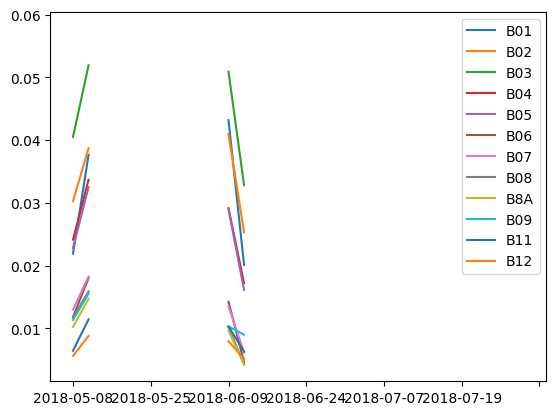

In [11]:
curvas1erProb.plot()

Muchas fechas filtradas pero desde luego ha funcionado